In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
from CoolProp.Plots import PropertyPlot
# from scipy.interpolate import PchipInterpolator
from scipy.interpolate import interp1d
from scipy.integrate import odeint
# from scipy.spatial.transform import Rotation as R
# import plotly.graph_objects as go
from astropy import units as u
import pygasflow as pg
from poliastro.bodies import Earth, Moon
# from poliastro.twobody.orbit import Orbit
# from astropy.constants import G
# from poliastro.twobody.sampling import TrueAnomalyBounds
# from astropy.coordinates import CartesianRepresentation
plt.rcParams['font.family'] = 'Serif'
import sympy as sp

import ssl
import certifi
import urllib.request
import os
import pyproj

# Step 1: Create a proper SSL context using certifi (fixes SSL error)
ssl_context = ssl.create_default_context(cafile=certifi.where())

# Step 2: Monkey-patch urlopen ONLY if the caller didn't already pass a context
_original_urlopen = urllib.request.urlopen

def safe_urlopen(*args, **kwargs):
    # If caller already provided a context, don't add another one
    if 'context' not in kwargs:
        kwargs['context'] = ssl_context
    # Always set a reasonable timeout
    if 'timeout' not in kwargs:
        kwargs['timeout'] = 30
    return _original_urlopen(*args, **kwargs)

urllib.request.urlopen = safe_urlopen

# Step 3: (Optional but recommended) Disable automatic IERS download in pyatmos
# This prevents it from trying to download huge EOP files every time
os.environ["ENABLE_IERS_LOAD"] = "false"   # <--- THIS IS KEY!

# Example: density, temperature, composition at 200 km on 2025-12-06
from pyatmos import nrlmsise00
from pyatmos import download_sw_nrlmsise00, read_sw_nrlmsise00, nrlmsise00

# Step 1: Download and read space weather data (one-time setup; caches locally)
swfile = download_sw_nrlmsise00()  # Fetches from Celestrak if needed
swdata = read_sw_nrlmsise00(swfile)

from datetime import datetime

sp.init_printing()

The Space Weather file 'SW-All.csv' in C:\Users\azizf/src/sw-data/ is already the latest.


# 11.1 Introduction

# 11.2 Equations of Motion

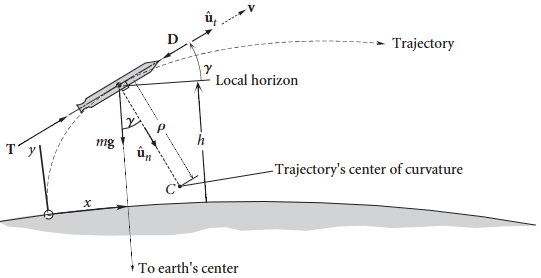

# 11.3 The Thrust Equation

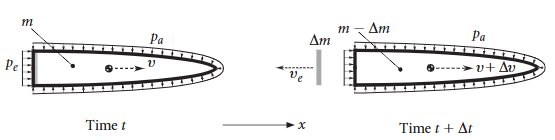

We equate the change in momentum of the body to the net external impulse over a time period $\Delta t$ as follows

$$
    (m - \Delta m)(v + \Delta v)\mathbf{\hat i} - \Delta m v_e \mathbf{\hat i} - mv\mathbf{\hat i} = (p_e - p_a)A_e\Delta t\mathbf{\hat i} \\
    mv\mathbf{\hat i} + m\Delta v\mathbf{\hat i} - \Delta m(v + v_e)\mathbf{\hat i} - \Delta m\Delta v\mathbf{\hat i} - mv\mathbf{\hat i} = (p_e - p_a)A_e\Delta t\mathbf{\hat i} \\
    m\Delta v \mathbf{\hat i} - \Delta m c_a \mathbf{\hat i} = (p_e - p_a)A_e\Delta t\mathbf{\hat i}
$$
Dividing by $\Delta t$ and taking the differential limit, we get

$$
    m\frac{dv}{dt}\mathbf{\hat i} - \dot m c_a\mathbf{\hat i} = (p_e - p_a)A_e\mathbf{\hat i}
$$
or,
$$
    F = \dot m c_a + (p_e - p_a)A_e
$$

Next, we use the nozzle relations to deduce the quantities of the thrust equation

## Nozzle Relations

In [198]:
Pc = 300*1e5*u.Pascal
Tc = 1400*u.Kelvin
g = 1.4*u.one
Ru = 8.314*u.Joule/u.mole/u.Kelvin
Mw = (28.96*u.g/u.mole).to(u.kg/u.mole)
At = 0.09*u.m**2
Me = 4*u.one
R = Ru/Mw
rhoC = Pc/R/Tc

T_star = 2*Tc/(g + 1)
rho_star = (rhoC*(T_star/Tc)**(1/(g - 1))).to(u.kg/u.m**3)
a_star = (np.sqrt(g*R*T_star)).to(u.m/u.s)
mdot = rho_star*a_star*At
c_star = (Pc*At/mdot).to(u.m/u.s)

Ae = At*1/Me*((2 + (g - 1)*Me**2)/(g + 1))**((g + 1)/(2*(g - 1)))
eps = Ae/At

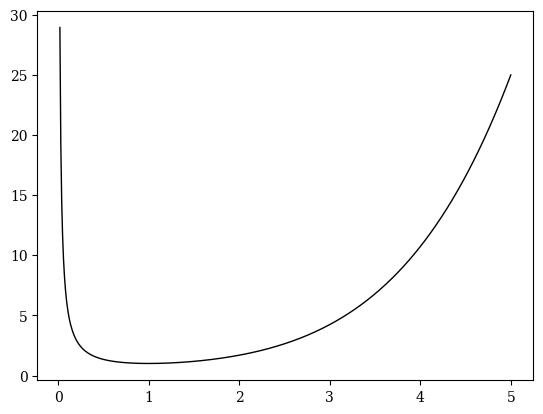

In [200]:
M = np.linspace(0.02, 5, 500)
Ae_At = 1/M*((2 + (g - 1)*M**2)/(g + 1))**((g + 1)/(2*(g - 1)))
plt.plot(M, Ae_At, 'k', lw=1);

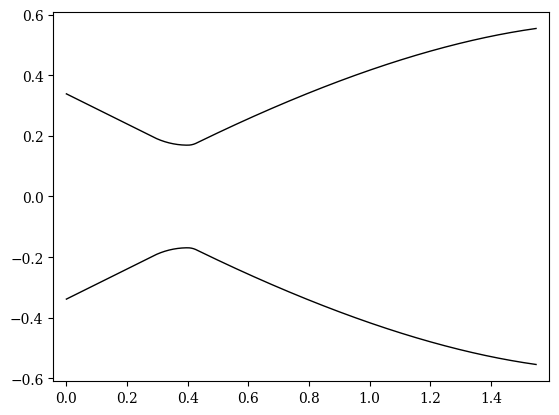

In [ ]:
Lt = 0.4*u.m
rt = np.sqrt(At/np.pi)
re = np.sqrt(Ae/np.pi)
L_cone = (re - rt)/np.tan(np.deg2rad(15))
L_div = 0.8*L_cone
th_n = 26*u.deg
th_e = 8*u.deg

p_in = np.array([0, 2*rt.value])
p_th = np.array([Lt.value, rt.value])
p_ec = np.array([L_cone.value + Lt.value, re.value])
p_e = np.array([L_div.value + Lt.value, re.value])
p_tc = np.array([Lt.value, 2.5*rt.value])

d = np.linalg.norm(p_in - p_tc)
l_tan = np.sqrt(d**2 - (1.5*rt.value)**2)
x_tc = p_tc[0] + (1.5*rt.value)**2*(p_in[0] - p_tc[0])/d**2 - (1.5*rt.value)*(p_in[1] - p_tc[1])*l_tan/d**2
y_tc = p_tc[1] + (1.5*rt.value)**2*(p_in[1] - p_tc[1])/d**2 + (1.5*rt.value)*(p_in[0] - p_tc[0])*l_tan/d**2
p_ct = np.array([x_tc, y_tc])
th_tc = np.arccos((p_ct[0] - p_tc[0])/(1.5*rt.value))

th_c = np.linspace(-th_tc, -np.pi/2)
x_c = p_tc[0] + 1.5*rt.value*np.cos(th_c)
y_c = p_tc[1] + 1.5*rt.value*np.sin(th_c)

x_con_c = np.linspace(p_in[0], p_ct[0])
y_con_c = np.linspace(p_in[1], p_ct[1])

x_conv = np.concatenate([x_con_c, x_c[1:]])
y_conv = np.concatenate([y_con_c, y_c[1:]])

p_td = np.array([Lt.value, 1.382*rt.value])

th_d = np.linspace(-np.pi/2, th_n.to(u.rad).value - np.pi/2)
x_N = p_td[0] + 0.382*rt.value*np.cos(th_d)
y_N = p_td[1] + 0.382*rt.value*np.sin(th_d)

m1 = np.tan(th_n)
m2 = np.tan(th_e)
C1 = y_N[-1] - m1*x_N[-1]
C2 = p_e[1] - m2*p_e[0]
Qx = (C2 - C1)/(m1 - m2)
Qy = (m1*C2 - m2*C1)/(m1 - m2)
t = np.linspace(0, 1, 500)
x_d = (1 - t)**2*x_N[-1] + 2*(1 - t)*t*Qx + t**2*p_e[0]
y_d = (1 - t)**2*y_N[-1] + 2*(1 - t)*t*Qy + t**2*p_e[1]

x_div = np.concatenate([x_N, x_d[1:]])
y_div = np.concatenate([y_N, y_d[1:]])

x_full = np.concatenate([x_conv, x_div[1:]])
y_full = np.concatenate([y_conv, y_div[1:]])

Ax = np.pi*y_full**2
Ln = Lt + L_div

# plt.plot(np.array([p_in[0], p_th[0], p_e[0], p_ec[0]]), np.array([p_in[1], p_th[1], p_e[1], p_ec[1]]), 'k.', lw=1);
# plt.plot(np.array([p_in[0], p_th[0], p_e[0], p_ec[0]]), -np.array([p_in[1], p_th[1], p_e[1], p_ec[1]]), 'k.', lw=1);
plt.plot(x_full, y_full, 'k', lw=1)
plt.plot(x_full, -y_full, 'k', lw=1)

plt.axis('equal');

In [239]:
A_At = interp1d(x_full, Ax)

In [236]:
res = pg.solvers.isentropic_solver('crit_area_super', Ae/At, to_dict=True)
res

{'m': 3.9999999999986784,
 'pr': 0.006586087308000303,
 'dr': 0.027661566693587342,
 'tr': 0.238095238095358,
 'prs': 0.012466996707307075,
 'drs': 0.04363448847555278,
 'trs': 0.28571428571442964,
 'urs': 2.138089935299227,
 'ars': 10.718749999987354,
 'ma': 14.477512185934813,
 'pm': 65.78481979773106}

In [271]:
Pe = np.linspace(Pc, 0, 500)*u.Pascal
mdot_star = Pc*At/c_star
Pe_Pc = Pe/Pc
ve = np.sqrt(2*g*R*Tc.value/(g - 1) * (1 - Pe_Pc.value**((g - 1)/g)))
rhoe_rhoC = pg.solvers.isentropic_solver('pressure', Pe_Pc.value, to_dict=True)['dr']

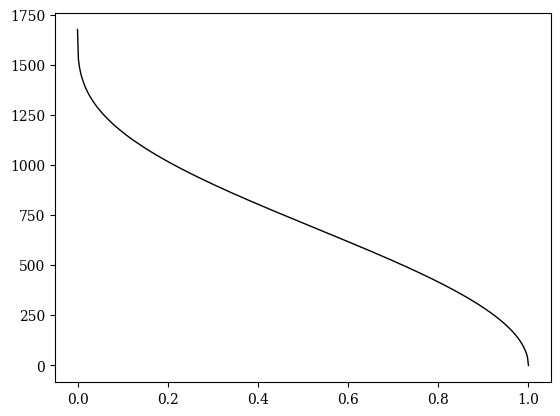

In [273]:
plt.plot(Pe_Pc, ve, 'k', lw=1);

# 11.4 Rocket Performance

The specific impulse $I_{sp}$ of a rocket is defined as
$$
    I_{sp} = \frac{F}{\dot mg_o}
$$

# LVM3 Telemetry

In [ ]:
# --- Constants ---
R = 8.314462618  # J/(mol·K) = m³·Pa/(mol·K)

molar_mass_kgmol = {
    'He': 4.0026e-3,
    'O' : 15.999e-3,
    'N2': 28.0134e-3,
    'O2': 31.9988e-3,
    'Ar': 39.948e-3,
    'H' : 1.00784e-3,
    'N' : 14.0067e-3,
    'ANM O': 15.999e-3
}

# Sriharikota: 13.67°N, 80.55°E
lat, lon = 13.67, 80.55
dt = datetime(2025, 12, 24, 0, 0, 0)  # Midnight UTC
t_str = dt.strftime('%Y-%m-%d %H:%M:%S')  # '2025-12-06 00:00:00'

# Altitudes: 0 to 200 km, 5 km steps
alts_km = np.arange(23.5, 201, 5)  # km

print(f"{'Alt (km)':>8}  {'T (K)':>10}  {'ρ (kg/m³)':>14}  {'P (Pa)':>12}  {'M_mean (g/mol)':>14}")
print("-" * 68)

results = []
for alt_km in alts_km:
    nrl = nrlmsise00(t_str, (lat, lon, alt_km), swdata)
    
    # Total number density
    n_total = sum(nrl.nd.values())
    
    # Mean molecular mass in kg/mol
    M_mean_kgmol = sum(nrl.nd[s] * molar_mass_kgmol[s] for s in nrl.nd) / n_total
    M_mean_gmol = M_mean_kgmol * 1000  # for display
    
    # Pressure via ideal gas law: P = ρRT / M
    P = nrl.rho * R * nrl.T / M_mean_kgmol   # Pa
    results.append([alt_km, nrl.T, nrl.rho, P, M_mean_gmol])
    print(f"{alt_km:8.0f}  {nrl.T:10.2f}  {nrl.rho:14.3e}  {P:12.3e}  {M_mean_gmol:10.3f}")



Alt (km)       T (K)       ρ (kg/m³)        P (Pa)  M_mean (g/mol)
--------------------------------------------------------------------
       0      300.81       1.159e+00     1.001e+05      28.960
       5      274.01       7.029e-01     5.530e+04      28.960
      10      237.33       4.188e-01     2.854e+04      28.960
      15      200.15       2.258e-01     1.298e+04      28.960
      20      206.39       9.422e-02     5.583e+03      28.960
      25      218.77       4.016e-02     2.523e+03      28.960
      30      229.81       1.799e-02     1.187e+03      28.960
      35      245.41       8.280e-03     5.834e+02      28.960
      40      258.07       4.039e-03     2.992e+02      28.960
      45      265.08       2.070e-03     1.576e+02      28.960
      50      265.94       1.098e-03     8.386e+01      28.960
      55      259.49       5.958e-04     4.439e+01      28.960
      60      246.52       3.240e-04     2.293e+01      28.960
      65      232.21       1.708e-04     1.13

c:\Users\azizf\GitHub\repos\BAS\.venv\lib\site-packages\pyatmos\msise\spaceweather.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ap_c = aph_tmp_b0[i]


     105      200.17       2.039e-07     1.236e-02      27.452
     110      246.62       8.041e-08     6.162e-03      26.757
     115      316.86       3.564e-08     3.600e-03      26.084
     120      408.38       1.800e-08     2.398e-03      25.495
     125      491.32       1.068e-08     1.746e-03      24.996
     130      556.77       7.081e-09     1.335e-03      24.560
     135      613.18       4.996e-09     1.054e-03      24.166
     140      661.82       3.686e-09     8.522e-04      23.804
     145      703.76       2.812e-09     7.012e-04      23.466
     150      739.94       2.201e-09     5.850e-04      23.147
     155      771.15       1.758e-09     4.933e-04      22.845
     160      798.08       1.427e-09     4.197e-04      22.556
     165      821.33       1.173e-09     3.595e-04      22.278
     170      841.40       9.752e-10     3.099e-04      22.013
     175      858.74       8.183e-10     2.686e-04      21.756
     180      873.71       6.920e-10     2.337e-04     

In [29]:
df = pd.DataFrame(results, columns=['Alt (km)', 'T (K)', 'Density (kg/m3)', 'Pressure (Pa)', 'Mean molar mass (g/mol)'])

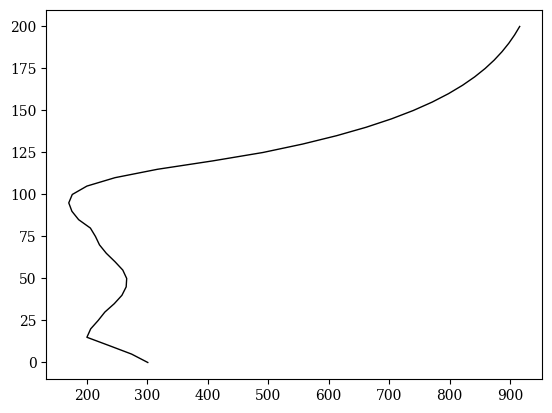

In [30]:
plt.plot(df['T (K)'], df['Alt (km)'], 'k', lw=1);

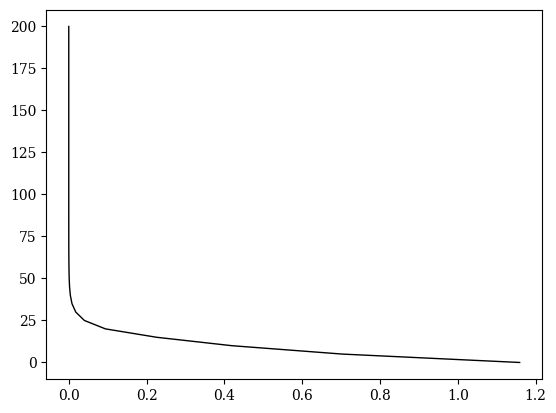

In [31]:
plt.plot(df['Density (kg/m3)'], df['Alt (km)'], 'k', lw=1);

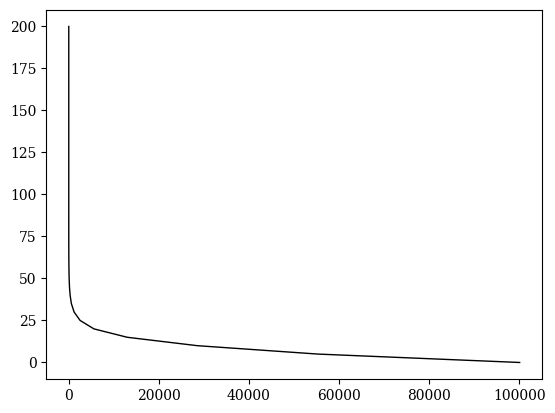

In [32]:
plt.plot(df['Pressure (Pa)'], df['Alt (km)'], 'k', lw=1);

In [33]:
raw = """
1.6155088852989081, 101.7461399179357
1.6155088852989081, 98.86119224810949
2.9112816370490293, 100.22009407744571
2.7261712439418773, 1.2831765118917247
3.8368336025848464, 102.25744158136115
4.9474959612278155, 100.90091577405326
4.9474959612278155, 99.54329334119387
4.9474959612278155, 1.2853697629948329
6.243268712977937, 102.25981760338954
7.168820678513754, 100.22429780872676
7.168820678513754, 1.457265818205542
8.464593430263875, 102.94082207092237
8.279483037156723, 101.2436112589229
8.834814216478208, 99.88653713883929
9.390145395799692, 1.4594590693086502
10.685918147549842, 103.62182653845525
10.50080775444269, 101.92461572645578
10.50080775444269, 100.73669609770377
11.611470113085659, 1.8010579286266193
12.722132471728628, 104.81175664738515
12.722132471728628, 101.58740336934409
13.832794830371597, 1.8032511797297275
14.943457189014566, 105.49276111491804
14.943457189014566, 102.26840783687697
16.054119547657535, 2.1448500390478102
17.164781906300504, 106.51317119066573
17.164781906300504, 102.9494123044098
18.275444264943474, 2.4864488983657793
19.386106623586443, 107.19417565819862
19.386106623586443, 103.96982238015755
20.49676898222944, 2.828047757683862
21.60743134087241, 108.38428853805374
21.60743134087241, 104.65082684769038
22.71809369951538, 2.9999438128944576
23.828756058158348, 109.06529300558662
23.828756058158348, 105.33183131522327
24.939418416801317, 3.171839868105053
26.050080775444286, 110.08570308133432
26.050080775444286, 106.35224139097096
27.160743134087255, 3.852844335637883
28.271405492730224, 111.10611315708206
28.271405492730224, 107.20294866261128
29.382067851373222, 4.364145999063339
29.382067851373222, 1.1397927210223315
30.49273021001619, 111.44771201640003
30.49273021001619, 108.05365593425154
31.60339256865916, 5.045150466596169
31.60339256865916, 1.8207971885550478
31.60339256865916, 0.8025803639105789
32.158723747980645, 112.12816817115709
32.71405492730213, 108.73466040178442
33.8247172859451, 5.386749325914252
33.8247172859451, 2.332098851980618
34.38004846526658, 112.80917263868997
34.93537964458807, 109.41566486931731
36.04604200323104, 6.067753793447082
36.04604200323104, 3.013103319513448
37.156704361874006, 113.49072541899864
37.156704361874006, 109.92696653274271
38.267366720516975, 6.748758260980026
38.45247711362413, 3.2983173483875134
39.37802907915997, 114.00202708242409
39.37802907915997, 110.43826819616817
40.48869143780294, 7.429762728512742
40.48869143780294, 4.035706646364247
41.59935379644591, 114.51332874584955
41.59935379644591, 111.11927266370105
42.71001615508888, 8.280470000153173
42.71001615508888, 4.71671111389719
43.82067851373185, 115.19433321338238
43.82067851373185, 111.63057432712645
44.93134087237482, 8.791771663578515
44.93134087237482, 5.39771558143002
46.04200323101779, 115.87533768091527
46.04200323101779, 112.14187599055191
47.15266558966076, 9.472776131111459
47.15266558966076, 6.078720048962964
48.263327948303754, 116.38663934434072
48.263327948303754, 112.48347484986994
49.37399030694672, 10.323483402751663
49.37399030694672, 6.759724516495794
50.48465266558969, 116.89794100776612
50.48465266558969, 113.3341821215102
51.59531502423266, 11.004487870284606
52.70597738287563, 113.84548378493565
52.70597738287563, 8.1206368260099
53.8166397415186, 11.85519514192481
54.92730210016157, 114.52648825246854
54.92730210016157, 8.80164129354273
56.03796445880454, 12.705902413565127
57.14862681744751, 115.20749272000137
57.14862681744751, 9.482645761075673
57.70395799676902, 13.72576417653704
59.369951534733474, 116.05819999164169
59.369951534733474, 10.50305583682325
61.59127625201941, 116.73920445917452
61.59127625201941, 11.184060304356194
63.81260096930538, 117.4202089267074
63.81260096930538, 12.204470380103885
66.03392568659132, 118.27091619834772
66.03392568659132, 16.788639342107558
66.03392568659132, 13.055177651744202
68.25525040387726, 119.63073188231027
68.25525040387726, 17.80904941785525
68.25525040387726, 14.075587727491893
70.4765751211632, 120.48143915395053
70.4765751211632, 18.829459493603053
70.4765751211632, 15.095997803239698
72.69789983844913, 121.67155203380571
72.69789983844913, 15.777002270772414
74.91922455573507, 123.03136771776826
74.91922455573507, 17.13681795473508
77.14054927302101, 124.39118340173081
77.14054927302101, 18.15722803048277
79.36187399030695, 125.75099908569337
79.36187399030695, 19.17763810623046
81.58319870759294, 127.78962598608564
81.02786752827143, 126.43145524045048
81.58319870759294, 20.36775098608564
83.24919224555737, 128.47008214084275
83.80452342487888, 21.38816106183333
84.91518578352185, 129.65964670792204
86.21095853527197, 130.9619809358892
86.02584814216482, 22.917679549903255
88.24717285945076, 132.54788425440302
88.24717285945076, 23.93808962565106
90.6536079698439, 134.360423520244
89.91316639741518, 133.22834040916013
90.4684975767367, 25.29790530961361
92.68982229402263, 136.62513805518756
92.13449111470118, 135.2669673095524
92.68982229402263, 26.82742379768365
95.09625740441578, 138.4376773210285
94.35581583198712, 137.30559420994467
94.91114701130857, 28.696347893968436
94.35581583198712, 27.338177148333216
97.13247172859451, 140.7023918559721
96.57714054927305, 139.34422111033695
97.13247172859451, 30.056163577930988
99.35379644588045, 142.57131595225695
98.79846526655899, 141.38284801072916
99.35379644588045, 31.41597926189354
100.64956919763063, 143.873650180224
101.01978998384493, 32.77524663308043
102.68578352180941, 146.1383647151676
102.1304523424879, 144.78019396953238
102.68578352180941, 34.13451400426709
104.35177705977384, 147.83703769456923
104.35177705977384, 146.81882086992465
104.35177705977384, 35.15437576723912
105.4624394184168, 148.85635114476537
106.01777059773832, 36.51364313842589
107.12843295638129, 150.04591571184466
108.23909531502426, 151.57433757436314
108.23909531502426, 38.55227003881805
110.4604200323102, 152.9341532583257
110.4604200323102, 40.25149133099552
112.68174474959613, 154.29396894228825
112.12641357027468, 41.610758702182295
113.7924071082391, 42.97002607336901
114.90306946688207, 156.33259584268052
114.34773828756062, 154.97442509704535
116.01373182552504, 45.008652973761286
117.30950457727522, 158.14513510852146
116.56906300484656, 157.01305199743757
117.67972536348952, 46.02851473673326
119.345718901454, 159.39163281882048
118.7903877221325, 158.37286768140018
119.345718901454, 47.72718771613489
121.56704361873994, 160.07263728635337
121.56704361873994, 49.765814616527166
123.78836833602588, 160.7536417538862
123.23303715670437, 51.12508198771394
124.89903069466885, 52.48434935890066
126.00969305331182, 161.60434902552652
126.56502423263328, 53.84361673008743
128.23101777059776, 161.7762450807371
127.67568659127625, 54.86293018028363
129.34168012924073, 165.85020900486688
128.78634894991927, 55.88224363047971
130.4523424878837, 162.11784394005514
130.4523424878837, 57.24151100166648
132.67366720516964, 162.62914560348054
132.11833602584818, 58.60077837285331
133.7843295638126, 59.96004574404009
134.89499192245557, 162.97074446279856
136.00565428109854, 61.99867264443236
137.1163166397415, 163.48204612622402
138.22697899838454, 63.69789393660977
139.3376413570275, 164.16305059375685
140.44830371567048, 65.39711522878719
141.55896607431345, 164.33494664896745
142.1142972536349, 67.09578820818876
143.78029079159938, 164.8462483123929
143.78029079159938, 68.45505557937554
146.00161550888532, 165.35754997581836
146.00161550888532, 70.15427687155295
148.22294022617126, 166.20825724745862
147.6676090468498, 71.17413863452487
148.77827140549277, 72.193452084721
150.4442649434572, 167.22866732320637
150.4442649434572, 73.55271945590778
152.66558966074314, 168.24907739895406
152.66558966074314, 75.25194074808519
154.88691437802908, 168.42097345416465
154.88691437802908, 76.9511620402626
157.10823909531507, 169.10197792169754
157.10823909531507, 78.65038333244001
159.329563812601, 169.78298238923037
158.7742326332795, 79.67024509541199
160.44022617124398, 81.02951246659876
161.55088852988695, 170.1245812485484
162.66155088852992, 82.72873375877617
163.77221324717289, 171.1449913242961
164.88287560581585, 84.08854944273872
165.99353796445882, 171.82599579182897
167.1042003231018, 85.78777073491614
168.21486268174476, 172.6767030634693
169.32552504038773, 87.48699202709355
170.4361873990307, 173.69711313921698
171.54684975767367, 88.8468077110561
172.65751211631664, 174.37811760674987
173.7681744749596, 90.20662339501871
174.87883683360258, 175.22882487839013
175.9894991922456, 91.90584468719612
177.10016155088857, 175.90982934592301
178.21082390953154, 93.26566037115867
179.3214862681745, 176.76053661756328
180.43214862681748, 94.96488166333609
181.54281098546045, 177.78094669331102
182.65347334410342, 96.32469734729864
183.7641357027464, 178.46195116084385
184.31946688206784, 97.00515350205569
185.98546042003233, 179.4823612365916
185.98546042003233, 98.36442087324247
188.20678513731826, 180.16336570412443
188.20678513731826, 99.72423655720502
190.4281098546042, 181.01407297576475
190.4281098546042, 101.08405224116757
192.64943457189014, 182.20418585561987
192.09410339256868, 102.10391400413954
193.7600969305331, 103.29347857121888
194.87075928917614, 183.0548931272602
195.9814216478191, 104.483591451074
197.09208400646207, 184.07530320300788
197.64741518578353, 105.50345321404592
199.313408723748, 185.09571327875562
199.313408723748, 106.69301778112526
201.53473344103395, 186.28582615861075
201.53473344103395, 108.22253626919525
203.7560581583199, 187.30623623435844
203.7560581583199, 109.242946344943
205.97738287560583, 188.32664631010618
205.97738287560583, 110.60276202890554
208.19870759289176, 189.68646199406874
208.19870759289176, 111.9625777128681
210.4200323101777, 190.87657487392386
210.4200323101777, 113.32239339683065
212.64135702746364, 191.72728214556417
212.64135702746364, 114.68220908079326
214.86268174474964, 193.08709782952673
214.86268174474964, 116.04202476475581
217.26911685514273, 194.220825878938
216.52867528271406, 193.08874276785411
217.08400646203557, 117.23213764461093
219.49044157242867, 195.58064156290055
218.75, 194.44855845181667
219.3053311793215, 118.42225052446611
221.52665589660745, 196.48773366498472
221.52665589660745, 119.4426606002138
223.7479806138934, 197.67784654483984
223.19264943457193, 120.46252236318571
225.96930533117933, 198.52855381648016
227.0799676898223, 199.88727287489115
228.19063004846527, 123.52210765210151
229.30129240710824, 200.9076829506389
230.4119547657512, 124.5425177278492
231.52261712439417, 202.26749863460145
232.63327948303714, 125.56292780359689
233.74394184168017, 203.627314318564
234.85460420032314, 126.9227434875595
235.9652665589661, 204.98713000252656
237.07592891760908, 128.28255917152205
238.18659127625205, 206.3469456864891
239.29725363489501, 129.30296924726974
240.40791599353798, 207.70676137045172
241.51857835218095, 130.3233793230175
242.62924071082392, 209.40598266262913
243.7399030694669, 131.68319500698004
244.85056542810986, 210.76579834659168
245.96122778675283, 133.0430106909426
246.51655896607434, 211.7856601095636
248.18255250403877, 213.14492748075037
248.18255250403877, 134.06342076669034
250.4038772213247, 214.50474316471292
250.4038772213247, 135.25353364654546
252.6252019386107, 216.20396445689033
252.6252019386107, 136.44364652640058
254.29119547657513, 217.22382621986225
254.84652665589664, 137.8034622103632
255.9571890145396, 218.92249919926388
257.0678513731826, 138.48446667789602
258.17851373182555, 220.2823148832265
259.2891760904685, 139.84428236185857
259.84450726979, 221.3021766461984
260.95516962843294, 222.32149009639448
261.51050080775445, 141.20409804582118
262.6211631663974, 223.68075746758132
263.7318255250404, 142.05480531746144
264.84248788368336, 224.87087034743644
265.95315024232633, 226.3992922099548
265.95315024232633, 143.24491819731657
268.3595853527195, 228.2118314757958
267.6191437802908, 227.07974836471192
268.17447495961227, 144.60473388127917
270.3957996768982, 229.6280319902022
270.3957996768982, 145.45544115291943
271.6915724286484, 230.93036621816935
270.9511308562197, 149.69855956838092
272.6171243941842, 146.47585122866718
273.72778675282717, 232.3465667325758
274.83844911147014, 233.87498859509418
274.83844911147014, 147.6659641085223
277.0597738287561, 235.0651014749493
277.0597738287561, 148.85607698837742
278.17043618739905, 236.59352333746773
279.281098546042, 149.87648706412517
280.391760904685, 238.63215023786
279.8364297253635, 237.27397949222484
281.50242326332796, 151.0665999439803
282.6130856219709, 240.50107433414485
282.05775444264947, 239.3126063926171
283.9088583737211, 241.80340856211194
283.7237479806139, 152.25671282383541
285.94507269789983, 243.21960907651834
285.94507269789983, 153.27712289958316
287.0557350565428, 244.5783281349294
288.351507808293, 245.8806623628965
288.16639741518577, 154.46723577943828
290.38772213247177, 247.97567409373266
289.83239095315025, 246.78720615220482
290.38772213247177, 155.65734865929346
291.49838449111473, 249.3343931521436
291.49838449111473, 160.74952940806776
292.79415724286486, 250.6367273801107
292.6090468497577, 156.84746153914864
293.7197092084007, 161.93964228792294
294.83037156704364, 252.9014419150543
294.27504038772213, 251.54327116941909
294.83037156704364, 158.03757441900376
295.9410339256866, 163.12975516777806
297.0516962843296, 254.77036601133915
297.0516962843296, 159.22768729885888
298.16235864297255, 256.1290850697501
298.16235864297255, 163.98046243941837
299.2730210016155, 257.4878041281611
299.4581313947227, 160.3614153482701
300.3836833602585, 258.8465231865721
300.3836833602585, 165.34027812338093
301.49434571890146, 260.03553944087565
301.67945611200867, 161.72123103223265
300.93901453958, 160.58914792114882
302.79011847065163, 261.5075764729502
302.04967689822297, 166.36013988635284
303.7156704361874, 162.96772874253173
303.16033925686594, 161.94896360511137
304.82633279483036, 263.093479791464
305.93699515347333, 163.98813881827948
307.0476575121163, 263.43507865078203
308.15831987075927, 165.1782516981346
309.2689822294023, 263.77667751010006
310.37964458804527, 165.8592561656675
311.49030694668824, 264.1182763694181
311.49030694668824, 167.38767802818586
313.7116316639742, 263.7810640123064
313.7116316639742, 168.40808810393355
313.15630048465266, 167.38932296651325
315.9329563812601, 263.952960067517
315.9329563812601, 169.4284981796813
318.15428109854605, 264.6339645350498
318.15428109854605, 170.27920545132156
320.375605815832, 264.8058605902604
320.375605815832, 175.88159123796976
320.375605815832, 171.46931833117668
322.5969305331179, 265.14745944957843
322.5969305331179, 172.8291340151393
324.81825525040387, 265.48905830889646
324.81825525040387, 177.75270858535777
324.81825525040387, 173.51013848267212
327.0395799676898, 266.1700627764293
327.22469036079707, 178.71673383066155
327.22469036079707, 174.6438665320834
329.26090468497574, 266.3419588316399
329.26090468497574, 179.96323154096063
329.26090468497574, 175.55095863416756
331.4822294022617, 266.5138548868505
331.66733979536895, 176.68468668357883
333.7035541195476, 266.6857509420611
333.7035541195476, 177.591778785663
335.92487883683356, 267.0273498013791
335.92487883683356, 178.78189166551812
338.1462035541196, 267.36894866069713
338.1462035541196, 179.9720045453733
340.36752827140555, 267.8802503241225
340.36752827140555, 180.82271181701356
342.5888529886915, 268.22184918344055
342.5888529886915, 181.67341908865387
344.8101777059774, 268.733150846866
344.8101777059774, 182.3544235561867
347.03150242326336, 269.07474970618404
347.03150242326336, 183.0354280237196
349.2528271405493, 269.41634856550206
349.2528271405493, 184.05583809946728
351.47415185783524, 269.5882446207126
351.47415185783524, 185.07624817521503
353.6954765751212, 269.9298434800306
353.6954765751212, 185.75725264274786
354.8061389337641, 190.17062217509255
355.9168012924071, 270.27144233934865
355.9168012924071, 186.43825711028074
358.13812600969305, 270.6130411986667
358.13812600969305, 187.288964381921
360.359450726979, 270.9546400579847
360.359450726979, 188.30937445766875
362.58077544426493, 271.4659417214101
362.0254442649435, 193.23240071511145
362.58077544426493, 188.99037892520158
364.80210016155087, 271.80754058072813
364.80210016155087, 189.67138339273447
367.0234248788368, 271.9794366359387
367.0234248788368, 190.35238786026736
369.24474959612274, 272.32103549525675
369.24474959612274, 191.20309513190762
371.4660743134087, 272.8323371586822
371.4660743134087, 191.8840995994405
373.6873990306946, 273.1739360180002
373.6873990306946, 192.56510406697333
375.9087237479807, 273.68523768142563
375.9087237479807, 193.24610853450622
378.1300484652666, 273.6874309325288
378.1300484652666, 193.75741019793168
380.35137318255255, 274.3684354000617
380.35137318255255, 194.4384146654645
382.5726978998385, 274.7100342593797
382.5726978998385, 195.28912193710482
384.7940226171244, 274.88193031459025
384.7940226171244, 195.80042360053028
387.01534733441036, 275.2235291739083
387.01534733441036, 196.4814280680631
389.2366720516963, 275.73483083733373
389.2366720516963, 197.162432535596
391.45799676898224, 276.07642969665176
391.45799676898224, 197.50403139491402
393.6793214862682, 276.5877313600772
393.6793214862682, 198.18503586244685
394.7899838449112, 202.59840539479154
395.9006462035541, 277.0990330235026
395.9006462035541, 198.6963375258723
397.01130856219714, 202.9400042541095
398.12197092084006, 277.44063188282064
398.12197092084006, 199.20763918929777
400.343295638126, 277.78223074213867
400.343295638126, 199.71894085272316
401.453957996769, 204.13231038506785
402.56462035541193, 278.2935324055641
402.56462035541193, 200.23024251614862
404.78594507269787, 278.6351312648821
404.78594507269787, 200.9112469836815
407.0072697899838, 278.9767301242001
407.0072697899838, 201.25284584299948
409.22859450726975, 279.4880317876256
409.22859450726975, 201.93385031053236
411.4499192245557, 279.8296306469436
411.4499192245557, 202.44515197395782
413.67124394184174, 280.340932310369
413.67124394184174, 202.78675083327585
415.8925686591277, 280.5128283655796
415.8925686591277, 202.95864688848638
418.1138933764136, 281.1938328331125
418.1138933764136, 203.63965135601927
420.33521809369955, 281.19602608421565
420.33521809369955, 204.15095301944473
422.5565428109855, 281.87703055174853
422.5565428109855, 204.49255187876275
424.77786752827143, 282.2186294110665
424.77786752827143, 204.66444793397335
426.99919224555737, 282.5602282703845
426.99919224555737, 205.17574959739875
429.2205169628433, 283.07152993381
429.2205169628433, 205.6870512608242
431.44184168012924, 283.413128793128
431.44184168012924, 206.02865012014223
433.6631663974152, 283.9244304565534
433.6631663974152, 206.53995178356763
435.8844911147011, 284.26602931587144
435.8844911147011, 206.88155064288566
438.10581583198706, 284.60762817518946
438.10581583198706, 206.88374389398882
440.327140549273, 285.28863264272235
440.327140549273, 207.22534275330685
442.54846526655894, 285.6302315020403
442.54846526655894, 207.56694161262487
444.7697899838449, 285.97183036135834
444.7697899838449, 207.9085404719429
446.9911147011308, 286.4831320247838
446.9911147011308, 207.91073372304606
449.21243941841675, 286.8247308841019
449.21243941841675, 208.42203538647152
451.4337641357028, 287.1663297434199
451.4337641357028, 208.59393144168212
453.65508885298874, 287.84733421095274
453.65508885298874, 208.7658274968927
455.8764135702747, 288.3586358743782
455.8764135702747, 209.10742635621074
458.0977382875606, 288.5305319295888
458.0977382875606, 209.6187280196362
460.31906300484656, 289.2115363971216
460.31906300484656, 209.62092127073936
462.5403877221325, 289.7228380605471
462.5403877221325, 209.62311452184252
464.9468228325256, 290.17775489352863
464.76171243941843, 209.6253077729457
466.98303715670437, 290.74544138739793
466.98303715670437, 213.3609627144122
466.98303715670437, 210.64571784869338
466.4277059773829, 209.62695271127302
468.27880990845443, 292.1043432167342
468.0936995153473, 212.00443690710432
469.38947226709746, 213.3633387364406
469.2043618739903, 210.9873167080114
470.31502423263333, 292.78516491334176
470.31502423263333, 291.76694808869723
471.42568659127625, 214.0441604330482
471.42568659127625, 212.68653800018882
471.42568659127625, 211.32891556732943
472.5363489499193, 293.46616938087465
472.5363489499193, 292.2782497521227
473.6470113085622, 214.04635368415137
473.6470113085622, 212.68873125129198
473.6470113085622, 211.3311088184326
474.7576736672052, 294.14717384840753
474.7576736672052, 292.7895514155481
475.8683360258481, 214.04854693525454
475.8683360258481, 212.69092450239515
475.8683360258481, 211.33330206953576
476.97899838449115, 294.82817831594036
476.97899838449115, 293.470555883081
478.2747711362412, 214.05092295728292
478.08966074313406, 212.35371214528345
478.08966074313406, 211.1657925165315
479.3854334948841, 294.8305543379688
478.6449919224555, 293.47220082140836
480.31098546042, 214.7317446538906
480.31098546042, 213.3741222210312
480.31098546042, 212.01649978817176
480.31098546042, 210.99828296352723
481.421647819063, 295.5113760345764
481.421647819063, 294.153753601717
482.53231017770594, 214.73393790499375
482.53231017770594, 213.37631547213437
482.53231017770594, 212.01869303927492
482.53231017770594, 211.0004762146304
483.8280829294561, 295.51375205660486
483.0876413570275, 294.4948041482592
484.7536348949919, 214.73613115609692
484.7536348949919, 213.37850872323753
484.7536348949919, 212.0208862903781
485.8642972536349, 296.19457375321247
485.8642972536349, 295.00665412446045
486.9749596122778, 214.73832440720008
486.9749596122778, 213.3807019743407
486.9749596122778, 212.02307954148125
488.270732364028, 296.8757609916706
487.5302907915994, 295.51740747511013
489.19628432956387, 214.74051765830325
489.19628432956387, 213.38289522544386
489.19628432956387, 212.02527279258442
490.3069466882068, 297.5565826882781
490.3069466882068, 296.1989602554188
491.4176090468498, 214.7427109094064
491.4176090468498, 213.38508847654703
491.4176090468498, 212.02746604368758
492.5282714054927, 298.237587155811
492.5282714054927, 296.8799647229516
493.63893376413574, 214.74490416050958
493.63893376413574, 213.3872817276502
493.63893376413574, 212.02965929479075
494.74959612277866, 298.2397804069142
494.74959612277866, 297.0518607781622
495.8602584814217, 214.74709741161274
495.8602584814217, 213.38947497875336
495.8602584814217, 212.0318525458939
496.9709208400646, 298.92078487444707
496.9709208400646, 297.5631624415877
498.0815831987076, 214.7492906627159
498.0815831987076, 213.39166822985652
498.0815831987076, 212.03404579699708
499.19224555735053, 299.60178934197995
499.19224555735053, 298.2441669091205
500.30290791599356, 214.75148391381907
500.30290791599356, 213.39386148095969
500.30290791599356, 212.03623904810024
501.41357027463647, 300.2827938095128
501.41357027463647, 298.9251713766534
500.858239095315, 297.9064062392331
502.5242326332795, 214.75367716492224
502.5242326332795, 213.39605473206285
502.5242326332795, 212.0384322992034
503.82000538502956, 300.2851698315412
503.6348949919224, 298.75766182364913
504.74555735056543, 214.7558704160254
504.74555735056543, 213.39824798316602
504.74555735056543, 212.04062555030657
505.85621970920835, 300.96599152814883
505.85621970920835, 299.7780718993969
506.9668820678514, 214.75806366712857
506.9668820678514, 213.40044123426918
506.9668820678514, 212.04281880140974
508.0775444264944, 301.64699599568166
508.0775444264944, 300.2893735628223
509.1882067851373, 214.76025691823173
509.1882067851373, 213.40263448537235
509.1882067851373, 212.0450120525129
510.4839795368874, 301.6493720177101
509.74353796445877, 300.6304241093645
511.40953150242325, 214.7624501693349
511.40953150242325, 213.4048277364755
511.40953150242325, 212.04720530361607
512.7053042541734, 302.330376485243
511.9648626817447, 300.9720229686825
513.6308562197091, 214.76464342043806
513.6308562197091, 213.40702098757868
513.6308562197091, 212.04939855471923
514.9266289714592, 303.0113809527759
514.7415185783523, 301.48387294488373
515.8521809369952, 214.76683667154123
515.8521809369952, 213.40921423868184
515.8521809369952, 212.0515918058224
516.9628432956381, 303.69220264938343
516.9628432956381, 302.33458021652405
518.073505654281, 214.7690299226444
518.073505654281, 213.411407489785
518.073505654281, 212.05378505692556
519.3692784060313, 303.6945786714119
518.6288368336027, 302.33622515485143
520.2948303715671, 214.77122317374756
520.2948303715671, 213.41360074088817
520.2948303715671, 212.05597830802873
521.5906031233171, 304.37558313894476
520.8501615508885, 303.0172296223843
522.5161550888529, 214.77341642485072
522.5161550888529, 213.41579399199134
522.5161550888529, 212.0581715591319
523.626817447496, 305.05640483555237
523.626817447496, 303.6987824026929
524.7374798061389, 214.7756096759539
524.7374798061389, 213.4179872430945
524.7374798061389, 212.06036481023506
525.8481421647818, 305.7374093030852
525.8481421647818, 304.3797868702258
526.958804523425, 214.77780292705705
526.958804523425, 213.42018049419767
526.958804523425, 212.06255806133822
528.254577275175, 305.73978532511364
527.5141357027464, 304.72083741676806
528.0694668820679, 211.04543786224525
529.1801292407108, 214.44059056994536
529.1801292407108, 213.08296813708597
529.1801292407108, 211.72534570422658
530.2907915993537, 306.42060702172125
530.2907915993537, 305.2326873929693
531.4014539579969, 214.10337821283366
531.4014539579969, 212.74575577997427
531.4014539579969, 211.3881333471149
532.5121163166398, 307.1016114892541
532.5121163166398, 305.9136918605021
533.6227786752827, 214.10557146393683
533.6227786752827, 212.74794903107744
533.6227786752827, 211.39032659821805
534.7334410339256, 307.782615956787
534.7334410339256, 306.594696328035
535.8441033925687, 214.10776471504
535.8441033925687, 212.7501422821806
535.8441033925687, 211.39251984932122
537.1398761443188, 307.7849919788154
536.3994345718902, 306.7660440704698
538.0654281098546, 214.10995796614316
538.0654281098546, 212.75233553328377
538.0654281098546, 211.39471310042438
539.3612008616046, 308.4659964463483
538.620759289176, 307.44704853800266
540.2867528271406, 214.11215121724632
540.2867528271406, 212.75452878438693
540.2867528271406, 211.39690635152755
541.3974151857835, 309.8256293593856
541.3974151857835, 308.4680069265262
542.5080775444264, 214.1143444683495
542.5080775444264, 212.7567220354901
542.5080775444264, 211.3990996026307
543.8038502961765, 309.82800538141396
543.6187399030694, 308.3004973735219
544.7294022617125, 214.11653771945265
544.7294022617125, 212.75891528659326
544.7294022617125, 211.40129285373388
545.8400646203554, 310.5088270780216
545.8400646203554, 309.15120464516224
546.9507269789983, 213.77932536234096
546.9507269789983, 212.42170292948157
546.9507269789983, 211.2337833007296
548.0613893376415, 311.1898315455545
548.0613893376415, 309.83220911269507
549.1720516962844, 213.44211300522932
549.1720516962844, 212.08449057236987
549.1720516962844, 210.7268681395105
550.2827140549273, 311.87083601308734
550.2827140549273, 310.51321358022795
551.3933764135702, 213.44430625633248
551.3933764135702, 212.08668382347304
551.3933764135702, 210.72906139061365
552.5040387722133, 312.55184048062017
552.5040387722133, 311.19421804776084
553.6147011308562, 213.10709389922079
553.6147011308562, 211.7494714663614
553.6147011308562, 210.39184903350196
554.7253634894992, 313.23284494815306
554.7253634894992, 311.8752225152937
554.1700323101777, 310.8564573778733
555.8360258481421, 212.7698815421091
555.8360258481421, 211.4122591092497
555.8360258481421, 210.05463667639032
557.1317985998924, 313.23522097018144
556.9466882067852, 311.7077129622894
558.0573505654281, 212.4326691849974
558.0573505654281, 211.075046752138
558.0573505654281, 209.88712712338605
559.168012924071, 313.9160426667891
559.168012924071, 312.5584202339297
560.278675282714, 212.0954568278857
560.278675282714, 210.7378343950263
560.278675282714, 209.71961757038179
561.5744480344642, 313.9184186888175
560.8340064620356, 312.8994707804719
562.5, 212.09765007898886
562.5, 210.74002764612948
562.5, 209.72181082148495
563.6106623586429, 315.2780516018548
563.6106623586429, 313.92042916899544
563.0553311793215, 312.9016640315751
564.721324717286, 212.09984333009203
564.721324717286, 210.74222089723264
564.721324717286, 209.38459846437325
565.831987075929, 315.95905606938766
565.831987075929, 314.6014336365283
566.9426494345719, 212.1020365811952
566.9426494345719, 210.7444141483358
566.9426494345719, 209.38679171547642
568.2384221863219, 315.9614320914161
567.4979806138933, 314.9424841830705
569.1639741518579, 211.76482422408355
569.1639741518579, 210.4072017912241
569.1639741518579, 209.04957935836472
570.459746903608, 316.642436558949
570.2746365105008, 315.1149285510569
571.3852988691438, 211.42761186697186
571.3852988691438, 210.06998943411247
571.3852988691438, 208.71236700125303
572.4959612277867, 317.3232582555566
572.4959612277867, 315.9656358226972
573.6066235864298, 211.42980511807502
573.6066235864298, 210.07218268521564
573.6066235864298, 208.7145602523562
574.7172859450727, 318.0042627230895
574.7172859450727, 316.64664029023004
575.8279483037156, 211.09259276096333
575.8279483037156, 209.73497032810394
575.8279483037156, 208.3773478952445
577.1237210554657, 318.68544996154753
576.9386106623585, 317.1579419536555
578.0492730210017, 210.75538040385163
578.0492730210017, 209.39775797099225
578.0492730210017, 208.04013553813286
579.3450457727517, 319.3664544290805
579.1599353796446, 317.8389464211883
580.2705977382875, 210.7575736549548
580.2705977382875, 209.3999512220954
580.2705977382875, 208.04232878923602
581.3812600969304, 320.0472761256881
581.3812600969304, 318.68965369282864
582.4919224555736, 210.4203612978431
582.4919224555736, 209.06273886498371
582.4919224555736, 207.70511643212433
581.9365912762521, 207.02575690291883
583.6025848142165, 320.0494693767912
583.6025848142165, 318.86154974803924
584.7132471728594, 210.08314894073146
584.7132471728594, 208.72552650787202
584.7132471728594, 207.36790407501263
586.0090199246094, 320.73065661524936
585.2685783521808, 319.3723030986889
586.9345718901454, 209.74593658361977
586.9345718901454, 208.38831415076032
586.9345718901454, 207.20039452200837
588.0452342487883, 322.09028952828663
588.0452342487883, 320.73266709542725
587.4899030694669, 319.7139019580069
589.1558966074313, 209.40872422650807
589.1558966074313, 208.05110179364868
589.1558966074313, 206.86318216489667
590.2665589660744, 322.7712939958195
590.2665589660744, 321.4136715629601
589.7112277867527, 320.3949064255397
591.3772213247173, 209.41091747761124
591.3772213247173, 208.05329504475185
591.3772213247173, 206.6956726118924
592.6729940764674, 322.77367001784796
592.4878836833602, 321.2461620099558
593.5985460420031, 209.4131107287144
593.5985460420031, 208.055488295855
593.5985460420031, 206.69786586299557
594.8943187937534, 323.4546744853808
594.7092084006463, 321.92716647748875
594.7092084006463, 205.85044846801003
595.8198707592892, 208.73649276338784
595.8198707592892, 207.37887033052846
597.1156435110393, 324.1356789529136
596.9305331179321, 322.6081709450216
596.9305331179321, 206.02234452322062
598.041195476575, 208.738686014491
598.041195476575, 207.38106358163162
599.3369682283253, 324.8166834204465
599.1518578352182, 323.2891754125544
599.1518578352182, 206.0245377743238
600.2625201938611, 208.4014736573793
600.2625201938611, 207.04385122451993
600.2625201938611, 205.17712037933825
601.5582929456111, 325.4976878879794
601.373182552504, 323.9701798800873
602.4838449111471, 208.06426130026767
602.4838449111471, 206.70663886740823
602.4838449111471, 205.34901643454884
603.7796176628972, 326.1786923555122
603.59450726979, 324.6511843476202
603.0391760904686, 323.8021220143072
604.7051696284329, 207.38764333494112
604.7051696284329, 206.03002090208173
604.7051696284329, 204.67239846922234
606.000942380183, 326.8596968230451
605.8158319870759, 325.332188815153
606.926494345719, 207.05043097782942
606.926494345719, 205.69280854497003
606.926494345719, 204.50488891621808
608.2222670974691, 327.540701290578
608.0371567043619, 326.0131932826859
607.4818255250404, 325.164130949373
609.1478190630048, 206.71321862071773
609.1478190630048, 205.35559618785834
609.1478190630048, 203.99797375499895
610.4435918147549, 328.22170575811083
610.2584814216477, 326.6941977502188
609.7031502423263, 325.84513541690586
611.3691437802909, 206.7154118718209
611.3691437802909, 205.3577894389615
611.3691437802909, 204.00016700610212
612.6649165320409, 328.9027102256438
612.4798061389338, 327.3752022177516
611.9244749596123, 326.52613988443875
613.5904684975767, 206.37819951470925
613.5904684975767, 205.0205770818498
613.5904684975767, 203.66295464899042
614.8862412493268, 329.5837146931766
614.7011308562196, 328.0562066852845
614.1457996768982, 327.2071443519716
615.8117932148627, 206.04098715759756
615.8117932148627, 204.68336472473817
615.8117932148627, 203.32574229187873
616.9224555735057, 330.9433476062139
616.9224555735057, 329.5857251733545
616.9224555735057, 328.39780554460253
618.0331179321486, 205.70377480048586
618.0331179321486, 204.34615236762647
618.0331179321486, 203.15823273887446
619.3288906838986, 330.9457236282423
619.1437802907915, 329.4182156203502
618.58844911147, 328.56915328703735
620.2544426494346, 205.36656244337416
620.2544426494346, 204.00894001051478
620.2544426494346, 202.6513175776554
621.5502154011847, 331.6267280957752
621.3651050080775, 329.9295172837757
620.8097738287561, 329.2501577545702
622.4757673667204, 204.68994447804766
622.4757673667204, 203.33232204518822
622.4757673667204, 202.14440241643626
623.5864297253636, 332.3075497923828
623.5864297253636, 330.9499273595234
623.5864297253636, 329.93171053487885
624.6970920840065, 204.69213772915083
624.6970920840065, 203.33451529629139
624.6970920840065, 201.976892863432
625.8077544426494, 332.98855425991565
625.8077544426494, 331.63093182705626
625.252423263328, 330.61216668963596
626.9184168012923, 204.01551976382427
626.9184168012923, 202.6578973309649
626.9184168012923, 201.6396805063203
628.0290791599355, 333.6695587274485
628.0290791599355, 332.31193629458915
628.0290791599355, 331.29371946994456
629.1397415185784, 204.01771301492744
629.1397415185784, 202.66009058206805
629.1397415185784, 201.30246814920866
630.2504038772213, 334.3505631949814
630.2504038772213, 332.992940762122
629.6950726978998, 331.9741756247016
631.3610662358642, 204.0199062660306
631.3610662358642, 202.66228383317122
631.3610662358642, 201.30466140031183
632.4717285945073, 335.03156766251425
632.4717285945073, 333.6739452296548
631.9163974151859, 332.6551800922345
632.4717285945073, 200.4572440053263
633.5823909531503, 203.34328830070405
633.5823909531503, 201.98566586784466
634.6930533117932, 335.7125721300471
634.6930533117932, 334.35494969718775
634.6930533117932, 333.33673287254317
634.6930533117932, 200.62914006053688
635.8037156704361, 203.0060759435924
635.8037156704361, 201.64845351073296
635.8037156704361, 199.78172266555129
637.0994884221864, 335.7149481520755
636.9143780290792, 334.1874401441835
638.0250403877221, 202.6688635864807
638.0250403877221, 201.31124115362132
638.0250403877221, 199.95361872076188
639.3208131394722, 336.3959526196084
638.5803715670436, 335.03759910304797
640.2463651050082, 201.99224562115415
640.2463651050082, 200.63462318829477
640.2463651050082, 199.27700075543538
641.5421378567582, 337.755768303571
641.3570274636511, 336.22826029567887
640.8016962843296, 335.379197962366
642.467689822294, 201.65503326404246
642.467689822294, 200.29741083118307
642.467689822294, 199.10949120243112
643.7634625740441, 338.43677277110385
643.5783521809369, 336.90926476321175
643.0230210016155, 336.0602024298988
644.6890145395801, 201.31782090693082
644.6890145395801, 199.96019847407138
644.6890145395801, 198.77227884531942
645.9847872913301, 339.1177772386367
645.799676898223, 337.59026923074464
645.2443457189015, 336.7412068974317
646.9103392568659, 201.32001415803398
646.9103392568659, 199.96239172517454
646.9103392568659, 198.60476929231515
648.206112008616, 339.79878170616956
648.0210016155088, 338.10157089417004
647.4656704361873, 337.4222113649646
649.1316639741519, 200.9828018009223
649.1316639741519, 199.6251793680629
649.1316639741519, 198.26755693520346
650.427436725902, 340.47978617370245
650.2423263327948, 338.7825753617029
649.6869951534734, 338.1032158324974
651.3529886914378, 200.6455894438106
651.3529886914378, 199.2879670109512
651.3529886914378, 197.93034457809176
652.6487614431878, 341.1607906412353
652.4636510500807, 339.63328263334324
651.9083198707592, 338.78422030003026
653.5743134087238, 199.96897147848404
653.5743134087238, 198.61134904562465
653.5743134087238, 197.25372661276526
654.8700861604739, 341.84179510876817
654.6849757673667, 340.3142871008761
654.1296445880453, 339.4652247675632
655.7956381260096, 199.6317591213724
655.7956381260096, 198.27413668851295
655.7956381260096, 197.086217059761
656.9063004846525, 343.20142802180544
656.9063004846525, 341.84380558894605
656.9063004846525, 340.65588596019404
658.0169628432957, 199.2945467642607
658.0169628432957, 197.93692433140126
658.0169628432957, 196.57930189854187
659.1276252019386, 343.8824324893383
659.1276252019386, 342.52481005647894
659.1276252019386, 341.336890427727
660.2382875605815, 198.957334407149
660.2382875605815, 197.59971197428962
660.2382875605815, 196.24208954143018
661.3489499192247, 344.5634369568712
661.3489499192247, 343.20581452401177
661.3489499192247, 342.0178948952598
662.4596122778676, 198.6201220500373
662.4596122778676, 197.26249961717792
662.4596122778676, 195.90487718431854
663.5702746365105, 345.24444142440404
663.5702746365105, 343.88681899154466
663.5702746365105, 342.69889936279264
664.6809369951534, 198.62231530114047
664.6809369951534, 197.2646928682811
664.6809369951534, 195.9070704354217
664.6809369951534, 194.88885361077712
665.9767097469035, 345.9256286628622
665.7915993537965, 344.2284178508627
665.2362681744748, 343.2096527134423
666.9022617124394, 198.28510294402878
666.9022617124394, 196.9274805111694
666.9022617124394, 195.56985807831
666.346930533118, 194.8904985491045
668.1980344641895, 346.60663313039504
668.0129240710824, 344.9094223183955
667.4575928917609, 343.8906571809752
669.1235864297253, 197.94789058691708
669.1235864297253, 196.5902681540577
669.1235864297253, 195.2326457211983
670.4193591814756, 347.2876375979279
670.2342487883684, 345.5904267859284
669.678917609047, 344.91106725672296
670.2342487883684, 194.38522832621283
671.3449111470113, 197.27127262159058
671.3449111470113, 195.9136501887312
672.6406838987614, 347.9686420654608
672.4555735056542, 346.2714312534613
671.9002423263328, 345.5920717242558
672.6406838987614, 194.55730715234859
671.9002423263328, 193.538359244003
673.5662358642971, 196.59465465626403
674.6768982229403, 349.32827497849803
674.6768982229403, 347.9706525456387
674.6768982229403, 346.61303011277926
674.1215670436188, 345.59426497535895
674.6768982229403, 195.23812884895625
674.6768982229403, 193.88050641609686
675.7875605815832, 196.25744229915233
676.8982229402261, 350.009279446031
676.8982229402261, 348.65165701317153
676.8982229402261, 347.29403458031214
676.8982229402261, 194.5615108836297
676.8982229402261, 193.37359125487774
678.008885298869, 195.9202299420407
679.1195476575122, 350.6902839135638
679.1195476575122, 349.33266148070436
679.1195476575122, 348.1447418519524
679.1195476575122, 194.56370413473286
679.1195476575122, 193.20608170187347
680.2302100161551, 195.583017584929
680.2302100161551, 192.35866430688793
681.340872374798, 351.37128838109663
681.340872374798, 350.0136659482373
681.340872374798, 348.8257463194853
681.340872374798, 193.88708616940636
682.4515347334411, 195.2458052278173
682.4515347334411, 192.53056036209853
683.7473074851912, 352.0524756195548
683.562197092084, 350.3552648075553
683.0068659127626, 349.3364996701349
683.7473074851912, 193.88946219143475
684.672859450727, 191.85394239677197
685.968632202477, 352.7334800870877
685.7835218093699, 351.03626927508816
685.2281906300484, 350.01750413766786
685.7835218093699, 194.57028388804235
685.7835218093699, 193.21266145518297
686.894184168013, 191.85613564787513
688.0048465266559, 353.41430178369524
688.0048465266559, 352.05667935083585
688.0048465266559, 350.8687597220839
688.0048465266559, 194.23307153093072
688.0048465266559, 192.87544909807127
689.300619278406, 191.2928356562121
690.4112816370489, 353.4166778057237
690.2261712439417, 351.88916979783164
689.6708400646203, 351.0401074645187
690.2261712439417, 193.2170479573893
691.3368336025849, 191.86052215008147
691.3368336025849, 190.84230532543694
692.6326063543349, 354.77649348968623
692.4474959612278, 353.07928267768676
691.8921647819063, 352.0605175402664
692.4474959612278, 193.21924120849246
693.5581583198707, 191.86271540118463
693.5581583198707, 190.50509296832524
694.8539310716208, 355.4574979572192
694.6688206785136, 353.76028714521965
694.1134894991922, 352.7415220077993
694.6688206785136, 193.22143445959563
695.7794830371568, 191.8649086522878
695.7794830371568, 190.5072862194284
695.7794830371568, 189.48906939478383
697.0752557889068, 356.138502424752
696.8901453957997, 354.4412916127525
696.3348142164782, 353.761932083547
696.8901453957997, 193.2236277106988
698.1859181475497, 191.86728467431624
698.0008077544426, 190.1700738623167
698.0008077544426, 189.1518570376722
699.1114701130857, 357.49813533778934
699.1114701130857, 356.1405129049299
699.1114701130857, 354.7828904720705
700.2221324717286, 192.54810637092385
700.2221324717286, 191.1904839380644
700.2221324717286, 189.83286150520502
700.2221324717286, 188.8146446805605
701.5179052234787, 358.1793225762474
701.3327948303715, 356.4821117642479
700.7774636510501, 355.4633466268276
702.4434571890145, 191.53208279738243
702.4434571890145, 190.17446036452304
702.4434571890145, 188.81683793166366
701.888126009693, 188.13747840245816
703.7392299407645, 358.86032704378033
703.5541195476576, 357.1631162317808
702.9987883683359, 356.14435109436045
704.6647819063005, 190.51605922384107
704.6647819063005, 189.15843679098168
704.6647819063005, 188.1402199663371
705.9605546580506, 359.54133151131316
705.7754442649434, 357.84412069931363
705.220113085622, 356.8253555618933
706.8861066235863, 190.51825247494423
706.8861066235863, 189.16063004208485
706.8861066235863, 187.97271041333283
708.1818793753366, 360.222335978846
707.9967689822295, 358.5251251668465
707.441437802908, 357.50636002942616
709.1074313408724, 190.5204457260474
709.1074313408724, 189.162823293188
709.1074313408724, 187.80520086032857
710.2180936995153, 361.5819688918833
710.2180936995153, 360.22434645902393
710.2180936995153, 358.86672402616455
711.3287560581582, 190.1832333689357
711.3287560581582, 188.82561093607632
711.3287560581582, 187.46798850321687
710.7734248788367, 186.78862897401143
712.4394184168013, 362.2629733594162
712.4394184168013, 360.9053509265568
712.4394184168013, 359.5477284936974
713.5500807754443, 189.846021011824
713.5500807754443, 188.48839857896462
713.5500807754443, 187.13077614610523
714.8458535271943, 362.9441605978743
714.6607431340872, 361.2469497858748
714.1054119547657, 360.22818464845443
715.7714054927301, 189.5088086547123
715.7714054927301, 188.15118622185292
715.7714054927301, 186.79356378899354
715.2160743134086, 186.11420425978804
716.8820678513732, 364.30379351091165
716.8820678513732, 362.9461710780522
716.8820678513732, 361.5885486451929
716.3267366720518, 360.5697835077725
717.9927302100161, 189.17159629760067
717.9927302100161, 187.81397386474123
717.9927302100161, 186.45635143188184
719.2885029617662, 364.98498074936975
719.103392568659, 363.2877699373703
719.103392568659, 362.0998503086183
719.103392568659, 185.60893403689636
720.2140549273022, 188.49497833227412
720.2140549273022, 187.13735589941473
721.5098276790523, 365.66598521690264
721.3247172859451, 363.9687744049031
721.3247172859451, 362.78085477615116
720.7693861066236, 361.9317924428382
721.5098276790523, 185.78101286303217
722.435379644588, 187.81836036694756
723.7311523963381, 366.34698968443547
723.5460420032309, 364.64977887243595
723.5460420032309, 363.461859243684
722.9907108239095, 362.61279691037106
723.5460420032309, 186.46183455963978
723.5460420032309, 185.1042121267804
724.6567043618741, 187.82055361805072
725.9524771136241, 367.0279941519683
725.767366720517, 365.33078333996883
725.2120355411955, 364.3120182025485
725.767366720517, 186.46402781074295
725.767366720517, 185.10640537788356
725.767366720517, 184.08818855323898
726.8780290791599, 187.48334126093903
728.17380183091, 367.70899861950124
727.9886914378028, 366.0117878075017
727.4333602584813, 364.99302267008136
727.9886914378028, 185.7874098454164
727.9886914378028, 184.429787412557
729.0993537964459, 187.1461289038274
729.0993537964459, 183.41266721346403
730.2100161550889, 369.0686315325385
730.2100161550889, 367.71100909967913
730.2100161550889, 366.3533866668197
729.6546849757674, 365.3346215293993
730.395126548196, 185.78978586744483
730.2100161550889, 184.0925750554453
732.6164512654818, 369.7498187709966
732.4313408723747, 368.0526079589971
732.4313408723747, 366.86468833024514
731.8760096930532, 366.0156259969323
732.4313408723747, 186.47060756405244
732.4313408723747, 185.11298513119306
732.4313408723747, 183.75536269833367
733.5420032310178, 182.90794530334807
734.6526655896607, 371.10945168403396
734.6526655896607, 369.7518292511745
734.6526655896607, 368.3942068183152
734.6526655896607, 367.3759899936706
734.6526655896607, 185.7939895987259
734.6526655896607, 184.4363671658665
735.9484383414108, 183.1931593322222
737.0591007000537, 371.79063892249206
736.8739903069468, 370.0934281104926
736.8739903069468, 368.9055084817406
736.3186591276251, 368.05644614842765
736.8739903069468, 185.1173716333994
737.9846526655897, 183.76084582609155
737.9846526655897, 182.4032233932321
739.2804254173398, 372.47164339002495
739.0953150242326, 370.7744325780254
739.0953150242326, 369.58651294927347
738.5399838449111, 368.7374506159605
739.0953150242326, 185.11956488450255
740.2059773828755, 183.76303907719472
740.2059773828755, 182.40541664433528
741.5017501346256, 373.1526478575578
741.3166397415187, 371.45543704555826
741.3166397415187, 370.2675174168063
740.761308562197, 369.4184550834934
741.3166397415187, 184.78235252739086
742.4273021001616, 183.08642111186816
742.4273021001616, 181.72879867900878
743.5379644588045, 374.5122807705951
743.5379644588045, 373.15465833773567
743.5379644588045, 371.79703590487634
743.5379644588045, 370.77881908023176
743.5379644588045, 184.44514017027916
744.6486268174474, 183.08861436297133
744.6486268174474, 181.73099193011194
745.9443995691977, 375.1934680090532
745.7592891760905, 373.49625719705375
745.7592891760905, 372.30833756830174
745.2039579967691, 371.4592752349888
745.7592891760905, 184.10792781316746
745.7592891760905, 180.8835745351264
746.8699515347334, 182.41199639764477
748.1657242864835, 375.8744724765861
747.9806138933764, 374.1772616645866
747.9806138933764, 372.9893420358346
747.4252827140549, 372.1402797025217
747.9806138933764, 183.77071545605583
747.9806138933764, 181.055470590337
749.2763866451264, 182.4143724196732
750.2019386106624, 377.23410538962344
750.2019386106624, 375.876482956764
750.2019386106624, 374.5188605239046
750.2019386106624, 373.5006436992601
750.2019386106624, 180.3788526250105
751.3126009693053, 182.75578850806596
751.3126009693053, 181.39816607520657
752.4232633279482, 377.91510985715627
752.4232633279482, 376.5574874242969
752.4232633279482, 375.1998649914375
752.4232633279482, 374.1816481667929
752.4232633279482, 179.87193746379137
753.5339256865911, 182.41857615095427
753.5339256865911, 181.06095371809488
754.8296984383414, 378.5962970956144
754.6445880452343, 376.8990862836149
754.6445880452343, 375.71116665486295
754.0892568659128, 374.86210432154996
754.6445880452343, 179.7044279107871
755.7552504038772, 182.42076940205743
755.7552504038772, 181.06314696919804
757.0510231556273, 379.956112779577
756.8659127625201, 378.25890196757746
756.8659127625201, 376.901279534718
756.3105815831987, 375.88251439729765
756.8659127625201, 179.70662116189027
756.8659127625201, 178.68840433724574
757.9765751211633, 182.0835570449458
757.9765751211633, 180.72593461208635
759.2723478729133, 380.6371172471098
759.0872374798062, 378.9399064351103
759.0872374798062, 377.5822840022509
758.5319063004847, 376.9029244730454
759.0872374798062, 179.0300031965637
760.1978998384491, 181.7463446878341
760.1978998384491, 180.3887222549747
761.4936725901991, 381.31812171464264
761.308562197092, 379.6209109026432
761.308562197092, 378.43299127389116
760.7532310177705, 377.5839289405783
761.4936725901991, 179.03237921859215
762.4192245557351, 181.06972672250754
763.529886914378, 382.67775462768
763.529886914378, 381.3201321948206
763.529886914378, 379.9625097619612
763.529886914378, 378.77459013320924
763.529886914378, 179.71320091519976
763.529886914378, 178.35557848234038
764.640549273021, 180.73251436539584
765.7512116316639, 383.35875909521286
765.7512116316639, 382.0011366623535
765.7512116316639, 380.64351422949403
765.7512116316639, 379.6252974048495
765.7512116316639, 179.0365829498732
765.7512116316639, 177.67896051701382
766.861873990307, 180.3953020082842
767.9725363489499, 384.03976356274575
767.9725363489499, 382.6821411298863
767.9725363489499, 381.3245186970269
767.4172051696285, 380.30575355960656
767.9725363489499, 179.03877620097637
767.9725363489499, 177.68115376811699
769.0831987075928, 180.0580896511725
769.0831987075928, 176.83373637313144
770.3789714593429, 384.72095080120386
770.1938610662357, 383.02373998920433
770.1938610662357, 381.8358203604524
769.6385298869143, 380.98675802713944
770.1938610662357, 178.36215823564987
771.3045234248789, 179.72087729406087
771.3045234248789, 177.00563242834204
772.600296176629, 386.08076648516646
772.4151857835218, 384.38355567316694
772.4151857835218, 383.0259332403075
771.8598546042003, 382.346573711102
772.600296176629, 178.36453425767832
773.5258481421647, 176.32901446301554
774.8216208939148, 387.440582169129
774.6365105008078, 385.7433713571295
774.6365105008078, 384.38574892427005
774.0811793214862, 383.36698378684974
774.6365105008078, 179.04535595428587
774.6365105008078, 177.68773352142648
775.7471728594508, 176.3312077141187
776.8578352180937, 388.8002150821663
776.8578352180937, 387.4425926493069
776.8578352180937, 386.08497021644746
776.8578352180937, 384.7273477835881
776.3025040387722, 383.70858264616777
776.8578352180937, 179.04754920538903
776.8578352180937, 177.68992677252965
777.9684975767366, 176.33340096522187
777.9684975767366, 175.3151841405773
779.0791599353797, 389.4812195496992
779.0791599353797, 388.12359711683973
779.0791599353797, 386.76597468398035
779.0791599353797, 385.57805505522833
779.0791599353797, 178.7103368482774
779.0791599353797, 177.35271441541795
780.1898222940226, 175.6567829998953
781.3004846526655, 390.162224017232
781.3004846526655, 388.8046015843726
781.3004846526655, 387.44697915151323
781.3004846526655, 386.2590595227613
781.3004846526655, 178.03371888295084
781.3004846526655, 176.67609645009145
782.4111470113085, 175.31957064278362
783.5218093699516, 389.14620044369065
783.5218093699516, 387.9582808149387
782.9664781906301, 387.10921848162576
782.9664781906301, 176.33833578020398
"""



In [34]:
lines = [line.strip() for line in raw.strip().split('\n') if line.strip()]
data = np.array([list(map(float, line.split(','))) for line in lines])

time = data[:, 0]
values = data[:, 1]

# Sort by time just in case
sort_idx = np.argsort(time)
time = time[sort_idx]
values = values[sort_idx]

sep = 0.35*time + 75

time_alt = time[values-sep < 0]
alt = values[values-sep < 0]

time_vel = time[values-sep > 0]
vel = (values[values-sep > 0] - 100)/40

# # Split into two curves based on Y value (very clean separation at ~70–80)
# upper_curve = values > 80
# lower_curve = values <= 80

# time_upper = time[upper_curve]
# y_upper    = values[upper_curve]

# time_lower = time[lower_curve]
# y_lower    = values[lower_curve]

# # Plot to confirm
# plt.figure(figsize=(12,6))
# plt.plot(time_upper, y_upper, 'b.-', label='Upper curve (high values)', linewidth=1.5)
# plt.plot(time_lower, y_lower, 'r.-', label='Lower curve (low values)', linewidth=1.5)
# plt.xlabel('Time (seconds)')
# plt.ylabel('Measured value')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.title('Your data — correctly separated into two physical curves')
# plt.show()

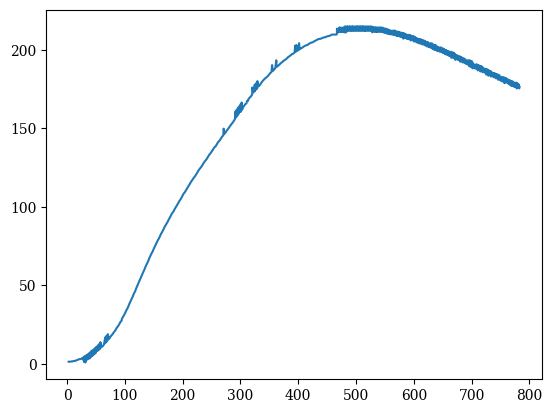

In [35]:
# plt.plot(time, values, '.');
plt.plot(time_alt, alt);

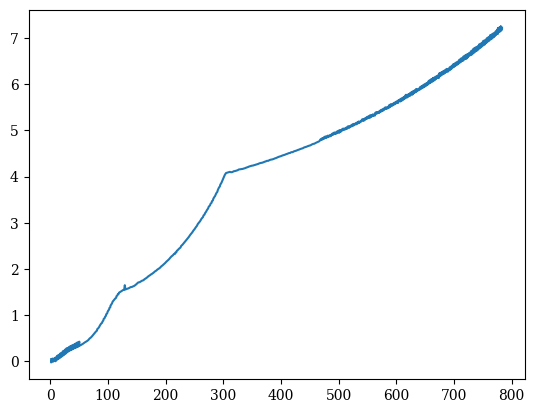

In [36]:
# plt.plot(time, values, '.');
plt.plot(time_vel, vel);

In [37]:
list(np.array([time_alt, alt]).T)

[array([2.72617124, 1.28317651]),
 array([4.94749596, 1.28536976]),
 array([7.16882068, 1.45726582]),
 array([9.3901454 , 1.45945907]),
 array([11.61147011,  1.80105793]),
 array([13.83279483,  1.80325118]),
 array([16.05411955,  2.14485004]),
 array([18.27544426,  2.4864489 ]),
 array([20.49676898,  2.82804776]),
 array([22.7180937 ,  2.99994381]),
 array([24.93941842,  3.17183987]),
 array([27.16074313,  3.85284434]),
 array([29.38206785,  1.13979272]),
 array([29.38206785,  4.364146  ]),
 array([31.60339257,  5.04515047]),
 array([31.60339257,  1.82079719]),
 array([31.60339257,  0.80258036]),
 array([33.82471729,  5.38674933]),
 array([33.82471729,  2.33209885]),
 array([36.046042  ,  6.06775379]),
 array([36.046042  ,  3.01310332]),
 array([38.26736672,  6.74875826]),
 array([38.45247711,  3.29831735]),
 array([40.48869144,  4.03570665]),
 array([40.48869144,  7.42976273]),
 array([42.71001616,  8.28047   ]),
 array([42.71001616,  4.71671111]),
 array([44.93134087,  8.79177166]),


In [38]:
raw ="""
-112.78271405492727, 503.99853602482716
-112.78271405492727, 502.98031920018263
-112.5976036618201, 493.25087453561554
-110.56138933764132, 504.67954049236005
-110.56138933764132, 503.32191805950066
-110.37627894453415, 493.8187438004101
-111.11672051696281, 492.79979589206454
-109.45072697899835, 502.4745006645151
-108.15495422724821, 505.36072773081816
-108.34006462035538, 503.6635169188187
-108.15495422724821, 501.28786043224
-108.34006462035538, 499.59064962024047
-108.34006462035538, 498.2330271873811
-108.34006462035538, 496.8754047545217
-108.34006462035538, 495.51778232166225
-108.34006462035538, 494.16015988880287
-108.34006462035538, 492.9722402600509
-108.89539579967686, 492.123177926738
-106.11873990306943, 506.04154942742576
-106.11873990306943, 504.6839269945664
-106.11873990306943, 503.326304561707
-106.11873990306943, 501.9686821288476
-106.11873990306943, 500.61105969598816
-106.11873990306943, 499.2534372631288
-106.11873990306943, 497.8958148302694
-106.11873990306943, 496.53819239741
-106.11873990306943, 495.1805699645506
-106.11873990306943, 493.82294753169117
-106.11873990306943, 492.80473070704664
-104.82296715131929, 535.2317111303797
-105.00807754442646, 533.5345003183802
-105.00807754442646, 532.5162834937356
-103.71230479267632, 537.2692414052204
-104.45274636510497, 506.04319436575315
-103.89741518578349, 504.68612024566954
-103.89741518578349, 503.32849781281016
-103.89741518578349, 501.97087537995077
-104.45274636510497, 500.61270463431555
-103.89741518578349, 498.9162249060171
-103.89741518578349, 497.5586024731577
-103.89741518578349, 496.2009800402983
-103.89741518578349, 494.8433576074389
-103.89741518578349, 493.4857351745795
-103.89741518578349, 492.46751834993495
-102.60164243403335, 535.2339043814828
-102.78675282714052, 533.5366935694834
-103.342084006462, 532.5179284320631
-101.67609046849755, 538.6288743182577
-101.67609046849755, 537.2712518853983
-101.67609046849755, 493.8273340338975
-101.67609046849755, 492.4697116010381
-100.56542810985457, 535.9147260780904
-100.56542810985457, 534.5571036452311
-101.12075928917605, 533.5383385078107
-99.4547657512116, 538.291661961146
-99.4547657512116, 536.9340395282866
-99.26965535810443, 523.6974035788328
-100.01009693053308, 493.8289789722249
-100.01009693053308, 492.81076214758036
-98.34410339256863, 535.2381081127639
-97.23344103392566, 537.9544496040344
-97.23344103392566, 536.5968271711749
-97.04833064081849, 525.0572192627953
-97.23344103392566, 523.3600084507958
-97.78877221324714, 522.6806489215903
-96.12277867528267, 535.2403013638672
-96.12277867528267, 533.8826789310077
-96.12277867528267, 532.5250564981483
-96.12277867528267, 531.167434065289
-96.12277867528267, 529.8098116324295
-96.12277867528267, 528.4521891995702
-96.12277867528267, 527.0945667667107
-95.0121163166397, 537.9566428551375
-95.0121163166397, 536.599020422278
-95.0121163166397, 525.738040959403
-95.0121163166397, 524.3804185265435
-95.0121163166397, 523.0227960936841
-93.90145395799674, 535.2424946149703
-93.90145395799674, 533.8848721821109
-93.90145395799674, 532.5272497492515
-93.90145395799674, 531.169627316392
-93.90145395799674, 529.8120048835327
-93.90145395799674, 528.4543824506733
-93.90145395799674, 527.0967600178138
-92.79079159935377, 537.9588361062407
-92.79079159935377, 536.6012136733813
-92.79079159935377, 525.7402342105061
-92.79079159935377, 524.3826117776466
-92.79079159935377, 523.0249893447873
-91.68012924071078, 535.2446878660735
-91.68012924071078, 533.887065433214
-91.68012924071078, 532.5294430003546
-91.68012924071078, 531.1718205674953
-91.68012924071078, 529.8141981346358
-91.68012924071078, 528.4565757017765
-91.68012924071078, 527.0989532689171
-91.68012924071078, 502.66174947744787
-91.68012924071078, 501.3041270445885
-91.68012924071078, 499.94650461172904
-91.68012924071078, 498.58888217886965
-91.68012924071078, 497.23125974601027
-91.68012924071078, 495.8736373131509
-91.49501884760362, 102.84212577127994
-91.68012924071078, 101.14491495928041
-91.68012924071078, 99.78729252642103
-91.68012924071078, 98.42967009356164
-91.68012924071078, 97.07204766070225
-91.68012924071078, 95.71442522784281
-91.68012924071078, 94.69620840319828
-90.56946688206781, 537.9610293573438
-90.56946688206781, 536.6034069244844
-90.56946688206781, 525.7424274616093
-90.56946688206781, 524.3848050287498
-90.56946688206781, 523.0271825958904
-90.38435648896065, 504.0206513067841
-90.38435648896065, 494.5172942767683
-90.56946688206781, 406.2716533699821
-90.56946688206781, 405.25343654533754
-90.56946688206781, 305.8075933383865
-90.56946688206781, 304.44997090552715
-90.56946688206781, 303.0923484726677
-90.56946688206781, 301.7347260398083
-90.56946688206781, 300.37710360694894
-90.56946688206781, 299.189183978197
-90.56946688206781, 294.2678026590816
-90.56946688206781, 293.07988303032965
-90.56946688206781, 205.34353330679096
-90.56946688206781, 204.155613678039
-90.38435648896065, 193.8039253984113
-91.1247980613893, 192.78497749006573
-89.45880452342485, 535.2468811171766
-89.45880452342485, 534.0589614884246
-90.01413570274633, 532.531087938682
-90.01413570274633, 531.1734655058226
-90.01413570274633, 529.8158430729633
-90.01413570274633, 528.4582206401038
-90.01413570274633, 527.1005982072444
-89.27369413031768, 501.9853142830466
-89.45880452342485, 500.28810347104707
-89.45880452342485, 498.9304810381877
-89.45880452342485, 497.5728586053283
-89.45880452342485, 496.21523617246885
-89.27369413031768, 104.20194145524249
-89.45880452342485, 102.50473064324297
-89.45880452342485, 101.14710821038358
-89.45880452342485, 99.78948577752419
-89.45880452342485, 98.4318633446648
-89.45880452342485, 97.07424091180542
-89.45880452342485, 95.71661847894597
-89.45880452342485, 94.35899604608659
-89.45880452342485, 93.17107641733463
-88.34814216478188, 537.963222608447
-88.34814216478188, 536.6056001755876
-88.34814216478188, 525.4052151044975
-88.34814216478188, 524.0475926716382
-88.34814216478188, 522.8596730428861
-88.34814216478188, 505.3802842198214
-88.34814216478188, 504.022661786962
-88.34814216478188, 494.5193047569462
-88.34814216478188, 493.33138512819426
-88.34814216478188, 406.2738466210852
-88.34814216478188, 405.2556297964407
-88.16303177167471, 394.73423871270563
-88.34814216478188, 393.20673070481354
-88.34814216478188, 305.8097865894897
-88.34814216478188, 304.45216415663026
-88.34814216478188, 303.0945417237709
-88.34814216478188, 301.7369192909115
-88.34814216478188, 300.37929685805204
-88.34814216478188, 299.0216744251927
-88.34814216478188, 294.2699959101848
-88.34814216478188, 292.9123734773254
-88.16303177167471, 205.3459093288194
-88.90347334410336, 204.32696142047376
-88.16303177167471, 195.16374108237392
-88.34814216478188, 193.4665302703744
-88.34814216478188, 192.27861064162238
-87.05236941303173, 535.3623923419433
-87.79281098546039, 502.6655876668784
-87.79281098546039, 501.307965234019
-87.79281098546039, 499.9503428011596
-87.79281098546039, 498.5927203683002
-87.79281098546039, 497.2350979354408
-87.23747980613891, 495.53861820714235
-87.05236941303173, 104.88294592277538
-87.23747980613891, 103.18573511077585
-87.79281098546039, 102.16696997335555
-87.79281098546039, 100.8093475404961
-87.79281098546039, 99.45172510763672
-87.79281098546039, 98.09410267477733
-87.79281098546039, 96.73648024191795
-87.23747980613891, 95.04000051361947
-87.23747980613891, 93.68237808076003
-87.23747980613891, 92.49445845200808
-86.12681744749592, 538.6442270759799
-86.12681744749592, 537.2866046431204
-86.68214862681741, 523.7098320017507
-86.12681744749592, 506.06128868735425
-86.12681744749592, 504.70366625449486
-86.68214862681741, 503.68490111707456
-85.94170705438876, 493.84286956254493
-86.68214862681741, 492.82392165419935
-86.12681744749592, 406.27603987218845
-86.12681744749592, 405.25782304754387
-85.94170705438876, 396.7728656130979
-86.12681744749592, 395.0756548010984
-86.12681744749592, 393.71803236823894
-86.68214862681741, 393.03867283903344
-86.12681744749592, 305.8119798405928
-86.12681744749592, 304.4543574077335
-86.68214862681741, 303.09618666209826
-86.12681744749592, 301.3997069337998
-86.12681744749592, 300.0420845009404
-86.68214862681741, 299.3627249717349
-86.12681744749592, 293.5933779448583
-86.12681744749592, 292.5751611202137
-86.12681744749592, 206.02673102542695
-86.12681744749592, 204.66910859256757
-86.12681744749592, 196.5233739954112
-86.12681744749592, 195.1657515625518
-86.12681744749592, 193.80812912969236
-86.12681744749592, 192.78991230504784
-85.01615508885295, 535.9300788358127
-85.01615508885295, 534.5724564029532
-85.01615508885295, 105.56376761938299
-85.01615508885295, 104.20614518652354
-85.01615508885295, 94.02397694007806
-85.01615508885295, 92.66635450721867
-83.90549273020999, 538.3070147188682
-83.90549273020999, 536.9493922860088
-83.72038233710282, 533.329248569309
-83.90549273020999, 506.0634819384574
-83.90549273020999, 504.705859505598
-83.90549273020999, 493.8448800427228
-83.90549273020999, 492.8266632180783
-83.90549273020999, 406.27823312329156
-83.90549273020999, 405.26001629864703
-83.72038233710282, 399.4903037299198
-83.90549273020999, 397.7930929179203
-83.90549273020999, 396.43547048506093
-83.90549273020999, 395.07784805220155
-84.46082390953147, 394.0590829147812
-84.46082390953147, 393.04086609013666
-83.90549273020999, 305.81417309169603
-83.90549273020999, 304.6262534629441
-83.90549273020999, 300.3836833602584
-83.90549273020999, 299.3654665356139
-83.90549273020999, 293.59557119596144
-83.90549273020999, 292.57735437131686
-83.90549273020999, 206.02892427653012
-83.90549273020999, 204.67130184367073
-83.72038233710282, 197.2045612338693
-83.90549273020999, 195.50735042186977
-83.90549273020999, 194.1497279890104
-83.90549273020999, 192.792105556151
-84.46082390953147, 192.1127460269455
-82.60971997845984, 535.2536436414114
-82.79483037156702, 105.56596087048615
-82.79483037156702, 104.37804124173414
-82.60971997845984, 93.34754174567684
-83.3501615508885, 91.98918822911634
-82.23949919224552, 537.290442832551
-81.49905761981687, 533.3314418204121
-81.68416801292403, 506.0656751895606
-81.68416801292403, 504.7080527567012
-81.68416801292403, 494.5258845102557
-81.68416801292403, 493.1682620773963
-81.68416801292403, 406.2804263743948
-81.68416801292403, 405.09250674564277
-81.68416801292403, 400.8499366429571
-81.68416801292403, 399.49231421009773
-81.68416801292403, 398.13469177723834
-81.68416801292403, 396.9467721484864
-82.23949919224552, 395.7583042069586
-81.68416801292403, 305.81636634279914
-81.68416801292403, 304.7981495181546
-81.68416801292403, 300.3858766113616
-81.68416801292403, 299.02825417850215
-81.68416801292403, 294.27657566349427
-81.68416801292403, 292.9189532306349
-81.68416801292403, 206.03111752763328
-81.68416801292403, 204.6734950947739
-81.49905761981687, 198.5643769178319
-81.68416801292403, 197.0368689099398
-82.23949919224552, 195.84840096841202
-81.68416801292403, 194.15192124011355
-81.68416801292403, 192.79429880725417
-82.23949919224552, 192.11493927804867
-81.12883683360255, 535.2551058088135
-80.57350565428106, 503.86063536171565
-80.57350565428106, 403.56627813422756
-80.57350565428106, 402.2086557013681
-80.57350565428106, 297.84143117530175
-80.3883952611739, 203.31715205839134
-80.3883952611739, 200.60190719267257
-80.57350565428106, 105.22874851337446
-80.57350565428106, 103.87112608051507
-80.3883952611739, 94.70735742963939
-80.57350565428106, 93.01014661763986
-81.12883683360255, 92.33078708843436
-79.4628432956381, 505.3890572242341
-79.4628432956381, 502.67381235851525
-79.4628432956381, 495.88570019421826
-79.4628432956381, 494.5280777613589
-79.4628432956381, 493.1704553284995
-79.4628432956381, 406.2826196254979
-79.4628432956381, 404.9249971926385
-79.4628432956381, 400.85212989406034
-79.4628432956381, 399.4945074612009
-80.01817447495958, 398.1363367155657
-79.4628432956381, 305.81855959390236
-79.4628432956381, 304.8003427692578
-79.4628432956381, 300.0486642542499
-79.4628432956381, 298.6910418213905
-79.27773290253093, 296.3153853348118
-79.4628432956381, 294.6181745228123
-79.4628432956381, 293.2605520899529
-80.01817447495958, 292.5811925607474
-79.4628432956381, 205.35449956230678
-79.4628432956381, 198.5663873980098
-80.01817447495958, 197.54762226058943
-79.4628432956381, 193.81470888300186
-79.4628432956381, 192.6267892542499
-79.4628432956381, 102.34489746909986
-78.35218093699513, 536.6154698055518
-78.16707054388796, 524.3970506807425
-78.35218093699513, 523.0392454769578
-78.35218093699513, 504.03253141692625
-78.35218093699513, 501.3172865512075
-78.35218093699513, 499.95966411834803
-78.35218093699513, 498.60204168548864
-78.35218093699513, 497.24441925262926
-78.35218093699513, 403.56847138533067
-78.35218093699513, 402.2108489524713
-78.35218093699513, 203.99797375499895
-78.35218093699513, 202.6403513221395
-78.35218093699513, 201.28272888928012
-78.35218093699513, 199.92510645642074
-78.35218093699513, 104.89153615626276
-78.35218093699513, 103.53391372340337
-78.35218093699513, 100.81866885768454
-78.35218093699513, 99.46104642482516
-78.35218093699513, 98.10342399196577
-78.35218093699513, 96.74580155910638
-78.35218093699513, 95.38817912624694
-78.35218093699513, 94.03055669338755
-78.35218093699513, 92.8426370646356
-77.24151857835214, 537.9741888639628
-77.24151857835214, 535.4286468023514
-77.24151857835214, 505.0518448671224
-77.05640818524498, 502.6761883805437
-77.05640818524498, 495.8880762162467
-77.24151857835214, 494.3605682083546
-77.79684975767364, 493.5115058750417
-77.24151857835214, 406.2848128766011
-77.24151857835214, 404.92719044374167
-77.79684975767364, 400.85377483238767
-77.24151857835214, 305.8207528450055
-77.24151857835214, 304.80253602036095
-77.24151857835214, 299.7114518971382
-77.24151857835214, 298.3538294642788
-77.24151857835214, 296.99620703141943
-77.24151857835214, 295.63858459856
-77.24151857835214, 294.2809621657006
-77.79684975767364, 293.2621970282803
-77.24151857835214, 205.0172872051951
-77.24151857835214, 199.24739186554262
-77.24151857835214, 193.81690213410502
-77.24151857835214, 192.45927970124563
-77.05640818524498, 102.17757068702088
-76.13085621970917, 536.617663056655
-76.13085621970917, 525.7566835937798
-76.13085621970917, 524.3990611609204
-76.13085621970917, 523.041438728061
-75.945745826602, 500.6408513568062
-76.13085621970917, 498.94364054480667
-76.13085621970917, 497.5860181119473
-76.13085621970917, 403.5706646364339
-76.13085621970917, 402.3827450076819
-75.945745826602, 203.32153856059767
-76.13085621970917, 201.62432774859815
-76.68618739903066, 200.60556261117785
-76.13085621970917, 103.8755125827214
-75.945745826602, 100.14223366328332
-76.13085621970917, 98.4450228512838
-76.13085621970917, 97.08740041842441
-76.13085621970917, 95.72977798556497
-76.13085621970917, 94.54185835681301
-76.68618739903066, 93.69279602350008
-75.0201938610662, 537.976382115066
-75.0201938610662, 535.2611372493471
-75.0201938610662, 533.9035148164878
-75.0201938610662, 532.5458923836284
-75.0201938610662, 531.188269950769
-75.0201938610662, 529.8306475179096
-75.0201938610662, 528.4730250850502
-75.0201938610662, 527.1154026521908
-75.57552504038769, 504.0352729808052
-75.0201938610662, 502.6781988607216
-75.0201938610662, 496.059789500532
-75.57552504038769, 494.8713215590043
-75.0201938610662, 405.94760051948936
-75.0201938610662, 404.7596808907374
-75.57552504038769, 305.82239778333286
-75.57552504038769, 304.80418095868833
-75.57552504038769, 299.03428561903587
-75.0201938610662, 297.67721149895226
-75.0201938610662, 296.3195890660929
-75.57552504038769, 294.9614183204577
-75.0201938610662, 193.47968977699338
-75.57552504038769, 192.80033024778788
-75.0201938610662, 102.17958116719876
-73.90953150242323, 536.6198563077581
-73.90953150242323, 525.7588768448829
-73.90953150242323, 524.4012544120236
-73.90953150242323, 523.0436319791642
-74.46486268174472, 501.32112474063797
-74.46486268174472, 499.9635023077786
-74.46486268174472, 498.6058798749192
-74.46486268174472, 497.2482574420598
-74.46486268174472, 100.8225070471151
-74.46486268174472, 99.46488461425571
-74.46486268174472, 98.10726218139632
-74.46486268174472, 96.74963974853694
-74.46486268174472, 95.73142292389235
-72.79886914378025, 537.9785753661691
-72.79886914378025, 535.2633305004504
-72.79886914378025, 533.9057080675909
-72.79886914378025, 532.5480856347316
-72.79886914378025, 531.1904632018721
-72.79886914378025, 529.8328407690127
-72.79886914378025, 528.4752183361534
-72.79886914378025, 527.1175959032939
-71.68820678513728, 536.6220495588614
-71.68820678513728, 525.7610700959862
-71.68820678513728, 524.4034476631267
-71.68820678513728, 523.0458252302674
-70.57754442649431, 537.9807686172724
-70.57754442649431, 535.2655237515535
-70.57754442649431, 533.9079013186941
-70.57754442649431, 532.5502788858347
-70.57754442649431, 531.1926564529754
-70.57754442649431, 529.8350340201159
-70.57754442649431, 528.4774115872565
-70.57754442649431, 527.1197891543972
-69.46688206785134, 536.6242428099645
-69.46688206785134, 525.7632633470893
-69.46688206785134, 524.4056409142299
-69.46688206785134, 523.0480184813705
-68.35621970920837, 537.9829618683755
-68.35621970920837, 535.2677170026567
-68.91155088852986, 533.9095462570215
-68.91155088852986, 532.5519238241621
-68.91155088852986, 531.1943013913027
-68.91155088852986, 529.8366789584433
-68.91155088852986, 528.4790565255839
-68.91155088852986, 527.1214340927245
-67.06044695745823, 536.6266188319929
-67.24555735056539, 524.7472397735479
-67.24555735056539, 523.559320144796
-67.80088852988688, 522.7102578114831
-67.24555735056539, 495.218951858856
-67.24555735056539, 493.8613294259966
-67.24555735056539, 492.843112601352
-67.24555735056539, 395.4337030436901
-67.24555735056539, 394.07608061083073
-67.24555735056539, 392.8881609820787
-67.24555735056539, 294.9696430120946
-67.24555735056539, 293.61202057923515
-67.24555735056539, 292.59380375459057
-67.24555735056539, 195.18439419692868
-67.24555735056539, 193.82677176406924
-67.24555735056539, 192.63885213531728
-67.24555735056539, 94.7203341653331
-67.24555735056539, 93.36271173247371
-67.24555735056539, 92.34449490782913
-65.57956381260092, 536.628080999395
-65.02423263327944, 523.9009190041139
-65.02423263327944, 495.22114510995914
-65.02423263327944, 493.86352267709975
-65.02423263327944, 492.67560304834774
-65.02423263327944, 395.4358962947933
-65.02423263327944, 394.0782738619339
-65.02423263327944, 392.89035423318194
-65.02423263327944, 294.9718362631977
-65.02423263327944, 293.6142138303383
-65.02423263327944, 292.4262942015863
-65.02423263327944, 195.18658744803184
-65.02423263327944, 193.8289650151724
-65.02423263327944, 192.64104538642044
-65.02423263327944, 94.72252741643626
-65.02423263327944, 93.36490498357688
-65.02423263327944, 92.17698535482486
-62.61779752288635, 537.309816550629
-62.8029079159935, 535.6126057386294
-62.61779752288635, 524.4124034384647
-62.8029079159935, 522.8848954305726
-63.358239095314985, 494.5439788318568
-63.358239095314985, 493.5257620072123
-63.358239095314985, 394.75873001669095
-63.358239095314985, 393.4011075838315
-63.358239095314985, 294.29466998509537
-63.358239095314985, 292.937047552236
-63.358239095314985, 194.5094211699295
-63.358239095314985, 193.49120434528498
-63.358239095314985, 94.04536113833393
-63.358239095314985, 92.68773870547454
-60.58158319870756, 537.9906382472366
-60.58158319870756, 536.6330158143771
-60.58158319870756, 535.2753933815178
-60.58158319870756, 534.0874737527658
-60.58158319870756, 528.4872812172208
-60.58158319870756, 527.1296587843614
-60.58158319870756, 525.7720363515019
-60.58158319870756, 524.4144139186426
-60.58158319870756, 523.0567914857832
-59.47092084006459, 532.5612451413506
-59.47092084006459, 531.2036227084911
-59.47092084006459, 529.8460002756317
-58.360258481421624, 537.9928314983397
-58.360258481421624, 536.6352090654804
-58.360258481421624, 535.2775866326209
-58.360258481421624, 533.9199641997616
-58.360258481421624, 528.4894744683239
-58.360258481421624, 527.1318520354646
-58.360258481421624, 525.7742296026051
-58.360258481421624, 524.4166071697457
-58.360258481421624, 523.0589847368864
-57.249596122778655, 532.5634383924537
-57.249596122778655, 531.2058159595944
-57.249596122778655, 529.8481935267349
-56.13893376413566, 537.9950247494429
-56.13893376413566, 536.6374023165835
-56.13893376413566, 535.2797798837241
-56.13893376413566, 533.9221574508647
-56.13893376413566, 528.4916677194271
-56.13893376413566, 527.1340452865677
-56.13893376413566, 525.7764228537083
-56.13893376413566, 524.4188004208489
-56.13893376413566, 523.0611779879895
-56.13893376413566, 502.6968414950985
-56.13893376413566, 501.3392190622391
-56.13893376413566, 499.9815966293797
-56.13893376413566, 498.6239741965203
-56.13893376413566, 497.2663517636609
-56.13893376413566, 496.07843213490895
-56.13893376413566, 302.4475326483371
-56.13893376413566, 301.0899102154777
-56.13893376413566, 299.7322877826183
-56.13893376413566, 298.37466534975886
-56.13893376413566, 297.01704291689947
-56.13893376413566, 295.8291232881475
-55.953823371028506, 102.87721778893058
-56.13893376413566, 101.18000697693105
-56.13893376413566, 99.82238454407167
-56.13893376413566, 98.46476211121228
-56.13893376413566, 97.1071396783529
-56.13893376413566, 95.74951724549345
-56.13893376413566, 94.73130042084892
-55.02827140549269, 532.5656316435569
-55.02827140549269, 531.2080092106975
-55.02827140549269, 529.850386777838
-54.843161012385536, 504.05574332443473
-55.02827140549269, 495.061311935816
-54.843161012385536, 405.62811694212826
-55.02827140549269, 403.93090613012873
-55.02827140549269, 402.5732836972694
-55.02827140549269, 401.21566126440996
-55.02827140549269, 399.8580388315506
-55.02827140549269, 394.76695470832783
-55.02827140549269, 393.5790350795759
-54.843161012385536, 303.8064344776733
-54.843161012385536, 294.5293478531341
-54.843161012385536, 205.37880809536688
-55.02827140549269, 203.68159728336735
-55.02827140549269, 202.32397485050797
-55.02827140549269, 200.96635241764852
-55.02827140549269, 199.60872998478914
-55.02827140549269, 194.5176458615664
-55.02827140549269, 193.32972623281444
-53.91760904684972, 537.997218000546
-53.91760904684972, 536.6395955676867
-53.91760904684972, 535.2819731348272
-53.91760904684972, 533.9243507019679
-53.91760904684972, 525.0998048883818
-53.91760904684972, 523.7421824555223
-53.91760904684972, 522.7239656308778
-53.73249865374257, 502.02040630069723
-53.91760904684972, 500.3231954886977
-53.91760904684972, 498.9655730558383
-53.91760904684972, 497.60795062297893
-53.91760904684972, 496.2503281901195
-53.73249865374257, 493.9878069062791
-53.73249865374257, 301.7710974539358
-53.91760904684972, 300.07388664193627
-53.91760904684972, 298.7162642090769
-53.91760904684972, 297.3586417762175
-53.91760904684972, 296.00101934335805
-53.91760904684972, 104.91566191839757
-53.91760904684972, 103.55803948553819
-53.91760904684972, 102.2004170526788
-53.91760904684972, 100.84279461981936
-53.91760904684972, 99.48517218695997
-53.91760904684972, 98.12754975410058
-53.91760904684972, 96.7699273212412
-53.91760904684972, 95.41230488838175
-53.91760904684972, 94.05468245552237
-53.91760904684972, 93.03646563087784
-52.80694668820675, 532.56782489466
-52.80694668820675, 531.2102024618007
-52.80694668820675, 529.8525800289412
-52.80694668820675, 528.6646604001893
-52.80694668820675, 505.41537623747206
-52.80694668820675, 504.0577538046127
-52.80694668820675, 406.30893863873587
-52.80694668820675, 404.9513162058765
-52.80694668820675, 403.5936937730171
-52.80694668820675, 402.23607134015765
-52.80694668820675, 400.8784489072983
-52.80694668820675, 399.5208264744389
-52.80694668820675, 394.769147959431
-52.80694668820675, 393.4115255265716
-52.80694668820675, 305.1660673907106
-52.80694668820675, 303.80844495785124
-52.80694668820675, 294.3050879278354
-52.80694668820675, 293.11716829908346
-52.80694668820675, 206.05962979197443
-52.80694668820675, 204.70200735911504
-52.80694668820675, 203.34438492625566
-52.80694668820675, 201.98676249339627
-52.80694668820675, 200.62914006053688
-52.80694668820675, 199.27151762767744
-52.80694668820675, 194.51983911266956
-52.80694668820675, 193.16221667981017
-51.69628432956378, 537.6600056434344
-51.69628432956378, 536.3023832105749
-51.69628432956378, 534.9447607777156
-51.69628432956378, 533.5871383448562
-51.51117393645663, 527.1386145596992
-51.69628432956378, 525.4414037476997
-51.69628432956378, 524.0837813148404
-52.251615508885266, 523.4044217856349
-51.69628432956378, 503.0406336055197
-52.251615508885266, 501.3430572516696
-52.251615508885266, 499.98543481881023
-52.251615508885266, 498.62781238595085
-52.251615508885266, 497.27018995309146
-51.69628432956378, 495.91311583300785
-51.69628432956378, 494.55549340014846
-51.69628432956378, 493.197870967289
-51.69628432956378, 302.79132475875826
-52.251615508885266, 301.0937484049082
-52.251615508885266, 299.7361259720488
-52.251615508885266, 298.3785035391894
-52.251615508885266, 297.02088110632997
-51.69628432956378, 295.32440137803155
-51.51117393645663, 104.91803794042602
-51.69628432956378, 103.39052993253392
-52.251615508885266, 102.20206199100619
-52.251615508885266, 100.84443955814675
-52.251615508885266, 99.48681712528736
-52.251615508885266, 98.12919469242797
-52.251615508885266, 96.77157225956859
-51.69628432956378, 95.07509253127012
-51.69628432956378, 93.71747009841067
-51.69628432956378, 92.52955046965872
-50.58562197092081, 531.8912069293335
-50.58562197092081, 530.5335844964741
-50.58562197092081, 529.1759620636147
-50.58562197092081, 506.0963807050049
-50.58562197092081, 504.7387582721455
-50.58562197092081, 406.3111318898391
-50.58562197092081, 404.95350945697965
-51.1409531502423, 403.5953387113444
-50.58562197092081, 401.898858983046
-50.58562197092081, 400.54123655018657
-50.58562197092081, 399.3533169214346
-50.58562197092081, 394.4319356023193
-50.58562197092081, 393.24401597356734
-50.58562197092081, 305.84707185824345
-50.58562197092081, 304.4894494253841
-50.40051157781366, 293.6286527334342
-51.1409531502423, 292.60970482508856
-50.58562197092081, 206.0618230430776
-50.58562197092081, 204.7042006102182
-50.58562197092081, 203.51628098146625
-50.58562197092081, 201.64955013628457
-50.58562197092081, 200.2919277034252
-50.58562197092081, 199.10400807467317
-50.58562197092081, 193.843221147343
-50.58562197092081, 192.82500432269848
-50.03029079159933, 535.9646225406875
-50.03029079159933, 534.6070001078281
-49.47495961227784, 532.9105203795297
-49.28984921917069, 527.8196190272322
-49.47495961227784, 526.1224082152327
-49.47495961227784, 524.7647857823732
-49.47495961227784, 523.4071633495139
-50.03029079159933, 522.7278038203084
-50.03029079159933, 503.72108976027675
-49.47495961227784, 494.55768665125163
-49.47495961227784, 493.2000642183922
-49.47495961227784, 105.59885963703363
-49.47495961227784, 104.24123720417418
-49.47495961227784, 93.71966334951384
-49.47495961227784, 92.53174372076188
-48.364297253634874, 531.214588964007
-48.364297253634874, 529.8569665311476
-48.364297253634874, 506.0985739561081
-48.364297253634874, 504.74095152324867
-48.364297253634874, 492.35264682340664
-48.364297253634874, 406.3133251409422
-48.364297253634874, 405.29510831629767
-48.364297253634874, 400.88283540950465
-48.364297253634874, 399.5252129766452
-48.364297253634874, 394.09472324520766
-48.364297253634874, 393.0765064205631
-48.364297253634874, 305.8492651093467
-48.364297253634874, 304.49164267648723
-48.364297253634874, 293.6306632136121
-48.364297253634874, 292.44274358486007
-48.364297253634874, 206.06401629418076
-48.364297253634874, 204.70639386132137
-48.364297253634874, 200.6335265627432
-48.364297253634874, 199.27590412988377
-48.364297253634874, 193.84541439844617
-48.364297253634874, 192.82719757380164
-47.253634894991905, 528.5004407238398
-47.253634894991905, 527.1428182909804
-47.253634894991905, 525.7851958581209
-47.253634894991905, 524.4275734252616
-47.253634894991905, 523.0699509924021
-47.253634894991905, 493.8810686859251
-47.253634894991905, 105.60105288813679
-47.253634894991905, 104.24343045527735
-47.06852450188475, 93.38263376332748
-47.80896607431339, 92.36368585498184
-45.957862143241755, 531.2169649860354
-46.14297253634891, 529.5197541740359
-46.14297253634891, 506.1007672072112
-46.14297253634891, 504.74314477435183
-46.14297253634891, 493.03365129093953
-46.14297253634891, 406.3155183920454
-46.14297253634891, 405.29730156740084
-46.14297253634891, 400.88502866060776
-46.14297253634891, 399.5274062277484
-46.14297253634891, 394.7757277127405
-46.14297253634891, 393.41810527988105
-46.14297253634891, 305.8514583604498
-46.14297253634891, 304.49383592759045
-46.14297253634891, 294.3116676811449
-46.14297253634891, 292.9540452482855
-46.14297253634891, 206.06620954528393
-46.14297253634891, 204.87828991653197
-46.14297253634891, 200.63571981384638
-46.14297253634891, 199.27809738098694
-46.14297253634891, 194.52641886597905
-46.14297253634891, 193.16879643311967
-45.03231017770594, 533.2543124899508
-45.03231017770594, 527.8238227585132
-45.03231017770594, 526.4662003256539
-45.03231017770594, 525.1085778927944
-45.03231017770594, 523.750955459935
-45.03231017770594, 494.56207315345796
-45.03231017770594, 398.340583224548
-45.03231017770594, 198.09127437778653
-45.03231017770594, 105.2638405310251
-45.03231017770594, 103.90621809816571
-44.847199784598786, 94.74244944729003
-45.03231017770594, 93.0452386352905
-45.58764135702742, 92.365879106085
-43.92164781906297, 535.9706539812212
-43.92164781906297, 534.6130315483618
-43.92164781906297, 531.897786682643
-43.92164781906297, 530.5401642497836
-43.92164781906297, 529.1825418169242
-43.92164781906297, 505.7635548500996
-43.92164781906297, 504.40593241724014
-43.92164781906297, 503.04830998438075
-43.92164781906297, 495.9207922118689
-43.92164781906297, 493.2055473461501
-43.92164781906297, 406.3177116431485
-43.92164781906297, 405.299494818504
-43.92164781906297, 400.887221911711
-43.92164781906297, 399.52959947885154
-43.92164781906297, 396.81435461313276
-43.92164781906297, 395.4567321802733
-43.92164781906297, 394.099109747414
-44.47697899838445, 393.08034460999363
-43.92164781906297, 305.853651611553
-43.92164781906297, 304.49602917869356
-43.92164781906297, 303.1384067458342
-43.92164781906297, 301.9504871170822
-43.73653742595582, 295.67166613603274
-43.92164781906297, 293.9744553240332
-43.92164781906297, 292.78653569528126
-43.92164781906297, 206.0684027963871
-43.92164781906297, 204.7107803635277
-43.92164781906297, 200.63791306494954
-43.92164781906297, 199.2802906320901
-43.92164781906297, 196.56504576637133
-43.92164781906297, 195.20742333351194
-43.92164781906297, 193.8498009006525
-44.47697899838445, 192.8310357632322
-43.92164781906297, 102.3799894867505
-42.62587506731285, 537.3295558105574
-42.62587506731285, 533.2566885119793
-43.366316639741484, 528.1648733050555
-42.62587506731285, 524.4321426983931
-42.81098546042, 523.0743374946085
-42.81098546042, 501.3523785688581
-42.81098546042, 499.9947561359987
-42.81098546042, 498.6371337031393
-42.81098546042, 497.2795112702799
-42.81098546042, 494.5642664045611
-42.62587506731285, 398.173256442469
-42.62587506731285, 300.42444127659223
-42.81098546042, 298.7272304645927
-42.81098546042, 297.3696080317333
-42.62587506731285, 197.92394759570755
-42.81098546042, 104.9266281739134
-42.81098546042, 103.56900574105401
-42.81098546042, 100.85376087533518
-42.81098546042, 95.42327114389758
-42.81098546042, 94.0656487110382
-42.81098546042, 92.87772908228624
-41.70032310177703, 535.2940360158947
-41.70032310177703, 531.2211687173165
-41.70032310177703, 529.863546284457
-41.70032310177703, 505.086936884773
-41.70032310177703, 503.72931445191364
-41.70032310177703, 502.37169201905425
-41.51521270866988, 495.92316823389734
-41.70032310177703, 493.7168490095756
-41.70032310177703, 406.31990489425175
-41.70032310177703, 405.30168806960717
-41.70032310177703, 400.2106039463844
-41.70032310177703, 396.1377366478062
-41.70032310177703, 394.7801142149468
-42.255654281098515, 393.76134907752646
-41.70032310177703, 304.8376280380116
-41.70032310177703, 303.4800056051522
-41.70032310177703, 302.12238317229276
-41.51521270866988, 295.6738593871359
-41.70032310177703, 294.1463513792438
-42.255654281098515, 293.29728904593094
-41.70032310177703, 206.07059604749026
-41.70032310177703, 204.8826764187383
-41.70032310177703, 199.961295099623
-41.70032310177703, 195.88842780104477
-41.70032310177703, 194.53080536818538
-42.255654281098515, 193.51204023076508
-41.51521270866988, 102.21266270467152
-40.58966074313406, 538.010377507165
-40.58966074313406, 536.6527550743057
-40.58966074313406, 533.9375102085869
-40.58966074313406, 532.5798877757275
-40.58966074313406, 525.7917756114305
-40.58966074313406, 524.434153178571
-40.58966074313406, 523.0765307457117
-40.40455035002691, 500.67594337445684
-40.58966074313406, 498.9787325624573
-40.58966074313406, 497.6211101295979
-40.40455035002691, 398.8542609100018
-40.58966074313406, 397.15705009800234
-40.40455035002691, 300.42663452769534
-40.58966074313406, 298.7294237156959
-40.58966074313406, 297.3718012828365
-40.40455035002691, 198.60495206324043
-40.58966074313406, 196.9077412512409
-40.58966074313406, 103.91060460037204
-40.40455035002691, 100.17732568093396
-40.58966074313406, 97.12249243607505
-40.58966074313406, 95.7648700032156
-40.58966074313406, 94.57695037446365
-41.144991922455546, 93.72788804115072
-39.47899838449109, 535.2962292669978
-39.47899838449109, 531.2233619684197
-39.47899838449109, 529.8657395355602
-39.47899838449109, 528.5081171027008
-39.47899838449109, 527.1504946698415
-40.03432956381258, 504.07036499845583
-39.47899838449109, 502.7132908783723
-39.47899838449109, 495.92517871407523
-40.03432956381258, 494.56700796844007
-40.03432956381258, 406.3215498325791
-40.03432956381258, 405.3033330079345
-40.03432956381258, 395.4605703697039
-40.03432956381258, 303.8210561516944
-39.47899838449109, 302.46398203161084
-39.47899838449109, 295.8455726714212
-40.03432956381258, 294.6571047298935
-40.03432956381258, 205.73283537760284
-40.03432956381258, 195.2112615229425
-39.47899838449109, 101.87526757663454
-38.36833602584812, 538.0125707582682
-38.36833602584812, 536.6549483254088
-38.36833602584812, 533.93970345969
-38.36833602584812, 532.5820810268306
-38.36833602584812, 525.7939688625336
-38.36833602584812, 524.4363464296742
-38.36833602584812, 523.0787239968148
-38.92366720516961, 501.3562167582886
-38.92366720516961, 499.9985943254292
-38.92366720516961, 498.64097189256984
-38.92366720516961, 497.28334945971045
-38.92366720516961, 397.4981006445446
-38.92366720516961, 396.4798838199
-38.92366720516961, 301.1069079115272
-38.92366720516961, 299.7492854786678
-38.92366720516961, 298.3916630458084
-38.92366720516961, 297.03404061294896
-38.92366720516961, 197.2487917977831
-38.92366720516961, 196.23057497313857
-38.92366720516961, 100.17878784833607
-38.92366720516961, 98.82116541547668
-38.92366720516961, 97.46354298261724
-38.92366720516961, 96.10592054975785
-37.257673667205125, 535.298422518101
-37.257673667205125, 531.2255552195228
-37.257673667205125, 529.8679327866635
-37.257673667205125, 528.510310353804
-37.257673667205125, 527.1526879209446
-36.147011308562156, 538.0147640093713
-36.147011308562156, 536.657141576512
-36.147011308562156, 533.9418967107932
-36.147011308562156, 532.5842742779338
-36.147011308562156, 525.7961621136368
-36.147011308562156, 524.4385396807774
-36.147011308562156, 523.080917247918
-35.03634894991919, 535.3006157692041
-35.03634894991919, 531.227748470626
-35.03634894991919, 529.8701260377666
-35.03634894991919, 528.5125036049071
-35.03634894991919, 527.1548811720478
-33.92568659127622, 538.0169572604746
-33.92568659127622, 536.6593348276151
-33.92568659127622, 534.1137927660038
-34.4810177705977, 532.5859192162611
-33.740576198169066, 525.7985381356652
-33.92568659127622, 524.1013273236657
-33.92568659127622, 522.9134076949138
-32.81502423263325, 535.4725118244147
-32.81502423263325, 500.68343698239266
-32.81502423263325, 499.49551735364065
-32.81502423263325, 402.9346218165159
-32.81502423263325, 401.57699938365647
-32.81502423263325, 400.2193769507971
-32.81502423263325, 398.8617545179377
-32.81502423263325, 397.50413208507825
-32.81502423263325, 396.3162124563263
-32.81502423263325, 302.4705617849203
-32.81502423263325, 301.11293935206095
-32.81502423263325, 299.7553169192015
-32.81502423263325, 298.3976944863421
-32.81502423263325, 297.04007205348273
-32.81502423263325, 295.8521524247308
-32.81502423263325, 202.68531296975442
-32.81502423263325, 201.32769053689503
-32.81502423263325, 199.97006810403565
-32.81502423263325, 198.61244567117626
-32.81502423263325, 197.25482323831682
-32.81502423263325, 196.06690360956486
-32.81502423263325, 102.2212529381589
-32.81502423263325, 100.86363050529945
-32.81502423263325, 99.50600807244007
-32.81502423263325, 98.14838563958068
-32.81502423263325, 96.7907632067213
-32.81502423263325, 95.60284357796928
-31.70436187399028, 537.6797449033629
-31.70436187399028, 536.4918252746108
-31.70436187399028, 524.7823317911985
-31.70436187399028, 523.5944121624466
-32.259693053311764, 522.7453498291337
-31.519251480883128, 503.39996124458827
-31.70436187399028, 501.7027504325888
-31.519251480883128, 497.96947151315067
-31.70436187399028, 496.2722607011512
-32.259693053311764, 495.5929011719457
-31.519251480883128, 404.29352364585213
-31.519251480883128, 395.0164370213129
-31.519251480883128, 303.8294636142566
-31.519251480883128, 294.5523769897173
-31.519251480883128, 204.0442147990907
-31.519251480883128, 194.7671281745515
-31.519251480883128, 103.58015476749512
-31.519251480883128, 94.30306814295591
-30.40858912224016, 500.0070017879914
-30.40858912224016, 494.5765120565538
-30.40858912224016, 402.25818662211464
-30.59369951534731, 400.5609758101151
-30.59369951534731, 399.20335337725567
-30.59369951534731, 397.8457309443963
-30.59369951534731, 396.4881085115369
-30.40858912224016, 301.79412659051906
-30.59369951534731, 300.09691577851953
-30.59369951534731, 298.73929334566014
-30.59369951534731, 297.3816709128007
-30.59369951534731, 296.0240484799413
-30.40858912224016, 202.0088777753532
-30.59369951534731, 200.31166696335367
-30.59369951534731, 198.9540445304943
-30.59369951534731, 197.59642209763484
-30.59369951534731, 196.23879966477546
-30.40858912224016, 101.54481774375762
-30.59369951534731, 99.8476069317581
-30.59369951534731, 98.4899844988987
-30.59369951534731, 97.13236206603932
-30.59369951534731, 95.77473963317988
-29.29792676359719, 504.7597769285509
-29.48303715670434, 503.06256611655135
-29.48303715670434, 501.7049436836919
-29.29792676359719, 497.97166476425383
-29.48303715670434, 496.27445395225436
-29.48303715670434, 405.65315655888946
-29.48303715670434, 404.29553412603
-29.48303715670434, 394.79217709601426
-29.48303715670434, 393.7739602713697
-29.48303715670434, 305.1890965272938
-29.48303715670434, 303.8314740944345
-29.48303715670434, 294.3281170644187
-29.48303715670434, 293.1401974356667
-29.48303715670434, 205.40384771212803
-29.48303715670434, 204.04622527926864
-29.48303715670434, 194.54286824925282
-29.48303715670434, 193.35494862050086
-29.48303715670434, 104.93978768053245
-29.48303715670434, 103.58216524767306
-29.48303715670434, 94.07880821765724
-29.48303715670434, 92.89088858890528
-28.18726440495422, 500.00919503909455
-28.18726440495422, 494.57870530765695
-28.372374798061372, 493.05119729976485
-28.18726440495422, 403.05232629238577
-28.927705977382857, 401.580837573087
-28.927705977382857, 400.22321514022764
-28.927705977382857, 398.86559270736825
-28.927705977382857, 397.5079702745088
-28.372374798061372, 396.1508961544252
-28.372374798061372, 302.81435389534147
-28.927705977382857, 301.1167775414915
-28.927705977382857, 299.75915510863206
-28.927705977382857, 298.40153267577267
-28.927705977382857, 297.0439102429133
-28.372374798061372, 295.6868361228296
-28.18726440495422, 202.80301744562433
-28.927705977382857, 201.3315287263256
-28.927705977382857, 199.9739062934662
-28.927705977382857, 198.6162838606068
-28.927705977382857, 197.25866142774737
-28.372374798061372, 195.90158730766376
-28.372374798061372, 102.56504504858003
-28.927705977382857, 100.86746869473001
-28.927705977382857, 99.50984626187062
-28.927705977382857, 98.15222382901123
-28.927705977382857, 96.79460139615185
-28.372374798061372, 95.43752727606818
-27.076602046311223, 537.3449085682796
-27.261712439418375, 535.6476977562801
-27.076602046311223, 524.4474954561153
-27.261712439418375, 522.9199874482232
-27.261712439418375, 506.11940984158815
-27.261712439418375, 504.76178740872876
-27.261712439418375, 503.5738677799768
-27.81704361873986, 502.04599423023416
-27.81704361873986, 497.97312693165594
-27.81704361873986, 496.61550449879655
-27.261712439418375, 406.3341610264223
-27.261712439418375, 404.97653859356285
-27.261712439418375, 394.79437034711736
-27.261712439418375, 393.436747914258
-27.261712439418375, 305.8701009948267
-27.261712439418375, 304.5124785619673
-27.261712439418375, 294.33031031552184
-27.261712439418375, 292.97268788266246
-27.261712439418375, 206.08485217966086
-27.261712439418375, 204.72722974680147
-27.261712439418375, 194.54506150035598
-27.261712439418375, 193.1874390674966
-27.261712439418375, 105.62079214806533
-27.261712439418375, 104.26316971520589
-27.261712439418375, 94.0810014687604
-27.261712439418375, 92.72337903590102
-26.151050080775406, 494.9201213960497
-26.151050080775406, 493.5624989631903
-26.70638126009689, 492.8831394339848
-26.70638126009689, 203.70956123493272
-25.040387722132436, 538.0257302648872
-25.040387722132436, 536.6681078320278
-25.040387722132436, 535.3104853991684
-25.040387722132436, 534.1225657704165
-25.040387722132436, 531.2376181005902
-25.040387722132436, 529.8799956677308
-25.040387722132436, 528.5223732348715
-25.040387722132436, 527.164750802012
-25.040387722132436, 525.8071283691526
-25.040387722132436, 524.4495059362932
-25.040387722132436, 523.0918835034338
-25.040387722132436, 506.1216030926913
-25.040387722132436, 504.76398065983193
-25.040387722132436, 406.33635427752546
-25.040387722132436, 404.9787318446661
-25.040387722132436, 394.4571579900057
-25.040387722132436, 393.26923836125377
-25.040387722132436, 305.8722942459299
-25.040387722132436, 304.5146718130705
-25.040387722132436, 293.99309795841015
-25.040387722132436, 292.8051783296582
-25.040387722132436, 206.08704543076402
-25.040387722132436, 204.72942299790463
-25.040387722132436, 194.54725475145915
-25.040387722132436, 193.18963231859976
-25.040387722132436, 105.6229853991685
-25.040387722132436, 104.26536296630906
-25.040387722132436, 93.74378911164871
-25.040387722132436, 92.55586948289675
-23.929725363489467, 532.5963371590012
-23.929725363489467, 493.90409782250833
-23.929725363489467, 492.88588099786375
-23.929725363489467, 192.17251211950673
-22.819063004846498, 538.0279235159903
-22.819063004846498, 536.670301083131
-22.819063004846498, 535.3126786502716
-22.819063004846498, 533.9550562174122
-22.819063004846498, 531.2398113516933
-22.819063004846498, 529.882188918834
-22.819063004846498, 528.5245664859746
-22.819063004846498, 527.1669440531152
-22.819063004846498, 525.8093216202558
-22.819063004846498, 524.4516991873963
-22.819063004846498, 523.094076754537
-22.819063004846498, 506.1237963437945
-22.819063004846498, 504.7661739109351
-22.819063004846498, 406.3385475286286
-22.819063004846498, 404.9809250957692
-22.633952611739346, 394.1201284038193
-23.374394184167983, 392.76177488725887
-22.819063004846498, 305.87448749703304
-22.819063004846498, 304.51686506417366
-22.819063004846498, 294.3346968177282
-22.819063004846498, 292.9770743848688
-22.819063004846498, 206.0892386818672
-22.819063004846498, 204.7316162490078
-22.819063004846498, 194.54944800256231
-22.819063004846498, 193.19182556970293
-22.819063004846498, 105.62517865027166
-22.819063004846498, 104.26755621741222
-22.633952611739346, 93.40675952546229
-23.374394184167983, 92.38781161711665
-21.70840064620353, 532.5985304101043
-21.70840064620353, 494.58510229004116
-21.70840064620353, 493.2274798571818
-20.59773828756056, 538.0301167670935
-20.59773828756056, 536.6724943342341
-20.59773828756056, 535.3148719013748
-20.59773828756056, 533.9572494685153
-20.59773828756056, 531.2420046027966
-20.59773828756056, 529.8843821699371
-20.59773828756056, 528.5267597370778
-20.59773828756056, 527.1691373042183
-20.59773828756056, 525.8115148713589
-20.59773828756056, 524.4538924384996
-20.59773828756056, 523.0962700056401
-20.59773828756056, 506.12598959489765
-20.59773828756056, 504.76836716203826
-20.59773828756056, 503.58044753328625
-20.59773828756056, 406.0013351715169
-20.59773828756056, 404.64371273865754
-20.59773828756056, 403.2860903057981
-20.412627894453408, 395.47994408778186
-20.59773828756056, 393.78273327578233
-21.153069466882044, 393.10337374657684
-20.59773828756056, 305.8766807481362
-20.59773828756056, 304.5190583152768
-20.59773828756056, 303.16143588241744
-20.59773828756056, 295.015701285261
-20.59773828756056, 293.6580788524017
-20.59773828756056, 292.6398620277571
-20.59773828756056, 205.75202632475555
-20.59773828756056, 204.3944038918961
-20.59773828756056, 203.03678145903672
-20.59773828756056, 195.90926368652487
-20.59773828756056, 194.55164125366548
-20.59773828756056, 193.1940188208061
-20.59773828756056, 105.28796629315997
-20.59773828756056, 103.93034386030058
-20.59773828756056, 102.57272142744114
-20.59773828756056, 95.44520365492929
-20.59773828756056, 94.0875812220699
-20.59773828756056, 92.72995878921051
-19.48707592891759, 532.6007236612076
-19.30196553581044, 502.0544016927963
-19.48707592891759, 497.30254040686316
-19.48707592891759, 495.9449179740037
-19.48707592891759, 494.58729554114433
-19.48707592891759, 493.22967310828494
-19.48707592891759, 401.59015889027546
-19.48707592891759, 400.2325364574161
-19.48707592891759, 398.8749140245567
-19.48707592891759, 397.51729159169724
-19.30196553581044, 301.8050928460349
-19.48707592891759, 300.10788203403536
-19.48707592891759, 298.7502596011759
-19.48707592891759, 297.3926371683166
-19.48707592891759, 296.03501473545714
-19.48707592891759, 201.34085004351402
-19.48707592891759, 199.98322761065464
-19.48707592891759, 198.62560517779525
-19.48707592891759, 197.2679827449358
-19.48707592891759, 100.87679001191844
-19.48707592891759, 99.51916757905906
-19.48707592891759, 98.16154514619967
-19.48707592891759, 96.80392271334028
-18.376413570274593, 538.0323100181967
-18.376413570274593, 536.6746875853373
-18.376413570274593, 535.3170651524779
-18.376413570274593, 533.9594427196186
-18.376413570274593, 531.2441978538997
-18.376413570274593, 529.8865754210403
-18.376413570274593, 528.5289529881809
-18.376413570274593, 527.1713305553216
-18.376413570274593, 525.8137081224621
-18.376413570274593, 524.4560856896027
-18.376413570274593, 523.0984632567433
-18.376413570274593, 505.4493716295711
-18.376413570274593, 504.0917491967117
-18.376413570274593, 500.0188818981335
-18.376413570274593, 498.6612594652741
-18.376413570274593, 405.32471720619037
-18.376413570274593, 403.967094773331
-18.376413570274593, 402.6094723404716
-18.19130317716747, 396.1609485553147
-18.376413570274593, 394.46373774331516
-18.931744749596106, 393.7843782141097
-18.376413570274593, 304.86065717459485
-18.376413570274593, 303.5030347417354
-18.19130317716747, 294.45240129359803
-18.931744749596106, 293.32031818251414
-18.376413570274593, 205.075408359429
-18.376413570274593, 203.7177859265696
-18.376413570274593, 202.36016349371022
-18.19130317716747, 195.91163970855325
-18.376413570274593, 194.38413170066121
-18.931744749596106, 193.53506936734829
-18.376413570274593, 104.61134832783341
-18.376413570274593, 103.25372589497402
-18.376413570274593, 101.89610346211464
-18.19130317716747, 95.44757967695767
-18.376413570274593, 93.7503688649582
-18.931744749596106, 93.0710093357527
-17.265751211631624, 532.2635113040958
-17.080640818524472, 502.73540616032915
-17.265751211631624, 501.0381953483296
-17.080640818524472, 497.30491642889154
-17.265751211631624, 495.6077056168921
-17.265751211631624, 494.41978598814006
-17.82108239095311, 493.57072365482713
-17.080640818524472, 400.9137236958742
-17.265751211631624, 399.21651288387466
-17.265751211631624, 397.85889045101527
-17.080640818524472, 301.80728609713805
-17.265751211631624, 300.1100752851385
-17.265751211631624, 298.75245285227913
-17.265751211631624, 297.3948304194197
-17.265751211631624, 296.0372079865603
-17.080640818524472, 200.6644148491128
-17.265751211631624, 198.96720403711328
-17.265751211631624, 197.60958160425383
-17.080640818524472, 100.20035481751722
-17.265751211631624, 98.5031440055177
-17.265751211631624, 97.14552157265831
-16.155088852988655, 538.0345032692999
-16.155088852988655, 536.6768808364404
-16.155088852988655, 535.3192584035811
-16.155088852988655, 530.5675798885732
-16.155088852988655, 529.2099574557137
-16.155088852988655, 526.494712589995
-16.155088852988655, 525.1370901571356
-16.155088852988655, 523.7794677242762
-16.155088852988655, 522.7612508996316
-16.71042003231014, 504.77220535146876
-16.155088852988655, 499.342263932807
-16.155088852988655, 403.96928802443415
-16.155088852988655, 402.61166559157476
-15.969978459881503, 396.27627700915616
-16.71042003231014, 394.80478828985747
-16.71042003231014, 303.8440852882777
-16.71042003231014, 294.6801338664767
-16.71042003231014, 204.0588364731118
-16.155088852988655, 202.7017623530282
-16.155088852988655, 195.9136501887312
-16.71042003231014, 194.89488505131084
-16.155088852988655, 103.25591914607719
-16.155088852988655, 101.8982967132178
-15.969978459881503, 95.56290813079914
-16.71042003231014, 94.43082501971526
-15.044426494345686, 534.1324354003807
-14.859316101238534, 531.9264817179094
-15.044426494345686, 528.3625400607282
-15.59975767366717, 503.415679544161
-15.044426494345686, 502.05860542407737
-15.044426494345686, 500.700982991218
-15.044426494345686, 497.98573812549915
-15.044426494345686, 496.7978184967472
-15.59975767366717, 495.26994494700455
-15.59975767366717, 400.9151858632763
-15.59975767366717, 399.5575634304169
-15.59975767366717, 398.1999409975575
-15.59975767366717, 302.4875594809698
-15.59975767366717, 301.1299370481105
-15.59975767366717, 299.77231461525105
-15.59975767366717, 298.41469218239166
-15.59975767366717, 297.0570697495323
-15.59975767366717, 295.69944731667283
-15.59975767366717, 201.34468823294458
-15.59975767366717, 199.9870658000852
-15.59975767366717, 198.6294433672258
-15.59975767366717, 197.27182093436636
-15.59975767366717, 100.20181698491933
-15.59975767366717, 98.84419455205995
-15.59975767366717, 97.4865721192005
-13.933764135702717, 538.036696520403
-13.933764135702717, 536.6790740875437
-13.933764135702717, 535.3214516546842
-13.933764135702717, 529.8909619232467
-13.933764135702717, 527.1757170575279
-13.933764135702717, 525.8180946246684
-13.933764135702717, 524.460472191809
-13.933764135702717, 523.1028497589497
-14.489095315024201, 499.3439088711344
-12.823101777059748, 533.9649258473764
-12.823101777059748, 532.607303414517
-12.823101777059748, 531.2496809816577
-12.823101777059748, 528.5344361159388
-11.712439418416778, 538.0388897715062
-11.712439418416778, 536.6812673386468
-11.712439418416778, 535.3236449057874
-11.712439418416778, 529.8931551743498
-11.712439418416778, 527.177910308631
-11.712439418416778, 525.8202878757716
-11.712439418416778, 524.4626654429122
-11.712439418416778, 523.1050430100528
-10.60177705977381, 533.9671190984795
-10.60177705977381, 532.7791994697276
-11.157108239095294, 531.251325919985
-11.157108239095294, 528.5360810542662
-9.49111470113084, 538.0410830226093
-9.49111470113084, 536.68346058975
-9.49111470113084, 535.3258381568905
-9.49111470113084, 526.8406979515194
-9.49111470113084, 525.4830755186599
-9.49111470113084, 524.1254530858005
-9.49111470113084, 522.9375334570485
-9.49111470113084, 199.48398882829662
-8.380452342487843, 533.9693123495828
-8.19534194938069, 500.02893429902304
-8.935783521809327, 499.00998639067745
-8.19534194938069, 400.2436854838572
-8.19534194938069, 299.7796254522616
-8.380452342487843, 200.67300508260018
-8.19534194938069, 99.53031660550016
-8.935783521809327, 98.51136869715458
-8.19534194938069, -0.25493220966575336
-8.935783521809327, -1.2738801180113342
-8.380452342487843, -19.261829040622615
-8.380452342487843, -20.619451473481945
-8.380452342487843, -21.97707390634139
-7.269789983844873, 538.0432762737125
-7.269789983844873, 536.6856538408531
-7.269789983844873, 535.3280314079938
-7.269789983844873, 532.9521921504897
-7.084679590737721, 527.1824795817625
-7.269789983844873, 525.4852687697631
-7.269789983844873, 524.1276463369037
-7.269789983844873, 522.9397267081517
-7.269789983844873, 199.31647927529235
-7.269789983844873, -16.545487549352174
-7.269789983844873, -17.903109982211618
-7.269789983844873, -23.333599713649164
-7.269789983844873, -24.521519342401234
-5.974017232094752, 533.9716883716112
-6.159127625201904, 500.70975599563064
-6.159127625201904, 499.3521335627712
-6.159127625201904, 400.92450718046473
-6.159127625201904, 399.56688474760534
-6.159127625201904, 300.4604471488692
-6.159127625201904, 299.10282471600976
-6.159127625201904, 200.67519833370335
-6.159127625201904, 100.21113830210777
-6.159127625201904, 98.85351586924838
-6.159127625201904, 0.42588948694196915
-6.159127625201904, -0.9317329459174744
-5.974017232094752, -15.186585720015955
-5.974017232094752, -19.259453018594172
-6.159127625201904, -20.956663830593584
-6.159127625201904, -22.314286263453027
-5.974017232094752, -25.82129477741455
-5.60379644588042, 537.3661099956103
-5.048465266558935, 535.6696302673117
-5.048465266558935, 528.5421124947999
-5.048465266558935, 527.1844900619406
-5.048465266558935, 525.8268676290811
-5.048465266558935, 524.4692451962217
-5.048465266558935, 523.2813255674697
-5.048465266558935, 199.31867252639552
-5.048465266558935, -17.222105514678674
-5.048465266558935, -24.010217678975664
-4.493134087237451, 533.9731505390133
-3.937802907915966, 500.7119492467338
-3.937802907915966, 499.3543268138744
-3.937802907915966, 400.92670043156795
-3.937802907915966, 399.5690779987085
-3.937802907915966, 300.4626403999723
-3.937802907915966, 299.105017967113
-3.937802907915966, 200.67739158480651
-3.937802907915966, 100.21333155321093
-3.937802907915966, 98.85570912035155
-3.937802907915966, 0.42808273804507735
-3.937802907915966, -0.9295396948143662
-3.937802907915966, -14.505764023408346
-3.937802907915966, -15.86338645626779
-3.937802907915966, -18.578631321986563
-3.937802907915966, -19.936253754845893
-3.937802907915966, -21.293876187705337
-3.937802907915966, -22.65149862056478
-3.937802907915966, -25.366743486283553
-3.937802907915966, -26.55466311503551
-3.3824717285944814, 528.5437574331273
-2.827140549272997, 527.3563861171511
-3.3824717285944814, 525.8285125674084
-2.827140549272997, 199.32086577749868
-3.3824717285944814, -17.220460576351343
-2.827140549272997, -24.347430036087417
-1.7164781906300277, 500.3747368896221
-1.7164781906300277, 499.0171144567627
-1.7164781906300277, 497.99889763211814
-1.7164781906300277, 400.92889368267106
-1.7164781906300277, 399.5712712498117
-1.7164781906300277, 398.55305442516715
-1.5313677975228757, 300.46501642200076
-1.7164781906300277, 298.76780561000123
-2.2718093699515123, 298.0884460807958
-1.5313677975228757, 200.67976760683496
-1.5313677975228757, 198.19079314659274
-1.5313677975228757, 100.21570757523938
-1.7164781906300277, 98.51849676323985
-2.2718093699515123, 97.83913723403435
-1.5313677975228757, 0.43045876007352035
-1.7164781906300277, -1.2667520519260052
-1.7164781906300277, -13.824759555875403
-1.7164781906300277, -15.182381988734846
-2.2718093699515123, -16.201147126155206
-1.5313677975228757, -26.043178680684832
-2.2718093699515123, -27.062126589030413
-0.6058158319870586, -2.9626834674486417
-0.6058158319870586, -4.320305900308085
-0.6058158319870586, -5.677928333167415
-0.050484652665574004, 100.89598095907115
-0.050484652665574004, 99.53835852621177
-0.050484652665574004, 98.52014170156724
0.504846526655939, 0.7718748484662683
0.504846526655939, -0.5857475843931752
0.504846526655939, -1.9433700172526187
0.504846526655939, -6.52534572815307
0.504846526655939, -13.822566304772295
0.504846526655939, -15.180188737631738
0.504846526655939, -26.041168200506945
0.504846526655939, -27.059385025151414
1.8006192784060602, -3.6391186618499205
1.6155088852989081, -5.33632947384956
2.7261712439418773, -0.24414872507509244
2.7261712439418773, -1.4320683538270487
2.7261712439418773, -13.820373053669073
2.7261712439418773, -15.177995486528516
2.9112816370490293, -25.35998096204878
2.7261712439418773, -26.88748896994082
3.8368336025848464, -16.025412881514058
4.9474959612278155, -0.24195547397198425
4.392164781906331, -1.260720611392344
4.9474959612278155, -14.496991018995686
4.9474959612278155, -17.21223588471446
4.9474959612278155, -18.569858317573903
4.9474959612278155, -19.75777794632586
5.132606354334968, -21.963731628797177
4.9474959612278155, -23.66094244079659
4.9474959612278155, -25.018564873656032
4.9474959612278155, -26.20648450240799
4.392164781906331, -27.05554683572086
6.058158319870785, -15.853516826303576
7.168820678513754, -0.23976222286876236
7.168820678513754, -14.834203376107325
7.353931071620906, -17.209859862686017
7.168820678513754, -18.907070674685542
7.168820678513754, -20.264693107544872
7.168820678513754, -21.622315540404315
7.168820678513754, -22.97993797326376
7.168820678513754, -24.33756040612309
7.168820678513754, -25.525480034875045
6.613489499192269, -26.374542368188145
9.390145395799692, -0.23756897176565417
8.834814216478208, -16.529586478854185
9.390145395799692, -18.226066207152712
9.390145395799692, -19.583688640012042
9.390145395799692, -20.941311072871486
9.390145395799692, -22.29893350573093
8.834814216478208, -23.317698643151175
8.834814216478208, -24.67532107601062
11.79658050619281, 533.3104231640068
11.611470113085659, 531.6132123520073
11.611470113085659, -0.2353757206624323
12.722132471728628, -1.2524959197554608
13.832794830371597, 533.9912448606144
13.832794830371597, 532.633622427755
13.832794830371597, 531.2759999948956
13.832794830371597, 530.0880803661437
13.832794830371597, -0.2331824695593241
14.943457189014566, 528.5618517547284
14.943457189014566, -1.2503026686523526
16.054119547657535, 533.9934381117175
16.054119547657535, 532.6358156788582
16.054119547657535, 531.2781932459988
16.054119547657535, 529.9205708131394
16.054119547657535, 527.375028751528
16.054119547657535, -0.2309892184561022
17.164781906300504, 528.5640450058315
17.164781906300504, 525.8488001401128
17.164781906300504, -1.2481094175491307
18.275444264943474, 533.9956313628207
18.275444264943474, 532.6380089299613
18.275444264943474, 531.280386497102
18.275444264943474, 529.9227640642425
18.275444264943474, 527.2075191985238
18.275444264943474, 524.492274332805
18.275444264943474, -0.228795967352994
19.386106623586443, 528.5662382569348
19.386106623586443, 525.850993391216
19.386106623586443, 523.3054513296046
19.386106623586443, -1.2459161664460225
20.49676898222944, 533.6584190057091
20.49676898222944, 532.3007965728497
20.49676898222944, 530.9431741399902
20.49676898222944, 529.5855517071309
20.681879375336592, 527.2098952205522
20.681879375336592, 524.4946503548333
20.49676898222944, -0.566008324464633
21.60743134087241, 522.7985361683855
22.71809369951538, 533.3212066485974
22.71809369951538, 532.1332870198454
22.71809369951538, 527.8907169171598
22.71809369951538, 526.5330944843004
22.71809369951538, 525.1754720514409
22.71809369951538, 523.8178496185816
22.71809369951538, -0.9032206815763857
23.828756058158348, 522.8007294194886
25.12452880990847, 533.3235826706258
24.939418416801317, 531.6263718586263
25.12452880990847, 527.8930929391883
24.939418416801317, 526.1958821271887
24.939418416801317, 524.8382596943293
24.939418416801317, 523.6503400655773
24.939418416801317, -0.22221621404344205
24.939418416801317, -1.2404330386880247
26.050080775444286, 529.9304404431036
27.160743134087255, 534.0044043672334
27.160743134087255, 532.646781934374
27.160743134087255, 531.2891595015146
27.160743134087255, 528.5739146357957
27.160743134087255, 527.2162922029364
27.160743134087255, 526.0283725741845
26.60541195476577, 524.5004990244418
26.60541195476577, -0.5599768839309718
28.271405492730224, 529.9326336942067
29.382067851373222, 534.0065976183365
29.382067851373222, 532.6489751854772
29.382067851373222, 531.2913527526177
29.382067851373222, 528.7458106910063
28.82673667205171, 527.5573427494786
30.49273021001619, 530.1045297494173
31.60339256865916, 534.0087908694397
31.60339256865916, 532.6511684365803
31.60339256865916, 531.293546003721
31.60339256865916, -0.7247448730562382
33.8247172859451, 532.9927672958984
33.8247172859451, 531.6351448630389
33.8247172859451, 530.6169280383943
33.8247172859451, -0.8922544260605036
34.93537964458807, 525.017832128401
36.23115239633819, 532.655737709712
36.04604200323104, 530.9585268977124
36.04604200323104, 529.600904464853
36.04604200323104, 528.2432820319937
36.04604200323104, 526.5462539909194
36.04604200323104, 523.8310091252006
36.04604200323104, -0.8900611749573955
37.156704361874006, 525.1897281836116
37.156704361874006, 522.8138889261076
38.45247711362413, 533.3367421772448
38.267366720516975, 531.6395313652453
38.267366720516975, 530.2819089323859
38.267366720516975, 528.9242864995265
38.267366720516975, 527.566664066667
38.267366720516975, 526.2090416338077
38.45247711362413, 523.833385147229
38.267366720516975, -0.8878679238541736
40.48869143780294, 534.0175638738524
40.48869143780294, 532.659941440993
40.48869143780294, 531.3023190081336
40.48869143780294, 529.9446965752742
40.48869143780294, 528.5870741424148
40.48869143780294, 527.2294517095554
40.48869143780294, 525.871829276696
40.48869143780294, 524.5142068438366
40.48869143780294, 523.1565844109772
40.48869143780294, -0.8856746727510654
42.71001615508888, 534.0197571249555
42.71001615508888, 532.6621346920962
42.71001615508888, 531.3045122592367
42.71001615508888, 529.9468898263774
42.71001615508888, 528.589267393518
42.71001615508888, 527.2316449606585
42.71001615508888, 525.8740225277992
42.71001615508888, 524.5164000949397
42.71001615508888, 523.1587776620804
42.71001615508888, -0.5440758134329826
44.93134087237482, 534.0219503760587
44.93134087237482, 532.6643279431993
44.93134087237482, 531.30670551034
44.93134087237482, 529.9490830774805
44.93134087237482, 528.5914606446211
44.93134087237482, 527.2338382117617
44.93134087237482, 525.8762157789023
44.93134087237482, 524.518593346043
44.93134087237482, 523.1609709131835
47.15266558966076, 534.0241436271618
47.15266558966076, 532.6665211943025
47.15266558966076, 531.3088987614431
47.15266558966076, 529.9512763285837
47.15266558966076, 528.5936538957243
47.15266558966076, 527.2360314628648
47.15266558966076, 525.8784090300055
47.15266558966076, 524.5207865971461
47.15266558966076, 523.1631641642867
47.15266558966076, -0.5396893112266525
49.37399030694672, 533.3475256618353
49.37399030694672, 531.989903228976
49.37399030694672, 530.6322807961166
49.37399030694672, 528.9352527550423
49.37399030694672, 527.5776303221829
49.37399030694672, 526.2200078893235
49.37399030694672, 524.8623854564642
49.37399030694672, 523.6744658277121
48.81865912762524, 522.8254034943992
49.37399030694672, -0.5374960601235443
51.03998384491118, 527.2398696522954
51.03998384491118, 525.8822472194361
51.03998384491118, 524.5246247865766
51.59531502423266, -0.5353028090203225
53.8166397415186, -0.5331095579172143
56.03796445880454, -0.5309163068139924
58.259289176090505, -0.5287230557108842
60.48061389337644, -0.5265298046076623
62.70193861066241, -0.5243365535045541
64.92326332794835, -0.5221433024013322
67.14458804523429, -0.519950051298224
68.44036079698441, 537.4392183657158
68.25525040387726, 535.7420075537162
68.44036079698441, 525.2206164699811
68.25525040387726, 523.5234056579816
69.36591276252022, -0.5177568001950021
70.4765751211632, 538.1200400623234
70.4765751211632, 536.7624176294639
70.4765751211632, 535.4047951966045
70.4765751211632, 534.0471727637452
70.4765751211632, 532.6895503308857
70.4765751211632, 531.3319278980264
70.4765751211632, 529.9743054651669
70.4765751211632, 528.6166830323075
70.4765751211632, 527.2590605994482
70.4765751211632, 525.9014381665887
70.4765751211632, 524.5438157337293
70.4765751211632, 523.18619330087
71.03190630048465, 124.3851519611971
71.58723747980616, -0.515563549091894
72.69789983844913, 538.1222333134265
72.69789983844913, 536.764610880567
72.69789983844913, 535.4069884477077
72.69789983844913, 534.0493660148483
72.69789983844913, 532.6917435819889
72.69789983844913, 531.3341211491295
72.69789983844913, 529.97649871627
72.69789983844913, 528.6188762834107
72.69789983844913, 527.2612538505513
72.69789983844913, 525.9036314176919
72.69789983844913, 524.5460089848325
72.69789983844913, 523.188386551973
72.69789983844913, 125.74441933238387
73.8085621970921, -0.5133702979886721
74.91922455573507, 538.1244265645297
74.91922455573507, 536.7668041316703
74.91922455573507, 535.4091816988108
74.91922455573507, 534.0515592659515
74.91922455573507, 532.693936833092
74.91922455573507, 531.3363144002326
74.91922455573507, 529.9786919673733
74.91922455573507, 528.6210695345138
74.91922455573507, 527.2634471016545
74.91922455573507, 525.905824668795
74.91922455573507, 524.5482022359356
74.91922455573507, 523.1905798030763
74.36389337641361, 126.42487548714098
76.02988691437804, 127.7841428583277
76.02988691437804, -0.5111770468855639
77.14054927302101, 538.1266198156328
77.14054927302101, 536.7689973827734
77.14054927302101, 535.411374949914
77.14054927302101, 534.0537525170546
77.14054927302101, 532.6961300841953
77.14054927302101, 531.3385076513358
77.14054927302101, 529.9808852184764
77.14054927302101, 528.7929655897244
76.58521809369955, 527.2650920399818
77.14054927302101, 525.9080179198983
77.14054927302101, 524.5503954870388
77.14054927302101, 523.1927730541794
77.69588045234252, 128.4645990130848
78.25121163166398, -0.508983795782342
79.36187399030695, 538.128813066736
79.36187399030695, 536.7711906338766
79.36187399030695, 535.4135682010171
78.80654281098549, 534.3948030635969
79.36187399030695, 532.3589177270835
79.36187399030695, 531.0012952942242
79.36187399030695, 529.6436728613647
79.36187399030695, 528.6254560367202
79.36187399030695, 524.8919943463568
79.36187399030695, 523.7040747176048
78.80654281098549, 522.855012384292
79.36187399030695, 129.82386638427158
80.65764674205707, 130.95649780813125
80.47253634894992, -0.5067905446792338
81.58319870759294, 538.1310063178391
81.58319870759294, 536.7733838849797
81.58319870759294, 535.4157614521204
81.58319870759294, 532.0217053699719
81.58319870759294, 530.6640829371124
81.58319870759294, 529.3064605042531
81.58319870759294, 527.9488380713937
81.58319870759294, 526.7609184426417
82.1385298869144, 132.2024472056545
82.69386106623591, -0.5045972935760119
83.80452342487888, 538.1331995689424
83.80452342487888, 536.7755771360829
83.80452342487888, 535.4179547032235
83.80452342487888, 532.023898621075
83.80452342487888, 530.6662761882156
83.80452342487888, 529.3086537553562
83.80452342487888, 527.9510313224969
83.80452342487888, 526.5934088896374
83.80452342487888, 525.4054892608855
83.80452342487888, 133.90112018505613
84.91518578352185, 534.2311317000231
85.100296176629, 524.105713825872
84.91518578352185, -0.5024040424729037
86.02584814216482, 538.1353928200455
86.02584814216482, 536.7777703871861
86.02584814216482, 535.4201479543267
86.02584814216482, 532.7049030886079
86.02584814216482, 531.3472806557485
86.02584814216482, 529.989658222889
86.02584814216482, 528.6320357900297
86.02584814216482, 527.2744133571703
86.02584814216482, 525.9167909243109
86.02584814216482, 134.92153026080382
85.4705169628433, 133.90276512338352
87.13651050080779, 534.0636221470189
87.13651050080779, 524.560265117003
87.13651050080779, 523.2026426841437
87.32162089391494, 136.3935672928783
87.13651050080779, -0.5002107913696818
88.24717285945076, 537.7981804629338
88.24717285945076, 536.4405580300744
88.24717285945076, 535.0829355972149
88.43228325255791, 532.7072791106364
88.24717285945076, 531.0100682986368
87.69184168012924, 529.9913031612165
88.24717285945076, 528.294823432918
88.24717285945076, 526.9372010000586
88.24717285945076, 525.5795785671992
89.54294561120088, 523.8838299226018
88.80250403877221, 522.8648820142562
89.54294561120088, 138.3190589905323
88.80250403877221, 136.96070547397187
89.35783521809373, -0.49801754026657363
90.4684975767367, 537.1215624976072
90.4684975767367, 535.7639400647479
90.4684975767367, 534.4063176318884
90.4684975767367, 533.0486951990291
90.4684975767367, 531.6910727661697
89.91316639741518, 531.0117132369642
90.4684975767367, 526.9393942511617
90.4684975767367, 525.5817718183024
91.76427032848687, 523.886023173705
91.02382875605821, 522.8670752653594
91.57915993537966, -0.49582428916335175
92.13449111470118, 536.1049906112901
92.13449111470118, 534.7473681784306
92.68982229402263, 533.3902940583471
92.13449111470118, 532.3715289209267
92.68982229402263, 525.5839650694055
93.8004846526656, 523.8880336538829
93.8004846526656, 522.8698168292383
93.8004846526656, 142.73553562860644
93.24515347334415, 141.37736488297122
93.8004846526656, -0.49363103806024355
94.91114701130857, 525.2467527122939
96.02180936995154, 523.890226904986
96.02180936995154, 522.8720100803415
96.20691976305875, 144.54807489444738
95.46647819063008, 143.4159917833635
96.02180936995154, -0.49143778695702167
97.31758212170172, 537.4677306300568
97.13247172859451, 536.1099254262722
97.13247172859451, 525.248945963397
98.42824448034469, 523.8926029270144
97.68780290791602, 522.8736550186688
98.24313408723748, -0.4892445358539135
99.35379644588045, 538.1485523266645
99.35379644588045, 536.7909298938051
99.35379644588045, 535.4333074609457
99.35379644588045, 534.2453878321937
99.35379644588045, 525.9299504309299
99.35379644588045, 148.171508487802
100.46445880452347, 532.7191592207785
100.46445880452347, 531.361536787919
100.46445880452347, 530.0039143550597
100.46445880452347, 528.6462919222002
100.46445880452347, 527.2886694893409
100.46445880452347, 524.573424623622
100.46445880452347, 523.2158021907627
100.46445880452347, -0.4870512847506916
101.57512116316644, 538.1507455777677
101.57512116316644, 536.7931231449082
101.57512116316644, 535.4355007120488
101.57512116316644, 534.0778782791895
101.57512116316644, 525.932143682033
102.68578352180941, 532.7213524718816
102.68578352180941, 531.3637300390222
102.68578352180941, 530.0061076061628
102.68578352180941, 528.6484851733035
102.68578352180941, 527.290862740444
102.68578352180941, 524.5756178747253
102.68578352180941, 523.2179954418658
102.68578352180941, 150.72034042606805
102.68578352180941, -0.4848580336475834
103.79644588045238, 538.1529388288708
103.79644588045238, 536.7953163960115
103.79644588045238, 535.437693963152
103.79644588045238, 534.0800715302926
103.79644588045238, 525.9343369331363
103.98155627355953, 152.0226746540352
104.90710823909535, 532.7235457229848
104.90710823909535, 531.3659232901254
104.90710823909535, 530.008300857266
104.90710823909535, 528.6506784244066
104.90710823909535, 527.2930559915471
104.90710823909535, 524.5778111258284
104.90710823909535, 523.220188692969
104.90710823909535, -0.4826647825443615
106.01777059773832, 538.155132079974
106.01777059773832, 536.7975096471146
106.01777059773832, 535.4398872142551
106.01777059773832, 534.0822647813958
106.01777059773832, 525.9365301842394
105.4624394184168, 153.26862405155845
107.12843295638129, 532.3863333658732
107.12843295638129, 531.0287109330137
107.12843295638129, 529.6710885001543
106.57310177705978, 528.6523233627339
107.12843295638129, 526.9558436344355
107.31354334948844, 524.5801871478568
107.12843295638129, 523.0526791399648
107.12843295638129, 154.62789142274517
107.12843295638129, -0.4804715314412533
108.23909531502426, 538.1573253310771
108.23909531502426, 536.7997028982178
108.23909531502426, 535.4420804653583
108.23909531502426, 534.4238636407138
109.53486806677444, 532.0493037796866
109.34975767366723, 530.3520929676872
109.34975767366723, 528.9944705348278
109.53486806677444, 526.6188140482491
109.34975767366723, 524.9216032362496
109.34975767366723, 523.5639808033902
108.79442649434571, 522.8846212741847
108.79442649434571, 155.64775318571708
109.34975767366723, -0.47827828033803144
110.4604200323102, 538.1595185821803
110.4604200323102, 536.8018961493209
110.4604200323102, 535.4442737164615
110.4604200323102, 534.0866512836021
109.90508885298874, 156.66706663591327
111.57108239095317, 532.7301254762942
111.57108239095317, 531.3725030434349
111.57108239095317, 530.0148806105755
111.57108239095317, 528.6572581777161
111.57108239095317, 527.2996357448567
111.57108239095317, 525.9420133119972
111.57108239095317, 524.5843908791379
111.57108239095317, 523.2267684462785
111.57108239095317, -0.47608502923492324
112.68174474959613, 538.1617118332834
112.68174474959613, 536.8040894004241
112.68174474959613, 535.4464669675647
112.68174474959613, 534.0888445347052
113.7924071082391, 532.7323187273975
113.7924071082391, 531.374696294538
113.7924071082391, 530.0170738616787
113.7924071082391, 528.8291542329267
113.7924071082391, 527.3018289959598
113.7924071082391, 525.9442065631005
113.7924071082391, 524.586584130241
113.7924071082391, 523.2289616973817
113.23707592891765, 159.0461957700719
113.7924071082391, -0.47389177813170136
114.90306946688207, 538.1639050843867
114.90306946688207, 536.8062826515272
114.90306946688207, 535.4486602186678
114.90306946688207, 534.0910377858085
114.90306946688207, 160.5751659453661
116.01373182552504, 527.304022247063
116.01373182552504, 525.9463998142036
116.01373182552504, 524.5887773813442
116.01373182552504, 523.2311549484848
116.01373182552504, -0.47169852702859316
117.12439418416801, 538.1660983354898
117.12439418416801, 536.8084759026304
117.12439418416801, 535.450853469771
117.12439418416801, 534.0932310369116
118.23505654281098, 533.245813641926
118.42016693591819, 527.9852094855212
118.23505654281098, 526.2879986735217
118.23505654281098, 524.9303762406622
118.23505654281098, 523.5727538078029
117.67972536348952, 522.8933942785974
118.23505654281098, -0.4695052759253713
118.7903877221325, 537.4889320573875
119.345718901454, 536.1318579373038
119.345718901454, 534.7742355044445
119.345718901454, 162.78568890096898
120.45638126009698, 534.0965209135663
120.45638126009698, 528.6660311821288
120.45638126009698, 527.3084087492693
120.45638126009698, 525.9507863164099
119.90105008077546, 524.5926155707748
119.90105008077546, 523.5743987461302
120.45638126009698, -0.4673120248222631
121.56704361873994, 163.46669336850186
122.1223747980614, 527.3100536875967
122.1223747980614, 526.2918368629522
122.67770597738291, -0.4651187737190412
123.78836833602588, 163.46888661960503
124.89903069466885, 538.1737747143509
124.89903069466885, 536.8161522814914
124.89903069466885, 535.6282326527395
124.89903069466885, 525.2763616021866
124.89903069466885, 523.9187391693272
124.89903069466885, 522.9005223446826
124.89903069466885, -0.462925522615933
125.45436187399031, 163.80993716614728
127.12035541195479, 538.175967965454
127.12035541195479, 536.8183455325947
127.12035541195479, 535.4607230997352
127.12035541195479, 534.1031006668759
127.12035541195479, 532.7454782340164
127.12035541195479, 531.387855801157
127.12035541195479, 530.0302333682977
127.12035541195479, 528.6726109354382
127.12035541195479, 527.3149885025789
127.12035541195479, 525.9573660697195
127.12035541195479, 524.59974363686
127.12035541195479, 523.2421212040007
127.12035541195479, -0.4607322715127111
129.34168012924073, 538.1781612165572
129.34168012924073, 536.8205387836978
129.34168012924073, 535.4629163508384
129.34168012924073, 534.105293917979
129.34168012924073, 532.7476714851196
129.34168012924073, 531.3900490522602
129.34168012924073, 530.0324266194008
129.34168012924073, 528.6748041865415
129.34168012924073, 527.317181753682
129.34168012924073, 525.9595593208226
129.34168012924073, 524.6019368879632
129.34168012924073, 523.2443144551038
129.34168012924073, -0.4585390204096029
131.56300484652667, 538.1803544676603
131.56300484652667, 536.822732034801
131.56300484652667, 535.4651096019415
131.56300484652667, 534.1074871690822
131.56300484652667, 532.7498647362228
131.56300484652667, 531.3922423033633
131.56300484652667, 530.034619870504
131.56300484652667, 528.6769974376446
131.56300484652667, 527.3193750047852
131.56300484652667, 525.9617525719258
131.56300484652667, 524.6041301390663
131.56300484652667, 523.246507706207
131.56300484652667, -0.45634576930638104
133.7843295638126, 538.1825477187635
133.7843295638126, 536.8249252859041
133.7843295638126, 535.4673028530448
133.7843295638126, 534.2793832242928
133.22899838449115, 532.7515096745501
133.22899838449115, 531.3938872416908
133.22899838449115, 530.0362648088313
133.22899838449115, 528.678642375972
133.7843295638126, 526.9821626476735
133.7843295638126, 525.624540214814
133.7843295638126, 524.2669177819547
133.7843295638126, 523.0789981532027
133.7843295638126, 165.8545955070732
133.7843295638126, -0.45415251820327285
135.4503231017771, 538.1841926570909
135.4503231017771, 536.8265702242315
135.4503231017771, 535.808353399587
136.00565428109854, 525.9661390741321
136.00565428109854, 524.6085166412727
136.00565428109854, 523.2508942084133
136.00565428109854, 166.19619436639124
136.00565428109854, -0.45195926710005097
138.4120893914917, 525.9685150961606
138.22697899838454, 524.271304284161
138.22697899838454, 523.0833846554091
138.22697899838454, 166.53779322570927
138.22697899838454, -0.44976601599694277
140.63341410877763, 526.6495195636934
140.44830371567048, 524.9523087516939
140.44830371567048, 523.5946863188345
139.89297253634896, 522.915326789629
140.44830371567048, -0.4475727648937209
142.66962843295642, 528.6879636931604
142.66962843295642, 527.330341260301
142.66962843295642, 525.9727188274416
142.66962843295642, 524.6150963945822
142.66962843295642, 523.2574739617228
142.66962843295642, -0.4453795137906127
144.89095315024235, 528.6901569442635
144.89095315024235, 527.3325345114042
144.89095315024235, 525.9749120785448
144.89095315024235, 524.6172896456853
144.89095315024235, 523.5990728210409
144.89095315024235, -0.4431862626873908
146.00161550888532, 168.92130886207428
147.1122778675283, 525.2982941132183
147.1122778675283, 523.9406716803588
147.1122778675283, -0.4409930115842826
148.22294022617126, 522.9235514812659
149.51871297792144, 526.658292568106
149.33360258481423, 524.9610817561065
149.33360258481423, 523.6034593232472
149.33360258481423, -0.43879976048106073
151.55492730210017, 529.3755479140027
151.55492730210017, 528.0179254811434
151.55492730210017, 526.6603030482839
151.55492730210017, 525.3026806154246
151.55492730210017, 523.9450581825652
151.55492730210017, 522.9268413579206
151.55492730210017, -0.43660650937795253
152.66558966074314, 530.7342669724137
153.7762520193861, 533.4506084636841
153.7762520193861, 532.0929860308247
153.7762520193861, 529.3777411651059
153.7762520193861, 528.0201187322465
153.7762520193861, 526.6624962993872
153.7762520193861, 525.3048738665277
153.7762520193861, 523.9472514336684
153.7762520193861, 522.9290346090238
153.7762520193861, -0.43441325827473065
154.88691437802908, 534.8093275220951
154.88691437802908, 530.7364602235169
154.88691437802908, 171.4756239280983
155.99757673667204, 536.1680465805061
155.99757673667204, 533.4528017147873
155.99757673667204, 532.0951792819279
155.99757673667204, 529.379934416209
155.99757673667204, 528.0223119833497
155.99757673667204, 526.8343923545978
155.4422455573506, 525.3065188048552
155.99757673667204, 523.9494446847715
155.4422455573506, 522.9306795473511
155.99757673667204, -0.43222000717162246
157.29334948842222, 537.5269484098424
157.29334948842222, 534.8117035441236
157.29334948842222, 530.7388362455454
157.10823909531507, 171.98692559152374
158.21890145395804, 532.7761837494608
158.21890145395804, 528.7033164508825
158.21890145395804, 527.685099626238
158.21890145395804, -0.4300267560684006
159.329563812601, 538.20777010645
159.329563812601, 536.8501476735905
159.329563812601, 535.4925252407311
159.329563812601, 534.1349028078718
159.329563812601, 531.419657942153
159.329563812601, 530.0620355092935
158.7742326332795, 172.66738174628085
160.44022617124398, 532.778377000564
160.44022617124398, 528.7055097019858
160.44022617124398, 527.5175900732338
160.44022617124398, -0.4278335049652924
161.55088852988695, 538.2099633575531
161.55088852988695, 536.8523409246937
161.55088852988695, 535.4947184918343
161.55088852988695, 534.1370960589749
161.55088852988695, 531.4218511932561
161.55088852988695, 530.0642287603968
161.55088852988695, 173.68834013480432
162.84666128163707, 532.7807530225923
162.84666128163707, 528.7078857240142
162.66155088852992, 527.0106749120147
162.66155088852992, 525.6530524791552
162.66155088852992, 524.2954300462958
162.66155088852992, 523.1075104175438
162.66155088852992, -0.4256402538620705
163.77221324717289, 537.1939397840117
163.77221324717289, 535.8363173511523
163.77221324717289, 534.478694918293
163.95732364028004, 530.7454159988548
163.77221324717289, 174.19964179822978
164.88287560581585, 532.7827635027703
164.88287560581585, 528.7098962041921
164.88287560581585, 527.3522737713326
164.88287560581585, 525.9946513384732
164.88287560581585, 524.6370289056139
164.88287560581585, 523.2794064727544
164.88287560581585, -0.4234470027589623
165.4382067851373, 535.4985566812649
165.99353796445882, 533.8020769529664
166.17864835756603, 531.4264204663878
165.99353796445882, 529.7292096543882
165.99353796445882, 174.8806462657626
167.289310716209, 528.0334610097908
167.1042003231018, 526.3362501977913
167.1042003231018, 524.9786277649318
167.1042003231018, 523.6210053320725
166.54886914378034, 522.941645802867
167.1042003231018, -0.4212537516557404
167.6595315024233, 531.4278826337899
168.21486268174476, 530.0708085137062
168.21486268174476, 175.73135353740292
169.32552504038773, 528.7142827063984
169.32552504038773, 527.356660273539
169.32552504038773, 525.9990378406795
169.32552504038773, 524.6414154078202
169.32552504038773, 523.2837929749608
169.32552504038773, -0.4190605005526322
169.32552504038773, -14.334690437361473
169.32552504038773, -15.352907262006056
169.32552504038773, -25.19566990023668
169.32552504038773, -26.55329233309601
170.4361873990307, 176.75176361315062
171.54684975767367, 526.3406366999976
171.54684975767367, 524.9830142671382
171.54684975767367, 523.6253918342788
170.9915185783522, 522.9460323050733
171.54684975767367, -0.41686724944941034
171.73196015078088, -14.33231441533303
170.9915185783522, -15.351262323678611
171.73196015078088, -24.514482661778516
171.54684975767367, -26.21169347377804
170.9915185783522, -26.891053002983426
172.65751211631664, 177.4327680806835
173.21284329563815, 525.3240648136805
173.21284329563815, 523.966442380821
173.21284329563815, 522.9482255561765
173.7681744749596, -0.41467399834630214
173.7681744749596, -13.651492718725422
173.7681744749596, -15.009115151584865
173.95328486806682, -23.15466697781585
173.7681744749596, -24.85187778981549
173.7681744749596, -26.209500222674933
173.21284329563815, -26.888859751880318
175.0639472267098, 534.8292495529489
174.32350565428112, 533.8103016446032
174.87883683360258, 178.28347535232376
175.9894991922456, 536.8665970568643
175.9894991922456, 532.7937297582861
175.9894991922456, -0.41248074724308026
175.9894991922456, -13.6492994676222
175.9894991922456, -15.006921900481643
176.17460958535275, -21.794851293853412
175.9894991922456, -23.492062105852824
175.9894991922456, -24.849684538712268
175.9894991922456, -26.20730697157171
175.9894991922456, -27.395226600323667
177.28527194399572, 538.2254988862005
177.28527194399572, 535.5102540204817
177.10016155088857, 533.8130432084822
176.54483037156706, 178.79422870297344
178.21082390953154, -0.41028749613997206
178.21082390953154, -13.647106216519092
178.21082390953154, -15.004728649378535
178.21082390953154, -20.43521838081608
178.21082390953154, -21.792840813675525
178.21082390953154, -22.98076044242748
178.21082390953154, -24.84749128760916
178.21082390953154, -26.205113720468603
177.65549273021003, -26.884473249673988
179.3214862681745, 538.9063205828081
179.3214862681745, 537.5486981499487
179.3214862681745, 536.1910757170893
179.3214862681745, 534.8334532842299
178.766155088853, 533.8146881468095
179.3214862681745, -16.361254456686197
179.3214862681745, -17.71887688954564
179.3214862681745, -19.076499322405084
180.43214862681748, 180.3253921293708
180.43214862681748, -0.4080942450367502
180.43214862681748, -13.98431857363073
180.43214862681748, -15.341941006490174
180.61725901992463, -20.43284235878764
179.87681744749597, -21.79119587534808
180.43214862681748, -25.86351486115052
180.43214862681748, -26.88173168579499
181.54281098546045, 538.2297026174816
181.54281098546045, 536.8720801846222
181.54281098546045, 535.5144577517628
181.7279213785676, 524.6536610598129
181.54281098546045, 523.1261530519208
181.54281098546045, -17.03787242201281
181.54281098546045, -18.395494854872254
182.65347334410342, 181.17609940101113
182.65347334410342, -0.405900993933642
182.65347334410342, -14.660936538957344
182.65347334410342, -16.018558971816674
182.65347334410342, -19.41261505396517
182.0981421647819, -20.77078579960039
182.65347334410342, -25.861321610047412
182.65347334410342, -26.87953843469188
183.7641357027464, 538.2318958685847
183.7641357027464, 536.8742734357254
183.7641357027464, 535.516651002866
183.7641357027464, 534.1590285700065
183.94924609585354, 532.1227776916427
183.7641357027464, 530.4255668796432
183.7641357027464, 529.0679444467838
183.7641357027464, 527.7103220139244
183.7641357027464, 526.352699581065
183.7641357027464, 524.9950771482056
183.7641357027464, 523.6374547153462
183.20880452342487, 522.9580951861408
183.7641357027464, -17.71449038733931
184.87479806138936, 182.53591508497368
184.87479806138936, 181.51769826032915
184.87479806138936, -0.4037077428304201
184.31946688206784, -16.35631964170409
184.31946688206784, -25.859676671719967
184.31946688206784, -26.877893496364436
185.98546042003233, 538.234089119688
185.98546042003233, 536.8764666868285
185.98546042003233, 535.5188442539692
185.98546042003233, 534.1612218211097
185.98546042003233, 532.8035993882503
185.98546042003233, 531.445976955391
185.98546042003233, 530.0883545225315
185.98546042003233, 528.7307320896721
185.98546042003233, 527.3731096568127
185.98546042003233, 526.0154872239533
185.98546042003233, 524.657864791094
185.98546042003233, 523.3002423582345
187.0961227786753, 183.21691955250657
186.54079159935384, 182.19815441508615
187.0961227786753, -0.4015144917273119
188.20678513731826, 538.2362823707911
188.20678513731826, 536.8786599379317
188.20678513731826, 535.5210375050723
188.20678513731826, 534.1634150722128
188.20678513731826, 532.8057926393535
188.20678513731826, 531.4481702064941
188.20678513731826, 530.0905477736347
188.20678513731826, 528.7329253407753
188.20678513731826, 527.3753029079159
188.20678513731826, 526.0176804750565
188.20678513731826, 524.6600580421971
188.20678513731826, 523.3024356093377
189.31744749596123, 184.23732962825426
189.31744749596123, -0.39932124062409
190.4281098546042, 538.2384756218943
190.4281098546042, 536.8808531890348
190.4281098546042, 535.5232307561755
190.4281098546042, 534.1656083233161
190.4281098546042, 532.8079858904566
190.4281098546042, 531.4503634575973
190.4281098546042, 530.0927410247378
190.4281098546042, 528.3957129836637
190.4281098546042, 527.0380905508042
190.4281098546042, 525.6804681179448
190.4281098546042, 524.3228456850854
190.4281098546042, 523.1349260563335
190.6132202477114, -18.386539079534373
190.4281098546042, -20.083749891533785
190.4281098546042, -21.441372324393228
189.87277867528275, -22.120731853598727
191.53877221324717, 185.25773970400195
190.98344103392571, 184.2389745665816
191.53877221324717, -0.39712798952098183
191.53877221324717, -16.349191575618875
191.53877221324717, -23.137303739915865
191.53877221324717, -24.325223368667935
192.64943457189014, 538.2406688729974
192.64943457189014, 536.8830464401381
192.64943457189014, 535.5254240072786
192.64943457189014, 525.0038501526183
192.64943457189014, 523.8159305238663
192.09410339256868, 522.9668681905534
192.64943457189014, -14.990472517207877
192.64943457189014, -17.70571738292665
192.64943457189014, -19.063339815786094
192.64943457189014, -20.420962248645424
192.64943457189014, -21.778584681504867
192.64943457189014, -25.681749175975597
193.94520732364032, 186.0520621451983
193.20476575121165, 184.91997903411448
193.7600969305331, -0.5646375425251335
193.94520732364032, -16.34681555359043
193.94520732364032, -23.13492771788742
193.7600969305331, -24.832138529886947
194.87075928917614, 538.9216733405303
194.87075928917614, 537.5640509076709
194.87075928917614, 536.2064284748114
194.87075928917614, 534.8488060419521
194.87075928917614, -14.309468049675047
194.87075928917614, -18.212632544145777
194.31542810985462, -19.74050609388837
194.31542810985462, -21.098128526747814
194.87075928917614, -26.35836714130221
195.9814216478191, 533.4922802346442
195.9814216478191, 187.2985598554974
195.4260904684976, 186.27979471807703
195.9814216478191, -0.7321470955295126
196.16653204092626, -15.552675883319239
195.4260904684976, -17.024164602618043
195.4260904684976, -22.454654334055704
195.9814216478191, -24.151134062354117
195.9814216478191, -25.50875649521356
197.09208400646207, 538.5844609834186
197.09208400646207, 537.2268385505593
197.09208400646207, 535.8692161176998
197.09208400646207, 534.5115936848404
197.09208400646207, -13.628463582142103
197.09208400646207, -26.69557949841385
198.20274636510504, 533.1550678775326
197.64741518578353, 187.97901601025444
198.20274636510504, -0.7299538444262907
198.20274636510504, -14.984989389449993
198.20274636510504, -25.50656324411034
198.7580775444265, 536.210266664242
199.313408723748, 534.8531925441584
199.313408723748, -2.0864796517340665
199.313408723748, -3.44410208459351
199.313408723748, -4.8017245174529535
199.313408723748, -5.98964414620491
199.313408723748, -13.626270331038995
199.313408723748, -26.863089051418115
199.86873990306947, 533.4961184240748
200.42407108239098, -0.7277605933231825
200.42407108239098, -14.982796138346885
200.60918147549813, -25.843592830296757
201.53473344103395, 536.3827110322284
201.53473344103395, 523.9944063323863
201.53473344103395, -2.0842864006308446
201.53473344103395, -3.441908833490288
201.53473344103395, -4.799531266349732
201.53473344103395, -5.987450895101688
201.53473344103395, -13.624077079935773
202.83050619278407, 537.5719100574572
202.83050619278407, 525.3533081617227
202.64539579967692, 523.1469889374008
202.64539579967692, -0.7255673422199607
202.83050619278407, -14.980420116318442
202.0900646203554, -15.999368024663909
202.83050619278407, -24.483777146334205
202.64539579967692, -26.18098795833373
202.0900646203554, -26.860347487539116
203.7560581583199, 535.5363902627945
203.20072697899838, -1.7432358540887662
203.7560581583199, -17.01593991098116
203.7560581583199, -18.203859539733116
203.7560581583199, -19.731184776699934
203.7560581583199, -22.44642964241882
204.86672051696286, 538.2527317540648
204.86672051696286, 536.8951093212054
204.86672051696286, 534.1798644554866
204.86672051696286, 532.8222420226273
204.86672051696286, 531.4646195897678
204.86672051696286, 530.1069971569084
204.86672051696286, 528.7493747240491
204.86672051696286, 527.3917522911896
204.86672051696286, 526.0341298583303
204.86672051696286, 524.6765074254708
204.86672051696286, 523.3188849926114
204.86672051696286, -0.7233740911168525
204.86672051696286, -14.299598419710833
204.86672051696286, -15.657220852570276
204.86672051696286, -21.087710584007823
204.86672051696286, -23.802955449726596
204.86672051696286, -25.16057788258604
204.86672051696286, -26.178794707230622
205.97738287560583, 535.5385835138976
205.97738287560583, 192.56921641279177
206.16249326871304, -17.013563888952717
205.97738287560583, -18.710774700952243
205.97738287560583, -20.068397133811573
206.16249326871304, -22.444053620390378
207.0880452342488, 538.254925005168
207.0880452342488, 536.8973025723086
207.0880452342488, 534.1820577065898
207.0880452342488, 532.8244352737304
207.0880452342488, 531.466812840871
207.0880452342488, 530.1091904080116
207.0880452342488, 528.7515679751522
207.0880452342488, 527.3939455422928
207.0880452342488, 526.0363231094334
207.0880452342488, 524.678700676574
207.0880452342488, 523.3210782437146
207.0880452342488, -0.5514780359061433
206.53271405492734, -14.97676469781311
207.0880452342488, -24.479573415053096
206.53271405492734, -25.498338552473456
208.19870759289176, 535.5407767650008
208.19870759289176, 193.08051807621723
207.6433764135703, -16.333290505120885
207.6433764135703, -17.69091293798033
208.19870759289176, -19.047987058063995
208.19870759289176, -20.405609490923325
208.19870759289176, -21.76323192378277
207.6433764135703, -23.121402669417876
209.30936995153473, 538.2571182562712
209.30936995153473, 536.8994958234117
209.30936995153473, 534.1842509576929
209.30936995153473, 532.8266285248336
209.30936995153473, 531.4690060919742
209.30936995153473, 530.1113836591147
209.30936995153473, 528.7537612262554
209.30936995153473, 527.396138793396
209.30936995153473, 526.0385163605366
209.30936995153473, 524.6808939276772
209.30936995153473, 523.3232714948177
209.30936995153473, -0.3795819806956615
210.4200323101777, 535.5429700161039
209.86470113085625, 193.76097423097434
211.53069466882067, 538.2593115073744
211.53069466882067, 536.9016890745149
210.97536348949922, 534.1858958960204
210.97536348949922, 532.8282734631609
210.97536348949922, 531.4706510303015
210.97536348949922, 530.1130285974422
210.97536348949922, 528.7554061645827
210.97536348949922, 527.3977837317234
211.53069466882067, 526.0407096116397
211.53069466882067, 524.6830871787803
211.53069466882067, 523.325464745921
211.53069466882067, -0.37738872959243963
212.64135702746364, 535.7148660713145
213.75201938610667, 538.2615047584775
213.75201938610667, 536.903882325618
213.75201938610667, 525.0246860380984
213.75201938610667, 523.8367664093464
213.19668820678515, 522.9877040760334
213.75201938610667, 196.31035448201624
213.75201938610667, -0.37519547848933144
214.86268174474964, 535.8867621265251
214.86268174474964, -16.326162439035556
214.86268174474964, -17.683784871895
214.86268174474964, -19.041407304754443
214.86268174474964, -20.399029737613773
214.86268174474964, -21.756652170473217
214.86268174474964, -23.114274603332547
214.86268174474964, -24.302194232084616
215.9733441033926, 538.2636980095807
215.9733441033926, 536.9060755767213
215.9733441033926, 197.16106175365655
215.9733441033926, -0.37300222738610955
216.15845449649976, -14.967260609699451
216.15845449649976, -25.601969667098047
217.08400646203557, 535.5495497694135
217.08400646203557, -17.00278040436217
217.08400646203557, -18.360402837221613
217.08400646203557, -19.718025270080943
217.08400646203557, -21.075647702940387
217.08400646203557, -22.43327013579983
217.08400646203557, -23.79089256865916
218.19466882067854, 538.2658912606838
218.19466882067854, 536.9082688278244
218.19466882067854, 534.3627267662131
218.19466882067854, 198.69058024172654
218.19466882067854, -0.37080897628300136
218.19466882067854, -14.286438913091843
218.19466882067854, -15.644061345951286
218.19466882067854, -25.14741837596705
218.19466882067854, -26.335338004719006
219.3053311793215, 535.5517430205166
219.3053311793215, 532.8364981547978
218.75, -17.001135466034725
218.75, -18.35875789889417
218.75, -19.7163803317535
218.75, -21.074002764612942
218.75, -22.431625197472385
219.3053311793215, -24.1281049257708
220.41599353796448, 538.268084511787
220.41599353796448, 536.9104620789276
220.41599353796448, 534.1952172132088
220.41599353796448, 531.47997234749
220.41599353796448, 199.88069312158166
220.41599353796448, -0.3686157251797795
220.41599353796448, -13.605434445558899
220.41599353796448, -14.963056878418342
219.86066235864297, -15.981822015838588
220.60110393107163, -25.82385357036833
219.86066235864297, -26.842801478713795
221.52665589660745, 535.5539362716198
221.52665589660745, 532.8386914059009
221.52665589660745, 530.1234465401822
221.52665589660745, 528.9355269114302
222.63731825525042, 538.2702777628901
222.63731825525042, 536.9126553300307
222.63731825525042, 534.1974104643119
222.63731825525042, 531.4821655985932
222.63731825525042, 527.5790011041224
222.63731825525042, 200.9011031973294
222.63731825525042, -0.3664224740766713
222.63731825525042, -13.60324119445579
222.63731825525042, -14.960863627315234
222.63731825525042, -25.82184309019044
222.63731825525042, -26.84005991483491
223.7479806138934, 535.5561295227229
223.7479806138934, 532.8408846570042
223.7479806138934, 530.1256397912854
223.7479806138934, 528.7680173584259
223.7479806138934, 526.2224752968145
224.85864297253636, 538.2724710139934
224.85864297253636, 536.9148485811339
224.85864297253636, 534.1996037154152
224.85864297253636, 531.4843588496963
224.85864297253636, 527.4114915511182
224.85864297253636, 524.6962466853993
224.85864297253636, 201.75181046896967
224.85864297253636, -0.3642292229734494
224.85864297253636, -13.601047943352569
224.85864297253636, -14.958670376212012
224.85864297253636, -25.140838622657498
224.85864297253636, -26.498461055516827
225.96930533117933, 535.5583227738261
225.96930533117933, 532.8430779081073
225.96930533117933, 530.1278330423885
225.96930533117933, 528.7702106095292
225.96930533117933, 526.0549657438103
225.96930533117933, 523.509423682199
226.15441572428654, 202.94100949419845
225.96930533117933, -16.145493379412414
227.0799676898223, 537.9352586568816
227.0799676898223, 536.7473390281297
227.0799676898223, 531.4865521007995
227.0799676898223, 527.4136848022213
227.0799676898223, 524.6984399365025
227.0799676898223, -0.3620359718703412
227.0799676898223, -13.938260300464322
227.0799676898223, -15.295882733323765
227.0799676898223, -17.162613578505443
227.2650780829295, -23.10202895133989
227.0799676898223, -24.79923976333953
227.0799676898223, -26.156862196198972
226.52463651050084, -26.836221725404357
227.6352988691438, 530.1294779807159
228.19063004846527, 528.7724038606323
228.19063004846527, 526.0571589949135
228.19063004846527, 523.3419141291947
228.19063004846527, 203.7915339949135
228.19063004846527, -18.34943658170573
228.19063004846527, -19.70705901456506
228.19063004846527, -21.064681447424505
229.48640280021544, 527.4160608242497
229.48640280021544, 524.7008159585309
229.30129240710824, 522.4944967342092
229.48640280021544, 205.09386822288064
229.30129240710824, -0.3598427207671193
229.30129240710824, -14.614878265790821
229.30129240710824, -15.972500698650151
229.30129240710824, -17.330123131509595
229.48640280021544, -22.421024483807173
229.30129240710824, -24.118235295806585
229.30129240710824, -25.30615492455854
228.74596122778678, -26.155217257871527
230.5970651588584, -19.02587177610701
230.4119547657512, -20.723082588106536
231.52261712439417, 528.775693737287
231.52261712439417, 527.4180713044276
231.52261712439417, 526.0604488715683
231.52261712439417, 524.7028264387088
231.52261712439417, 523.5149068099569
231.70772751750138, 206.4536839068432
230.96728594507272, 205.3216007957593
231.52261712439417, -0.3576494696640111
230.96728594507272, -15.631450152108073
231.52261712439417, -17.327929880406487
231.70772751750138, -22.41883123270395
230.96728594507272, -23.777184749264393
230.96728594507272, -24.795401573908975
232.63327948303714, 536.922524959995
232.81838987614435, 530.1345955666233
232.0779483037157, -19.0244096087049
232.0779483037157, -20.38203204156423
233.74394184168017, 538.281244018406
233.74394184168017, 535.7357019567946
233.92905223478732, 532.172125841464
233.92905223478732, 528.0992585428858
233.74394184168017, 526.4020477308862
233.18861066235866, 525.3832825934659
233.18861066235866, 524.3650657688213
233.92905223478732, 207.7003643880675
233.18861066235866, 206.342010871507
233.74394184168017, -0.35545621856078924
234.85460420032314, 536.9247182110981
234.85460420032314, 534.2094733453794
234.85460420032314, 530.1366060468011
235.9652665589661, 538.2834372695091
235.9652665589661, 535.5681924037904
235.9652665589661, 532.8529475380716
235.9652665589661, 531.4953251052121
235.9652665589661, 528.9497830436007
235.4099353796446, 527.761315102073
236.15037695207326, 209.06018007203005
235.4099353796446, 207.7018265554696
235.9652665589661, -0.35326296745768104
237.07592891760908, 536.9269114622014
237.07592891760908, 534.2116665964825
237.07592891760908, 530.3085021020117
238.18659127625205, 538.2856305206124
238.18659127625205, 535.5703856548935
238.18659127625205, 532.8551407891747
238.18659127625205, 531.6672211604227
237.63126009693053, 209.74045345586188
237.63126009693053, 208.7222366312173
238.18659127625205, -0.35106971635445916
239.29725363489501, 536.9291047133045
239.29725363489501, 534.2138598475857
240.40791599353798, 538.2878237717155
240.40791599353798, 535.5725789059967
239.85258481421647, 533.1961913357169
240.40791599353798, 211.77962866902988
240.40791599353798, -0.34887646525135096
241.70368874528816, 536.9314807353329
242.62924071082392, 213.4788499612073
242.62924071082392, -0.3466832141481291
243.7399030694669, 537.6123024319405
243.7399030694669, 536.2546799990811
244.85056542810986, 524.7159859453278
244.85056542810986, 523.5280663165759
245.03567582121707, 215.29138922704828
244.2952342487884, 214.1593061159644
244.85056542810986, -0.3444899630450209
245.96122778675283, 538.2933068994734
245.96122778675283, 536.935684466614
245.96122778675283, 535.5780620337546
245.96122778675283, 526.0747050037388
247.0718901453958, 534.2215362264468
247.0718901453958, 532.8639137935874
247.0718901453958, 531.506291360728
247.0718901453958, 530.1486689278686
247.0718901453958, 528.7910464950091
247.0718901453958, 527.4334240621498
247.0718901453958, 524.7181791964309
247.0718901453958, 523.3605567635716
247.257000538503, 216.5380697082726
246.51655896607434, 215.1797161917121
247.0718901453958, -0.342296711941799
248.18255250403877, 538.2955001505766
248.18255250403877, 536.9378777177171
248.18255250403877, 535.5802552848578
248.18255250403877, 526.0768982548419
249.29321486268174, 534.2237294775499
249.29321486268174, 532.8661070446906
249.29321486268174, 531.5084846118311
249.29321486268174, 530.1508621789717
249.29321486268174, 528.7932397461124
249.29321486268174, 527.4356173132529
249.29321486268174, 524.7203724475341
249.29321486268174, 523.3627500146747
249.29321486268174, 218.23710822952472
248.73788368336028, 216.8789374838895
249.29321486268174, -0.3401034608386908
250.4038772213247, 538.2976934016797
250.4038772213247, 536.9400709688204
250.4038772213247, 535.5824485359609
250.4038772213247, 526.0790915059451
251.51453957996767, 534.2259227286531
251.51453957996767, 532.8683002957937
251.51453957996767, 531.5106778629344
251.51453957996767, 530.1530554300749
251.51453957996767, 528.7954329972155
251.51453957996767, 527.4378105643561
251.51453957996767, 524.7225656986373
251.51453957996767, 523.3649432657779
251.51453957996767, 219.93632952170213
251.51453957996767, -0.3379102097354689
252.6252019386107, 538.2998866527829
252.6252019386107, 536.9422642199235
252.6252019386107, 535.5846417870641
252.6252019386107, 526.0812847570483
253.73586429725367, 534.2281159797562
253.73586429725367, 532.8704935468969
253.73586429725367, 531.5128711140375
253.73586429725367, 530.155248681178
253.73586429725367, 528.7976262483187
253.73586429725367, 527.4400038154592
253.73586429725367, 524.7247589497405
253.73586429725367, 523.367136516881
253.73586429725367, -0.33571695863236073
254.84652665589664, 538.302079903886
254.84652665589664, 536.9444574710267
254.84652665589664, 535.5868350381672
255.0316370490038, 526.0836607790767
254.84652665589664, 222.31545865586077
256.14229940764676, 532.1940583524956
255.9571890145396, 530.4968475404961
255.9571890145396, 529.3089279117441
256.14229940764676, 524.0483237553392
255.4018578352181, 523.0293758469936
256.14229940764676, 223.44809007972054
255.9571890145396, -0.33352370752913885
257.0678513731826, 538.3042731549892
257.0678513731826, 536.9466507221298
257.0678513731826, 535.5890282892705
257.0678513731826, 526.0856712592546
258.17851373182555, 534.2325024819626
258.17851373182555, 532.8748800491032
258.17851373182555, 531.5172576162438
258.17851373182555, 530.1596351833844
258.17851373182555, 528.802012750525
258.17851373182555, 527.6140931217731
258.17851373182555, 524.7291454519468
258.17851373182555, 523.3715230190874
258.3636241249327, 224.8079057636831
257.62318255250403, 223.33641704438435
258.17851373182555, -0.33133045642603065
259.2891760904685, 538.3064664060923
259.2891760904685, 536.948843973233
259.2891760904685, 535.5912215403736
259.2891760904685, 526.0878645103578
260.3998384491115, 534.2346957330658
260.3998384491115, 532.8770733002063
260.3998384491115, 531.519450867347
260.3998384491115, 530.1618284344876
260.3998384491115, 528.8042060016281
260.3998384491115, 527.4465835687688
260.3998384491115, 524.7313387030499
260.3998384491115, 523.3737162701906
260.5849488422187, 226.73339746133706
259.84450726979, 225.37504394477662
260.3998384491115, -0.32913720532280877
261.51050080775445, 538.3086596571956
261.51050080775445, 536.9510372243361
261.51050080775445, 535.5934147914768
261.51050080775445, 526.0900577614609
262.6211631663974, 534.2368889841689
262.6211631663974, 527.4487768198719
262.6211631663974, 524.7335319541531
262.6211631663974, 523.3759095212937
262.6211631663974, 228.26273317848177
262.06583198707597, 227.07426523695403
262.6211631663974, -0.32694395421970057
263.7318255250404, 538.3108529082987
263.7318255250404, 536.9532304754393
263.7318255250404, 535.5956080425799
263.7318255250404, 526.0922510125641
263.7318255250404, 229.45174943278528
265.02759827679057, 534.2392650061973
265.02759827679057, 527.4511528419004
265.02759827679057, 524.7359079761816
264.84248788368336, 523.2083999682894
264.84248788368336, -0.3247507031164787
265.95315024232633, 537.2948293347573
265.95315024232633, 535.937206901898
265.95315024232633, 230.3024567044256
267.2489229940765, 534.3545934600388
266.50848142164784, 533.2225103489549
267.0638126009693, 528.8107857549377
267.0638126009693, 527.4531633220782
267.0638126009693, 526.0955408892189
267.0638126009693, 524.7379184563595
266.50848142164784, 523.3797477107242
267.0638126009693, 231.83087856694402
267.0638126009693, -0.3225574520133705
267.6191437802908, 536.2782574484402
268.7298061389338, 528.812430693265
268.7298061389338, 527.4548082604057
268.7298061389338, 526.0971858275462
269.28513731825524, 233.8695054673363
268.7298061389338, 232.51133472170113
269.28513731825524, -0.3203642009101486
271.50646203554123, 235.73842956362114
270.9511308562197, 234.54996162209335
271.50646203554123, -0.3181709498070404
272.80223478729135, 236.92762858884993
273.72778675282717, -0.31597769870381853
274.83844911147014, 238.45696430599463
274.2831179321486, 237.2684963644669
275.9491114701131, 239.98538616851306
275.9491114701131, -0.31378444760071034
277.61510500807753, 241.00524793148503
278.17043618739905, -0.31159119649748845
279.281098546042, 242.36451530267175
280.391760904685, 243.72323436108275
280.391760904685, -0.30939794539438026
281.68753365643516, 245.08213619041896
280.9470920840065, 242.705565849214
282.6130856219709, -0.3072046942911584
283.9088583737211, 537.6519637227227
283.7237479806139, 535.9547529107233
283.9088583737211, 247.23389829354954
283.16841680129244, 245.7624095742508
283.16841680129244, 244.74419274960627
284.83441033925686, -0.3050114431880502
285.94507269789983, 538.3327854193303
285.94507269789983, 536.975162986471
285.94507269789983, 535.6175405536115
285.94507269789983, 534.2599181207522
286.13018309100704, 249.27252519394182
285.3897415185784, 248.14044208285793
287.0557350565428, 532.9033923134443
287.0557350565428, -0.3028181920848283
288.16639741518577, 538.3349786704335
288.16639741518577, 536.9773562375741
288.16639741518577, 535.6197338047148
288.16639741518577, 534.2621113718553
288.16639741518577, 531.5468665061366
288.16639741518577, 530.3589468773846
288.16639741518577, 251.19783412067056
287.6110662358643, 250.1790689832502
289.27705977382874, 532.9055855645476
289.27705977382874, 528.8327182659693
289.46217016693595, 252.6698711527451
289.27705977382874, -0.3006249409816064
290.38772213247177, 538.3371719215367
290.38772213247177, 536.9795494886773
290.38772213247177, 535.6219270558179
290.38772213247177, 534.2643046229585
290.38772213247177, 531.5490597572397
290.38772213247177, 530.1914373243803
290.38772213247177, 527.4761924586616
291.49838449111473, 532.9077788156507
291.49838449111473, 528.8349115170724
291.49838449111473, 526.1196666513537
291.49838449111473, 254.59518007947378
291.49838449111473, 253.40726045072182
291.49838449111473, -0.2984316898784982
292.6090468497577, 538.3393651726399
292.6090468497577, 536.9817427397804
292.6090468497577, 535.6241203069211
292.6090468497577, 534.2664978740617
292.6090468497577, 531.5512530083429
292.6090468497577, 530.1936305754834
292.6090468497577, 527.4783857097647
292.6090468497577, 524.7631408440459
292.79415724286486, 255.95408190881
293.16437802907916, 532.9094237539781
293.7197092084007, 528.8371047681757
293.7197092084007, 526.1218599024569
293.7197092084007, 523.406615036738
293.16437802907916, 254.2574194095863
293.7197092084007, -0.29623843877527634
294.27504038772213, 537.6621988945376
294.27504038772213, 536.3045764616782
294.27504038772213, 531.5528979466702
294.83037156704364, 530.1958238265867
294.83037156704364, 527.4805789608679
294.83037156704364, 524.765334095149
294.83037156704364, 257.99252603827705
294.27504038772213, 256.6343552926418
294.27504038772213, 255.27673285978244
295.9410339256866, 528.8392980192788
295.9410339256866, 526.12405315356
295.9410339256866, 523.4088082878412
295.9410339256866, 259.351245096688
295.9410339256866, -0.29404518767216814
297.23680667743673, 527.4829549828962
297.23680667743673, 524.7677101171774
297.0516962843296, 261.04936976331385
298.16235864297255, 523.0715959307296
298.16235864297255, -0.29185193656894626
299.2730210016155, 529.5213991123633
299.2730210016155, 528.1637766795038
299.2730210016155, 526.8061542466445
299.2730210016155, 525.448531813785
299.2730210016155, 524.0909093809257
299.2730210016155, 263.0879966637061
300.5687937533657, 537.6684131059965
299.82835218093703, 536.6494651976509
300.5687937533657, 530.8803009416995
300.5687937533657, 264.7863041012572
300.3836833602585, -0.28965868546583806
301.49434571890146, 535.6328933113338
301.49434571890146, 532.917648445615
301.49434571890146, 528.8447811470368
301.49434571890146, 527.4871587141773
301.49434571890146, 526.2992390854254
300.93901453958, 524.7713655356828
302.6050080775444, 538.3492348026041
302.6050080775444, 536.9916123697448
302.6050080775444, 534.2763675040259
302.6050080775444, 531.5611226383071
302.6050080775444, 530.2035002054478
302.79011847065163, 266.25925498795806
302.04967689822297, 265.1271718768742
302.6050080775444, -0.2874654343626162
303.7156704361874, 535.6350865624369
303.7156704361874, 532.9198416967181
303.7156704361874, 529.0166772022474
303.16033925686594, 527.8282092607195
304.82633279483036, 538.3514280537073
304.82633279483036, 536.9938056208479
304.82633279483036, 534.2785607551291
304.82633279483036, 531.5633158894103
304.2710016155089, 530.2051451437751
304.82633279483036, 267.5057526982571
304.82633279483036, 266.4875358736125
304.82633279483036, -0.285272183259508
305.93699515347333, 535.6372798135401
305.93699515347333, 532.9220349478212
307.0476575121163, 538.3536213048104
307.0476575121163, 536.9959988719511
307.0476575121163, 534.4504568103397
307.0476575121163, 268.86556838221964
307.0476575121163, 267.50794594936025
306.49232633279485, 266.4891808119399
307.0476575121163, -0.2830789321562861
308.15831987075927, 535.6394730646432
308.15831987075927, 270.22428744063063
309.2689822294023, 538.0164089476988
309.2689822294023, 536.6587865148393
308.7136510500808, 268.867213320547
309.2689822294023, 267.5101392004634
309.2689822294023, 266.49192237581883
309.2689822294023, -0.2808856810531779
311.6754173397954, 537.6793793615124
311.49030694668824, 535.9821685495128
311.6754173397954, 524.781966249348
311.49030694668824, 523.4241610455633
311.49030694668824, 267.1729268433517
310.9349757673667, 266.4935673141462
311.49030694668824, -0.278692429949956
313.7116316639742, 538.36020105812
313.7116316639742, 537.0025786252605
313.7116316639742, 535.6449561924012
313.7116316639742, 534.4570365636491
313.8967420570813, 526.8205931497403
313.7116316639742, 525.1233823377407
313.7116316639742, 523.7657599048814
313.15630048465266, 523.0864003756759
313.7116316639742, 267.51452570266974
313.15630048465266, 266.4957605652494
313.7116316639742, -0.2764991788468478
314.82229402261714, 532.9308079522339
314.82229402261714, 531.5731855193745
314.82229402261714, 530.2155630865151
314.82229402261714, 528.8579406536558
315.9329563812601, 538.3623943092231
315.9329563812601, 537.0047718763637
315.9329563812601, 535.6471494435043
315.9329563812601, 534.2895270106449
315.9329563812601, 527.5014148463479
315.9329563812601, 526.1437924134885
315.9329563812601, 524.7861699806291
315.9329563812601, 523.4285475477697
315.9329563812601, 267.8561245619877
315.9329563812601, -0.27430592774362594
317.0436187399031, 532.9330012033371
317.0436187399031, 531.5753787704776
317.0436187399031, 530.2177563376183
317.0436187399031, 528.8601339047589
318.15428109854605, 538.3645875603263
318.15428109854605, 537.0069651274669
318.15428109854605, 535.6493426946074
318.15428109854605, 534.2917202617481
318.15428109854605, 527.5036080974511
318.15428109854605, 526.1459856645916
318.15428109854605, 524.7883632317323
318.15428109854605, 523.4307407988729
318.15428109854605, 268.19772342130574
318.15428109854605, -0.27211267664051775
319.2649434571891, 532.9351944544403
319.2649434571891, 531.5775720215809
319.2649434571891, 530.2199495887214
319.2649434571891, 528.8623271558621
320.375605815832, 538.3667808114294
320.375605815832, 537.0091583785701
320.375605815832, 535.6515359457106
320.375605815832, 534.2939135128512
320.375605815832, 527.5058013485542
320.375605815832, 526.1481789156949
320.375605815832, 524.7905564828354
320.375605815832, 523.432934049976
320.375605815832, 268.1999166724089
320.375605815832, -0.26991942553729587
321.486268174475, 532.5979820973286
321.486268174475, 531.2403596644692
321.486268174475, 529.8827372316098
320.93093699515344, 528.8639720941894
322.5969305331179, 538.3689740625326
322.5969305331179, 537.0113516296732
322.5969305331179, 535.6537291968139
322.5969305331179, 534.6355123721693
322.5969305331179, 526.150372166798
322.5969305331179, 524.7927497339386
322.5969305331179, 523.4351273010792
322.5969305331179, 268.71121833583436
322.5969305331179, -0.26772617443418767
323.8927032848681, 532.2609525111421
323.70759289176095, 530.5637416991426
323.70759289176095, 529.2061192662833
324.81825525040387, 538.3711673136357
324.81825525040387, 537.0135448807764
324.81825525040387, 535.655922447917
324.81825525040387, 534.2983000150575
324.81825525040387, 527.5101878507605
324.81825525040387, 526.1525654179012
324.81825525040387, 524.7949429850418
324.81825525040387, 523.4373205521824
324.81825525040387, 269.0528171951524
324.81825525040387, -0.2655329233309658
325.9289176090469, 532.9417742077497
325.9289176090469, 531.5841517748903
325.9289176090469, 530.226529342031
325.9289176090469, 528.8689069091715
327.0395799676898, 538.373360564739
327.0395799676898, 537.0157381318795
327.0395799676898, 535.6581156990202
327.0395799676898, 534.3004932661607
327.0395799676898, 527.5123811018638
327.0395799676898, 526.1547586690043
327.0395799676898, 524.797136236145
327.0395799676898, 523.4395138032855
327.0395799676898, 269.5641188585778
327.0395799676898, -0.2633396722278576
328.15024232633283, 532.943967458853
327.5949111470114, 531.5857967132177
327.5949111470114, 530.2281742803583
328.15024232633283, 528.5316945520599
328.15024232633283, 268.54699865948487
329.26090468497574, 538.3755538158421
329.26090468497574, 537.0179313829827
329.26090468497574, 535.6603089501233
329.26090468497574, 534.3026865172639
329.26090468497574, 526.8357631365373
329.26090468497574, 525.4781407036778
329.26090468497574, 524.1205182708184
329.26090468497574, 523.1023014461739
329.446015078083, 269.67963008334453
329.26090468497574, -0.2611464211246357
331.4822294022617, 538.3777470669453
331.4822294022617, 537.0201246340858
331.4822294022617, 535.6625022012265
331.4822294022617, 534.3048797683671
331.66733979536895, 527.5169503749953
331.4822294022617, 525.8197395629958
331.4822294022617, 524.4621171301364
331.4822294022617, 523.2741975013845
331.4822294022617, 270.24731657721384
331.4822294022617, 269.2290997525693
331.4822294022617, -0.2589531700215275
332.5928917609047, 533.4574623733815
333.7035541195476, 537.3617234934039
333.7035541195476, 536.0041010605445
333.7035541195476, 534.646478627685
333.7035541195476, 528.8765832880326
333.7035541195476, 527.5189608551732
333.7035541195476, 526.1613384223139
333.7035541195476, 524.8037159894544
333.7035541195476, 523.6157963607025
333.7035541195476, 270.249509828317
333.7035541195476, 269.2312930036725
333.7035541195476, -0.25675991891830563
335.92487883683356, 528.539370930921
335.92487883683356, 527.3514513021689
335.3695476575121, 526.1629833606412
335.92487883683356, 270.9305142958499
335.92487883683356, 269.9122974712053
335.92487883683356, -0.25456666781519743
338.1462035541196, 270.93270754695305
338.1462035541196, 269.91449072230847
338.1462035541196, -0.25237341671197555
339.4419763058697, 537.7067950003019
339.2568659127625, 536.0095841883024
339.4419763058697, 524.8093818881376
339.2568659127625, 523.451576684353
340.5526386645127, 271.0482187717198
340.36752827140555, -0.25018016560886736
341.47819063004846, 538.3876166969095
341.47819063004846, 537.0299942640501
341.47819063004846, 535.6723718311907
341.47819063004846, 534.3147493983313
341.47819063004846, 532.957126965472
341.47819063004846, 531.5995045326125
341.47819063004846, 530.2418820997531
341.47819063004846, 528.8842596668937
341.47819063004846, 527.5266372340343
341.47819063004846, 526.1690148011749
341.47819063004846, 524.8113923683155
341.47819063004846, 523.4537699354561
342.77396338179864, 271.6160880365143
342.0335218093699, 270.59714012816875
342.5888529886915, -0.24798691450564547
343.6995153473344, 538.3898099480127
343.6995153473344, 537.0321875151533
343.6995153473344, 535.6745650822938
343.6995153473344, 534.3169426494345
343.6995153473344, 532.9593202165751
343.6995153473344, 531.6016977837156
343.6995153473344, 530.2440753508563
343.6995153473344, 528.8864529179968
343.6995153473344, 527.5288304851375
343.6995153473344, 526.1712080522781
343.6995153473344, 524.8135856194186
343.6995153473344, 523.4559631865593
344.8101777059774, 272.29690973312194
344.8101777059774, 271.2786929084774
344.8101777059774, -0.24579366340253728
345.92084006462034, 538.3920031991158
345.92084006462034, 537.0343807662564
345.92084006462034, 535.6767583333971
345.92084006462034, 534.3191359005376
345.92084006462034, 532.9615134676783
345.92084006462034, 531.6038910348188
345.92084006462034, 530.2462686019594
345.92084006462034, 528.8886461691001
345.92084006462034, 527.5310237362406
345.92084006462034, 526.1734013033813
345.92084006462034, 524.8157788705219
345.92084006462034, 523.4581564376624
347.2166128163705, 272.2992857551504
346.4761712439419, 271.2803378468048
347.03150242326336, -0.2436004122993154
348.1421647819063, 538.394196450219
348.1421647819063, 537.0365740173596
348.1421647819063, 535.6789515845002
348.1421647819063, 534.4910319557482
347.5868336025848, 532.9631584060056
347.5868336025848, 531.6055359731462
347.5868336025848, 530.2479135402868
347.5868336025848, 528.8902911074274
348.1421647819063, 527.5332169873438
348.1421647819063, 526.1755945544844
348.1421647819063, 524.817972121625
348.1421647819063, 523.4603496887656
349.2528271405493, 272.980107451758
349.2528271405493, 271.792187823006
349.2528271405493, -0.2414071611962072
350.3634894991922, 538.0569840931073
350.3634894991922, 536.6993616602479
349.80815831987076, 535.6805965228276
350.3634894991922, 526.1777878055875
350.3634894991922, 524.8201653727282
350.3634894991922, 523.4625429398687
351.6592622509424, 273.0956186765247
350.9188206785138, 271.9635355654408
351.47415185783524, -0.23921391009298532
352.7699246095854, 526.180163827616
352.58481421647815, 524.4829530156164
352.58481421647815, 523.2950333868645
353.6954765751212, 273.663305170394
353.6954765751212, 272.64508834574946
353.6954765751212, -0.23702065898987712
354.99124932687135, 526.8611682951489
354.8061389337641, 525.1639574831494
354.8061389337641, 523.8063350502899
354.25080775444263, 523.1269755210844
355.9168012924071, 273.66549842149715
355.9168012924071, 272.6472815968526
355.9168012924071, -0.23482740788665524
357.2125740441573, 528.2209839791115
357.02746365105014, 526.5237731671119
357.02746365105014, 525.1661507342525
357.02746365105014, 523.8085283013932
356.47213247172857, 523.1291687721877
358.13812600969305, 274.0070972808152
358.13812600969305, -0.23263415678354704
359.2487883683361, 528.9018056757191
359.2487883683361, 527.5441832428596
359.2487883683361, 526.1865608100003
359.2487883683361, 524.9986411812482
358.6934571890145, 523.8101732397205
360.54456112008614, 274.4620141137968
360.359450726979, -0.23044090568032516
361.470113085622, 528.9039989268222
361.470113085622, 527.8857821021777
362.7658858373721, 531.6205231890178
362.58077544426493, 529.9233123770183
362.58077544426493, 275.02970060766603
362.58077544426493, -0.22824765457721696
363.69143780290796, 533.6578706929332
363.69143780290796, 528.2273809614957
363.69143780290796, 527.0394613327437
364.98721055465813, 535.0167725222695
364.98721055465813, 532.3015276565507
364.80210016155087, 530.6043168445512
364.80210016155087, 529.2466944116918
364.80210016155087, 275.0318938587692
364.80210016155087, -0.22605440347399508
366.09787291330105, 527.5509457670944
365.9127625201939, 525.8537349550949
365.9127625201939, 524.8355181304503
367.2085352719441, 536.3765882062321
367.0234248788368, 534.6793773942326
367.0234248788368, 533.3217549613731
367.0234248788368, 531.9641325285138
367.0234248788368, 530.6065100956544
367.0234248788368, 529.2488876627949
367.0234248788368, 275.7128983263021
367.0234248788368, 274.69468150165756
367.0234248788368, -0.22386115237088688
367.0234248788368, -21.60641446990644
367.0234248788368, -22.96403690276577
368.13408723747983, 527.5529562472723
368.13408723747983, 526.195333814413
368.13408723747983, 524.8377113815535
368.319197630587, -20.247512640570108
369.42985998923, 537.0575926737649
369.24474959612274, 535.3603818617654
369.24474959612274, 534.0027594289061
369.24474959612274, 532.6451369960466
369.24474959612274, 531.2875145631872
369.24474959612274, 529.9298921303279
369.24474959612274, 528.5722696974684
369.24474959612274, 523.990293986568
369.24474959612274, 276.39390279383497
369.24474959612274, 275.0362803609755
369.24474959612274, -0.221667901267665
369.42985998923, -22.28284966430772
368.6894184168013, -23.301797572653186
370.35541195476577, 526.8763382819458
370.35541195476577, 525.5187158490863
370.5405223478729, -18.88769695660767
370.35541195476577, -20.58490776860708
371.65118470651595, 537.7385971412978
371.4660743134087, 536.0413863292982
371.4660743134087, 534.8534667005463
370.9107431340872, 533.6649987590185
370.9107431340872, 528.234509027581
371.4660743134087, 524.1621900417786
371.4660743134087, 523.143973217134
371.4660743134087, 276.39609604493813
371.4660743134087, 275.2081764161861
371.65118470651595, -22.280656413204497
370.9107431340872, -23.299604321550078
372.5767366720517, 526.539125924834
372.5767366720517, 525.1815034919747
372.5767366720517, -17.52806404357034
372.02140549273025, -18.88623478920556
373.6873990306946, 538.4194188379054
373.6873990306946, 537.061796405046
373.6873990306946, 535.7041739721866
373.8725094238019, 523.5988900501155
373.6873990306946, 276.7376949042561
373.8725094238019, -16.169162214234007
373.6873990306946, -22.27864593302661
373.6873990306946, -23.29686275767108
374.79806138933765, 525.5231023512927
375.9087237479807, 538.4216120890086
375.9087237479807, 537.0639896561491
375.9087237479807, 535.7063672232898
375.9087237479807, 524.1665765439849
375.9087237479807, 523.1483597193403
376.0938341410877, 277.1926117372377
375.9087237479807, -14.130718084767068
375.9087237479807, -15.488340517626511
375.9087237479807, -16.84596295048584
376.0938341410877, -22.276269910998167
375.9087237479807, -23.63407511478283
377.0193861066236, 525.5252956023959
378.1300484652666, 538.4238053401117
378.1300484652666, 537.0661829072524
378.1300484652666, 535.7085604743929
378.1300484652666, 524.168769795088
378.1300484652666, 523.1505529704435
378.1300484652666, 277.760298231107
378.1300484652666, 276.74208140646243
378.1300484652666, -13.449713617234124
378.1300484652666, -14.807336050093568
378.1300484652666, -16.164958482952898
378.1300484652666, -17.52258091581234
378.1300484652666, -18.880203348671785
378.1300484652666, -20.237825781531114
378.1300484652666, -21.595448214390558
378.1300484652666, -22.953070647249888
378.1300484652666, -24.31069308010933
378.1300484652666, -25.498612708861288
379.4258212170167, 525.5276716244243
379.2407108239095, -26.855138516169177
380.35137318255255, 538.4259985912149
380.35137318255255, 537.0683761583555
380.35137318255255, 535.7107537254961
380.35137318255255, 534.5228340967441
380.5364835756596, 523.6054698034251
380.5364835756596, 277.87580945587376
380.35137318255255, -13.447520366131016
380.35137318255255, -14.80514279899046
380.35137318255255, -16.16276523184979
380.35137318255255, -17.520387664709233
380.35137318255255, -18.878010097568676
380.35137318255255, -20.235632530428006
380.35137318255255, -21.59325496328745
380.35137318255255, -22.95087739614678
380.35137318255255, -24.308499829006223
380.35137318255255, -25.666122261865667
381.46203554119546, 526.8873045374615
381.46203554119546, 525.5296821046022
381.46203554119546, -26.68324246095858
382.5726978998385, 537.7493806258884
382.5726978998385, 536.391758193029
382.5726978998385, 535.0341357601695
382.5726978998385, 533.6765133273102
382.5726978998385, 532.3188908944508
382.5726978998385, 531.1309712656988
382.5726978998385, 529.603646028732
382.5726978998385, 528.2460235958725
382.5726978998385, 524.1731562972943
382.0173667205169, 523.1543911598741
382.5726978998385, 278.443495949743
382.5726978998385, 277.4252791250985
382.0173667205169, -13.445875427803571
382.0173667205169, -14.803497860663015
382.0173667205169, -16.161120293522345
382.0173667205169, -17.518742726381788
382.0173667205169, -18.87636515924123
382.5726978998385, -20.572844887539645
382.5726978998385, -21.93046732039909
382.5726978998385, -23.28808975325842
382.5726978998385, -24.645712186117862
382.0173667205169, -25.66447732353822
383.86847065158855, 526.88968055949
383.6833602584814, 525.1924697474905
384.7940226171244, 536.733357052347
384.7940226171244, 535.3757346194876
384.7940226171244, 534.0181121866282
384.7940226171244, 532.6604897537687
384.7940226171244, 531.3028673209094
384.7940226171244, 529.94524488805
384.7940226171244, 528.5876224551906
384.7940226171244, 524.1753495483975
384.97913301023146, 278.44587197177145
384.23869143780286, 277.4269240634259
384.7940226171244, -22.26767967751084
384.7940226171244, -23.455599306262798
385.90468497576734, 526.8916910396679
385.90468497576734, 525.5340686068085
387.01534733441036, 536.0567390870204
387.01534733441036, 534.699116654161
387.01534733441036, 533.3414942213017
387.01534733441036, 531.9838717884422
387.01534733441036, 530.6262493555829
387.01534733441036, 529.2686269227235
387.01534733441036, 527.911004489864
387.01534733441036, 279.12669366837906
387.01534733441036, 277.9387740396271
388.1260096930533, 526.5544786825562
388.68134087237485, 535.0401672007033
389.2366720516963, 533.3436874724048
389.2366720516963, 531.9860650395455
389.2366720516963, 530.628442606686
389.2366720516963, 529.2708201738266
389.2366720516963, 528.0829005450746
389.2366720516963, 279.1288869194822
388.68134087237485, 278.1101217820619
390.3473344103392, -18.868140467604462
390.3473344103392, -20.225762900463792
390.3473344103392, -21.413682529215748
391.6431071620894, 531.649035453359
391.45799676898224, 530.2912302495744
391.45799676898224, 279.8098913870151
391.6431071620894, -16.151616205408686
391.45799676898224, -17.84882701740821
391.6431071620894, -22.939728369705676
390.9026655896608, -23.958676278051257
392.56865912762515, -0.1986387646844605
392.56865912762515, -19.54475843293085
392.56865912762515, -20.902380865790292
392.56865912762515, -24.97524816436851
393.6793214862682, 533.687479582826
393.6793214862682, 532.3298571499666
393.6793214862682, 530.9722347171072
393.6793214862682, 529.6146122842478
393.6793214862682, 528.2569898513884
393.6793214862682, 280.49089585454794
393.1239903069467, 279.47213071712764
393.6793214862682, -14.113172075941748
393.6793214862682, -15.470794508801191
393.6793214862682, -16.82841694166052
393.6793214862682, -18.186039374519964
393.6793214862682, -22.25890667309818
393.6793214862682, -23.61652910595751
393.6793214862682, -25.992368363461537
394.97509423801824, 535.0463814121622
394.97509423801824, 526.9006468150059
394.7899838449112, -0.5358511217962132
394.23465266558964, -19.543113494603517
394.23465266558964, -20.90073592746296
394.7899838449112, -24.9730549132654
396.08575659666127, 533.0110443884247
395.9006462035541, 531.3138335764252
395.9006462035541, 529.9562111435658
395.9006462035541, 528.5985887107064
396.08575659666127, 280.6064070793147
396.08575659666127, -14.110796053913305
395.9006462035541, -15.638304061805343
395.34531502423266, -16.826772003333076
395.34531502423266, -17.84498882797766
395.34531502423266, -22.257261734770736
395.9006462035541, -23.95374146306915
396.08575659666127, -26.216262746909592
397.1964189553042, 536.4061970961249
397.01130856219714, 534.7089862841253
397.1964189553042, 526.902840066109
397.01130856219714, 525.2056292541095
397.01130856219714, -0.5336578706929913
398.12197092084006, 533.0130548686026
398.12197092084006, 531.6554324357433
398.12197092084006, 530.2978100028838
398.12197092084006, 528.9401875700245
398.12197092084006, 281.174093573184
398.12197092084006, 280.1558767485394
398.12197092084006, -13.429974357305696
398.12197092084006, -14.78759679016514
398.12197092084006, -25.309170644825485
398.12197092084006, -26.49709027357744
399.4177436725901, 537.0872015636577
399.2326332794831, 535.3899907516582
399.2326332794831, 534.0323683187987
399.4177436725901, 527.5838445336419
399.2326332794831, 525.8866337216424
399.2326332794831, 524.529011288783
398.6773021001615, 523.8496517595775
399.2326332794831, -0.5314646195898831
399.2326332794831, -1.889087052449213
399.2326332794831, -3.2467094853086564
399.2326332794831, -4.6043319181681
399.2326332794831, -5.792251546920056
399.78796445880454, 532.3358885905003
399.78796445880454, 530.9782661576409
399.78796445880454, 529.6206437247815
400.343295638126, 281.8550980407169
400.343295638126, 280.8368812160723
400.343295638126, -13.427781106202474
400.343295638126, -14.785403539061917
400.52840603123315, -25.646200231011903
399.78796445880454, -26.66514813935737
401.63906838987606, 537.7682060311905
401.453957996769, 536.070995219191
401.453957996769, 534.883075590439
400.89862681744745, 533.6946076489113
400.89862681744745, 528.2641179174736
401.453957996769, 526.9070437973901
401.453957996769, 525.5494213645306
401.453957996769, 524.1917989316713
401.453957996769, 523.1735821070267
401.453957996769, -0.5292713684866612
401.453957996769, -1.886893801345991
401.453957996769, -3.2445162342054346
401.453957996769, -4.602138667064878
401.453957996769, -5.790058295816834
402.56462035541193, 281.85729129182005
402.56462035541193, 280.83907446717546
402.56462035541193, -13.764993463314227
402.56462035541193, -15.12261589617367
402.0092891760905, -15.801975425379055
402.7497307485191, -24.286384547049238
402.56462035541193, -25.983595359048877
402.0092891760905, -26.662954888254262
403.67528271405496, 538.4490277277981
403.67528271405496, 537.0914052949388
403.67528271405496, 535.7337828620794
403.67528271405496, 526.2304258320636
403.67528271405496, 524.8728033992041
403.67528271405496, 523.5151809663447
403.67528271405496, -0.527078117383553
403.1199515347334, -1.5458432548039127
403.67528271405496, -16.818547311696307
403.67528271405496, -18.17616974455575
403.67528271405496, -19.53379217741508
403.67528271405496, -20.891414610274524
403.67528271405496, -22.249037043133967
404.78594507269787, 282.5382957593529
404.78594507269787, 281.52007893470835
404.78594507269787, -14.102205820425866
404.78594507269787, -15.459828253285309
404.78594507269787, -23.60556285044163
404.78594507269787, -24.963185283301073
404.78594507269787, -25.981402107945655
405.8966074313409, 538.4512209789013
405.8966074313409, 537.0935985460419
405.8966074313409, 535.7359761131825
405.8966074313409, 525.553807866737
405.8966074313409, 524.1961854338776
405.8966074313409, 523.1779686092331
405.8966074313409, -0.5248848662803312
406.08171782444805, -16.816171289667864
405.8966074313409, -18.51338210166739
405.8966074313409, -19.87100453452672
405.8966074313409, -21.228626967386163
405.8966074313409, -22.586249400245606
407.19238018309096, 282.6538069841196
406.45193861066235, -14.779372098528256
407.0072697899838, -24.11247801166087
406.45193861066235, -25.300945953188602
408.11793214862683, 538.4534142300045
408.11793214862683, 537.095791797145
408.11793214862683, 535.7381693642857
408.11793214862683, 525.5560011178402
408.11793214862683, 524.1983786849808
408.11793214862683, 523.1801618603362
408.11793214862683, -0.522691615177223
407.5626009693054, -16.135897905836032
408.11793214862683, -17.83237763413456
408.11793214862683, -19.19000006699389
408.11793214862683, -20.547622499853333
407.5626009693054, -21.566387637273692
407.5626009693054, -22.924010070133022
409.22859450726975, 283.22149347798893
409.22859450726975, 282.20327665334435
410.3392568659128, 538.4556074811077
410.3392568659128, 537.0979850482482
410.3392568659128, 535.7403626153888
410.3392568659128, 534.7221457907443
410.5243672590199, 525.5583771398686
410.3392568659128, 523.8611663278691
409.7839256865913, 523.1818067986636
410.3392568659128, -0.5204983640740011
411.63502961766284, 283.3370047027557
412.5605815831987, 538.4578007322108
412.5605815831987, 537.1001782993515
412.5605815831987, 535.742555866492
412.5605815831987, 534.3849334336326
412.5605815831987, 533.1970138048806
412.5605815831987, 526.9180100529059
412.5605815831987, 525.5603876200465
412.5605815831987, 524.3724679912946
412.5605815831987, -0.5183051129708929
413.67124394184174, 283.9046911966249
413.11591276252017, 282.8859260592046
414.78190630048465, 538.1205883750991
414.78190630048465, 536.7629659422397
414.78190630048465, 535.4053435093804
414.78190630048465, 534.0477210765209
414.78190630048465, 532.859801447769
414.78190630048465, 527.5990145204388
414.78190630048465, 526.2413920875794
414.78190630048465, 524.8837696547199
414.78190630048465, -0.516111861867671
414.9670166935918, -16.12858706882548
414.78190630048465, -17.825797880825007
414.78190630048465, -19.183420313684337
414.78190630048465, -20.54104274654378
414.78190630048465, -21.898665179403224
414.78190630048465, -23.256287612262554
414.2265751211632, -23.935647141468053
415.8925686591277, 284.5856956641578
415.8925686591277, 283.5674788395133
416.0776790522347, -24.95203625685997
416.44789983844913, 536.4252052723523
417.0032310177706, 534.7287255440538
417.0032310177706, 533.5408059153018
416.44789983844913, 532.6917435819889
417.0032310177706, 527.6012077715419
417.0032310177706, 526.41328814279
416.44789983844913, 525.2248202012622
417.0032310177706, -0.5139186107645628
417.18834141087774, -14.76877138486293
417.0032310177706, -16.465982196862456
417.0032310177706, -17.8236046297219
417.0032310177706, -19.18122706258123
417.0032310177706, -20.538849495440672
417.0032310177706, -21.896471928300116
417.0032310177706, -23.254094361159446
418.29900376952065, 284.70120688892456
418.1138933764136, -24.950025776682082
418.1138933764136, -26.13794540543404
419.2245557350565, -0.5117253596613409
419.4096661281637, -14.0877669173301
419.2245557350565, -15.615274925222138
418.66922455573507, -16.80374286674987
418.66922455573507, -18.161365299609315
418.66922455573507, -19.518987732468645
418.66922455573507, -20.87661016532809
418.66922455573507, -22.234232598187532
419.2245557350565, -23.930712326485946
420.33521809369955, 285.26889338279386
420.33521809369955, 284.2506765581493
420.5203284868066, -25.62646097108336
419.779886914378, -26.645408879428942
421.6309908454496, 537.7879452911191
421.44588045234246, 536.0907344791195
421.6309908454496, 524.8905321789547
421.44588045234246, 523.3630241710626
421.44588045234246, -0.5095321085582327
421.44588045234246, -13.406945220722491
421.44588045234246, -14.764567653581935
422.5565428109855, 285.9498978503267
422.5565428109855, 284.93168102568217
422.5565428109855, -25.624450490905474
422.5565428109855, -26.642667315549943
423.6672051696284, 538.4687669877267
423.6672051696284, 537.1111445548672
423.6672051696284, 535.7535221220078
423.6672051696284, 534.3958996891485
423.6672051696284, 533.038277256289
423.6672051696284, 531.6806548234297
423.6672051696284, 530.3230323905702
423.6672051696284, 528.9654099577108
423.6672051696284, 527.6077875248515
423.6672051696284, 526.250165091992
423.6672051696284, 524.8925426591327
423.6672051696284, 523.5349202262732
423.6672051696284, -0.5073388574550108
423.6672051696284, -13.40475196961927
423.6672051696284, -14.762374402478713
424.9629779213786, 285.95227387235514
424.22253634895, 284.93332596400955
424.77786752827143, -24.943446023372644
424.77786752827143, -26.301068456231974
425.88852988691434, 538.4709602388298
425.88852988691434, 537.1133378059704
425.88852988691434, 535.755715373111
425.88852988691434, 534.3980929402516
425.88852988691434, 533.0404705073922
425.88852988691434, 531.6828480745328
425.88852988691434, 530.3252256416733
425.88852988691434, 528.967603208814
425.88852988691434, 527.6099807759546
425.88852988691434, 526.2523583430952
425.88852988691434, 524.8947359102358
425.88852988691434, 523.5371134773764
425.88852988691434, -0.5051456063519026
425.88852988691434, -13.741964326731022
425.88852988691434, -15.099586759590466
425.3331987075929, -15.77894628879585
426.99919224555737, 286.63309556896274
426.99919224555737, 285.61487874431816
426.99919224555737, -16.79551817511299
427.1843026386645, -22.904636352055036
426.99919224555737, -24.60184716405456
426.99919224555737, -25.789766792806518
426.4438610662359, -26.63882912611939
428.1098546042003, 538.473153489933
428.1098546042003, 537.1155310570736
428.1098546042003, 535.7579086242141
428.1098546042003, 534.4002861913548
428.1098546042003, 533.0426637584953
428.1098546042003, 531.685041325636
428.1098546042003, 530.3274188927766
428.1098546042003, 528.9697964599171
428.1098546042003, 527.6121740270578
428.1098546042003, 526.2545515941983
428.1098546042003, 524.8969291613389
428.1098546042003, 523.5393067284796
428.1098546042003, -0.5029523552486808
428.1098546042003, -14.079176683842661
428.1098546042003, -15.436799116702105
428.1098546042003, -18.152043982420878
428.1098546042003, -19.509666415280208
428.1098546042003, -20.86728884813965
429.2205169628433, 287.3141000364956
429.2205169628433, 286.29588321185105
429.40562735595046, -16.793142153084545
429.40562735595046, -22.223631884522206
429.2205169628433, -23.92084269652173
429.2205169628433, -25.108762325273688
428.66518578352185, -25.957824658586674
430.3311793214862, 538.4753467410361
430.3311793214862, 537.1177243081768
430.3311793214862, 535.7601018753173
430.3311793214862, 534.5721822465654
429.77584814216476, 533.0443086968228
429.77584814216476, 531.6866862639633
430.3311793214862, 530.3296121438797
429.77584814216476, 528.9714413982446
430.3311793214862, 527.6143672781609
430.3311793214862, 526.2567448453016
430.3311793214862, 524.8991224124421
430.3311793214862, 523.5414999795827
430.3311793214862, -0.5007591041455726
430.3311793214862, -15.095200257384136
430.51628971459337, -18.828479176822157
430.3311793214862, -20.525689988821682
431.44184168012924, 287.31629328759874
431.44184168012924, 286.2980764629542
431.44184168012924, -17.13053728112152
431.6269520732364, -22.221438633419098
430.8865105008078, -23.579792149979426
430.8865105008078, -24.59800897462401
432.55250403877227, 538.1381343839245
432.55250403877227, 536.780511951065
431.9971728594507, 535.7617468136447
432.55250403877227, 525.2407212717601
432.55250403877227, 524.0528016430081
431.9971728594507, 523.2037393096953
432.55250403877227, -0.4985658530423507
431.9971728594507, -18.827017009420047
431.9971728594507, -20.184639442279376
433.6631663974152, 287.9972977551316
433.1078352180937, 286.9785326177113
434.7738287560582, -0.4963726019392425
436.0696015078083, 535.7657677740006
435.8844911147011, 534.068556962001
435.8844911147011, 533.0503401373564
435.8844911147011, 288.6783022226645
435.8844911147011, 287.66008539801993
437.1802638664512, 537.8032980488412
436.99515347334415, -0.4941793508360206
438.2909262250942, 535.7679610251037
438.10581583198706, 534.0707502131041
437.5504846526656, 533.0519850756838
438.2909262250942, 288.68067824469296
437.5504846526656, 287.6617303363473
439.2164781906301, 539.1629309618785
439.2164781906301, 537.805308529019
439.2164781906301, -0.4919860997329124
440.327140549273, 536.4487827217113
440.327140549273, 535.0911602888518
439.77180936995154, 534.0723951514316
440.327140549273, 289.3614999413005
440.327140549273, 288.343283116656
441.437802907916, 538.8257186047668
441.437802907916, 537.4680961719074
441.62291330102306, 524.9102714388832
441.437802907916, 523.5524662350986
441.437802907916, -0.4897928486296905
442.54846526655894, 535.7721647563848
442.7335756596661, 289.36387596332895
441.9931340872375, 288.34492805498337
443.65912762520196, 538.4885062476551
443.65912762520196, 537.1308838147958
443.65912762520196, 526.2699043519206
443.65912762520196, 524.9122819190611
443.65912762520196, 523.5546594862017
443.65912762520196, -0.48759959752658233
444.7697899838449, 535.7743580074879
444.7697899838449, 534.4167355746285
444.7697899838449, 533.0591131417691
444.7697899838449, 531.7014907089097
444.7697899838449, 530.3438682760503
444.7697899838449, 528.9862458431909
444.7697899838449, 527.6286234103316
444.7697899838449, 290.04469765993656
444.7697899838449, 289.026480835292
445.8804523424879, 538.4906994987583
445.8804523424879, 537.1330770658989
445.8804523424879, 526.2720976030237
445.8804523424879, 524.9144751701643
445.8804523424879, 523.5568527373049
445.8804523424879, -0.48540634642336045
446.9911147011308, 535.7765512585911
446.9911147011308, 534.4189288257317
446.9911147011308, 533.0613063928722
446.9911147011308, 531.7036839600129
446.9911147011308, 530.3460615271534
446.9911147011308, 528.9884390942941
446.9911147011308, 527.6308166614347
446.9911147011308, 290.7257021274694
446.9911147011308, 289.53778249871743
448.10177705977384, 538.4928927498614
448.10177705977384, 537.1352703170021
448.10177705977384, 526.2742908541269
448.10177705977384, 524.9166684212674
448.10177705977384, 523.559045988408
448.10177705977384, -0.48321309532025225
449.21243941841675, 535.7787445096942
449.21243941841675, 534.4211220768349
449.21243941841675, 533.0634996439754
449.21243941841675, 531.705877211116
449.21243941841675, 530.3482547782567
449.21243941841675, 528.9906323453972
449.21243941841675, 527.6330099125379
449.21243941841675, 291.40670659500233
449.21243941841675, 290.2187869662504
450.3231017770598, 538.4950860009646
450.3231017770598, 537.1374635681052
450.3231017770598, 526.27648410523
450.3231017770598, 524.9188616723707
450.3231017770598, 523.5612392395112
450.3231017770598, -0.48101984421703037
451.4337641357028, 535.7809377607974
450.87843295638123, 534.4227670151622
450.87843295638123, 533.0651445823028
450.87843295638123, 531.7075221494434
450.87843295638123, 530.349899716584
450.87843295638123, 528.9922772837247
450.87843295638123, 527.6346548508652
451.4337641357028, 291.4088998461055
451.4337641357028, 290.390683021461
452.5444264943457, 538.4972792520678
452.5444264943457, 537.1396568192084
452.5444264943457, 525.9392717481184
452.5444264943457, 524.5816493152589
452.5444264943457, 523.393729686507
452.5444264943457, -0.4788265931138085
453.65508885298874, 535.7831310119005
453.65508885298874, 292.0899043136384
453.65508885298874, 291.0716874889938
454.9508616047388, 538.4996552740962
454.76575121163165, 536.8024444620967
454.9508616047388, 534.6530583809946
454.2104200323102, 524.9226998618011
454.2104200323102, 523.9044830371566
454.76575121163165, -0.4766333420107003
455.8764135702747, 292.7709087811712
455.8764135702747, 291.58298915241926
456.9870759289176, 538.841071362489
456.9870759289176, 537.4834489296295
456.9870759289176, 536.1258264967702
456.9870759289176, 534.7682040639107
456.9870759289176, 533.4105816310514
456.9870759289176, -0.4744400909074784
458.28284868066766, 292.7732848031996
457.54240710823905, 291.754336894854
459.20840064620353, 537.4856421807327
459.20840064620353, 536.1280197478733
459.20840064620353, 534.770397315014
459.20840064620353, 533.582477686262
458.6530694668821, 532.733415352949
459.20840064620353, -0.4722468398043702
460.31906300484656, 293.45410649980727
460.31906300484656, 292.2661868710553
461.6148357565966, 537.827423810976
461.42972536348947, 536.1302129989765
460.874394184168, 535.1114478615561
461.42972536348947, -0.47005358870114833
462.5403877221325, 294.13511096734015
462.5403877221325, 293.11689414269557
463.6510500807754, 538.5082455075836
463.6510500807754, 537.1506230747242
463.6510500807754, 535.7930006418648
463.6510500807754, -0.46786033759804013
464.76171243941843, 534.6061776386645
464.9468228325256, 294.2506221921068
464.206381260097, 293.1185390810229
465.87237479806134, 538.5104387586867
465.87237479806134, 537.1528163258274
465.87237479806134, 535.795193892968
465.87237479806134, 533.2496518313566
465.87237479806134, -0.46566708649481825
466.98303715670437, 534.4386680856602
466.98303715670437, 294.81830868597615
466.4277059773829, 293.7995435485558
468.0936995153473, 538.51263200979
468.0936995153473, 537.1550095769305
468.0936995153473, 535.7973871440711
468.0936995153473, 533.0821422783523
468.0936995153473, 531.8942226496004
468.27880990845443, 524.9365904521212
468.0936995153473, 523.5787852483365
468.0936995153473, -0.46347383539171005
469.2043618739903, 534.4408613367633
469.2043618739903, 530.5376968422926
469.2043618739903, 295.499313153509
469.2043618739903, 294.48109632886445
470.31502423263333, 538.5148252608931
470.31502423263333, 537.1572028280337
470.31502423263333, 535.7995803951743
470.31502423263333, 533.0843355294555
470.31502423263333, 531.7267130965961
470.31502423263333, 529.1811710349847
470.31502423263333, 527.6538457980179
470.31502423263333, 526.2962233651585
470.31502423263333, 524.9386009322991
470.31502423263333, 523.5809784994397
470.31502423263333, -0.46128058428848817
471.42568659127625, 534.4430545878665
471.42568659127625, 530.3701872892883
471.6107969843834, 295.6148243782757
470.8703554119548, 294.4827412671918
472.5363489499193, 538.1776129037814
472.5363489499193, 536.819990470922
472.5363489499193, 535.4623680380627
472.7214593430263, 533.086711551484
472.5363489499193, 531.3895007394844
472.7214593430263, 529.0138442529058
472.5363489499193, 527.3166334409062
472.5363489499193, 525.9590110080468
472.5363489499193, 524.6013885751875
472.5363489499193, 523.4134689464354
472.5363489499193, -0.45908733318538
473.6470113085622, 296.18251087214503
473.09168012924073, 295.16374573472467
474.20234248788364, 537.500446625679
474.7576736672052, 533.0887220316619
474.7576736672052, 531.7310995988024
474.7576736672052, 530.3734771659431
474.7576736672052, 529.0158547330836
474.7576736672052, 527.6582323002242
474.7576736672052, 526.3006098673649
474.7576736672052, 524.9429874345054
474.7576736672052, 523.585365001646
474.7576736672052, -0.4568940820821581
475.8683360258481, 296.86351533967786
475.31300484652667, 295.84475020225756
477.1641087775982, 537.1639653522684
477.1641087775982, 533.0910980536903
476.97899838449115, 531.3938872416908
476.97899838449115, 530.0362648088313
476.97899838449115, 528.678642375972
476.97899838449115, 527.3210199431126
476.97899838449115, 525.9633975102531
476.97899838449115, 524.6057750773938
476.97899838449115, 523.4178554486418
476.97899838449115, -0.4547008309790499
478.2747711362412, 535.1286283285309
478.2747711362412, 296.97902656444467
479.2003231017771, 538.5235982653057
479.2003231017771, 537.1659758324464
479.2003231017771, 533.0931085338682
479.2003231017771, 531.7354861010087
478.6449919224555, 530.7167209635884
479.2003231017771, 525.2867795449266
479.2003231017771, 524.0988599161747
478.6449919224555, 523.2497975828617
479.2003231017771, -0.452507579875828
480.31098546042, 535.8094500251385
480.31098546042, 534.4518275922792
480.49609585352715, 297.5468958292392
479.75565428109854, 296.52794792089355
481.421647819063, 538.525791516409
481.421647819063, 537.1681690835495
481.421647819063, 533.0953017849713
480.86631663974157, 532.0765366475509
481.421647819063, -0.4503143287727198
482.53231017770594, 535.8116432762417
482.53231017770594, 534.4540208433823
482.53231017770594, 298.22771752584674
482.53231017770594, 297.2095007012023
483.64297253634896, 538.5279847675121
483.64297253634896, 537.1703623346527
483.64297253634896, -0.44812107766949794
484.7536348949919, 535.8138365273448
484.1983037156704, 534.7950713899245
484.7536348949919, 298.9087219933797
484.7536348949919, 297.8905051687351
485.8642972536349, 538.5301780186153
485.8642972536349, 537.1725555857558
485.8642972536349, -0.44592782656638974
486.9749596122778, 536.4948409948778
487.16007000538497, 299.0242332181464
487.5302907915994, 537.8530117405129
488.08562197092084, -0.44373457546316786
489.19628432956387, 299.5919197120157
490.3069466882068, -0.44154132436005966
491.4176090468498, 300.27292417954857
490.86227786752823, 299.2541590421282
492.5282714054927, -0.4393480732568378
493.63893376413574, 300.9539286470814
493.63893376413574, 299.9357118224369
494.74959612277866, -0.4371548221537296
496.0453688745287, 301.06943987184815
495.3049273021001, 299.93735676076426
496.9709208400646, -0.4349615710505077
498.26669359181466, 301.75044433938103
497.52625201938605, 300.6183612282971
499.19224555735053, -0.4327683199473995
500.30290791599356, 302.3181308332503
500.30290791599356, 301.29991400860575
501.41357027463647, -0.4305750688441776
502.5242326332795, 302.99913530078317
502.5242326332795, 301.81121567203115
503.6348949919224, -0.4283818177410694
504.9306677436726, 303.1146465255499
504.190226171244, 301.982563414466
505.85621970920835, -0.42618856663784754
506.9668820678514, 303.68233301941916
506.9668820678514, 302.66411619477464
508.0775444264944, -0.42399531553473935
509.1882067851373, 304.3633374869521
509.1882067851373, 303.3451206623075
510.29886914378034, -0.42180206443151746
511.40953150242325, 305.04434195448493
511.40953150242325, 303.856422325733
512.5201938610662, -0.41960881332840927
513.6308562197091, 305.72534642201776
513.6308562197091, 304.5374267932658
514.7415185783523, -0.4174155622251874
516.0372913301023, 305.84085764678457
515.2968497576737, 304.7087745357006
516.9628432956381, -0.4152223111220792
518.073505654281, 306.4085441406538
518.073505654281, 305.39032731600923
519.1841680129241, -0.4130290600188573
520.2948303715671, 307.08954860818665
520.2948303715671, 305.9016289794347
521.40549273021, -0.4108358089157491
522.5161550888529, 307.7705530757196
522.5161550888529, 306.752336251075
523.626817447496, -0.40864255781252723
524.9225901992461, 307.77292909774803
524.1821486268175, 306.7539811894024
525.8481421647818, -0.40644930670941903
527.1439149165319, 308.45393356528086
526.4034733441033, 307.4349856569353
528.0694668820679, -0.40425605560619715
529.1801292407108, 309.1347552618885
529.1801292407108, 308.1165384372439
530.2907915993537, -0.40206280450308896
531.4014539579969, 309.8157597294213
531.4014539579969, 308.458137296562
532.5121163166398, -0.3998695533998671
533.6227786752827, 310.49676419695425
533.6227786752827, 309.1391417640948
534.7334410339256, -0.3976763022967589
536.0292137856757, 310.49914021898263
535.2887722132471, 309.480192310637
536.9547657512117, -0.395483051193537
538.2505385029617, 311.1801446865155
537.5100969305331, 310.1611967781699
539.1760904684975, -0.3932898000904288
540.2867528271406, 311.8609663831231
540.2867528271406, 310.84274955847854
541.3974151857835, -0.3910965489872069
542.5080775444264, 312.54197085065596
542.5080775444264, 311.5237540260114
543.6187399030694, -0.3889032978840987
544.7294022617125, 313.2229753181888
544.7294022617125, 312.2047584935443
545.8400646203554, -0.38671004678087684
546.9507269789983, 313.90397978572173
546.9507269789983, 312.7160601569697
548.0613893376415, -0.38451679567776864
549.3571620893915, 314.0194910104884
548.6167205169629, 312.8874078994045
550.2827140549273, -0.38232354457454676
551.5784868066773, 314.587360275283
550.8380452342487, 313.56841236693737
552.5040387722133, -0.38013029347143856
553.7998115239634, 315.38149994555414
553.0593699515348, 314.24941683447025
554.7253634894992, -0.3779370423682167
555.8360258481421, 315.94918643942344
555.8360258481421, 314.9309696147789
556.9466882067852, -0.3757437912651085
558.0573505654281, 316.63019090695633
558.0573505654281, 315.4422712782043
559.168012924071, -0.3735505401618866
560.278675282714, 317.3111953744892
560.278675282714, 316.1232757457372
561.3893376413571, -0.3713572890587784
562.6851103931072, 317.4267065992559
561.9446688206785, 316.29462348817196
563.6106623586429, -0.3691640379555565
564.906435110393, 317.9945758640505
564.1659935379644, 316.97562795570485
565.831987075929, -0.3669707868524483
567.127759827679, 318.6755803315833
566.3873182552504, 317.65663242323774
568.0533117932148, -0.36477753574922644
568.0533117932148, -18.013869162921424
568.0533117932148, -19.371491595780753
568.0533117932148, -20.729114028640197
568.0533117932148, -22.08673646149964
568.0533117932148, -23.44435889435897
569.3490845449649, 319.3565847991162
568.6086429725362, 318.33763689077057
569.1639741518579, -16.655150104510426
569.1639741518579, -24.631181897559372
570.2746365105008, -0.36258428464611825
570.459746903608, -15.296248275174207
570.459746903608, -18.01149314089298
570.2746365105008, -19.708703952892506
570.2746365105008, -21.06632638575195
570.2746365105008, -22.423948818611393
570.2746365105008, -23.781571251470723
571.3852988691438, 320.0374064957238
571.3852988691438, 319.0191896710793
571.5704092622509, -25.47731989606814
572.4959612277867, -0.36039103354289637
572.4959612277867, -13.936615362136877
572.4959612277867, -15.29423779499632
572.4959612277867, -16.65186022785565
572.4959612277867, -18.009482660715094
572.4959612277867, -19.367105093574423
571.9406300484652, -20.725275839209644
571.9406300484652, -22.082898272069087
572.4959612277867, -23.7793780003675
573.6066235864298, 320.7184109632567
573.6066235864298, 319.5304913345047
573.7917339795367, -25.47512664496503
573.0512924071081, -26.494074553310497
574.7172859450727, -0.35819778243978817
574.7172859450727, -13.934422111033768
574.7172859450727, -15.122341739785725
574.1619547657513, -16.65021528952832
574.7172859450727, -18.007289409611985
574.7172859450727, -19.025506234256454
575.8279483037156, 321.39941543078953
575.8279483037156, 320.2114958020376
575.8279483037156, -25.473116164787143
575.8279483037156, -26.491332989431612
576.9386106623585, -0.3560045313365663
576.9386106623585, -13.253417643500825
576.9386106623585, -14.441337272252781
576.9386106623585, -18.005096158508763
576.9386106623585, -19.362718591368093
578.0492730210017, 322.08041989832236
578.0492730210017, 320.8925002695704
578.2343834141088, -25.4707401427587
577.4939418416802, -26.489688051104167
579.1599353796446, -0.3538112802334581
579.1599353796446, -13.251224392397717
579.1599353796446, -14.2694412170423
579.1599353796446, -18.002902907405655
579.1599353796446, -19.360525340264985
579.1599353796446, -20.548444969017055
580.2705977382875, 322.7614243658553
580.2705977382875, 321.5735047371033
580.2705977382875, -21.90497077632483
580.2705977382875, -23.432296013291648
580.2705977382875, -24.78991844615109
580.2705977382875, -25.977838074903048
581.3812600969304, -0.3516180291302362
581.3812600969304, -13.249031141294495
581.3812600969304, -14.606653574153938
581.3812600969304, -18.340115264517294
581.3812600969304, -19.697737697376624
581.3812600969304, -21.055360130236068
582.6770328486807, 322.7638003878837
581.9365912762521, 321.74485247953805
582.6770328486807, -22.751108774833483
582.4919224555736, -24.44831958683301
581.9365912762521, -25.467084724253368
583.6025848142165, -0.349424778027128
583.047253634895, -13.926197419396885
583.6025848142165, -19.695544446273516
583.6025848142165, -21.05316687913296
584.8983575659665, 323.4448048554166
584.1579159935379, 322.42585694707094
584.7132471728594, -22.749098294655596
584.1579159935379, -24.107269040290817
585.8239095315025, -0.34723152692390613
585.2685783521808, -21.390927549020375
587.1196822832526, 324.1258093229494
586.379240710824, 323.1068614146038
588.0452342487883, -0.34503827582079794
589.3410070005384, 324.80681379048224
588.6005654281098, 323.78786588213666
590.2665589660744, -0.34284502471757605
590.4516693591813, -17.991753880964552
590.2665589660744, -19.688964692963964
590.2665589660744, -21.046587125823407
591.5623317178245, 325.4878182580152
590.8218901453959, 324.46887034966954
591.5623317178245, -15.954223606123833
591.5623317178245, -22.742335770420823
590.8218901453959, -23.761283678766404
592.4878836833602, -0.34065177361446786
592.6729940764674, -17.98956062986133
592.4878836833602, -19.686771441860856
592.4878836833602, -21.0443938747203
592.6729940764674, -24.77767279415832
593.7836564351103, 326.168822725548
593.0432148626817, 325.14987481720243
593.7836564351103, -14.594407922161281
593.5985460420031, -16.291618734160807
593.7836564351103, -22.7401425193176
594.7092084006463, -0.338458522511246
594.7092084006463, -17.817847345575956
594.1538772213248, -19.34572089531855
594.1538772213248, -20.703343328177993
594.7092084006463, -24.775662313980433
594.7092084006463, -25.96358194273239
596.0049811523963, 326.84982719308084
595.2645395799677, 325.83087928473526
596.0049811523963, -13.913403454628451
595.8198707592892, -15.44091146252049
595.2645395799677, -16.629379404048223
595.2645395799677, -22.059869135485883
595.8198707592892, -23.756348863784297
596.9305331179321, -0.3362652714081378
597.1156435110393, -25.452097508381712
596.3752019386106, -26.471045416727293
598.2263058696822, 327.5308316606137
597.4858642972536, 326.1724781440533
598.041195476575, -13.232581758020842
598.041195476575, -14.590204190880286
599.1518578352182, -0.3340720203049159
599.1518578352182, -1.6916944531642457
599.1518578352182, -3.049316886023689
599.1518578352182, -4.406939318883133
599.1518578352182, -5.594858947635089
599.1518578352182, -25.450087028203825
599.1518578352182, -26.468303852848294
600.2625201938611, 328.21165335722134
600.2625201938611, 327.0237337284694
600.2625201938611, -13.23038850691762
600.2625201938611, -14.588010939777064
601.373182552504, -0.3318787692018077
601.373182552504, -1.6895012020611375
601.373182552504, -3.047123634920581
601.373182552504, -4.4047460677800245
601.373182552504, -5.592665696531981
601.5582929456111, -24.76889978974566
601.373182552504, -26.296407797637812
602.4838449111471, 328.8926578247542
602.4838449111471, 327.70473819600227
602.4838449111471, -13.567600864029373
602.4838449111471, -14.925223296888817
601.9285137318254, -15.604582826094202
603.59450726979, -0.3296855180985858
603.0391760904686, -1.3484506555189455
603.59450726979, -16.62115471241134
603.59450726979, -17.978777145270783
603.59450726979, -19.336399578130113
603.59450726979, -20.694022010989556
603.59450726979, -22.051644443849
603.59450726979, -23.40926687670833
603.59450726979, -24.766889309567773
603.59450726979, -25.95480893831973
604.8902800215401, 329.57384506321233
604.1498384491115, 328.21549154665183
604.7051696284329, -13.904813221141012
604.7051696284329, -15.262435654000456
605.8158319870759, -0.3274922669954776
606.000942380183, -16.618778690382896
605.8158319870759, -18.315989502382536
605.8158319870759, -19.673611935241865
605.8158319870759, -21.03123436810131
605.8158319870759, -22.388856800960752
605.8158319870759, -23.746479233820082
605.8158319870759, -24.93439886257204
605.2605008077544, -25.783461195885025
607.1116047388259, 330.2548495307452
606.3711631663973, 328.8964960141848
606.3711631663973, -14.581979499243403
608.0371567043619, -0.32529901589225574
607.4818255250404, -15.938505306551065
607.4818255250404, -17.296127739410508
608.0371567043619, -18.653201859494175
608.0371567043619, -20.010824292353504
608.0371567043619, -21.368446725212948
607.4818255250404, -22.726617470848055
607.4818255250404, -23.744834295492637
609.332929456112, 330.93585399827805
608.5924878836834, 329.5775004817176
610.2584814216477, -0.32310576478914754
611.5542541733978, 331.616858465811
610.8138126009692, 330.2585049492505
612.4798061389338, -0.32091251368592566
613.5904684975767, 332.29768016241854
613.5904684975767, 331.10976053366653
614.7011308562196, -0.31871926258281746
614.7011308562196, -16.61018845689557
614.7011308562196, -17.967810889755015
614.7011308562196, -19.325433322614344
614.7011308562196, -20.683055755473788
614.7011308562196, -22.04067818833323
614.7011308562196, -23.228597817085188
615.8117932148627, 332.97868462995143
615.8117932148627, 331.96046780530685
615.9969036079699, -15.251286627559352
615.9969036079699, -24.641508454836867
616.9224555735057, -0.3165260114795956
617.1075659666128, -17.28662365129685
616.9224555735057, -18.98383446329626
616.9224555735057, -20.341456896155705
616.9224555735057, -21.69907932901515
616.9224555735057, -23.05670176187448
618.0331179321486, 333.65968909748426
618.0331179321486, 332.4717694687323
618.0331179321486, -13.891653714522022
618.0331179321486, -15.249276147381465
618.0331179321486, -24.75263317739723
618.0331179321486, -25.940552806149185
619.1437802907915, -0.3143327603764874
618.58844911147, -16.606350267465018
618.58844911147, -17.96397270032446
618.58844911147, -19.32159513318379
618.58844911147, -20.679217566043235
618.58844911147, -22.03683999890268
619.1437802907915, -23.733319727201092
620.2544426494346, 334.34069356501715
620.2544426494346, 333.15277393626513
620.2544426494346, -13.210649246989078
620.2544426494346, -14.568271679848522
619.6991114701132, -15.587036817268881
620.4395530425418, -25.429068371798508
619.6991114701132, -26.44801628014409
621.3651050080775, -0.3121395092732655
622.6608777598276, 335.02188080347526
621.920436187399, 333.6635272869148
622.4757673667204, -13.20845599588597
622.4757673667204, -14.566078428745413
622.4757673667204, -25.42705789162062
622.4757673667204, -26.44527471626509
623.5864297253636, -0.3099462581701573
624.6970920840065, 335.70270250008286
624.6970920840065, 334.3450800672235
624.6970920840065, -13.206262744782748
624.6970920840065, -14.563885177642192
624.6970920840065, -24.746053424087677
624.6970920840065, -26.103675856947007
625.8077544426494, -0.3077530070669354
625.8077544426494, -15.411302572627733
626.9184168012923, 336.3837069676157
626.9184168012923, 335.19578733886374
626.9184168012923, -13.882880710109362
626.9184168012923, -16.598125575828135
627.1035271943995, -22.707243752770182
626.9184168012923, -24.404454564769708
626.9184168012923, -25.592374193521664
626.3630856219709, -26.441436526834536
628.0290791599355, -0.30555975596382723
628.0290791599355, -15.239406517417251
628.0290791599355, -17.954651383136024
628.0290791599355, -19.312273815995354
628.0290791599355, -20.669896248854798
629.1397415185784, 337.0647114351486
629.1397415185784, 335.8767918063966
629.1397415185784, -14.220093067221
629.3248519116855, -16.595749553799692
629.3248519116855, -22.026239285237352
629.1397415185784, -23.723450097236764
629.1397415185784, -24.91136972598872
628.5844103392569, -25.76043205930182
630.2504038772213, -0.30336650486060535
630.2504038772213, -18.631269348462524
630.2504038772213, -19.988891781321854
631.3610662358642, 337.74571590268147
631.3610662358642, 336.5577962739295
630.8057350565427, -15.91547616996786
631.3610662358642, -17.272550290051527
631.3610662358642, -21.345417588629743
631.3610662358642, -22.5333372173817
630.8057350565427, -24.061210767124294
632.4717285945073, -0.30117325375749715
631.9163974151859, -18.629624410135193
631.9163974151859, -19.987246842994523
633.7675013462574, 338.42690314113963
633.5823909531503, 336.8993951332475
634.6930533117932, -0.29898000265427527
635.8037156704361, 339.1077248377472
635.8037156704361, 337.7501024048878
636.9143780290792, -0.29678675155116707
638.0250403877221, 339.78872930528007
638.0250403877221, 338.4311068724206
639.135702746365, -0.2945935004479452
640.2463651050082, 340.4697337728129
640.2463651050082, 339.28181414406095
641.3570274636511, -0.292400249344837
642.467689822294, 341.1507382403458
642.467689822294, 339.9628186115938
643.5783521809369, -0.2902069982416151
644.6890145395801, 341.8317427078787
644.6890145395801, 340.64382307912666
645.799676898223, -0.2880137471385069
646.9103392568659, 342.5127471754115
646.9103392568659, 341.32482754665955
648.0210016155088, -0.28582049603528503
649.3167743672589, 343.19393441386967
648.5763327948303, 342.1749865055241
650.2423263327948, -0.28362724493217684
651.5380990845449, 343.8749388814025
650.7976575121163, 342.51658536484206
652.4636510500807, -0.28143399382895495
653.759423801831, 344.5559433489354
653.0189822294024, 343.53699544058975
654.6849757673667, -0.27924074272584676
655.9807485191168, 345.2369478164683
655.2403069466882, 344.21799990812264
656.9063004846525, -0.2770474916226249
658.2020732364028, 345.9179522840011
657.4616316639742, 344.8990043756555
659.1276252019386, -0.2748542405195167
660.4233979536887, 346.598956751534
659.68295638126, 345.58000884318835
661.3489499192247, -0.2726609894162948
662.6447226709747, 347.2799612190669
661.9042810985461, 346.26101331072124
663.5702746365105, -0.2704677383131866
664.8660473882605, 348.074100889338
664.1256058158319, 346.9420177782541
665.7915993537965, -0.2682744872099647
666.9022617124394, 349.320598599637
666.9022617124394, 348.132678970885
668.0129240710824, -0.2660812361068565
669.1235864297253, 350.00160306716987
669.1235864297253, 348.8136834384179
670.2342487883684, -0.26388798500363464
671.3449111470113, 350.6826075347027
671.3449111470113, 349.49468790595074
672.4555735056542, -0.26169473390052644
673.5662358642971, 351.3636120022356
673.5662358642971, 350.34539517759106
674.6768982229403, -0.25950148279730456
675.9726709746903, 352.0447992406937
675.2322294022617, 351.0258513323481
676.8982229402261, -0.25730823169419637
678.1939956919762, 352.72580370822664
677.4535541195476, 351.706855799881
679.1195476575122, -0.2551149805909745
680.4153204092622, 353.40680817575947
679.6748788368336, 352.3878602674139
681.340872374798, -0.2529217294878663
682.4515347334411, 354.76644108879674
682.4515347334411, 353.5785214600448
683.562197092084, -0.2507284783846444
684.672859450727, 355.4474455563296
684.672859450727, 354.25952592757767
685.7835218093699, -0.2485352272815362
687.0792945611199, 356.1286327947878
686.894184168013, 354.60112478689564
688.0048465266559, -0.24634197617831433
689.1155088852988, 356.80945449139534
689.1155088852988, 355.62153486264333
690.2261712439417, -0.24414872507520613
691.521943995692, 357.49064172985345
690.7815024232634, 356.132288213293
692.4474959612278, -0.24195547397198425
693.7432687129779, 358.17164619738634
693.0028271405492, 356.8132926808259
694.6688206785136, -0.23976222286887605
695.9645934302639, 358.8526506649192
695.2241518578353, 357.4942971483588
696.8901453957997, -0.23756897176565417
698.0008077544426, 360.21228357795655
698.0008077544426, 358.8546611450971
699.1114701130857, -0.23537572066254597
700.2221324717286, 360.8932880454894
700.2221324717286, 359.70536841673743
701.3327948303715, -0.2331824695593241
702.6285675821216, 361.57447528394755
701.888126009693, 360.21612176738705
703.5541195476576, -0.2309892184562159
704.8498922994077, 362.2554797514804
704.109450726979, 361.2365318431348
705.7754442649434, -0.228795967352994
706.8861066235863, 363.6151126645177
706.8861066235863, 362.25749023165827
707.9967689822295, -0.22660271624988582
709.1074313408724, 364.29611713205054
709.1074313408724, 362.93849469919115
710.2180936995153, -0.22440946514666393
711.5138664512654, 364.9773043705087
710.7734248788367, 363.6189508539482
712.4394184168013, -0.22221621404355574
713.7351911685514, 365.65830883804153
712.9947495961228, 364.2999553214811
714.6607431340872, -0.22002296294033385
715.9565158858372, 366.33931330557436
715.2160743134086, 365.3203653972288
716.8820678513732, -0.21782971183722566
718.1778406031233, 367.13345297584556
717.4373990306947, 366.00136986476167
719.103392568659, -0.21563646073400378
720.3991653204091, 368.38013345706986
719.6587237479805, 367.02177994050936
721.3247172859451, -0.21344320963089558
722.6204900376952, 369.0611379246027
721.8800484652666, 367.70278440804225
723.5460420032309, -0.2112499585276737
724.841814754981, 369.7421423921355
724.1013731825524, 368.72319448378994
725.767366720517, -0.2090567074245655
726.8780290791599, 371.10177530517285
726.8780290791599, 369.74415287231346
727.9886914378028, -0.20686345632134362
729.0993537964459, 371.78277977270574
729.0993537964459, 370.42515733984635
730.2100161550889, -0.20467020521823542
731.5057889068389, 372.46396701116385
730.7653473344103, 371.1056134946034
732.4313408723747, -0.20247695411501354
733.727113624125, 373.1449714786967
732.9866720516964, 372.1260235703511
734.6526655896607, -0.20028370301190535
735.7633279483036, 374.504604391734
735.7633279483036, 373.31668476298205
736.8739903069468, -0.19809045190868346
738.1697630586968, 375.18579163019217
737.4293214862682, 373.82743811363173
739.0953150242326, -0.19589720080557527
740.2059773828755, 376.5454245432295
740.2059773828755, 375.18780211037006
741.3166397415187, -0.19370394970235338
742.4273021001616, 377.22642901076233
742.4273021001616, 376.0385093820104
743.5379644588045, -0.1915106985992452
744.8337372105545, 377.90761624922044
744.0932956381259, 376.54926273266
745.7592891760905, -0.1893174474960233
747.0550619278406, 378.5886207167533
746.314620355412, 377.5696728084077
747.9806138933764, -0.1871241963929151
749.0912762520193, 379.94825362979066
749.0912762520193, 378.76033400103864
750.2019386106624, -0.18493094528969323
751.4977113624125, 380.6294408682487
750.7572697899839, 379.27108735168827
752.4232633279482, -0.18273769418658503
753.7190360796983, 381.3104453357816
752.9785945072697, 379.95209181922115
754.6445880452343, -0.18054444308336315
755.9403607969844, 382.10458500605273
755.1999192245557, 380.9725018949689
756.8659127625201, -0.17835119198025495
758.1616855142702, 383.35126548727703
757.4212439418416, 381.9929119707166
759.0872374798062, -0.17615794087703307
760.3830102315562, 384.03226995480986
759.6425686591276, 382.6739164382494
761.308562197092, -0.17396468977392487
762.4192245557351, 385.3919028678472
762.4192245557351, 384.20398323909524
763.529886914378, -0.171771438670703
764.8256596661281, 386.07309010630536
764.0852180936995, 384.71473658974486
765.7512116316639, -0.1695781875675948
767.0469843834142, 386.7540945738382
766.3065428109855, 385.7351466654926
767.0469843834142, -22.569068933270728
766.3065428109855, -23.58801684161631
767.9725363489499, -0.1673849364643729
768.1576467420571, -15.101048926992576
767.9725363489499, -16.798259738991987
767.9725363489499, -17.81647656363657
767.9725363489499, -24.60458872793356
769.2683091007, 388.11391025780074
768.5278675282714, 386.7555567412403
769.0831987075928, -20.53062480380379
769.0831987075928, -21.888247236663233
769.0831987075928, -23.245869669522563
770.1938610662357, -0.16519168536115103
770.1938610662357, -13.741416013955131
770.1938610662357, -15.099038446814575
770.1938610662357, -16.45666087967402
770.1938610662357, -17.814283312533462
770.1938610662357, -19.171905745392678
770.1938610662357, -24.602395476830452
770.1938610662357, -25.790315105582295
771.489633817986, 388.7949147253337
770.7491922455574, 387.4365612087732
771.3045234248789, -20.528431552700567
771.3045234248789, -21.716351181452524
771.3045234248789, -23.5830820266342
772.4151857835218, -0.16299843425804283
772.600296176629, -13.739039991926802
772.4151857835218, -15.436250803926214
772.4151857835218, -16.793873236785657
772.4151857835218, -18.1514956696451
772.4151857835218, -19.50911810250443
772.600296176629, -25.27883067123173
771.8598546042003, -26.297778579577198
773.5258481421647, 390.1545476383709
773.5258481421647, 388.96662800961894
774.6365105008078, -0.16080518315482095
774.6365105008078, -13.05821829531908
774.6365105008078, -14.246137924071036
774.6365105008078, -18.14930241854188
774.6365105008078, -19.50692485140121
774.0811793214862, -20.18628438060682
774.6365105008078, -25.27682019105373
774.6365105008078, -26.2950370156982
775.9322832525579, 390.83573487682906
775.1918416801293, 389.8167869684835
776.8578352180937, -0.15861193205171276
776.8578352180937, -13.056025044215971
776.8578352180937, -14.243944672967928
776.8578352180937, -18.48651477565363
776.8578352180937, -19.84413720851296
776.8578352180937, -25.274626939950622
776.8578352180937, -26.29284376459509
777.9684975767366, 392.1953677898664
777.9684975767366, 391.0074481611144
777.9684975767366, -20.691554603498503
779.0791599353797, -0.15641868094849087
779.0791599353797, -13.05383179311275
779.0791599353797, -14.411454225972193
779.0791599353797, -15.59937385472415
779.2642703284866, -17.805327537195467
779.0791599353797, -19.50253834919488
779.2642703284866, -24.593439701492457
779.0791599353797, -26.120947709384495
780.3749326871298, 392.8765550283245
779.6344911147012, 391.51820151176406
780.3749326871298, -21.198286993792408
780.1898222940226, -22.89549780579182
781.3004846526655, -0.15422542984538268
781.3004846526655, -13.730449758439363
781.3004846526655, -15.088072191298807
781.3004846526655, -16.445694624158136
781.3004846526655, -17.80331705701758
781.3004846526655, -19.16093948987691
781.3004846526655, -24.59142922131457
781.3004846526655, -25.609646045959153
782.5962574044156, 393.5575594958574
781.855815831987, 392.19920597929695
782.4111470113085, -20.5174652971848
782.4111470113085, -21.875087730044243
782.4111470113085, -23.232710162903572
783.5218093699516, -0.1520321787421608
782.9664781906301, -13.728804820112032
783.5218093699516, -15.085878940195585
783.5218093699516, -16.443501373054914
782.9664781906301, -17.80167211869025
783.7069197630585, -24.475917996547878
782.9664781906301, -25.60800110763182
784.8175821217017, 394.91737517981994
784.077140549273, 393.5590216632595
784.077140549273, -21.194631575287076
784.077140549273, -22.552254008146406
785.7431340872374, -0.1498389276390526
787.0389068389875, 395.5983796473528
786.2984652665589, 394.24002613079233
787.9644588045235, -0.14764567653583072
789.2602315562735, 396.9581953313153
789.0751211631664, 395.4306873234233
790.1857835218093, -0.14545242543272252
790.3708939149165, -17.7943612816797
790.1857835218093, -19.49157209367911
790.1857835218093, -20.849194526538554
791.4815562735594, 397.63919979884827
790.7411147011308, 396.28084628228777
791.2964458804522, -15.7570137777642
791.2964458804522, -22.54512594206119
791.2964458804522, -23.73304557081326
792.4071082390954, -0.14325917432950064
792.5922186322025, -14.398111948427982
792.5922186322025, -17.113356814146755
792.4071082390954, -18.810567626146167
792.4071082390954, -20.16819005900561
792.4071082390954, -21.525812491865054
792.5922186322025, -25.032821005826577
793.5177705977383, 398.9988327118855
793.5177705977383, 397.64121027902615
793.5177705977383, -23.22174390738769
794.6284329563812, -0.14106592322639244
794.6284329563812, -13.717290251820373
794.6284329563812, -15.074912684679816
794.6284329563812, -16.432535117539146
794.0731017770597, -17.790705863174367
794.0731017770597, -19.148328296033696
794.0731017770597, -20.50595072889314
794.6284329563812, -22.202430457191667
794.8135433494883, -24.57808694377036
794.6284329563812, -25.93589214755491
795.9242057081312, 399.68001995034365
795.1837641357026, 398.3216664337832
796.8497576736672, -0.13887267212317056
796.8497576736672, -13.03628578428743
796.8497576736672, -14.393908217146873
796.2944264943458, -15.412673354567232
796.8497576736672, -24.236670855377497
796.8497576736672, -25.59429328823694
796.2944264943458, -26.27365281744244
797.9604200323101, 401.039652863381
797.9604200323101, 399.68203043052154
799.071082390953, -0.13667942102006236
799.071082390953, -1.4943018538793922
799.071082390953, -2.8519242867388357
799.071082390953, -4.209546719598279
799.071082390953, -13.034092533184321
799.071082390953, -14.391714966043764
799.071082390953, -25.25269442891897
799.071082390953, -26.27091125356344
800.3668551427031, 401.7208401018391
799.6264135702745, 400.3624865852786
800.1817447495962, -5.566072526906055
801.2924071082391, -0.13448616991684048
801.2924071082391, -1.4921086027761703
801.2924071082391, -2.849731035635614
801.2924071082391, -4.207353468495057
801.2924071082391, -13.031899282081099
801.2924071082391, -14.389521714940543
801.4775175013463, -24.571507190460807
801.2924071082391, -26.099015198352845
802.403069466882, 403.08047301487636
802.403069466882, 401.722850582017
801.8477382875606, -5.225021980363749
802.403069466882, -15.236939109926084
803.5137318255249, -0.13229291881373229
802.9584006462035, -1.151058056234092
803.5137318255249, -13.708517247407713
803.5137318255249, -16.423762113126486
803.5137318255249, -17.78138454598593
803.5137318255249, -20.496629411704703
803.5137318255249, -21.854251844564146
803.5137318255249, -23.211874277423476
803.5137318255249, -24.56949671028292
803.5137318255249, -25.757416339034876
804.8095045772752, 403.7616602533345
804.0690630048466, 402.4033067367741
804.8095045772752, -15.064860283790267
804.8095045772752, -19.13772758236837
805.735056542811, -0.1300996677105104
805.735056542811, -17.100380078452986
805.735056542811, -21.173247377031203
805.735056542811, -22.530869809890532
805.735056542811, -23.888492242749976
805.735056542811, -25.076411871501932
806.8457189014539, 405.1212931663718
806.8457189014539, 403.7636707335124
806.2903877221324, -14.384586899958435
806.8457189014539, -15.741661020041988
806.8457189014539, -18.456905885760875
806.8457189014539, -19.814528318620205
807.9563812600968, -0.1279064166074022
807.4010500807753, -17.098735140125655
807.9563812600968, -21.001351321820607
807.4010500807753, -22.5292248715632
807.4010500807753, -23.547441696207784
809.2521540118471, 405.8024804048299
808.5117124394185, 404.44412688826947
808.5117124394185, -18.455260947433544
808.5117124394185, -19.812883380292874
810.1777059773829, -0.12571316550418032
811.4734787291329, 407.1622960887925
810.7330371567043, 405.803942572232
812.3990306946689, -0.12351991440107213
813.694803446419, 407.8433005563254
812.9543618739904, 406.48494703976496
814.6203554119547, -0.12132666329785025
814.6203554119547, -16.412795857610604
814.6203554119547, -17.770418290470047
814.6203554119547, -19.128040723329377
814.6203554119547, -20.48566315618882
814.6203554119547, -21.843285589048264
814.6203554119547, -23.200908021907594
815.9161281637048, 409.20311624028795
815.1756865912762, 407.8447627237275
815.9161281637048, -15.053894028274499
815.9161281637048, -24.557251058290262
816.8416801292408, -0.11913341219474205
817.0267905223477, -17.089231052011996
816.8416801292408, -18.786441864011408
816.8416801292408, -20.14406429687085
816.8416801292408, -21.501686729730295
816.8416801292408, -22.859309162589625
818.1374528809908, 409.8841207078208
817.3970113085622, 408.52576719126034
817.9523424878837, -13.694261115237168
817.9523424878837, -15.051883548096612
817.9523424878837, -24.555240578112375
817.9523424878837, -25.74316020686433
819.0630048465266, -0.11694016109152017
818.5076736672052, -16.408957668180165
818.5076736672052, -17.766580101039608
818.5076736672052, -19.124202533898938
818.5076736672052, -20.48182496675838
818.5076736672052, -21.839447399617825
819.0630048465266, -23.535927127916125
820.3587775982767, 411.24393639178334
819.6183360258481, 409.8855828752229
820.3587775982767, -13.691885093208725
819.6183360258481, -15.050238609769167
820.3587775982767, -25.231675772513654
819.6183360258481, -26.25062368085912
821.2843295638127, -0.11474690998841197
822.5801023155627, 412.60375207574594
822.3949919224556, 411.07624406785385
822.3949919224556, -13.011063396601116
822.3949919224556, -14.36868582946056
822.3949919224556, -25.229665292335767
822.3949919224556, -26.247882116980236
823.5056542810985, -0.11255365888519009
824.8014270328486, 413.28475654327883
824.0609854604199, 411.92640302671833
824.6163166397414, -13.008870145497895
824.6163166397414, -14.366492578357338
824.6163166397414, -24.548660824802823
824.6163166397414, -25.906283257662153
825.7269789983845, -0.11036040778208189
825.7269789983845, -15.21390997334288
827.0227517501346, 414.6445722272414
826.282310177706, 413.28621871068094
826.8376413570275, -13.685488110824508
826.8376413570275, -16.40073297654328
827.0227517501346, -22.509851153485215
826.8376413570275, -24.207061965484854
826.8376413570275, -25.39498159423681
826.282310177706, -26.244043927549683
827.9483037156704, -0.10816715667886001
827.9483037156704, -15.042013918132284
827.9483037156704, -17.757258783851057
827.9483037156704, -19.114881216710387
827.9483037156704, -20.47250364956983
829.2440764674204, 416.00438791120393
829.0589660743133, 414.4768799033118
828.5036348949918, 413.6278175699989
829.0589660743133, -14.022700467936147
829.2440764674204, -16.39835695451484
829.2440764674204, -21.8288466859525
829.0589660743133, -23.52605749795191
829.0589660743133, -24.713977126703867
828.5036348949918, -25.563039460016853
830.1696284329564, -0.10597390557575181
830.1696284329564, -18.43387674917767
830.1696284329564, -19.791499182037
831.4654011847065, 416.68539237873676
830.7249596122779, 415.3270388621763
830.7249596122779, -15.718083570683007
831.2802907915993, -17.075157690766673
831.2802907915993, -21.14802498934489
831.2802907915993, -22.335944618096846
830.7249596122779, -23.86381816783944
832.3909531502425, -0.10378065447252993
831.8356219709208, -18.43223181085034
831.8356219709208, -19.78985424370967
833.6867259019925, 418.0452080626993
832.9462843295639, 416.6868545461389
834.6122778675283, -0.10158740336942174
835.7229402261712, 419.40484097573665
835.7229402261712, 418.0472185428772
835.1676090468497, 417.02845340545696
836.8336025848143, -0.09939415226619985
837.9442649434573, 420.0858454432695
837.9442649434573, 418.8979258145175
839.0549273021002, 421.4445645016805
839.0549273021002, -0.09720090116309166
840.3507000538502, 420.2013566680362
841.2762520193862, 422.12556896921336
841.2762520193862, -0.09500765005986977
842.3869143780291, 420.93874596601296
843.497576736672, 423.4853846531759
843.497576736672, 422.1277622203165
843.497576736672, -0.09281439895676158
845.7189014539581, 424.8452003371385
845.7189014539581, 423.4875779042791
845.1635702746366, 422.4688127668587
845.7189014539581, -0.0906211478535397
848.1253365643511, 425.52638757559663
847.3848949919225, 424.1680340590362
847.9402261712439, -0.0884278967504315
850.3466612816371, 426.2073920431295
849.6062197092085, 424.849038526569
850.16155088853, -0.08623464564720962
852.567985998923, 427.56720772709207
851.8275444264943, 426.2088542105316
852.3828756058158, -0.08404139454410142
854.789310716209, 428.9270234110546
854.0488691437804, 427.5686698944942
854.6042003231018, -0.08184814344087954
857.0106354334948, 430.28683909501717
856.8255250403877, 428.7593310871251
856.2701938610662, 427.91026875381215
856.8255250403877, -0.07965489233777134
859.2319601507809, 430.96784356255006
858.4915185783523, 429.60949004598956
859.0468497576737, -0.07746164123454946
861.4532848680667, 432.3276592465126
860.7128432956381, 430.96930572995217
861.2681744749596, -0.07526839013144127
863.6746095853528, 433.68747493047516
862.9341680129241, 432.3291214139147
863.4894991922456, -0.07307513902821938
865.8959343026386, 435.04729061443777
865.15549273021, 433.6889370978773
865.7108239095314, -0.07088188792511119
868.1172590199246, 436.4071062984003
867.9321486268175, 434.8795982905082
867.376817447496, 434.0305359571953
867.9321486268175, -0.0686886368218893
870.1534733441035, 437.7667392114376
870.1534733441035, 436.4091167785782
869.5981421647818, 435.39035164115785
870.1534733441035, -0.06649538571878111
872.3747980613894, 438.4477436789705
872.3747980613894, 437.2598240502185
872.3747980613894, -0.06430213461555923
873.4854604200323, 439.8064627373815
874.5961227786754, 438.7893425382885
874.5961227786754, -0.06210888351245103
875.7067851373183, 440.4874672049143
876.8174474959612, 441.8461862633253
876.2621163166398, 439.46979869304556
876.8174474959612, -0.05991563240922915
877.9281098546041, 440.82906606423234
879.2238826063544, 442.5273735017834
879.0387722132473, -0.05772238130612095
881.4452073236403, 443.887189185746
880.7047657512117, 442.5288356691855
881.2600969305331, -0.05552913020289907
883.6665320409263, 445.2470048697086
883.4814216478192, 443.7194968618165
882.9260904684977, 442.87043452850355
883.4814216478192, -0.05333587909979087
885.8878567582121, 446.6068205536711
885.702746365105, 445.07931254577903
885.1474151857835, 444.2302502124661
885.702746365105, -0.05114262799656899
888.1091814754982, 447.9666362376337
887.924071082391, 446.4391282297416
887.3687399030696, 445.59006589642865
887.924071082391, -0.048949376893460794
890.330506192784, 449.32645192159623
890.1453957996769, 447.7989439137042
889.5900646203554, 446.94988158039126
890.1453957996769, -0.04675612579023891
892.3667205169629, 450.68608483463356
892.3667205169629, 449.3284624017742
891.8113893376415, 448.3096972643538
892.3667205169629, -0.044562874687130716
894.7731556273559, 452.0460832895214
894.5880452342487, 450.5185752816293
894.0327140549273, 449.6695129483164
894.5880452342487, -0.04236962358390883
896.9944803446419, 453.40589897348394
896.8093699515348, 451.87839096559185
896.2540387722133, 451.029328632279
896.8093699515348, -0.04017637248080064
899.2158050619278, 454.76571465744655
899.0306946688206, 453.23820664955446
898.4753634894992, 452.3891443162415
899.0306946688206, -0.037983121377578755
901.4371297792138, 456.1255303414091
901.2520193861067, 454.598022333517
900.6966882067852, 453.7489600002041
901.2520193861067, -0.03578987027447056
903.6584544964996, 457.48534602537165
903.4733441033925, 455.95783801747956
902.918012924071, 455.10877568416663
903.4733441033925, -0.033596619171248676
905.8797792137857, 458.8451617093342
905.6946688206785, 457.3176537014421
905.1393376413571, 456.4685913681292
905.6946688206785, -0.03140336806814048
908.1011039310715, 460.20497739329676
907.9159935379646, 458.6774693854047
907.3606623586429, 457.8284070520918
907.9159935379646, -0.029210116964918598
910.3224286483576, 461.56479307725937
910.1373182552504, 460.0372850693673
909.581987075929, 459.18822273605434
910.1373182552504, -0.027016865861810402
912.5437533656434, 462.9246087612219
912.3586429725365, 461.3971007533298
911.8033117932148, 460.5480384200169
912.3586429725365, -0.02482361475858852
914.7650780829294, 464.28442444518447
914.0246365105008, 462.92607092862403
914.5799676898223, -0.022630363655480323
916.9864028002155, 465.644240129147
916.2459612277869, 464.2858866125866
916.8012924071083, -0.02043711255225844
919.0226171243942, 467.00387304218435
919.0226171243942, 465.81595341343234
919.0226171243942, -0.018243861449150245
920.3183898761442, 468.36277487152057
921.2439418416802, 467.0060662932875
921.2439418416802, -0.016050610345928362
922.5397145934303, 469.7225905554832
922.3546042003231, 468.1950825475911
923.465266558966, -0.013857359242820166
924.7610393107161, 471.08240623944573
924.5759289176092, 469.55489823155364
924.0205977382875, 468.7058358982407
925.6865912762521, -0.011664108139598284
926.9823640280022, 472.4422219234083
926.797253634895, 470.9147139155162
926.2419224555736, 470.06565158220326
927.9079159935379, -0.009470857036490088
929.203688745288, 474.48084882380056
929.0185783521811, 472.95334081590846
928.4632471728594, 472.10427848259553
930.129240710824, -0.007277605933268205
931.2399030694669, 475.16167052040817
931.2399030694669, 473.9737508916562
932.535675821217, 476.5205723497444
932.3505654281098, -0.0050843548301600094
933.4612277867529, 475.16386377151133
934.757000538503, 477.88038803370694
934.5718901453959, 476.3528800258149
934.5718901453959, -0.002891103726938127
936.9783252557888, 479.24020371766954
936.7932148626817, 477.71269570977745
936.2378836833602, 476.8636333764645
936.7932148626817, -0.000697852623829931
939.1996499730749, 481.27883061806176
939.0145395799677, 479.7513226101697
938.4592084006463, 478.9022602768568
939.0145395799677, 0.0014953984793919517
941.4209746903607, 482.63864630202437
941.2358642972536, 481.1111382941323
940.6805331179321, 480.26207596081935
941.2358642972536, 0.0036886495825001475
943.6422994076468, 483.9984619859869
942.9018578352182, 482.6401084694265
942.9018578352182, 481.6218916447819
943.4571890145396, 0.00588190068572203
945.8636241249328, 486.0370888863792
945.6785137318257, 484.5095808784871
945.123182552504, 483.66051854517417
945.6785137318257, 0.008075151788830226
948.0849488422186, 487.39690457034175
947.8998384491115, 485.86939656244965
947.34450726979, 485.0203342291367
947.8998384491115, 0.010268402892052109
950.3062735595047, 490.1143426871637
950.1211631663975, 488.4171318751642
950.1211631663975, 487.05950944230483
949.5658319870759, 486.04074430488447
950.1211631663975, 0.012461653995160304
951.2318255250404, 491.81228458286427
952.3424878836834, 490.11635316734163
952.3424878836834, 488.75873073448224
951.7871567043619, 487.400559988847
952.3424878836834, 0.014654905098382187
954.5638126009694, 489.4397352020151
954.5638126009694, 488.42151837737055
954.5638126009694, 0.016848156201490383
956.7851373182552, 489.44192845311824
956.7851373182552, 488.4237116284737
956.7851373182552, 0.019041407304712266
959.0064620355413, 489.4441217042214
959.0064620355413, 488.4259048795769
959.0064620355413, 0.02123465840782046
959.0064620355413, -14.912612103045603
959.0064620355413, -15.930828927690072
959.0064620355413, -25.09478034949109
959.0064620355413, -26.112997174135558
961.2277867528271, 489.44631495532457
961.2277867528271, 488.42809813068004
961.2277867528271, 0.023427909511042344
961.2277867528271, -14.23160763551266
961.2277867528271, -15.58923006837199
961.2277867528271, -16.607446893016572
961.4128971459345, -25.092404327462646
960.6724555735057, -26.111352235808113
963.6342218632203, 489.448690977353
963.4491114701132, 488.09088577356835
963.4491114701132, 0.02562116061415054
963.6342218632203, -13.550420397054495
963.4491114701132, -15.24763120905402
963.4491114701132, -16.605253641913464
963.4491114701132, -17.962876074772907
963.4491114701132, -19.320498507632237
963.4491114701132, -20.67812094049168
963.4491114701132, -22.035743373351124
963.4491114701132, -23.393365806210454
963.4491114701132, -24.750988239069898
963.4491114701132, -25.938907867821854
965.8555465805064, 492.16612909417495
965.670436187399, 490.4689182821755
965.670436187399, 489.11129584931604
965.670436187399, 487.75367341645665
965.1151050080775, 486.7349082790363
965.670436187399, 0.027814411717372423
965.670436187399, -12.869598700446886
965.670436187399, -14.22722113330633
965.670436187399, -15.58484356616566
965.670436187399, -16.942465999025103
965.670436187399, -18.300088431884546
965.670436187399, -19.657710864743876
965.670436187399, -21.01533329760332
965.670436187399, -22.37295573046265
965.670436187399, -23.730578163322093
965.670436187399, -25.088200596181537
965.670436187399, -26.106417420826006
967.891760904685, 489.7923003168489
967.891760904685, 488.60438068809697
967.3364297253636, 487.75531835478404
967.891760904685, 0.03000766282048062
967.3364297253636, -13.546764978549277
967.3364297253636, -14.90438741140872
967.3364297253636, -16.26200984426805
967.3364297253636, -17.619632277127494
967.3364297253636, -18.977254709986823
967.3364297253636, -20.334877142846267
967.3364297253636, -21.69249957570571
967.3364297253636, -23.05012200856504
967.891760904685, -24.407196128648707
967.891760904685, -25.764818561508037
970.1130856219709, 489.4550879597372
970.1130856219709, 488.4368711350927
970.1130856219709, 0.0322009139237025
970.1130856219709, -25.083814093975207
970.1130856219709, -26.102030918619676
972.3344103392569, 489.4572812108404
972.3344103392569, 488.43906438619587
972.3344103392569, 0.0343941650268107
971.7790791599355, -25.760980372077483
974.5557350565427, 489.45947446194356
974.5557350565427, 488.44125763729903
974.5557350565427, 0.03658741613003258
976.7770597738288, 489.4616677130467
976.7770597738288, 488.4434508884022
976.7770597738288, 0.038780667233140775
978.9983844911146, 489.4638609641499
978.9983844911146, 488.44564413950536
978.9983844911146, 0.04097391833636266
979.183494884222, -17.607934937910613
978.9983844911146, -19.305145749910025
978.9983844911146, -20.66276818276947
978.4430533117932, -21.342127711974967
980.2941572428649, -15.570404663069894
980.2941572428649, -22.358516827366884
979.5537156704363, -23.377464735712465
981.2197092084007, 489.46605421525305
981.2197092084007, 488.4478373906085
981.2197092084007, 0.043167169439470854
981.4048196015078, -17.60574168680739
981.2197092084007, -19.302952498806917
981.2197092084007, -20.66057493166636
981.4048196015078, -24.39385385110438
982.515481960151, -14.210588979107342
982.3303715670436, -15.907799791106754
982.515481960151, -22.356323576263662
983.4410339256867, 489.4682474663562
983.4410339256867, 488.11062503349683
983.4410339256867, 0.045360420542692736
983.4410339256867, -17.434028402522017
982.885702746365, -18.96190195226461
982.885702746365, -20.319524385124055
983.4410339256867, -24.391843370926495
983.4410339256867, -25.57976299967845
984.7368066774368, -13.529584511574512
984.5516962843296, -15.05709251946655
983.9963651050082, -16.245560460994284
983.9963651050082, -21.676050192431944
983.9963651050082, -23.033672625291274
985.6623586429725, 489.4704407174594
985.6623586429725, 488.1128182846
985.6623586429725, 0.04755367164580093
985.6623586429725, -24.389650119823386
985.6623586429725, -25.747272552682716
986.7730210016155, -12.84876281496679
986.7730210016155, -14.206385247826233
987.8836833602586, 489.47263396856255
987.8836833602586, 488.11501153570316
987.8836833602586, 0.049746922749022815
987.8836833602586, -25.066268085149886
987.8836833602586, -26.084484909794355
988.9943457189015, -12.846569563863682
988.9943457189015, -14.204191996723125
990.1050080775444, 489.13542161145085
990.1050080775444, 487.9475019826989
990.1050080775444, 0.05194017385213101
990.2901184706518, -24.38508084669172
990.1050080775444, -25.912588854583873
991.2156704361873, -13.18378192097532
991.2156704361873, -14.541404353834764
990.6603392568659, -15.220763883040263
992.3263327948305, 488.7982092543392
992.3263327948305, 487.77999242969463
992.3263327948305, 0.05413342495535289
992.3263327948305, -16.2373357693574
992.3263327948305, -17.594958202216844
992.5114431879376, -20.988831513440118
992.3263327948305, -22.68604232543953
992.3263327948305, -24.043664758298974
992.3263327948305, -25.23158438705093
991.771001615509, -26.080646720363802
993.4369951534734, -13.520994278087073
993.4369951534734, -14.878616710946517
993.4369951534734, -18.95148400952462
994.5476575121163, 488.8004025054424
994.5476575121163, 487.7821856807978
994.5476575121163, 0.05632667605846109
994.5476575121163, -16.235142518254293
994.5476575121163, -17.592764951113736
994.5476575121163, -20.30800981683251
994.5476575121163, -21.665632249691953
994.5476575121163, -23.023254682551283
994.5476575121163, -24.380877115410726
993.9923263327948, -25.399642252831086
995.6583198707592, -15.215829068058042
995.8434302638666, -18.949107987496177
996.7689822294024, 488.80259575654554
996.7689822294024, 487.78437893190096
996.7689822294024, 0.05851992716168297
996.2136510500809, -16.91230879635657
996.7689822294024, -20.814924978051522
996.2136510500809, -22.342798527794116
996.2136510500809, -23.3610153524387
997.3243134087238, -18.26883460366446
997.3243134087238, -19.62645703652379
998.9903069466882, 488.8047890076487
998.9903069466882, 487.7865721830041
998.9903069466882, 0.06071317826479117
998.9903069466882, -1.2969092545945387
998.9903069466882, -2.654531687453982
998.9903069466882, -4.012154120313426
998.9903069466882, -5.200073749065382
1001.2116316639742, 488.8069822587519
1001.2116316639742, 487.7887654341073
1001.2116316639742, 0.06290642936801305
1001.2116316639742, -1.2947160034913168
1001.2116316639742, -2.6523384363507603
1001.2116316639742, -4.009960869210204
1001.2116316639742, -5.19788049796216
1003.43295638126, 488.80917550985504
1003.43295638126, 487.79095868521046
1003.43295638126, 0.06509968047112125
1002.8776252019386, -0.9536654569492384
1003.43295638126, -16.226369513841632
1003.43295638126, -17.583991946701076
1003.43295638126, -18.941614379560406
1003.43295638126, -20.29923681241985
1003.43295638126, -21.656859245279293
1003.43295638126, -23.014481678138623
1004.7287291330103, -14.867467684505414
1004.7287291330103, -24.370824714521177
1005.6542810985461, 488.8113687609582
1005.6542810985461, 487.7931519363136
1005.6542810985461, 0.06729293157434313
1005.8393914916533, -16.90280470824291
1005.6542810985461, -18.600015520242323
1005.6542810985461, -19.957637953101766
1005.6542810985461, -21.31526038596121
1005.6542810985461, -22.67288281882054
1006.764943457189, -13.507834771468083
1006.764943457189, -14.865457204327527
1006.764943457189, -24.36881423434329
1006.764943457189, -25.556733863095246
1007.8756058158319, 488.81356201206137
1007.8756058158319, 487.7953451874168
1007.8756058158319, 0.06948618267745132
1007.3202746365105, -16.22253132441108
1007.3202746365105, -17.580153757270523
1007.3202746365105, -20.295398622989296
1007.3202746365105, -21.65302105584874
1007.8756058158319, -23.349500784147153
1008.9862681744751, -12.82683030393514
1008.9862681744751, -14.184452736794583
1008.4309369951534, -15.203217874214943
1009.1713785675822, -25.04524942874457
1008.4309369951534, -26.06419733709015
1010.096930533118, 488.81575526316453
1010.096930533118, 487.79753843851995
1010.096930533118, 0.07167943378067321
1011.2075928917609, -12.824637052832031
1011.2075928917609, -14.182259485691475
1011.2075928917609, -25.04323894856668
1011.2075928917609, -26.06145577321115
1012.3182552504038, 488.8179485142677
1012.3182552504038, 487.7997316896231
1012.3182552504038, 0.0738726848837814
1013.428917609047, -12.82244380172881
1013.428917609047, -14.180066234588253
1013.6140280021541, -24.362051710108517
1013.428917609047, -25.889559718000555
1014.5395799676899, 488.82014176537086
1014.5395799676899, 487.8019249407263
1014.5395799676899, 0.07606593598700329
1014.5395799676899, -15.027483629573794
1015.6502423263328, -13.499061767055423
1015.6502423263328, -16.214306632774196
1015.6502423263328, -23.002418797071186
1015.6502423263328, -24.36004122993063
1015.6502423263328, -25.547960858682586
1016.7609046849757, 488.822335016474
1016.7609046849757, 487.80411819182945
1016.7609046849757, 0.07825918709011148
1016.7609046849757, -14.855587574363312
1016.7609046849757, -17.570832440082086
1016.7609046849757, -18.928454872941415
1016.7609046849757, -20.28607730580086
1016.7609046849757, -21.643699738660303
1017.8715670436188, -13.836274124167062
1018.056677436726, -16.211930610745753
1018.056677436726, -23.000042775042743
1017.8715670436188, -24.52755078293478
1017.3162358642974, -25.376613116247768
1018.9822294022617, 488.8245282675772
1018.9822294022617, 487.8063114429326
1018.9822294022617, 0.08045243819333336
1018.9822294022617, -18.247450405408586
1018.9822294022617, -19.605072838267915
1018.9822294022617, -20.96269527112736
1019.5375605815832, -15.531657226913921
1020.0928917609046, -16.888731346997588
1020.0928917609046, -22.14951827432776
1019.5375605815832, -23.337986215855494
1021.2035541195478, 488.4873159104655
1020.6482229402261, 487.80795638126
1021.2035541195478, 0.08264568929644156
1020.6482229402261, -18.245805467081254
1020.6482229402261, -19.603427899940584
1020.6482229402261, -20.961050332800028
1023.4248788368336, 488.1501035533538
1023.4248788368336, 0.08483894039966344
1025.6462035541197, 488.15229680445697
1025.6462035541197, 0.08703219150277164
1026.7568659127626, 487.135176605364
1026.9419763058697, -16.203157606333093
1026.7568659127626, -17.90036841833262
1026.7568659127626, -19.25799085119195
1026.7568659127626, -20.615613284051392
1026.7568659127626, -21.973235716910835
1026.2015347334411, -22.65259524611622
1027.8675282714055, 488.15449005556013
1027.8675282714055, 0.08922544260599352
1027.8675282714055, -23.669167132433472
1028.9781906300484, 487.13736985646716
1029.1633010231558, -14.16453070594082
1028.9781906300484, -15.861741517940345
1028.9781906300484, -17.21936395079979
1028.9781906300484, -18.57698638365912
1028.9781906300484, -19.934608816518562
1028.9781906300484, -21.292231249378005
1028.9781906300484, -22.649853682237335
1029.1633010231558, -24.799239763339415
1030.0888529886915, 488.1566833066633
1030.0888529886915, 0.09141869370910172
1031.1995153473345, 487.1395631075703
1031.1995153473345, -13.48370900933321
1031.1995153473345, -14.841331442192654
1031.1995153473345, -16.198953875051984
1030.644184168013, -17.557124620687205
1030.644184168013, -18.914747053546535
1030.644184168013, -20.272369486405978
1030.644184168013, -21.62999191926542
1031.1995153473345, -22.987066039348974
1031.1995153473345, -24.344688472208418
1031.1995153473345, -25.532608100960374
1032.3101777059774, 488.15887655776646
1032.3101777059774, 0.0936119448123236
1033.4208400646203, 487.1417563586735
1033.4208400646203, -12.80270454180038
1033.4208400646203, -14.160326974659824
1032.8655088852988, -15.17909211208007
1033.4208400646203, -24.68190082932017
1033.4208400646203, -25.869820458072127
1034.5315024232634, 488.1610698088696
1034.5315024232634, 0.0958051959154318
1035.6421647819063, 486.9742468056692
1035.6421647819063, -12.800511290697159
1035.6421647819063, -14.158133723556602
1035.6421647819063, -25.01911318643181
1035.6421647819063, -26.03733001107628
1036.7528271405492, 488.1632630599728
1036.7528271405492, 0.09799844701865368
1037.8634894991922, 486.80673725266496
1037.8634894991922, -13.137723647808912
1037.8634894991922, -14.495346080668355
1038.0485998922995, -24.337925947973645
1037.8634894991922, -25.865433955865797
1038.9741518578353, 488.16545631107596
1038.9741518578353, 0.10019169812176187
1040.0848142164782, 486.8089305037681
1040.0848142164782, -13.47493600492055
1040.0848142164782, -14.832558437779994
1040.0848142164782, -16.190180870639324
1040.0848142164782, -17.547803303498767
1040.0848142164782, -18.905425736358097
1040.0848142164782, -20.26304816921754
1040.0848142164782, -21.620670602076984
1040.0848142164782, -22.978293034936314
1040.0848142164782, -24.335915467795758
1040.0848142164782, -25.523835096547714
1041.1954765751211, 488.1676495621791
1041.1954765751211, 0.10238494922498376
1042.4912493268714, 486.9244417285349
1042.3061389337643, -13.812148362032303
1042.3061389337643, -15.169770794891633
1042.3061389337643, -16.527393227751077
1042.3061389337643, -17.88501566061052
1042.3061389337643, -19.24263809346985
1042.3061389337643, -20.600260526329293
1042.3061389337643, -21.957882959188737
1042.3061389337643, -23.315505392048067
1041.7508077544426, -24.334270529468427
1043.4168012924072, 0.10457820032809195
1044.52746365105, 487.4921282224042
1044.52746365105, 486.4739113977596
1043.9721324717286, -15.50753146477905
1043.9721324717286, -16.865153897638493
1043.9721324717286, -18.222776330497936
1043.9721324717286, -19.580398763357266
1043.9721324717286, -20.93802119621671
1043.9721324717286, -22.29564362907604
1043.9721324717286, -23.313860453720622
1045.638126009693, 0.10677145143131384
1046.7487883683361, 487.49432147350734
1046.7487883683361, 486.4761046488628
1047.859450726979, 0.10896470253442203
1048.970113085622, 487.4965147246105
1048.970113085622, 486.4782978999659
1050.0807754442649, 0.11115795363764391
1051.191437802908, 487.49870797571367
1051.191437802908, 486.48049115106915
1052.302100161551, 0.11335120474075211
1053.4127625201938, 487.50090122681684
1053.4127625201938, 486.4826844021723
1054.5234248788367, 0.11554445584397399
1055.63408723748, 487.50309447792
1055.63408723748, 486.4848776532755
1056.7447495961228, 0.11773770694708219
1057.8554119547657, 487.50528772902317
1057.8554119547657, 486.48707090437864
1058.9660743134089, 0.11993095805030407
1060.0767366720518, 487.50748098012633
1060.0767366720518, 486.14985854726694
1061.1873990306947, 0.12212420915341227
1062.2980613893376, 487.5096742312295
1062.2980613893376, 486.1520517983701
1063.4087237479807, 0.12431746025663415
1064.5193861066236, 487.1724618741178
1064.5193861066236, 485.98454224536584
1065.6300484652666, 0.12651071135974234
1066.7407108239095, 486.8352495170061
1066.7407108239095, 485.8170326923616
1067.8513731825526, 0.12870396246296423
1068.9620355411955, 486.83744276810927
1068.9620355411955, 485.81922594346474
1070.0726978998384, 0.13089721356607242
1071.1833602584813, 486.83963601921243
1071.1833602584813, 485.8214191945679
1072.2940226171245, 0.1330904646692943
1073.4046849757674, 486.84182927031566
1073.4046849757674, 485.8236124456711
1074.5153473344103, 0.1352837157724025
1075.6260096930532, 486.84402252141876
1075.6260096930532, 485.82580569677424
1076.7366720516964, 0.13747696687562438
1077.8473344103393, 486.846215772522
1077.8473344103393, 485.65829614377
1078.9579967689822, 0.13967021797873258
1080.0686591276253, 486.8484090236251
1080.0686591276253, 485.49078659076577
1081.1793214862682, 0.14186346908195446
1082.2899838449111, 486.1717910582986
1082.2899838449111, 485.153574233654
1083.400646203554, 0.14405672018506266
1084.5113085621972, 486.17398430940176
1084.5113085621972, 485.15576748475723
1085.62197092084, 0.14624997128828454
1086.732633279483, 486.1761775605049
1086.732633279483, 485.15796073586034
1087.843295638126, 0.14844322239139274
1088.953957996769, 486.1783708116081
1088.953957996769, 485.16015398696356
1090.064620355412, 0.15063647349461462
1091.175282714055, 486.18056406271126
1091.175282714055, 485.1623472380667
1092.2859450726978, 0.1528297245978365
1093.396607431341, 486.1827573138144
1093.396607431341, 485.1645404891699
1094.5072697899839, 0.1550229757009447
1095.6179321486268, 486.1849505649176
1095.6179321486268, 485.166733740273
1096.72859450727, 0.15721622680416658
1097.8392568659128, 486.18714381602075
1097.8392568659128, 485.1689269913762
1098.9499192245557, 0.15940947790727478
1100.0605815831987, 485.5105258506942
1101.1712439418418, 484.4934056516013
1101.1712439418418, 0.16160272901049666
1102.2819063004847, 485.5127191017974
1103.3925686591276, 484.4955989027044
1103.3925686591276, 0.16379598011360486
1104.5032310177705, 485.5149123529005
1105.6138933764137, 484.4977921538076
1105.6138933764137, 0.16598923121682674
1106.7245557350566, 485.51710560400375
1107.8352180936995, 484.1605797966959
1107.8352180936995, 0.16818248231993493
1108.9458804523424, 485.51929885510685
1110.0565428109855, 484.1627730477991
1110.0565428109855, 0.17037573342315682
1111.1672051696285, 485.5214921062101
1112.4629779213788, 484.27828427256577
1112.2778675282714, 0.172568984526265
1114.4991922455574, 484.8459707664351
1114.4991922455574, 483.82775394179055
1114.4991922455574, 0.1747622356294869
1116.7205169628432, 484.84816401753824
1116.7205169628432, 483.8299471928937
1116.7205169628432, 0.1769554867325951
1118.9418416801293, 484.8503572686414
1118.9418416801293, 483.8321404439969
1118.9418416801293, 0.17914873783581697
1121.1631663974151, 484.85255051974457
1121.1631663974151, 483.83433369510004
1121.1631663974151, 0.18134198893892517
1123.3844911147012, 484.85474377084773
1123.3844911147012, 483.8365269462032
1123.3844911147012, 0.18353524004214705
1125.605815831987, 484.8569370219509
1125.605815831987, 483.8387201973064
1125.605815831987, 0.18572849114525525
1127.827140549273, 484.1803190566244
1127.827140549273, 0.18792174224847713
1130.0484652665589, 484.18251230772756
1130.0484652665589, 483.164295483083
1130.0484652665589, 0.19011499335158533
1132.269789983845, 484.18470555883073
1132.269789983845, 483.16648873418615
1132.269789983845, 0.1923082444548072
1134.491114701131, 484.1868988099339
1134.491114701131, 482.9989791811819
1134.491114701131, 0.1945014955579154
1136.7124394184168, 484.18909206103706
1136.7124394184168, 482.8314696281777
1136.7124394184168, 0.1966947466611373
1138.9337641357029, 483.85187970392536
1138.9337641357029, 482.6639600751734
1138.9337641357029, 0.19888799776424548
1141.1550888529887, 483.51466734681367
1141.1550888529887, 482.49645052216914
1141.1550888529887, 0.20108124886746737
1143.3764135702747, 483.51686059791683
1143.3764135702747, 482.4986437732723
1143.3764135702747, 0.20327449997057556
1145.5977382875606, 483.51905384902
1145.5977382875606, 482.50083702437547
1145.5977382875606, 0.20546775107379744
1147.8190630048466, 483.52124710012316
1147.8190630048466, 482.50303027547864
1147.8190630048466, 0.20766100217690564
1150.0403877221324, 483.5234403512263
1150.0403877221324, 482.5052235265818
1150.0403877221324, 0.20985425328012752
1152.2617124394185, 483.1862279941147
1151.706381260097, 482.5068684649092
1152.2617124394185, 0.21204750438323572
1154.4830371567043, 482.849015637003
1154.4830371567043, 481.8307988123584
1154.4830371567043, 0.2142407554864576
1156.7043618739904, 482.85120888810616
1156.7043618739904, 481.8329920634616
1156.7043618739904, 0.2164340065895658
1158.9256865912762, 482.8534021392093
1158.9256865912762, 481.83518531456474
1158.9256865912762, 0.21862725769278768
1158.9256865912762, -14.715219503760636
1158.9256865912762, -15.733436328405105
1159.1107969843836, -25.46288099297226
1161.1470113085622, 482.8555953903125
1161.1470113085622, 481.8373785656679
1161.1470113085622, 0.22082050879589588
1161.3321217016694, -14.034032265302585
1161.1470113085622, -15.731243077301997
1160.5916801292408, -16.410602606507496
1161.3321217016694, -24.895011728177792
1160.5916801292408, -25.91395963652326
1163.368336025848, 482.5183830332008
1163.368336025848, 481.3304634044488
1163.368336025848, 0.22301375989911776
1163.368336025848, -12.67439935226514
1163.368336025848, -14.032021785124584
1163.368336025848, -15.389644217983914
1163.368336025848, -16.747266650843358
1163.368336025848, -18.1048890837028
1163.368336025848, -19.46251151656213
1163.368336025848, -20.820133949421574
1163.368336025848, -22.177756382280904
1163.368336025848, -23.535378815140348
1163.368336025848, -24.89300124799979
1163.368336025848, -25.91121807264426
1165.5896607431341, 482.1811706760891
1165.5896607431341, 481.16295385144457
1165.5896607431341, 0.22520701100222595
1165.5896607431341, -12.672206101162033
1165.5896607431341, -14.029828534021476
1165.5896607431341, -15.387450966880806
1165.5896607431341, -16.74507339974025
1165.5896607431341, -18.102695832599693
1165.5896607431341, -19.460318265459023
1165.5896607431341, -20.817940698318466
1165.5896607431341, -22.175563131177796
1165.5896607431341, -23.53318556403724
1165.5896607431341, -24.890807996896683
1165.5896607431341, -25.909024821541152
1167.81098546042, 482.18336392719226
1167.81098546042, 481.16514710254773
1167.81098546042, 0.22740026210544784
1167.2556542810985, -13.349372379264423
1167.2556542810985, -14.706994812123867
1167.2556542810985, -16.064617244983197
1167.2556542810985, -17.42223967784264
1167.2556542810985, -18.77986211070197
1167.2556542810985, -20.137484543561413
1167.2556542810985, -21.495106976420857
1167.2556542810985, -22.852729409280187
1167.81098546042, -24.20980352936374
1167.81098546042, -25.56742596222307
1170.032310177706, 482.1855571782954
1170.032310177706, 481.1673403536509
1170.032310177706, 0.22959351320855603
1170.032310177706, -24.886421494690353
1170.032310177706, -25.904638319334822
1172.253634894992, 482.1877504293986
1172.253634894992, 481.16953360475406
1172.253634894992, 0.23178676431177792
1171.6983037156704, -25.563587772792516
1174.4749596122779, 482.18994368050176
1174.4749596122779, 481.17172685585723
1174.4749596122779, 0.2339800154148861
1176.696284329564, 481.85273132339006
1176.1409531502422, 481.1733717941846
1176.696284329564, 0.236173266518108
1178.9176090468497, 481.51551896627836
1178.9176090468497, 480.49730214163384
1178.9176090468497, 0.2383665176212162
1181.1389337641358, 481.5177122173816
1181.1389337641358, 480.499495392737
1181.1389337641358, 0.24055976872443807
1181.1389337641358, -13.335664559869542
1181.1389337641358, -14.353881384514125
1181.324044157243, -24.87527246824925
1181.1389337641358, -26.2330776720338
1183.3602584814216, 481.5199054684847
1183.3602584814216, 480.50168864384017
1183.3602584814216, 0.24275301982754627
1183.3602584814216, -13.333471308766434
1183.3602584814216, -14.351688133411017
1183.545368874529, -23.515456784286584
1183.3602584814216, -25.212667596286224
1182.8049273021002, -25.89202712549161
1185.5815831987077, 481.18269311137306
1185.5815831987077, 479.99477348262104
1185.5815831987077, 0.24494627093076815
1185.5815831987077, -12.65246684123349
1185.5815831987077, -14.010089274092934
1185.7666935918148, -22.155641100324033
1185.5815831987077, -23.85285191232356
1185.5815831987077, -25.210474345183002
1185.0262520193862, -25.889833874388387
1187.8029079159935, 480.84548075426136
1187.8029079159935, 479.82726392961683
1187.8029079159935, 0.24713952203387635
1187.8029079159935, -12.650273590130382
1187.8029079159935, -14.007896022989826
1187.8029079159935, -21.474819403716538
1187.8029079159935, -22.832441836575867
1187.8029079159935, -24.19006426943531
1187.8029079159935, -25.54768670229464
1189.0986806677438, -20.115917574380205
1190.0242326332796, 480.8476740053645
1190.0242326332796, 479.82945718071994
1190.0242326332796, 0.24933277313709823
1190.0242326332796, -12.64808033902716
1190.0242326332796, -14.005702771886604
1190.0242326332796, -15.19362240063856
1190.0242326332796, -21.98173456493555
1190.0242326332796, -24.52727662654695
1190.0242326332796, -25.715196255298906
1191.3200053850296, -16.719668241128602
1191.1348949919225, -18.416879053128014
1191.1348949919225, -19.774501485987457
1191.1348949919225, -20.962421114739413
1192.2455573505654, 480.8498672564677
1192.2455573505654, 479.83165043182316
1192.2455573505654, 0.2515260242402064
1192.2455573505654, -13.324698304353774
1192.2455573505654, -14.682320737213217
1192.2455573505654, -24.864488983658703
1192.2455573505654, -25.88270580830317
1193.5413301023157, -16.03866377359566
1193.3562197092085, -17.735874585595298
1193.3562197092085, -19.093497018454627
1192.8008885298868, -20.112262155874987
1194.4668820678514, 480.85206050757085
1194.4668820678514, 479.8338436829263
1194.4668820678514, 0.2537192753434283
1194.4668820678514, -14.340721877895135
1194.4668820678514, -24.86229573255548
1194.4668820678514, -25.88051255719995
1195.5775444264943, -16.20635609752526
1195.0222132471729, -17.394824039052992
1195.0222132471729, -18.41304086369746
1196.6882067851373, 480.854253758674
1196.6882067851373, 479.8360369340295
1196.6882067851373, 0.2559125264465365
1196.1328756058158, -24.86065079422815
1196.1328756058158, -25.87886761887262
1199.0946418955305, 480.8566297807024
1198.3542003231018, 479.8376818723568
1198.9095315024233, 0.2581057775497584
1198.9095315024233, -1.0995166553095714
1198.9095315024233, -2.457139088169015
1198.9095315024233, -3.8147615210284584
1198.9095315024233, -5.002681149780415
1200.0201938610662, 497.318715633749
1200.2053042541736, 478.8212927569649
1200.2053042541736, 429.94688517402653
1200.0201938610662, 428.249674362027
1200.0201938610662, 426.8920519291676
1200.0201938610662, 425.53442949630823
1199.4648626817448, 424.85506996710274
1200.2053042541736, 197.79344915506925
1200.0201938610662, 1.616824835960756
1201.3159666128165, 501.2231595246966
1201.1308562197091, 499.5259487126971
1201.1308562197091, 498.1683262798377
1201.3159666128165, 495.792669793259
1201.1308562197091, 494.0954589812595
1201.1308562197091, 492.7378365484001
1201.1308562197091, 491.3802141155407
1201.1308562197091, 490.0225916826813
1201.1308562197091, 488.66496924982187
1201.1308562197091, 487.3073468169625
1201.1308562197091, 485.9497243841031
1201.1308562197091, 484.5921019512437
1201.1308562197091, 483.2344795183843
1201.1308562197091, 481.8768570855249
1201.1308562197091, 480.5192346526655
1201.3159666128165, 476.7859557332274
1201.1308562197091, 475.0887449212279
1201.1308562197091, 473.7311224883685
1201.1308562197091, 472.3735000555091
1201.1308562197091, 471.01587762264967
1201.1308562197091, 469.6582551897903
1201.1308562197091, 468.3006327569309
1201.1308562197091, 466.9430103240715
1201.1308562197091, 465.5853878912121
1201.1308562197091, 464.2277654583527
1201.1308562197091, 462.8701430254933
1201.1308562197091, 461.5125205926339
1201.1308562197091, 460.1548981597745
1201.1308562197091, 458.79727572691513
1201.1308562197091, 457.4396532940557
1201.1308562197091, 456.0820308611963
1201.1308562197091, 454.7244084283369
1201.1308562197091, 453.36678599547747
1201.1308562197091, 452.0091635626181
1201.1308562197091, 450.6515411297587
1201.1308562197091, 449.2939186968993
1201.1308562197091, 447.9362962640399
1201.1308562197091, 446.5786738311805
1201.1308562197091, 445.2210513983211
1201.1308562197091, 443.8634289654617
1201.1308562197091, 442.5058065326023
1201.1308562197091, 441.14818409974293
1201.1308562197091, 439.7905616668835
1201.1308562197091, 438.4329392340241
1201.1308562197091, 437.0753168011647
1201.1308562197091, 435.7176943683053
1201.1308562197091, 434.3600719354459
1201.1308562197091, 433.0024495025865
1201.1308562197091, 431.6448270697271
1201.3159666128165, 423.8386808517108
1201.1308562197091, 422.1414700397113
1201.1308562197091, 420.78384760685196
1201.1308562197091, 419.4262251739925
1201.1308562197091, 418.06860274113313
1201.1308562197091, 416.71098030827375
1201.1308562197091, 415.3533578754143
1201.1308562197091, 413.9957354425549
1201.1308562197091, 412.63811300969553
1201.1308562197091, 411.2804905768361
1201.1308562197091, 409.92286814397676
1201.1308562197091, 408.5652457111173
1201.1308562197091, 407.2076232782579
1201.1308562197091, 405.85000084539854
1201.1308562197091, 404.4923784125391
1201.1308562197091, 403.13475597967977
1201.1308562197091, 401.7771335468203
1201.1308562197091, 400.41951111396094
1201.1308562197091, 399.06188868110155
1201.1308562197091, 397.7042662482421
1201.1308562197091, 396.3466438153828
1201.1308562197091, 394.98902138252333
1201.1308562197091, 393.63139894966395
1201.1308562197091, 392.27377651680456
1201.1308562197091, 390.9161540839451
1201.1308562197091, 389.55853165108573
1201.1308562197091, 388.20090921822634
1201.1308562197091, 386.8432867853669
1201.1308562197091, 385.48566435250757
1201.1308562197091, 384.1280419196481
1201.1308562197091, 382.77041948678874
1201.1308562197091, 381.41279705392935
1201.1308562197091, 380.0551746210699
1201.1308562197091, 378.6975521882106
1201.1308562197091, 377.33992975535114
1201.1308562197091, 375.98230732249175
1201.1308562197091, 374.62468488963236
1201.1308562197091, 373.2670624567729
1201.1308562197091, 371.90944002391353
1201.1308562197091, 370.55181759105415
1201.1308562197091, 369.1941951581947
1201.1308562197091, 367.8365727253354
1201.1308562197091, 366.47895029247593
1201.1308562197091, 365.12132785961654
1201.1308562197091, 363.76370542675716
1201.1308562197091, 362.4060829938977
1201.1308562197091, 361.0484605610384
1201.1308562197091, 359.69083812817894
1201.1308562197091, 358.33321569531955
1201.1308562197091, 356.97559326246017
1201.1308562197091, 355.6179708296007
1201.1308562197091, 354.26034839674134
1201.1308562197091, 352.90272596388195
1201.1308562197091, 351.54510353102256
1201.1308562197091, 350.1874810981632
1201.1308562197091, 348.82985866530373
1201.1308562197091, 347.47223623244435
1201.1308562197091, 346.11461379958496
1201.1308562197091, 344.7569913667255
1201.1308562197091, 343.3993689338662
1201.1308562197091, 342.04174650100674
1201.1308562197091, 340.68412406814736
1201.1308562197091, 339.32650163528797
1201.1308562197091, 337.9688792024285
1201.1308562197091, 336.6112567695692
1201.1308562197091, 335.25363433670975
1201.1308562197091, 333.89601190385036
1201.1308562197091, 332.538389470991
1201.1308562197091, 331.18076703813153
1201.1308562197091, 329.82314460527215
1201.1308562197091, 328.46552217241276
1201.1308562197091, 327.1078997395533
1201.1308562197091, 325.750277306694
1201.1308562197091, 324.39265487383454
1201.1308562197091, 323.03503244097516
1201.1308562197091, 321.67741000811577
1201.1308562197091, 320.3197875752563
1201.1308562197091, 318.962165142397
1201.1308562197091, 317.60454270953755
1201.1308562197091, 316.24692027667817
1201.1308562197091, 314.8892978438188
1201.1308562197091, 313.53167541095934
1201.1308562197091, 312.17405297809995
1201.1308562197091, 310.81643054524056
1201.1308562197091, 309.4588081123812
1201.1308562197091, 308.1011856795218
1201.1308562197091, 306.74356324666235
1201.1308562197091, 305.38594081380296
1201.1308562197091, 304.0283183809436
1201.1308562197091, 302.67069594808413
1201.1308562197091, 301.3130735152248
1201.1308562197091, 299.95545108236536
1201.1308562197091, 298.59782864950597
1201.1308562197091, 297.2402062166466
1201.1308562197091, 295.88258378378714
1201.1308562197091, 294.52496135092775
1201.1308562197091, 293.16733891806837
1201.1308562197091, 291.8097164852089
1201.1308562197091, 290.45209405234954
1201.1308562197091, 289.09447161949015
1201.1308562197091, 287.73684918663076
1201.1308562197091, 286.3792267537713
1201.1308562197091, 285.02160432091193
1201.1308562197091, 283.66398188805255
1201.1308562197091, 282.30635945519316
1201.1308562197091, 280.9487370223337
1201.1308562197091, 279.59111458947433
1201.1308562197091, 278.23349215661494
1201.1308562197091, 276.87586972375556
1201.1308562197091, 275.51824729089617
1201.1308562197091, 274.1606248580367
1201.1308562197091, 272.80300242517734
1201.1308562197091, 271.44537999231795
1201.1308562197091, 270.08775755945857
1201.1308562197091, 268.7301351265991
1201.1308562197091, 267.37251269373974
1201.1308562197091, 266.01489026088035
1201.1308562197091, 264.65726782802096
1201.1308562197091, 263.2996453951616
1201.1308562197091, 261.94202296230213
1201.1308562197091, 260.58440052944275
1201.1308562197091, 259.22677809658336
1201.1308562197091, 257.869155663724
1201.1308562197091, 256.51153323086453
1201.1308562197091, 255.15391079800514
1201.1308562197091, 253.79628836514576
1201.1308562197091, 252.43866593228637
1201.1308562197091, 251.08104349942698
1201.1308562197091, 249.72342106656754
1201.1308562197091, 248.36579863370815
1201.1308562197091, 247.00817620084877
1201.1308562197091, 245.65055376798938
1201.1308562197091, 244.29293133512994
1201.1308562197091, 242.93530890227055
1201.1308562197091, 241.57768646941116
1201.1308562197091, 240.22006403655178
1201.1308562197091, 238.86244160369233
1201.1308562197091, 237.50481917083295
1201.1308562197091, 236.14719673797356
1201.1308562197091, 234.78957430511417
1201.1308562197091, 233.43195187225479
1201.1308562197091, 232.07432943939534
1201.1308562197091, 230.71670700653596
1201.1308562197091, 229.35908457367657
1201.1308562197091, 228.00146214081718
1201.1308562197091, 226.64383970795774
1201.1308562197091, 225.28621727509835
1201.1308562197091, 223.92859484223897
1201.1308562197091, 222.57097240937958
1201.1308562197091, 221.2133499765202
1201.1308562197091, 219.85572754366075
1201.1308562197091, 218.49810511080136
1201.1308562197091, 217.14048267794197
1201.1308562197091, 215.7828602450826
1201.1308562197091, 214.42523781222314
1201.1308562197091, 213.06761537936376
1201.1308562197091, 211.70999294650437
1201.1308562197091, 210.35237051364498
1201.1308562197091, 208.99474808078554
1201.1308562197091, 207.63712564792615
1201.1308562197091, 206.27950321506677
1201.1308562197091, 204.92188078220738
1201.1308562197091, 203.564258349348
1201.1308562197091, 202.20663591648855
1201.1308562197091, 200.84901348362916
1201.1308562197091, 199.49139105076978
1201.3159666128165, 195.7581121313317
1201.1308562197091, 194.06090131933217
1201.1308562197091, 192.7032788864728
1201.1308562197091, 191.3456564536134
1201.1308562197091, 189.98803402075396
1201.1308562197091, 188.63041158789457
1201.1308562197091, 187.27278915503518
1201.1308562197091, 185.9151667221758
1201.1308562197091, 184.55754428931635
1201.1308562197091, 183.19992185645697
1201.1308562197091, 181.84229942359758
1201.1308562197091, 180.4846769907382
1201.1308562197091, 179.1270545578788
1201.1308562197091, 177.76943212501936
1201.1308562197091, 176.41180969215998
1201.1308562197091, 175.0541872593006
1201.1308562197091, 173.6965648264412
1201.1308562197091, 172.33894239358176
1201.1308562197091, 170.98131996072237
1201.1308562197091, 169.623697527863
1201.1308562197091, 168.2660750950036
1201.1308562197091, 166.90845266214416
1201.1308562197091, 165.55083022928477
1201.1308562197091, 164.19320779642538
1201.1308562197091, 162.835585363566
1201.1308562197091, 161.4779629307066
1201.1308562197091, 160.12034049784717
1201.1308562197091, 158.76271806498778
1201.1308562197091, 157.4050956321284
1201.1308562197091, 156.047473199269
1201.1308562197091, 154.68985076640956
1201.1308562197091, 153.33222833355018
1201.1308562197091, 151.9746059006908
1201.1308562197091, 150.6169834678314
1201.1308562197091, 149.25936103497202
1201.1308562197091, 147.90173860211257
1201.1308562197091, 146.5441161692532
1201.1308562197091, 145.1864937363938
1201.1308562197091, 143.8288713035344
1201.1308562197091, 142.47124887067497
1201.1308562197091, 141.11362643781558
1201.1308562197091, 139.7560040049562
1201.1308562197091, 138.3983815720968
1201.1308562197091, 137.04075913923737
1201.1308562197091, 135.68313670637798
1201.1308562197091, 134.3255142735186
1201.1308562197091, 132.9678918406592
1201.1308562197091, 131.61026940779982
1201.1308562197091, 130.25264697494038
1201.1308562197091, 128.895024542081
1201.1308562197091, 127.5374021092216
1201.1308562197091, 126.17977967636222
1201.1308562197091, 124.82215724350277
1201.1308562197091, 123.46453481064339
1201.1308562197091, 122.106912377784
1201.1308562197091, 120.74928994492461
1201.1308562197091, 119.39166751206523
1201.1308562197091, 118.03404507920578
1201.1308562197091, 116.6764226463464
1201.1308562197091, 115.31880021348701
1201.1308562197091, 113.96117778062762
1201.1308562197091, 112.60355534776818
1201.1308562197091, 111.24593291490879
1201.1308562197091, 109.8883104820494
1201.1308562197091, 108.53068804919002
1201.1308562197091, 107.17306561633058
1201.1308562197091, 105.81544318347119
1201.1308562197091, 104.4578207506118
1201.1308562197091, 103.10019831775242
1201.1308562197091, 101.74257588489303
1201.1308562197091, 100.38495345203359
1201.1308562197091, 99.0273310191742
1201.1308562197091, 97.66970858631481
1201.1308562197091, 96.31208615345543
1201.1308562197091, 94.95446372059598
1201.1308562197091, 93.5968412877366
1201.1308562197091, 92.23921885487721
1201.1308562197091, 90.88159642201782
1201.1308562197091, 89.52397398915843
1201.1308562197091, 88.16635155629899
1201.1308562197091, 86.8087291234396
1201.1308562197091, 85.45110669058022
1201.1308562197091, 84.09348425772083
1201.1308562197091, 82.73586182486139
1201.1308562197091, 81.378239392002
1201.1308562197091, 80.02061695914261
1201.1308562197091, 78.66299452628323
1201.1308562197091, 77.30537209342384
1201.1308562197091, 75.9477496605644
1201.1308562197091, 74.59012722770501
1201.1308562197091, 73.23250479484562
1201.1308562197091, 71.87488236198624
1201.1308562197091, 70.5172599291268
1201.1308562197091, 69.15963749626741
1201.1308562197091, 67.80201506340802
1201.1308562197091, 66.44439263054863
1201.1308562197091, 65.08677019768919
1201.1308562197091, 63.729147764829804
1201.1308562197091, 62.37152533197042
1201.1308562197091, 61.01390289911103
1201.1308562197091, 59.656280466251644
1201.1308562197091, 58.2986580333922
1201.1308562197091, 56.941035600532814
1201.1308562197091, 55.58341316767343
1201.1308562197091, 54.22579073481404
1201.1308562197091, 52.8681683019546
1201.1308562197091, 51.51054586909521
1201.1308562197091, 50.152923436235824
1201.1308562197091, 48.79530100337644
1201.1308562197091, 47.43767857051705
1201.1308562197091, 46.08005613765761
1201.1308562197091, 44.72243370479822
1201.1308562197091, 43.364811271938834
1201.1308562197091, 42.00718883907945
1201.1308562197091, 40.64956640622
1201.1308562197091, 39.29194397336062
1201.1308562197091, 37.93432154050117
1201.1308562197091, 36.57669910764184
1201.1308562197091, 35.2190766747824
1201.1308562197091, 33.86145424192307
1201.1308562197091, 32.50383180906363
1201.1308562197091, 31.146209376204183
1201.1308562197091, 29.788586943344853
1201.1308562197091, 28.43096451048541
1201.1308562197091, 27.07334207762608
1201.1308562197091, 25.715719644766637
1201.1308562197091, 24.358097211907193
1201.1308562197091, 23.000474779047863
1201.1308562197091, 21.64285234618842
1201.1308562197091, 20.285229913328976
1201.1308562197091, 18.927607480469646
1201.1308562197091, 17.569985047610203
1201.1308562197091, 16.212362614750873
1201.1308562197091, 14.85474018189143
1201.1308562197091, 13.497117749031986
1201.1308562197091, 12.139495316172656
1201.1308562197091, 10.781872883313213
1201.1308562197091, 9.424250450453883
1201.1308562197091, 8.06662801759444
1201.1308562197091, 6.709005584734996
1201.1308562197091, 5.351383151875666
1201.1308562197091, 3.9937607190162225
1201.1308562197091, 2.6361382861568927
1201.3159666128165, 0.2604817995782014
1201.1308562197091, -1.4367290124213241
1201.1308562197091, -2.7943514452807676
1201.1308562197091, -3.982271074032724
1200.5755250403877, -5.170739015560457
1201.6861873990308, 478.822754924367
1201.6861873990308, 429.94834734142864
1201.6861873990308, 428.59072490856926
1201.6861873990308, 427.23310247570987
1201.6861873990308, 425.8754800428504
1201.6861873990308, 197.79491132247136
1203.3521809369952, 501.9039812213042
1203.3521809369952, 500.5463587884448
1202.7968497576737, 499.52759365102446
1203.3521809369952, 402.4581380143532
1203.3521809369952, 401.1005155814938
1202.7968497576737, 400.08175044407346
1203.3521809369952, 301.99407798275763
1203.3521809369952, 300.63645554989824
1202.7968497576737, 299.6176904124779
1203.3521809369952, 202.20882916759172
1203.3521809369952, 200.85120673473233
1202.7968497576737, 199.83244159731203
1203.3521809369952, 101.7447691359962
1203.3521809369952, 100.38714670313675
1202.7968497576737, 99.36838156571645
1203.3521809369952, 1.9595203208303928
1203.3521809369952, 0.6018978879709493
1202.7968497576737, -0.41686724944941034
1203.5372913301023, -15.349982927201722
1203.3521809369952, -17.047193739201248
1203.3521809369952, -18.404816172060578
1203.3521809369952, -19.76243860492002
1203.3521809369952, -21.120061037779465
1203.3521809369952, -22.477683470638794
1203.3521809369952, -23.495900295283377
1205.573505654281, 501.5667688641925
1205.573505654281, 500.37884923544055
1205.573505654281, 402.1209256572415
1205.573505654281, 400.76330322438207
1205.573505654281, 301.31746001743113
1205.573505654281, 300.1295403886791
1205.573505654281, 201.87161681048008
1205.573505654281, 200.51399437762063
1205.573505654281, 101.06815117066964
1205.573505654281, 99.88023154191768
1205.573505654281, 1.6223079637186402
1205.573505654281, 0.26468553085919666
1205.7586160473884, -13.99016724323917
1205.573505654281, -15.687378055238696
1205.573505654281, -17.04500048809814
1205.573505654281, -18.40262292095747
1205.573505654281, -19.760245353816913
1205.573505654281, -21.117867786676356
1205.573505654281, -22.475490219535686
1205.573505654281, -23.83311265239513
1205.573505654281, -24.851329477039712
1207.794830371567, 501.2295565070808
1207.794830371567, 500.2113396824363
1207.794830371567, 402.1231189083447
1207.794830371567, 400.7654964754853
1207.794830371567, 300.9802476603194
1207.794830371567, 299.96203083567485
1207.794830371567, 201.87381006158324
1207.794830371567, 200.5161876287238
1207.794830371567, 100.73093881355794
1207.794830371567, 99.71272198891342
1207.794830371567, 1.624501214821862
1207.794830371567, 0.26687878196241854
1207.9799407646742, -13.30916277570634
1207.794830371567, -14.836670783598379
1207.2394991922456, -16.025138725126112
1207.2394991922456, -17.382761157985556
1207.2394991922456, -18.400977982630025
1207.2394991922456, -21.455628456563772
1207.794830371567, -23.152108184862186
1207.794830371567, -24.50973061772163
1207.794830371567, -25.5279474423661
1210.016155088853, 501.06204695407655
1209.4608239095314, 500.2129846207637
1210.016155088853, 401.785906551233
1209.4608239095314, 400.7671414138126
1209.4608239095314, 300.98189259864677
1210.016155088853, 201.19719209625669
1209.4608239095314, 200.17842695883638
1210.016155088853, 100.7331320646611
1209.4608239095314, 99.7143669272408
1210.016155088853, 1.2872888577101094
1209.4608239095314, 0.2685237202897497
1210.016155088853, -12.628341079098732
1210.016155088853, -13.985963511958175
1210.016155088853, -24.50753736661852
1210.016155088853, -25.695456995370478
1212.237479806139, -12.62614782799551
1212.237479806139, -13.814067456747466
1212.422590199246, -24.84456695280494
1211.6821486268175, -25.863514861150406
1214.458804523425, -13.302765793322123
1214.458804523425, -14.660388226181567
1214.6439149165321, -24.163562485271996
1214.458804523425, -25.691070493164148
1215.569466882068, -15.84721122938197
1215.754577275175, -22.126032210431276
1216.6801292407108, -13.300572542218902
1216.6801292407108, -14.658194975078345
1216.6801292407108, -17.37343984079712
1216.6801292407108, -18.73106227365645
1216.6801292407108, -20.08868470651589
1216.6801292407108, -24.16155200509411
1216.6801292407108, -25.17976882973869
1217.975901992461, -16.0145380114609
1217.975901992461, -21.44502774289856
1217.7907915993537, -23.142238554897972
1218.3461227786754, -13.977738820321292
1218.9014539579969, -18.050057806123732
1218.9014539579969, -19.407680238983062
1218.3461227786754, -24.49931267498164
1219.4567851373183, -15.334264627629068
1220.0121163166398, -17.030744355927595
1220.197226709747, -20.764023275365616
1219.4567851373183, -22.122376791926058
1219.4567851373183, -23.4799992247855
1220.5674474959612, -18.727224084225895
1226.6760904684975, -16.684758994403182
1226.6760904684975, -18.042381427262626
1226.6760904684975, -19.400003860121956
1226.6760904684975, -20.7576262929814
1226.6760904684975, -22.11524872584073
1227.7867528271406, -15.326039935992185
1227.7867528271406, -23.47177453314862
1229.0825255788907, -13.967138106655966
1229.0825255788907, -16.68238297237474
1228.8974151857835, -18.379593784374265
1228.8974151857835, -19.73721621723371
1228.8974151857835, -21.094838650093152
1228.8974151857835, -22.45246108295248
1229.0825255788907, -24.60184716405456
1231.1187399030696, -13.286316410048357
1231.1187399030696, -14.6439388429078
1231.1187399030696, -15.831858471659757
1230.563408723748, -17.35973202140235
1230.563408723748, -18.71735445426168
1230.563408723748, -20.074976887121124
1230.563408723748, -21.432599319980568
1231.1187399030696, -22.78967344006412
1231.1187399030696, -24.147295872923564
1231.1187399030696, -25.33521550167552
1233.5251750134626, -13.283940388019914
1232.784733441034, -14.64229390458047
1233.3400646203554, -24.145102621820456
1233.3400646203554, -25.502725054679786
1235.5613893376415, -12.603118691412305
1235.5613893376415, -13.960741124271749
1235.5613893376415, -24.821720587146956
1235.5613893376415, -25.839937411791425
1237.7827140549273, -12.940331048524058
1237.7827140549273, -14.297953481383502
1237.9678244480347, -24.14053334868879
1237.7827140549273, -25.668041356580943
1238.8933764135702, -15.824182092798651
1240.0040387722133, -13.277543405635697
1240.0040387722133, -14.63516583849514
1240.0040387722133, -17.350410704213914
1240.0040387722133, -18.708033137073244
1240.0040387722133, -20.065655569932687
1240.0040387722133, -21.42327800279213
1240.0040387722133, -22.78090043565146
1240.0040387722133, -24.138522868510904
1240.0040387722133, -25.156739693155487
1241.2998115239634, -15.991508874877582
1242.2253634894992, -14.293566979177172
1242.4104738826065, -18.026845898615193
1242.2253634894992, -19.724056710614718
1242.2253634894992, -21.08167914347416
1242.2253634894992, -22.43930157633349
1242.2253634894992, -23.627221205085448
1241.6700323101777, -24.476283538398434
1243.336025848142, -15.989498394699694
1243.8913570274638, -17.34657251478336
1243.8913570274638, -18.70419494764269
1243.8913570274638, -20.061817380502134
1243.8913570274638, -21.419439813361578
1243.8913570274638, -22.777062246220908

"""

In [39]:
lines = [line.strip() for line in raw.strip().split('\n') if line.strip()]
data = np.array([list(map(float, line.split(','))) for line in lines])

time = data[:, 0]
values = data[:, 1]

# Sort by time just in case
sort_idx = np.argsort(time)
time = time[sort_idx]
values = values[sort_idx]

mask = (time > 0)*(values > 100)*(values < 500)*(time < 1199)
time_vel_new = time[mask]
vel_new = (values[mask] - 100)/40

In [40]:
t_vel = np.concatenate([time_vel[time_vel < time_vel_new.min()], time_vel_new])
v = np.concatenate([vel[time_vel < time_vel_new.min()], vel_new - 0.1])

mask = (t_vel > 0)*(v > 0)

t_vel = t_vel[mask]
v = v[mask]


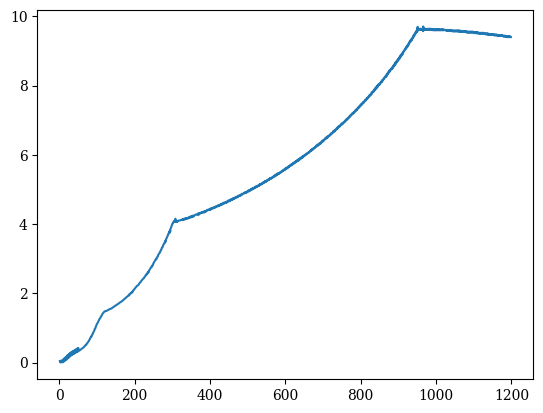

In [41]:
# plt.plot(time_vel_new, vel_new);
# plt.plot(time_vel, vel);
plt.plot(t_vel, v);

In [42]:
raw = """
-192.56529348411414, 546.0060571746799
-192.7504038772213, 544.3088463626804
-192.7504038772213, 542.9512239298209
-192.7504038772213, 541.5936014969616
-192.7504038772213, 540.2359790641021
-192.7504038772213, 538.8783566312428
-192.7504038772213, 537.5207341983834
-192.7504038772213, 536.1631117655239
-192.7504038772213, 534.8054893326646
-192.7504038772213, 533.4478668998051
-192.7504038772213, 532.0902444669458
-192.7504038772213, 530.7326220340864
-192.7504038772213, 529.3749996012269
-192.7504038772213, 528.0173771683676
-192.7504038772213, 526.6597547355082
-192.7504038772213, 525.3021323026487
-192.7504038772213, 523.9445098697894
-192.7504038772213, 522.5868874369299
-192.7504038772213, 521.2292650040706
-192.7504038772213, 519.8716425712112
-192.7504038772213, 518.5140201383517
-192.7504038772213, 517.1563977054924
-192.7504038772213, 515.798775272633
-192.7504038772213, 514.4411528397736
-192.7504038772213, 513.0835304069142
-192.7504038772213, 511.7259079740548
-192.7504038772213, 510.3682855411954
-192.7504038772213, 509.01066310833596
-192.7504038772213, 507.6530406754766
-192.7504038772213, 506.2954182426172
-192.7504038772213, 504.9377958097578
-192.7504038772213, 503.58017337689836
-192.7504038772213, 502.22255094403897
-192.7504038772213, 500.8649285111796
-192.7504038772213, 499.5073060783202
-192.7504038772213, 498.14968364546075
-192.7504038772213, 496.79206121260137
-192.7504038772213, 495.434438779742
-192.7504038772213, 494.0768163468826
-192.7504038772213, 492.7191939140232
-192.7504038772213, 491.36157148116376
-192.7504038772213, 490.0039490483044
-192.7504038772213, 488.646326615445
-192.7504038772213, 487.2887041825856
-192.7504038772213, 485.9310817497262
-192.7504038772213, 484.5734593168668
-192.7504038772213, 483.2158368840074
-192.7504038772213, 481.858214451148
-192.7504038772213, 480.50059201828856
-192.7504038772213, 479.14296958542917
-192.7504038772213, 477.7853471525698
-192.7504038772213, 476.4277247197104
-192.7504038772213, 475.070102286851
-192.7504038772213, 473.71247985399157
-192.7504038772213, 472.3548574211322
-192.7504038772213, 470.9972349882728
-192.7504038772213, 469.6396125554134
-192.7504038772213, 468.281990122554
-192.7504038772213, 466.9243676896946
-192.7504038772213, 465.5667452568352
-192.7504038772213, 464.2091228239758
-192.7504038772213, 462.85150039111636
-192.7504038772213, 461.493877958257
-192.7504038772213, 460.1362555253976
-192.7504038772213, 458.7786330925382
-192.7504038772213, 457.4210106596788
-192.7504038772213, 456.06338822681937
-192.7504038772213, 454.70576579396
-192.7504038772213, 453.3481433611006
-192.7504038772213, 451.9905209282412
-192.7504038772213, 450.6328984953818
-192.7504038772213, 449.2752760625224
-192.7504038772213, 447.917653629663
-192.7504038772213, 446.5600311968036
-192.7504038772213, 445.2024087639442
-192.7504038772213, 443.84478633108483
-192.7504038772213, 442.4871638982254
-192.7504038772213, 441.129541465366
-192.7504038772213, 439.7719190325066
-192.7504038772213, 438.4142965996472
-192.7504038772213, 437.0566741667878
-192.7504038772213, 435.6990517339284
-192.7504038772213, 434.341429301069
-192.7504038772213, 432.9838068682096
-192.7504038772213, 431.6261844353502
-192.7504038772213, 430.2685620024908
-192.7504038772213, 428.9109395696314
-192.7504038772213, 427.553317136772
-192.7504038772213, 426.19569470391264
-192.7504038772213, 424.8380722710532
-192.7504038772213, 423.4804498381938
-192.7504038772213, 422.1228274053344
-192.7504038772213, 420.765204972475
-192.7504038772213, 419.40758253961565
-192.7504038772213, 418.0499601067562
-192.7504038772213, 416.6923376738968
-192.7504038772213, 415.33471524103743
-192.7504038772213, 413.977092808178
-192.7504038772213, 412.6194703753186
-192.7504038772213, 411.2618479424592
-192.7504038772213, 409.90422550959977
-192.7504038772213, 408.54660307674044
-192.7504038772213, 407.188980643881
-192.7504038772213, 405.8313582110216
-192.7504038772213, 404.4737357781622
-192.7504038772213, 403.1161133453028
-192.7504038772213, 401.75849091244345
-192.7504038772213, 400.400868479584
-192.7504038772213, 399.0432460467246
-192.7504038772213, 397.68562361386523
-192.7504038772213, 396.3280011810058
-192.7504038772213, 394.97037874814646
-192.7504038772213, 393.612756315287
-192.7504038772213, 392.25513388242763
-192.7504038772213, 390.89751144956824
-192.7504038772213, 389.5398890167088
-192.7504038772213, 388.1822665838494
-192.7504038772213, 386.82464415099
-192.7504038772213, 385.4670217181306
-192.7504038772213, 384.10939928527125
-192.7504038772213, 382.7517768524118
-192.7504038772213, 381.3941544195524
-192.7504038772213, 380.03653198669303
-192.7504038772213, 378.6789095538336
-192.7504038772213, 377.32128712097426
-192.7504038772213, 375.9636646881148
-192.7504038772213, 374.60604225525543
-192.7504038772213, 373.24841982239604
-192.7504038772213, 371.8907973895366
-192.7504038772213, 370.5331749566772
-192.7504038772213, 369.1755525238178
-192.7504038772213, 367.8179300909584
-192.7504038772213, 366.46030765809905
-192.7504038772213, 365.1026852252396
-192.7504038772213, 363.7450627923802
-192.7504038772213, 362.38744035952084
-192.7504038772213, 361.0298179266614
-192.7504038772213, 359.67219549380206
-192.7504038772213, 358.3145730609426
-192.7504038772213, 356.95695062808323
-192.7504038772213, 355.59932819522385
-192.7504038772213, 354.2417057623644
-192.7504038772213, 352.884083329505
-192.7504038772213, 351.52646089664563
-192.7504038772213, 350.16883846378624
-192.7504038772213, 348.81121603092686
-192.7504038772213, 347.4535935980674
-192.7504038772213, 346.095971165208
-192.7504038772213, 344.73834873234864
-192.7504038772213, 343.3807262994892
-192.7504038772213, 342.02310386662987
-192.7504038772213, 340.6654814337704
-192.7504038772213, 339.30785900091104
-192.7504038772213, 337.95023656805165
-192.7504038772213, 336.5926141351922
-192.7504038772213, 335.2349917023329
-192.7504038772213, 333.87736926947343
-192.7504038772213, 332.51974683661405
-192.7504038772213, 331.16212440375466
-192.7504038772213, 329.8045019708952
-192.7504038772213, 328.44687953803583
-192.7504038772213, 327.08925710517644
-192.7504038772213, 325.731634672317
-192.7504038772213, 324.37401223945767
-192.7504038772213, 323.0163898065982
-192.7504038772213, 321.65876737373884
-192.7504038772213, 320.30114494087945
-192.7504038772213, 318.94352250802
-192.7504038772213, 317.5859000751607
-192.7504038772213, 316.22827764230124
-192.7504038772213, 314.87065520944185
-192.7504038772213, 313.51303277658246
-192.7504038772213, 312.155410343723
-192.7504038772213, 310.79778791086363
-192.7504038772213, 309.44016547800425
-192.7504038772213, 308.08254304514486
-192.7504038772213, 306.7249206122855
-192.7504038772213, 305.36729817942603
-192.7504038772213, 304.00967574656664
-192.7504038772213, 302.65205331370726
-192.7504038772213, 301.2944308808478
-192.7504038772213, 299.9368084479885
-192.7504038772213, 298.57918601512904
-192.7504038772213, 297.22156358226965
-192.7504038772213, 295.86394114941027
-192.7504038772213, 294.5063187165509
-192.7504038772213, 293.1486962836915
-192.7504038772213, 291.7910738508321
-192.7504038772213, 290.43345141797266
-192.7504038772213, 289.0758289851133
-192.7504038772213, 287.7182065522539
-192.7504038772213, 286.3605841193945
-192.7504038772213, 285.00296168653506
-192.7504038772213, 283.6453392536757
-192.7504038772213, 282.2877168208163
-192.7504038772213, 280.9300943879569
-192.7504038772213, 279.57247195509746
-192.7504038772213, 278.21484952223807
-192.7504038772213, 276.8572270893787
-192.7504038772213, 275.4996046565193
-192.7504038772213, 274.1419822236599
-192.7504038772213, 272.78435979080047
-192.7504038772213, 271.4267373579411
-192.7504038772213, 270.0691149250817
-192.7504038772213, 268.7114924922223
-192.7504038772213, 267.35387005936286
-192.7504038772213, 265.9962476265035
-192.7504038772213, 264.6386251936441
-192.7504038772213, 263.2810027607847
-192.7504038772213, 261.9233803279253
-192.7504038772213, 260.5657578950659
-192.7504038772213, 259.2081354622065
-192.7504038772213, 257.8505130293471
-192.7504038772213, 256.4928905964877
-192.7504038772213, 255.13526816362827
-192.7504038772213, 253.77764573076888
-192.7504038772213, 252.4200232979095
-192.7504038772213, 251.0624008650501
-192.7504038772213, 249.70477843219072
-192.7504038772213, 248.34715599933128
-192.7504038772213, 246.9895335664719
-192.7504038772213, 245.6319111336125
-192.7504038772213, 244.27428870075312
-192.7504038772213, 242.91666626789367
-192.7504038772213, 241.5590438350343
-192.7504038772213, 240.2014214021749
-192.7504038772213, 238.84379896931551
-192.7504038772213, 237.48617653645607
-192.7504038772213, 236.12855410359668
-192.7504038772213, 234.7709316707373
-192.7504038772213, 233.4133092378779
-192.7504038772213, 232.05568680501852
-192.7504038772213, 230.69806437215908
-192.7504038772213, 229.3404419392997
-192.7504038772213, 227.9828195064403
-192.7504038772213, 226.62519707358092
-192.7504038772213, 225.26757464072148
-192.7504038772213, 223.9099522078621
-192.7504038772213, 222.5523297750027
-192.7504038772213, 221.19470734214332
-192.7504038772213, 219.83708490928393
-192.7504038772213, 218.4794624764245
-192.7504038772213, 217.1218400435651
-192.7504038772213, 215.7642176107057
-192.7504038772213, 214.40659517784633
-192.7504038772213, 213.04897274498688
-192.7504038772213, 211.6913503121275
-192.7504038772213, 210.3337278792681
-192.7504038772213, 208.97610544640872
-192.7504038772213, 207.61848301354928
-192.7504038772213, 206.2608605806899
-192.7504038772213, 204.9032381478305
-192.7504038772213, 203.54561571497112
-192.7504038772213, 202.18799328211173
-192.7504038772213, 200.8303708492523
-192.7504038772213, 199.4727484163929
-192.7504038772213, 198.11512598353352
-192.7504038772213, 196.75750355067413
-192.7504038772213, 195.3998811178147
-192.7504038772213, 194.0422586849553
-192.7504038772213, 192.6846362520959
-192.7504038772213, 191.32701381923653
-192.7504038772213, 189.96939138637714
-192.7504038772213, 188.6117689535177
-192.7504038772213, 187.2541465206583
-192.7504038772213, 185.89652408779892
-192.7504038772213, 184.53890165493954
-192.7504038772213, 183.1812792220801
-192.7504038772213, 181.8236567892207
-192.7504038772213, 180.46603435636132
-192.7504038772213, 179.10841192350193
-192.7504038772213, 177.75078949064255
-192.7504038772213, 176.3931670577831
-192.7504038772213, 175.03554462492372
-192.7504038772213, 173.67792219206433
-192.7504038772213, 172.32029975920494
-192.7504038772213, 170.9626773263455
-192.7504038772213, 169.6050548934861
-192.7504038772213, 168.24743246062673
-192.7504038772213, 166.88981002776734
-192.7504038772213, 165.5321875949079
-192.7504038772213, 164.1745651620485
-192.7504038772213, 162.81694272918912
-192.7504038772213, 161.45932029632974
-192.7504038772213, 160.10169786347035
-192.7504038772213, 158.7440754306109
-192.7504038772213, 157.38645299775152
-192.7504038772213, 156.02883056489213
-192.7504038772213, 154.67120813203275
-192.7504038772213, 153.3135856991733
-192.7504038772213, 151.95596326631392
-192.7504038772213, 150.59834083345453
-192.7504038772213, 149.24071840059514
-192.7504038772213, 147.88309596773576
-192.7504038772213, 146.5254735348763
-192.7504038772213, 145.16785110201693
-192.7504038772213, 143.81022866915754
-192.7504038772213, 142.45260623629815
-192.7504038772213, 141.0949838034387
-192.7504038772213, 139.73736137057932
-192.7504038772213, 138.37973893771994
-192.7504038772213, 137.02211650486055
-192.7504038772213, 135.6644940720011
-192.7504038772213, 134.30687163914172
-192.7504038772213, 132.94924920628233
-192.7504038772213, 131.59162677342295
-192.7504038772213, 130.23400434056356
-192.7504038772213, 128.87638190770411
-192.7504038772213, 127.51875947484473
-192.7504038772213, 126.16113704198534
-192.7504038772213, 124.80351460912595
-192.7504038772213, 123.44589217626651
-192.7504038772213, 122.08826974340712
-192.7504038772213, 120.73064731054774
-192.7504038772213, 119.37302487768835
-192.7504038772213, 118.01540244482896
-192.7504038772213, 116.65778001196952
-192.7504038772213, 115.30015757911013
-192.7504038772213, 113.94253514625075
-192.7504038772213, 112.58491271339136
-192.7504038772213, 111.22729028053192
-192.7504038772213, 109.86966784767253
-192.7504038772213, 108.51204541481314
-192.7504038772213, 107.15442298195376
-192.7504038772213, 105.79680054909431
-192.7504038772213, 104.43917811623493
-192.7504038772213, 103.08155568337554
-192.7504038772213, 101.72393325051615
-192.7504038772213, 100.36631081765677
-192.7504038772213, 99.00868838479732
-192.7504038772213, 97.65106595193794
-192.7504038772213, 96.29344351907855
-192.7504038772213, 94.93582108621916
-192.7504038772213, 93.57819865335972
-192.7504038772213, 92.22057622050033
-192.7504038772213, 90.86295378764095
-192.7504038772213, 89.50533135478156
-192.7504038772213, 88.14770892192217
-192.7504038772213, 86.79008648906273
-192.7504038772213, 85.43246405620334
-192.7504038772213, 84.07484162334396
-192.7504038772213, 82.71721919048457
-192.7504038772213, 81.35959675762513
-192.7504038772213, 80.00197432476574
-192.7504038772213, 78.64435189190635
-192.7504038772213, 77.28672945904697
-192.7504038772213, 75.92910702618758
-192.7504038772213, 74.57148459332814
-192.7504038772213, 73.21386216046875
-192.7504038772213, 71.85623972760936
-192.7504038772213, 70.49861729474998
-192.7504038772213, 69.14099486189053
-192.7504038772213, 67.78337242903115
-192.7504038772213, 66.42574999617176
-192.7504038772213, 65.06812756331237
-192.7504038772213, 63.71050513045293
-192.7504038772213, 62.35288269759354
-192.7504038772213, 60.995260264734156
-192.7504038772213, 59.63763783187477
-192.7504038772213, 58.28001539901538
-192.7504038772213, 56.92239296615594
-192.7504038772213, 55.56477053329655
-192.7504038772213, 54.207148100437166
-192.7504038772213, 52.84952566757778
-192.7504038772213, 51.491903234718336
-192.7504038772213, 50.13428080185895
-192.7504038772213, 48.77665836899956
-192.7504038772213, 47.419035936140176
-192.7504038772213, 46.06141350328079
-192.7504038772213, 44.703791070421346
-192.7504038772213, 43.34616863756196
-192.7504038772213, 41.98854620470257
-192.7504038772213, 40.630923771843186
-192.7504038772213, 39.27330133898374
-192.7504038772213, 37.9156789061243
-192.7504038772213, 36.558056473264855
-192.7504038772213, 35.200434040405526
-192.7504038772213, 33.84281160754608
-192.7504038772213, 32.48518917468675
-192.7504038772213, 31.12756674182731
-192.7504038772213, 29.769944308967865
-192.7504038772213, 28.412321876108535
-192.7504038772213, 27.054699443249092
-192.7504038772213, 25.697077010389762
-192.7504038772213, 24.33945457753032
-192.7504038772213, 22.981832144670875
-192.7504038772213, 21.624209711811545
-192.7504038772213, 20.2665872789521
-192.7504038772213, 18.90896484609266
-192.7504038772213, 17.55134241323333
-192.7504038772213, 16.193719980373885
-192.7504038772213, 14.836097547514555
-192.7504038772213, 13.478475114655112
-192.7504038772213, 12.120852681795668
-192.7504038772213, 10.763230248936338
-192.7504038772213, 9.405607816076895
-192.7504038772213, 8.047985383217565
-192.7504038772213, 6.6903629503581215
-192.7504038772213, 5.332740517498678
-192.7504038772213, 3.975118084639348
-192.7504038772213, 2.6174956517799046
-192.7504038772213, 1.2598732189205748
-192.7504038772213, -0.0977492139388687
-192.7504038772213, -1.4553716467983122
-192.7504038772213, -2.812994079657642
-192.7504038772213, -4.1706165125170855
-192.7504038772213, -5.528238945376529
-192.7504038772213, -6.885861378235859
-192.7504038772213, -8.243483811095302
-192.7504038772213, -9.601106243954632
-192.7504038772213, -10.958728676814076
-192.7504038772213, -12.31635110967352
-192.7504038772213, -13.673973542532849
-192.7504038772213, -15.031595975392293
-192.7504038772213, -16.389218408251622
-192.7504038772213, -17.746840841111066
-192.7504038772213, -19.10446327397051
-192.7504038772213, -20.46208570682984
-192.7504038772213, -21.819708139689283
-192.7504038772213, -23.177330572548726
-192.7504038772213, -24.534953005408056
-192.7504038772213, -25.8925754382675
-192.7504038772213, -27.25019787112683
-192.7504038772213, -28.607820303986273
-192.7504038772213, -29.965442736845716
-192.7504038772213, -31.323065169705046
-192.7504038772213, -32.68068760256449
-192.7504038772213, -34.03831003542382
-192.7504038772213, -35.39593246828326
-192.7504038772213, -36.75355490114271
-192.7504038772213, -38.111177334002036
-192.7504038772213, -39.46879976686148
-192.7504038772213, -40.82642219972081
-192.7504038772213, -42.18404463258025
-192.7504038772213, -43.5416670654397
-192.7504038772213, -44.89928949829903
-192.7504038772213, -46.25691193115847
-192.7504038772213, -47.61453436401791
-192.7504038772213, -48.97215679687724
-192.7504038772213, -50.32977922973669
-192.7504038772213, -51.68740166259602
-192.7504038772213, -53.04502409545546
-192.7504038772213, -54.402646528314904
-192.7504038772213, -55.76026896117423
-192.7504038772213, -57.11789139403368
-192.7504038772213, -58.47551382689301
-192.7504038772213, -59.83313625975245
-192.7504038772213, -60.85135308439703
-190.34396876682817, 547.3658728586424
-190.52907915993535, 545.6686620466429
-190.52907915993535, 544.3110396137836
-190.52907915993535, 542.9534171809241
-190.52907915993535, 541.5957947480647
-190.52907915993535, 540.2381723152054
-190.52907915993535, 538.8805498823459
-190.52907915993535, 537.5229274494866
-190.52907915993535, 536.1653050166271
-190.52907915993535, 534.8076825837677
-190.52907915993535, 533.4500601509084
-190.52907915993535, 532.0924377180489
-190.52907915993535, 530.7348152851895
-190.52907915993535, 529.3771928523302
-190.52907915993535, 528.0195704194707
-190.52907915993535, 526.6619479866114
-190.52907915993535, 525.3043255537519
-190.52907915993535, 523.9467031208925
-190.52907915993535, 522.5890806880332
-190.52907915993535, 521.2314582551737
-190.52907915993535, 519.8738358223144
-190.52907915993535, 518.516213389455
-190.52907915993535, 517.1585909565955
-190.52907915993535, 515.8009685237362
-190.52907915993535, 514.4433460908767
-190.52907915993535, 513.0857236580173
-190.52907915993535, 511.72810122515796
-190.52907915993535, 510.3704787922985
-190.52907915993535, 509.0128563594391
-190.52907915993535, 507.65523392657974
-190.52907915993535, 506.29761149372035
-190.52907915993535, 504.93998906086097
-190.52907915993535, 503.5823666280015
-190.52907915993535, 502.22474419514214
-190.52907915993535, 500.86712176228275
-190.52907915993535, 499.50949932942336
-190.52907915993535, 498.151876896564
-190.52907915993535, 496.79425446370453
-190.52907915993535, 495.43663203084515
-190.52907915993535, 494.07900959798576
-190.52907915993535, 492.7213871651264
-190.52907915993535, 491.36376473226693
-190.52907915993535, 490.00614229940754
-190.52907915993535, 488.64851986654816
-190.52907915993535, 487.29089743368877
-190.52907915993535, 485.9332750008293
-190.52907915993535, 484.57565256796994
-190.52907915993535, 483.21803013511055
-190.52907915993535, 481.86040770225117
-190.52907915993535, 480.5027852693918
-190.52907915993535, 479.14516283653234
-190.52907915993535, 477.78754040367295
-190.52907915993535, 476.42991797081356
-190.52907915993535, 475.0722955379541
-190.52907915993535, 473.7146731050948
-190.52907915993535, 472.35705067223535
-190.52907915993535, 470.99942823937596
-190.52907915993535, 469.6418058065166
-190.52907915993535, 468.28418337365713
-190.52907915993535, 466.92656094079774
-190.52907915993535, 465.56893850793836
-190.52907915993535, 464.21131607507897
-190.52907915993535, 462.8536936422196
-190.52907915993535, 461.49607120936014
-190.52907915993535, 460.13844877650075
-190.52907915993535, 458.78082634364137
-190.52907915993535, 457.423203910782
-190.52907915993535, 456.0655814779226
-190.52907915993535, 454.70795904506315
-190.52907915993535, 453.35033661220376
-190.52907915993535, 451.9927141793444
-190.52907915993535, 450.63509174648493
-190.52907915993535, 449.27746931362555
-190.52907915993535, 447.91984688076616
-190.52907915993535, 446.5622244479068
-190.52907915993535, 445.2046020150474
-190.52907915993535, 443.84697958218794
-190.52907915993535, 442.48935714932855
-190.52907915993535, 441.13173471646917
-190.52907915993535, 439.7741122836098
-190.52907915993535, 438.4164898507504
-190.52907915993535, 437.05886741789095
-190.52907915993535, 435.70124498503156
-190.52907915993535, 434.3436225521722
-190.52907915993535, 432.98600011931273
-190.52907915993535, 431.62837768645335
-190.52907915993535, 430.27075525359396
-190.52907915993535, 428.9131328207346
-190.52907915993535, 427.5555103878752
-190.52907915993535, 426.19788795501574
-190.52907915993535, 424.84026552215636
-190.52907915993535, 423.48264308929697
-190.52907915993535, 422.1250206564376
-190.52907915993535, 420.7673982235782
-190.52907915993535, 419.40977579071875
-190.52907915993535, 418.05215335785937
-190.52907915993535, 416.694530925
-190.52907915993535, 415.33690849214054
-190.52907915993535, 413.9792860592812
-190.52907915993535, 412.62166362642176
-190.52907915993535, 411.2640411935624
-190.52907915993535, 409.906418760703
-190.52907915993535, 408.54879632784355
-190.52907915993535, 407.1911738949842
-190.52907915993535, 405.8335514621248
-190.52907915993535, 404.4759290292654
-190.52907915993535, 403.118306596406
-190.52907915993535, 401.76068416354656
-190.52907915993535, 400.40306173068717
-190.52907915993535, 399.0454392978278
-190.52907915993535, 397.68781686496834
-190.52907915993535, 396.330194432109
-190.52907915993535, 394.97257199924957
-190.52907915993535, 393.6149495663902
-190.52907915993535, 392.2573271335308
-190.52907915993535, 390.89970470067135
-190.52907915993535, 389.542082267812
-190.52907915993535, 388.1844598349526
-190.52907915993535, 386.8268374020932
-190.52907915993535, 385.4692149692338
-190.52907915993535, 384.11159253637436
-190.52907915993535, 382.753970103515
-190.52907915993535, 381.3963476706556
-190.52907915993535, 380.0387252377962
-190.52907915993535, 378.6811028049368
-190.52907915993535, 377.32348037207737
-190.52907915993535, 375.965857939218
-190.52907915993535, 374.6082355063586
-190.52907915993535, 373.25061307349915
-190.52907915993535, 371.8929906406398
-190.52907915993535, 370.5353682077804
-190.52907915993535, 369.177745774921
-190.52907915993535, 367.8201233420616
-190.52907915993535, 366.46250090920216
-190.52907915993535, 365.10487847634283
-190.52907915993535, 363.7472560434834
-190.52907915993535, 362.389633610624
-190.52907915993535, 361.0320111777646
-190.52907915993535, 359.6743887449052
-190.52907915993535, 358.3167663120458
-190.52907915993535, 356.9591438791864
-190.52907915993535, 355.60152144632696
-190.52907915993535, 354.2438990134676
-190.52907915993535, 352.8862765806082
-190.52907915993535, 351.5286541477488
-190.52907915993535, 350.1710317148894
-190.52907915993535, 348.81340928202997
-190.52907915993535, 347.45578684917064
-190.52907915993535, 346.0981644163112
-190.52907915993535, 344.7405419834518
-190.52907915993535, 343.3829195505924
-190.52907915993535, 342.025297117733
-190.52907915993535, 340.6676746848736
-190.52907915993535, 339.3100522520142
-190.52907915993535, 337.95242981915476
-190.52907915993535, 336.59480738629543
-190.52907915993535, 335.237184953436
-190.52907915993535, 333.8795625205766
-190.52907915993535, 332.5219400877172
-190.52907915993535, 331.16431765485777
-190.52907915993535, 329.80669522199844
-190.52907915993535, 328.449072789139
-190.52907915993535, 327.0914503562796
-190.52907915993535, 325.7338279234202
-190.52907915993535, 324.3762054905608
-190.52907915993535, 323.0185830577014
-190.52907915993535, 321.660960624842
-190.52907915993535, 320.3033381919826
-190.52907915993535, 318.94571575912323
-190.52907915993535, 317.5880933262638
-190.52907915993535, 316.2304708934044
-190.52907915993535, 314.872848460545
-190.52907915993535, 313.51522602768557
-190.52907915993535, 312.15760359482624
-190.52907915993535, 310.7999811619668
-190.52907915993535, 309.4423587291074
-190.52907915993535, 308.084736296248
-190.52907915993535, 306.7271138633886
-190.52907915993535, 305.36949143052925
-190.52907915993535, 304.0118689976698
-190.52907915993535, 302.6542465648104
-190.52907915993535, 301.29662413195103
-190.52907915993535, 299.9390016990916
-190.52907915993535, 298.5813792662322
-190.52907915993535, 297.2237568333728
-190.52907915993535, 295.8661344005134
-190.52907915993535, 294.50851196765404
-190.52907915993535, 293.15088953479466
-190.52907915993535, 291.79326710193527
-190.52907915993535, 290.4356446690758
-190.52907915993535, 289.07802223621644
-190.52907915993535, 287.72039980335705
-190.52907915993535, 286.36277737049767
-190.52907915993535, 285.0051549376382
-190.52907915993535, 283.64753250477884
-190.52907915993535, 282.28991007191945
-190.52907915993535, 280.93228763906006
-190.52907915993535, 279.5746652062006
-190.52907915993535, 278.21704277334123
-190.52907915993535, 276.85942034048185
-190.52907915993535, 275.50179790762246
-190.52907915993535, 274.1441754747631
-190.52907915993535, 272.78655304190363
-190.52907915993535, 271.42893060904424
-190.52907915993535, 270.07130817618486
-190.52907915993535, 268.71368574332547
-190.52907915993535, 267.356063310466
-190.52907915993535, 265.99844087760664
-190.52907915993535, 264.64081844474725
-190.52907915993535, 263.28319601188787
-190.52907915993535, 261.9255735790285
-190.52907915993535, 260.56795114616904
-190.52907915993535, 259.21032871330965
-190.52907915993535, 257.85270628045026
-190.52907915993535, 256.4950838475909
-190.52907915993535, 255.13746141473143
-190.52907915993535, 253.77983898187205
-190.52907915993535, 252.42221654901266
-190.52907915993535, 251.06459411615327
-190.52907915993535, 249.7069716832939
-190.52907915993535, 248.34934925043444
-190.52907915993535, 246.99172681757506
-190.52907915993535, 245.63410438471567
-190.52907915993535, 244.27648195185628
-190.52907915993535, 242.91885951899684
-190.52907915993535, 241.56123708613745
-190.52907915993535, 240.20361465327807
-190.52907915993535, 238.84599222041868
-190.52907915993535, 237.48836978755924
-190.52907915993535, 236.13074735469985
-190.52907915993535, 234.77312492184046
-190.52907915993535, 233.41550248898108
-190.52907915993535, 232.0578800561217
-190.52907915993535, 230.70025762326225
-190.52907915993535, 229.34263519040286
-190.52907915993535, 227.98501275754347
-190.52907915993535, 226.6273903246841
-190.52907915993535, 225.26976789182464
-190.52907915993535, 223.91214545896526
-190.52907915993535, 222.55452302610587
-190.52907915993535, 221.19690059324648
-190.52907915993535, 219.8392781603871
-190.52907915993535, 218.48165572752765
-190.52907915993535, 217.12403329466827
-190.52907915993535, 215.76641086180888
-190.52907915993535, 214.4087884289495
-190.52907915993535, 213.05116599609005
-190.52907915993535, 211.69354356323066
-190.52907915993535, 210.33592113037128
-190.52907915993535, 208.9782986975119
-190.52907915993535, 207.62067626465245
-190.52907915993535, 206.26305383179306
-190.52907915993535, 204.90543139893367
-190.52907915993535, 203.54780896607429
-190.52907915993535, 202.1901865332149
-190.52907915993535, 200.83256410035546
-190.52907915993535, 199.47494166749607
-190.52907915993535, 198.11731923463668
-190.52907915993535, 196.7596968017773
-190.52907915993535, 195.40207436891785
-190.52907915993535, 194.04445193605846
-190.52907915993535, 192.68682950319908
-190.52907915993535, 191.3292070703397
-190.52907915993535, 189.9715846374803
-190.52907915993535, 188.61396220462086
-190.52907915993535, 187.25633977176147
-190.52907915993535, 185.8987173389021
-190.52907915993535, 184.5410949060427
-190.52907915993535, 183.18347247318326
-190.52907915993535, 181.82585004032387
-190.52907915993535, 180.46822760746448
-190.52907915993535, 179.1106051746051
-190.52907915993535, 177.7529827417457
-190.52907915993535, 176.39536030888627
-190.52907915993535, 175.03773787602688
-190.52907915993535, 173.6801154431675
-190.52907915993535, 172.3224930103081
-190.52907915993535, 170.96487057744866
-190.52907915993535, 169.60724814458928
-190.52907915993535, 168.2496257117299
-190.52907915993535, 166.8920032788705
-190.52907915993535, 165.53438084601106
-190.52907915993535, 164.17675841315167
-190.52907915993535, 162.8191359802923
-190.52907915993535, 161.4615135474329
-190.52907915993535, 160.1038911145735
-190.52907915993535, 158.74626868171407
-190.52907915993535, 157.38864624885468
-190.52907915993535, 156.0310238159953
-190.52907915993535, 154.6734013831359
-190.52907915993535, 153.31577895027647
-190.52907915993535, 151.95815651741708
-190.52907915993535, 150.6005340845577
-190.52907915993535, 149.2429116516983
-190.52907915993535, 147.88528921883892
-190.52907915993535, 146.52766678597948
-190.52907915993535, 145.1700443531201
-190.52907915993535, 143.8124219202607
-190.52907915993535, 142.45479948740132
-190.52907915993535, 141.09717705454187
-190.52907915993535, 139.7395546216825
-190.52907915993535, 138.3819321888231
-190.52907915993535, 137.0243097559637
-190.52907915993535, 135.66668732310427
-190.52907915993535, 134.30906489024488
-190.52907915993535, 132.9514424573855
-190.52907915993535, 131.5938200245261
-190.52907915993535, 130.23619759166672
-190.52907915993535, 128.87857515880728
-190.52907915993535, 127.5209527259479
-190.52907915993535, 126.1633302930885
-190.52907915993535, 124.80570786022912
-190.52907915993535, 123.44808542736968
-190.52907915993535, 122.09046299451029
-190.52907915993535, 120.7328405616509
-190.52907915993535, 119.37521812879152
-190.52907915993535, 118.01759569593213
-190.52907915993535, 116.65997326307269
-190.52907915993535, 115.3023508302133
-190.52907915993535, 113.94472839735391
-190.52907915993535, 112.58710596449453
-190.52907915993535, 111.22948353163508
-190.52907915993535, 109.8718610987757
-190.52907915993535, 108.51423866591631
-190.52907915993535, 107.15661623305692
-190.52907915993535, 105.79899380019748
-190.52907915993535, 104.44137136733809
-190.52907915993535, 103.0837489344787
-190.52907915993535, 101.72612650161932
-190.52907915993535, 100.36850406875993
-190.52907915993535, 99.01088163590049
-190.52907915993535, 97.6532592030411
-190.52907915993535, 96.29563677018172
-190.52907915993535, 94.93801433732233
-190.52907915993535, 93.58039190446289
-190.52907915993535, 92.2227694716035
-190.52907915993535, 90.86514703874411
-190.52907915993535, 89.50752460588473
-190.52907915993535, 88.14990217302534
-190.52907915993535, 86.7922797401659
-190.52907915993535, 85.43465730730651
-190.52907915993535, 84.07703487444712
-190.52907915993535, 82.71941244158774
-190.52907915993535, 81.36179000872829
-190.52907915993535, 80.0041675758689
-190.52907915993535, 78.64654514300952
-190.52907915993535, 77.28892271015013
-190.52907915993535, 75.93130027729075
-190.52907915993535, 74.5736778444313
-190.52907915993535, 73.21605541157192
-190.52907915993535, 71.85843297871253
-190.52907915993535, 70.50081054585314
-190.52907915993535, 69.1431881129937
-190.52907915993535, 67.78556568013431
-190.52907915993535, 66.42794324727492
-190.52907915993535, 65.07032081441554
-190.52907915993535, 63.712698381556095
-190.52907915993535, 62.35507594869671
-190.52907915993535, 60.99745351583732
-190.52907915993535, 59.639831082977935
-190.52907915993535, 58.28220865011855
-190.52907915993535, 56.924586217259105
-190.52907915993535, 55.56696378439972
-190.52907915993535, 54.20934135154033
-190.52907915993535, 52.851718918680945
-190.52907915993535, 51.4940964858215
-190.52907915993535, 50.136474052962114
-190.52907915993535, 48.77885162010273
-190.52907915993535, 47.42122918724334
-190.52907915993535, 46.063606754383954
-190.52907915993535, 44.70598432152451
-190.52907915993535, 43.348361888665124
-190.52907915993535, 41.99073945580574
-190.52907915993535, 40.63311702294635
-190.52907915993535, 39.27549459008691
-190.52907915993535, 37.91787215722752
-190.52907915993535, 36.56024972436808
-190.52907915993535, 35.20262729150875
-190.52907915993535, 33.845004858649304
-190.52907915993535, 32.487382425789974
-190.52907915993535, 31.12975999293053
-190.52907915993535, 29.772137560071087
-190.52907915993535, 28.414515127211757
-190.52907915993535, 27.056892694352314
-190.52907915993535, 25.699270261492984
-190.52907915993535, 24.34164782863354
-190.52907915993535, 22.984025395774097
-190.52907915993535, 21.626402962914767
-190.52907915993535, 20.268780530055324
-190.52907915993535, 18.91115809719588
-190.52907915993535, 17.55353566433655
-190.52907915993535, 16.195913231477107
-190.52907915993535, 14.838290798617777
-190.52907915993535, 13.480668365758333
-190.52907915993535, 12.12304593289889
-190.52907915993535, 10.76542350003956
-190.52907915993535, 9.407801067180117
-190.52907915993535, 8.050178634320787
-190.52907915993535, 6.692556201461343
-190.52907915993535, 5.3349337686019
-190.52907915993535, 3.97731133574257
-190.52907915993535, 2.6196889028831265
-190.52907915993535, 1.2620664700237967
-190.52907915993535, -0.09555596283564682
-190.52907915993535, -1.4531783956950903
-190.52907915993535, -2.81080082855442
-190.52907915993535, -4.168423261413864
-190.52907915993535, -5.526045694273307
-190.52907915993535, -6.883668127132637
-190.52907915993535, -8.24129055999208
-190.52907915993535, -9.59891299285141
-190.52907915993535, -10.956535425710854
-190.52907915993535, -12.314157858570297
-190.52907915993535, -13.671780291429627
-190.52907915993535, -15.02940272428907
-190.52907915993535, -16.3870251571484
-190.52907915993535, -17.744647590007844
-190.52907915993535, -19.102270022867287
-190.52907915993535, -20.459892455726617
-190.52907915993535, -21.81751488858606
-190.52907915993535, -23.175137321445504
-190.52907915993535, -24.532759754304834
-190.52907915993535, -25.890382187164278
-190.52907915993535, -27.248004620023607
-190.52907915993535, -28.60562705288305
-190.52907915993535, -29.963249485742494
-190.52907915993535, -31.320871918601824
-190.52907915993535, -32.67849435146127
-190.52907915993535, -34.0361167843206
-190.52907915993535, -35.39373921718004
-190.52907915993535, -36.751361650039485
-190.52907915993535, -38.108984082898814
-190.52907915993535, -39.46660651575826
-190.52907915993535, -40.82422894861759
-190.52907915993535, -42.18185138147703
-190.52907915993535, -43.539473814336475
-190.52907915993535, -44.897096247195805
-190.52907915993535, -46.25471868005525
-190.52907915993535, -47.61234111291469
-190.52907915993535, -48.96996354577402
-190.52907915993535, -50.327585978633465
-190.52907915993535, -51.685208411492795
-190.52907915993535, -53.04283084435224
-190.52907915993535, -54.40045327721168
-190.52907915993535, -55.75807571007101
-190.52907915993535, -57.115698142930455
-190.52907915993535, -58.473320575789785
-190.52907915993535, -59.83094300864923
-190.52907915993535, -61.018862637401185
-188.30775444264938, 548.04669455525
-188.30775444264938, 546.8587749264981
-188.86308562197087, -61.18692050318134
-186.08642972536344, 548.7276990227829
-186.08642972536344, 547.3700765899235
-183.8651050080775, 548.7298922738861
-183.8651050080775, 547.3722698410267
-183.8651050080775, 539.2265352438703
-183.8651050080775, 537.8689128110109
-183.8651050080775, 536.5112903781514
-183.8651050080775, 535.1536679452921
-183.8651050080775, 533.7960455124327
-183.8651050080775, 532.4384230795732
-183.8651050080775, 531.0808006467139
-183.8651050080775, 529.7231782138545
-183.8651050080775, 528.3655557809951
-183.8651050080775, 527.0079333481357
-183.8651050080775, 525.6503109152762
-183.8651050080775, 524.2926884824169
-183.8651050080775, 522.9350660495575
-183.8651050080775, 521.5774436166981
-183.8651050080775, 520.3895239879461
-182.56933225632736, 540.5854370732065
-181.64378029079157, 548.7320855249892
-181.64378029079157, 547.3744630921299
-181.4586698976844, 538.550100049469
-181.64378029079157, 536.8528892374695
-181.64378029079157, 535.4952668046101
-181.64378029079157, 534.1376443717508
-181.64378029079157, 532.7800219388913
-181.64378029079157, 531.4223995060319
-181.64378029079157, 530.0647770731725
-181.64378029079157, 528.7071546403131
-181.64378029079157, 527.3495322074536
-181.64378029079157, 525.9919097745943
-181.64378029079157, 524.6342873417349
-181.64378029079157, 523.2766649088755
-181.64378029079157, 521.9190424760161
-181.64378029079157, 520.5614200431567
-181.64378029079157, 519.2037976102973
-180.34800753904142, 541.9452527571691
-180.5331179321486, 540.2480419451696
-179.4224555735056, 548.7342787760924
-179.4224555735056, 547.376656343233
-179.4224555735056, 538.5521105296469
-179.4224555735056, 537.1944880967875
-179.4224555735056, 535.8368656639282
-179.4224555735056, 534.4792432310687
-179.4224555735056, 533.1216207982093
-179.4224555735056, 531.76399836535
-179.4224555735056, 530.4063759324905
-179.4224555735056, 529.0487534996311
-179.4224555735056, 527.6911310667717
-179.4224555735056, 526.3335086339123
-179.4224555735056, 524.975886201053
-179.4224555735056, 523.6182637681935
-179.4224555735056, 522.2606413353341
-179.4224555735056, 520.9030189024747
-179.4224555735056, 519.5453964696153
-179.4224555735056, 518.1877740367559
-178.12668282175548, 542.6262572247019
-178.31179321486263, 540.9290464127024
-178.31179321486263, 539.5714239798431
-178.12668282175548, 517.0577014058499
-177.20113085621966, 548.7364720271955
-177.20113085621966, 547.3788495943362
-177.20113085621966, 537.8754925643203
-177.20113085621966, 536.517870131461
-177.20113085621966, 535.1602476986016
-177.20113085621966, 533.8026252657422
-177.20113085621966, 532.4450028328828
-177.20113085621966, 531.0873804000233
-177.20113085621966, 529.729757967164
-177.20113085621966, 528.3721355343046
-177.20113085621966, 527.0145131014452
-177.20113085621966, 525.6568906685858
-177.20113085621966, 524.2992682357263
-177.20113085621966, 522.941645802867
-177.20113085621966, 521.5840233700076
-177.20113085621966, 520.2264009371481
-177.20113085621966, 518.8687785042888
-176.0904684975767, 543.3070789213095
-176.0904684975767, 541.9494564884502
-176.0904684975767, 540.5918340555908
-176.0904684975767, 539.2342116227313
-176.0904684975767, 517.512252696981
-176.0904684975767, 516.4940358723364
-174.97980613893372, 548.7386652782988
-174.97980613893372, 547.3810428454393
-174.97980613893372, 537.8776858154235
-174.97980613893372, 536.5200633825641
-174.97980613893372, 535.1624409497048
-174.97980613893372, 533.8048185168453
-174.97980613893372, 532.447196083986
-174.97980613893372, 531.0895736511266
-174.97980613893372, 529.7319512182671
-174.97980613893372, 528.3743287854078
-174.97980613893372, 527.0167063525483
-174.97980613893372, 525.6590839196889
-174.97980613893372, 524.3014614868296
-174.97980613893372, 522.9438390539701
-174.97980613893372, 521.5862166211108
-174.97980613893372, 520.2285941882513
-174.97980613893372, 518.8709717553919
-173.86914378029076, 543.3092721724128
-173.86914378029076, 541.9516497395533
-173.86914378029076, 540.5940273066939
-173.86914378029076, 539.2364048738345
-173.86914378029076, 517.5144459480841
-173.86914378029076, 516.4962291234395
-172.7584814216478, 548.7408585294019
-172.7584814216478, 547.3832360965425
-172.7584814216478, 537.8798790665267
-172.7584814216478, 536.5222566336673
-172.7584814216478, 535.1646342008079
-172.7584814216478, 533.8070117679486
-172.7584814216478, 532.4493893350891
-172.7584814216478, 531.0917669022297
-172.7584814216478, 529.7341444693703
-172.7584814216478, 528.3765220365109
-172.7584814216478, 527.0188996036516
-172.7584814216478, 525.6612771707921
-172.7584814216478, 524.3036547379327
-172.7584814216478, 522.9460323050733
-172.7584814216478, 521.5884098722139
-172.7584814216478, 520.2307874393545
-172.7584814216478, 518.8731650064951
-171.64781906300482, 543.3114654235159
-171.64781906300482, 541.9538429906565
-171.64781906300482, 540.5962205577971
-171.64781906300482, 539.2385981249377
-171.64781906300482, 517.5166391991874
-171.64781906300482, 516.4984223745428
-170.53715670436185, 548.7430517805051
-170.53715670436185, 547.3854293476456
-170.53715670436185, 537.8820723176299
-170.53715670436185, 536.5244498847704
-170.53715670436185, 535.1668274519111
-170.53715670436185, 533.8092050190517
-170.53715670436185, 532.4515825861922
-170.53715670436185, 531.0939601533329
-170.53715670436185, 529.7363377204734
-170.53715670436185, 528.3787152876141
-170.53715670436185, 527.0210928547547
-170.53715670436185, 525.6634704218952
-170.53715670436185, 524.3058479890359
-170.53715670436185, 522.9482255561765
-170.53715670436185, 521.5906031233171
-170.53715670436185, 520.2329806904577
-170.53715670436185, 518.8753582575982
-169.42649434571885, 543.3136586746191
-169.42649434571885, 541.9560362417596
-169.42649434571885, 540.5984138089002
-169.42649434571885, 539.2407913760409
-169.42649434571885, 517.5188324502905
-169.42649434571885, 516.5006156256459
-168.31583198707588, 548.7452450316082
-168.31583198707588, 547.5573254028562
-168.13072159396873, 537.8844483396583
-168.31583198707588, 536.1872375276588
-168.31583198707588, 534.8296150947994
-168.31583198707588, 533.47199266194
-168.31583198707588, 532.1143702290806
-168.31583198707588, 530.7567477962211
-168.31583198707588, 529.3991253633618
-168.31583198707588, 528.0415029305024
-168.31583198707588, 526.683880497643
-168.31583198707588, 525.3262580647836
-168.31583198707588, 523.9686356319241
-168.31583198707588, 522.6110131990648
-168.31583198707588, 521.2533907662054
-168.31583198707588, 519.895768333346
-168.31583198707588, 518.5381459004866
-167.2051696284329, 543.9946631421519
-167.2051696284329, 542.6370407092925
-167.2051696284329, 541.2794182764331
-167.2051696284329, 539.9217958435737
-167.2051696284329, 516.842214484964
-166.09450726978994, 548.7474382827114
-166.09450726978994, 547.7292214580668
-166.09450726978994, 538.5652700362659
-166.09450726978994, 537.2076476034065
-166.09450726978994, 535.8500251705472
-166.09450726978994, 534.4924027376877
-166.09450726978994, 533.1347803048283
-166.09450726978994, 531.7771578719689
-166.09450726978994, 530.4195354391095
-166.09450726978994, 529.06191300625
-166.09450726978994, 527.7042905733907
-166.09450726978994, 526.3466681405313
-166.09450726978994, 524.989045707672
-166.09450726978994, 523.6314232748125
-166.09450726978994, 522.2738008419531
-166.09450726978994, 520.9161784090937
-166.09450726978994, 519.5585559762343
-166.09450726978994, 518.200933543375
-164.98384491114697, 543.6574507850403
-164.98384491114697, 542.2998283521808
-164.98384491114697, 540.9422059193214
-164.98384491114697, 539.5845834864621
-164.7987345180398, 516.9577257097307
-163.873182552504, 548.7496315338145
-163.873182552504, 547.3920091009552
-163.68807215939682, 537.8888348418647
-163.873182552504, 536.1916240298651
-163.873182552504, 534.8340015970057
-163.873182552504, 533.4763791641464
-163.873182552504, 532.1187567312869
-163.873182552504, 530.7611342984276
-163.873182552504, 529.4035118655681
-163.873182552504, 528.0458894327087
-163.873182552504, 526.6882669998494
-163.873182552504, 525.3306445669899
-163.873182552504, 523.9730221341305
-163.873182552504, 522.6153997012711
-163.873182552504, 521.2577772684117
-163.873182552504, 519.9001548355524
-163.873182552504, 518.5425324026929
-162.76252019386104, 543.9990496443583
-162.76252019386104, 542.6414272114988
-162.76252019386104, 541.2838047786395
-162.76252019386104, 539.92618234578
-162.76252019386104, 516.8466009871703
-161.65185783521804, 548.7518247849177
-161.65185783521804, 547.3942023520583
-161.65185783521804, 538.5696565384723
-161.65185783521804, 537.2120341056128
-161.65185783521804, 535.8544116727535
-161.65185783521804, 534.496789239894
-161.65185783521804, 533.1391668070346
-161.65185783521804, 531.7815443741753
-161.65185783521804, 530.4239219413158
-161.65185783521804, 529.0662995084565
-161.65185783521804, 527.708677075597
-161.65185783521804, 526.3510546427376
-161.65185783521804, 524.9934322098783
-161.65185783521804, 523.6358097770188
-161.65185783521804, 522.2781873441594
-161.65185783521804, 520.9205649113001
-161.65185783521804, 519.5629424784406
-161.65185783521804, 518.2053200455813
-160.54119547657507, 543.6618372872466
-160.54119547657507, 542.3042148543872
-160.54119547657507, 540.9465924215277
-160.54119547657507, 539.5889699886684
-160.35608508346792, 516.962112211937
-159.4305331179321, 548.7540180360209
-159.4305331179321, 547.7358012113764
-159.4305331179321, 537.8930385731456
-159.4305331179321, 536.5354161402863
-159.4305331179321, 535.1777937074269
-159.4305331179321, 533.8201712745675
-159.4305331179321, 532.4625488417081
-159.4305331179321, 531.1049264088487
-159.4305331179321, 529.7473039759893
-159.4305331179321, 528.3896815431299
-159.4305331179321, 527.0320591102706
-159.4305331179321, 525.6744366774111
-159.4305331179321, 524.3168142445517
-159.4305331179321, 522.9591918116923
-159.4305331179321, 521.6015693788329
-159.4305331179321, 520.2439469459734
-159.4305331179321, 518.8863245131141
-158.31987075928913, 543.3246249301349
-158.31987075928913, 541.9670024972755
-158.31987075928913, 540.6093800644161
-158.31987075928913, 539.2517576315566
-158.31987075928913, 517.5297987058063
-158.31987075928913, 516.5115818811618
-157.20920840064616, 548.7562112871241
-157.20920840064616, 547.7379944624795
-157.20920840064616, 537.8952318242489
-157.20920840064616, 536.5376093913894
-157.20920840064616, 535.1799869585301
-157.20920840064616, 533.8223645256707
-157.20920840064616, 532.4647420928113
-157.20920840064616, 531.1071196599519
-157.20920840064616, 529.7494972270924
-157.20920840064616, 528.3918747942331
-157.20920840064616, 527.0342523613737
-157.20920840064616, 525.6766299285142
-157.20920840064616, 524.3190074956549
-157.20920840064616, 522.9613850627954
-157.20920840064616, 521.6037626299361
-157.20920840064616, 520.2461401970767
-157.20920840064616, 518.8885177642172
-156.0985460420032, 543.3268181812381
-156.0985460420032, 541.9691957483786
-156.0985460420032, 540.6115733155192
-156.0985460420032, 539.2539508826599
-156.0985460420032, 517.5319919569095
-156.0985460420032, 516.5137751322649
-154.98788368336022, 548.7584045382272
-154.98788368336022, 547.7401877135827
-154.98788368336022, 537.897425075352
-154.98788368336022, 536.5398026424926
-154.98788368336022, 535.1821802096332
-154.98788368336022, 533.8245577767739
-154.98788368336022, 532.4669353439144
-154.98788368336022, 531.109312911055
-154.98788368336022, 529.7516904781957
-154.98788368336022, 528.3940680453362
-154.98788368336022, 527.0364456124769
-154.98788368336022, 525.6788231796174
-154.98788368336022, 524.321200746758
-154.98788368336022, 522.9635783138987
-154.98788368336022, 521.6059558810392
-154.98788368336022, 520.2483334481799
-154.98788368336022, 518.8907110153204
-153.6921109316101, 543.3291942032665
-153.87722132471725, 541.631983391267
-153.87722132471725, 540.2743609584076
-153.87722132471725, 538.9167385255481
-153.6921109316101, 517.5343679789379
-154.43255250403874, 516.5154200705923
-152.76655896607429, 548.7605977893304
-152.76655896607429, 547.7423809646858
-152.76655896607429, 537.2208071100255
-152.76655896607429, 535.8631846771661
-152.76655896607429, 534.5055622443067
-152.76655896607429, 533.1479398114473
-152.76655896607429, 531.7903173785879
-152.76655896607429, 530.4326949457285
-152.76655896607429, 529.0750725128692
-152.76655896607429, 527.7174500800097
-152.76655896607429, 526.3598276471503
-152.76655896607429, 525.0022052142909
-152.76655896607429, 523.6445827814315
-152.76655896607429, 522.286960348572
-152.76655896607429, 520.9293379157127
-152.76655896607429, 519.5717154828533
-151.65589660743132, 544.0100158998741
-151.65589660743132, 542.6523934670147
-151.65589660743132, 541.2947710341552
-151.65589660743132, 539.9371486012959
-151.65589660743132, 538.5795261684365
-151.65589660743132, 518.2151896755455
-151.65589660743132, 516.8575672426861
-150.54523424878835, 548.7627910404335
-150.54523424878835, 547.5748714116816
-150.54523424878835, 537.2230003611287
-150.54523424878835, 535.8653779282693
-150.54523424878835, 534.5077554954098
-150.54523424878835, 533.1501330625505
-150.54523424878835, 531.792510629691
-150.54523424878835, 530.4348881968317
-150.54523424878835, 529.0772657639723
-150.54523424878835, 527.7196433311128
-150.54523424878835, 526.3620208982535
-150.54523424878835, 525.004398465394
-150.54523424878835, 523.6467760325347
-150.54523424878835, 522.2891535996753
-150.54523424878835, 520.9315311668158
-150.54523424878835, 519.5739087339565
-149.43457189014535, 544.0122091509772
-149.43457189014535, 542.6545867181178
-149.43457189014535, 541.2969642852585
-149.43457189014535, 539.939341852399
-149.43457189014535, 538.5817194195397
-149.43457189014535, 518.2173829266486
-149.43457189014535, 516.8597604937893
-148.32390953150238, 548.7649842915367
-148.32390953150238, 547.4073618586773
-148.32390953150238, 537.2251936122318
-148.32390953150238, 535.8675711793725
-148.32390953150238, 534.509948746513
-148.32390953150238, 533.1523263136536
-148.32390953150238, 531.7947038807943
-148.32390953150238, 530.4370814479348
-148.32390953150238, 529.0794590150754
-148.32390953150238, 527.721836582216
-148.32390953150238, 526.3642141493566
-148.32390953150238, 525.0065917164973
-148.32390953150238, 523.6489692836378
-148.32390953150238, 522.2913468507784
-148.32390953150238, 520.933724417919
-148.32390953150238, 519.5761019850596
-147.2132471728594, 544.0144024020805
-147.2132471728594, 542.656779969221
-147.2132471728594, 541.2991575363616
-147.2132471728594, 539.9415351035022
-147.2132471728594, 538.5839126706428
-147.2132471728594, 518.2195761777518
-147.2132471728594, 516.8619537448924
-146.10258481421644, 548.7671775426398
-146.10258481421644, 547.4095551097805
-146.10258481421644, 537.227386863335
-146.10258481421644, 535.8697644304756
-146.10258481421644, 534.5121419976161
-146.10258481421644, 533.1545195647568
-146.10258481421644, 531.7968971318974
-146.10258481421644, 530.439274699038
-146.10258481421644, 529.0816522661786
-146.10258481421644, 527.7240298333192
-146.10258481421644, 526.3664074004598
-146.10258481421644, 525.0087849676004
-146.10258481421644, 523.651162534741
-146.10258481421644, 522.2935401018816
-146.10258481421644, 520.9359176690222
-146.10258481421644, 519.5782952361628
-145.9174744211093, 416.3991731097737
-145.9174744211093, 351.2332963325225
-146.10258481421644, 349.536085520523
-144.99192245557347, 544.0165956531836
-144.99192245557347, 542.6589732203241
-144.99192245557347, 541.3013507874648
-144.99192245557347, 539.9437283546054
-144.99192245557347, 538.586105921746
-144.99192245557347, 518.2217694288549
-144.99192245557347, 516.8641469959956
-144.8068120624663, 418.43670338461436
-144.99192245557347, 414.87276172743316
-144.99192245557347, 398.7509953372278
-144.99192245557347, 397.5630757084758
-144.99192245557347, 358.02232235144584
-144.99192245557347, 356.6646999185864
-144.99192245557347, 355.47678028983444
-144.8068120624663, 328.83362281589405
-144.99192245557347, 327.1364120038945
-144.8068120624663, 322.04551065159706
-144.8068120624663, 319.3302657858782
-145.54725363489496, 318.3113178775326
-144.99192245557347, 313.2207820670857
-144.99192245557347, 311.86315963422624
-144.99192245557347, 310.50553720136685
-144.99192245557347, 309.14791476850746
-144.99192245557347, 307.790292335648
-144.99192245557347, 306.43266990278863
-144.99192245557347, 305.07504746992925
-144.99192245557347, 298.965746522062
-144.99192245557347, 297.77782689330996
-144.99192245557347, 251.448961371983
-144.99192245557347, 250.09133893912355
-144.99192245557347, 242.45471275428946
-144.8068120624663, 237.87291981431423
-144.99192245557347, 236.1757090023147
-144.99192245557347, 227.69056879694347
-144.99192245557347, 226.5026491681915
-144.99192245557347, 218.86602298335737
-144.99192245557347, 217.50840055049798
-144.99192245557347, 216.32048092174603
-144.8068120624663, 199.18068047782134
-144.99192245557347, 197.48346966582181
-144.99192245557347, 194.42881919188818
-144.99192245557347, 188.99832946045058
-144.99192245557347, 187.6407070275912
-144.99192245557347, 176.77972756471598
-144.99192245557347, 175.4221051318566
-144.99192245557347, 174.0644826989972
-144.99192245557347, 172.70686026613777
-144.99192245557347, 171.34923783327838
-144.99192245557347, 162.52469201969228
-144.99192245557347, 161.1670695868329
-144.99192245557347, 158.45182472111412
-144.99192245557347, 157.09420228825468
-144.99192245557347, 155.7365798553953
-144.99192245557347, 154.54866022664334
-144.99192245557347, 117.72315173533212
-144.99192245557347, 116.36552930247274
-144.99192245557347, 115.0079068696133
-144.99192245557347, 113.6502844367539
-144.99192245557347, 112.29266200389452
-144.99192245557347, 110.93503957103513
-144.99192245557347, 109.57741713817569
-144.99192245557347, 108.38949750942373
-144.8068120624663, 100.75305409551487
-144.8068120624663, 93.96494193121788
-145.54725363489496, 92.9459940228723
-144.8068120624663, 91.47596747097566
-143.8812600969305, 548.7693707937431
-143.8812600969305, 547.4117483608836
-143.8812600969305, 537.2295801144381
-143.8812600969305, 535.8719576815788
-143.8812600969305, 534.5143352487194
-143.8812600969305, 533.1567128158599
-143.8812600969305, 531.7990903830006
-143.8812600969305, 530.4414679501411
-143.8812600969305, 529.0838455172818
-143.8812600969305, 527.7262230844224
-143.8812600969305, 526.3686006515629
-143.8812600969305, 525.0109782187036
-143.8812600969305, 523.6533557858442
-143.8812600969305, 522.2957333529847
-143.8812600969305, 520.9381109201254
-143.8812600969305, 519.5804884872659
-143.8812600969305, 416.4011835899516
-143.8812600969305, 354.12025448252666
-144.436591276252, 352.59238093278407
-143.8812600969305, 351.2353068127004
-143.8812600969305, 349.877684379841
-143.8812600969305, 348.5200619469816
-143.8812600969305, 330.87097031980943
-143.8812600969305, 317.29474599121545
-143.8812600969305, 315.937123558356
-143.8812600969305, 314.5795011254966
-143.8812600969305, 303.71852166262147
-143.8812600969305, 300.3244655804729
-143.8812600969305, 296.25159828189476
-143.8812600969305, 294.8939758490353
-143.69614970382332, 289.463668888523
-143.8812600969305, 287.7664580765235
-143.8812600969305, 286.40883564366413
-143.8812600969305, 285.0512132108047
-143.8812600969305, 283.6935907779453
-143.8812600969305, 282.3359683450859
-143.8812600969305, 281.3177515204414
-143.8812600969305, 271.13558327399585
-143.8812600969305, 269.77796084113646
-143.8812600969305, 268.4203384082771
-143.8812600969305, 267.0627159754177
-143.8812600969305, 265.70509354255825
-143.8812600969305, 264.5171739138063
-143.8812600969305, 252.807680430394
-143.8812600969305, 248.73481313181577
-143.8812600969305, 247.37719069895638
-143.69614970382332, 241.26807252201428
-143.8812600969305, 239.5708617100148
-143.69614970382332, 234.4799603577173
-143.8812600969305, 232.78274954571782
-143.8812600969305, 231.42512711285843
-143.8812600969305, 230.06750467999905
-143.8812600969305, 228.7098822471396
-143.69614970382332, 225.08973853043977
-143.8812600969305, 220.22474204176837
-143.8812600969305, 214.79425231033076
-143.69614970382332, 203.93345561838083
-143.8812600969305, 202.23624480638136
-143.8812600969305, 200.87862237352192
-143.69614970382332, 195.7877210212244
-143.69614970382332, 193.07247615550563
-143.8812600969305, 191.37526534350616
-143.8812600969305, 190.01764291064677
-143.69614970382332, 186.39749919394689
-143.69614970382332, 180.85387425977103
-143.8812600969305, 179.15666344777156
-143.8812600969305, 177.79904101491218
-143.69614970382332, 169.99289479689583
-143.8812600969305, 168.4653867890038
-143.8812600969305, 163.88341107810328
-143.8812600969305, 159.81054377952512
-143.69614970382332, 144.87687978899692
-143.8812600969305, 143.17966897699745
-143.8812600969305, 142.16145215235292
-143.8812600969305, 129.2640390401886
-143.8812600969305, 127.90641660732922
-143.8812600969305, 126.54879417446983
-143.8812600969305, 125.19117174161039
-143.8812600969305, 123.833549308751
-143.8812600969305, 122.81533248410648
-143.69614970382332, 119.08205356466834
-143.8812600969305, 102.79040159943031
-143.8812600969305, 98.71753430085215
-143.8812600969305, 97.35991186799271
-143.8812600969305, 96.00228943513332
-142.7705977382875, 544.0187889042868
-142.7705977382875, 542.6611664714274
-142.7705977382875, 541.3035440385679
-142.7705977382875, 539.9459216057086
-142.7705977382875, 538.5882991728491
-142.7705977382875, 518.2239626799582
-142.7705977382875, 516.8663402470987
-142.7705977382875, 419.11752508122197
-142.7705977382875, 417.7599026483626
-143.32592891760902, 415.044109469868
-142.7705977382875, 398.753188588331
-142.7705977382875, 397.39556615547156
-142.7705977382875, 358.024515602549
-142.7705977382875, 356.6668931696896
-142.7705977382875, 355.3092707368302
-142.58548734518035, 329.5146272834269
-142.7705977382875, 327.81741647142735
-142.7705977382875, 326.6294968426754
-142.7705977382875, 322.38692673998975
-142.7705977382875, 321.02930430713036
-142.7705977382875, 319.6716818742709
-142.7705977382875, 318.3140594414116
-142.58548734518035, 313.2231580891141
-142.7705977382875, 311.5259472771146
-142.7705977382875, 310.16832484425515
-142.7705977382875, 308.81070241139577
-142.7705977382875, 307.4530799785364
-142.7705977382875, 306.09545754567694
-142.7705977382875, 304.73783511281755
-142.7705977382875, 303.0408070717433
-142.58548734518035, 298.9681225440904
-142.7705977382875, 297.2709117320909
-142.58548734518035, 272.4944851033321
-142.58548734518035, 251.45133739401143
-142.7705977382875, 249.7541265820119
-142.7705977382875, 243.30542002592972
-142.7705977382875, 237.87493029449212
-142.7705977382875, 236.51730786163273
-142.58548734518035, 227.0141336025422
-142.58548734518035, 218.8683990053858
-142.7705977382875, 217.17118819338629
-142.7705977382875, 215.8135657605269
-142.7705977382875, 199.18269095799923
-142.7705977382875, 197.82506852513984
-142.58548734518035, 188.32189426604936
-142.58548734518035, 176.1032923703147
-142.7705977382875, 174.40608155831518
-142.7705977382875, 173.0484591254558
-142.7705977382875, 171.6908366925964
-142.58548734518035, 162.52706804172072
-142.7705977382875, 160.8298572297212
-142.58548734518035, 158.45420074314256
-142.7705977382875, 156.75698993114298
-142.7705977382875, 155.3993674982836
-142.7705977382875, 154.0417450654242
-143.32592891760902, 153.3623855362187
-142.7705977382875, 117.04653377000557
-142.7705977382875, 115.68891133714618
-142.7705977382875, 114.3312889042868
-142.7705977382875, 112.97366647142735
-142.7705977382875, 111.61604403856796
-142.7705977382875, 110.25842160570858
-142.7705977382875, 108.90079917284919
-143.32592891760902, 107.88203403542883
-142.58548734518035, 101.43405856304776
-142.7705977382875, 99.73684775104823
-142.58548734518035, 94.64594639875077
-142.7705977382875, 92.94873558675124
-142.7705977382875, 91.59111315389185
-143.32592891760902, 90.91175362468636
-141.65993537964454, 548.7715640448462
-141.65993537964454, 547.4139416119868
-141.65993537964454, 537.2317733655414
-141.65993537964454, 535.8741509326819
-141.65993537964454, 534.5165284998225
-141.65993537964454, 533.1589060669631
-141.65993537964454, 531.8012836341037
-141.65993537964454, 530.4436612012444
-141.65993537964454, 529.0860387683849
-141.65993537964454, 527.7284163355255
-141.65993537964454, 526.3707939026662
-141.65993537964454, 525.0131714698067
-141.65993537964454, 523.6555490369474
-141.65993537964454, 522.2979266040879
-141.65993537964454, 520.9403041712285
-141.65993537964454, 519.5826817383692
-141.47482498653739, 416.51669481471833
-141.65993537964454, 350.5586888473739
-141.65993537964454, 349.20106641451446
-141.65993537964454, 348.18284958986993
-142.21526655896605, 316.6175797131131
-141.65993537964454, 315.2605055930295
-141.65993537964454, 295.914385924783
-141.47482498653739, 290.1446733560558
-141.65993537964454, 288.44746254405635
-141.65993537964454, 287.08984011119696
-142.21526655896605, 286.0710749737766
-142.21526655896605, 284.7134525409172
-141.65993537964454, 283.0169728126188
-141.65993537964454, 281.65935037975936
-141.65993537964454, 280.3017279469
-141.47482498653739, 270.45914807959457
-142.21526655896605, 269.10079456303407
-142.21526655896605, 267.7431721301747
-141.65993537964454, 266.04669240187627
-141.65993537964454, 264.6890699690169
-141.65993537964454, 263.3314475361575
-141.65993537964454, 248.39760077470407
-142.21526655896605, 247.03943002906885
-141.65993537964454, 241.94889421862194
-141.65993537964454, 240.59127178576256
-142.21526655896605, 239.23310104012734
-141.47482498653739, 235.16096482525018
-141.65993537964454, 233.4637540132507
-142.21526655896605, 232.4449888758303
-142.21526655896605, 231.42677205118576
-142.21526655896605, 229.0509327936818
-141.65993537964454, 225.1483166119869
-142.21526655896605, 214.4564916404433
-141.65993537964454, 204.61427731498844
-141.65993537964454, 203.25665488212906
-141.65993537964454, 202.0687352533771
-142.21526655896605, 200.54086170363445
-141.47482498653739, 196.4687254887573
-141.65993537964454, 194.77151467675782
-142.21526655896605, 193.7527495393374
-142.21526655896605, 190.3586934571889
-141.65993537964454, 186.28637447138658
-141.65993537964454, 180.85588473994898
-141.65993537964454, 179.4982623070896
-141.65993537964454, 178.14063987423015
-141.47482498653739, 170.10822325073724
-142.21526655896605, 168.9761401396534
-141.65993537964454, 164.56441554563617
-141.65993537964454, 145.55770148560458
-141.65993537964454, 144.2000790527452
-141.65993537964454, 142.84245661988575
-141.65993537964454, 141.6545369911338
-141.65993537964454, 128.24801546664725
-141.65993537964454, 126.89039303378786
-141.65993537964454, 125.53277060092842
-142.21526655896605, 124.51400546350806
-142.21526655896605, 123.49578863886347
-141.65993537964454, 119.76287526127601
-141.65993537964454, 118.40525282841656
-141.47482498653739, 103.47158883788842
-142.21526655896605, 98.04036802274976
-141.65993537964454, 96.34388829445135
-140.54927302100157, 544.0209821553899
-140.54927302100157, 542.6633597225305
-140.54927302100157, 541.3057372896711
-140.54927302100157, 539.9481148568117
-140.54927302100157, 538.5904924239524
-140.54927302100157, 518.2261559310613
-140.54927302100157, 516.8685334982019
-140.54927302100157, 418.44090711589547
-140.54927302100157, 398.07657062300444
-140.54927302100157, 396.71894819014506
-140.54927302100157, 358.02670885365217
-140.54927302100157, 356.6690864207927
-140.54927302100157, 355.6508695961482
-140.54927302100157, 329.1772321553899
-140.54927302100157, 327.8196097225305
-140.54927302100157, 326.6316900937785
-140.54927302100157, 322.04971438287805
-140.54927302100157, 320.69209195001866
-140.54927302100157, 319.3344695171593
-141.10460420032308, 318.3157043797389
-140.54927302100157, 313.9039797857217
-141.10460420032308, 312.5458090400865
-140.54927302100157, 310.849329311788
-140.54927302100157, 309.49170687892865
-140.54927302100157, 308.1340844460692
-141.10460420032308, 307.1153193086489
-141.10460420032308, 305.7576968757895
-140.54927302100157, 304.40062275570585
-140.54927302100157, 303.04300032284647
-140.54927302100157, 298.63072741605345
-140.54927302100157, 297.273104983194
-140.36416262789442, 273.8543007872947
-140.54927302100157, 272.15708997529515
-140.54927302100157, 251.11394226597446
-140.54927302100157, 249.75631983311507
-140.36416262789442, 243.30779604795816
-140.54927302100157, 227.35554969093494
-140.54927302100157, 225.99792725807555
-140.54927302100157, 219.54922070199342
-140.54927302100157, 218.19159826913398
-140.54927302100157, 216.8339758362746
-140.54927302100157, 215.64605620752263
-140.54927302100157, 188.66331035444205
-140.54927302100157, 187.30568792158266
-141.10460420032308, 177.1229713623614
-140.54927302100157, 172.03243555191443
-140.54927302100157, 163.20788973832833
-141.10460420032308, 161.84971899269317
-140.54927302100157, 160.4926448726095
-140.54927302100157, 159.13502243975012
-140.54927302100157, 157.77740000689073
-141.10460420032308, 156.41922926125557
-140.54927302100157, 155.0621551411719
-140.54927302100157, 153.7045327083125
-140.54927302100157, 152.686315883668
-141.10460420032308, 117.38758431654782
-140.54927302100157, 111.95764289788599
-140.54927302100157, 110.6000204650266
-140.54927302100157, 109.41210083627459
-140.54927302100157, 101.43606904322564
-141.10460420032308, 100.41730390580534
-140.54927302100157, 94.64795687892865
-140.54927302100157, 93.29033444606927
-140.54927302100157, 92.27211762142468
-139.4386106623586, 548.7737572959494
-139.4386106623586, 547.41613486309
-139.4386106623586, 537.2339666166445
-139.4386106623586, 535.8763441837851
-139.4386106623586, 534.5187217509257
-139.4386106623586, 533.1610993180662
-139.4386106623586, 531.8034768852069
-139.4386106623586, 530.4458544523475
-139.4386106623586, 529.0882320194881
-139.4386106623586, 527.7306095866287
-139.4386106623586, 526.3729871537693
-139.4386106623586, 525.0153647209099
-139.4386106623586, 523.6577422880505
-139.4386106623586, 522.300119855191
-139.4386106623586, 520.9424974223317
-139.4386106623586, 519.5848749894723
-139.4386106623586, 417.0843813085876
-139.4386106623586, 416.0661644839431
-139.4386106623586, 350.560882098477
-139.4386106623586, 349.2032596656177
-139.4386106623586, 348.1850428409731
-139.4386106623586, 315.2626988441326
-139.4386106623586, 295.9165791758862
-139.4386106623586, 290.8254950526635
-139.4386106623586, 289.4678726198041
-139.4386106623586, 288.27995299105214
-139.4386106623586, 282.0009492390774
-139.4386106623586, 280.643326806218
-139.4386106623586, 279.2857043733586
-139.4386106623586, 264.69126322012005
-139.4386106623586, 263.33364078726066
-139.4386106623586, 261.9760183544013
-139.4386106623586, 248.39979402580724
-139.4386106623586, 241.44197905740282
-139.4386106623586, 235.16297530542812
-139.4386106623586, 233.80535287256873
-139.99394184168008, 232.78658773514832
-139.4386106623586, 204.6164705660916
-139.4386106623586, 203.42855093733965
-139.4386106623586, 196.47073596893523
-139.4386106623586, 195.11311353607584
-139.4386106623586, 194.09489671143126
-139.4386106623586, 180.85807799105214
-139.4386106623586, 179.50045555819275
-139.4386106623586, 178.1428331253333
-139.4386106623586, 170.67590974460666
-139.4386106623586, 169.65769291996207
-139.4386106623586, 164.56660879673933
-139.4386106623586, 146.2387059531374
-139.4386106623586, 144.88108352027803
-139.4386106623586, 143.52346108741864
-139.4386106623586, 142.16583865455925
-139.4386106623586, 141.14762182991467
-139.4386106623586, 127.57139750132069
-139.4386106623586, 126.2137750684613
-139.4386106623586, 125.02585543970935
-139.4386106623586, 119.76506851237917
-139.4386106623586, 118.57714888362716
-139.4386106623586, 104.15241053449603
-139.4386106623586, 102.79478810163664
-138.32794830371563, 544.0231754064931
-138.32794830371563, 542.6655529736337
-138.32794830371563, 541.3079305407742
-138.32794830371563, 539.9503081079149
-138.32794830371563, 538.5926856750555
-138.32794830371563, 518.2283491821645
-138.32794830371563, 516.870726749305
-138.32794830371563, 418.4431003669986
-138.14283791060848, 407.5823036750487
-138.32794830371563, 397.3999526576779
-138.32794830371563, 396.0423302248185
-138.32794830371563, 364.13820305262266
-138.32794830371563, 358.02890210475533
-138.32794830371563, 356.67127967189595
-138.32794830371563, 355.65306284725136
-138.32794830371563, 327.8218029736337
-138.32794830371563, 326.4641805407743
-138.32794830371563, 322.73071885041094
-138.32794830371563, 321.37309641755155
-138.32794830371563, 320.0154739846921
-138.88327948303711, 318.9967088472718
-138.32794830371563, 314.58498425325456
-138.32794830371563, 309.8333057382466
-138.32794830371563, 308.47568330538724
-138.32794830371563, 307.4574664807427
-138.88327948303711, 303.7234564776036
-138.88327948303711, 302.705239652959
-138.32794830371563, 298.29351505894175
-138.32794830371563, 296.93589262608236
-138.14283791060848, 274.5353052548275
-138.32794830371563, 272.838094442828
-138.32794830371563, 271.650174814076
-138.14283791060848, 250.77691267978804
-138.32794830371563, 249.07970186778851
-138.88327948303711, 243.98806943179
-138.88327948303711, 242.6304469989306
-138.32794830371563, 226.67893172560844
-138.32794830371563, 225.49101209685642
-138.32794830371563, 219.55141395309658
-138.32794830371563, 218.19379152023714
-138.32794830371563, 216.83616908737775
-138.32794830371563, 188.3260979973304
-138.32794830371563, 186.96847556447096
-138.32794830371563, 172.0346288030176
-138.88327948303711, 163.54894028487058
-138.32794830371563, 159.816026907283
-138.32794830371563, 158.45840447442362
-138.32794830371563, 157.44018764977903
-138.88327948303711, 153.7061776466399
-138.88327948303711, 152.68796082199538
-138.32794830371563, 111.6204305407743
-138.32794830371563, 110.2628081079149
-138.32794830371563, 109.24459128327038
-138.32794830371563, 101.43826229432881
-138.32794830371563, 94.65015013003182
-138.32794830371563, 93.29252769717243
-138.32794830371563, 92.27431087252785
-137.21728594507266, 548.7759505470525
-137.21728594507266, 547.5880309183005
-137.21728594507266, 537.2361598677477
-137.21728594507266, 535.8785374348882
-137.21728594507266, 534.5209150020288
-137.21728594507266, 533.1632925691695
-137.21728594507266, 531.80567013631
-137.21728594507266, 530.4480477034507
-137.21728594507266, 529.0904252705913
-137.21728594507266, 527.7328028377318
-137.21728594507266, 526.3751804048725
-137.21728594507266, 525.017557972013
-137.21728594507266, 523.6599355391537
-137.21728594507266, 522.3023131062943
-137.21728594507266, 520.9446906734348
-137.21728594507266, 519.5870682405755
-137.21728594507266, 417.0865745596908
-137.21728594507266, 416.0683577350462
-137.0321755519655, 410.97745638274876
-137.21728594507266, 409.28024557074923
-137.0321755519655, 405.5469666513112
-137.21728594507266, 384.5036361710652
-137.21728594507266, 383.1460137382058
-137.21728594507266, 381.7883913053464
-137.21728594507266, 380.43076887248696
-137.21728594507266, 379.07314643962764
-137.21728594507266, 377.7155240067682
-137.21728594507266, 376.3579015739088
-137.21728594507266, 375.0002791410494
-137.21728594507266, 373.64265670819
-137.21728594507266, 372.2850342753306
-137.21728594507266, 370.9274118424712
-137.21728594507266, 369.73949221371925
-137.21728594507266, 365.4969221110336
-137.21728594507266, 362.78167724531477
-137.21728594507266, 361.42405481245544
-137.21728594507266, 360.40583798781086
-137.21728594507266, 350.56307534958023
-137.21728594507266, 349.2054529167208
-137.21728594507266, 348.18723609207626
-137.21728594507266, 295.91877242698934
-137.77261712439415, 290.8271399909908
-137.77261712439415, 289.8089231663463
-137.21728594507266, 281.3243312737509
-137.21728594507266, 279.96670884089144
-137.21728594507266, 278.60908640803206
-137.21728594507266, 264.35405086300835
-137.21728594507266, 262.99642843014897
-137.21728594507266, 261.6388059972896
-137.21728594507266, 239.91684707153917
-137.21728594507266, 238.7289274427872
-137.0321755519655, 235.1653513274565
-137.21728594507266, 233.46814051545704
-137.0321755519655, 196.47311199096362
-137.21728594507266, 194.77590117896415
-137.77261712439415, 194.0965416497586
-137.21728594507266, 180.8602712421553
-137.21728594507266, 179.50264880929592
-137.21728594507266, 178.14502637643648
-137.21728594507266, 170.67810299570982
-137.21728594507266, 169.65988617106524
-137.21728594507266, 146.9197104206703
-137.21728594507266, 145.5620879878109
-137.21728594507266, 144.20446555495153
-137.21728594507266, 142.84684312209208
-137.21728594507266, 141.4892206892327
-137.21728594507266, 127.234185144209
-137.21728594507266, 125.8765627113496
-137.21728594507266, 124.85834588670508
-137.21728594507266, 116.37320568133384
-137.21728594507266, 104.15460378559919
-137.21728594507266, 102.7969813527398
-136.1066235864297, 544.0253686575962
-136.1066235864297, 542.6677462247368
-136.1066235864297, 541.3101237918775
-136.1066235864297, 539.952501359018
-136.1066235864297, 538.5948789261587
-136.1066235864297, 518.2305424332676
-136.1066235864297, 516.8729200004083
-136.1066235864297, 418.4452936181018
-136.1066235864297, 407.5843141552266
-136.1066235864297, 403.85085246486324
-136.1066235864297, 397.06274030056625
-136.1066235864297, 395.7051178677068
-136.1066235864297, 385.8623552294762
-135.92151319332254, 364.1405790746511
-136.1066235864297, 358.7099065722882
-136.1066235864297, 357.3522841394288
-136.1066235864297, 355.9946617065694
-136.1066235864297, 327.1451850083072
-136.1066235864297, 325.78756257544774
-136.1066235864297, 324.42994014258835
-136.1066235864297, 323.07231770972896
-136.1066235864297, 321.7146952768695
-136.1066235864297, 320.52677564811756
-135.92151319332254, 309.83568176027507
-136.1066235864297, 308.13847094827554
-136.66195476575118, 307.45911141907004
-136.1066235864297, 298.2957083100449
-136.1066235864297, 296.9380858771855
-135.92151319332254, 275.2163097223604
-136.1066235864297, 273.51909891036087
-136.1066235864297, 272.3311792816089
-136.1066235864297, 251.1183287681808
-136.1066235864297, 249.7607063353214
-136.66195476575118, 248.74194119790104
-136.1066235864297, 226.34171936849674
-136.1066235864297, 224.98409693563735
-136.1066235864297, 219.55360720419975
-136.1066235864297, 218.1959847713403
-136.1066235864297, 217.00806514258835
-136.1066235864297, 201.22570436059783
-136.1066235864297, 199.86808192773844
-136.1066235864297, 187.64948003200385
-136.1066235864297, 186.4615604032519
-136.1066235864297, 172.03682205412076
-136.1066235864297, 159.81822015838617
-136.1066235864297, 158.46059772552678
-136.1066235864297, 157.4423809008822
-136.1066235864297, 115.18638267813338
-136.1066235864297, 112.30143500830718
-136.1066235864297, 110.9438125754478
-136.1066235864297, 109.75589294669578
-136.1066235864297, 101.44045554543197
-136.1066235864297, 100.25253591668002
-135.92151319332254, 95.33133736848993
-136.1066235864297, 93.6341265564904
-136.1066235864297, 92.44620692773844
-134.99596122778672, 548.7781437981557
-134.99596122778672, 547.7599269735111
-134.99596122778672, 537.2383531188508
-134.99596122778672, 535.8807306859915
-134.99596122778672, 534.523108253132
-134.99596122778672, 533.1654858202726
-134.99596122778672, 531.8078633874132
-134.99596122778672, 530.4502409545538
-134.99596122778672, 529.0926185216945
-134.99596122778672, 527.734996088835
-134.99596122778672, 526.3773736559756
-134.99596122778672, 525.0197512231163
-134.99596122778672, 523.6621287902568
-134.99596122778672, 522.3045063573974
-134.99596122778672, 520.946883924538
-134.99596122778672, 519.5892614916786
-134.99596122778672, 417.0887678107939
-134.99596122778672, 416.07055098614944
-134.99596122778672, 411.3188724711415
-134.99596122778672, 409.96125003828206
-134.99596122778672, 408.60362760542273
-134.81085083467957, 406.22797111884404
-134.99596122778672, 404.5307603068445
-134.99596122778672, 384.50582942216835
-134.99596122778672, 383.14820698930896
-134.99596122778672, 381.7905845564496
-134.99596122778672, 380.4329621235902
-134.99596122778672, 379.07533969073074
-134.99596122778672, 377.71771725787136
-134.99596122778672, 376.36009482501197
-134.99596122778672, 375.0024723921525
-134.99596122778672, 373.6448499592932
-134.99596122778672, 372.28722752643375
-134.99596122778672, 370.92960509357437
-134.99596122778672, 369.571982660715
-134.99596122778672, 362.10505927998827
-134.99596122778672, 360.7474368471289
-134.99596122778672, 350.56526860068334
-134.99596122778672, 349.207646167824
-134.99596122778672, 348.1894293431794
-134.99596122778672, 295.92096567809256
-134.99596122778672, 280.64771330842433
-134.99596122778672, 279.29009087556494
-134.99596122778672, 277.9324684427055
-134.99596122778672, 263.67743289768185
-134.99596122778672, 262.3198104648224
-134.99596122778672, 260.962188031963
-134.99596122778672, 239.91904032264233
-134.99596122778672, 238.56141788978294
-134.99596122778672, 237.20379545692356
-134.99596122778672, 235.84617302406411
-134.99596122778672, 234.48855059120473
-134.99596122778672, 233.30063096245277
-134.99596122778672, 198.51155612043067
-134.99596122778672, 197.15393368757123
-134.99596122778672, 195.79631125471184
-134.99596122778672, 194.43868882185245
-134.99596122778672, 181.54127570968814
-134.99596122778672, 180.18365327682875
-134.99596122778672, 178.82603084396936
-134.99596122778672, 170.680296246813
-134.99596122778672, 169.6620794221684
-134.81085083467957, 146.92208644269869
-134.99596122778672, 145.22487563069922
-134.99596122778672, 143.86725319783983
-134.99596122778672, 142.50963076498044
-134.99596122778672, 141.152008332121
-135.5512924071082, 140.4726488029155
-134.99596122778672, 127.23637839531216
-134.99596122778672, 125.87875596245277
-134.99596122778672, 124.86053913780825
-134.99596122778672, 116.37539893243701
-134.99596122778672, 113.66015406671818
-135.5512924071082, 104.15624872392652
-134.99596122778672, 102.79917460384297
-134.99596122778672, 98.72630730526481
-134.99596122778672, 97.36868487240537
-133.88529886914375, 544.0275619086995
-133.88529886914375, 542.66993947584
-133.88529886914375, 541.3123170429806
-133.88529886914375, 539.9546946101212
-133.88529886914375, 538.5970721772618
-133.88529886914375, 518.2327356843708
-133.88529886914375, 516.8751132515114
-133.88529886914375, 418.4474868692049
-133.88529886914375, 396.72552794345455
-133.88529886914375, 395.36790551059516
-133.88529886914375, 385.86454848057934
-133.88529886914375, 363.1243727301844
-133.88529886914375, 358.7120998233913
-133.88529886914375, 357.35447739053194
-133.88529886914375, 355.99685495767255
-133.88529886914375, 326.4685670429806
-133.88529886914375, 325.11094461012124
-133.88529886914375, 323.7533221772618
-133.88529886914375, 322.3956997444024
-134.44063004846524, 321.3769346069821
-133.88529886914375, 310.5165034568827
-133.88529886914375, 309.15888102402323
-133.88529886914375, 307.8012585911639
-133.88529886914375, 298.2979015611481
-133.88529886914375, 296.9402791282887
-133.88529886914375, 275.897131418968
-133.88529886914375, 274.53950898610856
-133.88529886914375, 273.18188655324917
-133.88529886914375, 272.16366972860465
-133.88529886914375, 250.7811164110691
-133.88529886914375, 249.4234939782097
-133.88529886914375, 225.66510140317018
-133.88529886914375, 224.3074789703108
-133.7001884760366, 220.23479444265786
-133.88529886914375, 218.53758363065833
-134.44063004846524, 217.51881849323803
-133.88529886914375, 201.227897611701
-133.88529886914375, 199.8702751788416
-133.88529886914375, 187.31226767489215
-133.88529886914375, 186.1243480461402
-133.88529886914375, 172.03901530522393
-133.88529886914375, 159.82041340948933
-133.88529886914375, 158.46279097662995
-133.88529886914375, 157.44457415198536
-133.88529886914375, 115.01887312512912
-133.88529886914375, 112.30362825941035
-133.88529886914375, 110.94600582655096
-133.88529886914375, 109.75808619779895
-133.7001884760366, 101.44283156746042
-133.88529886914375, 99.74562075546089
-133.7001884760366, 96.01234183602281
-133.88529886914375, 94.31513102402329
-133.88529886914375, 92.9575085911639
-134.44063004846524, 92.2781490619584
-132.77463651050078, 548.7803370492588
-132.77463651050078, 547.7621202246144
-132.77463651050078, 537.240546369954
-132.77463651050078, 535.8829239370946
-132.77463651050078, 534.5253015042351
-132.77463651050078, 533.1676790713758
-132.77463651050078, 531.8100566385164
-132.77463651050078, 530.452434205657
-132.77463651050078, 529.0948117727976
-132.77463651050078, 527.7371893399381
-132.77463651050078, 526.3795669070788
-132.77463651050078, 525.0219444742194
-132.77463651050078, 523.66432204136
-132.77463651050078, 522.3066996085006
-132.77463651050078, 520.9490771756412
-132.77463651050078, 519.5914547427818
-132.77463651050078, 417.09096106189713
-132.77463651050078, 416.07274423725255
-132.77463651050078, 409.9634432893853
-132.77463651050078, 408.60582085652584
-132.77463651050078, 407.2481984236665
-132.77463651050078, 405.89057599080706
-132.77463651050078, 404.5329535579477
-133.32996768982224, 403.5141884205274
-132.77463651050078, 394.5204881156096
-132.77463651050078, 384.5080226732715
-132.77463651050078, 383.32010304451956
-132.77463651050078, 380.0957497664785
-132.77463651050078, 378.7381273336191
-132.77463651050078, 377.38050490075966
-133.32996768982224, 376.36173976333936
-132.77463651050078, 372.96823199396664
-132.77463651050078, 371.61060956110725
-132.77463651050078, 370.2529871282478
-133.32996768982224, 369.2342219908275
-132.77463651050078, 361.42844131466177
-132.77463651050078, 360.0708188818023
-132.77463651050078, 350.56746185178656
-132.77463651050078, 349.2098394189271
-132.77463651050078, 348.1916225942826
-132.77463651050078, 295.92315892919567
-132.77463651050078, 281.3287177759572
-132.77463651050078, 279.9710953430978
-132.77463651050078, 278.6134729102384
-132.77463651050078, 277.42555328148643
-132.77463651050078, 263.679626148785
-132.77463651050078, 262.3220037159256
-132.77463651050078, 260.9643812830662
-132.77463651050078, 248.40637377911673
-132.77463651050078, 239.9212335737455
-132.77463651050078, 238.5636111408861
-132.77463651050078, 237.20598870802672
-132.77463651050078, 235.84836627516728
-132.77463651050078, 234.4907438423079
-132.77463651050078, 233.1331214094485
-132.77463651050078, 198.51374937153383
-132.77463651050078, 197.1561269386744
-132.77463651050078, 195.798504505815
-132.77463651050078, 194.44088207295562
-132.5895261173936, 181.54365173171652
-132.77463651050078, 179.84644091971705
-133.32996768982224, 179.16708139051156
-132.77463651050078, 170.68248949791615
-132.77463651050078, 169.66427267327157
-132.77463651050078, 147.60290813930635
-132.77463651050078, 146.2452857064469
-132.77463651050078, 144.88766327358752
-132.77463651050078, 143.53004084072813
-132.77463651050078, 142.17241840786875
-132.77463651050078, 140.81479597500936
-132.77463651050078, 139.79657915036478
-132.77463651050078, 127.23857164641532
-132.77463651050078, 125.88094921355594
-133.32996768982224, 124.86218407613558
-132.77463651050078, 116.37759218354017
-132.77463651050078, 113.66234731782134
-132.5895261173936, 98.04987211086348
-131.66397415185781, 543.6903495515877
-131.66397415185781, 542.3327271187284
-131.66397415185781, 540.9751046858689
-131.66397415185781, 539.6174822530095
-131.66397415185781, 538.2598598201502
-131.47886375875063, 518.2351117063993
-131.66397415185781, 516.7076036985071
-131.66397415185781, 418.44968012030813
-131.66397415185781, 396.048909978128
-131.66397415185781, 385.8667417316825
-131.66397415185781, 362.4477547648579
-131.47886375875063, 358.71447584541977
-131.66397415185781, 357.01726503342024
-131.66397415185781, 355.8293454046683
-131.66397415185781, 325.4525434694392
-131.66397415185781, 324.0949210365798
-131.66397415185781, 322.73729860372043
-132.21930533117927, 321.7185334663001
-131.66397415185781, 310.179291099771
-131.66397415185781, 308.8216686669116
-131.66397415185781, 307.63374903815964
-131.66397415185781, 298.30009481225125
-131.66397415185781, 296.9424723793918
-131.66397415185781, 275.5599190618563
-131.66397415185781, 274.2022966289969
-131.66397415185781, 272.8446741961375
-132.21930533117927, 272.16531466693203
-131.66397415185781, 250.78330966217226
-131.66397415185781, 249.42568722931287
-131.66397415185781, 225.3278890460585
-131.66397415185781, 223.9702666131991
-131.47886375875063, 220.91579891019074
-131.66397415185781, 219.21858809819122
-132.21930533117927, 218.19982296077086
-131.66397415185781, 201.23009086280416
-131.66397415185781, 200.0421712340522
-131.66397415185781, 186.6356497095656
-131.66397415185781, 185.2780272767062
-131.66397415185781, 172.0412085563271
-131.66397415185781, 159.8226066605925
-131.66397415185781, 158.4649842277331
-131.66397415185781, 157.44676740308853
-131.66397415185781, 115.19076918033971
-131.66397415185781, 112.30582151051351
-131.66397415185781, 110.94819907765412
-131.66397415185781, 109.59057664479468
-131.66397415185781, 101.4448420476383
-131.66397415185781, 100.08721961477892
-131.66397415185781, 96.0143523162007
-131.66397415185781, 94.65672988334131
-131.66397415185781, 93.29910745048193
-131.66397415185781, 92.28089062583734
-130.55331179321482, 548.782530300362
-130.55331179321482, 547.7643134757175
-130.55331179321482, 536.5639284046274
-130.55331179321482, 535.2063059717681
-130.55331179321482, 533.8486835389086
-130.55331179321482, 532.4910611060493
-130.55331179321482, 531.1334386731899
-130.55331179321482, 529.7758162403304
-130.55331179321482, 528.4181938074711
-130.55331179321482, 527.0605713746116
-130.55331179321482, 525.7029489417523
-130.55331179321482, 524.3453265088929
-130.55331179321482, 522.9877040760334
-130.55331179321482, 521.6300816431741
-130.55331179321482, 520.2724592103147
-130.55331179321482, 417.09315431300024
-130.55331179321482, 416.0749374883558
-130.36820140010767, 410.98403613605825
-130.55331179321482, 409.2868253240587
-130.55331179321482, 407.92920289119934
-130.55331179321482, 406.5715804583399
-130.55331179321482, 405.21395802548057
-131.1086429725363, 404.1951928880602
-130.55331179321482, 394.6923841708202
-130.55331179321482, 384.5102159243747
-130.55331179321482, 383.49199909973015
-130.55331179321482, 379.41913180115193
-130.55331179321482, 378.06150936829255
-130.55331179321482, 376.87358973954053
-130.55331179321482, 372.2916140286401
-130.55331179321482, 370.9339915957807
-130.55331179321482, 369.91577477113617
-130.36820140010767, 360.7520061202605
-130.55331179321482, 350.56965510288967
-130.55331179321482, 349.21203267003034
-130.55331179321482, 348.19381584538576
-130.55331179321482, 295.9253521802989
-130.55331179321482, 281.3309110270604
-130.55331179321482, 279.97328859420094
-130.55331179321482, 278.61566616134155
-130.36820140010767, 263.6820021708134
-130.55331179321482, 261.98479135881394
-130.55331179321482, 260.7968717300619
-131.1086429725363, 239.92287851207283
-131.1086429725363, 238.56525607921344
-130.55331179321482, 235.51115391805564
-130.55331179321482, 234.1535314851962
-130.55331179321482, 232.96561185644424
-130.55331179321482, 196.81891458156275
-130.55331179321482, 195.4612921487033
-130.55331179321482, 194.27337251995135
-130.36820140010767, 182.90346741567913
-130.55331179321482, 181.20625660367966
-130.55331179321482, 180.01833697492765
-130.55331179321482, 170.68468274901932
-130.55331179321482, 169.66646592437473
-130.55331179321482, 148.28391260683918
-130.55331179321482, 146.9262901739798
-130.55331179321482, 145.5686677411204
-130.55331179321482, 144.21104530826102
-130.55331179321482, 142.85342287540158
-130.55331179321482, 141.4958004425422
-130.55331179321482, 140.1381780096828
-130.55331179321482, 139.11996118503828
-130.55331179321482, 127.24076489751849
-130.55331179321482, 125.8831424646591
-131.1086429725363, 116.3792371218675
-130.55331179321482, 98.73069380747114
-130.55331179321482, 97.54277417871913
-129.44264943457185, 543.3531371944761
-129.44264943457185, 541.9955147616166
-129.44264943457185, 540.6378923287573
-129.44264943457185, 539.2802698958978
-129.44264943457185, 537.9226474630384
-129.44264943457185, 518.9159334030069
-129.44264943457185, 517.5583109701474
-129.44264943457185, 516.5400941455028
-129.44264943457185, 418.45187337141124
-129.44264943457185, 396.05110322923116
-129.44264943457185, 385.8689349827857
-129.44264943457185, 362.7893536241759
-129.44264943457185, 358.71648632559766
-129.44264943457185, 357.35886389273827
-129.44264943457185, 356.0012414598789
-129.44264943457185, 324.7759255041127
-129.44264943457185, 323.41830307125326
-129.44264943457185, 322.40008624660874
-129.44264943457185, 310.520889959089
-129.44264943457185, 309.16326752622956
-129.44264943457185, 307.80564509337023
-129.44264943457185, 298.3022880633544
-129.44264943457185, 296.944665630495
-129.44264943457185, 274.88330109652975
-129.44264943457185, 273.52567866367036
-129.44264943457185, 272.168056230811
-129.44264943457185, 258.25242629400213
-129.44264943457185, 257.0645066652501
-129.44264943457185, 250.78550291327542
-129.44264943457185, 249.42788048041604
-129.44264943457185, 224.99067668894685
-129.44264943457185, 223.6330542560874
-129.44264943457185, 222.27543182322802
-129.44264943457185, 220.91780939036863
-129.44264943457185, 219.56018695750925
-129.44264943457185, 218.54197013286466
-129.99798061389333, 201.23173580113155
-129.44264943457185, 186.29843735245396
-129.44264943457185, 184.94081491959452
-129.44264943457185, 172.04340180743026
-129.44264943457185, 159.82479991169566
-129.44264943457185, 158.46717747883628
-129.44264943457185, 157.4489606541917
-129.2575390414647, 134.0301564582923
-129.44264943457185, 125.03572506967356
-129.44264943457185, 112.30801476161668
-129.44264943457185, 110.95039232875729
-129.44264943457185, 109.59276989589785
-129.44264943457185, 101.44703529874147
-129.44264943457185, 100.08941286588208
-129.44264943457185, 94.65892313444448
-129.44264943457185, 93.30130070158509
-129.44264943457185, 92.28308387694051
-128.33198707592888, 548.7847235514652
-128.33198707592888, 547.7665067268207
-128.33198707592888, 536.5661216557306
-128.33198707592888, 535.2084992228712
-128.33198707592888, 533.8508767900119
-128.33198707592888, 532.4932543571524
-128.33198707592888, 531.135631924293
-128.33198707592888, 529.7780094914336
-128.33198707592888, 528.4203870585742
-128.33198707592888, 527.0627646257149
-128.33198707592888, 525.7051421928554
-128.33198707592888, 524.347519759996
-128.33198707592888, 522.9898973271366
-128.33198707592888, 521.6322748942772
-128.33198707592888, 520.2746524614179
-128.33198707592888, 417.09534756410346
-128.33198707592888, 416.0771307394589
-128.14687668282173, 411.66504060359114
-128.33198707592888, 409.9678297915916
-128.33198707592888, 408.77991016283966
-128.88731825525036, 407.59144222131187
-128.88731825525036, 406.2338197884525
-128.33198707592888, 404.537340060154
-128.14687668282173, 394.69476019284866
-128.88731825525036, 393.675812284503
-128.33198707592888, 384.51240917547784
-128.33198707592888, 383.4941923508333
-128.33198707592888, 379.76073066046996
-128.33198707592888, 378.4031082276106
-128.33198707592888, 377.2151885988586
-128.33198707592888, 372.29380727974325
-128.33198707592888, 370.93618484688386
-128.33198707592888, 369.9179680222393
-128.14687668282173, 361.4330105877933
-128.33198707592888, 359.7357997757938
-128.33198707592888, 350.5718483539929
-128.33198707592888, 349.21422592113345
-128.33198707592888, 348.1960090964889
-128.33198707592888, 295.927545431402
-128.14687668282173, 282.01209826551843
-128.33198707592888, 280.31488745351896
-128.33198707592888, 279.126967824767
-128.88731825525036, 278.277905491454
-128.14687668282173, 264.36300663834623
-128.33198707592888, 262.66579582634677
-128.88731825525036, 261.6470306889264
-128.33198707592888, 243.99848737453004
-128.33198707592888, 242.81056774577803
-128.33198707592888, 235.17394156094394
-128.33198707592888, 233.81631912808456
-128.33198707592888, 232.79810230343998
-128.33198707592888, 205.30624803803715
-128.33198707592888, 204.1183284092852
-128.33198707592888, 197.16051344088072
-128.33198707592888, 195.80289100802133
-128.33198707592888, 194.44526857516195
-128.14687668282173, 183.58447188321196
-128.33198707592888, 181.8872610712125
-128.33198707592888, 180.69934144246054
-128.88731825525036, 179.85027910914755
-128.33198707592888, 170.68687600012248
-128.33198707592888, 169.6686591754779
-128.33198707592888, 148.96491707437207
-128.33198707592888, 147.60729464151268
-128.33198707592888, 146.24967220865324
-128.88731825525036, 144.89150146301802
-128.33198707592888, 141.1585880854305
-128.33198707592888, 139.8009656525711
-128.33198707592888, 138.78274882792658
-128.33198707592888, 127.58236375683651
-128.33198707592888, 126.22474132397713
-128.14687668282173, 120.00248794429677
-128.33198707592888, 98.90258986268168
-127.22132471728591, 543.3553304455792
-127.22132471728591, 541.9977080127198
-127.22132471728591, 540.6400855798604
-127.22132471728591, 539.282463147001
-127.22132471728591, 537.9248407141416
-127.22132471728591, 518.91812665411
-127.22132471728591, 517.5605042212507
-127.22132471728591, 516.5422873966061
-127.22132471728591, 418.45406662251446
-127.03621432417874, 385.8713110048141
-127.03621432417874, 363.47054086263404
-127.03621432417874, 358.04005113119644
-127.22132471728591, 356.3428403191969
-127.22132471728591, 325.45692997164554
-127.22132471728591, 324.09930753878615
-127.22132471728591, 322.74168510592676
-127.22132471728591, 310.52308321019217
-127.22132471728591, 309.1654607773328
-127.22132471728591, 307.80783834447334
-127.03621432417874, 298.30466408538285
-127.22132471728591, 296.6074532733833
-127.22132471728591, 290.83755793373086
-127.22132471728591, 289.6496383049789
-127.22132471728591, 274.54608873941805
-127.22132471728591, 273.18846630655867
-127.22132471728591, 271.8308438736993
-127.22132471728591, 257.91521393689044
-127.22132471728591, 256.55759150403105
-127.22132471728591, 250.7876961643786
-127.22132471728591, 249.4300737315192
-127.22132471728591, 224.3140587236203
-127.22132471728591, 222.9564362907609
-127.22132471728591, 221.59881385790152
-127.22132471728591, 220.24119142504208
-127.22132471728591, 219.22297460039755
-127.22132471728591, 185.6218193871274
-127.22132471728591, 172.04559505853342
-127.03621432417874, 159.8271759337241
-127.22132471728591, 158.12996512172458
-127.7766558966074, 157.45060559251908
-127.22132471728591, 134.0321669384702
-127.22132471728591, 132.84424730971824
-127.22132471728591, 125.03791832077673
-127.22132471728591, 112.31020801271984
-127.22132471728591, 110.95258557986045
-127.22132471728591, 109.59496314700101
-127.03621432417874, 102.8070337536293
-127.22132471728591, 101.10982294162977
-127.22132471728591, 99.92190331287782
-127.03621432417874, 94.66129915647292
-127.22132471728591, 92.9640883444734
-127.7766558966074, 92.2847288152679
-126.11066235864294, 548.7869168025684
-126.11066235864294, 547.7686999779238
-126.11066235864294, 536.5683149068337
-126.11066235864294, 535.2106924739744
-126.11066235864294, 533.853070041115
-126.11066235864294, 532.4954476082556
-126.11066235864294, 531.1378251753962
-126.11066235864294, 529.7802027425367
-126.11066235864294, 528.4225803096774
-126.11066235864294, 527.064957876818
-126.11066235864294, 525.7073354439585
-126.11066235864294, 524.3497130110992
-126.11066235864294, 522.9920905782398
-126.11066235864294, 521.6344681453804
-126.11066235864294, 520.276845712521
-126.11066235864294, 417.09754081520657
-126.11066235864294, 416.0793239905621
-126.11066235864294, 412.34586230019875
-126.11066235864294, 410.9882398673393
-126.11066235864294, 409.6306174344799
-126.11066235864294, 404.87893891947203
-126.11066235864294, 403.5213164866126
-126.11066235864294, 395.0361762812414
-126.11066235864294, 393.67855384838197
-126.11066235864294, 383.83579121015134
-126.11066235864294, 379.7629239115731
-126.11066235864294, 378.4053014787137
-126.11066235864294, 377.04767904585435
-125.92555196553577, 372.2961833017717
-126.11066235864294, 370.59897248977217
-126.66599353796443, 369.9196129605667
-125.92555196553577, 361.5483390416348
-126.11066235864294, 359.737993026897
-126.11066235864294, 350.574041605096
-126.11066235864294, 349.21641917223667
-126.11066235864294, 348.1982023475921
-126.11066235864294, 288.29311249767113
-125.92555196553577, 283.371913949481
-126.11066235864294, 281.6747031374815
-126.11066235864294, 280.31708070462213
-126.66599353796443, 279.29831556720177
-126.11066235864294, 270.98342647871374
-126.11066235864294, 265.72263955138357
-126.11066235864294, 264.3650171185242
-126.11066235864294, 263.0073946856648
-126.66599353796443, 261.98862954824443
-126.11066235864294, 248.41295353242623
-126.11066235864294, 244.0006806256332
-126.11066235864294, 242.64305819277382
-125.92555196553577, 235.855128799402
-126.11066235864294, 234.15791798740253
-126.11066235864294, 232.96999835865057
-126.11066235864294, 205.30844128914032
-126.11066235864294, 203.95081885628093
-126.11066235864294, 202.76289922752892
-125.92555196553577, 197.1628894629091
-126.11066235864294, 195.46567865090964
-126.11066235864294, 194.27775902215768
-126.11066235864294, 184.26529357981963
-126.11066235864294, 182.90767114696024
-126.11066235864294, 181.5500487141008
-126.66599353796443, 180.53128357668044
-125.92555196553577, 170.68925202215087
-126.66599353796443, 169.67030411380523
-126.11066235864294, 149.64592154190495
-126.11066235864294, 148.2882991090455
-126.11066235864294, 146.93067667618612
-126.11066235864294, 145.9124598515416
-126.11066235864294, 140.14256451188913
-126.11066235864294, 138.78494207902975
-125.92555196553577, 127.92414538707976
-126.11066235864294, 126.22693457508029
-126.11066235864294, 120.45703923542783
-126.11066235864294, 119.09941680256844
-126.11066235864294, 117.91149717381649
-124.99999999999996, 543.3575236966824
-124.99999999999996, 541.999901263823
-124.99999999999996, 540.6422788309636
-124.99999999999996, 539.2846563981042
-124.99999999999996, 537.9270339652447
-124.99999999999996, 518.9203199052132
-124.99999999999996, 517.5626974723538
-124.99999999999996, 516.5444806477092
-124.99999999999996, 418.45625987361757
-124.8148896068928, 406.23784074880825
-124.99999999999996, 386.55213270142167
-124.99999999999996, 385.19451026856234
-124.8148896068928, 364.8303565465966
-124.99999999999996, 363.13314573459706
-124.8148896068928, 358.0422443822996
-124.99999999999996, 356.3450335703001
-124.99999999999996, 355.3268167456555
-124.8148896068928, 325.459305993674
-124.99999999999996, 323.76209518167445
-124.99999999999996, 322.40447274881507
-125.55533117932146, 321.7251132196096
-124.8148896068928, 310.5254592322206
-124.99999999999996, 308.8282484202211
-124.99999999999996, 307.4706259873617
-124.99999999999996, 298.9854857819904
-124.99999999999996, 297.627863349131
-124.99999999999996, 296.27024091627163
-124.99999999999996, 295.0823212875197
-124.99999999999996, 290.50034557661917
-124.99999999999996, 289.1427231437598
-124.99999999999996, 287.2759922985781
-124.8148896068928, 285.4094442243217
-124.99999999999996, 273.5300651658767
-124.99999999999996, 272.1724427330173
-124.8148896068928, 269.7967862464386
-124.8148896068928, 267.08154138071984
-124.99999999999996, 257.57800157977874
-124.99999999999996, 256.22037914691936
-124.99999999999996, 254.86275671405997
-124.99999999999996, 252.14751184834114
-124.99999999999996, 250.78988941548175
-124.99999999999996, 249.43226698262237
-124.99999999999996, 241.28653238546593
-124.99999999999996, 223.63744075829374
-124.99999999999996, 222.27981832543435
-124.99999999999996, 220.92219589257496
-124.99999999999996, 219.90397906793044
-124.99999999999996, 185.2846070300157
-124.8148896068928, 172.72678229699153
-124.8148896068928, 160.50818040125694
-124.99999999999996, 158.8109695892574
-124.99999999999996, 157.45334715639802
-124.99999999999996, 137.5981190758293
-124.99999999999996, 133.69495458135856
-124.99999999999996, 132.33733214849912
-124.99999999999996, 130.97970971563973
-124.8148896068928, 124.75745633595949
-124.99999999999996, 116.5549713665086
-124.99999999999996, 112.312401263823
-124.99999999999996, 110.95477883096362
-124.99999999999996, 109.59715639810418
-124.99999999999996, 103.4878554502369
-124.99999999999996, 102.13023301737752
-124.99999999999996, 100.77261058451808
-124.8148896068928, 95.34230362400575
-124.99999999999996, 93.64509281200623
-124.99999999999996, 92.28747037914684
-123.88933764135699, 548.7891100536715
-123.88933764135699, 547.770893229027
-123.88933764135699, 536.570508157937
-123.88933764135699, 535.2128857250775
-123.88933764135699, 533.8552632922182
-123.88933764135699, 532.4976408593587
-123.88933764135699, 531.1400184264993
-123.88933764135699, 529.78239599364
-123.88933764135699, 528.4247735607805
-123.88933764135699, 527.0671511279212
-123.88933764135699, 525.7095286950617
-123.88933764135699, 524.3519062622023
-123.88933764135699, 522.994283829343
-123.88933764135699, 521.6366613964835
-123.88933764135699, 520.2790389636242
-123.88933764135699, 417.0997340663098
-123.88933764135699, 416.0815172416652
-123.88933764135699, 412.008649943087
-123.88933764135699, 410.65102751022766
-123.88933764135699, 409.2934050773682
-123.88933764135699, 407.93578264450883
-123.70422724824984, 404.315638927809
-124.44466882067847, 403.1835558167252
-123.88933764135699, 394.69896392412966
-123.88933764135699, 393.34134149127027
-123.70422724824984, 383.8381672321798
-124.44466882067847, 382.81921932383415
-123.70422724824984, 379.76529993360157
-123.88933764135699, 378.06808912160204
-123.88933764135699, 376.7104666887426
-124.44466882067847, 376.03110715953716
-123.70422724824984, 372.9771877693046
-123.88933764135699, 371.27997695730505
-123.88933764135699, 369.9223545244456
-123.88933764135699, 368.9041376998011
-123.70422724824984, 361.43739708999965
-123.88933764135699, 359.7401862780001
-123.88933764135699, 350.5762348561992
-123.88933764135699, 349.2186124233398
-123.88933764135699, 348.20039559869525
-123.88933764135699, 283.3739244296589
-123.88933764135699, 282.01630199679954
-123.88933764135699, 280.8283823680476
-123.70422724824984, 265.0462043569823
-124.44466882067847, 263.68785084042185
-124.44466882067847, 262.66963401577726
-123.70422724824984, 253.50641367767736
-123.70422724824984, 248.07592394623975
-123.88933764135699, 243.6634682685215
-123.88933764135699, 242.30584583566213
-123.70422724824984, 239.93018934908338
-123.88933764135699, 238.2329785370839
-123.88933764135699, 236.87535610422452
-123.88933764135699, 235.51773367136514
-123.88933764135699, 234.1601112385057
-123.88933764135699, 232.8024888056463
-123.88933764135699, 231.78427198100178
-123.88933764135699, 204.63182332381376
-123.88933764135699, 203.27420089095438
-123.88933764135699, 201.916578458095
-123.88933764135699, 200.5589560252356
-123.88933764135699, 199.20133359237616
-123.88933764135699, 197.84371115951677
-123.88933764135699, 196.48608872665739
-123.88933764135699, 195.128466293798
-123.88933764135699, 193.77084386093856
-123.88933764135699, 183.58867561449307
-123.88933764135699, 182.23105318163368
-124.44466882067847, 181.21228804421332
-123.88933764135699, 170.6912625023288
-123.88933764135699, 169.33364006946937
-123.70422724824984, 150.327108780363
-123.88933764135699, 148.62989796836354
-123.88933764135699, 147.27227553550415
-123.88933764135699, 145.91465310264476
-124.44466882067847, 145.2352935734392
-123.70422724824984, 140.14494053391752
-123.88933764135699, 138.44772972191805
-123.88933764135699, 129.2837783001171
-123.88933764135699, 127.9261558672577
-123.88933764135699, 126.56853343439832
-123.88933764135699, 120.11982687831613
-123.88933764135699, 118.76220444545675
-123.88933764135699, 117.40458201259736
-123.70422724824984, 115.02892552601861
-123.88933764135699, 113.33171471401914
-123.70422724824984, 108.24081336172162
-123.88933764135699, 104.8465745086479
-122.77867528271402, 543.3597169477855
-122.77867528271402, 542.0020945149262
-122.77867528271402, 540.6444720820667
-122.77867528271402, 539.2868496492073
-122.77867528271402, 537.929227216348
-122.77867528271402, 518.9225131563163
-122.77867528271402, 517.564890723457
-122.77867528271402, 516.5466738988124
-122.77867528271402, 418.4584531247208
-122.59356488960685, 406.2400339999115
-122.77867528271402, 387.23313716895456
-122.77867528271402, 385.87551473609517
-122.77867528271402, 381.80264743751695
-122.77867528271402, 375.01453527321996
-122.77867528271402, 366.18998945963386
-122.77867528271402, 364.8323670267745
-122.77867528271402, 363.47474459391503
-122.77867528271402, 358.0442548624775
-122.77867528271402, 356.68663242961804
-122.77867528271402, 355.3290099967587
-122.77867528271402, 326.8189389067113
-122.77867528271402, 325.46131647385187
-122.77867528271402, 324.1036940409925
-122.77867528271402, 322.7460716081331
-122.77867528271402, 321.38844917527365
-122.77867528271402, 311.20628092882816
-122.77867528271402, 309.84865849596883
-122.77867528271402, 308.4910360631094
-122.77867528271402, 307.13341363025
-122.77867528271402, 306.1151968056055
-122.77867528271402, 299.6664902495233
-122.77867528271402, 298.3088678166639
-122.77867528271402, 296.95124538380446
-122.77867528271402, 295.59362295094513
-122.77867528271402, 294.57540612630055
-123.3340064620355, 288.8049624738723
-122.77867528271402, 287.10848274557384
-122.77867528271402, 285.75086031271445
-122.77867528271402, 284.39323787985506
-123.3340064620355, 272.51349327955955
-122.77867528271402, 270.8170135512611
-122.77867528271402, 269.45939111840164
-122.77867528271402, 268.10176868554225
-122.77867528271402, 266.74414625268287
-122.77867528271402, 256.9013836144522
-122.77867528271402, 255.5437611815928
-122.77867528271402, 251.47089388301464
-122.77867528271402, 250.1132714501552
-122.77867528271402, 223.6396340093969
-122.77867528271402, 222.2820115765375
-122.77867528271402, 220.92438914367813
-122.77867528271402, 184.6079890646892
-122.77867528271402, 173.40760399359914
-122.77867528271402, 172.04998156073975
-122.77867528271402, 168.3165198703764
-122.77867528271402, 161.86781331429427
-122.77867528271402, 160.51019088143482
-122.77867528271402, 159.15256844857544
-122.77867528271402, 157.79494601571605
-122.77867528271402, 156.43732358285666
-122.77867528271402, 136.75179830639536
-122.77867528271402, 133.35774222424686
-122.77867528271402, 132.00011979138748
-122.77867528271402, 130.64249735852803
-122.77867528271402, 125.21200762709043
-122.77867528271402, 123.85438519423104
-122.77867528271402, 111.63578329849645
-122.77867528271402, 110.27816086563706
-122.77867528271402, 106.20529356705885
-122.77867528271402, 103.49004870134007
-122.77867528271402, 102.13242626848069
-123.3340064620355, 100.77425552284546
-122.77867528271402, 96.70193653704308
-122.77867528271402, 95.34431410418364
-122.77867528271402, 93.98669167132425
-122.77867528271402, 92.62906923846487
-122.77867528271402, 91.61085241382034
-121.66801292407105, 548.7913033047747
-121.66801292407105, 547.7730864801301
-121.66801292407105, 536.5727014090401
-121.66801292407105, 535.2150789761807
-121.66801292407105, 533.8574565433213
-121.66801292407105, 532.499834110462
-121.66801292407105, 531.1422116776025
-121.66801292407105, 529.7845892447431
-121.66801292407105, 528.4269668118837
-121.66801292407105, 527.0693443790243
-121.66801292407105, 525.711721946165
-121.66801292407105, 524.3540995133055
-121.66801292407105, 522.9964770804461
-121.66801292407105, 521.6388546475868
-121.66801292407105, 520.2812322147273
-121.66801292407105, 417.1019273174129
-121.66801292407105, 416.08371049276843
-122.22334410339253, 410.99207805676986
-122.22334410339253, 409.63445562391047
-122.22334410339253, 408.2768331910511
-122.22334410339253, 404.20396589247287
-121.66801292407105, 394.02234595880316
-121.66801292407105, 392.6647235259437
-122.22334410339253, 384.51844061601156
-122.22334410339253, 383.1608181831522
-122.22334410339253, 380.4455733174334
-122.22334410339253, 379.08795088457396
-122.22334410339253, 377.73032845171457
-122.22334410339253, 376.3727060188552
-122.22334410339253, 373.6574611531364
-122.22334410339253, 372.29983872027697
-122.22334410339253, 370.9422162874176
-122.22334410339253, 369.5845938545582
-122.22334410339253, 368.5663770299136
-122.22334410339253, 362.1176704738315
-122.22334410339253, 360.7600480409721
-122.22334410339253, 359.4024256081127
-121.66801292407105, 350.57842810730233
-121.66801292407105, 349.220805674443
-121.66801292407105, 348.2025888497984
-122.22334410339253, 282.6967581515566
-122.22334410339253, 281.678541326912
-122.22334410339253, 265.0476665243844
-121.66801292407105, 254.18723537428502
-122.22334410339253, 252.8290646286498
-122.22334410339253, 248.7561973300716
-122.22334410339253, 247.3985748972122
-122.22334410339253, 242.64689638220432
-122.22334410339253, 241.28927394934487
-122.22334410339253, 239.9316515164855
-122.22334410339253, 238.5740290836261
-122.22334410339253, 237.21640665076671
-122.22334410339253, 235.85878421790727
-122.22334410339253, 234.50116178504788
-121.66801292407105, 233.31379046907176
-122.22334410339253, 231.7859169193291
-122.22334410339253, 203.95465704571143
-121.66801292407105, 202.76728572973525
-122.22334410339253, 201.2394121799926
-122.22334410339253, 199.8817897471332
-122.22334410339253, 198.52416731427383
-122.22334410339253, 197.16654488141438
-122.22334410339253, 195.808922448555
-122.22334410339253, 194.4513000156956
-122.22334410339253, 193.43308319105108
-121.66801292407105, 183.081760453274
-122.22334410339253, 181.89329251174615
-121.48290253096388, 170.6936385243572
-122.22334410339253, 169.3352850077967
-122.22334410339253, 151.00738216419484
-122.22334410339253, 149.64975973133545
-122.22334410339253, 148.292137298476
-122.22334410339253, 146.93451486561662
-122.22334410339253, 145.57689243275723
-122.22334410339253, 140.82521391774935
-122.22334410339253, 139.4675914848899
-122.22334410339253, 138.10996905203052
-122.22334410339253, 129.28542323844442
-122.22334410339253, 127.92780080558504
-122.22334410339253, 126.57017837272565
-122.22334410339253, 119.78206620842866
-122.22334410339253, 118.42444377556922
-121.66801292407105, 117.06736965548566
-121.66801292407105, 115.70974722262628
-121.66801292407105, 114.35212478976689
-121.66801292407105, 112.99450235690745
-122.22334410339253, 108.92108674555345
-122.22334410339253, 107.56346431269407
-122.22334410339253, 104.84821944697524
-120.55735056542808, 543.3619101988887
-120.55735056542808, 542.0042877660293
-120.55735056542808, 540.64666533317
-120.55735056542808, 539.2890429003105
-120.55735056542808, 537.9314204674511
-120.55735056542808, 518.9247064074195
-120.55735056542808, 517.5670839745601
-120.55735056542808, 516.5488671499155
-120.55735056542808, 418.4606463758239
-121.11268174474957, 385.87715967442256
-121.11268174474957, 357.70649419259
-121.11268174474957, 355.6700605433009
-121.11268174474957, 325.8023670203941
-121.11268174474957, 322.4083109382456
-121.11268174474957, 158.47540217047316
-121.11268174474957, 124.53484134898815
-121.11268174474957, 111.63742823682384
-121.11268174474957, 110.27980580396445
-121.11268174474957, 92.29130856857739
-119.4466882067851, 548.7934965558778
-119.4466882067851, 547.7752797312334
-119.4466882067851, 536.5748946601433
-119.4466882067851, 535.2172722272838
-119.4466882067851, 533.8596497944245
-119.4466882067851, 532.5020273615651
-119.4466882067851, 531.1444049287056
-119.4466882067851, 529.7867824958463
-119.4466882067851, 528.4291600629869
-119.4466882067851, 527.0715376301275
-119.4466882067851, 525.7139151972681
-119.4466882067851, 524.3562927644086
-119.4466882067851, 522.9986703315493
-119.4466882067851, 521.6410478986899
-119.4466882067851, 520.2834254658305
-119.4466882067851, 417.1041205685161
-119.4466882067851, 416.08590374387154
-119.4466882067851, 393.68513360169146
-119.4466882067851, 392.3275111688321
-120.00201938610658, 391.6481516396266
-119.4466882067851, 350.58062135840555
-119.4466882067851, 349.2229989255461
-119.4466882067851, 348.2047821009016
-118.33602584814213, 543.3641034499918
-118.33602584814213, 542.0064810171325
-118.33602584814213, 540.6488585842731
-118.33602584814213, 539.2912361514136
-118.33602584814213, 537.9336137185543
-118.33602584814213, 518.9268996585226
-118.33602584814213, 517.5692772256633
-118.33602584814213, 516.5510604010187
-118.33602584814213, 418.4628396269271
-117.22536348949916, 548.795689806981
-117.22536348949916, 547.7774729823365
-117.22536348949916, 536.5770879112464
-117.22536348949916, 535.2194654783871
-117.22536348949916, 533.8618430455276
-117.22536348949916, 532.5042206126683
-117.22536348949916, 531.1465981798088
-117.22536348949916, 529.7889757469494
-117.22536348949916, 528.4313533140901
-117.22536348949916, 527.0737308812306
-117.22536348949916, 525.7161084483713
-117.22536348949916, 524.3584860155119
-117.22536348949916, 523.0008635826524
-117.22536348949916, 521.6432411497931
-117.22536348949916, 520.2856187169336
-117.22536348949916, 417.10631381961923
-117.22536348949916, 415.7486913867599
-117.78069466882064, 392.66856171537427
-117.040253096392, 351.26180859686366
-117.22536348949916, 349.56459778486413
-117.22536348949916, 348.3766781561122
-116.11470113085619, 543.366296701095
-116.11470113085619, 542.0086742682356
-116.11470113085619, 540.6510518353763
-116.11470113085619, 539.2934294025168
-116.11470113085619, 537.9358069696574
-116.11470113085619, 518.9290929096259
-116.11470113085619, 517.5714704767664
-116.11470113085619, 516.5532536521218
-116.11470113085619, 418.46503287803023
-116.11470113085619, 414.7315711876669
-115.0040387722132, 548.7978830580842
-115.0040387722132, 547.7796662334397
-115.0040387722132, 536.5792811623496
-115.0040387722132, 535.2216587294902
-115.0040387722132, 533.8640362966308
-115.0040387722132, 532.5064138637714
-115.0040387722132, 531.148791430912
-115.0040387722132, 529.7911689980526
-115.0040387722132, 528.4335465651932
-115.0040387722132, 527.0759241323339
-115.0040387722132, 525.7183016994744
-115.0040387722132, 524.360679266615
-115.0040387722132, 523.0030568337556
-115.0040387722132, 521.6454344008962
-115.0040387722132, 520.2878119680369
-115.0040387722132, 417.10850707072245
-115.0040387722132, 415.750884637863
-115.0040387722132, 351.94263029347127
-115.0040387722132, 350.5850078606119
-115.0040387722132, 349.22738542775244
-115.55936995153469, 348.20862029033214
-113.89337641357024, 543.3684899521982
-113.89337641357024, 542.0108675193388
-113.89337641357024, 540.6532450864794
-113.89337641357024, 539.29562265362
-113.89337641357024, 537.9380002207606
-113.89337641357024, 518.931286160729
-113.89337641357024, 517.5736637278696
-113.89337641357024, 516.5554469032251
-113.89337641357024, 504.67625061570527
-113.89337641357024, 502.9792225746311
-113.89337641357024, 501.9610057499865
-113.89337641357024, 494.4940823692598
-113.89337641357024, 493.1364599364004
-113.89337641357024, 491.778837503541
-114.44870759289172, 418.4666778163577
-113.89337641357024, 415.07317004698496
-112.78271405492727, 548.8000763091874
-112.78271405492727, 547.7818594845428
-112.78271405492727, 536.5814744134527
-112.78271405492727, 535.2238519805934
-112.78271405492727, 533.866229547734
-112.78271405492727, 532.5086071148746
-112.78271405492727, 531.1509846820152
-112.78271405492727, 529.7933622491557
-112.78271405492727, 528.4357398162964
-112.78271405492727, 527.078117383437
-112.78271405492727, 525.7204949505776
-112.78271405492727, 524.3628725177182
-112.78271405492727, 523.0052500848587
-112.78271405492727, 521.6476276519994
-112.78271405492727, 520.29000521914
-113.33804523424875, 416.4313407926201
-111.6720516962843, 543.3706832033014
-111.6720516962843, 542.0130607704419
-111.6720516962843, 540.6554383375826
-111.6720516962843, 539.2978159047232
-111.6720516962843, 537.9401934718637
-111.6720516962843, 518.9334794118322
-111.6720516962843, 517.5758569789728
-111.6720516962843, 516.5576401543282
-111.6720516962843, 505.35725508323816
-111.6720516962843, 501.96319900108966
-111.6720516962843, 494.49627562036295
-111.6720516962843, 492.12043636285904
-112.22738287560578, 491.44107683365354
-110.56138933764132, 548.8022695602905
-110.56138933764132, 547.784052735646
-110.56138933764132, 536.583667664556
-110.56138933764132, 535.2260452316965
-110.56138933764132, 533.8684227988372
-110.56138933764132, 532.5108003659777
-110.56138933764132, 531.1531779331183
-110.56138933764132, 529.795555500259
-110.56138933764132, 528.4379330673995
-110.56138933764132, 527.0803106345402
-110.56138933764132, 525.7226882016807
-110.56138933764132, 524.3650657688213
-110.56138933764132, 523.007443335962
-110.56138933764132, 521.6498209031025
-110.56138933764132, 520.2921984702432
-109.45072697899835, 543.3728764544045
-109.45072697899835, 542.0152540215452
-109.45072697899835, 540.6576315886857
-109.45072697899835, 539.3000091558263
-109.45072697899835, 537.942386722967
-109.45072697899835, 518.9356726629353
-109.45072697899835, 517.578050230076
-109.45072697899835, 516.5598334054314
-109.26561658589118, 506.1515775244346
-109.45072697899835, 501.62598664397797
-109.45072697899835, 500.2683642111186
-109.45072697899835, 498.9107417782592
-109.45072697899835, 497.5531193453998
-109.45072697899835, 496.19549691254036
-110.00605815831983, 495.17673177512006
-109.45072697899835, 491.78322400574734
-108.34006462035538, 548.8044628113937
-108.34006462035538, 547.7862459867491
-108.34006462035538, 536.585860915659
-108.34006462035538, 535.2282384827997
-108.34006462035538, 533.8706160499403
-108.34006462035538, 532.512993617081
-108.34006462035538, 531.1553711842215
-108.34006462035538, 529.7977487513621
-108.34006462035538, 528.4401263185027
-108.34006462035538, 527.0825038856433
-108.34006462035538, 525.724881452784
-108.34006462035538, 524.3672590199245
-108.34006462035538, 523.0096365870651
-108.34006462035538, 521.6520141542057
-108.34006462035538, 520.2943917213463
-107.22940226171241, 543.3750697055077
-107.22940226171241, 542.0174472726483
-107.22940226171241, 540.6598248397889
-107.22940226171241, 539.3022024069295
-107.22940226171241, 537.94457997407
-107.22940226171241, 518.9378659140385
-107.22940226171241, 517.5802434811791
-107.22940226171241, 516.5620266565345
-107.22940226171241, 506.8889668224113
-107.22940226171241, 491.7854172568505
-106.11873990306943, 548.8066560624968
-106.11873990306943, 547.7884392378523
-106.11873990306943, 536.5880541667623
-106.11873990306943, 535.2304317339028
-106.11873990306943, 533.8728093010435
-106.11873990306943, 532.5151868681841
-106.11873990306943, 531.1575644353246
-106.11873990306943, 529.7999420024653
-106.11873990306943, 528.4423195696058
-106.11873990306943, 527.0846971367465
-106.11873990306943, 525.7270747038871
-106.11873990306943, 524.3694522710276
-106.11873990306943, 523.0118298381683
-106.11873990306943, 521.6542074053089
-106.11873990306943, 520.2965849724495
-105.00807754442646, 543.3772629566108
-105.00807754442646, 542.0196405237515
-105.00807754442646, 540.662018090892
-105.00807754442646, 539.3043956580326
-105.00807754442646, 537.9467732251733
-104.82296715131929, 518.940241936067
-105.00807754442646, 517.2430311240674
-105.56340872374794, 516.563671594862
-105.00807754442646, 506.72145726940704
-105.00807754442646, 491.7876105079537
-103.89741518578349, 548.8088493136
-103.89741518578349, 547.7906324889555
-104.45274636510497, 536.9291047133045
-103.89741518578349, 531.8385689028576
-103.89741518578349, 530.4809464699981
-103.89741518578349, 529.1233240371388
-103.89741518578349, 527.7657016042793
-103.89741518578349, 526.4080791714199
-103.89741518578349, 525.0504567385606
-103.89741518578349, 523.6928343057011
-103.89741518578349, 522.3352118728417
-103.89741518578349, 520.9775894399824
-102.78675282714052, 543.379456207714
-102.78675282714052, 542.0218337748546
-102.78675282714052, 540.6642113419953
-102.78675282714052, 539.3065889091358
-103.342084006462, 538.2878237717155
-102.60164243403335, 519.6212464035998
-102.78675282714052, 517.9240355916003
-102.78675282714052, 516.7361159628483
-103.342084006462, 506.7231022077344
-102.78675282714052, 505.3660280876508
-102.78675282714052, 504.00840565479143
-102.78675282714052, 502.65078322193204
-102.78675282714052, 501.29316078907266
-102.78675282714052, 499.9355383562132
-102.78675282714052, 498.5779159233538
-102.78675282714052, 497.22029349049444
-102.78675282714052, 495.86267105763505
-102.78675282714052, 491.78980375905684
-101.67609046849755, 548.8110425647031
-101.67609046849755, 547.7928257400587
-101.49098007539037, 532.5197561413156
-101.67609046849755, 530.8225453293162
-101.67609046849755, 529.4649228964568
-101.67609046849755, 528.1073004635973
-101.67609046849755, 526.749678030738
-101.67609046849755, 525.3920555978785
-101.67609046849755, 524.0344331650192
-101.67609046849755, 522.6768107321598
-101.67609046849755, 521.3191882993003
-101.67609046849755, 494.67584805443465
-100.56542810985457, 543.3816494588172
-100.56542810985457, 542.0240270259578
-100.56542810985457, 540.6664045930984
-100.56542810985457, 539.3087821602389
-100.3803177167474, 519.6234396547029
-100.56542810985457, 517.9262288427035
-100.56542810985457, 516.7383092139514
-100.56542810985457, 491.79199701016
-99.4547657512116, 548.8132358158064
-99.4547657512116, 547.7950189911618
-99.26965535810443, 533.8795718252783
-99.4547657512116, 532.1823610132788
-99.4547657512116, 530.8247385804193
-99.4547657512116, 529.4671161475599
-99.4547657512116, 528.1094937147005
-99.4547657512116, 526.7518712818411
-99.4547657512116, 525.3942488489818
-100.01009693053308, 524.3754837115614
-99.4547657512116, 522.6790039832629
-99.4547657512116, 521.3213815504035
-99.4547657512116, 494.5083385014304
-98.34410339256863, 543.3838427099204
-98.34410339256863, 542.0262202770609
-98.34410339256863, 540.6685978442016
-98.34410339256863, 539.3109754113422
-98.34410339256863, 538.2927585866976
-98.15899299946146, 519.6256329058061
-98.34410339256863, 517.9284220938066
-98.34410339256863, 516.7405024650546
-98.15899299946146, 493.15199546504783
-98.89943457189011, 491.7936419484874
-97.23344103392566, 548.8154290669095
-97.23344103392566, 547.6275094381575
-97.23344103392566, 534.220987913671
-97.23344103392566, 532.8633654808116
-97.23344103392566, 531.5057430479521
-97.23344103392566, 530.1481206150928
-97.23344103392566, 528.7904981822334
-97.23344103392566, 527.432875749374
-97.23344103392566, 526.244956120622
-97.78877221324714, 525.3958937873091
-97.23344103392566, 521.6629804097215
-96.12277867528267, 543.3860359610235
-96.12277867528267, 542.0284135281642
-96.12277867528267, 540.6707910953047
-96.12277867528267, 539.3131686624453
-96.12277867528267, 538.2949518378008
-95.93766828217551, 520.306637373339
-96.12277867528267, 518.6094265613394
-96.12277867528267, 517.2518041284801
-96.67810985460416, 516.5724445992746
-95.0121163166397, 548.8176223180127
-95.0121163166397, 547.4599998851533
-95.0121163166397, 522.3439848772545
-93.90145395799674, 543.3882292121267
-93.90145395799674, 542.0306067792673
-93.90145395799674, 540.6729843464079
-93.90145395799674, 539.3153619135485
-93.90145395799674, 538.2971450889039
-93.90145395799674, 520.9874590699466
-93.90145395799674, 519.6298366370872
-93.90145395799674, 518.2722142042278
-93.90145395799674, 516.9145917713684
-93.90145395799674, 501.980745009915
-93.90145395799674, 500.6231225770556
-93.90145395799674, 499.2655001441962
-93.90145395799674, 498.0775805154442
-93.71634356488957, 100.80349887088767
-93.90145395799674, 99.10628805888814
-93.90145395799674, 97.74866562602875
-92.79079159935377, 548.8198155691158
-92.79079159935377, 547.4621931362565
-92.79079159935377, 522.3461781283576
-92.79079159935377, 503.339464068326
-92.79079159935377, 496.21194629581413
-92.79079159935377, 494.85432386295474
-92.6056812062466, 406.2696428898042
-92.79079159935377, 404.9118376860195
-92.6056812062466, 294.9446033953334
-92.79079159935377, 293.2473925833339
-92.79079159935377, 102.8408463748031
-92.79079159935377, 95.71332860229126
-92.79079159935377, 94.35570616943187
-91.68012924071078, 543.3904224632298
-91.68012924071078, 542.0328000303705
-91.68012924071078, 540.675177597511
-91.68012924071078, 539.3175551646516
-91.68012924071078, 538.2993383400071
-91.68012924071078, 520.9896523210498
-91.68012924071078, 519.6320298881903
-91.68012924071078, 518.2744074553309
-91.68012924071078, 516.9167850224716
-91.49501884760362, 504.8115011004005
-91.49501884760362, 305.80667948376015
-91.68012924071078, 304.1094686717607
-91.68012924071078, 302.7518462389013
-91.68012924071078, 301.39422380604185
-91.68012924071078, 300.0366013731825
-91.68012924071078, 298.6789789403231
-92.23546042003228, 297.9996194111176
-91.68012924071078, 291.8908667760261
-91.49501884760362, 205.34261945216463
-91.68012924071078, 203.6454086401651
-91.49501884760362, 194.48163998928942
-91.68012924071078, 192.7844291772899
-91.68012924071078, 191.76621235264537
-91.68012924071078, 104.53897104142891
-91.49501884760362, 92.88622793031107
-90.56946688206781, 548.822008820219
-90.56946688206781, 547.4643863873596
-90.56946688206781, 522.0089657712459
-90.56946688206781, 493.4988946811985
-90.56946688206781, 492.48067785655394
-90.56946688206781, 407.28987019462664
-90.56946688206781, 404.5746253289078
-91.1247980613893, 403.8952657997023
-90.56946688206781, 394.05305147424747
-90.56946688206781, 392.6954290413881
-90.56946688206781, 297.1527503289078
-90.56946688206781, 295.625425091941
-91.1247980613893, 294.6066599545207
-91.1247980613893, 292.90963191344645
-89.45880452342485, 543.392615714333
-89.45880452342485, 542.0349932814736
-89.45880452342485, 540.6773708486143
-89.45880452342485, 539.3197484157548
-89.45880452342485, 538.3015315911102
-89.45880452342485, 533.2104474678875
-89.45880452342485, 531.8528250350281
-89.45880452342485, 530.4952026021687
-89.45880452342485, 529.1375801693093
-89.45880452342485, 527.7799577364499
-89.45880452342485, 526.5920381076979
-89.27369413031768, 520.3132171266485
-89.45880452342485, 518.616006314649
-89.45880452342485, 517.2583838817895
-90.01413570274633, 516.579024352584
-89.45880452342485, 506.05799881069953
-90.01413570274633, 505.03923367327917
-89.27369413031768, 395.525088506322
-89.45880452342485, 391.6783088422951
-89.45880452342485, 306.8269067885826
-89.45880452342485, 298.34176658321144
-89.45880452342485, 291.7233572230218
-89.45880452342485, 206.7022523652019
-89.45880452342485, 203.3081962830534
-89.27369413031768, 195.95459087599022
-89.45880452342485, 191.76840560374853
-89.27369413031768, 105.67269909084018
-89.45880452342485, 92.32256239679748
-88.34814216478188, 548.8242020713221
-88.34814216478188, 547.4665796384628
-88.34814216478188, 534.5691665262985
-88.34814216478188, 525.2355123003902
-88.34814216478188, 522.3505646305639
-88.34814216478188, 492.4828711076571
-88.34814216478188, 407.63146905394467
-88.34814216478188, 404.2374129717962
-88.34814216478188, 392.3582166842764
-88.34814216478188, 294.9488071266145
-87.23747980613891, 543.3948089654361
-87.23747980613891, 542.0371865325768
-87.23747980613891, 540.6795640997174
-87.23747980613891, 539.3219416668579
-87.23747980613891, 538.3037248422135
-87.23747980613891, 533.2126407189907
-87.23747980613891, 531.8550182861313
-87.23747980613891, 530.4973958532719
-87.23747980613891, 529.1397734204124
-87.23747980613891, 527.7821509875531
-87.23747980613891, 526.4245285546937
-87.23747980613891, 520.9940388232561
-87.23747980613891, 519.6364163903967
-87.23747980613891, 518.2787939575372
-87.23747980613891, 516.9211715246779
-87.23747980613891, 506.7390032782324
-87.23747980613891, 501.3085135467948
-87.23747980613891, 499.95089111393537
-87.23747980613891, 498.593268681076
-87.23747980613891, 497.405349052324
-87.23747980613891, 491.46575090856413
-87.05236941303173, 397.56371540671427
-87.79281098546039, 396.4316322956304
-87.23747980613891, 306.9988028437932
-87.23747980613891, 298.34395983431455
-87.23747980613891, 291.55584767001756
-87.23747980613891, 206.70444561630507
-87.23747980613891, 203.9892007505863
-87.23747980613891, 202.9709839259417
-87.23747980613891, 197.20108858628925
-87.79281098546039, 196.18232344886894
-87.23747980613891, 191.7705988548517
-87.05236941303173, 106.35370355837301
-87.23747980613891, 100.80989585327188
-87.23747980613891, 99.4522734204125
-87.23747980613891, 98.26435379166054
-87.23747980613891, 91.98535003968578
-86.12681744749592, 548.8263953224254
-86.12681744749592, 547.4687728895659
-86.12681744749592, 534.2319541691868
-85.94170705438876, 525.0681855183111
-86.12681744749592, 523.3709747063116
-86.12681744749592, 522.0133522734523
-86.12681744749592, 503.0066382134206
-86.12681744749592, 495.87912044090876
-86.12681744749592, 492.48506435876027
-86.12681744749592, 407.6336623050478
-86.12681744749592, 404.2396062228993
-86.12681744749592, 392.1907071312721
-86.12681744749592, 294.95100037771766
-85.94170705438876, 102.28193288534646
-86.68214862681741, 96.73757686746956
-86.12681744749592, 95.38050274738589
-86.12681744749592, 91.1379326447003
-85.01615508885295, 544.0758134329691
-85.01615508885295, 542.7181910001096
-85.01615508885295, 541.3605685672502
-85.01615508885295, 540.0029461343909
-85.01615508885295, 538.9847293097463
-84.83104469574579, 532.5362055245894
-85.01615508885295, 530.8389947125899
-85.01615508885295, 529.4813722797305
-85.01615508885295, 528.1237498468711
-85.01615508885295, 526.7661274140117
-84.83104469574579, 520.3176036288548
-85.01615508885295, 518.6203928168553
-85.01615508885295, 517.2627703839959
-85.57148626817444, 516.5834108547904
-85.01615508885295, 506.7411965293355
-85.01615508885295, 495.0317030459232
-85.01615508885295, 491.6376469637747
-85.01615508885295, 399.6587271375504
-85.57148626817444, 398.1308535878078
-85.01615508885295, 307.1706988990038
-84.83104469574579, 303.09801437135087
-85.01615508885295, 301.5705063634588
-85.01615508885295, 298.34615308541777
-85.01615508885295, 291.5580409211207
-85.01615508885295, 207.38545008383795
-85.01615508885295, 206.36723325919337
-85.01615508885295, 203.99139400168946
-84.83104469574579, 197.99541102748566
-85.01615508885295, 191.77279210595486
-85.01615508885295, 106.92139005224237
-85.01615508885295, 105.90317322759779
-85.01615508885295, 94.53308535240035
-83.90549273020999, 548.8285885735286
-83.90549273020999, 547.4709661406691
-83.72038233710282, 525.0703787694143
-83.90549273020999, 523.3731679574148
-83.90549273020999, 522.0155455245554
-83.90549273020999, 504.0270482891683
-83.90549273020999, 407.635855556151
-83.90549273020999, 404.2417994740025
-83.90549273020999, 401.18714900006887
-83.90549273020999, 392.871711598805
-83.90549273020999, 294.9531936288208
-83.90549273020999, 103.52843059564549
-83.90549273020999, 91.3098286999109
-82.79483037156702, 544.0780066840722
-82.79483037156702, 542.7203842512127
-82.79483037156702, 541.3627618183534
-82.79483037156702, 540.005139385494
-82.79483037156702, 538.6475169526346
-82.79483037156702, 532.5382160047673
-82.79483037156702, 531.1805935719079
-82.79483037156702, 529.8229711390485
-82.79483037156702, 528.4653487061892
-82.79483037156702, 527.1077262733297
-82.79483037156702, 520.3196141090327
-82.79483037156702, 518.9619916761733
-82.79483037156702, 517.604369243314
-82.79483037156702, 516.5861524186694
-82.79483037156702, 506.74338978043875
-82.79483037156702, 495.2035991011338
-83.3501615508885, 494.18483396371346
-82.79483037156702, 491.8095430189853
-82.79483037156702, 394.0607278531086
-82.79483037156702, 307.17289215010703
-82.79483037156702, 303.77883606795854
-82.79483037156702, 301.74240241866937
-82.79483037156702, 300.72418559402485
-82.79483037156702, 298.3483463365209
-82.79483037156702, 291.5602341722239
-82.79483037156702, 207.38764333494112
-82.79483037156702, 206.36942651029653
-82.79483037156702, 203.99358725279262
-82.60971997845984, 199.3552267114482
-83.3501615508885, 198.22314360036438
-82.79483037156702, 191.77498535705803
-82.79483037156702, 106.92358330334554
-82.60971997845984, 94.81829938127447
-81.68416801292403, 548.8307818246317
-81.68416801292403, 547.4731593917722
-81.68416801292403, 537.2909911453268
-81.49905761981687, 525.7513832369472
-81.68416801292403, 524.0541724249476
-81.68416801292403, 522.6965499920882
-81.68416801292403, 521.3389275592289
-81.68416801292403, 503.68983593205667
-81.68416801292403, 502.6716191074121
-81.68416801292403, 407.6380488072541
-81.68416801292403, 403.90458711689075
-82.23949919224552, 402.88582197947045
-82.23949919224552, 401.8676051548259
-81.68416801292403, 395.4194469115196
-81.68416801292403, 297.50092894153534
-81.68416801292403, 295.1250896840314
-81.68416801292403, 203.14616985780708
-81.49905761981687, 201.27962178355068
-81.68416801292403, 195.17013806475813
-81.68416801292403, 106.07616590836
-81.68416801292403, 103.19121823853379
-81.68416801292403, 91.31202195101406
-80.57350565428106, 544.0801999351754
-80.57350565428106, 542.722577502316
-80.57350565428106, 541.3649550694565
-80.57350565428106, 540.0073326365972
-80.57350565428106, 538.6497102037378
-80.57350565428106, 535.934465338019
-80.57350565428106, 533.2192204723002
-80.57350565428106, 531.8615980394408
-80.57350565428106, 530.5039756065814
-80.57350565428106, 529.146353173722
-80.57350565428106, 527.7887307408625
-80.57350565428106, 519.6429961437062
-80.57350565428106, 518.2853737108468
-80.57350565428106, 516.9277512779873
-80.57350565428106, 506.74558303154186
-80.3883952611739, 496.67673275875995
-81.12883683360255, 495.2052440394612
-80.57350565428106, 492.4905474865182
-80.57350565428106, 491.4723306618736
-80.3883952611739, 396.89148394359404
-80.57350565428106, 307.17508540121014
-80.57350565428106, 303.78102931906164
-80.57350565428106, 301.06578445334287
-80.3883952611739, 296.4274239119985
-80.57350565428106, 291.9018330315419
-80.57350565428106, 206.71102536961456
-80.3883952611739, 196.52903989409435
-80.57350565428106, 194.32272066977254
-80.57350565428106, 191.7771786081612
-80.57350565428106, 96.74360830800322
-80.57350565428106, 95.5556886792512
-79.4628432956381, 548.8329750757349
-79.4628432956381, 547.8147582510903
-79.27773290253093, 537.2933671673552
-79.27773290253093, 534.5781223016364
-79.27773290253093, 526.43238770448
-79.4628432956381, 524.7351768924805
-79.4628432956381, 523.3775544596211
-79.4628432956381, 522.0199320267617
-79.4628432956381, 520.6623095939024
-80.01817447495958, 502.6732640457395
-80.01817447495958, 501.3156416128801
-80.01817447495958, 499.9580191800207
-80.01817447495958, 498.60039674716126
-79.4628432956381, 407.47053925424984
-79.4628432956381, 106.24806196357059
-80.01817447495958, 102.17464635221666
-80.01817447495958, 100.81702391935721
-80.01817447495958, 99.45940148649782
-80.01817447495958, 98.10177905363844
-79.4628432956381, 91.82332361443952
-78.35218093699513, 543.4035819698488
-78.35218093699513, 542.0459595369895
-78.35218093699513, 540.68833710413
-78.35218093699513, 539.3307146712706
-78.35218093699513, 532.5426025069736
-78.35218093699513, 531.1849800741143
-78.35218093699513, 529.8273576412548
-78.35218093699513, 528.4697352083955
-78.16707054388796, 518.966560949305
-78.35218093699513, 517.2693501373054
-78.90751211631661, 516.5899906080999
-78.35218093699513, 506.7477762826451
-78.16707054388796, 492.6060587112849
-78.35218093699513, 398.8167928703228
-78.90751211631661, 397.4586221246876
-78.35218093699513, 307.17727865231336
-78.35218093699513, 303.78322257016487
-78.35218093699513, 301.06797770444604
-78.16707054388796, 292.35674986452347
-78.35218093699513, 206.37381301250286
-78.35218093699513, 197.54926719891677
-78.35218093699513, 195.51283354962766
-78.35218093699513, 194.3249139208757
-78.35218093699513, 191.77937185926436
-77.24151857835214, 548.835168326838
-77.24151857835214, 547.8169515021934
-77.24151857835214, 538.1438916680703
-77.24151857835214, 534.9195383900292
-77.24151857835214, 533.5619159571697
-77.05640818524498, 527.1133921720129
-77.79684975767364, 525.7550386554524
-77.24151857835214, 522.3615308860798
-77.24151857835214, 521.0039084532203
-77.05640818524498, 505.6177036517391
-77.24151857835214, 407.30302970124563
-77.24151857835214, 400.1755119287338
-77.24151857835214, 300.2205603094605
-77.24151857835214, 105.9108496064589
-77.24151857835214, 104.89263278181437
-77.24151857835214, 92.33462527786492
-75.945745826602, 543.4059579918772
-76.13085621970917, 541.7087471798777
-76.13085621970917, 540.3511247470184
-76.13085621970917, 538.993502314159
-76.13085621970917, 531.8659845416471
-76.13085621970917, 530.5083621087877
-76.13085621970917, 529.1507396759283
-75.945745826602, 519.6475654168378
-76.13085621970917, 517.9503546048383
-76.13085621970917, 516.7624349760863
-76.13085621970917, 493.34344800926164
-75.945745826602, 401.6475489608083
-76.13085621970917, 306.67036349109424
-76.13085621970917, 304.12482142948284
-76.13085621970917, 293.0941391625002
-76.13085621970917, 205.69719504717636
-76.68618739903066, 205.01783551797087
-76.13085621970917, 199.24848849109418
-76.68618739903066, 198.22972335367388
-76.13085621970917, 195.17562119251602
-76.13085621970917, 194.15740436787144
-76.13085621970917, 191.78156511036752
-75.0201938610662, 548.8373615779412
-75.0201938610662, 547.8191447532967
-75.57552504038769, 533.2241552872823
-75.57552504038769, 528.1330711640595
-74.83508346795904, 521.6850956916785
-75.57552504038769, 505.39289541366463
-75.0201938610662, 504.20552409768845
-75.0201938610662, 494.5324642635652
-75.0201938610662, 407.13552014824137
-75.0201938610662, 300.05305075645623
-75.57552504038769, 299.37369122725073
-75.0201938610662, 294.28315541680377
-75.0201938610662, 204.00126363165373
-74.83508346795904, 200.72052552316876
-75.57552504038769, 104.89427772014176
-75.0201938610662, 103.70690640416558
-74.83508346795904, 94.14716454370586
-75.57552504038769, 93.01508143262203
-73.90953150242323, 544.0867796884849
-73.90953150242323, 542.7291572556255
-73.90953150242323, 541.3715348227661
-73.90953150242323, 540.0139123899066
-73.90953150242323, 538.6562899570473
-73.90953150242323, 519.6495758970157
-73.90953150242323, 518.2919534641562
-73.90953150242323, 516.9343310312969
-73.90953150242323, 502.6792954862732
-73.90953150242323, 495.8911833219762
-73.72442110931607, 405.6094743077514
-73.90953150242323, 404.0819662998593
-74.46486268174472, 402.8934983583315
-74.46486268174472, 306.50230562531414
-74.46486268174472, 305.14468319245475
-74.46486268174472, 304.12646636781017
-73.90953150242323, 298.35711934093354
-73.90953150242323, 296.99949690807415
-73.90953150242323, 295.64187447521476
-74.46486268174472, 202.64418951157006
-73.90953150242323, 194.83840883540432
-73.90953150242323, 193.48078640254494
-73.90953150242323, 192.29286677379292
-74.46486268174472, 191.44380444048005
-73.90953150242323, 102.18067779275032
-73.72442110931607, 96.18469481854652
-72.79886914378025, 548.8395548290443
-72.79886914378025, 547.8213380043998
-72.79886914378025, 522.3659173882861
-72.79886914378025, 521.0082949554267
-73.35420032310175, 501.3222213661896
-73.35420032310175, 499.9645989333302
-73.35420032310175, 498.60697650047075
-73.35420032310175, 497.24935406761136
-73.35420032310175, 201.62706931247715
-73.35420032310175, 100.8236036726667
-72.79886914378025, 99.4665295525831
-73.35420032310175, 98.10835880694793
-71.68820678513728, 543.7495673313732
-71.68820678513728, 542.3919448985138
-71.68820678513728, 541.0343224656543
-71.68820678513728, 539.676700032795
-71.68820678513728, 538.488780404043
-71.68820678513728, 519.6517691481189
-71.68820678513728, 518.2941467152594
-71.68820678513728, 516.9365242824
-70.57754442649431, 548.8417480801476
-70.57754442649431, 547.823531255503
-70.57754442649431, 522.3681106393892
-70.57754442649431, 521.0104882065298
-69.46688206785134, 543.4123549742615
-69.46688206785134, 542.0547325414021
-69.46688206785134, 540.6971101085427
-69.46688206785134, 539.3394876756832
-69.46688206785134, 538.3212708510388
-69.46688206785134, 519.653962399222
-69.46688206785134, 518.2963399663626
-69.46688206785134, 516.9387175335032
-69.46688206785134, 294.28863854456165
-69.46688206785134, 293.1007189158097
-69.46688206785134, 194.5033897293958
-69.46688206785134, 193.31547010064384
-69.28177167474418, 93.36070125229583
-68.35621970920837, 548.8439413312507
-68.35621970920837, 547.8257245066061
-68.1711093161012, 533.9102773407226
-68.35621970920837, 532.2130665287231
-68.35621970920837, 530.8554440958636
-68.35621970920837, 529.4978216630043
-68.35621970920837, 528.1401992301448
-68.35621970920837, 526.7825767972854
-68.35621970920837, 522.3703038904924
-68.35621970920837, 521.012681457633
-68.35621970920837, 495.5572608415192
-68.91155088852986, 493.8596844876692
-68.35621970920837, 492.5026103675856
-68.35621970920837, 396.28112043867566
-68.91155088852986, 394.75324688893306
-68.91155088852986, 393.3956244560736
-68.35621970920837, 392.20825314009744
-68.35621970920837, 295.64735760297265
-68.35621970920837, 291.7441931085019
-68.1711093161012, 195.97542676147032
-68.1711093161012, 192.01569466563046
-68.35621970920837, 95.39804875621121
-68.35621970920837, 91.49488426174048
-67.24555735056539, 543.4145482253647
-67.24555735056539, 542.0569257925052
-67.24555735056539, 540.6993033596459
-67.24555735056539, 539.3416809267865
-67.24555735056539, 538.1537612980345
-67.24555735056539, 525.595753794085
-67.06044695745823, 519.6563384212504
-67.24555735056539, 517.9591276092509
-67.24555735056539, 516.771207980499
-67.24555735056539, 491.65519297260005
-66.13489499192242, 548.8461345823539
-66.13489499192242, 547.8279177577093
-66.13489499192242, 536.6275326866192
-66.13489499192242, 535.2699102537598
-66.13489499192242, 533.9122878209005
-66.13489499192242, 532.554665388041
-66.13489499192242, 531.1970429551817
-66.13489499192242, 529.8394205223223
-66.13489499192242, 528.4817980894628
-66.13489499192242, 527.1241756566035
-66.13489499192242, 524.4089307908846
-66.13489499192242, 523.0513083580253
-66.13489499192242, 521.6936859251658
-65.94978459881526, 496.01217767450083
-66.13489499192242, 396.7924221021011
-66.13489499192242, 392.0407435870932
-66.13489499192242, 295.9889564622907
-66.13489499192242, 291.57668355549765
-66.13489499192242, 196.54311325533968
-66.13489499192242, 191.7914347403318
-66.13489499192242, 96.0790532237441
-66.13489499192242, 91.32737470873622
-65.02423263327944, 543.4167414764678
-65.02423263327944, 542.0591190436085
-65.02423263327944, 540.701496610749
-65.02423263327944, 539.3438741778896
-65.02423263327944, 537.9862517450302
-65.02423263327944, 525.7676498492956
-65.02423263327944, 520.337160117858
-65.02423263327944, 518.9795376849986
-65.02423263327944, 517.6219152521393
-65.02423263327944, 516.6036984274947
-65.02423263327944, 491.82708902781064
-63.91357027463647, 548.848327833457
-63.91357027463647, 547.8301110088124
-63.91357027463647, 536.6297259377225
-63.91357027463647, 535.272103504863
-63.91357027463647, 533.9144810720036
-63.91357027463647, 532.5568586391443
-63.91357027463647, 531.1992362062848
-63.91357027463647, 529.8416137734254
-63.91357027463647, 528.483991340566
-63.91357027463647, 527.1263689077066
-63.91357027463647, 524.4111240419878
-63.91357027463647, 523.0535016091284
-63.91357027463647, 521.695879176269
-63.91357027463647, 496.2404585601553
-63.91357027463647, 495.22224173551075
-63.91357027463647, 396.4552097449894
-63.91357027463647, 392.21263964230377
-63.91357027463647, 295.82144690928646
-63.91357027463647, 291.74857961070825
-63.91357027463647, 196.20590089822798
-64.46890145395795, 195.52654136902248
-63.91357027463647, 191.79362799143496
-63.91357027463647, 95.7418408666324
-64.46890145395795, 95.06248133742696
-63.91357027463647, 91.32956795983938
-62.8029079159935, 543.418934727571
-62.8029079159935, 542.0613122947116
-62.8029079159935, 540.7036898618522
-62.8029079159935, 539.3460674289928
-62.8029079159935, 537.9884449961334
-62.8029079159935, 525.7698431003988
-62.61779752288635, 520.3395361398865
-62.8029079159935, 518.642325327887
-62.8029079159935, 517.2847028950275
-63.358239095314985, 516.605343365822
-62.61779752288635, 493.1870874826985
-63.358239095314985, 491.82873396613803
-62.61779752288635, 394.759461100392
-62.8029079159935, 393.06225028839253
-62.61779752288635, 294.2954010687964
-62.8029079159935, 292.7678930609043
-62.61779752288635, 194.51015225363057
-62.8029079159935, 192.81294144163104
-62.61779752288635, 94.04609222203499
-62.8029079159935, 92.34888141003546
-61.69224555735053, 548.8505210845602
-61.69224555735053, 547.8323042599156
-61.69224555735053, 534.9348911477514
-61.69224555735053, 533.5772687148919
-61.69224555735053, 532.2196462820325
-61.69224555735053, 530.8620238491732
-61.69224555735053, 529.5044014163137
-61.69224555735053, 528.1467789834543
-61.69224555735053, 526.789156550595
-61.69224555735053, 522.3768836438019
-62.247576736672016, 495.2238866738381
-60.58158319870756, 543.4211279786741
-60.58158319870756, 542.0635055458148
-60.58158319870756, 540.7058831129553
-60.58158319870756, 539.3482606800959
-60.58158319870756, 538.3300438554514
-60.58158319870756, 521.0203578364941
-60.58158319870756, 519.6627354036347
-60.58158319870756, 518.3051129707752
-60.58158319870756, 516.9474905379159
-59.47092084006459, 548.8527143356633
-59.47092084006459, 547.8344975110188
-59.47092084006459, 522.3790768949051
-58.360258481421624, 543.4233212297773
-58.360258481421624, 542.0656987969179
-58.360258481421624, 540.7080763640586
-58.360258481421624, 539.3504539311991
-58.360258481421624, 538.3322371065545
-58.360258481421624, 521.0225510875972
-58.360258481421624, 519.6649286547379
-58.360258481421624, 518.3073062218784
-58.360258481421624, 516.949683789019
-58.175148088314444, 301.08789973529974
-58.360258481421624, 299.3906889233003
-58.360258481421624, 298.0330664904409
-58.91558966074311, 297.3537069612354
-58.360258481421624, 101.51721933404275
-58.360258481421624, 100.15959690118336
-58.360258481421624, 98.80197446832398
-58.360258481421624, 97.44435203546453
-57.249596122778655, 548.8549075867666
-57.249596122778655, 547.836690762122
-57.249596122778655, 522.3812701460082
-57.249596122778655, 502.6957448695469
-57.80492730210014, 501.33757412391174
-57.80492730210014, 499.97995169105235
-57.80492730210014, 498.6223292581929
-57.249596122778655, 496.9258495298945
-57.249596122778655, 495.56822709703505
-57.064485729671475, 395.4437554445796
-57.249596122778655, 393.74654463258014
-57.249596122778655, 303.1252472392152
-57.249596122778655, 295.99772946670333
-57.80492730210014, 295.31836993749783
-57.249596122778655, 194.51545261046323
-57.249596122778655, 193.32753298171127
-57.249596122778655, 102.87593839245375
-57.80492730210014, 96.08727791538098
-57.249596122778655, 94.8999065994048
-56.13893376413566, 543.4255144808805
-56.13893376413566, 542.0678920480211
-56.13893376413566, 540.7102696151617
-56.13893376413566, 539.3526471823022
-56.13893376413566, 538.3344303576578
-56.13893376413566, 521.0247443387004
-56.13893376413566, 519.667121905841
-56.13893376413566, 518.3094994729815
-56.13893376413566, 516.9518770401222
-56.13893376413566, 504.2241667320653
-55.953823371028506, 494.09874885791425
-55.953823371028506, 406.3058315330064
-56.13893376413566, 404.6086207210069
-56.13893376413566, 403.25099828814746
-56.13893376413566, 401.8933758552881
-56.13893376413566, 400.5357534224287
-56.13893376413566, 399.1781309895693
-56.69426494345717, 398.4987714603638
-56.13893376413566, 392.3900188252723
-55.953823371028506, 304.5972842712897
-56.13893376413566, 294.30179805118064
-55.953823371028506, 206.05652268624493
-56.13893376413566, 204.3593118742454
-56.13893376413566, 203.00168944138602
-56.13893376413566, 201.64406700852663
-56.13893376413566, 200.28644457566725
-56.13893376413566, 198.92882214280786
-56.13893376413566, 197.91060531816328
-56.13893376413566, 195.87417166887417
-56.13893376413566, 192.31041278261824
-55.953823371028506, 104.34797542452827
-56.13893376413566, 93.88278640031177
-55.02827140549269, 548.8571008378697
-55.02827140549269, 547.8388840132251
-54.843161012385536, 530.5293807651931
-55.02827140549269, 528.8321699531936
-55.02827140549269, 527.4745475203341
-55.02827140549269, 526.1169250874748
-55.02827140549269, 522.3834633971114
-54.843161012385536, 505.5265009600324
-55.02827140549269, 397.6519023781541
-55.02827140549269, 396.1245771411872
-55.02827140549269, 394.93665751243526
-55.02827140549269, 393.0699266672536
-55.02827140549269, 293.1149750479803
-55.02827140549269, 194.85705146978125
-55.02827140549269, 92.69596339711143
-53.91760904684972, 543.4277077319837
-53.91760904684972, 542.0700852991242
-53.91760904684972, 540.7124628662649
-53.91760904684972, 539.3548404334055
-53.91760904684972, 538.3366236087609
-53.91760904684972, 521.0269375898035
-53.91760904684972, 519.6693151569442
-53.91760904684972, 518.3116927240848
-53.91760904684972, 516.9540702912253
-53.91760904684972, 492.856272107971
-53.91760904684972, 406.98665322961403
-53.91760904684972, 398.8409186324576
-53.73249865374257, 305.95709995525226
-54.472940226171204, 304.8250168441684
-53.73249865374257, 206.85066235651612
-53.91760904684972, 198.59160978569616
-54.472940226171204, 197.5728446482758
-53.91760904684972, 195.53695931176247
-53.91760904684972, 192.48230883782884
-53.73249865374257, 105.70779110849082
-52.80694668820675, 548.8592940889729
-52.80694668820675, 547.8410772643283
-53.362277867528235, 529.1732204997357
-52.80694668820675, 527.8161463796522
-52.80694668820675, 526.4585239467928
-52.80694668820675, 525.1009015139333
-52.80694668820675, 523.743279081074
-52.80694668820675, 522.3856566482145
-52.80694668820675, 506.77299867033145
-53.362277867528235, 505.7542335329111
-52.80694668820675, 397.82379843336463
-52.80694668820675, 395.44795917586066
-52.80694668820675, 392.393308701927
-53.362277867528235, 391.7139491727215
-52.80694668820675, 292.2686542785463
-52.80694668820675, 191.46518863873592
-52.80694668820675, 92.01934543178487
-51.51117393645663, 543.4300837540121
-51.69628432956378, 541.7328729420126
-51.69628432956378, 540.3752505091531
-51.69628432956378, 539.0176280762938
-51.69628432956378, 537.6600056434344
-51.51117393645663, 521.029313611832
-51.69628432956378, 519.3321027998325
-51.69628432956378, 517.9744803669731
-51.69628432956378, 516.786560738221
-51.69628432956378, 492.51905975085936
-51.69628432956378, 407.49795489303943
-51.69628432956378, 398.84311188356077
-51.69628432956378, 306.5247864491216
-51.51117393645663, 300.4156682721796
-51.69628432956378, 298.71845746018005
-51.69628432956378, 297.36083502732066
-51.69628432956378, 207.41834885038543
-51.69628432956378, 206.40013202574085
-51.69628432956378, 198.59380303679933
-51.69628432956378, 195.19974695465083
-51.69628432956378, 192.484502088932
-51.69628432956378, 106.27547760236013
-51.51117393645663, 100.8451706418478
-51.69628432956378, 99.14795982984828
-51.69628432956378, 97.79033739698889
-52.251615508885266, 97.11097786778345
-50.58562197092081, 548.861487340076
-50.58562197092081, 547.8432705154314
-51.1409531502423, 524.423735235831
-50.58562197092081, 522.7272555075326
-50.58562197092081, 506.7751919214346
-50.40051157781366, 502.7025073937817
-51.1409531502423, 501.34415387722123
-51.1409531502423, 499.98653144436184
-51.1409531502423, 498.6289090115024
-50.58562197092081, 496.932429283204
-51.1409531502423, 496.2530697539985
-50.58562197092081, 491.6716423558738
-50.58562197092081, 403.08677861179797
-51.1409531502423, 397.825443371692
-50.58562197092081, 395.4501524269639
-50.58562197092081, 392.0560963448154
-50.40051157781366, 302.56633374975854
-50.58562197092081, 295.66490361179797
-50.58562197092081, 291.5920363132198
-50.58562197092081, 194.18262675555786
-50.58562197092081, 191.63708469394652
-50.40051157781366, 102.88270091668852
-50.58562197092081, 95.75500037325139
-50.58562197092081, 94.73678354860687
-50.58562197092081, 91.34272746645837
-49.47495961227784, 544.1109054506197
-49.47495961227784, 542.7532830177603
-49.47495961227784, 541.3956605849008
-49.47495961227784, 540.0380381520415
-49.47495961227784, 538.6804157191821
-49.47495961227784, 537.3227932863227
-49.47495961227784, 535.9651708534633
-49.47495961227784, 534.6075484206038
-49.47495961227784, 521.0313240920099
-49.47495961227784, 519.6737016591505
-49.47495961227784, 518.3160792262911
-49.47495961227784, 516.9584567934317
-49.47495961227784, 495.2364978676813
-49.47495961227784, 407.66985094825003
-49.47495961227784, 404.27579486610153
-49.47495961227784, 401.89995560859757
-49.47495961227784, 398.84530513466393
-49.47495961227784, 306.8663853084396
-49.47495961227784, 294.8174862168124
-49.47495961227784, 207.4205421014886
-49.47495961227784, 206.402325276844
-49.28984921917069, 203.34785757383565
-49.47495961227784, 201.65064676183613
-49.47495961227784, 198.5959962879025
-49.47495961227784, 195.201940205754
-49.47495961227784, 106.95648206989301
-49.47495961227784, 105.93826524524843
-48.364297253634874, 548.8636805911792
-48.364297253634874, 547.8454637665346
-48.364297253634874, 533.2510226132961
-48.364297253634874, 532.0631029845441
-48.364297253634874, 522.3900431504209
-48.364297253634874, 506.7773851725378
-48.364297253634874, 504.062140306819
-48.91962843295636, 503.04337516939864
-48.364297253634874, 491.8435384110844
-48.91962843295636, 402.9187207460179
-48.364297253634874, 395.452345678067
-48.364297253634874, 392.0582895959185
-48.364297253634874, 303.81283146005757
-48.91962843295636, 302.7940663226372
-48.364297253634874, 291.594229564323
-48.364297253634874, 194.18482000666103
-48.364297253634874, 191.80898074915712
-48.364297253634874, 103.56352261329613
-48.364297253634874, 94.73897679971003
-48.364297253634874, 91.34492071756154
-47.253634894991905, 544.1130987017228
-47.253634894991905, 542.7554762688635
-47.253634894991905, 541.3978538360041
-47.253634894991905, 540.0402314031446
-47.253634894991905, 538.6826089702853
-47.253634894991905, 537.3249865374258
-47.253634894991905, 535.9673641045664
-47.253634894991905, 534.6097416717071
-47.80896607431339, 530.8757316685679
-47.253634894991905, 521.0335173431131
-47.253634894991905, 519.6758949102536
-47.253634894991905, 518.3182724773942
-47.253634894991905, 516.9606500445349
-47.253634894991905, 495.23869111878446
-47.80896607431339, 494.2199259813641
-47.253634894991905, 407.6720441993532
-47.253634894991905, 404.2779881172047
-47.253634894991905, 401.9021488597008
-47.253634894991905, 398.8474983857671
-47.253634894991905, 306.8685785595428
-47.253634894991905, 294.989382272023
-47.253634894991905, 207.42273535259176
-47.253634894991905, 206.40451852794718
-47.253634894991905, 204.02867927044326
-47.253634894991905, 201.99224562115415
-47.253634894991905, 200.97402879650957
-47.253634894991905, 198.59818953900566
-47.253634894991905, 195.20413345685716
-47.253634894991905, 106.95867532099618
-47.253634894991905, 105.9404584963516
-46.14297253634891, 548.8658738422823
-46.14297253634891, 547.8476570176377
-46.14297253634891, 533.2532158643992
-46.14297253634891, 532.0652962356472
-46.14297253634891, 522.3922364015241
-46.14297253634891, 506.77957842364094
-46.14297253634891, 503.7249279497073
-46.14297253634891, 491.8457316621876
-46.14297253634891, 398.00008099078156
-46.14297253634891, 395.6242417332776
-46.14297253634891, 392.0604828470217
-46.14297253634891, 303.81502471116073
-46.14297253634891, 291.59642281542614
-46.14297253634891, 197.75077214402012
-46.14297253634891, 192.48998521668994
-46.14297253634891, 191.47176839204542
-46.14297253634891, 103.22631025618443
-46.14297253634891, 95.08057565902806
-46.14297253634891, 91.3471139686647
-45.03231017770594, 544.115291952826
-45.03231017770594, 542.7576695199666
-45.03231017770594, 541.4000470871072
-45.03231017770594, 540.0424246542478
-45.03231017770594, 538.6848022213884
-45.03231017770594, 537.3271797885291
-45.03231017770594, 535.9695573556696
-45.03231017770594, 534.7816377269177
-44.847199784598786, 523.7511382308603
-44.847199784598786, 521.0358933651415
-45.03231017770594, 519.338682553142
-45.03231017770594, 517.9810601202826
-45.03231017770594, 516.7931404915306
-45.03231017770594, 502.5381049465069
-45.03231017770594, 495.91969558631735
-45.58764135702742, 494.900930448897
-45.03231017770594, 407.67423745045636
-45.03231017770594, 404.28018136830786
-45.03231017770594, 401.56493650258903
-44.847199784598786, 396.9265759612447
-45.03231017770594, 306.53136620243106
-45.03231017770594, 302.4584989038529
-45.03231017770594, 301.1008764709935
-44.847199784598786, 297.70700315977024
-45.03231017770594, 296.1794951518782
-45.58764135702742, 295.3304328185652
-45.03231017770594, 207.42492860369492
-45.03231017770594, 206.40671177905034
-45.03231017770594, 204.03087252154643
-45.03231017770594, 201.3156276558276
-44.847199784598786, 196.564131911745
-45.58764135702742, 195.20577839518455
-45.03231017770594, 106.62146296388448
-45.58764135702742, 105.94210343467898
-44.847199784598786, 101.53056161158702
-45.03231017770594, 96.77870032565386
-43.92164781906297, 548.8680670933855
-43.92164781906297, 547.849850268741
-43.73653742595582, 527.1462909385604
-43.92164781906297, 525.4490801265608
-43.92164781906297, 506.7817716747441
-43.92164781906297, 501.01187633509164
-43.92164781906297, 499.65425390223226
-43.92164781906297, 498.29663146937287
-44.47697899838445, 497.2778663319525
-43.73653742595582, 491.96124288695427
-43.92164781906297, 392.74148731455455
-44.47697899838445, 299.74380235090985
-43.92164781906297, 291.93802167474416
-43.92164781906297, 192.4921784677931
-44.47697899838445, 191.4734133303728
-44.47697899838445, 99.49449350414847
-44.47697899838445, 98.13687107128908
-44.47697899838445, 95.76103181378511
-43.92164781906297, 92.02811843619753
-44.47697899838445, 91.00935329877723
-42.81098546042, 544.1174852039292
-42.81098546042, 542.7598627710698
-42.81098546042, 541.4022403382104
-42.81098546042, 540.044617905351
-42.81098546042, 538.6869954724916
-43.366316639741484, 537.3288247268564
-42.81098546042, 529.1836384424757
-43.366316639741484, 523.7526003982624
-42.81098546042, 522.3955262781787
-42.81098546042, 521.0379038453194
-42.81098546042, 519.68028141246
-42.81098546042, 518.3226589796006
-42.81098546042, 516.9650365467412
-42.81098546042, 407.6764307015595
-42.81098546042, 404.28237461941103
-42.81098546042, 401.56712975369226
-42.81098546042, 306.5335594535343
-42.81098546042, 207.4271218547981
-42.81098546042, 206.4089050301535
-42.81098546042, 204.0330657726496
-42.81098546042, 201.31782090693076
-42.81098546042, 105.94484499855793
-41.70032310177703, 548.8702603444887
-41.70032310177703, 547.8520435198441
-41.51521270866988, 530.5425402718121
-41.51521270866988, 527.8272954060932
-41.70032310177703, 526.1300845940938
-42.255654281098515, 525.1113194566734
-41.70032310177703, 506.4445593176324
-41.70032310177703, 505.4263424929879
-41.70032310177703, 492.86833498903843
-41.70032310177703, 400.7197123587067
-41.70032310177703, 393.4224917820874
-41.70032310177703, 292.44932333816956
-41.70032310177703, 193.173182935326
-42.255654281098515, 192.15441779790564
-41.51521270866988, 92.82244087739394
-42.255654281098515, 91.69035776631011
-40.58966074313406, 544.1196784550324
-40.58966074313406, 542.7620560221729
-40.58966074313406, 541.4044335893135
-40.58966074313406, 540.0468111564542
-40.58966074313406, 538.6891887235947
-40.58966074313406, 521.7189083128522
-40.58966074313406, 520.3612858799928
-40.58966074313406, 519.0036634471335
-40.58966074313406, 517.646041014274
-40.58966074313406, 516.6278241896296
-40.58966074313406, 407.3392183444479
-40.58966074313406, 404.2845678705142
-40.58966074313406, 305.5175358799929
-40.58966074313406, 304.49931905534834
-40.40455035002691, 293.6385223633984
-40.58966074313406, 207.0899094976864
-41.144991922455546, 206.4105499684809
-40.40455035002691, 204.7142530111077
-41.144991922455546, 203.69530510276212
-40.58966074313406, 200.64120294160426
-40.58966074313406, 105.26822703323143
-40.58966074313406, 104.25001020858684
-39.47899838449109, 548.8724535955919
-39.47899838449109, 547.8542367709473
-40.03432956381258, 527.4893519652805
-39.47899838449109, 505.0891301358762
-40.03432956381258, 504.4097706066707
-39.29388799138394, 494.0020630384497
-40.03432956381258, 492.8699799273658
-39.47899838449109, 405.6432869289252
-39.47899838449109, 400.55220280570245
-40.03432956381258, 399.87284327649695
-39.47899838449109, 394.78230746605
-40.03432956381258, 393.7635423286296
-39.47899838449109, 199.79378554661872
-39.47899838449109, 194.53299861928855
-40.03432956381258, 193.51423348186825
-39.47899838449109, 94.06893858769297
-40.03432956381258, 93.05017345027267
-38.36833602584812, 544.1218717061355
-38.36833602584812, 542.7642492732762
-38.36833602584812, 541.4066268404167
-38.36833602584812, 540.0490044075573
-38.36833602584812, 538.691381974698
-38.36833602584812, 522.3999127803851
-38.36833602584812, 521.0422903475257
-38.36833602584812, 519.6846679146663
-38.36833602584812, 518.3270454818069
-38.36833602584812, 516.9694230489475
-38.36833602584812, 503.39319872035355
-38.36833602584812, 502.20527909160154
-38.18322563274097, 496.03959331329037
-38.92366720516961, 407.00145767456036
-38.92366720516961, 404.62561841705644
-38.36833602584812, 398.51686578196495
-38.36833602584812, 397.1592433491055
-38.36833602584812, 395.97132372035355
-38.92366720516961, 304.50096399367567
-38.36833602584812, 302.80448426537725
-38.36833602584812, 301.4468618325178
-38.36833602584812, 297.0345889257248
-38.36833602584812, 295.6769664928654
-38.92366720516961, 294.3187957472302
-38.92366720516961, 206.75214882779892
-38.92366720516961, 205.39452639493953
-38.92366720516961, 204.37630957029495
-38.36833602584812, 198.26755693520346
-38.36833602584812, 196.90993450234407
-38.36833602584812, 195.72201487359206
-38.92366720516961, 104.25165514691423
-38.36833602584812, 102.55517541861576
-38.36833602584812, 101.19755298575637
-38.92366720516961, 100.51819345655093
-38.36833602584812, 96.78528007896335
-38.36833602584812, 95.59736045021134
-37.257673667205125, 548.874646846695
-37.257673667205125, 547.8564300220504
-37.257673667205125, 500.67905048018633
-37.257673667205125, 499.3214280473269
-37.81300484652664, 497.9632573016917
-37.81300484652664, 299.7503821042194
-37.81300484652664, 298.39275967135995
-37.257673667205125, 99.33191876612631
-37.81300484652664, 98.14345082459857
-36.147011308562156, 544.1240649572387
-36.147011308562156, 542.7664425243793
-36.147011308562156, 541.4088200915198
-36.147011308562156, 540.0511976586605
-36.147011308562156, 538.693575225801
-36.147011308562156, 522.0627004232734
-36.147011308562156, 520.705077990414
-36.147011308562156, 519.3474555575547
-36.147011308562156, 517.9898331246952
-36.147011308562156, 516.8019134959433
-35.03634894991919, 548.8768400977982
-35.03634894991919, 547.8586232731536
-35.03634894991919, 98.99470640901461
-33.92568659127622, 544.1262582083418
-33.92568659127622, 542.7686357754825
-33.92568659127622, 541.411013342623
-33.92568659127622, 540.0533909097636
-33.92568659127622, 538.6957684769043
-33.92568659127622, 533.2652787454666
-33.92568659127622, 531.9076563126073
-33.92568659127622, 530.5500338797478
-33.92568659127622, 529.1924114468884
-33.92568659127622, 527.8347890140291
-33.92568659127622, 522.4042992825914
-33.92568659127622, 521.0466768497321
-33.92568659127622, 519.6890544168726
-33.92568659127622, 518.3314319840133
-33.92568659127622, 516.9738095511539
-33.740576198169066, 502.0401455606257
-33.92568659127622, 500.3429347486262
-33.92568659127622, 498.9853123157668
-33.92568659127622, 497.6276898829074
-34.4810177705977, 496.9483303537019
-33.92568659127622, 403.61233640739397
-33.92568659127622, 402.2547139745346
-34.4810177705977, 400.8965432288994
-33.92568659127622, 399.70917191292324
-33.92568659127622, 397.84244106774156
-33.92568659127622, 396.4848186348821
-34.4810177705977, 395.8054591056766
-33.740576198169066, 303.14845914672367
-33.92568659127622, 301.62095113883163
-34.4810177705977, 300.4324831973038
-34.4810177705977, 299.07486076444445
-33.92568659127622, 297.7177866443608
-33.92568659127622, 296.36016421150146
-33.92568659127622, 295.17224458274944
-33.92568659127622, 203.36302756063253
-33.92568659127622, 202.17510793188058
-33.92568659127622, 200.47807989080633
-34.4810177705977, 199.28961194927854
-33.92568659127622, 197.59313222098007
-33.92568659127622, 196.23550978812068
-34.4810177705977, 195.55615025891518
-33.740576198169066, 102.89915029996223
-33.92568659127622, 101.2019394879627
-33.92568659127622, 100.01401985921075
-34.4810177705977, 97.46792948482357
-33.92568659127622, 96.11085536473996
-33.92568659127622, 94.922935735988
-32.81502423263325, 548.8790333489013
-32.81502423263325, 547.8608165242567
-32.6299138395261, 534.624180574803
-32.6299138395261, 526.4784459776465
-32.6299138395261, 504.0776758354664
-32.81502423263325, 495.59235285916986
-33.37035541195473, 494.9129933299644
-32.6299138395261, 405.08437343946855
-32.81502423263325, 394.7888872193595
-32.6299138395261, 293.87246914773607
-32.6299138395261, 204.8350645927071
-32.81502423263325, 194.53957837259804
-32.6299138395261, 93.62316030097463
-31.70436187399028, 544.128451459445
-31.70436187399028, 542.7708290265856
-31.70436187399028, 541.4132065937262
-31.70436187399028, 540.0555841608668
-31.70436187399028, 538.6979617280074
-31.70436187399028, 537.5100420992554
-31.519251480883128, 532.5888435510653
-31.70436187399028, 530.8916327390658
-31.70436187399028, 529.5340103062065
-31.70436187399028, 528.176387873347
-31.70436187399028, 522.4064925336946
-31.70436187399028, 521.0488701008352
-31.70436187399028, 519.6912476679759
-31.70436187399028, 518.3336252351164
-31.70436187399028, 516.976002802257
-31.70436187399028, 493.8964214436472
-31.519251480883128, 393.65881458845354
-31.519251480883128, 305.3002212498543
-32.259693053311764, 304.16813813877036
-31.70436187399028, 193.3527553693977
-31.519251480883128, 105.05091240309275
-32.259693053311764, 103.91882929200892
-30.59369951534731, 548.8812266000045
-30.59369951534731, 547.86300977536
-30.59369951534731, 535.9838134878402
-30.59369951534731, 534.6261910549808
-30.59369951534731, 526.4804564578244
-30.59369951534731, 525.122834024965
-30.59369951534731, 523.7652115921056
-30.59369951534731, 506.11611996493343
-31.149030694668795, 505.0973548275131
-30.40858912224016, 492.7663488127412
-30.59369951534731, 406.3308711497675
-31.149030694668795, 405.3121060123472
-30.59369951534731, 293.30880361422254
-30.59369951534731, 292.29058678957796
-30.59369951534731, 206.2512651071135
-31.149030694668795, 205.06279716558578
-30.59369951534731, 92.38068355103138
-29.48303715670434, 544.1306447105482
-29.48303715670434, 542.7730222776888
-29.48303715670434, 541.4153998448294
-29.48303715670434, 540.0577774119699
-29.48303715670434, 538.7001549791106
-29.48303715670434, 537.3425325462512
-29.48303715670434, 533.269665247673
-29.48303715670434, 531.9120428148136
-29.48303715670434, 530.5544203819542
-29.48303715670434, 529.1967979490947
-29.48303715670434, 527.8391755162354
-29.48303715670434, 522.4086857847977
-29.48303715670434, 521.0510633519384
-29.48303715670434, 519.693440919079
-29.48303715670434, 518.3358184862195
-29.48303715670434, 516.9781960533602
-29.48303715670434, 392.7557434467251
-29.48303715670434, 306.2073133519384
-29.48303715670434, 192.5064345999637
-29.48303715670434, 105.95800450517697
-28.372374798061372, 548.8834198511076
-28.372374798061372, 547.8652030264631
-28.372374798061372, 535.9860067389434
-28.372374798061372, 534.628384306084
-28.372374798061372, 526.4826497089275
-28.372374798061372, 525.1250272760682
-28.372374798061372, 523.7674048432087
-28.372374798061372, 506.79712443246626
-28.927705977382857, 505.7783592950459
-28.372374798061372, 492.54208888744256
-28.372374798061372, 407.0118756173004
-28.372374798061372, 291.9533744324663
-28.372374798061372, 206.76256677053897
-28.372374798061372, 92.04347119391969
-27.261712439418375, 544.1328379616514
-27.261712439418375, 542.7752155287919
-27.261712439418375, 541.4175930959325
-27.261712439418375, 540.0599706630732
-27.261712439418375, 538.7023482302137
-27.261712439418375, 537.5144286014618
-27.076602046311223, 533.2720412697014
-27.261712439418375, 531.5748304577019
-27.261712439418375, 530.2172080248425
-27.261712439418375, 528.8595855919831
-27.261712439418375, 527.5019631591236
-27.261712439418375, 522.410879035901
-27.261712439418375, 521.0532566030415
-27.261712439418375, 519.6956341701822
-27.261712439418375, 518.3380117373227
-27.261712439418375, 516.9803893044633
-27.261712439418375, 502.04654254300993
-27.261712439418375, 500.68892011015055
-27.261712439418375, 499.33129767729116
-27.261712439418375, 497.9736752444318
-27.261712439418375, 496.78575561567976
-27.261712439418375, 491.694671492457
-27.076602046311223, 402.9402877151991
-27.261712439418375, 401.412779707307
-27.81704361873986, 400.22431176577925
-27.81704361873986, 398.8666893329198
-27.261712439418375, 397.5096152128362
-27.261712439418375, 396.3216955840842
-27.261712439418375, 392.41853108961345
-27.81704361873986, 391.73917156040795
-27.261712439418375, 306.71861501536387
-27.076602046311223, 302.5893628863418
-27.81704361873986, 301.11787416704306
-27.81704361873986, 299.7602517341836
-27.81704361873986, 298.4026293013243
-27.261712439418375, 297.0455551812406
-27.261712439418375, 295.85763555248866
-27.076602046311223, 202.69097886843758
-27.81704361873986, 201.33262535187714
-27.81704361873986, 199.97500291901775
-27.81704361873986, 198.61738048615837
-27.261712439418375, 197.26030636607476
-27.261712439418375, 196.0723867373228
-27.261712439418375, 192.50862785106688
-27.076602046311223, 106.41292133815847
-27.076602046311223, 102.22691883684206
-27.81704361873986, 100.86856532028156
-27.81704361873986, 99.51094288742217
-27.81704361873986, 98.15332045456279
-27.261712439418375, 96.45684072626437
-27.261712439418375, 95.43862390161979
-26.151050080775406, 548.8856131022109
-26.151050080775406, 547.8673962775663
-26.151050080775406, 534.969983165402
-26.151050080775406, 526.1454373518159
-26.70638126009689, 524.7872666061807
-26.151050080775406, 506.7993176835694
-26.151050080775406, 503.40526160142093
-26.151050080775406, 495.429229808372
-26.151050080775406, 407.01406886840357
-26.151050080775406, 395.30457538499127
-26.151050080775406, 291.6161620753546
-25.965939687668254, 206.87807799530572
-26.151050080775406, 191.66121045608133
-26.151050080775406, 92.04566444502285
-26.151050080775406, 91.02744762037833
-25.040387722132436, 544.1350312127545
-25.040387722132436, 542.7774087798952
-25.040387722132436, 541.4197863470357
-25.040387722132436, 540.0621639141763
-25.040387722132436, 538.7045414813169
-25.59571890145392, 533.2735034371035
-25.59571890145392, 531.9158810042442
-25.59571890145392, 530.5582585713847
-25.59571890145392, 529.2006361385253
-25.59571890145392, 527.843013705666
-24.855277329025284, 521.7344438414997
-25.040387722132436, 520.0372330295002
-25.040387722132436, 518.6796105966407
-25.040387722132436, 517.3219881637814
-25.59571890145392, 516.6426286345759
-25.040387722132436, 492.54537876409734
-25.040387722132436, 491.52716193945275
-25.040387722132436, 404.29992062823635
-25.59571890145392, 403.281155490816
-25.040387722132436, 392.08131873250176
-25.040387722132436, 307.2299166787893
-25.040387722132436, 303.8358605966408
-25.040387722132436, 295.0113147830547
-25.040387722132436, 204.05061178147497
-25.59571890145392, 203.03184664405455
-25.040387722132436, 195.22606596788887
-25.040387722132436, 106.98060783202789
-25.040387722132436, 105.9623910073833
-25.040387722132436, 103.58655174987939
-25.59571890145392, 102.56778661245897
-25.040387722132436, 94.76200593629329
-23.929725363489467, 548.887806353314
-23.929725363489467, 547.8695895286694
-23.929725363489467, 506.8015109346726
-23.929725363489467, 504.0862660689538
-23.929725363489467, 495.2617202553677
-23.929725363489467, 407.3556677277216
-23.929725363489467, 395.47647144020186
-23.929725363489467, 291.6183553264578
-23.929725363489467, 207.44576448917502
-23.929725363489467, 206.42754766453044
-23.929725363489467, 191.83310651129193
-23.929725363489467, 91.36904647969635
-22.819063004846498, 544.1372244638577
-22.819063004846498, 542.7796020309983
-22.819063004846498, 541.4219795981388
-22.819063004846498, 540.0643571652795
-22.819063004846498, 538.70673473242
-22.819063004846498, 522.4152655381073
-22.819063004846498, 521.0576431052478
-22.819063004846498, 519.7000206723885
-22.819063004846498, 518.3423982395291
-22.819063004846498, 516.9847758066696
-23.374394184167983, 494.24405174349897
-22.819063004846498, 492.5475720152005
-22.819063004846498, 491.5293551905559
-22.819063004846498, 404.3021138793395
-22.819063004846498, 392.0835119836049
-22.819063004846498, 306.7230015175702
-22.819063004846498, 303.83805384774394
-22.633952611739346, 295.1268260078214
-22.819063004846498, 203.71339942436327
-22.819063004846498, 195.22825921899204
-22.819063004846498, 106.98280108313105
-22.819063004846498, 105.96458425848647
-22.819063004846498, 103.58874500098256
-22.633952611739346, 94.87751716105993
-21.70840064620353, 548.8899996044172
-21.70840064620353, 547.8717827797726
-21.70840064620353, 506.80370418577576
-21.70840064620353, 503.7490537118421
-22.263731825525014, 503.0696941826366
-21.70840064620353, 495.4336163105783
-21.70840064620353, 407.18815817471733
-21.70840064620353, 403.1152908761391
-21.523290253096377, 396.8364698950897
-22.263731825525014, 395.4781163785292
-21.70840064620353, 302.48152804043616
-21.70840064620353, 291.62054857756095
-21.70840064620353, 207.10855213206332
-22.263731825525014, 206.42919260285782
-21.70840064620353, 202.52657642116282
-21.523290253096377, 196.58716104832826
-21.523290253096377, 191.94861773605862
-21.70840064620353, 102.74132760599696
-21.70840064620353, 91.37123973079952
-20.59773828756056, 544.1394177149608
-20.59773828756056, 542.7817952821015
-20.59773828756056, 541.424172849242
-20.59773828756056, 540.0665504163826
-20.59773828756056, 538.7089279835233
-20.59773828756056, 522.4174587892104
-20.59773828756056, 521.0598363563511
-20.59773828756056, 519.7022139234916
-20.59773828756056, 518.3445914906322
-20.59773828756056, 516.9869690577729
-20.59773828756056, 502.05312229631943
-20.59773828756056, 500.69549986346004
-20.59773828756056, 499.33787743060066
-20.59773828756056, 497.98025499774127
-20.59773828756056, 496.6226325648819
-20.59773828756056, 492.54976526630367
-20.59773828756056, 491.5315484416591
-21.153069466882044, 401.58851395194813
-20.59773828756056, 400.23143983186446
-20.59773828756056, 398.8738173990051
-20.59773828756056, 392.42511084292295
-20.59773828756056, 306.55549196456593
-21.153069466882044, 301.12445392035255
-20.59773828756056, 299.76737980026894
-20.59773828756056, 298.4097573674095
-20.59773828756056, 297.22183773865754
-21.153069466882044, 295.69396418891495
-20.59773828756056, 201.0003478097476
-20.59773828756056, 199.64272537688822
-20.59773828756056, 198.45480574813627
-20.59773828756056, 106.3061831178045
-21.153069466882044, 101.55395629002078
-20.59773828756056, 100.19688216993723
-20.59773828756056, 98.83925973707784
-20.59773828756056, 97.65134010832583
-21.153069466882044, 96.12346655858317
-19.48707592891759, 548.8921928555203
-19.48707592891759, 547.8739760308757
-19.48707592891759, 506.8058974368789
-19.48707592891759, 406.6812430134982
-20.042407108239075, 397.8561488871363
-19.48707592891759, 292.3015530450938
-19.48707592891759, 206.77133977495163
-19.30196553581044, 192.62962220359145
-19.48707592891759, 92.05224419833235
-18.376413570274593, 544.141610966064
-18.376413570274593, 542.7839885332046
-18.376413570274593, 541.4263661003451
-18.376413570274593, 540.0687436674858
-18.376413570274593, 538.7111212346264
-18.376413570274593, 522.4196520403136
-18.376413570274593, 521.0620296074542
-18.376413570274593, 519.7044071745948
-18.376413570274593, 518.3467847417354
-18.376413570274593, 516.989162308876
-18.19130317716747, 492.66527649107036
-18.376413570274593, 393.10611531045583
-18.376413570274593, 306.21827960745424
-18.376413570274593, 305.2000627828097
-18.376413570274593, 105.9689707606928
-18.376413570274593, 104.95075393604827
-17.265751211631624, 548.8943861066235
-17.265751211631624, 547.876169281979
-17.080640818524472, 533.9607221160953
-17.265751211631624, 532.6029169123107
-17.265751211631624, 528.5300496137324
-17.265751211631624, 527.1724271808731
-17.265751211631624, 526.1542103562285
-17.265751211631624, 506.1292794715524
-17.265751211631624, 406.00462504817165
-17.265751211631624, 404.9864082235271
-17.080640818524472, 293.09587548629025
-17.82108239095311, 291.96379237520637
-17.265751211631624, 205.75531620141027
-17.265751211631624, 193.1973086974608
-17.080640818524472, 92.84656663952876
-16.155088852988655, 544.1438042171671
-16.155088852988655, 542.7861817843078
-16.155088852988655, 541.4285593514484
-16.155088852988655, 540.0709369185889
-16.155088852988655, 538.7133144857296
-16.155088852988655, 521.7430340749871
-16.155088852988655, 520.3854116421277
-16.155088852988655, 519.0277892092682
-16.155088852988655, 517.6701667764089
-16.155088852988655, 516.6519499517643
-16.155088852988655, 505.2818620765669
-15.969978459881503, 494.0250921750329
-16.71042003231014, 492.893009063949
-16.155088852988655, 394.1265253862035
-16.71042003231014, 393.10776024878317
-16.155088852988655, 304.86285042569796
-16.71042003231014, 304.1834908964925
-16.155088852988655, 204.56849319820986
-16.155088852988655, 194.5560277558718
-16.155088852988655, 104.61354157893658
-16.71042003231014, 103.93418204973108
-15.044426494345686, 548.8965793577266
-15.044426494345686, 547.878362533082
-15.044426494345686, 533.9627325962732
-15.59975767366717, 532.6045618506381
-15.044426494345686, 528.1928372566208
-15.044426494345686, 526.8352148237614
-15.59975767366717, 526.1558552945559
-15.044426494345686, 504.0950390733665
-15.59975767366717, 404.9880531618545
-15.044426494345686, 403.80068184587833
-15.044426494345686, 402.2733566089115
-15.044426494345686, 395.6549472487219
-15.044426494345686, 303.1669190101753
-15.044426494345686, 295.02118441301894
-15.59975767366717, 293.6630136673838
-15.044426494345686, 203.38167019500946
-15.044426494345686, 202.1937505662575
-14.859316101238534, 196.02806478794628
-15.044426494345686, 102.91761016341388
-14.859316101238534, 95.56400475635076
-15.59975767366717, 94.09251603705201
-13.933764135702717, 544.1459974682704
-13.933764135702717, 542.7883750354109
-13.933764135702717, 541.4307526025515
-13.933764135702717, 540.0731301696921
-13.933764135702717, 538.7155077368327
-13.933764135702717, 521.7452273260902
-13.933764135702717, 520.3876048932308
-13.933764135702717, 519.0299824603715
-13.933764135702717, 517.672360027512
-13.933764135702717, 516.6541432028675
-13.933764135702717, 502.73851326605865
-13.933764135702717, 501.38089083319926
-13.933764135702717, 500.0232684003398
-13.933764135702717, 498.66564596748043
-13.933764135702717, 497.30802353462104
-13.933764135702717, 496.1201039058691
-14.489095315024201, 494.9316359643413
-13.748653742595565, 400.91701357252896
-13.933764135702717, 399.21980276052943
-13.933764135702717, 398.0318831317775
-14.489095315024201, 396.84341519024974
-14.489095315024201, 301.80984489009177
-13.933764135702717, 300.4527707700081
-13.933764135702717, 299.0951483371487
-13.933764135702717, 297.7375259042893
-14.489095315024201, 296.3793551586541
-13.933764135702717, 200.6675219548423
-13.933764135702717, 199.30989952198286
-13.933764135702717, 197.95227708912347
-14.489095315024201, 101.56053604333027
-13.933764135702717, 99.86405631503186
-13.933764135702717, 98.50643388217247
-13.933764135702717, 97.31851425342046
-12.823101777059748, 548.8987726088299
-12.823101777059748, 547.8805557841853
-13.378432956381232, 534.3037831428155
-12.823101777059748, 527.1768136830794
-13.378432956381232, 526.1580485456591
-11.712439418416778, 544.1481907193735
-11.712439418416778, 542.7905682865141
-11.712439418416778, 541.4329458536547
-11.712439418416778, 540.0753234207953
-11.712439418416778, 538.7177009879359
-11.527329025309626, 521.7476033481187
-11.712439418416778, 520.0503925361191
-11.712439418416778, 518.6927701032598
-11.712439418416778, 517.3351476704004
-12.267770597738263, 516.6557881411949
-10.60177705977381, 548.900965859933
-10.60177705977381, 547.8827490352884
-10.60177705977381, 533.2883078820499
-10.60177705977381, 531.9306854491905
-10.60177705977381, 530.573063016331
-10.60177705977381, 529.2154405834717
-10.60177705977381, 527.8578181506123
-10.60177705977381, 526.8396013259677
-10.60177705977381, 500.0265582769946
-10.60177705977381, 498.83863864824264
-10.416666666666657, 400.241492232754
-10.60177705977381, 299.77724943023316
-10.416666666666657, 199.99218338599258
-10.60177705977381, 198.6343781822079
-10.416666666666657, 99.528123354397
-10.416666666666657, 0.4216857556608602
-10.60177705977381, -1.2755250563386653
-9.49111470113084, 544.1503839704767
-9.49111470113084, 542.7927615376173
-9.49111470113084, 541.4351391047578
-9.49111470113084, 540.0775166718985
-9.49111470113084, 538.719894239039
-9.49111470113084, 522.4284250447263
-9.49111470113084, 521.0708026118668
-9.49111470113084, 519.7131801790075
-9.49111470113084, 518.3555577461481
-9.49111470113084, 516.9979353132887
-9.49111470113084, 501.3852773354056
-9.49111470113084, 398.37567524219867
-9.49111470113084, 301.13596848864415
-9.49111470113084, 298.4207236229254
-9.306004308023688, 97.71905673613605
-9.49111470113084, -17.226492016885004
-9.49111470113084, -18.584114449744447
-9.49111470113084, -19.941736882603777
-9.49111470113084, -21.29935931546322
-9.49111470113084, -22.656981748322664
-9.49111470113084, -23.84490137707462
-8.380452342487843, 548.9031591110362
-8.380452342487843, 547.8849422863916
-8.380452342487843, 533.290501133153
-8.380452342487843, 531.9328787002936
-8.380452342487843, 530.5752562674343
-8.380452342487843, 529.2176338345748
-8.380452342487843, 527.8600114017155
-8.935783521809327, 526.8412462642951
-8.380452342487843, 498.3317234870235
-8.935783521809327, 497.652363957818
-8.380452342487843, 401.6011251457913
-8.380452342487843, 399.2252858882873
-8.935783521809327, 299.77889436856054
-8.380452342487843, 201.35181629902985
-8.380452342487843, 198.29716582509622
-8.380452342487843, 100.88775626743427
-8.935783521809327, 99.86899113001397
-8.380452342487843, 1.102507452268469
-8.935783521809327, 0.08374231484810934
-8.380452342487843, -1.612737413450418
-8.380452342487843, -15.86777295847412
-8.19534194938069, -25.370947217564662
-7.269789983844873, 544.1525772215798
-7.269789983844873, 542.7949547887205
-7.269789983844873, 541.437332355861
-7.269789983844873, 540.0797099230016
-7.269789983844873, 538.7220874901423
-7.269789983844873, 522.4306182958294
-7.269789983844873, 521.0729958629701
-7.269789983844873, 519.7153734301106
-7.269789983844873, 518.3577509972513
-7.269789983844873, 517.0001285643918
-7.269789983844873, 501.38747058650875
-7.269789983844873, 397.86876008097954
-7.269789983844873, 301.1381617397473
-7.269789983844873, 298.4229168740285
-7.269789983844873, 97.49479681083739
-7.084679590737721, -14.395735926399539
-6.159127625201904, 548.9053523621393
-6.159127625201904, 547.8871355374947
-6.159127625201904, 537.5352644869419
-6.159127625201904, 532.6138831678265
-6.159127625201904, 531.2562607349671
-6.159127625201904, 529.8986383021078
-6.159127625201904, 528.7107186733557
-6.159127625201904, 498.3339167381267
-6.159127625201904, 401.60331839689445
-6.159127625201904, 398.8880735311757
-6.159127625201904, 201.35400955013301
-6.159127625201904, 198.29935907619938
-6.159127625201904, 100.88994951853743
-6.159127625201904, 1.104700703371691
-6.159127625201904, -1.610544162347196
-6.159127625201904, -26.387153562031244
-6.159127625201904, -27.405370386675713
-5.048465266558935, 544.154770472683
-5.048465266558935, 542.7971480398236
-5.048465266558935, 541.4395256069643
-5.048465266558935, 540.0819031741048
-5.048465266558935, 538.7242807412454
-4.863354873451783, 522.4329943178578
-5.048465266558935, 520.7357835058583
-5.048465266558935, 519.378161072999
-5.048465266558935, 518.0205386401395
-5.048465266558935, 516.8326190113876
-5.048465266558935, 501.3896638376119
-5.048465266558935, 397.87095333208265
-5.048465266558935, 301.1403549908505
-5.048465266558935, 298.4251101251317
-4.863354873451783, 97.61030803560402
-5.048465266558935, -13.488643824315318
-3.937802907915966, 548.9075456132425
-3.937802907915966, 547.8893287885979
-3.937802907915966, 537.3677549339376
-3.937802907915966, 536.0101325010781
-3.937802907915966, 534.6525100682188
-3.937802907915966, 533.2948876353594
-3.937802907915966, 531.9372652024999
-3.937802907915966, 530.5796427696406
-3.937802907915966, 529.2220203367812
-3.752692514808814, 524.4705245926986
-3.937802907915966, 497.996704381015
-3.752692514808814, 401.71882962166114
-3.937802907915966, 398.550861174064
-3.937802907915966, 297.4079899260387
-3.752692514808814, 201.4695207748997
-3.937802907915966, 198.13184952319511
-3.937802907915966, 100.8921427696406
-3.752692514808814, 1.2202119281382693
-3.937802907915966, -1.608350911244088
-3.937802907915966, -2.626567735888557
-3.937802907915966, -27.403177135572605
-2.827140549272997, 544.1569637237861
-2.827140549272997, 542.7993412909268
-2.827140549272997, 541.4417188580674
-2.827140549272997, 540.0840964252079
-2.827140549272997, 538.7264739923486
-2.827140549272997, 527.8654945294734
-2.827140549272997, 526.5078720966139
-2.827140549272997, 522.4350047980357
-2.827140549272997, 521.0773823651764
-2.827140549272997, 519.719759932317
-2.827140549272997, 518.3621374994576
-2.827140549272997, 517.0045150665982
-2.827140549272997, 501.3918570887151
-2.827140549272997, 301.8213594583833
-3.3824717285944814, 300.802594320963
-2.827140549272997, 298.4273033762348
-2.827140549272997, 97.49918331304372
-2.827140549272997, -13.147044964997349
-2.827140549272997, -17.898723480005287
-2.827140549272997, -19.25634591286473
-2.827140549272997, -20.61396834572406
-2.827140549272997, -21.971590778583504
-2.827140549272997, -23.15951040733546
-2.827140549272997, -28.420297334665634
-1.7164781906300277, 548.9097388643456
-1.7164781906300277, 547.891522039701
-1.7164781906300277, 537.3699481850407
-1.7164781906300277, 536.0123257521814
-1.7164781906300277, 534.6547033193219
-1.7164781906300277, 533.2970808864626
-1.7164781906300277, 531.9394584536032
-1.7164781906300277, 530.5818360207437
-1.7164781906300277, 529.2242135878844
-1.7164781906300277, 525.1513462893062
-1.7164781906300277, 523.7937238564467
-1.7164781906300277, 497.99889763211814
-1.7164781906300277, 496.64127519925876
-1.7164781906300277, 495.28365276639937
-1.7164781906300277, 493.92603033354
-1.7164781906300277, 492.56840790068054
-1.7164781906300277, 491.21078546782115
-1.7164781906300277, 489.85316303496177
-1.7164781906300277, 488.4955406021024
-1.7164781906300277, 487.137918169243
-1.7164781906300277, 485.78029573638355
-1.7164781906300277, 484.42267330352416
-1.7164781906300277, 483.0650508706648
-1.7164781906300277, 481.70742843780533
-1.7164781906300277, 480.34980600494595
-1.7164781906300277, 478.99218357208656
-1.7164781906300277, 477.6345611392272
-1.7164781906300277, 476.2769387063678
-1.7164781906300277, 474.91931627350834
-1.7164781906300277, 473.56169384064896
-1.7164781906300277, 472.20407140778957
-1.7164781906300277, 470.8464489749302
-1.7164781906300277, 469.4888265420708
-1.7164781906300277, 468.13120410921135
-1.7164781906300277, 466.77358167635197
-1.7164781906300277, 465.4159592434926
-1.7164781906300277, 464.05833681063314
-1.7164781906300277, 462.70071437777375
-1.7164781906300277, 461.34309194491436
-1.7164781906300277, 459.985469512055
-1.7164781906300277, 458.6278470791956
-1.7164781906300277, 457.27022464633615
-1.7164781906300277, 455.91260221347676
-1.7164781906300277, 454.5549797806174
-1.7164781906300277, 453.197357347758
-1.7164781906300277, 451.8397349148986
-1.7164781906300277, 450.48211248203916
-1.7164781906300277, 449.12449004917977
-1.7164781906300277, 447.7668676163204
-1.7164781906300277, 446.40924518346094
-1.7164781906300277, 445.05162275060155
-1.7164781906300277, 443.69400031774217
-1.7164781906300277, 442.3363778848828
-1.7164781906300277, 440.9787554520234
-1.7164781906300277, 439.62113301916395
-1.7164781906300277, 438.26351058630456
-1.7164781906300277, 436.9058881534452
-1.7164781906300277, 435.5482657205858
-1.7164781906300277, 434.1906432877264
-1.7164781906300277, 432.83302085486696
-1.7164781906300277, 431.4753984220076
-1.7164781906300277, 430.1177759891482
-1.7164781906300277, 428.76015355628874
-1.7164781906300277, 427.4025311234294
-1.7164781906300277, 426.04490869056997
-1.7164781906300277, 424.6872862577106
-1.7164781906300277, 423.3296638248512
-1.7164781906300277, 421.97204139199175
-1.7164781906300277, 420.61441895913237
-1.7164781906300277, 419.256796526273
-1.7164781906300277, 417.8991740934136
-1.7164781906300277, 416.5415516605542
-1.7164781906300277, 415.18392922769476
-1.7164781906300277, 413.8263067948354
-1.7164781906300277, 412.468684361976
-1.7164781906300277, 411.11106192911654
-1.7164781906300277, 409.7534394962572
-1.7164781906300277, 408.39581706339777
-1.7164781906300277, 407.0381946305384
-1.7164781906300277, 405.680572197679
-1.7164781906300277, 404.32294976481955
-1.7164781906300277, 402.9653273319602
-1.7164781906300277, 401.6077048991008
-1.7164781906300277, 398.2136488169523
-1.7164781906300277, 396.8560263840929
-1.7164781906300277, 395.4984039512335
-1.7164781906300277, 394.14078151837407
-1.7164781906300277, 392.7831590855147
-1.7164781906300277, 391.4255366526553
-1.7164781906300277, 390.06791421979585
-1.7164781906300277, 388.7102917869365
-1.7164781906300277, 387.3526693540771
-1.7164781906300277, 385.9950469212177
-1.7164781906300277, 384.6374244883583
-1.7164781906300277, 383.27980205549886
-1.7164781906300277, 381.92217962263953
-1.7164781906300277, 380.5645571897801
-1.7164781906300277, 379.2069347569207
-1.7164781906300277, 377.8493123240613
-1.7164781906300277, 376.4916898912019
-1.7164781906300277, 375.1340674583425
-1.7164781906300277, 373.7764450254831
-1.7164781906300277, 372.41882259262366
-1.7164781906300277, 371.0612001597643
-1.7164781906300277, 369.7035777269049
-1.7164781906300277, 368.3459552940455
-1.7164781906300277, 366.9883328611861
-1.7164781906300277, 365.63071042832667
-1.7164781906300277, 364.27308799546734
-1.7164781906300277, 362.9154655626079
-1.7164781906300277, 361.5578431297485
-1.7164781906300277, 360.2002206968891
-1.7164781906300277, 358.8425982640297
-1.7164781906300277, 357.4849758311703
-1.7164781906300277, 356.1273533983109
-1.7164781906300277, 354.7697309654515
-1.7164781906300277, 353.41210853259213
-1.7164781906300277, 352.0544860997327
-1.7164781906300277, 350.6968636668733
-1.7164781906300277, 349.3392412340139
-1.7164781906300277, 347.98161880115447
-1.7164781906300277, 346.62399636829514
-1.7164781906300277, 345.2663739354357
-1.7164781906300277, 343.9087515025763
-1.7164781906300277, 342.5511290697169
-1.7164781906300277, 341.1935066368575
-1.7164781906300277, 339.83588420399815
-1.7164781906300277, 338.4782617711387
-1.7164781906300277, 337.1206393382793
-1.7164781906300277, 335.76301690541993
-1.7164781906300277, 334.4053944725605
-1.7164781906300277, 333.0477720397011
-1.7164781906300277, 331.6901496068417
-1.7164781906300277, 330.33252717398227
-1.7164781906300277, 328.97490474112294
-1.7164781906300277, 327.6172823082635
-1.7164781906300277, 326.2596598754041
-1.7164781906300277, 324.9020374425447
-1.7164781906300277, 323.5444150096853
-1.7164781906300277, 322.18679257682595
-1.7164781906300277, 320.8291701439665
-1.7164781906300277, 319.4715477111071
-1.7164781906300277, 318.11392527824773
-1.7164781906300277, 316.7563028453883
-1.7164781906300277, 315.3986804125289
-1.7164781906300277, 314.0410579796695
-1.7164781906300277, 312.6834355468101
-1.7164781906300277, 311.32581311395074
-1.7164781906300277, 309.9681906810913
-1.7164781906300277, 308.6105682482319
-1.7164781906300277, 307.2529458153725
-1.7164781906300277, 305.8953233825131
-1.7164781906300277, 304.53770094965375
-1.7164781906300277, 303.1800785167943
-1.7164781906300277, 297.07077756892704
-1.7164781906300277, 295.7131551360676
-1.7164781906300277, 294.3555327032082
-1.7164781906300277, 292.9979102703488
-1.7164781906300277, 291.64028783748944
-1.7164781906300277, 290.28266540463
-1.7164781906300277, 288.9250429717706
-1.7164781906300277, 287.5674205389112
-1.7164781906300277, 286.20979810605184
-1.7164781906300277, 284.85217567319245
-1.7164781906300277, 283.494553240333
-1.7164781906300277, 282.1369308074736
-1.7164781906300277, 280.77930837461423
-1.7164781906300277, 279.42168594175484
-1.7164781906300277, 278.0640635088954
-1.7164781906300277, 276.706441076036
-1.7164781906300277, 275.3488186431766
-1.7164781906300277, 273.99119621031724
-1.7164781906300277, 272.63357377745785
-1.7164781906300277, 271.2759513445984
-1.7164781906300277, 269.918328911739
-1.7164781906300277, 268.56070647887964
-1.7164781906300277, 267.20308404602025
-1.7164781906300277, 265.8454616131608
-1.7164781906300277, 264.4878391803014
-1.7164781906300277, 263.13021674744203
-1.7164781906300277, 261.77259431458265
-1.7164781906300277, 260.41497188172326
-1.7164781906300277, 259.0573494488638
-1.7164781906300277, 257.69972701600443
-1.7164781906300277, 256.34210458314504
-1.7164781906300277, 254.98448215028566
-1.7164781906300277, 253.6268597174262
-1.7164781906300277, 252.26923728456683
-1.7164781906300277, 250.91161485170744
-1.7164781906300277, 249.55399241884805
-1.7164781906300277, 248.1963699859886
-1.7164781906300277, 246.83874755312922
-1.7164781906300277, 245.48112512026984
-1.7164781906300277, 244.12350268741045
-1.7164781906300277, 242.76588025455106
-1.7164781906300277, 241.40825782169162
-1.7164781906300277, 240.05063538883223
-1.7164781906300277, 238.69301295597285
-1.7164781906300277, 237.33539052311346
-1.7164781906300277, 235.97776809025402
-1.7164781906300277, 234.62014565739463
-1.7164781906300277, 233.26252322453524
-1.7164781906300277, 231.90490079167586
-1.7164781906300277, 230.54727835881647
-1.7164781906300277, 229.18965592595703
-1.7164781906300277, 227.83203349309764
-1.7164781906300277, 226.47441106023825
-1.7164781906300277, 225.11678862737887
-1.7164781906300277, 223.75916619451942
-1.7164781906300277, 222.40154376166004
-1.7164781906300277, 221.04392132880065
-1.7164781906300277, 219.68629889594126
-1.7164781906300277, 218.32867646308182
-1.7164781906300277, 216.97105403022243
-1.7164781906300277, 215.61343159736305
-1.7164781906300277, 214.25580916450366
-1.7164781906300277, 212.89818673164427
-1.7164781906300277, 211.54056429878483
-1.7164781906300277, 210.18294186592544
-1.7164781906300277, 208.82531943306606
-1.7164781906300277, 207.46769700020667
-1.7164781906300277, 206.11007456734723
-1.7164781906300277, 204.75245213448784
-1.7164781906300277, 203.39482970162845
-1.7164781906300277, 202.03720726876907
-1.7164781906300277, 201.01899044412448
-1.7164781906300277, 197.96433997019085
-1.7164781906300277, 196.60671753733146
-1.7164781906300277, 195.24909510447208
-1.7164781906300277, 193.89147267161263
-1.7164781906300277, 192.53385023875325
-1.7164781906300277, 191.17622780589386
-1.7164781906300277, 189.81860537303447
-1.7164781906300277, 188.46098294017509
-1.7164781906300277, 187.10336050731564
-1.7164781906300277, 185.74573807445626
-1.7164781906300277, 184.38811564159687
-1.7164781906300277, 183.03049320873748
-1.7164781906300277, 181.67287077587804
-1.7164781906300277, 180.31524834301865
-1.7164781906300277, 178.95762591015927
-1.7164781906300277, 177.60000347729988
-1.7164781906300277, 176.24238104444044
-1.7164781906300277, 174.88475861158105
-1.7164781906300277, 173.52713617872166
-1.7164781906300277, 172.16951374586228
-1.7164781906300277, 170.8118913130029
-1.7164781906300277, 169.45426888014345
-1.7164781906300277, 168.09664644728406
-1.7164781906300277, 166.73902401442467
-1.7164781906300277, 165.38140158156529
-1.7164781906300277, 164.02377914870584
-1.7164781906300277, 162.66615671584645
-1.7164781906300277, 161.30853428298707
-1.7164781906300277, 159.95091185012768
-1.7164781906300277, 158.5932894172683
-1.7164781906300277, 157.23566698440885
-1.7164781906300277, 155.87804455154946
-1.7164781906300277, 154.52042211869008
-1.7164781906300277, 153.1627996858307
-1.7164781906300277, 151.80517725297125
-1.7164781906300277, 150.44755482011186
-1.7164781906300277, 149.08993238725247
-1.7164781906300277, 147.7323099543931
-1.7164781906300277, 146.37468752153364
-1.7164781906300277, 145.01706508867426
-1.7164781906300277, 143.65944265581487
-1.7164781906300277, 142.30182022295548
-1.7164781906300277, 140.9441977900961
-1.7164781906300277, 139.58657535723665
-1.7164781906300277, 138.22895292437727
-1.7164781906300277, 136.87133049151788
-1.7164781906300277, 135.5137080586585
-1.7164781906300277, 134.15608562579905
-1.7164781906300277, 132.79846319293966
-1.7164781906300277, 131.44084076008028
-1.7164781906300277, 130.0832183272209
-1.7164781906300277, 128.7255958943615
-1.7164781906300277, 127.36797346150206
-1.7164781906300277, 126.01035102864267
-1.7164781906300277, 124.65272859578329
-1.7164781906300277, 123.2951061629239
-1.7164781906300277, 121.93748373006446
-1.7164781906300277, 120.57986129720507
-1.7164781906300277, 119.22223886434568
-1.7164781906300277, 117.8646164314863
-1.7164781906300277, 116.50699399862691
-1.7164781906300277, 115.14937156576747
-1.7164781906300277, 113.79174913290808
-1.7164781906300277, 112.4341267000487
-1.7164781906300277, 111.0765042671893
-1.7164781906300277, 109.71888183432986
-1.7164781906300277, 108.36125940147048
-1.7164781906300277, 107.00363696861109
-1.7164781906300277, 105.6460145357517
-1.7164781906300277, 104.28839210289226
-1.7164781906300277, 102.93076967003287
-1.7164781906300277, 101.57314723717349
-2.2718093699515123, 100.55438209975318
-1.7164781906300277, 96.14265750573588
-1.7164781906300277, 94.7850350728765
-1.7164781906300277, 93.42741264001711
-1.7164781906300277, 92.06979020715767
-1.7164781906300277, 90.71216777429828
-1.7164781906300277, 89.3545453414389
-1.7164781906300277, 87.9969229085795
-1.7164781906300277, 86.63930047572012
-1.7164781906300277, 85.28167804286068
-1.7164781906300277, 83.92405561000129
-1.7164781906300277, 82.5664331771419
-1.7164781906300277, 81.20881074428252
-1.7164781906300277, 79.85118831142307
-1.7164781906300277, 78.49356587856369
-1.7164781906300277, 77.1359434457043
-1.7164781906300277, 75.77832101284491
-1.7164781906300277, 74.42069857998547
-1.7164781906300277, 73.06307614712608
-1.7164781906300277, 71.7054537142667
-1.7164781906300277, 70.34783128140731
-1.7164781906300277, 68.99020884854792
-1.7164781906300277, 67.63258641568848
-1.7164781906300277, 66.27496398282909
-1.7164781906300277, 64.9173415499697
-1.7164781906300277, 63.55971911711032
-1.7164781906300277, 62.202096684250876
-1.7164781906300277, 60.84447425139149
-1.7164781906300277, 59.4868518185321
-1.7164781906300277, 58.129229385672716
-1.7164781906300277, 56.77160695281333
-1.7164781906300277, 55.413984519953885
-1.7164781906300277, 54.0563620870945
-1.7164781906300277, 52.69873965423511
-1.7164781906300277, 51.341117221375725
-1.7164781906300277, 49.98349478851628
-1.7164781906300277, 48.625872355656895
-1.7164781906300277, 47.26824992279751
-1.7164781906300277, 45.91062748993812
-1.7164781906300277, 44.55300505707868
-1.7164781906300277, 43.19538262421929
-1.7164781906300277, 41.837760191359905
-1.7164781906300277, 40.48013775850052
-1.7164781906300277, 39.12251532564113
-1.7164781906300277, 37.764892892781745
-1.7164781906300277, 36.407270459922415
-1.7164781906300277, 35.04964802706297
-1.7164781906300277, 33.69202559420353
-1.7164781906300277, 32.3344031613442
-1.7164781906300277, 30.976780728484755
-1.7164781906300277, 29.61915829562531
-1.7164781906300277, 28.26153586276598
-1.7164781906300277, 26.903913429906538
-1.7164781906300277, 25.54629099704721
-1.7164781906300277, 24.188668564187765
-1.7164781906300277, 22.83104613132832
-1.7164781906300277, 21.47342369846899
-1.7164781906300277, 20.115801265609548
-1.7164781906300277, 18.758178832750218
-1.7164781906300277, 17.400556399890775
-1.7164781906300277, 16.04293396703133
-1.7164781906300277, 14.685311534172001
-1.7164781906300277, 13.327689101312558
-1.7164781906300277, 11.970066668453228
-1.7164781906300277, 10.612444235593784
-1.7164781906300277, 9.254821802734341
-1.7164781906300277, 7.897199369875011
-1.7164781906300277, 6.539576937015568
-1.7164781906300277, 5.181954504156124
-1.7164781906300277, 3.8243320712967943
-1.7164781906300277, 2.466709638437351
-1.7164781906300277, 1.4484928137928819
-1.7164781906300277, -2.624374484785335
-1.7164781906300277, -3.9819969176447785
-1.7164781906300277, -5.339619350504222
-1.7164781906300277, -6.697241783363552
-1.5313677975228757, -16.539821650668955
-1.5313677975228757, -24.459285842348777
-1.7164781906300277, -27.400983884469383
-0.6058158319870586, 544.1591569748894
-0.6058158319870586, 542.8015345420299
-0.6058158319870586, 541.4439121091705
-0.6058158319870586, 540.0862896763111
-0.6058158319870586, 538.7286672434517
-0.6058158319870586, 527.8676877805765
-0.6058158319870586, 526.5100653477172
-0.6058158319870586, 522.4371980491389
-0.6058158319870586, 521.0795756162795
-0.6058158319870586, 519.7219531834202
-0.6058158319870586, 518.3643307505607
-0.6058158319870586, 517.0067083177014
-0.6058158319870586, 501.39405033981825
-0.6058158319870586, 301.82355270948653
-0.6058158319870586, 300.6356330807345
-0.4207054388799065, 298.42967939826326
-0.6058158319870586, 97.50137656414688
-0.6058158319870586, -12.466040497464519
-0.6058158319870586, -13.484257322108988
-0.6058158319870586, -28.248401279455038
0.504846526655939, 548.9119321154488
0.504846526655939, 547.8937152908043
0.504846526655939, 537.3721414361439
0.504846526655939, 536.0145190032845
0.504846526655939, 534.6568965704251
0.504846526655939, 533.2992741375657
0.504846526655939, 531.9416517047063
0.504846526655939, 530.5840292718469
0.504846526655939, 529.2264068389875
0.504846526655939, 525.1535395404093
0.504846526655939, 523.7959171075499
0.504846526655939, 500.0375245325104
0.504846526655939, 498.67990209965103
0.504846526655939, 497.32227966679164
0.504846526655939, 495.96465723393226
0.504846526655939, 494.6070348010728
0.504846526655939, 493.2494123682134
0.504846526655939, 491.89178993535404
0.504846526655939, 490.5341675024946
0.504846526655939, 489.1765450696352
0.504846526655939, 487.8189226367758
0.504846526655939, 486.46130020391644
0.504846526655939, 485.10367777105705
0.504846526655939, 483.7460553381976
0.504846526655939, 482.3884329053382
0.504846526655939, 481.03081047247883
0.504846526655939, 479.6731880396194
0.504846526655939, 478.31556560676006
0.504846526655939, 476.9579431739006
0.504846526655939, 475.60032074104123
0.504846526655939, 474.24269830818184
0.504846526655939, 472.8850758753224
0.504846526655939, 471.527453442463
0.504846526655939, 470.1698310096036
0.504846526655939, 468.81220857674424
0.504846526655939, 467.45458614388485
0.504846526655939, 466.0969637110254
0.504846526655939, 464.739341278166
0.504846526655939, 463.38171884530664
0.504846526655939, 462.02409641244725
0.504846526655939, 460.66647397958786
0.504846526655939, 459.3088515467284
0.504846526655939, 457.95122911386903
0.504846526655939, 456.59360668100965
0.504846526655939, 455.2359842481502
0.504846526655939, 453.8783618152908
0.504846526655939, 452.52073938243143
0.504846526655939, 451.16311694957204
0.504846526655939, 449.80549451671266
0.504846526655939, 448.4478720838532
0.504846526655939, 447.0902496509938
0.504846526655939, 445.73262721813444
0.504846526655939, 444.37500478527505
0.504846526655939, 443.01738235241567
0.504846526655939, 441.6597599195562
0.504846526655939, 440.30213748669684
0.504846526655939, 438.94451505383745
0.504846526655939, 437.586892620978
0.504846526655939, 436.2292701881186
0.504846526655939, 434.87164775525923
0.504846526655939, 433.51402532239985
0.504846526655939, 432.15640288954046
0.504846526655939, 430.798780456681
0.504846526655939, 429.44115802382163
0.504846526655939, 428.08353559096224
0.504846526655939, 426.72591315810286
0.504846526655939, 425.36829072524347
0.504846526655939, 424.010668292384
0.504846526655939, 422.65304585952464
0.504846526655939, 421.29542342666525
0.504846526655939, 419.9378009938058
0.504846526655939, 418.5801785609465
0.504846526655939, 417.22255612808704
0.504846526655939, 415.86493369522765
0.504846526655939, 414.50731126236826
0.504846526655939, 413.1496888295088
0.504846526655939, 411.7920663966495
0.504846526655939, 410.43444396379005
0.504846526655939, 409.07682153093066
0.504846526655939, 407.7191990980713
0.504846526655939, 406.3615766652118
0.504846526655939, 405.00395423235244
0.504846526655939, 403.64633179949305
0.504846526655939, 402.2887093666336
0.504846526655939, 400.9310869337743
0.504846526655939, 399.57346450091484
0.504846526655939, 398.21584206805545
0.504846526655939, 396.85821963519606
0.504846526655939, 395.5005972023366
0.504846526655939, 394.1429747694773
0.504846526655939, 392.78535233661785
0.504846526655939, 391.42772990375846
0.504846526655939, 390.0701074708991
0.504846526655939, 388.71248503803963
0.504846526655939, 387.35486260518024
0.504846526655939, 385.99724017232086
0.504846526655939, 384.6396177394614
0.504846526655939, 383.2819953066021
0.504846526655939, 381.92437287374264
0.504846526655939, 380.56675044088325
0.504846526655939, 379.20912800802387
0.504846526655939, 377.8515055751644
0.504846526655939, 376.4938831423051
0.504846526655939, 375.13626070944565
0.504846526655939, 373.77863827658626
0.504846526655939, 372.4210158437269
0.504846526655939, 371.06339341086743
0.504846526655939, 369.7057709780081
0.504846526655939, 368.34814854514866
0.504846526655939, 366.9905261122893
0.504846526655939, 365.6329036794299
0.504846526655939, 364.27528124657044
0.504846526655939, 362.91765881371106
0.504846526655939, 361.56003638085167
0.504846526655939, 360.2024139479922
0.504846526655939, 358.8447915151329
0.504846526655939, 357.48716908227345
0.504846526655939, 356.12954664941407
0.504846526655939, 354.7719242165547
0.504846526655939, 353.41430178369524
0.504846526655939, 352.0566793508359
0.504846526655939, 350.69905691797646
0.504846526655939, 349.3414344851171
0.504846526655939, 347.9838120522577
0.504846526655939, 346.62618961939825
0.504846526655939, 345.26856718653886
0.504846526655939, 343.9109447536795
0.504846526655939, 342.55332232082003
0.504846526655939, 341.1956998879607
0.504846526655939, 339.83807745510126
0.504846526655939, 338.48045502224187
0.504846526655939, 337.1228325893825
0.504846526655939, 335.76521015652304
0.504846526655939, 334.4075877236637
0.504846526655939, 333.04996529080427
0.504846526655939, 331.6923428579449
0.504846526655939, 330.3347204250855
0.504846526655939, 328.97709799222605
0.504846526655939, 327.61947555936666
0.504846526655939, 326.2618531265073
0.504846526655939, 324.9042306936479
0.504846526655939, 323.5466082607885
0.504846526655939, 322.18898582792906
0.504846526655939, 320.8313633950697
0.504846526655939, 319.4737409622103
0.504846526655939, 318.11611852935084
0.504846526655939, 316.7584960964915
0.504846526655939, 315.40087366363207
0.504846526655939, 314.0432512307727
0.504846526655939, 312.6856287979133
0.504846526655939, 311.32800636505385
0.504846526655939, 309.9703839321945
0.504846526655939, 308.6127614993351
0.504846526655939, 307.2551390664757
0.504846526655939, 305.8975166336163
0.504846526655939, 304.53989420075686
0.504846526655939, 303.1822717678975
0.6899569197630626, 296.39434237452576
0.504846526655939, 294.69713156252624
0.504846526655939, 293.33950912966685
0.504846526655939, 291.98188669680746
0.504846526655939, 290.624264263948
0.504846526655939, 289.26664183108863
0.504846526655939, 287.90901939822925
0.504846526655939, 286.55139696536986
0.504846526655939, 285.1937745325104
0.504846526655939, 283.83615209965103
0.504846526655939, 282.47852966679164
0.504846526655939, 281.12090723393226
0.504846526655939, 279.7632848010728
0.504846526655939, 278.4056623682134
0.504846526655939, 277.04803993535404
0.504846526655939, 275.69041750249465
0.504846526655939, 274.33279506963527
0.504846526655939, 272.9751726367758
0.504846526655939, 271.61755020391644
0.504846526655939, 270.25992777105705
0.504846526655939, 268.90230533819766
0.504846526655939, 267.5446829053382
0.504846526655939, 266.18706047247883
0.504846526655939, 264.82943803961945
0.504846526655939, 263.47181560676006
0.504846526655939, 262.1141931739007
0.504846526655939, 260.75657074104123
0.504846526655939, 259.39894830818184
0.504846526655939, 258.04132587532246
0.504846526655939, 256.68370344246307
0.504846526655939, 255.32608100960363
0.504846526655939, 253.96845857674424
0.504846526655939, 252.61083614388485
0.504846526655939, 251.25321371102547
0.504846526655939, 249.89559127816608
0.504846526655939, 248.53796884530664
0.504846526655939, 247.18034641244725
0.504846526655939, 245.82272397958786
0.504846526655939, 244.46510154672848
0.504846526655939, 243.10747911386903
0.504846526655939, 241.74985668100965
0.504846526655939, 240.39223424815026
0.504846526655939, 239.03461181529087
0.504846526655939, 237.67698938243143
0.504846526655939, 236.31936694957204
0.504846526655939, 234.96174451671266
0.504846526655939, 233.60412208385327
0.504846526655939, 232.24649965099388
0.504846526655939, 230.88887721813444
0.504846526655939, 229.53125478527505
0.504846526655939, 228.17363235241567
0.504846526655939, 226.81600991955628
0.504846526655939, 225.45838748669684
0.504846526655939, 224.10076505383745
0.504846526655939, 222.74314262097806
0.504846526655939, 221.38552018811868
0.504846526655939, 220.0278977552593
0.504846526655939, 218.67027532239985
0.504846526655939, 217.31265288954046
0.504846526655939, 215.95503045668107
0.504846526655939, 214.59740802382169
0.504846526655939, 213.23978559096224
0.504846526655939, 211.88216315810286
0.504846526655939, 210.52454072524347
0.504846526655939, 209.16691829238408
0.504846526655939, 207.80929585952464
0.504846526655939, 206.45167342666525
0.504846526655939, 205.09405099380587
0.504846526655939, 203.73642856094648
0.504846526655939, 202.3788061280871
0.504846526655939, 201.02118369522765
0.504846526655939, 199.66356126236826
0.504846526655939, 198.30593882950888
0.504846526655939, 196.9483163966495
0.504846526655939, 195.59069396379005
0.504846526655939, 194.23307153093066
0.504846526655939, 192.87544909807127
0.504846526655939, 191.51782666521189
0.504846526655939, 190.1602042323525
0.504846526655939, 188.80258179949305
0.504846526655939, 187.44495936663367
0.504846526655939, 186.08733693377428
0.504846526655939, 184.7297145009149
0.504846526655939, 183.37209206805545
0.504846526655939, 182.01446963519606
0.504846526655939, 180.65684720233668
0.504846526655939, 179.2992247694773
0.504846526655939, 177.9416023366179
0.504846526655939, 176.58397990375846
0.504846526655939, 175.22635747089907
0.504846526655939, 173.8687350380397
0.504846526655939, 172.5111126051803
0.504846526655939, 171.15349017232086
0.504846526655939, 169.79586773946147
0.504846526655939, 168.43824530660208
0.504846526655939, 167.0806228737427
0.504846526655939, 165.72300044088325
0.504846526655939, 164.36537800802387
0.504846526655939, 163.00775557516448
0.504846526655939, 161.6501331423051
0.504846526655939, 160.2925107094457
0.504846526655939, 158.93488827658626
0.504846526655939, 157.57726584372688
0.504846526655939, 156.2196434108675
0.504846526655939, 154.8620209780081
0.504846526655939, 153.50439854514866
0.504846526655939, 152.14677611228927
0.504846526655939, 150.7891536794299
0.504846526655939, 149.4315312465705
0.504846526655939, 148.0739088137111
0.504846526655939, 146.71628638085167
0.504846526655939, 145.35866394799228
0.504846526655939, 144.0010415151329
0.504846526655939, 142.6434190822735
0.504846526655939, 141.28579664941407
0.504846526655939, 139.92817421655468
0.504846526655939, 138.5705517836953
0.504846526655939, 137.2129293508359
0.504846526655939, 135.85530691797646
0.504846526655939, 134.49768448511708
0.504846526655939, 133.1400620522577
0.504846526655939, 131.7824396193983
0.504846526655939, 130.42481718653892
0.504846526655939, 129.06719475367947
0.504846526655939, 127.70957232082009
0.504846526655939, 126.3519498879607
0.504846526655939, 124.99432745510131
0.504846526655939, 123.63670502224187
0.504846526655939, 122.27908258938248
0.504846526655939, 120.9214601565231
0.504846526655939, 119.56383772366371
0.504846526655939, 118.20621529080432
0.504846526655939, 116.84859285794488
0.504846526655939, 115.4909704250855
0.504846526655939, 114.1333479922261
0.504846526655939, 112.77572555936672
0.504846526655939, 111.41810312650728
0.504846526655939, 110.06048069364789
0.504846526655939, 108.7028582607885
0.504846526655939, 107.34523582792912
0.504846526655939, 105.98761339506967
0.504846526655939, 104.62999096221029
0.504846526655939, 103.2723685293509
0.504846526655939, 101.91474609649151
-0.050484652665574004, 101.23538656728601
0.504846526655939, 98.86009562255788
0.504846526655939, 96.14485075683905
0.504846526655939, 94.78722832397966
0.504846526655939, 93.42960589112027
0.504846526655939, 92.07198345826083
0.504846526655939, 90.71436102540144
0.504846526655939, 89.35673859254206
0.504846526655939, 87.99911615968267
0.504846526655939, 86.64149372682328
0.504846526655939, 85.28387129396384
0.504846526655939, 83.92624886110445
0.504846526655939, 82.56862642824507
0.504846526655939, 81.21100399538568
0.504846526655939, 79.85338156252624
0.504846526655939, 78.49575912966685
0.504846526655939, 77.13813669680746
0.504846526655939, 75.78051426394808
0.504846526655939, 74.42289183108863
0.504846526655939, 73.06526939822925
0.504846526655939, 71.70764696536986
0.504846526655939, 70.35002453251047
0.504846526655939, 68.99240209965109
0.504846526655939, 67.63477966679164
0.504846526655939, 66.27715723393226
0.504846526655939, 64.91953480107287
0.504846526655939, 63.561912368213484
0.504846526655939, 62.20428993535404
0.504846526655939, 60.846667502494654
0.504846526655939, 59.48904506963527
0.504846526655939, 58.13142263677588
0.504846526655939, 56.773800203916494
0.504846526655939, 55.41617777105705
0.504846526655939, 54.058555338197664
0.504846526655939, 52.70093290533828
0.504846526655939, 51.34331047247889
0.504846526655939, 49.98568803961945
0.504846526655939, 48.62806560676006
0.504846526655939, 47.270443173900674
0.504846526655939, 45.91282074104129
0.504846526655939, 44.55519830818184
0.504846526655939, 43.19757587532246
0.504846526655939, 41.83995344246307
0.504846526655939, 40.48233100960368
0.504846526655939, 39.1247085767443
0.504846526655939, 37.76708614388485
0.504846526655939, 36.40946371102552
0.504846526655939, 35.05184127816608
0.504846526655939, 33.69421884530664
0.504846526655939, 32.33659641244731
0.504846526655939, 30.978973979587863
0.504846526655939, 29.62135154672842
0.504846526655939, 28.26372911386909
0.504846526655939, 26.906106681009646
0.504846526655939, 25.548484248150316
0.504846526655939, 24.190861815290873
0.504846526655939, 22.83323938243143
0.504846526655939, 21.4756169495721
0.504846526655939, 20.117994516712656
0.504846526655939, 18.760372083853326
0.504846526655939, 17.402749650993883
0.504846526655939, 16.04512721813444
0.504846526655939, 14.68750478527511
0.504846526655939, 13.329882352415666
0.504846526655939, 11.972259919556336
0.504846526655939, 10.614637486696893
0.504846526655939, 9.25701505383745
0.504846526655939, 7.899392620978119
0.504846526655939, 6.541770188118676
0.504846526655939, 5.184147755259232
0.504846526655939, 3.8265253223999025
0.504846526655939, 2.468902889540459
0.504846526655939, 1.2809832607885028
0.504846526655939, -7.0344541404753045
0.504846526655939, -15.85899995406146
0.504846526655939, -24.6835457676475
1.6155088852989081, 544.1613502259925
1.6155088852989081, 542.8037277931331
1.6155088852989081, 541.4461053602737
1.6155088852989081, 540.0884829274142
1.6155088852989081, 538.7308604945549
1.6155088852989081, 527.8698810316797
1.6155088852989081, 526.5122585988203
1.6155088852989081, 522.439391300242
1.6155088852989081, 521.0817688673827
1.6155088852989081, 519.7241464345233
1.6155088852989081, 518.366524001664
1.6155088852989081, 517.0089015688045
1.0601777059774236, 301.82519764781387
1.0601777059774236, 300.80698082316934
1.0601777059774236, 298.43114156566537
1.8006192784060602, 100.33213265463235
1.0601777059774236, 97.50302150247421
1.6155088852989081, -12.46384724636141
1.6155088852989081, -13.48206407100588
1.6155088852989081, -25.36126035852567
1.8006192784060602, -27.96318725058086
2.7261712439418773, 548.914125366552
2.7261712439418773, 547.8959085419074
2.7261712439418773, 537.374334687247
2.7261712439418773, 536.0167122543877
2.7261712439418773, 534.6590898215283
2.7261712439418773, 533.3014673886689
2.7261712439418773, 531.9438449558095
2.7261712439418773, 530.58622252295
2.7261712439418773, 529.2286000900907
2.7261712439418773, 525.1557327915125
2.7261712439418773, 523.798110358653
2.7261712439418773, 1.113473707784351
2.7261712439418773, -3.129096394901353
2.9112816370490293, -6.35326690201714
2.1708400646203927, -7.372214810362834
2.7261712439418773, -16.196212311172985
2.1708400646203927, -16.875571840378598
2.9112816370490293, -23.889223326451088
3.8368336025848464, 544.1635434770957
3.8368336025848464, 542.8059210442362
3.8368336025848464, 541.4482986113769
3.8368336025848464, 540.0906761785175
3.8368336025848464, 538.733053745658
3.8368336025848464, 527.8720742827828
3.8368336025848464, 526.5144518499235
3.8368336025848464, 522.4415845513453
3.8368336025848464, 521.0839621184858
3.8368336025848464, 519.7263396856265
3.8368336025848464, 518.368717252767
3.8368336025848464, 517.0110948199076
3.8368336025848464, 0.2660563127986961
4.0219439956919985, -1.6004917614577607
3.281502423263362, -4.316467710877532
3.8368336025848464, -13.140465211687797
3.8368336025848464, -17.892143726695735
3.8368336025848464, -19.24976615955518
3.8368336025848464, -20.60738859241451
3.8368336025848464, -21.965011025273952
3.8368336025848464, -27.3955007567115
3.8368336025848464, -28.41371758135608
4.9474959612278155, 548.9163186176552
4.9474959612278155, 547.8981017930106
4.9474959612278155, 537.3765279383503
4.9474959612278155, 536.0189055054908
4.9474959612278155, 534.6612830726315
4.9474959612278155, 533.303660639772
4.9474959612278155, 531.9460382069126
4.9474959612278155, 530.5884157740533
4.9474959612278155, 529.2307933411938
4.9474959612278155, 525.1579260426156
4.9474959612278155, 523.8003036097563
4.392164781906331, -3.2971542606813955
4.392164781906331, -23.322085145357505
6.058158319870785, 544.1657367281988
6.058158319870785, 542.8081142953395
6.058158319870785, 541.45049186248
6.058158319870785, 540.0928694296206
6.058158319870785, 538.7352469967612
6.058158319870785, 527.874267533886
6.058158319870785, 526.5166451010266
6.058158319870785, 522.4437778024484
6.058158319870785, 521.086155369589
6.058158319870785, 519.7285329367296
6.058158319870785, 518.3709105038703
6.058158319870785, 517.0132880710108
6.058158319870785, 1.1167635844390134
6.243268712977937, -1.4851633076162898
6.058158319870785, -13.647380372907037
6.243268712977937, -27.279989531944807
7.168820678513754, 548.9185118687583
7.168820678513754, 547.9002950441137
7.168820678513754, 537.3787211894534
7.168820678513754, 536.021098756594
7.168820678513754, 534.6634763237346
7.168820678513754, 533.3058538908753
7.168820678513754, 531.9482314580158
7.168820678513754, 530.5906090251564
7.168820678513754, 529.232986592297
7.168820678513754, 525.1601192937188
7.168820678513754, 523.8024968608594
8.279483037156723, 543.8285243710872
8.279483037156723, 542.4709019382277
8.279483037156723, 541.1132795053684
8.279483037156723, 539.7556570725089
8.279483037156723, 538.3980346396495
8.464593430263875, 527.8766435559145
8.279483037156723, 526.179432743915
8.464593430263875, 522.4461538244768
8.279483037156723, 520.7489430124773
8.279483037156723, 519.391320579618
8.279483037156723, 518.0336981467585
8.279483037156723, 516.8457785180066
8.279483037156723, 1.1189568355422352
8.279483037156723, -0.06896279320983467
8.279483037156723, -1.5962880301766518
8.279483037156723, -14.15429553412605
7.724151857835238, -14.833655063331548
8.279483037156723, -26.03349182164584
7.724151857835238, -27.052256959066085
9.390145395799692, 548.9207051198615
9.390145395799692, 547.9024882952169
9.390145395799692, 536.7021032241269
9.390145395799692, 535.3444807912675
9.390145395799692, 533.9868583584081
9.390145395799692, 532.6292359255486
9.390145395799692, 531.2716134926893
9.390145395799692, 529.9139910598299
9.390145395799692, 524.4835013283923
9.390145395799692, -15.8502269496488
9.575255788906844, -24.67458999230962
10.685918147549842, 543.4914947849007
10.50080775444269, 541.7942839729012
10.50080775444269, 540.4366615400418
10.50080775444269, 539.0790391071824
10.50080775444269, 537.721416674323
10.685918147549842, 528.5576480234473
10.50080775444269, 526.8604372114478
10.50080775444269, 525.5028147785885
10.685918147549842, 523.1271582920098
10.50080775444269, 521.4299474800102
10.50080775444269, 520.0723250471508
10.50080775444269, 518.7147026142914
10.50080775444269, 517.357080181432
9.945476575121205, 516.6777206522265
10.50080775444269, 103.62164376753003
10.50080775444269, 102.43372413877808
10.50080775444269, 1.1211500866453434
10.50080775444269, -0.575877954428961
10.50080775444269, -1.7637975831809172
10.50080775444269, -17.206752756956575
10.50080775444269, -18.56437518981602
10.50080775444269, -19.92199762267535
10.50080775444269, -21.279620055534792
10.50080775444269, -22.637242488394236
11.611470113085659, 548.9228983709646
11.611470113085659, 547.90468154632
11.611470113085659, 536.0254852588004
11.611470113085659, 534.6678628259409
11.611470113085659, 533.479943197189
11.056138933764174, 531.9520696474464
11.611470113085659, 530.5949955273627
11.056138933764174, -23.654911000262928
12.722132471728628, 544.1723164815083
12.722132471728628, 542.8146940486489
12.722132471728628, 541.4570716157896
12.722132471728628, 540.0994491829301
12.722132471728628, 538.7418267500707
12.722132471728628, 537.3842043172114
12.90724286483578, 529.2386524909801
12.722132471728628, 527.5414416789806
12.722132471728628, 526.1838192461213
12.722132471728628, 524.8261968132618
12.722132471728628, 523.4685743804025
12.722132471728628, 522.1109519475431
12.722132471728628, 520.7533295146836
12.722132471728628, 519.3957070818243
12.722132471728628, 518.0380846489649
12.722132471728628, 516.8501650202129
12.90724286483578, 104.41596620872639
12.722132471728628, 102.26621458577381
12.722132471728628, 1.4627489459634262
12.722132471728628, -1.5919015279703217
13.832794830371597, 548.9250916220678
13.832794830371597, 547.9068747974233
13.832794830371597, 536.0276785099035
13.832794830371597, 534.6700560770441
14.943457189014566, 544.1745097326115
14.943457189014566, 542.8168872997521
14.943457189014566, 541.4592648668927
14.943457189014566, 540.1016424340332
14.943457189014566, 538.7440200011739
14.943457189014566, 537.3863975683145
14.388126009693082, 529.2401146583823
14.943457189014566, 527.5436349300838
14.943457189014566, 526.1860124972244
14.943457189014566, 524.8283900643651
14.943457189014566, 523.4707676315056
14.943457189014566, 522.1131451986463
14.943457189014566, 520.7555227657868
14.943457189014566, 519.3979003329274
14.943457189014566, 518.0402779000681
14.943457189014566, 516.852358271316
15.128567582121718, 105.09697067625922
14.943457189014566, 102.60781344509178
14.943457189014566, 1.8043478052812816
14.943457189014566, -1.5897082768672135
16.054119547657535, 548.927284873171
16.054119547657535, 547.9090680485264
16.054119547657535, 536.0298717610067
16.054119547657535, 534.6722493281472
17.164781906300504, 544.1767029837147
17.164781906300504, 542.8190805508552
17.164781906300504, 541.4614581179959
17.164781906300504, 540.1038356851365
17.164781906300504, 538.746213252277
17.164781906300504, 537.3885908194177
16.60945072697902, 526.5270630437667
17.164781906300504, 524.8305833154682
17.164781906300504, 523.4729608826088
17.164781906300504, 522.1153384497494
17.164781906300504, 520.75771601689
17.164781906300504, 519.4000935840306
17.164781906300504, 518.0424711511712
17.164781906300504, 516.8545515224192
17.349892299407657, 106.45678636022177
16.60945072697902, 105.32470324913794
17.164781906300504, 103.28881791262467
17.164781906300504, 1.8065410563845035
17.164781906300504, -1.5875150257639916
18.275444264943474, 548.9294781242742
18.275444264943474, 547.9112612996296
18.275444264943474, 536.0320650121098
18.275444264943474, 534.6744425792505
19.386106623586443, 543.8394906266029
19.386106623586443, 542.4818681937436
19.386106623586443, 541.1242457608842
19.386106623586443, 539.7666233280248
19.386106623586443, 538.4090008951654
19.386106623586443, 537.0513784623059
19.386106623586443, 522.7963429172822
19.386106623586443, 521.4387204844229
19.386106623586443, 520.0810980515635
19.386106623586443, 518.723475618704
19.386106623586443, 517.3658531858447
18.830775444264958, 516.6864936566392
19.571217016693595, 107.13779082775466
18.830775444264958, 106.00570771667077
19.386106623586443, 104.30922798837236
19.386106623586443, 2.1481399157024725
19.386106623586443, -1.5853217746608834
20.49676898222944, 548.9316713753773
20.49676898222944, 547.9134545507327
20.49676898222944, 535.3554470467833
20.49676898222944, 534.1675274180313
21.60743134087241, 543.5022782694913
21.60743134087241, 542.1446558366318
21.60743134087241, 540.7870334037725
21.60743134087241, 539.4294109709131
21.60743134087241, 538.0717885380536
21.60743134087241, 536.7141661051943
21.79254173397956, 530.6050479282522
21.60743134087241, 528.9078371162527
21.60743134087241, 522.1197249519557
21.60743134087241, 520.7621025190963
21.60743134087241, 519.404480086237
21.60743134087241, 518.0468576533775
21.60743134087241, 516.8589380246256
21.79254173397956, 107.81879529528754
21.052100161550925, 106.68671218420366
21.79254173397956, 105.10355042956871
21.60743134087241, 2.4897387750205553
21.60743134087241, -1.5831285235576615
22.71809369951538, 548.9338646264805
22.71809369951538, 547.9156478018359
22.71809369951538, 535.3576402978865
22.71809369951538, 534.0000178650271
22.71809369951538, 532.6423954321676
23.828756058158348, 543.5044715205944
23.828756058158348, 542.1468490877351
23.828756058158348, 540.7892266548756
23.828756058158348, 539.4316042220163
23.828756058158348, 538.0739817891568
23.828756058158348, 536.7163593562974
23.828756058158348, 531.2858696248599
23.828756058158348, 529.9282471920004
23.828756058158348, 528.5706247591411
23.828756058158348, 522.4613238112737
23.828756058158348, 521.1037013784144
23.828756058158348, 519.7460789455549
23.828756058158348, 518.3884565126956
23.828756058158348, 517.0308340798362
23.828756058158348, 109.06529300558662
23.828756058158348, 108.04707618094204
23.828756058158348, 106.3500481398678
23.828756058158348, 105.33183131522327
23.828756058158348, 3.1707432425533852
23.828756058158348, 1.982823613801429
23.828756058158348, -1.5809352724545533
24.939418416801317, 548.9360578775836
24.939418416801317, 547.917841052939
24.939418416801317, 535.3598335489896
24.939418416801317, 534.1719139202377
24.384087237479832, 532.6440403704951
24.939418416801317, 0.4565950023862797
26.050080775444286, 543.5066647716976
26.050080775444286, 542.1490423388382
26.050080775444286, 540.7914199059788
26.050080775444286, 539.4337974731194
26.050080775444286, 538.0761750402601
26.050080775444286, 536.7185526074006
25.4947495961228, 529.9298921303279
26.050080775444286, 523.1423282788066
26.050080775444286, 521.7847058459472
26.050080775444286, 520.4270834130879
26.050080775444286, 519.0694609802284
26.050080775444286, 517.711838547369
26.050080775444286, 516.6936217227245
26.235191168551438, 109.74648024404468
26.050080775444286, 108.04926943204521
26.050080775444286, 106.86134980329325
25.4947495961228, 106.01228746998027
26.235191168551438, 3.1731192645818282
26.050080775444286, 1.4759084525824164
26.235191168551438, -0.8997480339963886
25.4947495961228, -1.9186959423419694
27.160743134087255, 548.9382511286868
27.160743134087255, 547.9200343040422
27.160743134087255, 535.3620268000928
27.160743134087255, 534.3438099754483
27.345853527194407, 524.5012301081429
28.271405492730224, 543.5088580228007
28.271405492730224, 542.1512355899414
28.271405492730224, 540.793613157082
28.271405492730224, 539.4359907242226
28.271405492730224, 538.0783682913632
28.271405492730224, 536.7207458585037
28.271405492730224, 526.5385776120582
28.271405492730224, 522.46571031348
28.271405492730224, 521.1080878806207
28.271405492730224, 519.7504654477613
28.271405492730224, 518.3928430149019
28.271405492730224, 517.0352205820425
28.456515885837376, 110.54061991431581
27.71607431340874, 109.40853680323198
28.456515885837376, 107.82537504859704
27.71607431340874, 106.69329193751315
28.271405492730224, 3.853940961189437
28.271405492730224, 2.4963185283299936
28.271405492730224, 1.1386960954706637
28.271405492730224, -0.21892633738877976
28.271405492730224, -1.5765487702482233
27.71607431340874, -2.5953139076684693
29.382067851373222, 548.9404443797899
29.382067851373222, 547.9222275551454
29.382067851373222, 535.364220051196
29.382067851373222, 534.3460032265514
29.382067851373222, 527.8972966704692
29.382067851373222, 525.1820518047505
29.382067851373222, 523.824429371891
30.49273021001619, 543.511051273904
30.49273021001619, 542.1534288410445
30.49273021001619, 540.7958064081852
30.49273021001619, 539.4381839753257
30.49273021001619, 538.0805615424664
30.49273021001619, 536.722939109607
30.677840603123343, 529.2561984998055
30.677840603123343, 526.5409536340867
30.677840603123343, 522.4680863355085
30.49273021001619, 520.770875523509
30.49273021001619, 519.4132530906496
30.49273021001619, 518.0556306577902
30.49273021001619, 516.8677110290382
30.677840603123343, 111.2216243818487
30.677840603123343, 108.50637951612987
29.937399030694706, 107.37429640504604
30.49273021001619, 4.534945428722381
30.49273021001619, 3.177322995862937
30.49273021001619, 1.8197005630034937
30.49273021001619, 0.4620781301441639
30.49273021001619, -0.8955443027152796
30.49273021001619, -1.9137611273598623
31.60339256865916, 548.9426376308932
31.60339256865916, 547.9244208062486
31.60339256865916, 535.3664133022992
31.60339256865916, 534.3481964776546
31.60339256865916, 524.505433839424
32.71405492730213, 543.513244525007
32.71405492730213, 542.1556220921477
32.71405492730213, 540.7979996592883
32.71405492730213, 539.440377226429
32.71405492730213, 538.0827547935695
32.71405492730213, 536.7251323607101
32.71405492730213, 531.2946426292725
32.71405492730213, 529.9370201964131
32.71405492730213, 528.5793977635537
32.71405492730213, 527.2217753306943
32.71405492730213, 525.8641528978349
32.71405492730213, 523.1489080321161
32.71405492730213, 521.7912855992568
32.71405492730213, 520.4336631663973
32.71405492730213, 519.0760407335379
32.71405492730213, 517.7184183006785
32.71405492730213, 516.700201476034
32.89916532040928, 111.78949364664328
32.158723747980645, 110.7705457382977
32.71405492730213, 109.07406600999929
32.71405492730213, 5.215949896255097
32.71405492730213, 3.858327463395767
32.71405492730213, 2.5007050305363236
32.71405492730213, 0.803676989462133
32.71405492730213, -0.5539454433973106
32.71405492730213, -1.7418650721492668
33.8247172859451, 548.9448308819963
33.8247172859451, 547.9266140573517
33.8247172859451, 535.3686065534023
33.8247172859451, 534.0109841205428
33.8247172859451, 532.6533616876835
33.8247172859451, 524.5076270905271
34.93537964458807, 543.5154377761103
34.93537964458807, 542.1578153432508
34.93537964458807, 540.8001929103915
34.93537964458807, 539.4425704775321
34.93537964458807, 538.0849480446727
34.93537964458807, 536.7273256118133
34.38004846526658, 531.2962875675998
34.38004846526658, 529.9386651347405
34.93537964458807, 528.5815910146569
34.93537964458807, 527.2239685817975
34.93537964458807, 526.0360489530455
34.93537964458807, 523.1511012832193
34.93537964458807, 521.7934788503599
34.93537964458807, 520.4358564175005
34.93537964458807, 519.0782339846411
34.93537964458807, 517.7206115517816
34.93537964458807, 516.7023947271372
35.12049003769522, 112.58363331691442
34.93537964458807, 110.7732873021767
34.93537964458807, 109.58536767342468
35.12049003769522, 5.21832591828354
34.93537964458807, 3.521115106284128
34.38004846526658, 2.5023499688637685
34.93537964458807, 0.46646463235049396
34.93537964458807, -0.8911578005089495
34.93537964458807, -1.9093746251535322
36.04604200323104, 548.9470241330995
36.04604200323104, 547.9288073084549
36.04604200323104, 535.3707998045055
36.04604200323104, 534.0131773716461
36.04604200323104, 532.8252577428941
37.156704361874006, 543.5176310272134
37.156704361874006, 542.160008594354
37.156704361874006, 540.8023861614946
37.156704361874006, 539.4447637286353
37.156704361874006, 538.0871412957758
37.156704361874006, 536.7295188629164
37.156704361874006, 527.5655674411155
36.60137318255252, 526.88620791191
37.156704361874006, 522.4744833178927
37.156704361874006, 521.1168608850334
37.156704361874006, 519.7592384521739
37.156704361874006, 518.4016160193146
37.156704361874006, 517.0439935864551
37.156704361874006, 113.15131981078378
36.60137318255252, 112.13255467336342
37.156704361874006, 110.436074945065
36.60137318255252, 109.41730980764464
37.34181475498116, 6.012465588554733
37.156704361874006, 4.202119573816958
37.156704361874006, 3.014199945065002
37.156704361874006, 0.46865788345360215
37.156704361874006, -0.8889645494058414
37.156704361874006, -1.907181374050424
38.267366720516975, 548.9492173842026
38.267366720516975, 547.931000559558
38.267366720516975, 535.3729930556086
38.267366720516975, 534.1850734268567
39.37802907915997, 543.5198242783166
39.37802907915997, 542.1622018454572
39.37802907915997, 540.8045794125978
39.37802907915997, 539.4469569797384
39.37802907915997, 538.0893345468791
39.37802907915997, 536.7317121140196
39.37802907915997, 526.888949475789
39.37802907915997, 522.4766765689959
39.37802907915997, 521.1190541361365
39.37802907915997, 519.7614317032771
39.37802907915997, 518.4038092704177
39.37802907915997, 517.0461868375584
39.37802907915997, 113.83232427831666
39.37802907915997, 112.81410745367214
39.37802907915997, 111.11707941259789
38.82269789983849, 110.09831427517747
39.563139472267125, 6.693470056087563
39.37802907915997, 4.20431282492018
39.37802907915997, 0.47085113455682404
39.37802907915997, -0.8867712983026195
39.37802907915997, -2.0746909270545757
40.48869143780294, 548.9514106353058
40.48869143780294, 547.9331938106612
40.48869143780294, 535.3751863067118
40.48869143780294, 534.3569694820673
41.59935379644591, 543.5220175294197
41.59935379644591, 542.1643950965604
41.59935379644591, 540.8067726637009
41.59935379644591, 539.4491502308416
41.59935379644591, 538.0915277979822
41.59935379644591, 536.7339053651227
41.59935379644591, 526.3820343145699
41.59935379644591, 522.4788698200991
41.59935379644591, 521.1212473872397
41.59935379644591, 519.7636249543802
41.59935379644591, 518.4060025215209
41.59935379644591, 517.0483800886615
41.59935379644591, 114.51332874584955
41.59935379644591, 113.49511192120497
41.59935379644591, 111.45867827191586
41.78446418955306, 7.261339320882257
41.59935379644591, 5.564128508882618
41.044022617124426, 4.545363371462372
41.59935379644591, 0.47304438565993223
41.59935379644591, -0.8845780471995113
41.59935379644591, -1.902794871844094
42.71001615508888, 548.9536038864089
42.71001615508888, 547.9353870617643
42.71001615508888, 535.377379557815
42.71001615508888, 534.3591627331704
43.82067851373185, 543.5242107805229
43.82067851373185, 542.1665883476635
43.82067851373185, 540.8089659148042
43.82067851373185, 539.4513434819447
43.82067851373185, 538.0937210490854
43.82067851373185, 536.736098616226
43.265347334410365, 526.2139764487898
43.82067851373185, 522.4810630712022
43.82067851373185, 521.1234406383428
43.82067851373185, 519.7658182054835
43.82067851373185, 518.408195772624
43.82067851373185, 517.0505733397647
43.82067851373185, 115.19433321338238
43.82067851373185, 114.00641358463042
43.82067851373185, 112.4790883476636
43.82067851373185, 111.46087152301902
44.005788906839, 8.055478991153336
43.82067851373185, 6.245132976415562
43.265347334410365, 5.226367838995202
43.82067851373185, 0.4752376367631541
43.82067851373185, -0.8823847960962894
43.82067851373185, -1.900601620740872
44.93134087237482, 548.9557971375121
44.93134087237482, 547.9375803128676
44.93134087237482, 535.3795728089182
44.93134087237482, 534.3613559842736
46.04200323101779, 543.526404031626
46.04200323101779, 542.1687815987667
46.04200323101779, 540.8111591659073
46.04200323101779, 539.4535367330479
46.04200323101779, 538.0959143001885
46.04200323101779, 536.738291867329
46.22711362412494, 521.804627876801
46.04200323101779, 520.1074170648014
46.04200323101779, 518.7497946319421
46.04200323101779, 517.3921721990827
45.4866720516963, 516.7128126698772
46.04200323101779, 115.5359320727004
46.04200323101779, 112.48128159876677
45.4866720516963, 111.46251646134635
46.22711362412494, 8.623348255947917
46.04200323101779, 6.926137443948392
46.04200323101779, 5.738217815196435
46.04200323101779, 0.4774308878662623
46.04200323101779, -0.8801915449931812
46.04200323101779, -1.8984083696377638
47.15266558966076, 548.9579903886153
47.15266558966076, 547.9397735639707
47.15266558966076, 535.3817660600213
47.15266558966076, 534.3635492353767
48.263327948303754, 543.5285972827293
48.263327948303754, 542.1709748498698
48.263327948303754, 540.8133524170105
48.263327948303754, 539.455729984151
48.263327948303754, 538.0981075512917
48.263327948303754, 536.7404851184323
48.448438341410906, 522.4856323443338
48.263327948303754, 520.7884215323343
48.263327948303754, 519.4307990994749
48.263327948303754, 518.0731766666155
48.263327948303754, 516.8852570378635
48.448438341410906, 115.99084890568196
48.263327948303754, 113.1622860662996
47.70799676898224, 112.1435209288793
48.263327948303754, 9.982981168985248
48.263327948303754, 8.795061540233291
48.263327948303754, 7.267736303266474
48.263327948303754, 6.249519478621892
48.263327948303754, 0.4796241389694842
48.263327948303754, -0.8779982938899593
48.263327948303754, -1.896215118534542
49.37399030694672, 548.9601836397185
49.37399030694672, 547.9419668150739
49.37399030694672, 535.3839593111245
49.37399030694672, 534.026336878265
49.37399030694672, 529.9534695796868
49.37399030694672, 528.7655499509349
50.48465266558969, 543.5307905338325
50.48465266558969, 542.173168100973
50.48465266558969, 540.8155456681136
50.48465266558969, 539.4579232352543
50.48465266558969, 538.1003008023948
50.48465266558969, 536.7426783695354
50.48465266558969, 532.6698110709573
50.48465266558969, 531.3121886380978
50.669763058696844, 523.1666368118667
50.48465266558969, 521.4694259998672
50.48465266558969, 520.1118035670078
50.48465266558969, 518.7541811341484
50.48465266558969, 517.396558701289
49.92932148626821, 516.7171991720835
50.48465266558969, 116.55853539955132
50.48465266558969, 113.84329053383249
49.92932148626821, 112.82452539641218
50.48465266558969, 10.663985636518078
50.48465266558969, 9.645768811873495
50.669763058696844, 7.383247528033166
50.48465266558969, 0.4818173900725924
50.48465266558969, -0.8758050427868511
50.48465266558969, -1.8940218674314337
51.59531502423266, 548.9623768908216
51.59531502423266, 547.9441600661771
51.59531502423266, 535.3861525622276
51.59531502423266, 534.0285301293682
51.59531502423266, 529.9556628307901
51.59531502423266, 528.5980403979306
51.59531502423266, 527.2404179650712
51.78042541733981, 525.2041670867073
52.70597738287563, 543.5329837849356
52.70597738287563, 542.1753613520762
52.70597738287563, 540.8177389192168
52.70597738287563, 539.4601164863574
52.70597738287563, 538.102494053498
52.70597738287563, 536.7448716206386
52.70597738287563, 532.6720043220604
52.70597738287563, 531.314381889201
52.70597738287563, 523.1686472920446
52.70597738287563, 521.8110248591852
52.70597738287563, 520.4534024263259
52.70597738287563, 519.0957799934664
52.70597738287563, 517.738157560607
52.70597738287563, 516.7199407359625
52.89108777598278, 117.35285784074767
52.70597738287563, 114.18488939315051
52.70597738287563, 11.344990104051021
52.70597738287563, 9.987367671191578
52.70597738287563, 8.629745238332134
52.150646203554146, 7.610980100911888
52.70597738287563, 0.48401064117581427
52.70597738287563, -0.8736117916836292
52.70597738287563, -1.8918286163282119
53.8166397415186, 548.9645701419248
53.8166397415186, 547.9463533172802
53.8166397415186, 535.3883458133308
53.8166397415186, 534.0307233804714
53.8166397415186, 529.9578560818932
53.8166397415186, 528.6002336490337
53.8166397415186, 527.2426112161744
53.8166397415186, 525.884988783315
53.8166397415186, 524.5273663504556
54.92730210016157, 543.5351770360388
54.92730210016157, 542.1775546031794
54.92730210016157, 540.8199321703199
54.92730210016157, 539.4623097374606
54.92730210016157, 538.1046873046012
54.92730210016157, 536.7470648717417
54.92730210016157, 532.6741975731636
54.92730210016157, 531.3165751403042
54.92730210016157, 523.1708405431477
54.92730210016157, 521.8132181102884
54.92730210016157, 520.455595677429
54.92730210016157, 519.0979732445695
54.92730210016157, 517.7403508117102
54.92730210016157, 516.7221339870656
55.11241249326872, 118.03386230828056
54.371970920840084, 116.90177919719667
54.92730210016157, 114.86589386068334
55.11241249326872, 12.026177342509186
54.92730210016157, 10.328966530509547
54.92730210016157, 9.14104690175759
54.371970920840084, 8.291984568444718
54.92730210016157, 0.48620389227892247
54.92730210016157, -0.871418540580521
54.92730210016157, -1.8896353652251037
56.03796445880454, 548.9667633930279
56.03796445880454, 547.9485465683834
56.03796445880454, 535.3905390644339
56.03796445880454, 534.0329166315745
56.03796445880454, 529.9600493329964
56.03796445880454, 528.602426900137
56.03796445880454, 527.2448044672775
56.03796445880454, 525.8871820344182
56.03796445880454, 524.5295596015587
57.14862681744751, 543.5373702871419
57.14862681744751, 542.1797478542825
57.14862681744751, 540.8221254214232
57.14862681744751, 539.4645029885637
57.14862681744751, 538.1068805557044
57.14862681744751, 536.7492581228449
57.14862681744751, 532.6763908242667
57.14862681744751, 531.3187683914073
57.14862681744751, 523.173033794251
57.14862681744751, 521.8154113613915
57.14862681744751, 520.4577889285322
57.14862681744751, 519.1001664956727
57.14862681744751, 517.7425440628133
57.14862681744751, 516.7243272381688
57.14862681744751, 119.28036001857959
57.14862681744751, 118.26214319393506
57.14862681744751, 115.88630393643109
56.59329563812602, 114.86753879901073
57.14862681744751, 13.385810255546403
57.14862681744751, 12.197890626794447
57.33373721055466, 10.105072147061378
57.14862681744751, 0.48839714338214435
57.14862681744751, -0.8692252894772992
57.14862681744751, -1.8874421141218818
58.259289176090505, 548.9689566441311
58.259289176090505, 547.9507398194866
58.259289176090505, 535.3927323155372
58.259289176090505, 534.0351098826777
58.259289176090505, 529.9622425840995
58.259289176090505, 528.6046201512402
58.259289176090505, 527.2469977183807
58.259289176090505, 525.8893752855213
58.259289176090505, 524.531752852662
59.369951534733474, 543.5395635382451
59.369951534733474, 542.1819411053857
59.369951534733474, 540.8243186725263
59.369951534733474, 539.4666962396669
59.369951534733474, 538.1090738068075
59.369951534733474, 536.751451373948
59.369951534733474, 532.6785840753699
59.369951534733474, 531.3209616425105
59.369951534733474, 523.1752270453541
59.369951534733474, 521.8176046124947
59.369951534733474, 520.4599821796353
59.369951534733474, 519.1023597467758
59.369951534733474, 517.7447373139165
59.369951534733474, 516.7265204892719
59.555061927840626, 120.074682459776
58.81462035541199, 118.94259934869211
59.369951534733474, 116.56730840396398
58.81462035541199, 115.54854326654362
59.369951534733474, 14.066814723079233
59.369951534733474, 12.878895094327277
59.369951534733474, 11.35156985736046
58.81462035541199, 10.3328047199401
59.369951534733474, 0.49059039448525255
59.369951534733474, -0.867032038374191
59.369951534733474, -1.8852488630187736
60.48061389337644, 548.9711498952342
60.48061389337644, 547.9529330705898
60.48061389337644, 535.3949255666403
60.48061389337644, 534.0373031337808
60.48061389337644, 529.9644358352027
60.48061389337644, 528.6068134023433
60.48061389337644, 527.2491909694838
60.48061389337644, 525.8915685366245
60.48061389337644, 524.5339461037651
61.59127625201941, 543.5417567893483
61.59127625201941, 542.1841343564888
61.59127625201941, 540.8265119236295
61.59127625201941, 539.46888949077
61.59127625201941, 538.1112670579107
61.59127625201941, 536.7536446250513
61.59127625201941, 532.680777326473
61.59127625201941, 531.3231548936137
61.59127625201941, 523.1774202964573
61.59127625201941, 521.8197978635978
61.59127625201941, 520.4621754307385
61.59127625201941, 519.1045529978791
61.59127625201941, 517.7469305650196
61.59127625201941, 516.7287137403752
61.776386645126564, 120.75568692730883
61.03594507269793, 119.623603816225
61.59127625201941, 117.24831287149681
61.59127625201941, 14.747819190612176
61.59127625201941, 13.729602365967594
61.59127625201941, 12.032574324893403
61.03594507269793, 11.013809187473043
61.59127625201941, 0.49278364558847443
61.59127625201941, -0.8648387872709691
61.59127625201941, -1.8830556119155517
62.70193861066241, 548.9733431463375
62.70193861066241, 547.9551263216929
62.70193861066241, 535.3971188177435
62.70193861066241, 534.039496384884
62.70193861066241, 529.9666290863058
62.70193861066241, 528.6090066534465
62.70193861066241, 527.251384220587
62.70193861066241, 525.8937617877276
62.70193861066241, 524.5361393548683
63.81260096930538, 543.5439500404515
63.81260096930538, 542.186327607592
63.81260096930538, 540.8287051747326
63.81260096930538, 539.4710827418733
63.81260096930538, 538.1134603090138
63.81260096930538, 536.7558378761544
63.81260096930538, 532.6829705775763
63.81260096930538, 531.3253481447168
63.81260096930538, 523.1796135475604
63.81260096930538, 521.8219911147011
63.81260096930538, 520.4643686818416
63.81260096930538, 519.1067462489823
63.81260096930538, 517.7491238161228
63.81260096930538, 516.7309069914783
63.81260096930538, 122.00218463760785
63.81260096930538, 120.8142650088559
63.81260096930538, 117.9293173390297
63.257269789983866, 116.91055220160933
63.99771136241253, 15.429006429070341
63.257269789983866, 14.410058520724647
63.99771136241253, 12.826896766089703
63.257269789983866, 11.694813655005873
63.81260096930538, 0.4949768966915826
63.81260096930538, -0.8626455361678609
63.81260096930538, -1.8808623608124435
64.92326332794835, 548.9755363974406
64.92326332794835, 547.9573195727961
64.92326332794835, 535.3993120688466
64.92326332794835, 534.0416896359873
64.92326332794835, 529.968822337409
64.92326332794835, 528.6111999045496
64.92326332794835, 527.2535774716902
64.92326332794835, 525.8959550388308
64.92326332794835, 524.5383326059714
66.03392568659132, 543.5461432915546
66.03392568659132, 542.1885208586951
66.03392568659132, 540.8308984258358
66.03392568659132, 539.4732759929764
66.03392568659132, 538.115653560117
66.03392568659132, 536.7580311272576
66.03392568659132, 532.6851638286794
66.03392568659132, 531.3275413958199
66.03392568659132, 523.1818067986636
66.03392568659132, 521.8241843658042
66.03392568659132, 520.4665619329448
66.03392568659132, 519.1089395000854
66.03392568659132, 517.751317067226
66.03392568659132, 516.7331002425815
66.21903607969847, 122.79650707880427
65.4785945072698, 121.66442396772044
66.21903607969847, 118.72363978022605
65.4785945072698, 117.59155666914222
66.03392568659132, 16.788639342107558
66.03392568659132, 15.600719713355602
66.21903607969847, 13.507901233622533
66.03392568659132, 0.4971701477948045
66.03392568659132, -0.860452285064639
66.03392568659132, -1.8786691097092216
67.14458804523429, 548.9777296485438
67.14458804523429, 547.7898100197918
67.14458804523429, 535.4015053199498
67.14458804523429, 534.0438828870904
67.14458804523429, 529.9710155885122
67.14458804523429, 528.6133931556528
67.14458804523429, 527.2557707227934
67.14458804523429, 525.8981482899339
67.14458804523429, 524.5405258570746
68.25525040387726, 543.5483365426578
68.25525040387726, 542.1907141097984
68.25525040387726, 540.8330916769389
68.25525040387726, 539.4754692440796
68.25525040387726, 538.2875496153276
67.69991922455574, 536.7596760655849
68.44036079698441, 532.6875398507078
68.25525040387726, 530.9903290387083
68.25525040387726, 522.8445944415519
68.25525040387726, 521.4869720086925
68.25525040387726, 520.1293495758331
68.25525040387726, 518.7717271429738
68.25525040387726, 517.4141047101143
67.69991922455574, 516.7347451809088
68.44036079698441, 124.15632276276682
67.69991922455574, 123.02423965168299
68.44036079698441, 120.08345546418866
67.69991922455574, 118.95137235310477
68.44036079698441, 17.582961783303972
67.69991922455574, 16.45087867222003
68.25525040387726, 14.754398943921615
67.69991922455574, 13.735633806501255
68.25525040387726, 0.4993633988979127
68.25525040387726, -0.8582590339615308
68.25525040387726, -1.8764758586061134
69.36591276252022, 548.9799228996469
69.36591276252022, 547.9617060750024
69.36591276252022, 534.3854817464083
69.55102315562738, 529.2945803941109
69.36591276252022, 527.5973695821114
68.81058158319871, 526.5786044446911
68.81058158319871, 525.5603876200465
70.4765751211632, 543.5505297937609
70.4765751211632, 542.1929073609015
70.4765751211632, 540.8352849280421
70.4765751211632, 539.4776624951827
70.4765751211632, 538.4594456705381
69.92124394184168, 532.6890020181099
69.92124394184168, 531.3313795852505
70.4765751211632, 522.1679764762254
70.4765751211632, 520.810354043366
70.4765751211632, 519.4527316105066
70.4765751211632, 518.0951091776471
70.4765751211632, 516.9071895488952
70.66168551427035, 125.40300324399112
69.92124394184168, 124.38405533564554
70.4765751211632, 120.99054756627282
70.66168551427035, 18.829642264528275
69.92124394184168, 17.810694356182694
70.4765751211632, 15.435403411454558
70.4765751211632, 0.5015566500011346
70.4765751211632, -0.8560657828583089
70.4765751211632, -1.8742826075028916
71.58723747980616, 548.9821161507501
71.58723747980616, 547.7941965219982
72.69789983844913, 544.2315342612937
72.69789983844913, 542.8739118284344
72.69789983844913, 541.516289395575
72.69789983844913, 540.1586669627156
72.69789983844913, 538.8010445298562
72.69789983844913, 521.8307641191137
72.69789983844913, 520.4731416862543
72.69789983844913, 519.115519253395
72.69789983844913, 517.7578968205355
72.69789983844913, 516.7396799958909
72.88301023155628, 126.87595413069198
72.14256865912768, 125.7438710196081
72.88301023155628, 122.1242756156841
72.88301023155628, 19.623781934799354
72.14256865912768, 18.491698823715524
72.69789983844913, 16.455813487202136
72.69789983844913, 0.5037499011042428
72.69789983844913, -0.8538725317552007
72.69789983844913, -1.8720893563997834
73.8085621970921, 548.9843094018532
73.8085621970921, 547.9660925772088
74.91922455573507, 544.233727512397
74.91922455573507, 542.8761050795375
74.91922455573507, 541.5184826466782
74.91922455573507, 540.1608602138188
74.91922455573507, 538.8032377809593
74.91922455573507, 522.5117685866466
74.91922455573507, 521.1541461537871
74.91922455573507, 519.7965237209278
74.91922455573507, 518.4389012880683
74.91922455573507, 517.081278855209
75.10433494884222, 128.23576981465453
74.36389337641361, 127.1036867035707
75.10433494884222, 123.48409129964665
74.36389337641361, 122.35200818856276
75.10433494884222, 20.870462416023656
74.91922455573507, 19.17325160402413
74.91922455573507, 17.47622356294994
74.36389337641361, 16.45745842552958
74.91922455573507, 0.5059431522074647
74.91922455573507, -0.8516792806519788
74.91922455573507, -1.8698961052965615
76.02988691437804, 548.9865026529565
76.02988691437804, 547.9682858283119
77.14054927302101, 543.8965151552852
77.14054927302101, 542.5388927224259
77.14054927302101, 541.1812702895664
77.14054927302101, 539.8236478567071
77.14054927302101, 538.635728227955
77.14054927302101, 527.4353431568651
77.14054927302101, 522.5139618377498
77.14054927302101, 521.1563394048903
77.14054927302101, 519.7987169720309
77.14054927302101, 518.4410945391716
77.14054927302101, 517.0834721063121
77.14054927302101, 129.48226752495356
76.58521809369955, 128.46350238753325
77.14054927302101, 124.73058900994567
76.58521809369955, 123.71182387252531
77.32565966612816, 22.23027809998632
76.58521809369955, 20.871924583425766
77.32565966612816, 18.949357220576076
76.58521809369955, 17.817274109492132
77.14054927302101, 0.5081364033105729
77.14054927302101, -0.8494860295488706
77.14054927302101, -1.8677028541934533
78.25121163166398, 548.9886959040596
78.25121163166398, 547.9704790794151
78.25121163166398, 534.0548491426063
78.25121163166398, 532.6972267097468
78.25121163166398, 528.6243594111686
78.25121163166398, 526.0788173495572
78.43632202477113, 130.95430455702808
79.36187399030695, 543.5593027981736
79.36187399030695, 542.2016803653141
79.36187399030695, 540.8440579324548
79.36187399030695, 539.4864354995954
79.36187399030695, 538.4682186749508
79.5469843834141, 527.268016374786
79.36187399030695, 522.5161550888529
79.36187399030695, 521.1585326559934
79.36187399030695, 519.8009102231341
79.36187399030695, 518.4432877902747
79.36187399030695, 517.0856653574153
79.36187399030695, 126.42981030212309
78.80654281098549, 125.07163955648792
79.36187399030695, 23.58991101302354
79.36187399030695, 22.401991384271582
79.36187399030695, 20.195854930875043
79.36187399030695, 19.17763810623046
79.36187399030695, 0.5103296544137947
79.36187399030695, -0.8472927784456488
79.36187399030695, -1.8655096030902314
80.47253634894992, 548.9908891551628
80.47253634894992, 547.9726723305182
80.47253634894992, 534.7358536101391
80.47253634894992, 533.3782311772796
80.47253634894992, 532.3600143526351
80.65764674205707, 525.2326793510485
80.47253634894992, 523.535468539049
80.65764674205707, 132.31412024099063
79.91720516962846, 131.18203712990675
81.58319870759294, 543.5614960492768
81.58319870759294, 542.2038736164174
81.58319870759294, 540.8462511835579
81.58319870759294, 539.4886287506986
81.58319870759294, 538.470411926054
81.58319870759294, 526.9306212467491
81.7683091007001, 521.8397198944516
81.58319870759294, 520.1425090824521
81.58319870759294, 518.7848866495927
81.58319870759294, 517.4272642167333
81.02786752827143, 516.7479046875278
81.58319870759294, 127.61992318197821
81.7683091007001, 24.271098251481703
81.02786752827143, 23.25215034313601
81.7683091007001, 20.990177372071457
81.02786752827143, 19.858094260987514
81.58319870759294, 0.5125229055169029
81.58319870759294, -0.8450995273425406
81.58319870759294, -1.8633163519871232
82.69386106623591, 548.9930824062659
82.69386106623591, 547.9748655816214
82.69386106623591, 534.7380468612422
82.69386106623591, 533.3804244283829
82.69386106623591, 532.3622076037383
82.69386106623591, 525.2346898312264
82.69386106623591, 523.877067398367
82.87897145934306, 134.2396119386446
82.1385298869144, 132.88125842208416
82.87897145934306, 128.9222574099453
83.80452342487888, 543.5636893003799
83.80452342487888, 542.2060668675205
83.80452342487888, 540.8484444346611
83.80452342487888, 539.4908220018017
83.80452342487888, 538.4726051771572
83.98963381798603, 522.5207243619844
83.80452342487888, 520.823513549985
83.80452342487888, 519.4658911171256
83.80452342487888, 518.1082686842661
83.80452342487888, 516.9203490555142
83.98963381798603, 25.630913935444255
83.24919224555737, 24.611966027098674
83.98963381798603, 22.34999305603401
83.24919224555737, 21.21790994495018
83.80452342487888, 0.5147161566201248
83.80452342487888, -0.8429062762393187
83.80452342487888, -1.8611231008839013
84.91518578352185, 548.9952756573691
84.91518578352185, 547.9770588327245
84.91518578352185, 534.0614288959157
84.91518578352185, 532.8735092671637
84.35985460420034, 524.5575235531242
85.100296176629, 136.27823883903687
84.35985460420034, 134.91988532247643
84.91518578352185, 130.5081607284592
84.35985460420034, 129.14998998282397
86.02584814216482, 543.5658825514831
86.02584814216482, 542.2082601186237
86.02584814216482, 540.8506376857642
86.02584814216482, 539.4930152529049
86.02584814216482, 538.4747984282603
86.02584814216482, 522.8621404503772
86.02584814216482, 521.5045180175179
86.02584814216482, 520.1468955846584
86.02584814216482, 518.7892731517991
86.02584814216482, 517.4316507189396
85.4705169628433, 516.7522911897341
86.02584814216482, 26.990546848481472
86.02584814216482, 25.802627219729516
86.21095853527197, 23.70980873999656
85.4705169628433, 22.57772562891273
86.02584814216482, 0.516909407723233
86.02584814216482, -0.8407130251362105
86.02584814216482, -1.8589298497807931
87.13651050080779, 548.9974689084722
87.13651050080779, 547.8095492797203
87.32162089391494, 138.31686573942915
86.58117932148627, 136.9585122228687
87.13651050080779, 132.5467876288514
86.58117932148627, 131.18861688321624
87.13651050080779, 28.349265906892583
88.24717285945076, 543.5680758025862
88.24717285945076, 542.2104533697268
88.24717285945076, 540.8528309368675
88.24717285945076, 539.495208504008
88.24717285945076, 538.3072888752561
88.43228325255791, 529.3132230284878
88.24717285945076, 522.5249280932655
88.24717285945076, 521.1673056604061
88.24717285945076, 519.8096832275468
88.24717285945076, 518.4520607946873
88.24717285945076, 517.094438361828
88.24717285945076, 27.16244290369218
88.43228325255791, 25.069624423959112
87.69184168012924, 23.937541312875283
88.24717285945076, 0.5191026588264549
88.24717285945076, -0.8385197740329886
88.24717285945076, -1.8567365986775712
89.35783521809373, 548.9996621595755
89.35783521809373, 547.642039726716
89.54294561120088, 527.5041564102269
89.54294561120088, 140.35549263982142
88.80250403877221, 138.99713912326098
89.35783521809373, 133.73690050870658
89.54294561120088, 29.709264361780356
89.35783521809373, 28.181756353888204
90.4684975767367, 543.5702690536895
90.4684975767367, 542.21264662083
90.4684975767367, 540.8550241879706
90.4684975767367, 539.4974017551112
90.4684975767367, 538.1397793222518
90.4684975767367, 537.1215624976072
90.6536079698439, 530.6730387124504
90.4684975767367, 528.9758279004509
90.4684975767367, 521.848310127939
90.4684975767367, 520.4906876950796
90.4684975767367, 519.1330652622203
90.4684975767367, 517.7754428293608
90.4684975767367, 516.7572260047162
90.6536079698439, 135.03923473667368
90.6536079698439, 26.316304905183415
89.91316639741518, 25.297356996837834
90.4684975767367, 0.5212959099295631
90.4684975767367, -0.8363265229298804
90.4684975767367, -1.854543347574463
91.57915993537966, 549.0018554106786
91.57915993537966, 547.6442329778192
91.76427032848687, 527.2800792558535
91.57915993537966, 141.7151255528587
91.02382875605821, 140.35695480722353
91.76427032848687, 31.069080045742908
91.02382875605821, 29.710726529182466
92.68982229402263, 543.5724623047926
92.68982229402263, 542.2148398719331
92.68982229402263, 540.8572174390738
92.68982229402263, 539.4995950062143
92.68982229402263, 538.141972573355
92.68982229402263, 536.7843501404956
92.68982229402263, 535.5964305117436
92.87493268712984, 532.032854396413
92.68982229402263, 530.3356435844134
92.68982229402263, 528.978021151554
92.68982229402263, 522.5293145954719
92.68982229402263, 521.1716921626124
92.68982229402263, 519.8140697297531
92.68982229402263, 518.4564472968937
92.68982229402263, 517.0988248640343
92.68982229402263, 143.0738446112697
92.87493268712984, 137.07786163706595
92.13449111470118, 135.60637291776726
92.68982229402263, 27.336532210005885
92.68982229402263, 0.523489161032785
92.68982229402263, -0.8341332718266585
92.68982229402263, -1.8523500964712412
93.8004846526656, 549.0040486617818
93.8004846526656, 547.9858318371372
93.8004846526656, 534.0702019003284
93.8004846526656, 527.2820897360314
93.8004846526656, 525.9244673031719
93.98559504577281, 144.43274644060597
93.98559504577281, 32.42889572970557
93.24515347334415, 31.070542213145018
94.91114701130857, 543.5746555558958
94.91114701130857, 542.2170331230363
94.91114701130857, 540.8594106901769
94.91114701130857, 539.5017882573176
94.91114701130857, 538.1441658244581
94.91114701130857, 536.7865433915988
94.91114701130857, 535.4289209587394
94.91114701130857, 532.7136760930206
94.91114701130857, 531.3560536601611
94.91114701130857, 529.9984312273017
94.91114701130857, 528.6408087944424
94.91114701130857, 522.5315078465751
94.91114701130857, 521.1738854137157
94.91114701130857, 519.8162629808562
94.91114701130857, 518.4586405479969
94.91114701130857, 517.1010181151374
94.91114701130857, 138.4940621514724
94.91114701130857, 28.52664508986095
94.91114701130857, 0.5256824121358932
94.91114701130857, -0.8319400207235503
94.91114701130857, -1.850156845368133
96.02180936995154, 549.0062419128849
96.02180936995154, 547.9880250882404
96.02180936995154, 534.0723951514316
96.02180936995154, 527.2842829871345
96.02180936995154, 525.9266605542751
96.02180936995154, 524.9084437296306
96.02180936995154, 146.4711905700729
96.02180936995154, 145.28327094132095
96.02180936995154, 139.85278120988335
96.20691976305875, 34.46752263009773
95.46647819063008, 33.109169113537405
96.20691976305875, 29.828979317828157
97.13247172859451, 543.5768488069989
97.13247172859451, 542.2192263741395
97.13247172859451, 540.8616039412801
97.13247172859451, 539.5039815084207
97.13247172859451, 538.1463590755613
96.57714054927305, 536.7881883299261
97.13247172859451, 535.4311142098425
97.13247172859451, 532.7158693441237
97.13247172859451, 531.3582469112644
97.13247172859451, 530.0006244784049
97.13247172859451, 528.6430020455455
97.13247172859451, 522.5337010976782
97.13247172859451, 521.1760786648188
97.13247172859451, 519.8184562319594
97.13247172859451, 518.4608337991
97.13247172859451, 517.1032113662407
97.31758212170172, 147.83009239940924
97.13247172859451, 141.04179746418697
97.13247172859451, 0.5278756632391151
97.13247172859451, -0.8297467696203285
97.13247172859451, -1.847963594264911
98.24313408723748, 549.0084351639881
98.24313408723748, 547.9902183393435
98.42824448034469, 534.0747711734599
98.42824448034469, 527.2866590091629
98.24313408723748, 525.7591510012709
97.68780290791602, 524.910088667958
98.42824448034469, 142.4006992935232
98.24313408723748, 35.82715554313506
98.24313408723748, 34.63923591438311
98.42824448034469, 31.18879500179071
97.68780290791602, 30.056711890706765
99.35379644588045, 543.5790420581021
99.35379644588045, 542.2214196252427
99.35379644588045, 540.8637971923832
99.35379644588045, 539.5061747595239
99.35379644588045, 538.4879579348793
99.35379644588045, 532.0392513787972
99.35379644588045, 530.6816289459377
99.35379644588045, 529.3240065130784
99.35379644588045, 522.5358943487814
99.35379644588045, 521.178271915922
99.35379644588045, 519.8206494830625
99.35379644588045, 518.4630270502032
99.35379644588045, 517.1054046173438
99.53890683898766, 149.8687192998015
98.79846526655899, 148.510365783241
99.53890683898766, 37.18605737247128
99.35379644588045, 0.5300689143422233
99.35379644588045, -0.8275535185172203
99.35379644588045, -1.8457703431618029
100.46445880452347, 549.0106284150912
100.46445880452347, 547.9924115904467
99.90912762520196, 533.3974221244324
99.90912762520196, 527.9669323929947
100.64956919763063, 144.5524613966537
99.90912762520196, 143.42037828556983
100.46445880452347, 35.829348794238285
100.46445880452347, 32.77469832030465
101.57512116316644, 543.5812353092052
101.57512116316644, 542.2236128763458
101.57512116316644, 540.8659904434865
101.57512116316644, 539.508368010627
101.57512116316644, 538.4901511859825
101.57512116316644, 522.5380875998845
101.57512116316644, 521.1804651670251
101.57512116316644, 519.8228427341658
101.57512116316644, 518.4652203013063
101.57512116316644, 517.107597868447
101.7602315562736, 151.90734620019373
101.01978998384493, 150.5489926836333
101.01978998384493, 149.53077585898876
101.7602315562736, 38.545873056433834
101.01978998384493, 37.18751953987339
101.57512116316644, 0.5322621654454451
101.57512116316644, -0.8253602674139984
101.57512116316644, -1.843577092058581
102.68578352180941, 549.0128216661944
102.68578352180941, 547.9946048415499
102.87089391491656, 146.59108829704599
102.1304523424879, 145.4590051859621
102.87089391491656, 34.587237586145534
102.1304523424879, 33.45515447506159
103.79644588045238, 543.5834285603084
103.79644588045238, 542.225806127449
103.79644588045238, 540.8681836945896
103.79644588045238, 539.5105612617302
103.79644588045238, 538.4923444370856
103.79644588045238, 522.5402808509878
103.79644588045238, 521.1826584181283
103.79644588045238, 519.8250359852689
103.79644588045238, 518.4674135524095
103.79644588045238, 517.1097911195501
103.98155627355953, 153.945973100586
103.24111470113087, 152.58761958402556
103.79644588045238, 40.584317185900886
103.79644588045238, 39.2266947530415
103.24111470113087, 38.20792961562108
103.79644588045238, 0.5344554165485533
103.79644588045238, -0.8231670163108902
103.79644588045238, -1.8413838409554728
104.90710823909535, 549.0150149172975
104.90710823909535, 547.9967980926531
104.90710823909535, 148.6861000278821
104.35177705977384, 147.49763208635437
104.90710823909535, 35.833735296444615
106.01777059773832, 543.5856218114116
106.01777059773832, 542.2279993785521
106.01777059773832, 540.8703769456928
106.01777059773832, 539.5127545128333
106.01777059773832, 538.4945376881889
106.01777059773832, 522.5424741020909
106.01777059773832, 521.1848516692314
106.01777059773832, 519.8272292363721
106.01777059773832, 518.4696068035126
106.01777059773832, 517.1119843706533
106.20288099084547, 155.30578878454855
105.4624394184168, 153.9474352679881
106.20288099084547, 149.98843425584926
106.01777059773832, 41.94413286986344
106.01777059773832, 40.75621324111148
105.4624394184168, 39.56774529958369
106.20288099084547, 37.30577232851897
106.01777059773832, 0.5366486676517752
106.01777059773832, -0.8209737652076683
106.01777059773832, -1.839190589852251
107.12843295638129, 549.0172081684008
107.12843295638129, 547.9989913437562
107.12843295638129, 534.0833614069473
107.12843295638129, 532.8954417781954
107.31354334948844, 527.9742432300053
107.31354334948844, 43.30303469919966
108.23909531502426, 543.5878150625148
108.23909531502426, 542.2301926296553
108.23909531502426, 540.8725701967959
108.23909531502426, 539.5149477639366
108.23909531502426, 538.496730939292
108.23909531502426, 526.2781290435574
108.23909531502426, 522.5446673531941
108.23909531502426, 521.1870449203346
108.23909531502426, 519.8294224874752
108.23909531502426, 518.4718000546159
108.23909531502426, 517.1141776217564
108.42420570813141, 156.7787396712494
107.68376413570275, 155.30725095195066
108.42420570813141, 152.02706115624153
107.68376413570275, 150.89497804515764
107.68376413570275, 41.606372199975965
108.23909531502426, 38.89167564703297
108.23909531502426, 0.5388419187548834
108.23909531502426, -0.8187805141045601
108.23909531502426, -1.8369973387491427
109.34975767366723, 549.0194014195039
109.34975767366723, 548.0011845948594
109.34975767366723, 534.4249602662653
109.34975767366723, 533.2370406375134
108.79442649434571, 532.3879783042005
109.34975767366723, 528.315659318398
109.34975767366723, 526.9580368855387
109.34975767366723, 44.66266761223693
109.34975767366723, 43.474747983484974
110.4604200323102, 543.5900083136179
110.4604200323102, 542.2323858807584
110.4604200323102, 540.8747634478991
110.4604200323102, 539.5171410150397
110.4604200323102, 538.4989241903952
110.4604200323102, 522.5468606042972
110.4604200323102, 521.1892381714378
110.4604200323102, 519.8316157385784
110.4604200323102, 518.473993305719
110.4604200323102, 517.1163708728596
110.6455304254174, 158.70423136890344
109.90508885298874, 157.34587785234294
110.4604200323102, 153.61296447475536
110.6455304254174, 46.02156944157326
109.90508885298874, 40.25094301821974
110.4604200323102, 0.5410351698581053
110.4604200323102, -0.8165872630013382
110.4604200323102, -1.8348040876459208
111.57108239095317, 549.0215946706071
111.57108239095317, 548.0033778459625
111.01575121163171, 534.0871995963779
111.57108239095317, 527.1299329407493
111.01575121163171, 526.2808706074363
111.01575121163171, 44.324906942349514
111.57108239095317, 41.44050758529903
112.68174474959613, 543.5922015647211
112.68174474959613, 542.2345791318617
112.68174474959613, 540.8769566990022
112.68174474959613, 539.5193342661429
112.68174474959613, 538.5011174414983
112.68174474959613, 522.2096482471856
112.68174474959613, 520.8520258143261
112.68174474959613, 519.4944033814667
112.68174474959613, 518.1367809486073
112.68174474959613, 516.9488613198554
112.86685514270334, 160.74285826929565
112.12641357027468, 159.3845047527352
112.12641357027468, 158.36628792809068
112.68174474959613, 154.97278015871797
112.68174474959613, 47.38120235461054
112.68174474959613, 46.19328272585858
112.86685514270334, 42.74284181326618
112.68174474959613, 0.5432284209612135
112.68174474959613, -0.81439401189823
112.68174474959613, -1.8326108365428126
113.7924071082391, 549.0237879217102
113.7924071082391, 548.0055710970657
113.7924071082391, 533.4111299438272
113.7924071082391, 527.9806402123895
113.7924071082391, 526.962423387745
113.97751750134631, 48.740104183946755
114.90306946688207, 543.5943948158242
114.90306946688207, 542.2367723829648
114.90306946688207, 540.8791499501054
114.90306946688207, 539.521527517246
114.90306946688207, 538.5033106926015
114.90306946688207, 532.0546041365193
114.90306946688207, 530.69698170366
114.90306946688207, 529.3393592708005
114.90306946688207, 521.8724358900738
114.90306946688207, 520.5148134572145
114.90306946688207, 519.157191024355
114.90306946688207, 517.7995685914957
114.90306946688207, 516.7813517668511
115.08817985998928, 161.5369979395668
114.34773828756062, 160.40491482848296
115.08817985998928, 156.7853194245589
114.34773828756062, 155.65323631347502
114.34773828756062, 47.043441684723064
115.08817985998928, 44.66833351092015
114.34773828756062, 43.64938560257457
114.90306946688207, 0.5454216720644354
114.90306946688207, -0.8122007607950081
114.90306946688207, -1.8304175854395908
116.01373182552504, 549.0259811728134
116.01373182552504, 548.0077643481688
116.01373182552504, 533.4133231949303
116.01373182552504, 527.9828334634927
115.45840064620359, 526.9640683260724
116.19884221863225, 50.77873108433903
116.01373182552504, 49.251223076446934
115.45840064620359, 48.402160743134004
117.12439418416801, 543.5965880669274
117.12439418416801, 542.238965634068
117.12439418416801, 540.8813432012086
117.12439418416801, 539.5237207683492
117.12439418416801, 538.5055039437046
117.12439418416801, 532.0567973876225
117.12439418416801, 530.6991749547631
117.12439418416801, 529.3415525219037
117.30950457727522, 521.8748119121022
117.12439418416801, 520.1776011001027
117.12439418416801, 518.8199786672434
117.12439418416801, 517.462356234384
116.56906300484656, 516.7829967051784
117.30950457727522, 162.89681362352934
116.56906300484656, 161.7647305124455
117.12439418416801, 158.3712227430728
117.12439418416801, 46.19766922806491
117.12439418416801, 0.5476149231675436
117.12439418416801, -0.8100075096918999
117.12439418416801, -1.8282243343364826
118.23505654281098, 549.0281744239165
118.23505654281098, 548.0099575992721
118.23505654281098, 533.0761108378186
118.23505654281098, 528.4941351269182
118.42016693591819, 52.8173579847313
118.23505654281098, 51.28984997683921
117.67972536348952, 50.44078764352628
118.42016693591819, 47.50000345603195
119.345718901454, 543.5987813180305
119.345718901454, 542.2411588851712
119.345718901454, 540.8835364523118
119.345718901454, 539.5259140194523
119.345718901454, 538.168291586593
119.53082929456116, 531.3803621932212
119.345718901454, 529.6831513812217
119.345718901454, 522.5556336087099
119.345718901454, 521.1980111758505
119.345718901454, 519.8403887429911
119.345718901454, 518.4827663101316
119.345718901454, 517.1251438772723
119.345718901454, 164.14331133382836
119.345718901454, 163.12509450918384
119.345718901454, 159.73103842703534
119.345718901454, 0.5498081742707654
119.345718901454, -0.8078142585886781
119.345718901454, -1.8260310832332607
120.45638126009698, 549.0303676750198
120.45638126009698, 548.0121508503752
120.45638126009698, 536.8117657792851
120.45638126009698, 535.6238461505332
120.64149165320413, 533.417892468062
120.64149165320413, 523.9145354380461
120.64149165320413, 54.855984885123576
120.45638126009698, 53.32847687723148
119.90105008077546, 52.47941454391855
120.64149165320413, 49.53863035642422
119.90105008077546, 48.06714163712553
121.56704361873994, 543.6009745691338
121.56704361873994, 542.2433521362743
121.56704361873994, 540.8857297034149
121.56704361873994, 539.5281072705556
121.56704361873994, 538.1704848376961
121.56704361873994, 531.3823726733991
121.56704361873994, 530.0247502405398
121.56704361873994, 528.6671278076803
121.56704361873994, 525.9518829419616
121.56704361873994, 521.8790156433834
121.56704361873994, 520.5213932105239
121.56704361873994, 519.1637707776646
121.56704361873994, 517.8061483448051
121.56704361873994, 516.7879315201606
121.7521540118471, 164.2588225585951
121.56704361873994, 160.41204289456823
121.56704361873994, 0.5520014253738736
121.56704361873994, -0.8056210074855699
121.56704361873994, -1.8238378321301525
122.67770597738291, 549.0325609261229
122.67770597738291, 548.0143441014784
122.67770597738291, 536.8139590303883
122.67770597738291, 535.4563365975289
122.67770597738291, 534.0987141646696
122.67770597738291, 532.7410917318101
122.67770597738291, 527.3106020003726
122.67770597738291, 524.5953571346537
122.67770597738291, 523.2377347017944
122.86281637049007, 56.89461178551585
122.67770597738291, 55.3671037776237
122.1223747980614, 54.178635836095964
122.67770597738291, 50.954830870830676
123.78836833602588, 543.6031678202369
123.78836833602588, 542.2455453873775
123.78836833602588, 540.8879229545181
123.78836833602588, 539.5303005216587
123.78836833602588, 538.1726780887993
123.97347872913303, 531.3847486954276
123.78836833602588, 529.687537883428
123.78836833602588, 528.3299154505686
123.97347872913303, 525.95425896399
123.97347872913303, 521.8813916654118
123.78836833602588, 520.1841808534123
123.78836833602588, 518.8265584205528
123.78836833602588, 517.4689359876935
123.23303715670437, 516.789576458488
123.78836833602588, 164.82650905246442
123.78836833602588, 163.8082922278199
123.78836833602588, 161.09304736210106
123.97347872913303, 52.25716509879777
123.78836833602588, 0.5541946764770955
123.78836833602588, -0.803427756382348
123.78836833602588, -1.8216445810269306
124.89903069466885, 549.0347541772261
124.89903069466885, 548.0165373525815
124.34369951534734, 536.1367927522859
124.89903069466885, 534.7797186322024
124.89903069466885, 533.422096199343
124.34369951534734, 523.9181908565514
125.084141087776, 58.2544274694784
124.89903069466885, 56.726919461586306
124.34369951534734, 55.87785712827338
126.00969305331182, 543.6053610713401
126.00969305331182, 542.2477386384807
126.00969305331182, 540.8901162056212
126.00969305331182, 539.5324937727619
126.00969305331182, 538.5142769481173
126.19480344641897, 532.0657531629604
126.00969305331182, 530.3685423509609
126.00969305331182, 529.0109199181015
126.00969305331182, 527.6532974852421
126.00969305331182, 526.4653778564901
125.45436187399031, 525.6163155231773
126.00969305331182, 522.2228077538045
126.00969305331182, 520.8651853209451
126.00969305331182, 519.5075628880857
126.00969305331182, 518.1499404552263
126.00969305331182, 516.9620208264744
126.19480344641897, 164.9420202772311
126.00969305331182, 162.1134574378488
125.45436187399031, 161.09469230042845
126.19480344641897, 54.295791999190044
125.45436187399031, 53.163708888106214
126.00969305331182, 0.5563879275802037
126.00969305331182, -0.8012345052792398
126.00969305331182, -1.8194513299238224
127.12035541195479, 549.0369474283292
127.12035541195479, 548.0187306036847
126.56502423263328, 534.1025523541
127.30546580506194, 60.293054369870674
126.56502423263328, 58.934700853310176
126.56502423263328, 57.91648402866565
128.23101777059776, 543.6075543224432
128.23101777059776, 542.2499318895839
128.23101777059776, 540.8923094567244
128.23101777059776, 539.534687023865
128.23101777059776, 538.5164701992205
128.41612816370497, 521.8857781676181
128.23101777059776, 520.1885673556186
128.23101777059776, 518.8309449227592
128.23101777059776, 517.4733224898998
127.67568659127625, 516.7939629606943
128.23101777059776, 165.50970677110047
128.41612816370497, 162.2289686626155
128.23101777059776, 55.7119925135965
127.67568659127625, 54.523524572068766
128.23101777059776, 0.5585811786834256
128.23101777059776, -0.7990412541760179
128.23101777059776, -1.8172580788206005
129.34168012924073, 549.0391406794324
129.34168012924073, 548.0209238547878
129.52679052234794, 62.33168127026289
129.34168012924073, 60.80417326237085
128.78634894991927, 59.95511092905792
129.52679052234794, 57.01432674156359
130.4523424878837, 543.6097475735464
130.4523424878837, 542.252125140687
130.4523424878837, 540.8945027078275
130.4523424878837, 539.5368802749682
130.4523424878837, 538.5186634503236
130.4523424878837, 522.5665998642257
130.4523424878837, 521.2089774313663
130.4523424878837, 519.8513549985068
130.4523424878837, 518.4937325656475
130.4523424878837, 517.1361101327881
130.6374528809909, 165.62521799586716
130.4523424878837, 162.7966551564848
129.89701130856224, 161.7778900190645
130.4523424878837, 0.5607744297866475
130.4523424878837, -0.796848003072796
130.4523424878837, -1.8150648277173786
131.56300484652667, 549.0413339305355
131.56300484652667, 548.0231171058911
131.56300484652667, 63.69131418330028
131.56300484652667, 62.333691750440835
131.0076736672052, 61.314926613020475
131.74811523963388, 59.05295364195587
131.0076736672052, 57.92087053087198
132.67366720516964, 543.6119408246495
132.67366720516964, 542.2543183917902
132.67366720516964, 540.8966959589308
132.67366720516964, 539.5390735260713
132.67366720516964, 538.5208567014269
132.67366720516964, 522.5687931153288
132.67366720516964, 521.2111706824694
132.67366720516964, 519.8535482496101
132.67366720516964, 518.4959258167506
132.67366720516964, 517.1383033838913
132.85877759827684, 166.3062224634
132.67366720516964, 162.79884840758797
132.85877759827684, 65.0502160126365
132.67366720516964, 0.2235620726748948
132.67366720516964, -1.1340603601845487
132.11833602584818, -1.8134198893900475
133.7843295638126, 549.0435271816388
133.7843295638126, 548.0253103569942
133.7843295638126, 533.4308692037556
133.7843295638126, 532.0732467708963
133.7843295638126, 530.7156243380368
133.7843295638126, 529.3580019051774
133.7843295638126, 528.0003794723181
133.22899838449115, 63.35355351341275
133.9694399569198, 60.978445339609834
133.22899838449115, 59.62009182304939
134.89499192245557, 543.6141340757528
134.89499192245557, 542.2565116428933
134.89499192245557, 540.8988892100339
134.89499192245557, 539.5412667771745
134.89499192245557, 538.3533471484226
135.08010231556278, 534.7897710330919
135.08010231556278, 526.7571716386738
134.89499192245557, 522.2315807582172
134.89499192245557, 520.8739583253578
134.89499192245557, 519.5163358924983
134.89499192245557, 518.158713459639
134.89499192245557, 516.970793830887
134.89499192245557, 166.87390895726935
134.89499192245557, 165.85569213262477
135.08010231556278, 163.59317084878438
134.33966074313412, 162.4610877377005
135.08010231556278, 67.08884291302877
134.89499192245557, 65.56133490513668
134.33966074313412, 64.37286696360889
134.89499192245557, -0.11365028443674419
134.89499192245557, -1.4712727172961877
136.00565428109854, 549.0457204327419
136.00565428109854, 548.0275036080974
136.00565428109854, 532.7542512384291
136.00565428109854, 531.3966288055697
136.00565428109854, 530.0390063727103
136.00565428109854, 528.6813839398509
136.00565428109854, 63.01688946907689
135.4503231017771, 61.658718723441666
137.1163166397415, 543.6163273268559
137.1163166397415, 542.2587048939965
137.1163166397415, 540.9010824611371
137.1163166397415, 539.5434600282777
137.1163166397415, 538.1858375954183
137.1163166397415, 536.8282151625589
137.1163166397415, 535.4705927296994
137.1163166397415, 534.1129702968401
137.1163166397415, 527.3248581325431
137.1163166397415, 526.3066413078985
137.1163166397415, 521.8943684011055
137.1163166397415, 520.5367459682461
137.1163166397415, 519.1791235353867
137.1163166397415, 517.8215011025272
137.1163166397415, 516.8032842778828
137.1163166397415, 167.55491342480218
136.56098546042006, 166.53614828738188
137.1163166397415, 164.16085734265369
136.56098546042006, 163.14209220523338
137.30142703284872, 69.12746981342104
137.1163166397415, 67.43025900142152
136.56098546042006, 66.41149386400116
137.1163166397415, -0.11145703333363599
137.1163166397415, -1.4690794661930795
138.22697899838454, 549.0479136838451
138.22697899838454, 548.0296968592005
138.22697899838454, 532.7564444895322
138.22697899838454, 531.3988220566729
138.22697899838454, 530.0411996238134
138.22697899838454, 528.6835771909541
138.4120893914917, 64.49002312670291
137.67164781906303, 63.35794001561908
139.3376413570275, 543.6185205779591
139.3376413570275, 542.2608981450996
139.3376413570275, 540.9032757122402
139.3376413570275, 539.5456532793809
139.3376413570275, 538.1880308465214
139.3376413570275, 536.8304084136621
139.3376413570275, 535.4727859808027
139.3376413570275, 534.1151635479432
139.3376413570275, 527.3270513836462
139.3376413570275, 521.8965616522087
139.3376413570275, 520.5389392193492
139.3376413570275, 519.1813167864899
139.3376413570275, 517.8236943536305
139.3376413570275, 516.8054775289859
139.3376413570275, 168.23591789233507
139.3376413570275, 167.21770106769054
139.3376413570275, 164.84186181018657
138.782310177706, 163.82309667276627
139.52275175013466, 70.4872854973836
139.3376413570275, 68.9597774894915
138.782310177706, 68.11071515617857
139.3376413570275, -0.10926378223041411
139.3376413570275, -1.4668862150898576
140.44830371567048, 549.0501069349482
140.44830371567048, 548.0318901103037
140.44830371567048, 532.7586377406354
140.44830371567048, 531.401015307776
140.44830371567048, 530.0433928749167
140.44830371567048, 528.6857704420572
140.44830371567048, 65.90622364110942
139.89297253634896, 64.71775569958163
141.55896607431345, 543.6207138290622
141.55896607431345, 542.2630913962029
141.55896607431345, 540.9054689633434
141.55896607431345, 539.547846530484
141.55896607431345, 538.1902240976247
141.55896607431345, 536.8326016647652
141.55896607431345, 535.4749792319058
141.55896607431345, 534.1173567990464
141.00363489499193, 527.6681019301885
141.55896607431345, 522.5775661197415
141.55896607431345, 521.2199436868822
141.55896607431345, 519.8623212540227
141.55896607431345, 518.5046988211633
141.55896607431345, 517.147076388304
141.55896607431345, 168.91692235986795
141.55896607431345, 167.72900273111594
141.55896607431345, 164.84405506128974
141.55896607431345, 71.84691841042087
141.55896607431345, 70.65899878166891
141.55896607431345, 67.43464550362785
141.55896607431345, -0.10707053112730591
141.55896607431345, -1.4646929639867494
142.66962843295642, 549.0523001860514
142.66962843295642, 548.0340833614068
142.66962843295642, 532.7608309917387
142.66962843295642, 531.4032085588792
142.66962843295642, 530.0455861260198
142.66962843295642, 528.8576664972678
142.85473882606357, 73.20582023975709
143.78029079159938, 543.6229070801654
143.78029079159938, 542.265284647306
143.78029079159938, 540.9076622144465
143.78029079159938, 539.5500397815872
143.78029079159938, 538.1924173487278
143.78029079159938, 536.8347949158684
143.78029079159938, 535.477172483009
143.78029079159938, 534.1195500501495
143.96540118470654, 522.57994214177
143.78029079159938, 520.8827313297704
143.78029079159938, 519.5251088969111
143.78029079159938, 518.1674864640516
143.78029079159938, 516.9795668352997
143.96540118470654, 169.03243358463465
143.22495961227787, 167.90035047355076
143.78029079159938, 165.01595111650033
143.78029079159938, 71.84911166152403
143.78029079159938, 68.62475838348297
143.78029079159938, -0.10487728002408403
143.78029079159938, -1.4624997128835275
144.89095315024235, 549.0544934371545
144.89095315024235, 548.03627661251
144.89095315024235, 532.7630242428418
144.89095315024235, 531.4054018099823
144.89095315024235, 530.047779377123
144.89095315024235, 528.859859748371
144.89095315024235, 524.6172896456853
145.0760635433495, 74.56563592371964
144.89095315024235, 73.0381279158276
144.89095315024235, 69.81377463778654
146.00161550888532, 543.6251003312685
146.00161550888532, 542.2674778984092
146.00161550888532, 540.9098554655498
146.00161550888532, 539.5522330326903
146.00161550888532, 538.194610599831
146.00161550888532, 536.8369881669715
146.00161550888532, 535.4793657341121
146.00161550888532, 534.1217433012528
146.00161550888532, 527.3336311369558
146.00161550888532, 525.9760087040963
146.00161550888532, 523.2607638383776
146.00161550888532, 521.9031414055181
146.00161550888532, 520.5455189726588
146.00161550888532, 519.1878965397993
146.00161550888532, 517.8302741069399
146.00161550888532, 516.8120572822954
146.18672590199247, 169.71343805216748
146.00161550888532, 165.8666583881406
146.18672590199247, 71.28581166986106
146.00161550888532, -0.10268402892097583
146.00161550888532, -1.4603064617804193
147.1122778675283, 549.0566866882577
147.1122778675283, 548.0384698636132
147.1122778675283, 532.7652174939449
147.1122778675283, 531.4075950610855
147.1122778675283, 530.0499726282261
147.1122778675283, 528.6923501953668
146.55694668820678, 524.6189345840128
147.2973882606355, 76.60426282411191
146.55694668820678, 75.24590930755147
146.55694668820678, 74.22769248290695
148.22294022617126, 543.6272935823717
148.22294022617126, 542.2696711495123
148.22294022617126, 540.9120487166529
148.22294022617126, 539.5544262837935
148.22294022617126, 538.1968038509341
148.22294022617126, 536.8391814180748
148.22294022617126, 535.4815589852153
148.22294022617126, 534.1239365523559
148.22294022617126, 527.3358243880589
148.22294022617126, 526.1479047593069
148.22294022617126, 522.584145873051
148.22294022617126, 521.2265234401916
148.22294022617126, 519.8689010073322
148.22294022617126, 518.5112785744728
148.22294022617126, 517.1536561416134
148.40805061927847, 170.39444251970036
147.6676090468498, 169.26235940861653
148.22294022617126, 166.54766285567348
148.22294022617126, 72.0232009678378
148.22294022617126, -0.10049077781775395
148.22294022617126, -1.4581132106771975
149.33360258481423, 549.0588799393608
149.33360258481423, 548.0406631147164
149.33360258481423, 532.7674107450481
149.33360258481423, 531.4097883121887
149.33360258481423, 530.0521658793293
149.33360258481423, 528.6945434464699
149.51871297792144, 78.64288972450419
149.33360258481423, 76.94567891250472
148.77827140549277, 76.26631938329922
149.51871297792144, 73.32553519580483
150.4442649434572, 543.6294868334749
150.4442649434572, 542.2718644006155
150.4442649434572, 540.9142419677561
150.4442649434572, 539.5566195348966
150.4442649434572, 538.1989971020373
150.4442649434572, 536.8413746691779
150.4442649434572, 535.4837522363184
150.4442649434572, 534.1261298034591
149.88893376413574, 527.6768749346012
150.4442649434572, 521.9075279077244
150.4442649434572, 520.5499054748651
150.4442649434572, 519.1922830420057
150.4442649434572, 517.8346606091463
150.4442649434572, 516.8164437845018
150.4442649434572, 171.6409402299994
150.4442649434572, 170.45302060124743
150.4442649434572, 167.90747853963603
150.4442649434572, -0.09829752671464576
150.4442649434572, -1.4559199595740893
151.55492730210017, 549.0610731904641
151.55492730210017, 548.0428563658195
151.55492730210017, 532.7696039961513
151.55492730210017, 531.4119815632919
150.9995961227787, 530.0538108176567
150.9995961227787, 529.0355939930121
151.74003769520738, 80.00270540846674
151.55492730210017, 78.4751974005747
150.9995961227787, 77.62613506726177
151.55492730210017, 74.74173571021134
152.66558966074314, 543.6316800845781
152.66558966074314, 542.2740576517186
152.66558966074314, 540.9164352188592
152.66558966074314, 539.5588127859999
152.66558966074314, 538.2011903531404
152.66558966074314, 536.8435679202811
152.66558966074314, 535.4859454874216
152.66558966074314, 534.1283230545622
152.66558966074314, 522.5885323752574
152.66558966074314, 521.230909942398
152.66558966074314, 519.8732875095385
152.66558966074314, 518.5156650766792
152.66558966074314, 517.1580426438197
152.85070005385035, 171.75645145476608
152.11025848142168, 170.62436834368225
152.85070005385035, 168.36239537261758
152.85070005385035, 76.04406993817844
152.66558966074314, -0.09610427561142387
152.66558966074314, -1.4537267084708674
153.7762520193861, 549.0632664415672
153.7762520193861, 548.0450496169227
153.22092084006465, 532.7712489344786
153.7762520193861, 81.36233832150413
153.7762520193861, 80.17441869275211
154.88691437802908, 543.6338733356812
154.88691437802908, 542.2762509028219
154.88691437802908, 540.9186284699624
154.88691437802908, 539.561006037103
154.88691437802908, 538.2033836042436
154.88691437802908, 536.8457611713842
154.88691437802908, 535.6578415426322
154.33158319870762, 534.4693736011045
155.07202477113628, 522.5909083972858
154.88691437802908, 520.8936975852863
154.88691437802908, 519.5360751524269
154.88691437802908, 518.1784527195674
154.88691437802908, 516.9905330908155
155.07202477113628, 172.43745592229897
154.33158319870762, 171.30537281121508
154.88691437802908, 168.93008186648694
155.07202477113628, 82.72124015084034
154.88691437802908, 77.29056764847746
154.33158319870762, 76.27180251105716
154.88691437802908, -0.09391102450831568
154.88691437802908, -1.4515334573677592
155.99757673667204, 549.0654596926704
155.99757673667204, 548.0472428680258
156.18268712977925, 526.6648723214156
155.99757673667204, 524.9676615094161
155.99757673667204, 81.36453157260729
156.18268712977925, 78.76260468055193
157.10823909531507, 543.6360665867844
157.10823909531507, 542.278444153925
157.10823909531507, 540.9208217210655
157.10823909531507, 539.5631992882062
157.10823909531507, 538.3752796594542
157.10823909531507, 523.2717300938933
157.10823909531507, 521.914107661034
157.10823909531507, 520.5564852281746
157.10823909531507, 519.1988627953152
157.10823909531507, 517.8412403624558
157.10823909531507, 516.8230235378112
157.10823909531507, 173.00514241616827
156.55290791599356, 171.98637727874797
157.10823909531507, 169.61108633401977
157.29334948842222, 84.0810558348029
157.10823909531507, 82.5535478269108
157.10823909531507, -0.0917177734050938
157.10823909531507, -1.4493402062645373
158.21890145395804, 549.0676529437735
158.21890145395804, 548.049436119129
158.21890145395804, 527.3456940180232
158.21890145395804, 525.9880715851638
158.21890145395804, 524.6304491523043
158.4040118470652, 80.12242036451454
157.66357027463653, 78.99033725343065
159.329563812601, 543.6382598378875
159.329563812601, 542.2806374050282
159.329563812601, 540.9230149721687
159.329563812601, 539.5653925393093
159.329563812601, 538.5471757146648
159.329563812601, 531.7590635503678
159.329563812601, 530.5711439216158
159.329563812601, 523.2739233449965
159.329563812601, 521.9163009121371
159.329563812601, 520.5586784792778
159.329563812601, 519.2010560464183
159.329563812601, 517.843433613559
159.329563812601, 516.8252167889144
159.51467420570816, 173.79946485736468
159.329563812601, 170.29209080155266
159.329563812601, 85.44068874784017
159.329563812601, 84.08306631498078
158.7742326332795, 83.06430117756048
159.329563812601, 0.5892866941277362
159.329563812601, -0.7683357387317074
159.329563812601, -1.78655256337629
160.44022617124398, 549.0698461948767
160.44022617124398, 548.0516293702321
160.44022617124398, 527.3478872691263
160.44022617124398, 525.9902648362669
160.44022617124398, 524.6326424034075
160.62533656435113, 86.79959057717645
160.62533656435113, 81.48223604847709
159.88489499192247, 80.3501529373932
161.55088852988695, 543.6404530889907
161.55088852988695, 542.2828306561313
161.55088852988695, 540.9252082232719
161.55088852988695, 539.5675857904125
161.55088852988695, 538.5493689657679
161.55088852988695, 523.2761165960997
161.55088852988695, 521.9184941632403
161.55088852988695, 520.5608717303809
161.55088852988695, 519.2032492975216
161.55088852988695, 517.8456268646621
161.55088852988695, 516.8274100400175
161.7359989229941, 174.48046932489757
160.99555735056543, 173.34838621381368
161.55088852988695, 170.6336896608707
161.55088852988695, 85.44288199894334
161.55088852988695, 0.591479945230958
161.55088852988695, -0.7661424876284855
161.55088852988695, -1.784359312273068
162.66155088852992, 549.0720394459798
162.66155088852992, 548.0538226213354
162.1062197092084, 526.670720991024
162.1062197092084, 525.3130985581646
162.84666128163707, 88.159406261139
162.1062197092084, 86.80105274457856
162.66155088852992, 83.40754497520584
162.1062197092084, 82.38877983778548
163.77221324717289, 543.6426463400938
163.77221324717289, 542.2850239072345
163.77221324717289, 540.9274014743751
163.77221324717289, 539.5697790415156
163.77221324717289, 538.2121566086563
163.77221324717289, 522.5994986307732
163.77221324717289, 521.2418761979138
163.77221324717289, 519.8842537650544
163.77221324717289, 518.5266313321949
163.77221324717289, 517.1690088993356
163.77221324717289, 175.7269670351966
163.77221324717289, 174.3693446023372
163.77221324717289, 171.31469412840352
163.77221324717289, 0.5936731963340662
163.77221324717289, -0.7639492365253773
163.77221324717289, -1.78216606116996
164.88287560581585, 549.0742326970831
164.88287560581585, 548.0560158724385
164.88287560581585, 536.8556308013484
165.067985998923, 89.51922194510155
164.88287560581585, 87.99171393720951
164.32754442649434, 87.14265160389652
164.88287560581585, 84.25825224684615
166.17864835756603, 543.6450223621223
165.99353796445882, 541.9478115501228
165.99353796445882, 540.5901891172634
165.99353796445882, 539.232566684404
165.99353796445882, 537.8749442515445
166.17864835756603, 535.4992877649659
165.4382067851373, 534.4803398566203
165.99353796445882, 522.6016918818764
165.99353796445882, 521.2440694490169
165.99353796445882, 519.8864470161575
165.99353796445882, 518.5288245832982
165.99353796445882, 517.1712021504387
165.99353796445882, 176.40797150272942
165.4382067851373, 175.38920636530912
166.17864835756603, 172.4484221778148
166.17864835756603, 85.56058647481319
165.99353796445882, 0.5958664474372881
165.99353796445882, -0.7617559854221554
165.99353796445882, -1.779972810066738
167.1042003231018, 549.0764259481862
167.1042003231018, 548.0582091235417
167.1042003231018, 533.4637679703031
167.289310716209, 91.55784884549382
167.1042003231018, 89.86063803349435
167.1042003231018, 88.50301560063497
167.1042003231018, 87.14539316777552
167.1042003231018, -26.55548558419912
168.21486268174476, 544.3258440587299
168.21486268174476, 542.9682216258705
168.21486268174476, 541.6105991930111
168.21486268174476, 540.2529767601517
168.21486268174476, 538.8953543272924
168.21486268174476, 537.5377318944329
168.21486268174476, 536.1801094615735
168.21486268174476, 534.8224870287141
168.21486268174476, 532.1072421629952
168.21486268174476, 530.9193225342433
168.21486268174476, 522.6038851329795
168.21486268174476, 521.2462627001202
168.21486268174476, 519.8886402672607
168.21486268174476, 518.5310178344013
168.21486268174476, 517.1733954015419
168.21486268174476, 177.0889759702623
168.21486268174476, 176.07075914561779
168.21486268174476, 173.35551427989896
167.6595315024233, 85.78831904769191
168.21486268174476, 0.5980596985403963
168.21486268174476, -0.7595627343190472
168.21486268174476, -1.7777795589636298
168.21486268174476, -13.656975846483306
168.21486268174476, -15.35400388755761
168.21486268174476, -16.541923516309566
168.21486268174476, -24.857360917573374
168.39997307485197, -27.685558215105175
169.32552504038773, 549.0786191992894
169.32552504038773, 548.0604023746448
169.32552504038773, 533.4659612214062
169.32552504038773, 529.5627967269355
169.51063543349494, 92.91766452945637
169.32552504038773, 91.39015652156434
168.77019386106628, 90.20168858003655
169.32552504038773, 88.84461445995294
169.32552504038773, 87.65669483120098
170.4361873990307, 544.3280373098331
170.4361873990307, 542.9704148769737
170.4361873990307, 541.6127924441142
170.4361873990307, 540.2551700112549
170.4361873990307, 538.8975475783955
170.4361873990307, 537.539925145536
170.4361873990307, 536.1823027126767
170.4361873990307, 534.8246802798172
170.4361873990307, 532.1094354140985
170.4361873990307, 530.751812981239
170.4361873990307, 528.2062709196277
170.4361873990307, 522.6060783840827
170.4361873990307, 521.2484559512233
170.4361873990307, 519.8908335183638
170.4361873990307, 518.5332110855045
170.4361873990307, 517.175588652645
170.6212977921379, 177.88329841145872
169.88085621970924, 176.75121530037484
170.4361873990307, 174.03651874743184
170.4361873990307, 0.6002529496436182
170.4361873990307, -0.7573694832158253
170.4361873990307, -1.775586307860408
170.4361873990307, -12.975971378950362
170.4361873990307, -16.370027461098857
170.4361873990307, -23.49754523361071
170.4361873990307, -27.909818140403786
171.54684975767367, 549.0808124503925
171.54684975767367, 548.062595625748
171.54684975767367, 533.4681544725095
171.54684975767367, 529.3952871739313
171.54684975767367, 526.8497451123199
171.54684975767367, 94.2772974424937
171.54684975767367, 92.91967500963432
170.9915185783522, 91.90090987221396
171.54684975767367, 89.18621331927096
172.65751211631664, 544.3302305609362
172.65751211631664, 542.9726081280768
172.65751211631664, 541.6149856952175
172.65751211631664, 540.257363262358
172.65751211631664, 538.8997408294987
172.65751211631664, 537.5421183966392
172.65751211631664, 536.1844959637798
172.65751211631664, 534.8268735309205
172.65751211631664, 532.1116286652016
172.65751211631664, 530.7540062323422
172.65751211631664, 528.0387613666235
172.65751211631664, 525.4932193050121
172.65751211631664, 522.6082716351858
172.65751211631664, 521.2506492023265
172.65751211631664, 519.893026769467
172.65751211631664, 518.5354043366076
172.65751211631664, 517.1777819037483
172.84262250942385, 178.56430287899155
172.65751211631664, 174.8872260190721
172.65751211631664, 95.63601650090465
172.65751211631664, 0.6024462007467264
172.65751211631664, -0.7551762321127171
172.65751211631664, -1.7733930567572997
172.84262250942385, -12.860460154183784
172.65751211631664, -15.689022993566141
172.10218093699518, -16.707788130986387
172.84262250942385, -22.36381718419966
172.10218093699518, -23.495900295283377
172.65751211631664, -27.907624889300678
173.7681744749596, 549.0830057014957
173.7681744749596, 548.0647888768511
173.7681744749596, 533.4703477236126
173.7681744749596, 529.3974804250345
173.7681744749596, 526.6822355593156
173.7681744749596, 523.9669906935968
173.7681744749596, 94.27949069359687
173.21284329563815, 93.26072555617651
173.95328486806682, 90.99875258511184
173.21284329563815, 89.86666947402801
174.87883683360258, 544.3324238120395
174.87883683360258, 542.97480137918
174.87883683360258, 541.6171789463206
174.87883683360258, 540.2595565134612
174.87883683360258, 538.9019340806018
174.87883683360258, 537.5443116477423
174.87883683360258, 536.186689214883
174.32350565428112, 534.8285184692478
175.0639472267098, 532.11400468723
174.87883683360258, 530.4167938752305
175.0639472267098, 528.0411373886518
175.0639472267098, 525.325892522933
175.0639472267098, 522.6106476572143
174.87883683360258, 520.9134368452147
174.87883683360258, 519.5558144123554
174.87883683360258, 518.198191979496
174.87883683360258, 517.010272350744
174.87883683360258, 179.81080058929064
174.87883683360258, 178.62288096053862
174.87883683360258, 175.73793329071242
175.0639472267098, 96.99601495579253
174.87883683360258, 95.46850694790044
174.87883683360258, 0.6046394518499483
174.87883683360258, -0.7529829810094952
174.87883683360258, -1.7711998056540779
174.87883683360258, -12.292773660314424
174.87883683360258, -13.310990484958893
174.87883683360258, -15.686829742462919
175.0639472267098, -21.004001500236996
174.32350565428112, -22.13608461132094
174.87883683360258, -27.905431638197456
175.9894991922456, 549.0851989525988
175.9894991922456, 548.0669821279544
176.17460958535275, 92.35856826907445
175.4341680129241, 91.22648515799057
177.10016155088857, 544.3346170631426
177.10016155088857, 542.9769946302831
177.10016155088857, 541.6193721974238
177.10016155088857, 540.2617497645643
177.10016155088857, 539.0738301358124
177.10016155088857, 532.7948263838376
177.10016155088857, 531.4372039509783
177.10016155088857, 530.0795815181189
177.10016155088857, 528.7219590852594
177.10016155088857, 527.3643366524001
177.10016155088857, 526.0067142195406
177.10016155088857, 524.6490917866813
177.10016155088857, 523.2914693538219
177.10016155088857, 521.9338469209624
177.10016155088857, 520.5762244881031
177.10016155088857, 519.2186020552437
177.10016155088857, 517.8609796223843
177.10016155088857, 516.8427627977397
177.28527194399572, 180.49198782774874
176.54483037156706, 179.47303991940316
177.10016155088857, 176.41893775824525
177.28527194399572, 98.35583063975508
177.10016155088857, 96.65861982775556
176.54483037156706, 95.6398546903352
177.10016155088857, 0.6068327029530565
177.10016155088857, -0.750789729906387
177.10016155088857, -1.7690065545509697
177.10016155088857, -12.290580409211316
177.10016155088857, -13.308797233855785
177.10016155088857, -16.024042099574558
177.28527194399572, -19.644185816274444
176.54483037156706, -20.776268927358274
177.10016155088857, -27.903238387094348
178.21082390953154, 549.087392203702
178.21082390953154, 548.0691753790575
178.3959343026387, 94.39719516946667
177.65549273021003, 92.92570645016798
178.3959343026387, -17.719790744171974
178.3959343026387, -23.829091692039242
178.21082390953154, -25.18689689582402
179.3214862681745, 544.3368103142458
179.3214862681745, 542.9791878813863
179.3214862681745, 541.6215654485269
179.3214862681745, 540.2639430156676
179.3214862681745, 539.0760233869156
179.50659666128166, 533.4760136222958
179.3214862681745, 531.7788028102963
179.3214862681745, 530.4211803774369
179.3214862681745, 529.0635579445775
179.3214862681745, 527.705935511718
179.3214862681745, 526.3483130788587
179.3214862681745, 524.9906906459993
179.3214862681745, 523.6330682131398
179.3214862681745, 522.2754457802805
179.3214862681745, 520.9178233474211
179.3214862681745, 519.5602009145617
179.3214862681745, 518.2025784817023
179.3214862681745, 517.0146588529503
179.50659666128166, 181.28612749801988
178.766155088853, 180.154044386936
179.50659666128166, 177.21326019944166
179.50659666128166, 99.71564632371764
179.3214862681745, 98.18813831582554
178.766155088853, 96.9996703742978
179.3214862681745, 0.6090259540562784
179.3214862681745, -0.7485964788031652
179.3214862681745, -1.7668133034477478
179.3214862681745, -12.967198374537702
179.3214862681745, -27.901045135991126
180.43214862681748, 549.0895854548052
180.43214862681748, 548.0713686301607
180.61725901992463, 95.75701085342928
179.87681744749597, 94.62492774234539
180.61725901992463, -22.356140805338555
180.43214862681748, -24.166486820076216
180.43214862681748, -25.354406448828172
181.54281098546045, 544.3390035653489
181.54281098546045, 542.9813811324894
181.54281098546045, 541.6237586996301
181.54281098546045, 540.2661362667707
181.54281098546045, 538.9085138339113
181.54281098546045, 534.8356465353331
181.54281098546045, 533.4780241024737
181.54281098546045, 532.1204016696142
181.54281098546045, 530.7627792367549
181.54281098546045, 529.4051568038955
181.54281098546045, 528.0475343710361
181.54281098546045, 526.6899119381767
181.54281098546045, 525.5019923094247
180.98747980613894, 523.9741187596821
181.54281098546045, 522.6170446395985
181.54281098546045, 521.2594222067391
181.54281098546045, 519.9017997738797
181.54281098546045, 518.5441773410203
181.54281098546045, 517.1865549081609
181.7279213785676, 181.96713196555277
181.54281098546045, 178.4597579097407
180.98747980613894, 177.44099277232039
181.7279213785676, 101.07546200768019
181.54281098546045, 99.54795399978809
180.98747980613894, 98.69889166647522
181.54281098546045, 0.6112192051593865
181.54281098546045, -0.746403227700057
181.54281098546045, -1.7646200523446396
181.54281098546045, -13.304410731649455
181.54281098546045, -27.898851884888018
182.65347334410342, 549.0917787059084
182.65347334410342, 548.0735618812638
182.65347334410342, 96.6641029555135
182.65347334410342, -21.109643095039473
182.0981421647819, -22.128408232459833
182.65347334410342, -24.50369917718797
182.65347334410342, -25.52191600183255
183.7641357027464, 544.3411968164521
183.7641357027464, 542.9835743835927
183.7641357027464, 541.6259519507332
183.7641357027464, 540.2683295178739
183.7641357027464, 538.9107070850145
183.20880452342487, 534.8372914736605
183.20880452342487, 533.4796690408011
183.20880452342487, 532.1220466079417
183.20880452342487, 530.7644241750822
183.20880452342487, 529.4068017422229
183.20880452342487, 528.0491793093635
183.20880452342487, 526.691556876504
183.7641357027464, 522.6192378907017
183.7641357027464, 521.2616154578423
183.7641357027464, 519.9039930249828
183.7641357027464, 518.5463705921235
183.7641357027464, 517.188748159264
183.7641357027464, 183.2136296758518
183.7641357027464, 182.1954128512072
183.7641357027464, 179.14076237727357
183.20880452342487, 178.12199723985327
183.94924609585354, 102.4352776916428
183.7641357027464, 100.90776968375064
183.20880452342487, 100.05870735043777
183.7641357027464, 0.6134124562626084
183.7641357027464, -0.7442099765968351
183.7641357027464, -1.7624268012414177
183.7641357027464, -13.981028696975955
183.20880452342487, -14.660388226181567
183.7641357027464, -19.750924036628362
183.7641357027464, -27.896658633784796
184.87479806138936, 549.0939719570115
184.87479806138936, 548.075755132367
184.87479806138936, 98.02391863947605
184.87479806138936, -15.676960112498705
184.87479806138936, -17.034582545358035
184.87479806138936, -18.392204978217478
184.87479806138936, -24.840911534299607
184.31946688206784, -25.520271063505106
185.98546042003233, 544.3433900675552
185.98546042003233, 542.9857676346958
185.98546042003233, 541.6281452018364
185.98546042003233, 540.270522768977
185.98546042003233, 538.9129003361177
185.98546042003233, 522.28202553359
185.98546042003233, 520.9244031007306
185.98546042003233, 519.5667806678712
185.98546042003233, 518.2091582350117
185.98546042003233, 517.0212386062598
186.17057081313953, 184.00795211704815
186.17057081313953, 179.93508481847
186.17057081313953, 103.79509337560535
185.98546042003233, 102.26758536771325
185.43012924071087, 101.41852303440032
185.98546042003233, 0.6156057073657166
185.98546042003233, -0.7420167254937269
185.98546042003233, -1.7602335501383095
186.17057081313953, -26.536660178897023
185.43012924071087, -27.895013695457465
187.0961227786753, 549.0961652081147
187.0961227786753, 548.0779483834701
187.0961227786753, 99.21403151933117
188.20678513731826, 544.3455833186584
188.20678513731826, 542.987960885799
188.20678513731826, 541.6303384529396
188.20678513731826, 540.2727160200802
188.20678513731826, 538.9150935872208
188.20678513731826, 522.2842187846932
188.20678513731826, 520.9265963518337
188.20678513731826, 519.5689739189744
188.20678513731826, 518.211351486115
188.20678513731826, 517.023431857363
188.20678513731826, 185.25444982734717
188.20678513731826, 184.06653019859522
188.20678513731826, 180.84217692055415
188.39189553042547, 105.1549090595679
188.20678513731826, 103.6274010516758
187.6514539579968, 102.77833871836287
188.39189553042547, 100.51636574729827
188.20678513731826, 0.6177989584689385
188.20678513731826, -0.739823474390505
188.20678513731826, -1.7580402990350876
189.31744749596123, 549.0983584592178
189.31744749596123, 548.0801416345734
189.50255788906844, -17.708824488656205
189.31744749596123, -19.406035300655617
189.31744749596123, -20.76365773351506
189.31744749596123, -22.121280166374504
189.31744749596123, -23.478902599233834
190.4281098546042, 544.0083709615467
190.4281098546042, 542.6507485286874
190.4281098546042, 541.2931260958279
190.4281098546042, 539.9355036629685
190.4281098546042, 538.7475840342165
190.4281098546042, 521.9470064275814
190.4281098546042, 520.5893839947221
190.4281098546042, 519.2317615618626
190.4281098546042, 517.8741391290033
190.4281098546042, 516.8559223043587
190.6132202477114, 186.0487722685436
189.87277867528275, 184.91668915745976
190.4281098546042, 181.86258699630184
189.87277867528275, 180.84382185888154
190.6132202477114, 106.51472474353045
190.4281098546042, 104.98721673563836
189.87277867528275, 104.13815440232548
190.6132202477114, 101.87618143126082
189.87277867528275, 100.74409832017699
190.4281098546042, 0.6199922095720467
190.4281098546042, -0.7376302232873968
190.4281098546042, -1.7558470479319794
190.4281098546042, -15.67147698474082
190.4281098546042, -24.665725602434236
191.53877221324717, 549.100551710321
191.53877221324717, 548.0823348856765
191.72388260635438, 534.166887719793
191.53877221324717, 532.4696769077934
191.53877221324717, 531.112054474934
191.53877221324717, 529.7544320420745
191.53877221324717, 528.3968096092152
191.53877221324717, 527.0391871763558
191.53877221324717, 526.0209703517112
191.53877221324717, -14.312757926329823
191.53877221324717, -25.85254860563475
192.83454496499735, 543.6713413753603
192.64943457189014, 541.9741305633607
192.64943457189014, 540.6165081305014
192.64943457189014, 539.258885697642
192.09410339256868, 538.5795261684365
192.64943457189014, 522.6280108951144
192.64943457189014, 521.2703884622549
192.64943457189014, 519.9127660293955
192.64943457189014, 518.5551435965361
192.64943457189014, 517.1975211636767
192.64943457189014, 187.2952699788426
192.64943457189014, 186.2770531541981
192.83454496499735, 182.65690943749826
192.83454496499735, 107.87454042749306
192.09410339256868, 106.51618691093256
192.09410339256868, 105.49797008628803
192.83454496499735, 103.23599711522337
192.09410339256868, 102.10391400413954
192.64943457189014, 0.6221854606752686
192.64943457189014, -0.7354369721841749
192.64943457189014, -1.7536537968287575
192.64943457189014, -26.69996600062018
193.7600969305331, 549.1027449614242
193.7600969305331, 548.0845281367797
193.7600969305331, 534.5083038081857
193.7600969305331, 533.1506813753263
193.7600969305331, 531.7930589424668
193.7600969305331, 530.4354365096075
193.7600969305331, 529.077814076748
193.7600969305331, 527.7201916438887
193.7600969305331, 526.3625692110293
193.7600969305331, 525.0049467781698
193.7600969305331, 523.6473243453105
193.94520732364032, -13.51843548513341
194.87075928917614, 543.6733518555382
194.87075928917614, 542.3157294226788
194.87075928917614, 540.9581069898194
194.87075928917614, 539.6004845569599
195.0558696822833, 521.9515757007131
194.87075928917614, 520.2543648887136
194.87075928917614, 518.8967424558541
194.87075928917614, 517.5391200229948
194.31542810985462, 516.8597604937893
195.0558696822833, 188.08959242003903
194.31542810985462, 186.95750930895514
195.0558696822833, 183.33791390503114
195.0558696822833, 109.23435611145561
194.31542810985462, 107.87600259489517
195.0558696822833, 104.59581279918598
194.31542810985462, 103.46372968810209
194.87075928917614, 0.6243787117783768
194.87075928917614, -0.7332437210810667
194.87075928917614, -1.7514605457256494
194.87075928917614, -27.206881161839306
195.9814216478191, 549.1049382125274
195.9814216478191, 548.0867213878828
195.9814216478191, 533.1528746264294
195.9814216478191, 531.79525219357
195.9814216478191, 530.4376297607106
195.9814216478191, 529.0800073278513
195.9814216478191, 527.7223848949918
195.9814216478191, 526.3647624621324
195.9814216478191, 525.007140029273
195.9814216478191, 523.6495175964136
195.9814216478191, -12.95074899126405
196.16653204092626, -17.702244735346653
195.9814216478191, -19.39945554734618
195.9814216478191, -20.757077980205622
195.9814216478191, -22.114700413065066
195.4260904684976, -22.794059942270565
197.09208400646207, 543.6755451066414
197.09208400646207, 542.3179226737819
197.09208400646207, 540.9603002409226
197.09208400646207, 539.6026778080632
197.09208400646207, 521.953586180891
197.09208400646207, 520.5959637480315
197.09208400646207, 519.2383413151722
197.09208400646207, 517.8807188823127
197.09208400646207, 516.8625020576682
197.27719439956923, 188.7705968875719
196.53675282714056, 187.63851377648803
197.27719439956923, 184.6977295889937
196.53675282714056, 183.5656464779098
197.27719439956923, 110.59417179541816
197.09208400646207, 109.06666378752607
196.53675282714056, 108.21760145421314
197.27719439956923, 105.95562848314853
196.53675282714056, 104.82354537206464
197.09208400646207, 0.6265719628815987
197.09208400646207, -0.7310504699778448
197.09208400646207, -2.0886729028371747
197.09208400646207, -23.81063182858759
197.09208400646207, -27.204687910736084
197.09208400646207, -28.222904735380666
198.20274636510504, 549.1071314636305
198.20274636510504, 548.088914638986
198.20274636510504, 538.2461520007554
198.20274636510504, 532.8156622693177
198.20274636510504, 531.4580398364583
198.20274636510504, 530.100417403599
198.20274636510504, 528.7427949707395
198.20274636510504, 527.3851725378802
198.20274636510504, 526.0275501050207
198.20274636510504, 524.6699276721613
198.20274636510504, 523.312305239302
198.3878567582122, -3.445015939219843
198.20274636510504, -5.1422267512193685
198.20274636510504, -6.499849184078698
198.3878567582122, -12.835237766497357
198.20274636510504, -16.00320621409446
198.3878567582122, -24.940704459493645
199.313408723748, 543.6777383577445
199.313408723748, 542.3201159248852
199.313408723748, 540.9624934920257
199.313408723748, 539.6048710591663
199.313408723748, 536.8896261934475
199.313408723748, 535.7017065646955
199.313408723748, 521.9557794319941
199.313408723748, 520.5981569991347
199.313408723748, 519.2405345662753
199.313408723748, 517.882912133416
199.313408723748, 516.8646953087714
199.49851911685516, 190.13041257153446
198.7580775444265, 188.99832946045058
199.313408723748, 185.60482169107786
199.49851911685516, 111.95398747938071
199.313408723748, 110.42647947148862
198.7580775444265, 109.57741713817575
199.49851911685516, 107.31544416711108
198.7580775444265, 106.1833610560272
199.313408723748, 0.6287652139847069
199.313408723748, -27.541900267847836
198.7580775444265, -28.221259797053335
200.42407108239098, 549.1093247147337
200.42407108239098, 548.0911078900891
200.42407108239098, 538.2483452518585
200.42407108239098, 534.1754779532803
200.42407108239098, 532.817855520421
200.42407108239098, 531.4602330875615
200.42407108239098, 530.1026106547021
200.42407108239098, 528.7449882218427
200.42407108239098, 527.3873657889833
200.42407108239098, 526.029743356124
200.42407108239098, 524.6721209232645
200.42407108239098, 523.3144984904051
200.42407108239098, -6.837061541190451
200.42407108239098, -12.267551272628111
200.42407108239098, -13.28576809727258
200.42407108239098, -15.661607354776606
200.60918147549813, -24.372835194699064
199.86873990306947, -25.504918305783008
201.53473344103395, 543.6799316088477
201.53473344103395, 542.3223091759883
201.53473344103395, 540.9646867431289
201.53473344103395, 539.6070643102695
200.97940226171244, 536.8912711317749
201.53473344103395, 535.5341970116913
201.7198438341411, 521.9581554540225
201.53473344103395, 520.260944642023
201.53473344103395, 518.9033222091637
201.53473344103395, 517.5456997763042
200.97940226171244, 516.8663402470987
201.7198438341411, 190.8114170390673
200.97940226171244, 189.67933392798346
201.53473344103395, 186.6252317668256
201.7198438341411, 113.31380316334327
201.53473344103395, 111.78629515545117
200.97940226171244, 110.9372328221383
201.7198438341411, 108.67525985107363
200.97940226171244, 107.5431767399898
201.53473344103395, 0.29155285687306787
201.53473344103395, -16.509024749762034
201.7198438341411, -27.765794651296005
202.64539579967692, 549.1115179658368
202.64539579967692, 548.0933011411923
202.64539579967692, 538.4202413070691
202.83050619278407, 534.1778539753087
202.64539579967692, 532.4806431633092
202.64539579967692, 531.1230207304499
202.64539579967692, 529.7653982975904
202.64539579967692, 528.407775864731
202.64539579967692, 527.0501534318716
202.64539579967692, 525.8622338031197
202.64539579967692, -6.156057073657507
202.0900646203554, -7.174822211077867
202.64539579967692, -12.944169237954497
202.64539579967692, -17.695847752962436
202.64539579967692, -19.05347018582188
202.64539579967692, -20.41109261868121
202.64539579967692, -21.768715051540653
202.64539579967692, -23.126337484399983
202.0900646203554, -24.145102621820342
203.7560581583199, 543.6821248599508
203.7560581583199, 542.3245024270915
203.7560581583199, 540.966879994232
203.7560581583199, 539.6092575613726
203.7560581583199, 522.6389771506301
203.7560581583199, 521.2813547177708
203.7560581583199, 519.9237322849114
203.7560581583199, 518.5661098520519
203.7560581583199, 517.2084874191926
203.9411685514271, 192.05809752029165
203.20072697899838, 190.69974400373115
203.7560581583199, 187.6456418425733
203.9411685514271, 114.67361884730587
203.7560581583199, 113.14611083941378
203.20072697899838, 112.29704850610085
203.9411685514271, 110.03507553503624
203.20072697899838, 108.90299242395236
203.7560581583199, 0.6331517161910369
203.9411685514271, -2.0819103786025153
203.20072697899838, -3.440263895162957
203.20072697899838, -4.7978863280224004
203.7560581583199, -27.198108157426645
203.20072697899838, -28.216873294847005
204.86672051696286, 549.11371121694
204.86672051696286, 548.0954943922954
204.86672051696286, 538.5921373622797
204.3113893376414, 534.1793161427108
204.3113893376414, 532.8216937098514
204.3113893376414, 531.4640712769921
204.3113893376414, 530.1064488441326
204.3113893376414, 528.7488264112733
204.3113893376414, 527.3912039784138
204.86672051696286, -13.28138159506625
205.97738287560583, 543.684318111054
205.97738287560583, 542.3266956781946
205.97738287560583, 540.9690732453353
205.97738287560583, 539.6114508124758
205.97738287560583, 522.6411704017333
205.97738287560583, 521.2835479688739
205.97738287560583, 519.9259255360146
205.97738287560583, 518.5683031031551
205.97738287560583, 517.2106806702957
206.16249326871304, 193.53104840699245
205.42205169628437, 192.05955968769376
205.97738287560583, 189.00545752653585
206.16249326871304, 116.03343453126843
205.97738287560583, 114.50592652337633
205.42205169628437, 113.6568641900634
206.16249326871304, 111.3948912189988
205.42205169628437, 110.2628081079149
205.97738287560583, 0.6353449672942588
206.16249326871304, -1.2877707083314363
205.97738287560583, -26.177698081678955
207.0880452342488, 549.1159044680431
207.0880452342488, 548.0976876433987
207.0880452342488, 538.5943306133828
207.0880452342488, -14.297405168607611
208.19870759289176, 543.6865113621571
208.19870759289176, 542.3288889292978
208.19870759289176, 540.9712664964384
208.19870759289176, 539.6136440635789
208.19870759289176, 522.6433636528365
208.19870759289176, 521.2857412199771
208.19870759289176, 519.9281187871177
208.19870759289176, 518.5704963542582
208.19870759289176, 517.2128739213989
208.38381798599897, 194.21205287452534
208.19870759289176, 189.68646199406874
208.19870759289176, 117.3930674443057
208.19870759289176, 116.03544501144631
207.6433764135703, 115.01667987402595
208.38381798599897, 112.75470690296135
207.6433764135703, 111.62262379187746
208.19870759289176, 0.637538218397367
208.19870759289176, -0.7200842144620765
208.19870759289176, -1.7383010391066591
208.19870759289176, -15.6539309759155
208.38381798599897, -24.478294018576207
207.6433764135703, -25.836647535136763
209.30936995153473, 549.1180977191464
209.30936995153473, 548.0998808945018
209.30936995153473, 538.596523864486
208.75403877221328, -17.011005095999053
209.30936995153473, -18.36807921608272
209.30936995153473, -19.72570164894205
209.30936995153473, -21.083324081801493
209.30936995153473, -22.440946514660936
210.4200323101777, 543.6887046132604
210.4200323101777, 542.3310821804009
210.4200323101777, 540.9734597475416
210.4200323101777, 539.6158373146822
210.4200323101777, 522.6455569039397
210.4200323101777, 521.2879344710802
210.4200323101777, 519.9303120382209
210.4200323101777, 518.5726896053615
210.4200323101777, 517.215067172502
210.6051427032849, 195.5718685584879
209.86470113085625, 194.439785447404
210.4200323101777, 191.0462776780313
210.4200323101777, 118.75288312826825
210.4200323101777, 117.39526069540887
209.86470113085625, 116.37649555798856
210.4200323101777, 113.32239339683065
210.4200323101777, 0.6397314695005889
210.4200323101777, -0.7178909633588546
210.4200323101777, -1.7361077880034372
209.86470113085625, -23.458615026529515
211.53069466882067, 549.1202909702495
211.53069466882067, 548.102074145605
211.53069466882067, 538.5987171155891
211.53069466882067, 533.5076329923664
211.53069466882067, 532.150010559507
211.53069466882067, 530.7923881266477
211.53069466882067, 529.4347656937882
211.53069466882067, 528.0771432609288
211.71580506192788, 114.79443042890523
212.64135702746364, 543.6908978643635
212.64135702746364, 542.3332754315041
212.64135702746364, 540.9756529986447
212.64135702746364, 539.6180305657853
212.82646742057085, 534.8665348217027
212.82646742057085, 526.7208002245462
212.64135702746364, 522.6477501550428
212.64135702746364, 521.2901277221835
212.64135702746364, 519.932505289324
212.64135702746364, 518.5748828564646
212.64135702746364, 517.2172604236052
212.82646742057085, 196.93168424245044
212.08602584814219, 195.79960113136656
212.82646742057085, 192.18000572744256
212.08602584814219, 191.04792261635868
212.82646742057085, 119.43407036672642
212.64135702746364, 117.90656235883432
212.64135702746364, 0.3025191123888362
212.64135702746364, -1.0551033204706073
212.08602584814219, -1.734462849676106
212.64135702746364, -17.685978122998222
212.64135702746364, -19.043600555857665
212.64135702746364, -20.23152018460962
213.75201938610667, 549.1224842213527
213.75201938610667, 548.1042673967081
213.75201938610667, 538.2615047584775
213.75201938610667, 532.8310150270399
213.75201938610667, 531.4733925941805
213.75201938610667, 530.115770161321
213.75201938610667, 528.7581477284617
213.93712977921382, 116.15424611286778
213.19668820678515, 115.0221630017839
213.93712977921382, -16.21394109092364
213.19668820678515, -21.75829710880066
213.75201938610667, -23.454776837099075
213.75201938610667, -24.81239926995852
214.86268174474964, 543.6930911154667
214.86268174474964, 542.3354686826073
214.86268174474964, 540.9778462497479
214.86268174474964, 539.6202238168885
214.86268174474964, 536.5655733429548
214.86268174474964, 535.2079509100954
214.86268174474964, 533.8503284772361
215.0477921378568, 527.4018046920792
214.86268174474964, 525.7045938800796
214.86268174474964, 524.3469714472202
214.86268174474964, 522.9893490143609
214.86268174474964, 521.6317265815014
214.86268174474964, 520.274104148642
214.86268174474964, 518.9164817157827
214.86268174474964, 517.5588592829232
214.30735056542812, 516.8794997537177
215.0477921378568, 198.291499926413
214.30735056542812, 196.8200112071143
214.86268174474964, 193.08709782952673
215.0477921378568, 120.79388605068897
214.30735056542812, 119.43553253412853
214.30735056542812, 118.417315709484
214.86268174474964, -0.034693244722802774
214.86268174474964, -1.3923156775822463
215.0477921378568, -14.176410816083035
215.0477921378568, -26.281877509079322
215.9733441033926, 549.1246774724558
215.9733441033926, 548.1064606478113
215.9733441033926, 538.2636980095807
215.9733441033926, 532.1543970617133
215.9733441033926, 530.796774628854
215.9733441033926, 529.4391521959946
215.9733441033926, 117.4007438231668
215.4180129240711, 116.3819786857465
217.08400646203557, 543.6952843665698
217.08400646203557, 542.3376619337105
217.08400646203557, 540.980039500851
217.08400646203557, 539.6224170679916
217.08400646203557, 534.5313329447689
217.08400646203557, 533.1737105119095
217.26911685514273, 528.082809159612
217.08400646203557, 526.3855983476125
217.08400646203557, 525.0279759147531
217.08400646203557, 523.6703534818937
217.08400646203557, 522.3127310490343
217.08400646203557, 520.9551086161749
217.08400646203557, 519.5974861833155
217.08400646203557, 518.2398637504562
217.08400646203557, 517.0519441217041
217.08400646203557, 199.53799763671202
217.08400646203557, 198.35007800796006
217.08400646203557, 194.78631912170414
216.52867528271406, 193.76755398428384
217.08400646203557, 122.15351896372624
217.08400646203557, 120.79589653086686
217.08400646203557, -0.03249999361969458
217.08400646203557, -1.390122426479138
217.26911685514273, -13.495406348550091
217.08400646203557, -26.845543042592794
218.19466882067854, 549.126870723559
218.19466882067854, 548.1086538989144
218.19466882067854, 538.6052968688987
218.19466882067854, 531.4777790963868
218.19466882067854, 530.1201566635274
218.3797792137857, 118.19506626436322
217.63933764135703, 117.06298315327933
219.3053311793215, 543.697477617673
219.3053311793215, 542.3398551848136
219.3053311793215, 540.9822327519543
219.3053311793215, 539.6246103190948
218.75, 532.835949842022
219.3053311793215, 528.7636308562196
219.3053311793215, 527.4060084233602
219.3053311793215, 526.0483859905008
219.3053311793215, 524.6907635576414
219.3053311793215, 523.3331411247821
219.3053311793215, 521.9755186919226
219.3053311793215, 520.6178962590632
219.3053311793215, 519.2602738262038
219.3053311793215, 517.9026513933444
219.3053311793215, 516.8844345686998
219.49044157242867, 200.33232007790843
218.75, 199.2002369668246
219.3053311793215, 195.63702639334446
219.3053311793215, 123.51333464768885
219.3053311793215, 122.1557122148294
218.75, 121.1369470774091
219.3053311793215, -0.030306742516472696
219.3053311793215, -1.3879291753759162
219.3053311793215, -12.927719854680731
219.49044157242867, -18.35802681519317
219.3053311793215, -20.055237627192582
219.3053311793215, -21.412860060052026
218.75, -22.092219589257525
219.3053311793215, -27.182755399704433
220.41599353796448, 549.1290639746621
220.41599353796448, 548.1108471500177
220.41599353796448, 538.6074901200018
219.86066235864297, 531.4794240347142
220.41599353796448, 529.7829443064157
220.41599353796448, 196.82604264764802
220.41599353796448, 119.44156397466224
219.86066235864297, 118.42279883724194
220.60110393107163, -16.207361337614202
220.41599353796448, -23.448197083789523
220.41599353796448, -24.466413908434106
220.41599353796448, -28.199875598797462
221.52665589660745, 543.6996708687761
221.52665589660745, 542.3420484359168
221.52665589660745, 540.9844260030574
221.52665589660745, 539.6268035701979
221.52665589660745, 528.0870128908931
221.52665589660745, 526.7293904580337
221.52665589660745, 525.3717680251743
221.52665589660745, 524.0141455923149
221.52665589660745, 522.6565231594554
221.52665589660745, 521.2989007265961
221.52665589660745, 519.9412782937367
221.52665589660745, 518.5836558608772
221.52665589660745, 517.2260334280179
221.7117662897146, 201.692135761871
220.97132471728594, 200.56005265078716
221.7117662897146, 124.19452188614696
220.97132471728594, 122.83616836958652
221.52665589660745, 120.80028303307319
221.52665589660745, -0.0281134914133645
221.52665589660745, -1.385735924272808
221.7117662897146, -12.81220862991404
221.52665589660745, -27.180562148601325
222.63731825525042, 549.1312572257654
222.63731825525042, 548.1130404011208
222.63731825525042, 538.609683371105
222.82242864835763, 197.62036508884444
222.63731825525042, 120.12256844219513
222.63731825525042, -15.639674843744956
222.63731825525042, -24.464220657330998
222.63731825525042, -28.02797954358698
223.7479806138934, 543.7018641198794
223.7479806138934, 542.3442416870199
223.7479806138934, 540.9866192541606
223.7479806138934, 539.6289968213011
223.19264943457193, 526.731035396361
223.7479806138934, 525.3739612762774
223.7479806138934, 524.016338843418
223.7479806138934, 522.6587164105587
223.7479806138934, 521.3010939776992
223.7479806138934, 519.9434715448399
223.7479806138934, 518.5858491119805
223.7479806138934, 517.228226679121
223.9330910070006, 203.0519514458336
223.19264943457193, 201.9198683347497
223.9330910070006, 125.55433757010951
223.19264943457193, 124.19598405354907
223.7479806138934, 121.48128750060607
223.7479806138934, -0.025920240310142617
223.7479806138934, -1.3835426731695861
223.7479806138934, -12.58392774425954
223.19264943457193, -13.263287273465039
224.85864297253636, 549.1334504768685
224.85864297253636, 548.115233652224
224.85864297253636, 538.6118766222081
224.85864297253636, 198.5274571909286
224.85864297253636, -15.976887200856481
224.3033117932149, -16.65624673006198
225.04375336564357, -23.783033418872833
224.3033117932149, -24.801981327218414
225.04375336564357, -27.7427655147128
225.96930533117933, 543.7040573709825
225.96930533117933, 542.3464349381231
225.96930533117933, 540.9888125052637
225.96930533117933, 539.6311900724043
225.96930533117933, 534.3704031450741
225.96930533117933, 523.0003152698766
225.96930533117933, 521.6426928370173
225.96930533117933, 520.2850704041579
225.96930533117933, 518.9274479712984
225.96930533117933, 517.5698255384391
225.41397415185787, 516.8904660092336
226.15441572428654, 204.41176712979615
225.41397415185787, 203.27968401871226
226.15441572428654, 126.91415325407212
225.96930533117933, 125.38664524618002
225.41397415185787, 124.5375829128671
226.15441572428654, 122.8412859554939
225.41397415185787, 121.48293243893346
225.96930533117933, -0.02372698920703442
225.96930533117933, -1.381349422066478
225.96930533117933, -12.921140101371293
226.15441572428654, -17.672635845453897
225.41397415185787, -18.69158375379959
226.15441572428654, -21.745503144032114
227.0799676898223, 549.1356437279717
227.0799676898223, 548.1174269033271
227.0799676898223, 538.2746642650965
227.0799676898223, 535.5594193993777
227.0799676898223, 532.8441745336589
227.2650780829295, 200.33999645676954
226.52463651050084, 199.2079133456857
227.0799676898223, -19.877858444224216
226.52463651050084, -23.442165643255862
227.0799676898223, -27.17507902084344
228.19063004846527, 543.7062506220857
228.19063004846527, 542.3486281892262
228.19063004846527, 540.9910057563669
228.19063004846527, 539.6333833235075
228.19063004846527, 536.9181384577887
228.19063004846527, 534.2028935920698
228.19063004846527, 531.487648726351
228.19063004846527, 530.2997290975991
228.19063004846527, 522.3236973045501
228.19063004846527, 520.9660748716907
228.19063004846527, 519.6084524388314
228.19063004846527, 518.2508300059719
228.19063004846527, 517.06291037722
228.37574044157247, 205.77158281375876
227.6352988691438, 204.6394997026748
228.37574044157247, 128.27396893803467
228.19063004846527, 126.74646093014258
227.6352988691438, 125.89739859682965
228.37574044157247, 124.20110163945645
227.6352988691438, 122.84274812289601
228.19063004846527, -0.02153373810381254
228.19063004846527, -1.379156170963256
228.19063004846527, -13.258352458482932
229.30129240710824, 549.1378369790748
229.30129240710824, 548.1196201544303
229.30129240710824, 538.2768575161997
229.30129240710824, 535.5616126504808
229.30129240710824, 532.846367784762
229.30129240710824, 528.7735004861838
229.48640280021544, 201.6998121407321
228.74596122778678, 200.56772902964826
229.30129240710824, -26.494074553310497
228.74596122778678, -27.512839690730857
230.4119547657512, 543.7084438731888
230.4119547657512, 542.3508214403295
230.4119547657512, 540.99319900747
230.4119547657512, 539.6355765746106
230.4119547657512, 536.9203317088918
230.4119547657512, 534.205086843173
230.4119547657512, 531.4898419774543
230.4119547657512, 530.1322195445948
230.5970651588584, 521.9866677183637
230.4119547657512, 520.2894569063642
230.4119547657512, 518.9318344735048
230.4119547657512, 517.5742120406454
229.85662358642975, 516.8948525114399
230.5970651588584, 207.1313984977213
229.85662358642975, 205.99931538663742
230.5970651588584, 128.95497340556756
229.85662358642975, 127.93602549722192
230.5970651588584, 124.99524130972759
229.85662358642975, 123.8631581986437
230.4119547657512, -0.019340487000704343
230.4119547657512, -1.3769629198601478
230.4119547657512, -13.934970423809546
229.85662358642975, -14.614329953015044
231.52261712439417, 549.140030230178
231.52261712439417, 548.1218134055334
231.52261712439417, 538.2790507673028
231.52261712439417, 535.563805901584
231.52261712439417, 532.8485610358653
230.96728594507272, 528.7751454245113
231.70772751750138, 203.0596278246947
230.96728594507272, 201.9275447136108
231.70772751750138, -15.630719068406961
231.52261712439417, -25.13425886934806
230.96728594507272, -26.15302400676842
232.63327948303714, 543.710637124292
232.63327948303714, 542.3530146914326
232.63327948303714, 540.9953922585732
232.63327948303714, 539.6377698257138
232.0779483037157, 536.9219766472193
232.63327948303714, 534.2072800942763
232.63327948303714, 531.6617380326649
232.0779483037157, 530.1338644829223
232.63327948303714, 523.346300631401
232.63327948303714, 521.9886781985416
232.63327948303714, 520.6310557656822
232.63327948303714, 519.2734333328228
232.63327948303714, 517.9158108999634
232.63327948303714, 516.8975940753188
232.81838987614435, 208.49121418168386
232.0779483037157, 207.35913107059997
232.81838987614435, 130.3147890895301
232.0779483037157, 128.95643557296967
232.81838987614435, 126.35505699369014
232.0779483037157, 125.22297388260631
232.63327948303714, -0.01714723589748246
232.63327948303714, -1.374769668756926
232.81838987614435, -17.66605609214446
232.0779483037157, -18.68500400049004
232.63327948303714, -22.417917378077618
232.63327948303714, -23.605837006829574
233.74394184168017, 549.1422234812811
233.74394184168017, 548.1240066566367
233.74394184168017, 538.4509468225134
233.74394184168017, 535.2265935444723
233.18861066235866, 532.8502059741926
233.74394184168017, 524.7050196898119
233.92905223478732, 204.41944350865725
233.18861066235866, 203.28736039757337
233.74394184168017, -19.871278690914664
233.18861066235866, -21.059746632442398
234.85460420032314, 543.7128303753951
234.85460420032314, 542.3552079425358
234.85460420032314, 540.9975855096764
234.85460420032314, 539.6399630768169
234.29927302100162, 533.8695194243887
235.0397145934303, 526.0639215191483
235.0397145934303, 523.3486766534294
234.85460420032314, 521.65146584143
234.85460420032314, 520.2938434085705
234.85460420032314, 518.9362209757111
234.85460420032314, 517.5785985428518
234.29927302100162, 516.8992390136463
235.0397145934303, 209.8510298656464
234.29927302100162, 208.71894675456252
235.0397145934303, 131.67460477349266
234.85460420032314, 130.14709676560057
234.29927302100162, 129.29803443228764
235.0397145934303, 127.71487267765269
234.29927302100162, 126.58278956656886
234.85460420032314, -0.014953984794374264
234.85460420032314, -1.3725764176538178
235.9652665589661, 549.1444167323843
235.9652665589661, 548.1261999077398
235.9652665589661, 538.622842877724
235.9652665589661, 528.1012690230637
236.15037695207326, 205.77925919261986
235.4099353796446, 204.64717608153592
237.07592891760908, 543.7150236264984
237.07592891760908, 542.3574011936389
237.07592891760908, 540.9997787607796
237.07592891760908, 539.6421563279201
237.07592891760908, 529.4599880814746
237.07592891760908, 526.7447432157559
237.07592891760908, 525.3871207828964
237.07592891760908, 524.029498350037
237.07592891760908, 522.6718759171777
237.07592891760908, 521.3142534843182
237.07592891760908, 519.9566310514589
237.07592891760908, 518.5990086185994
237.07592891760908, 517.24138618574
237.26103931071623, 211.21084554960902
236.52059773828756, 210.07876243852508
237.26103931071623, 132.4687444437638
236.52059773828756, 131.3366613326799
237.07592891760908, 128.96137038795177
236.52059773828756, 127.94260525053141
237.07592891760908, -0.012760733691152382
237.07592891760908, -1.3703831665505959
238.18659127625205, 549.1466099834875
238.18659127625205, 548.128393158843
238.18659127625205, 538.6250361288271
238.18659127625205, 530.8187071398856
238.18659127625205, 528.1034622741668
238.3717016693592, 207.1390748765824
237.63126009693053, 206.00699176549853
239.29725363489501, 543.7172168776015
239.29725363489501, 542.3595944447421
239.29725363489501, 541.0019720118827
239.29725363489501, 539.6443495790232
239.48236402800217, 532.1776089692219
239.48236402800217, 529.4623641035031
239.48236402800217, 526.7471192377843
239.29725363489501, 525.0499084257848
239.29725363489501, 523.6922859929253
239.29725363489501, 522.3346635600659
239.29725363489501, 520.9770411272066
239.29725363489501, 519.6194186943471
239.29725363489501, 518.2617962614878
239.29725363489501, 517.0738766327357
239.48236402800217, 213.136337247263
238.7419224555735, 211.7779837307025
239.48236402800217, 133.7154249249881
238.7419224555735, 132.69647701664246
239.29725363489501, 129.98178046369947
239.29725363489501, -0.010567482588044186
239.29725363489501, -1.3681899154474877
240.40791599353798, 549.1488032345907
240.40791599353798, 548.1305864099461
240.40791599353798, 538.6272293799303
240.59302638664514, 534.2151392440626
240.59302638664514, 208.49889056054496
239.85258481421647, 207.36680744946108
241.51857835218095, 543.7194101287047
241.51857835218095, 542.3617876958452
241.51857835218095, 541.0041652629859
241.51857835218095, 539.6465428301265
241.70368874528816, 532.179802220325
241.51857835218095, 530.4825914083256
241.51857835218095, 529.1249689754661
241.51857835218095, 527.7673465426067
241.51857835218095, 526.4097241097473
241.51857835218095, 525.0521016768879
241.51857835218095, 523.6944792440286
241.51857835218095, 522.3368568111691
241.51857835218095, 520.9792343783097
241.51857835218095, 519.6216119454504
241.51857835218095, 518.2639895125909
241.51857835218095, 517.076069883839
241.51857835218095, 213.81715894387054
240.96324717285944, 212.79839380645024
241.70368874528816, 135.07524060895065
240.96324717285944, 133.7168870923902
241.70368874528816, 131.11550851311074
240.96324717285944, 129.98342540202685
241.51857835218095, -0.008374231484822303
241.51857835218095, -1.3659966643442658
242.62924071082392, 549.1509964856939
242.62924071082392, 548.1327796610493
242.62924071082392, 538.2900170228187
242.81435110393113, 535.5749549280251
242.62924071082392, 533.8777441160256
242.81435110393113, 215.1760607732068
242.81435110393113, 209.85870624450752
242.0739095315024, 208.72662313342363
243.7399030694669, 543.7216033798078
243.7399030694669, 542.3639809469485
243.7399030694669, 541.006358514089
243.7399030694669, 539.6487360812296
243.9250134625741, 532.1819954714282
243.7399030694669, 530.4847846594287
243.7399030694669, 529.1271622265692
243.7399030694669, 527.7695397937099
243.7399030694669, 526.4119173608505
243.7399030694669, 525.0542949279911
243.7399030694669, 523.6966724951317
243.7399030694669, 522.3390500622722
243.7399030694669, 520.9814276294129
243.7399030694669, 519.6238051965535
243.7399030694669, 518.2661827636941
243.7399030694669, 517.0782631349421
243.9250134625741, 136.4350562929132
243.7399030694669, 134.9075482850211
243.18457189014543, 134.05848595170824
243.9250134625741, 132.36218899433504
243.18457189014543, 131.3432410859894
243.7399030694669, -0.006180980381714107
243.7399030694669, -1.3638034132411576
244.85056542810986, 549.153189736797
244.85056542810986, 548.1349729121524
244.85056542810986, 538.4619130780293
244.85056542810986, 535.576965408203
244.85056542810986, 534.2193429753436
245.03567582121707, 216.64901165990767
244.2952342487884, 215.17752294060892
245.03567582121707, 211.21852192847012
244.2952342487884, 210.08643881738618
245.96122778675283, 543.723796630911
245.96122778675283, 542.3661741980516
245.96122778675283, 541.0085517651922
245.96122778675283, 539.6509293323328
246.14633817986004, 532.862999938961
245.96122778675283, 531.1657891269615
245.96122778675283, 529.8081666941022
245.96122778675283, 528.4505442612427
245.96122778675283, 527.2626246324908
245.40589660743137, 526.074156690963
245.96122778675283, 522.3412433133755
245.96122778675283, 520.983620880516
245.96122778675283, 519.6259984476567
245.96122778675283, 518.2683760147972
245.96122778675283, 517.0804563860453
245.96122778675283, 319.0372839926804
245.96122778675283, 317.67966155982094
245.96122778675283, 316.3220391269616
245.96122778675283, 314.96441669410217
245.96122778675283, 313.6067942612428
245.96122778675283, 137.79468920595053
245.96122778675283, 136.60676957719852
245.40589660743137, 135.4183016356708
245.96122778675283, 133.72182190737232
245.40589660743137, 132.70305676995196
245.96122778675283, -0.003987729278492225
245.96122778675283, -1.3616101621379357
247.0718901453958, 549.1553829879002
247.0718901453958, 548.1371661632556
247.0718901453958, 538.6338091332399
246.51655896607434, 534.8997991301006
247.257000538503, 320.3961858220166
247.257000538503, 218.00882734387028
246.51655896607434, 216.87674423278634
247.0718901453958, 212.80442524698395
248.18255250403877, 543.7259898820141
248.18255250403877, 542.3683674491548
248.18255250403877, 541.0107450162953
248.18255250403877, 539.6531225834359
248.18255250403877, 522.0040309562637
248.18255250403877, 520.6464085234044
248.18255250403877, 519.2887860905449
248.18255250403877, 517.9311636576856
248.18255250403877, 516.912946833041
247.6272213247173, 318.69952332279286
247.6272213247173, 314.28725041599984
248.18255250403877, 312.9301762959162
248.18255250403877, 311.74225666716427
248.36766289714598, 138.47587644440864
247.6272213247173, 137.1175229278482
248.36766289714598, 134.51614434856873
247.6272213247173, 133.38406123748484
248.18255250403877, -0.0017944781753840289
248.18255250403877, -1.3594169110348275
249.29321486268174, 549.1575762390033
249.29321486268174, 548.1393594143588
249.29321486268174, 538.636002384343
249.47832525578895, 321.75600150597916
248.73788368336028, 320.3976479894187
249.47832525578895, 219.93431904152425
248.73788368336028, 218.57596552496375
249.29321486268174, 214.50364653916137
248.73788368336028, 213.484881401741
250.4038772213247, 543.7281831331173
250.4038772213247, 542.3705607002579
250.4038772213247, 541.0129382673986
250.4038772213247, 539.6553158345391
250.58898761443191, 522.0064069782921
250.4038772213247, 520.3091961662926
250.4038772213247, 518.9515737334333
250.4038772213247, 517.5939513005738
249.84854604200325, 516.9145917713684
250.4038772213247, 311.91415272237487
250.4038772213247, 310.7262330936229
250.58898761443191, 139.8356921283712
250.4038772213247, 138.3081841204791
249.84854604200325, 137.45912178716623
250.58898761443191, 135.87596003253128
249.84854604200325, 134.7438769214474
250.4038772213247, 0.0003987729278378538
250.4038772213247, -1.3572236599316057
251.51453957996767, 549.1597694901066
251.51453957996767, 548.141552665462
251.51453957996767, 538.6381956354462
251.51453957996767, 323.1156344190165
251.51453957996767, 321.92771479026453
251.51453957996767, 316.83663066704173
251.69964997307488, 221.4072699282251
250.95920840064622, 220.27518681714122
251.69964997307488, 215.9767801967875
250.95920840064622, 214.84469708570361
252.6252019386107, 543.7303763842204
252.6252019386107, 542.3727539513611
252.6252019386107, 541.0151315185017
252.6252019386107, 539.6575090856422
252.6252019386107, 522.6872286748998
252.6252019386107, 521.3296062420404
252.6252019386107, 519.971983809181
252.6252019386107, 518.6143613763215
252.6252019386107, 517.2567389434622
252.6252019386107, 318.36505252956016
252.6252019386107, 315.64980766384133
252.6252019386107, 314.292185230982
252.6252019386107, 311.57694036526317
252.6252019386107, 310.55872354061864
252.81031233171785, 140.51669659590408
252.0698707592892, 139.15834307934364
252.6252019386107, 137.1224577428303
252.0698707592892, 136.10369260540995
252.6252019386107, 0.0025920240309460496
252.6252019386107, -1.3550304088284975
253.73586429725367, 549.1619627412097
253.73586429725367, 548.1437459165651
253.73586429725367, 538.6403888865493
253.73586429725367, 323.11782767011965
253.73586429725367, 321.92990804136764
253.92097469036082, 319.72395435889644
253.18053311793216, 317.00797840947655
253.73586429725367, 222.65376763852407
253.18053311793216, 221.63500250110377
253.73586429725367, 217.56268351530133
253.18053311793216, 216.20451276966617
254.84652665589664, 543.7325696353237
254.84652665589664, 542.3749472024642
254.84652665589664, 541.0173247696049
254.84652665589664, 539.6597023367455
255.0316370490038, 534.2293953762331
254.84652665589664, 532.8715901724485
254.84652665589664, 528.7987228738702
254.84652665589664, 527.4411004410108
254.84652665589664, 522.689421926003
254.84652665589664, 521.3317994931435
254.84652665589664, 519.9741770602842
254.84652665589664, 518.6165546274248
254.84652665589664, 517.2589321945653
254.84652665589664, 314.2943784820851
254.84652665589664, 313.2761616574406
254.84652665589664, 311.57913361636633
254.84652665589664, 310.56091679172175
255.0316370490038, 224.0126694678603
255.0316370490038, 141.87651227986663
254.29119547657513, 140.5181587633062
255.0316370490038, 137.91678018402672
254.84652665589664, 0.004785275134167932
254.84652665589664, -1.3528371577252756
255.9571890145396, 549.1641559923129
255.9571890145396, 548.1459391676683
255.9571890145396, 538.6425821376525
255.9571890145396, 526.4239802419179
255.9571890145396, 323.1200209212228
255.9571890145396, 321.7623984883634
255.9571890145396, 320.40477605550404
255.9571890145396, 319.21685642675203
255.9571890145396, 218.92249919926388
257.0678513731826, 543.7347628864268
257.0678513731826, 542.3771404535674
257.0678513731826, 541.019518020708
257.0678513731826, 539.6618955878486
257.0678513731826, 534.5708114646259
256.51252019386106, 533.5520463272055
257.0678513731826, 528.4615105167586
257.0678513731826, 527.1038880838992
257.0678513731826, 522.6916151771061
257.0678513731826, 521.3339927442468
257.0678513731826, 519.9763703113873
257.0678513731826, 518.6187478785279
257.0678513731826, 517.2611254456685
257.25296176628973, 314.29675450411355
256.51252019386106, 313.27780659576797
257.0678513731826, 311.5813268674695
257.0678513731826, 310.563110042825
257.25296176628973, 225.48562035456115
256.51252019386106, 224.35353724347726
257.25296176628973, 143.23632796382918
256.51252019386106, 141.87797444726874
257.0678513731826, 138.82387228611088
257.0678513731826, 0.006978526237276128
257.0678513731826, -1.3506439066221674
258.17851373182555, 549.166349243416
258.17851373182555, 548.1481324187714
258.17851373182555, 538.6447753887556
258.17851373182555, 323.122214172326
258.17851373182555, 321.7645917394666
258.17851373182555, 320.40696930660715
258.17851373182555, 319.0493468737478
258.17851373182555, 220.96112609965616
257.62318255250403, 219.602955354021
259.2891760904685, 543.73695613753
259.2891760904685, 542.3793337046706
259.2891760904685, 541.0217112718112
259.2891760904685, 539.6640888389518
259.2891760904685, 527.4454869432172
259.2891760904685, 526.4272701185727
259.2891760904685, 522.6938084282093
259.2891760904685, 521.3361859953499
259.2891760904685, 519.9785635624905
259.2891760904685, 518.6209411296311
259.2891760904685, 517.2633186967716
259.2891760904685, 318.0322266746548
259.47428648357567, 314.9777589716464
259.2891760904685, 313.2805481596469
259.2891760904685, 311.58352011857266
259.2891760904685, 310.5653032939281
259.47428648357567, 227.52424725495342
258.733844911147, 226.05275853565468
259.2891760904685, 144.5959608768665
259.2891760904685, 143.23833844400707
258.733844911147, 142.21957330658677
259.2891760904685, 140.18368797007344
259.2891760904685, 0.00917177734049801
259.2891760904685, -1.3484506555189455
260.3998384491115, 549.1685424945192
260.3998384491115, 548.1503256698746
260.3998384491115, 538.6469686398589
260.3998384491115, 323.12440742342915
260.3998384491115, 321.7667849905697
260.3998384491115, 320.4091625577104
260.3998384491115, 319.05154012485093
260.3998384491115, 222.15123897951128
261.51050080775445, 543.7391493886331
261.51050080775445, 542.3815269557738
261.51050080775445, 541.0239045229143
261.51050080775445, 539.6662820900549
261.51050080775445, 533.5569811421876
261.51050080775445, 532.1993587093283
261.51050080775445, 530.8417362764689
261.51050080775445, 529.4841138436094
261.51050080775445, 528.1264914107501
261.51050080775445, 527.1082745861055
261.51050080775445, 522.6960016793124
261.51050080775445, 521.3383792464531
261.51050080775445, 519.9807568135936
261.51050080775445, 518.6231343807342
261.51050080775445, 517.2655119478749
260.95516962843294, 317.6944660047673
260.95516962843294, 316.33684357190793
261.51050080775445, 314.9797694518243
261.51050080775445, 313.62214701896494
261.51050080775445, 312.2645245861055
260.95516962843294, 311.24575944868513
261.51050080775445, 228.77074496525245
260.95516962843294, 227.7519798278321
261.69561120086166, 223.45357320747843
261.69561120086166, 145.27714811532462
260.95516962843294, 143.91879459876418
261.51050080775445, 141.543503654036
261.51050080775445, 0.011365028443606207
261.51050080775445, -1.3462574044158373
262.6211631663974, 549.1707357456223
262.6211631663974, 548.1525189209777
262.6211631663974, 538.649161890962
262.06583198707597, 321.7684299288971
262.6211631663974, 320.4113558088135
262.6211631663974, 319.05373337595415
262.80627355950463, 230.12964679458872
263.7318255250404, 543.7413426397363
263.7318255250404, 542.3837202068769
263.7318255250404, 541.0260977740176
263.7318255250404, 539.6684753411581
263.7318255250404, 533.5591743932908
263.7318255250404, 532.2015519604314
263.7318255250404, 530.8439295275721
263.7318255250404, 529.4863070947126
263.7318255250404, 528.1286846618532
263.9169359181476, 522.0195664849111
263.7318255250404, 520.3223556729117
263.7318255250404, 518.9647332400523
263.7318255250404, 517.6071108071928
263.17649434571894, 516.9277512779873
263.7318255250404, 314.30315148649777
263.7318255250404, 312.9455290536384
263.7318255250404, 311.587906620779
263.7318255250404, 225.03947652599226
263.17649434571894, 223.6813057803571
263.9169359181476, 145.9581525828575
263.17649434571894, 144.93920467451187
263.9169359181476, 142.67723170344726
263.17649434571894, 141.54514859236338
263.7318255250404, 0.01355827954682809
263.7318255250404, -1.3440641533126154
264.84248788368336, 549.1729289967255
264.84248788368336, 548.154712172081
264.84248788368336, 538.4816523379577
265.02759827679057, 322.45016548013103
264.84248788368336, 320.75295466813157
264.84248788368336, 319.3953322352721
264.2871567043619, 318.7159727060666
264.84248788368336, 310.74048922579345
264.84248788368336, 231.489279707626
264.2871567043619, 230.4705145702057
265.95315024232633, 543.7435358908394
265.95315024232633, 542.3859134579801
265.95315024232633, 541.0282910251207
265.95315024232633, 539.6706685922613
266.13826063543354, 532.8827391988896
265.95315024232633, 531.18552838689
265.95315024232633, 529.8279059540306
265.95315024232633, 528.6399863252786
266.13826063543354, 522.7005709524441
265.95315024232633, 521.0033601404446
265.95315024232633, 519.6457377075851
265.95315024232633, 518.2881152747258
265.95315024232633, 517.1001956459737
266.13826063543354, 314.98433872495593
265.3978190630049, 313.6259852083955
265.95315024232633, 311.929505480097
266.13826063543354, 232.84818153696222
266.13826063543354, 226.85201579183325
265.3978190630049, 225.7199326807493
266.13826063543354, 147.4311034695583
265.3978190630049, 146.29902035847448
266.13826063543354, 144.0370473874098
265.3978190630049, 142.90496427632598
265.95315024232633, 0.015751530649936285
265.95315024232633, -1.3418709022095072
267.0638126009693, 549.1751222478287
267.0638126009693, 548.1569054231841
267.0638126009693, 538.3141427849534
267.0638126009693, 537.1262231562015
267.2489229940765, 323.1311699476639
267.0638126009693, 321.4339591356644
267.0638126009693, 320.07633670280495
267.0638126009693, 318.888417074053
267.0638126009693, 310.7426824768966
268.17447495961227, 543.7457291419427
268.17447495961227, 542.3881067090832
268.17447495961227, 541.0304842762239
268.17447495961227, 539.6728618433644
268.17447495961227, 535.5999945447862
268.17447495961227, 534.2423721119269
268.17447495961227, 532.8847496790675
268.17447495961227, 531.527127246208
268.17447495961227, 530.1695048133487
268.17447495961227, 528.9815851845967
268.17447495961227, 524.739015081911
268.17447495961227, 523.3813926490517
268.17447495961227, 522.0237702161922
268.17447495961227, 520.6661477833328
268.17447495961227, 519.3085253504735
268.17447495961227, 517.950902917614
268.17447495961227, 516.9326860929696
268.17447495961227, 316.34397163799326
268.17447495961227, 315.15605200924125
268.17447495961227, 234.20781444999955
267.6191437802908, 232.84964370436433
268.17447495961227, 228.26821630623965
267.6191437802908, 227.07974836471192
268.3595853527195, 148.6777839507826
267.6191437802908, 147.31943043422217
268.17447495961227, 145.28354509770884
267.6191437802908, 144.26477996028854
268.17447495961227, 0.017944781753158168
268.17447495961227, -1.3396776511062853
269.28513731825524, 549.1773154989319
269.28513731825524, 548.1590986742873
269.28513731825524, 538.3163360360567
269.28513731825524, 536.9587136031972
269.28513731825524, 527.4553565731815
269.28513731825524, 526.097734140322
269.28513731825524, 323.81199164427153
269.28513731825524, 322.4543692114121
269.28513731825524, 321.0967467785527
269.28513731825524, 319.7391243456933
269.28513731825524, 318.55120471694136
269.28513731825524, 310.9145785321072
269.47024771136245, 235.56671627933582
269.47024771136245, 229.5705505342068
270.3957996768982, 543.7479223930458
270.3957996768982, 542.3902999601864
270.3957996768982, 541.032677527327
270.3957996768982, 539.6750550944676
270.3957996768982, 535.6021877958894
270.3957996768982, 534.24456536303
270.3957996768982, 532.8869429301706
270.3957996768982, 531.5293204973112
270.3957996768982, 530.1716980644518
270.3957996768982, 528.8140756315925
270.3957996768982, 524.7412083330142
270.3957996768982, 523.3835859001548
270.3957996768982, 522.0259634672955
270.3957996768982, 520.668341034436
270.3957996768982, 519.3107186015766
270.3957996768982, 517.9530961687173
270.3957996768982, 516.9348793440727
270.5809100700054, 317.1382940791896
269.84046849757675, 316.00621096810573
270.3957996768982, 150.03741686381994
270.3957996768982, 148.84949723506793
270.5809100700054, 146.07786753890525
269.84046849757675, 144.94578442782137
270.3957996768982, 0.020138032856266364
270.3957996768982, -1.3374844000031771
271.50646203554123, 549.179508750035
271.50646203554123, 548.1612919253904
271.50646203554123, 538.3185292871598
271.50646203554123, 536.9609068543004
271.50646203554123, 527.4575498242846
271.50646203554123, 526.0999273914252
271.50646203554123, 323.135373678945
271.50646203554123, 322.11715685430045
270.9511308562197, 320.41958050045037
271.50646203554123, 319.0625063803668
271.6915724286484, 311.0300897568739
271.6915724286484, 237.6053431797281
270.9511308562197, 236.2469896631676
270.9511308562197, 235.22877283852307
271.50646203554123, 230.9867510486132
270.9511308562197, 229.79828310708547
272.6171243941842, 543.750115644149
272.6171243941842, 542.3924932112895
272.6171243941842, 541.0348707784302
272.6171243941842, 539.6772483455708
272.6171243941842, 535.6043810469926
272.6171243941842, 534.2467586141332
272.6171243941842, 532.8891361812738
272.6171243941842, 531.5315137484143
272.6171243941842, 530.173891315555
272.6171243941842, 528.8162688826956
272.6171243941842, 524.7434015841174
272.6171243941842, 523.385779151258
272.6171243941842, 522.0281567183986
272.6171243941842, 520.6705342855391
272.6171243941842, 519.3129118526798
272.6171243941842, 517.9552894198204
272.6171243941842, 516.9370725951758
272.0617932148627, 317.70543226028315
272.6171243941842, 313.8028160785882
272.80223478729135, 232.28908527658035
272.6171243941842, 150.71842133135277
272.6171243941842, 149.53050170260082
272.80223478729135, 146.75887200643814
272.6171243941842, 0.022331283959488246
272.6171243941842, -1.3352911488999553
273.72778675282717, 549.1817020011382
273.72778675282717, 548.1634851764936
273.72778675282717, 538.320722538263
273.72778675282717, 536.9631001054036
273.72778675282717, 527.4597430753878
273.72778675282717, 526.1021206425283
273.72778675282717, 323.81637814647786
273.72778675282717, 322.4587557136184
273.9128971459343, 314.992015103817
273.9128971459343, 312.27677023809815
273.72778675282717, 310.7492622302061
273.9128971459343, 239.64397008012037
273.17245557350566, 238.28561656355987
273.72778675282717, 152.07714038976377
274.83844911147014, 543.7523088952521
274.83844911147014, 542.3946864623928
274.83844911147014, 541.0370640295333
274.83844911147014, 539.679441596674
274.83844911147014, 535.6065742980958
274.83844911147014, 534.2489518652363
274.83844911147014, 532.8913294323769
274.83844911147014, 531.5337069995176
274.83844911147014, 530.1760845666581
274.83844911147014, 528.8184621337988
274.83844911147014, 524.7455948352206
274.83844911147014, 523.3879724023611
274.83844911147014, 522.0303499695018
274.83844911147014, 520.6727275366424
274.83844911147014, 519.3151051037829
274.83844911147014, 517.9574826709236
274.83844911147014, 516.939265846279
274.83844911147014, 321.271932710418
274.83844911147014, 234.55379981152385
274.2831179321486, 233.19562906588868
274.83844911147014, 151.0600201906708
274.83844911147014, 148.34477532495202
274.2831179321486, 146.9866045793168
274.83844911147014, 0.024524535062596442
274.83844911147014, -1.333097897796847
275.9491114701131, 549.1838952522413
275.9491114701131, 548.1656784275967
275.9491114701131, 538.3229157893661
275.9491114701131, 536.9652933565068
275.9491114701131, 527.4619363264909
275.9491114701131, 526.1043138936316
275.9491114701131, 322.1215433565068
275.9491114701131, 316.3516480168543
275.9491114701131, 314.9940255839949
275.9491114701131, 313.6364031511355
275.9491114701131, 312.2787807182761
275.9491114701131, 310.9211582854167
276.13422186322026, 241.68259698051259
275.3937802907916, 240.32424346395214
276.13422186322026, 152.75832762822193
277.0597738287561, 543.7545021463553
277.0597738287561, 542.3968797134959
277.0597738287561, 541.0392572806365
277.0597738287561, 539.6816348477771
277.0597738287561, 535.6087675491989
277.0597738287561, 534.2511451163396
277.0597738287561, 532.8935226834801
277.0597738287561, 531.5359002506207
277.0597738287561, 530.1782778177613
277.0597738287561, 528.8206553849019
277.0597738287561, 524.7477880863237
277.0597738287561, 523.3901656534644
277.0597738287561, 522.0325432206049
277.0597738287561, 520.6749207877455
277.0597738287561, 519.3172983548861
277.0597738287561, 517.9596759220267
277.0597738287561, 516.9414590973822
277.24488422186323, 320.42579471190936
277.0597738287561, 318.72858389990984
277.0597738287561, 317.3709614670504
277.24488422186323, 236.36633907736484
276.50444264943457, 235.23425596628095
277.24488422186323, 149.47850337436324
276.50444264943457, 148.3464202632794
277.0597738287561, 0.026717786165818325
277.0597738287561, -1.3309046466936252
278.17043618739905, 549.1860885033445
278.17043618739905, 548.1678716787
278.17043618739905, 538.3251090404693
278.17043618739905, 536.9674866076099
278.17043618739905, 527.4641295775941
278.17043618739905, 526.1065071447347
277.61510500807753, 316.01388734696684
278.17043618739905, 314.31740761866837
278.17043618739905, 312.959785185809
278.17043618739905, 311.60216275294954
278.17043618739905, 310.583945928305
278.17043618739905, 243.04222989354992
277.61510500807753, 241.6840591479147
278.17043618739905, 154.1179605412592
278.17043618739905, 152.76033810839982
277.61510500807753, 151.74157297097952
279.281098546042, 543.7566953974584
279.281098546042, 542.3990729645991
279.281098546042, 541.0414505317397
279.281098546042, 539.6838280988803
279.281098546042, 535.6109608003021
279.281098546042, 534.2533383674427
279.281098546042, 532.8957159345832
279.281098546042, 531.5380935017239
279.281098546042, 530.1804710688644
279.281098546042, 528.8228486360051
279.281098546042, 524.7499813374269
279.281098546042, 523.3923589045675
279.281098546042, 522.0347364717081
279.281098546042, 520.6771140388487
279.281098546042, 519.3194916059892
279.281098546042, 517.9618691731299
279.281098546042, 516.9436523484853
279.281098546042, 244.40094895196086
279.281098546042, 237.7825395917713
279.281098546042, 150.72500108466227
279.281098546042, 149.70678426001774
279.281098546042, 0.02891103726892652
279.281098546042, -1.328711395590517
280.391760904685, 549.1882817544476
280.391760904685, 548.1700649298031
280.391760904685, 538.3273022915724
280.391760904685, 536.9696798587131
280.391760904685, 527.4663228286972
280.391760904685, 526.1087003958379
280.5768712977922, 321.10789580499375
280.391760904685, 319.0712793847795
280.391760904685, 317.88335975602746
280.5768712977922, 315.6774060735562
280.391760904685, 313.9801952615567
280.391760904685, 312.6225728286973
280.391760904685, 311.2649503958379
280.5768712977922, 245.75985078129713
279.8364297253635, 243.3832804400921
280.391760904685, 239.31096145428972
280.5768712977922, 154.79914777971737
279.8364297253635, 153.44079426315693
281.50242326332796, 543.7588886485617
281.50242326332796, 542.4012662157022
281.50242326332796, 541.0436437828429
281.50242326332796, 539.6860213499834
281.50242326332796, 535.6131540514052
281.50242326332796, 534.2555316185459
281.50242326332796, 532.8979091856864
281.50242326332796, 531.540286752827
281.50242326332796, 530.1826643199677
281.50242326332796, 528.8250418871082
281.50242326332796, 524.75217458853
281.50242326332796, 523.3945521556707
281.50242326332796, 522.0369297228112
281.50242326332796, 520.6793072899518
281.50242326332796, 519.3216848570925
281.50242326332796, 517.964062424233
281.50242326332796, 516.9458455995884
281.50242326332796, 323.14524330890924
281.68753365643516, 151.51932352585868
280.9470920840065, 150.3872404147748
281.50242326332796, 0.031104288372148403
281.50242326332796, -1.326518144487295
282.6130856219709, 549.1904750055509
282.6130856219709, 548.1722581809063
282.79819601507813, 538.3296783136009
282.6130856219709, 536.6324675016014
282.79819601507813, 527.4686988507257
282.6130856219709, 525.7714880387261
282.6130856219709, 321.95842030570884
282.6130856219709, 317.37644459480833
282.6130856219709, 316.01882216194895
282.6130856219709, 314.66119972908956
282.6130856219709, 313.3035772962302
282.6130856219709, 311.94595486337073
282.6130856219709, 310.7580352346188
282.79819601507813, 247.7984776816894
282.05775444264947, 246.44012416512896
282.6130856219709, 241.17988555057457
282.05775444264947, 239.99141760904678
282.79819601507813, 156.15896346367992
282.05775444264947, 154.80060994711948
283.7237479806139, 544.4398931160945
283.7237479806139, 543.0822706832352
283.7237479806139, 541.7246482503757
283.7237479806139, 540.3670258175163
283.7237479806139, 534.9365360860787
283.7237479806139, 533.5789136532193
283.7237479806139, 532.22129122036
283.7237479806139, 530.8636687875005
283.7237479806139, 529.5060463546411
283.7237479806139, 524.0755566232035
283.7237479806139, 522.7179341903441
283.7237479806139, 521.3603117574847
283.7237479806139, 520.0026893246253
283.7237479806139, 518.645066891766
283.7237479806139, 517.2874444589065
283.7237479806139, 323.14743656001235
283.9088583737211, 242.48221977854166
283.9088583737211, 152.87913920982123
283.16841680129244, 151.7470560987374
283.7237479806139, 0.0332975394752566
283.7237479806139, -1.324324893384187
284.83441033925686, 549.192668256654
284.83441033925686, 548.1744514320094
284.83441033925686, 539.0105000102085
285.0195207323641, 528.1497033182585
284.83441033925686, 526.4524925062591
284.83441033925686, 525.0948700733996
284.83441033925686, 322.13031636091944
284.83441033925686, 317.03923223769664
284.83441033925686, 315.68160980483725
284.83441033925686, 314.32398737197786
284.83441033925686, 312.9663649391184
284.83441033925686, 311.6087425062591
284.83441033925686, 310.5905256816145
284.83441033925686, 249.8369218111564
284.2790791599354, 248.47875106552118
284.2790791599354, 247.46053424087665
284.83441033925686, 156.83978516028753
284.83441033925686, 155.82156833564295
285.94507269789983, 544.4420863671977
285.94507269789983, 543.0844639343383
285.94507269789983, 541.7268415014788
285.94507269789983, 540.3692190686195
285.3897415185784, 534.2593698079763
285.94507269789983, 532.5628900796779
285.94507269789983, 531.2052676468185
285.94507269789983, 529.8476452139591
286.13018309100704, 523.3991214288022
285.94507269789983, 521.7019106168027
285.94507269789983, 520.3442881839434
285.94507269789983, 518.9866657510839
285.94507269789983, 517.6290433182245
285.3897415185784, 516.949683789019
285.94507269789983, 323.1496298111156
286.13018309100704, 251.19582364049262
286.13018309100704, 244.52084667893394
285.3897415185784, 243.38876356785
285.94507269789983, 158.19850421869847
285.94507269789983, 153.7862313119054
285.94507269789983, 0.03549079057847848
285.94507269789983, -1.322131642280965
287.0557350565428, 549.1948615077572
287.0557350565428, 548.1766446831126
287.0557350565428, 539.0126932613116
287.0557350565428, 528.1517137984365
287.0557350565428, 526.7940913655771
287.0557350565428, 525.4364689327176
287.0557350565428, 321.7931040038077
287.0557350565428, 319.0778591380889
287.24084544965, 317.0416082597251
287.0557350565428, 315.34439744772556
287.0557350565428, 313.98677501486617
286.50040387722134, 313.30741548566067
287.0557350565428, 311.6109357573622
287.0557350565428, 310.5927189327177
287.0557350565428, 157.35108682371293
288.16639741518577, 544.4442796183008
288.16639741518577, 543.0866571854415
288.16639741518577, 541.729034752582
288.16639741518577, 540.3714123197226
287.6110662358643, 530.867506976931
288.16639741518577, 529.5104328568474
288.16639741518577, 524.0799431254098
288.16639741518577, 522.7223206925504
288.16639741518577, 521.3646982596911
288.16639741518577, 520.0070758268316
288.16639741518577, 518.6494533939722
288.16639741518577, 517.2918309611129
288.16639741518577, 323.1518230622187
288.16639741518577, 320.4365781964999
288.16639741518577, 253.23426776995962
287.6110662358643, 251.87609702432445
287.6110662358643, 250.85788019967987
288.16639741518577, 246.44615560566263
287.6110662358643, 245.42739046824227
288.351507808293, 158.87969145715664
288.16639741518577, 154.80664138765314
287.6110662358643, 153.78787625023278
288.16639741518577, 0.03768404168158668
288.16639741518577, -1.3199383911778568
289.27705977382874, 549.1970547588603
289.27705977382874, 548.1788379342157
289.27705977382874, 539.0148865124148
289.27705977382874, 527.8145014413248
289.27705977382874, 526.4568790084654
289.27705977382874, 525.099256575606
289.27705977382874, 321.7952972549109
289.27705977382874, 319.08005238919213
289.27705977382874, 318.06183556454755
288.7217285945073, 315.6854479942678
288.7217285945073, 314.3278255614084
289.27705977382874, 311.6131290084654
289.27705977382874, 310.59491218382084
289.46217016693595, 254.5931695992959
289.46217016693595, 247.9181926377372
290.38772213247177, 544.446472869404
290.38772213247177, 543.0888504365446
290.38772213247177, 541.7312280036851
290.38772213247177, 540.3736055708258
290.38772213247177, 523.4033251600833
290.38772213247177, 522.0457027272239
290.38772213247177, 520.6880802943645
290.38772213247177, 519.3304578615051
290.38772213247177, 517.9728354286457
290.38772213247177, 516.9546186040011
290.38772213247177, 323.1540163133219
290.38772213247177, 320.4387714476031
290.38772213247177, 160.23932437019397
290.38772213247177, 159.05140474144196
290.38772213247177, 155.8270514634009
290.38772213247177, 0.03987729278480856
290.38772213247177, -1.317745140074635
291.49838449111473, 549.1992480099635
291.49838449111473, 548.181031185319
291.49838449111473, 539.0170797635179
290.9430533117932, 526.1191183385779
291.49838449111473, 524.4226386102795
291.49838449111473, 321.797490506014
291.49838449111473, 319.08224564029524
291.49838449111473, 317.8943260115433
291.6834948842219, 311.7286402332321
290.9430533117932, 310.5965571221482
291.49838449111473, 256.6316137287629
291.49838449111473, 255.44369410001093
291.49838449111473, 249.8435015644659
290.9430533117932, 248.82473642704554
292.6090468497577, 544.4486661205071
292.6090468497577, 543.0910436876478
292.6090468497577, 541.7334212547884
292.6090468497577, 540.3757988219289
292.79415724286486, 522.7268899656821
292.6090468497577, 521.0296791536825
292.6090468497577, 519.6720567208231
292.6090468497577, 518.3144342879638
292.6090468497577, 517.1265146592117
292.6090468497577, 323.156209564425
292.6090468497577, 320.44096469870624
292.6090468497577, 257.9903327871739
292.79415724286486, 251.31553859654042
292.79415724286486, 161.03364681139033
292.0537156704362, 159.90156370030644
292.6090468497577, 157.18686714736344
292.6090468497577, 0.042070543887916756
292.6090468497577, -1.3155518889715268
293.7197092084007, 549.2014412610666
293.7197092084007, 548.183224436422
293.7197092084007, 539.0192730146211
293.7197092084007, 534.9464057160429
293.7197092084007, 533.758486087291
293.9048196015078, 321.79986652804246
293.9048196015078, 319.0846216623237
293.7197092084007, 317.38741085032416
293.16437802907916, 316.70805132111866
293.9048196015078, 313.65413193088614
293.7197092084007, 312.126623922994
293.16437802907916, 311.2775615896811
293.7197092084007, 259.3490518455848
293.16437802907916, 256.97266427530514
294.83037156704364, 544.4508593716104
294.83037156704364, 543.0932369387509
294.83037156704364, 541.7356145058915
294.83037156704364, 540.3779920730321
294.83037156704364, 537.8324500114207
294.83037156704364, 536.3051247744539
294.83037156704364, 532.2322574758757
294.83037156704364, 522.3894948376451
294.83037156704364, 521.0318724047856
294.83037156704364, 519.6742499719263
294.83037156704364, 518.3166275390669
294.83037156704364, 517.1287079103149
294.83037156704364, 315.6914794348015
295.0154819601508, 260.7079536749211
294.27504038772213, 258.3313833337161
295.0154819601508, 253.91984151062405
294.27504038772213, 252.5614879940636
294.27504038772213, 251.54327116941909
295.0154819601508, 162.39346249535288
294.27504038772213, 161.261379384269
294.83037156704364, 158.54668283132605
294.83037156704364, 0.04426379499113864
294.83037156704364, -1.3133586378683049
295.9410339256866, 549.2036345121699
295.9410339256866, 548.1854176875253
295.9410339256866, 539.0214662657243
295.9410339256866, 534.9485989671462
295.9410339256866, 533.5909765342867
295.9410339256866, 530.8757316685679
295.9410339256866, 529.687812039816
295.3857027463651, 321.80132869544457
295.3857027463651, 320.7831118708001
295.3857027463651, 317.04965018043674
295.3857027463651, 314.3344053147179
297.0516962843296, 544.4530526227135
297.0516962843296, 543.0954301898541
297.0516962843296, 541.7378077569947
297.0516962843296, 540.3801853241353
297.0516962843296, 537.6649404584165
297.0516962843296, 536.3073180255572
297.0516962843296, 532.2344507269789
297.0516962843296, 528.5009890366156
297.23680667743673, 522.0524652514587
297.0516962843296, 520.3552544394591
297.0516962843296, 518.9976320065997
297.0516962843296, 517.6400095737404
296.49636510500807, 516.9606500445349
297.0516962843296, 262.7463978043881
297.0516962843296, 261.55847817563614
296.49636510500807, 260.37001023410835
297.23680667743673, 256.07160361375463
296.49636510500807, 254.60011489445588
297.23680667743673, 163.75327817931543
296.49636510500807, 162.62119506823154
297.23680667743673, 159.6804108807372
297.0516962843296, 0.046457046094246834
297.0516962843296, -1.3111653867651967
298.16235864297255, 549.205827763273
298.16235864297255, 548.1876109386284
298.16235864297255, 539.0236595168275
298.16235864297255, 534.9507922182493
298.16235864297255, 533.5931697853899
298.16235864297255, 530.877924919671
298.16235864297255, 529.5203024868117
298.16235864297255, 264.1051168627991
299.2730210016155, 544.4552458738167
299.2730210016155, 543.0976234409572
299.2730210016155, 541.7400010080978
299.2730210016155, 540.3823785752385
299.2730210016155, 537.6671337095197
299.2730210016155, 536.3095112766603
299.2730210016155, 532.236643978082
299.4581313947227, 522.7334697189915
299.2730210016155, 521.036258906992
299.2730210016155, 519.6786364741326
299.2730210016155, 518.3210140412732
299.2730210016155, 517.1330944125212
299.2730210016155, 265.4638359212101
298.717689822294, 263.0874483509303
299.2730210016155, 258.1666153445908
298.717689822294, 256.978147403063
299.2730210016155, 164.9997758896145
298.717689822294, 163.98101075219415
299.2730210016155, 160.5875029828215
299.2730210016155, 0.04865029719746872
299.2730210016155, -1.3089721356619748
300.3836833602585, 549.2080210143762
300.3836833602585, 548.1898041897316
300.3836833602585, 539.0258527679307
300.5687937533657, 534.9531682402777
300.3836833602585, 533.2559574282782
299.82835218093703, 530.8795698579985
300.5687937533657, 266.8227377505463
299.82835218093703, 264.4461674093413
300.3836833602585, 259.3556315988943
301.49434571890146, 544.4574391249198
301.49434571890146, 543.0998166920605
301.49434571890146, 541.742194259201
301.49434571890146, 540.3845718263416
300.93901453958, 538.0081842560619
301.49434571890146, 525.4507250648883
301.49434571890146, 524.0931026320288
301.49434571890146, 522.7354801991694
301.49434571890146, 521.3778577663101
301.49434571890146, 520.0202353334506
301.49434571890146, 518.6626129005913
301.49434571890146, 517.3049904677318
301.49434571890146, 260.7143506573054
301.67945611200867, 166.35977434450228
300.93901453958, 165.00142082794184
301.49434571890146, 161.94731866678404
301.49434571890146, 0.05084354830057691
301.49434571890146, -1.3067788845588666
302.6050080775444, 549.2102142654793
302.6050080775444, 548.1919974408347
302.6050080775444, 539.0280460190338
302.6050080775444, 526.8094441232993
302.6050080775444, 268.1823706635836
302.6050080775444, 267.16415383893906
302.79011847065163, 262.1863876893799
303.7156704361874, 544.459632376023
303.7156704361874, 543.1020099431636
303.7156704361874, 541.7443875103041
303.7156704361874, 540.3867650774448
303.7156704361874, 528.1681631817102
303.7156704361874, 525.4529183159914
303.7156704361874, 524.095295883132
303.7156704361874, 522.7376734502726
303.7156704361874, 521.3800510174132
303.7156704361874, 520.0224285845538
303.7156704361874, 518.6648061516944
303.7156704361874, 517.307183718835
303.7156704361874, 320.6216337583295
303.9007808292946, 167.71959002846484
303.16033925686594, 166.3612365119044
303.7156704361874, 163.13743154663916
303.7156704361874, 0.053036799403798796
303.7156704361874, -1.3045856334556447
304.82633279483036, 549.2124075165825
304.82633279483036, 548.1941906919379
304.82633279483036, 539.030239270137
305.0114431879376, 529.5270650110465
305.0114431879376, 526.8118201453276
304.82633279483036, 323.16827244549245
304.82633279483036, 321.810650012633
304.82633279483036, 319.26510795102166
304.82633279483036, 313.6649154154767
304.82633279483036, 312.30729298261724
304.82633279483036, 310.94967054975785
304.82633279483036, 268.86337513111647
304.82633279483036, 267.8451583064719
304.82633279483036, 264.1116966161086
304.82633279483036, 262.9237769873566
305.0114431879376, 164.43976577460626
305.93699515347333, 544.4618256271261
305.93699515347333, 543.1042031942668
305.93699515347333, 541.7465807614074
305.93699515347333, 540.3889583285479
305.93699515347333, 531.5644125149619
305.93699515347333, 524.7763003506649
305.93699515347333, 523.4186779178054
305.93699515347333, 522.0610554849461
305.93699515347333, 520.7034330520867
305.93699515347333, 519.3458106192272
305.93699515347333, 517.9881881863679
305.93699515347333, 516.9699713617233
305.93699515347333, 320.11471859711037
306.12210554658054, 317.7390621105317
305.93699515347333, 316.04185129853215
305.93699515347333, 314.6842288656728
305.93699515347333, 310.27195595887974
305.93699515347333, 270.22209418952747
306.12210554658054, 172.47346179457594
305.93699515347333, 170.77625098257647
305.93699515347333, 169.41862854971708
305.93699515347333, 168.23070892096507
305.3816639741519, 167.38164658765214
305.93699515347333, 0.05523005050690699
305.93699515347333, -1.3023923823525365
307.0476575121163, 549.2146007676856
307.0476575121163, 548.196383943041
307.0476575121163, 539.0324325212401
307.0476575121163, 532.9231315733729
307.0476575121163, 530.2078867076541
307.0476575121163, 528.8502642747947
307.0476575121163, 527.4926418419352
307.0476575121163, 526.1350194090759
307.0476575121163, 323.1704656965956
307.0476575121163, 321.9825460678436
306.49232633279485, 312.9877491373743
307.0476575121163, 311.63067501729074
307.0476575121163, 271.5808132479384
307.0476575121163, 268.86556838221964
307.0476575121163, 267.84735155757505
307.0476575121163, 264.11388986721175
307.0476575121163, 263.09567304256717
307.2327679052235, 165.1207702421391
308.15831987075927, 544.4640188782294
308.15831987075927, 543.1063964453699
308.15831987075927, 541.7487740125105
308.15831987075927, 540.3911515796511
308.3434302638665, 534.2820334027091
308.3434302638665, 531.5667885369903
308.3434302638665, 524.7786763726933
308.15831987075927, 523.0814655606938
308.15831987075927, 521.7238431278344
308.15831987075927, 520.366220694975
308.15831987075927, 519.0085982621156
308.15831987075927, 517.6509758292561
307.6029886914378, 516.9716163000506
307.6029886914378, 318.4193354943635
307.6029886914378, 317.0617130615041
307.6029886914378, 315.70409062864474
308.15831987075927, 310.7832576223052
308.15831987075927, 270.22428744063063
308.15831987075927, 173.83309470761327
308.15831987075927, 172.47547227475388
308.15831987075927, 171.1178498418945
308.15831987075927, 169.76022740903505
307.6029886914378, 168.7414622716147
308.15831987075927, 0.057423301610128874
308.15831987075927, -1.3001991312493146
309.2689822294023, 549.2167940187888
309.2689822294023, 548.1985771941443
309.2689822294023, 539.0346257723434
309.45409262250945, 529.5314515132528
309.2689822294023, 527.8342407012533
309.2689822294023, 526.4766182683938
309.2689822294023, 323.1726589476988
309.2689822294023, 322.1544421230542
309.2689822294023, 271.5830064990416
309.2689822294023, 268.8677616333228
309.2689822294023, 267.8495448086782
309.2689822294023, 264.7948943347446
309.2689822294023, 263.6069747059926
309.45409262250945, 165.80177470967197
310.37964458804527, 544.4662121293325
310.37964458804527, 543.1085896964731
310.37964458804527, 541.7509672636137
310.37964458804527, 540.3933448307542
310.37964458804527, 538.0175055732503
310.37964458804527, 535.6416663157464
310.37964458804527, 534.284043882887
310.37964458804527, 532.9264214500276
310.37964458804527, 531.5687990171682
310.37964458804527, 524.7806868528712
310.37964458804527, 523.4230644200118
310.37964458804527, 522.0654419871524
310.37964458804527, 520.707819554293
310.37964458804527, 519.3501971214336
310.37964458804527, 517.9925746885742
310.37964458804527, 516.9743578639296
310.37964458804527, 311.63396489394546
310.37964458804527, 310.61574806930093
309.82431340872375, 270.22593237895796
310.37964458804527, 172.8170711340719
310.37964458804527, 171.45944870121247
310.37964458804527, 170.2715290724605
309.82431340872375, 169.42246673914758
310.37964458804527, 0.05961655271323707
310.37964458804527, -1.2980058801462064
311.49030694668824, 549.218987269892
311.49030694668824, 548.2007704452474
311.49030694668824, 539.0368190234465
311.49030694668824, 530.2122732098604
311.49030694668824, 528.854650777001
311.49030694668824, 527.4970283441415
311.49030694668824, 526.1394059112822
311.49030694668824, 323.17485219880194
311.49030694668824, 322.1566353741574
311.49030694668824, 268.5305492762111
310.9349757673667, 267.8511897470056
311.49030694668824, 264.79708758584775
311.49030694668824, 263.7788707612032
310.9349757673667, 167.04772410719522
312.6009693053312, 544.4684053804357
312.6009693053312, 543.1107829475762
312.6009693053312, 541.7531605147168
312.6009693053312, 540.3955380818575
312.6009693053312, 535.3044539586347
312.6009693053312, 533.9468315257753
312.6009693053312, 532.5892090929159
312.6009693053312, 531.2315866600566
312.6009693053312, 522.7464464546853
312.6009693053312, 521.3888240218258
312.6009693053312, 520.0312015889665
312.6009693053312, 518.673579156107
312.6009693053312, 517.3159567232476
312.6009693053312, 319.10308152577534
312.6009693053312, 317.7454590929159
312.6009693053312, 316.38783666005656
312.6009693053312, 315.0302142271971
312.6009693053312, 313.84229459844516
312.78607969843836, 311.6363409159739
312.0456381260097, 310.61739300762827
312.78607969843836, 172.48004154788543
312.6009693053312, 170.9525335399934
312.6009693053312, 168.06758587016714
312.6009693053312, 0.06180980381645895
312.6009693053312, -1.2958126290429846
313.7116316639742, 549.2211805209952
313.7116316639742, 548.2029636963506
313.7116316639742, 539.0390122745497
313.7116316639742, 529.5356552445338
313.7116316639742, 528.3477356157819
313.15630048465266, 526.8198620660393
313.8967420570813, 323.1772282208304
313.7116316639742, 321.48001740883086
313.7116316639742, 320.1223949759715
313.7116316639742, 268.87214813552913
313.7116316639742, 267.85393131088455
313.7116316639742, 264.7992808369509
313.7116316639742, 263.7810640123064
313.8967420570813, 169.2002172940268
314.82229402261714, 544.4705986315388
314.82229402261714, 543.1129761986795
314.82229402261714, 541.75535376582
314.82229402261714, 540.3977313329606
314.26696284329563, 533.6090708558878
314.26696284329563, 532.2514484230285
314.26696284329563, 530.893825990169
314.82229402261714, 522.0698284893588
314.82229402261714, 520.7122060564993
314.82229402261714, 519.3545836236399
314.82229402261714, 517.9969611907806
314.82229402261714, 516.978744366136
315.0074044157243, 314.35377903279584
314.82229402261714, 312.6565682207963
314.82229402261714, 311.29894578793693
314.26696284329563, 310.6195862587315
315.0074044157243, 173.16104601541826
314.26696284329563, 171.80269249885782
314.82229402261714, 0.06400305491956715
314.82229402261714, -1.2936193779398764
315.9329563812601, 549.2233737720983
315.9329563812601, 548.2051569474537
315.9329563812601, 539.0412055256528
315.3776252019386, 323.1786903882325
315.3776252019386, 321.8210679553731
315.9329563812601, 320.1245882270746
315.9329563812601, 318.76696579421525
315.9329563812601, 317.4093433613558
315.9329563812601, 316.0517209284964
315.9329563812601, 268.8743413866323
315.9329563812601, 267.5167189537729
315.9329563812601, 264.8014740880541
315.9329563812601, 263.78325726340955
316.11806677436726, 169.88122176155963
317.0436187399031, 544.472791882642
317.0436187399031, 543.1151694497826
317.0436187399031, 541.7575470169231
317.0436187399031, 540.3999245840638
317.0436187399031, 522.0720217404619
317.0436187399031, 520.7143993076024
317.0436187399031, 519.3567768747431
317.0436187399031, 517.9991544418837
317.0436187399031, 516.9809376172392
317.0436187399031, 314.35578951297373
317.0436187399031, 312.99816708011434
317.0436187399031, 311.64054464725496
317.0436187399031, 310.452625018503
317.22872913301023, 174.52086169938087
316.48828756058157, 173.16250818282037
317.0436187399031, 0.06619630602278903
317.0436187399031, -1.2914261268366545
318.15428109854605, 549.2255670232015
318.15428109854605, 548.2073501985569
318.15428109854605, 539.043398776756
318.15428109854605, 320.46618708639267
317.59894991922454, 319.10801634075744
318.15428109854605, 269.5553458541651
318.15428109854605, 268.36742622541317
318.15428109854605, 265.1430729473721
318.3393914916532, 170.56222622909252
319.2649434571891, 544.4749851337451
319.2649434571891, 543.1173627008858
319.2649434571891, 541.7597402680263
319.2649434571891, 540.4021178351669
319.2649434571891, 522.0742149915651
319.2649434571891, 520.7165925587057
319.2649434571891, 519.3589701258462
319.2649434571891, 518.0013476929869
319.2649434571891, 516.9831308683423
319.45005385029623, 321.8250889157289
319.2649434571891, 312.66095472300265
319.2649434571891, 311.30333229014326
318.7096122778675, 310.28456715272296
319.45005385029623, 175.88067738334342
319.2649434571891, 174.3531693754514
318.7096122778675, 173.5041070421384
319.2649434571891, 0.06838955712589723
319.2649434571891, -1.2892328757335463
320.375605815832, 549.2277602743046
320.375605815832, 548.20954344966
320.375605815832, 539.0455920278591
320.375605815832, 269.5575391052683
319.82027463651053, 268.538773967848
320.375605815832, 265.48467180669013
319.82027463651053, 171.1293644101861
321.486268174475, 544.4771783848483
321.486268174475, 543.1195559519889
321.486268174475, 541.7619335191296
321.486268174475, 540.4043110862701
321.486268174475, 534.2950101384029
321.486268174475, 533.1070905096508
321.67137856758217, 528.1858919614608
321.486268174475, 526.8280867576761
321.486268174475, 522.0764082426682
321.486268174475, 520.7187858098089
321.486268174475, 519.3611633769494
321.486268174475, 518.00354094409
321.486268174475, 516.9853241194455
321.486268174475, 323.1847218287662
321.486268174475, 321.82709939590677
321.486268174475, 317.0754208808989
321.486268174475, 315.7177984480395
321.486268174475, 311.98433675767615
321.486268174475, 310.7964171289242
321.67137856758217, 176.56168185087625
320.93093699515344, 175.2033283343158
321.486268174475, 172.48863178137287
321.486268174475, 0.07058280822911911
321.486268174475, -1.2870396246303244
322.5969305331179, 549.2299535254078
322.5969305331179, 548.2117367007633
322.5969305331179, 539.0477852789624
322.7820409262251, 318.43432271023516
322.7820409262251, 314.5877258171335
322.5969305331179, 270.2385435728012
322.5969305331179, 269.22032674815665
322.5969305331179, 265.4868650577933
323.70759289176095, 544.4793716359515
323.70759289176095, 543.1217492030921
323.70759289176095, 541.7641267702327
323.70759289176095, 540.4065043373732
323.70759289176095, 534.297203389506
323.70759289176095, 533.109283760754
323.70759289176095, 528.5273080498536
323.70759289176095, 527.1696856169941
323.1522617124394, 526.4903260877886
323.70759289176095, 522.0786014937714
323.70759289176095, 520.720979060912
323.70759289176095, 519.3633566280525
323.70759289176095, 518.0057341951932
323.70759289176095, 516.9875173705486
323.70759289176095, 323.1869150798693
323.70759289176095, 322.1686982552248
323.8927032848681, 316.39898568649767
323.70759289176095, 311.64712440056445
323.70759289176095, 310.6289075759199
323.8927032848681, 177.3558215211474
323.1522617124394, 176.22373841006356
323.70759289176095, 173.33933905301313
323.70759289176095, 0.0727760593322273
323.70759289176095, -1.2848463735272162
324.81825525040387, 549.232146776511
324.81825525040387, 548.2139299518664
324.81825525040387, 539.0499785300655
324.81825525040387, 319.79395562327244
324.81825525040387, 318.43633319041305
324.81825525040387, 314.36346589183484
324.81825525040387, 313.1755462630829
324.81825525040387, 270.24073682390434
324.81825525040387, 269.2225199992598
324.81825525040387, 266.1678695253261
325.9289176090469, 544.4815648870547
325.9289176090469, 543.1239424541952
325.9289176090469, 541.7663200213359
325.9289176090469, 540.4086975884765
325.9289176090469, 527.5112844763122
325.9289176090469, 526.4930676516676
325.9289176090469, 522.4202003530894
325.9289176090469, 521.06257792023
325.9289176090469, 519.7049554873706
325.9289176090469, 518.3473330545112
325.9289176090469, 517.1594134257592
325.9289176090469, 323.52851393918735
325.9289176090469, 322.17089150632796
325.9289176090469, 320.8132690734686
326.11402800215404, 317.0799901540305
325.9289176090469, 315.382779342031
326.11402800215404, 311.6495004225929
325.3735864297253, 310.63055251424726
326.11402800215404, 178.6025020023717
325.3735864297253, 177.24414848581125
325.9289176090469, 174.35974912876088
325.9289176090469, 0.07496931043544919
325.9289176090469, -1.2826531224239943
327.0395799676898, 549.2343400276142
327.0395799676898, 548.2161232029696
327.0395799676898, 539.0521717811687
327.0395799676898, 319.1173376579459
327.0395799676898, 313.68684792650834
327.22469036079707, 270.3562480486711
326.48424878836835, 269.2241649375872
327.0395799676898, 266.50946838464415
328.15024232633283, 544.4837581381578
328.15024232633283, 543.1261357052985
328.15024232633283, 541.768513272439
328.15024232633283, 540.4108908395796
328.15024232633283, 528.192288943845
328.15024232633283, 527.0043693150931
328.15024232633283, 522.0829879959778
328.15024232633283, 520.7253655631183
328.15024232633283, 519.3677431302589
328.15024232633283, 518.0101206973995
328.15024232633283, 516.991903872755
328.15024232633283, 323.19130158207565
328.15024232633283, 321.83367914921627
328.15024232633283, 320.4760567163569
328.15024232633283, 317.7608118506381
327.5949111470114, 316.4026411050029
327.5949111470114, 315.0450186721435
328.15024232633283, 311.6515109027708
328.15024232633283, 310.63329407812626
328.33535271944, 179.9623176863343
327.5949111470114, 178.6039641697738
328.15024232633283, 175.549862008616
328.15024232633283, 0.07716256153855738
328.15024232633283, -1.2804598713208861
329.26090468497574, 549.2365332787173
329.26090468497574, 548.2183164540727
329.26090468497574, 539.0543650322718
329.26090468497574, 533.6238753008342
329.26090468497574, 532.2662528679748
329.26090468497574, 530.9086304351154
329.26090468497574, 529.551008002256
329.26090468497574, 319.1195309090491
329.26090468497574, 270.9239345425404
329.26090468497574, 266.68136443985475
330.37156704361877, 544.485951389261
330.37156704361877, 543.1283289564016
330.37156704361877, 541.7707065235422
330.37156704361877, 540.4130840906828
330.37156704361877, 528.1944821949481
329.8162358642973, 527.1757170575279
330.37156704361877, 522.0851812470809
330.37156704361877, 520.7275588142215
330.37156704361877, 519.3699363813621
330.37156704361877, 518.0123139485027
330.37156704361877, 516.9940971238582
330.37156704361877, 323.1934948331789
330.37156704361877, 321.83587240031943
330.37156704361877, 320.47824996746004
330.37156704361877, 317.7630051017412
330.37156704361877, 311.65370415387395
330.37156704361877, 310.63548732922936
330.5566774367259, 180.64332215386713
329.8162358642973, 179.2849686373067
330.37156704361877, 176.2308664761489
330.37156704361877, 0.07935581264177927
330.37156704361877, -1.2782666202176642
331.4822294022617, 549.2387265298205
331.4822294022617, 548.2205097051759
331.4822294022617, 539.056558283375
331.4822294022617, 533.2866629437225
331.4822294022617, 531.9290405108632
331.4822294022617, 530.5714180780037
331.4822294022617, 529.2137956451443
331.4822294022617, 319.1217241601522
331.66733979536895, 271.03944576730714
331.4822294022617, 266.85326049506534
332.5928917609047, 544.4881446403641
332.5928917609047, 543.1305222075048
332.5928917609047, 541.7728997746453
332.5928917609047, 540.4152773417859
332.5928917609047, 522.7661857146137
332.5928917609047, 521.4085632817544
332.5928917609047, 520.0509408488949
332.5928917609047, 518.6933184160356
332.5928917609047, 517.3356959831762
332.03756058158325, 323.1951397715062
332.5928917609047, 321.8380656514226
332.5928917609047, 320.4804432185632
332.5928917609047, 317.76519835284444
332.5928917609047, 316.407575919985
332.5928917609047, 312.3347086214068
332.03756058158325, 311.3159434839865
332.5928917609047, 182.00295506690446
332.5928917609047, 180.8150354381525
332.5928917609047, 177.59068216011144
332.5928917609047, 0.08154906374488746
332.5928917609047, -1.276073369114556
333.7035541195476, 549.2409197809236
333.7035541195476, 548.222702956279
333.7035541195476, 539.0587515344781
333.7035541195476, 537.8708319057262
333.7035541195476, 532.9494505866109
333.7035541195476, 531.5918281537514
333.7035541195476, 530.2342057208921
333.7035541195476, 529.2159888962475
333.8886645126549, 319.12410018218065
333.8886645126549, 315.05123288360244
333.7035541195476, 313.3540220716029
333.7035541195476, 271.6071322611764
333.14822294022616, 270.5883671237561
333.8886645126549, 266.9687717198321
334.81421647819064, 544.4903378914673
334.81421647819064, 543.1327154586079
334.81421647819064, 541.7750930257486
334.81421647819064, 540.4174705928891
334.81421647819064, 536.3446032943109
334.9993268712978, 534.3083524159471
334.81421647819064, 524.1260013985764
334.81421647819064, 522.7683789657169
334.81421647819064, 521.4107565328575
334.81421647819064, 520.0531340999981
334.81421647819064, 518.6955116671387
334.81421647819064, 517.3378892342794
334.9993268712978, 321.1616304570214
334.9993268712978, 317.08876315844316
334.9993268712978, 311.8845438324821
334.9993268712978, 182.68414230536257
334.2588852988692, 181.665194397017
334.81421647819064, 178.78079503996656
334.81421647819064, 0.08374231484810934
334.81421647819064, -1.2738801180113342
335.92487883683356, 549.2431130320268
335.92487883683356, 548.2248962073822
335.92487883683356, 539.0609447855813
335.92487883683356, 537.7033223527219
335.92487883683356, 532.2728326212842
335.92487883683356, 530.9152101884249
335.92487883683356, 529.5575877555655
335.92487883683356, 528.3696681268135
335.92487883683356, 526.8423428898467
335.92487883683356, 525.4847204569872
336.1099892299408, 319.1262934332839
336.1099892299408, 315.05342613470566
335.92487883683356, 313.35621532270613
335.92487883683356, 271.60932551227955
335.92487883683356, 267.5364582137014
337.0355411954766, 544.4925311425704
337.0355411954766, 543.1349087097111
337.0355411954766, 541.7772862768517
337.0355411954766, 540.4196638439922
337.0355411954766, 536.3467965454141
337.0355411954766, 534.9891741125547
337.0355411954766, 533.6315516796952
337.0355411954766, 524.1281946496795
337.0355411954766, 522.77057221682
337.0355411954766, 521.4129497839607
337.0355411954766, 520.0553273511013
337.0355411954766, 518.6977049182419
337.0355411954766, 517.3400824853825
337.22065158858373, 322.5214461409839
336.4802100161551, 321.1630926244235
336.4802100161551, 317.09022532584527
337.0355411954766, 311.66028390718344
337.0355411954766, 310.6420670825389
337.0355411954766, 184.0437752183999
337.0355411954766, 182.68615278554051
336.4802100161551, 181.66738764812015
337.0355411954766, 179.63150231160688
337.0355411954766, 0.08593556595121754
337.0355411954766, -1.271686866908226
338.1462035541196, 549.2453062831299
338.1462035541196, 548.2270894584854
338.1462035541196, 539.0631380366844
338.1462035541196, 537.705515603825
338.1462035541196, 532.2750258723875
338.1462035541196, 530.917403439528
338.1462035541196, 529.5597810066687
338.1462035541196, 528.2021585738092
338.1462035541196, 526.8445361409499
338.1462035541196, 525.4869137080905
338.1462035541196, 271.9509243715976
338.1462035541196, 267.87805707301936
339.2568659127625, 544.4947243936737
339.2568659127625, 543.1371019608142
339.2568659127625, 541.7794795279549
339.2568659127625, 540.4218570950954
338.70153473344106, 536.3484414837415
339.2568659127625, 534.9913673636578
339.2568659127625, 533.6337449307985
338.70153473344106, 524.1298395880068
339.2568659127625, 522.7727654679233
339.2568659127625, 521.4151430350638
339.2568659127625, 520.0575206022045
339.2568659127625, 518.699898169345
339.2568659127625, 517.3422757364856
339.2568659127625, 323.8810790540212
339.2568659127625, 322.5234566211618
339.4419763058697, 311.09698391552047
339.2568659127625, 184.7247796859328
339.2568659127625, 183.3671572530734
339.2568659127625, 180.99131799556943
339.2568659127625, 0.08812881705443942
339.2568659127625, -1.269493615805004
340.36752827140555, 549.2474995342332
340.36752827140555, 548.2292827095886
340.36752827140555, 539.0653312877877
339.812197092084, 538.0465661503673
340.5526386645127, 532.2774018944159
340.36752827140555, 530.5801910824164
340.36752827140555, 529.2225686495569
340.36752827140555, 527.8649462166976
340.36752827140555, 526.6770265879456
339.812197092084, 525.8279642546327
340.5526386645127, 272.4058412045792
340.36752827140555, 268.2196559323374
341.47819063004846, 544.4969176447768
341.47819063004846, 543.1392952119174
341.47819063004846, 541.781672779058
341.47819063004846, 540.4240503461986
340.922859450727, 534.3142010855555
341.47819063004846, 522.0961475025968
341.47819063004846, 520.7385250697373
341.47819063004846, 519.3809026368779
341.47819063004846, 518.0232802040185
341.47819063004846, 517.005063379374
341.47819063004846, 323.20446108869464
341.47819063004846, 322.0165414599427
341.6633010231556, 316.416531695323
341.47819063004846, 314.71932088332346
341.47819063004846, 313.361698450464
341.47819063004846, 312.00407601760463
340.922859450727, 310.98531088018433
341.6633010231556, 185.40596692439084
340.922859450727, 184.0476134078304
341.47819063004846, 181.67232246310232
341.47819063004846, 0.09032206815754762
341.47819063004846, -1.2673003647018959
342.5888529886915, 549.2496927853363
342.5888529886915, 548.2314759606917
342.5888529886915, 539.0675245388908
342.5888529886915, 272.9735276984485
342.5888529886915, 271.9553108738039
342.5888529886915, 268.73095759576285
343.6995153473344, 544.1597052876651
343.6995153473344, 542.8020828548057
343.6995153473344, 541.4444604219464
343.6995153473344, 540.0868379890869
343.6995153473344, 522.7771519701296
343.6995153473344, 521.4195295372701
343.6995153473344, 520.0619071044108
343.6995153473344, 518.7042846715514
343.6995153473344, 517.346662238692
343.14418416801294, 323.2061060270221
343.6995153473344, 321.8490319069384
343.6995153473344, 320.49140947407903
343.6995153473344, 316.079136567286
343.6995153473344, 314.72151413442657
343.6995153473344, 186.76559983742823
343.6995153473344, 185.40797740456878
343.6995153473344, 182.52302973474258
343.6995153473344, 0.0925153192607695
343.6995153473344, -1.265107113598674
344.8101777059774, 549.2518860364395
344.8101777059774, 548.2336692117949
344.8101777059774, 538.7303121817791
344.8101777059774, 319.30458647087863
344.8101777059774, 313.02558271890393
344.9952880990846, 273.0890389232152
344.8101777059774, 269.2422592591883
345.92084006462034, 543.8224929305534
345.92084006462034, 542.464870497694
345.92084006462034, 541.1072480648346
345.92084006462034, 539.7496256319753
345.92084006462034, 522.7793452212327
345.92084006462034, 521.4217227883734
345.92084006462034, 520.0641003555139
345.92084006462034, 518.7064779226546
345.92084006462034, 517.3488554897951
346.1059504577276, 320.4937854961075
346.1059504577276, 318.00481103586526
345.3655088852989, 314.38375346453915
345.92084006462034, 311.6690569115961
345.92084006462034, 187.44660430496106
345.92084006462034, 186.08898187210167
345.3655088852989, 185.0702167346813
345.92084006462034, 183.3737370063829
345.92084006462034, 182.3555201817383
345.92084006462034, 0.0947085703638777
345.92084006462034, -1.2629138624955658
347.03150242326336, 549.2540792875426
347.03150242326336, 548.235862462898
347.03150242326336, 538.7325054328822
347.03150242326336, 312.68837036179224
347.03150242326336, 310.82163951661056
347.03150242326336, 273.6567254170845
347.03150242326336, 269.58385811850627
348.1421647819063, 543.8246861816566
348.1421647819063, 542.4670637487972
348.1421647819063, 541.1094413159378
348.1421647819063, 539.7518188830784
348.1421647819063, 522.7815384723359
348.1421647819063, 521.4239160394765
348.1421647819063, 520.0662936066171
348.1421647819063, 518.7086711737577
348.1421647819063, 517.3510487408982
348.32727517501354, 322.53241239649975
348.1421647819063, 320.8352015845002
347.5868336025848, 319.8164364470799
347.5868336025848, 318.4588140142205
347.5868336025848, 317.4405971895759
348.32727517501354, 188.12779154341916
348.1421647819063, 186.60028353552713
348.1421647819063, 184.05474147391573
347.5868336025848, 183.03597633649537
348.1421647819063, 0.09690182146709958
348.1421647819063, -1.260720611392344
349.2528271405493, 549.2562725386458
349.2528271405493, 548.2380557140012
349.2528271405493, 538.564995879878
349.43793753365645, 535.0014197645473
349.2528271405493, 533.3042089525478
349.2528271405493, 531.9465865196885
349.2528271405493, 530.588964086829
349.2528271405493, 529.2313416539696
349.2528271405493, 527.8737192211103
349.2528271405493, 526.8555023964657
349.2528271405493, 311.33294118003596
348.69749596122784, 310.6535816508305
349.2528271405493, 274.3377298846174
349.2528271405493, 273.3195130599728
349.43793753365645, 269.699369343273
350.3634894991922, 543.8268794327597
350.3634894991922, 542.4692569999004
350.3634894991922, 541.1116345670409
350.3634894991922, 539.7540121341816
350.3634894991922, 522.783731723439
350.3634894991922, 521.4261092905797
350.3634894991922, 520.0684868577202
350.3634894991922, 518.7108644248609
350.3634894991922, 517.3532419920015
350.3634894991922, 323.2132340931073
350.3634894991922, 322.1950172684628
350.3634894991922, 189.4874244564565
350.3634894991922, 188.1298020235971
349.80815831987076, 187.1110368861767
350.3634894991922, 185.07515154966347
350.3634894991922, 0.09909507257020778
350.3634894991922, -1.2585273602892357
351.47415185783524, 549.2584657897489
351.47415185783524, 548.2402489651043
351.47415185783524, 538.3974863268737
351.47415185783524, 537.0398638940144
351.47415185783524, 535.682241461155
351.47415185783524, 534.3246190282955
351.47415185783524, 532.9669965954362
351.47415185783524, 531.6093741625767
351.47415185783524, 530.2517517297174
351.47415185783524, 528.894129296858
351.47415185783524, 527.5365068639985
351.47415185783524, 526.518290039354
351.6592622509424, 311.67472281027926
350.9188206785138, 310.6557749019337
351.47415185783524, 274.33992313572054
350.9188206785138, 273.3211579983002
351.47415185783524, 270.2670558371423
352.58481421647815, 543.8290726838629
352.58481421647815, 542.4714502510035
352.58481421647815, 541.1138278181442
352.58481421647815, 539.7562053852847
352.58481421647815, 522.7859249745422
352.58481421647815, 521.4283025416828
352.58481421647815, 520.0706801088235
352.58481421647815, 518.713057675964
352.58481421647815, 517.3554352431047
352.58481421647815, 322.87602173599566
352.58481421647815, 321.5183993031362
352.58481421647815, 320.16077687027683
352.58481421647815, 318.80315443741745
352.58481421647815, 317.445532004558
352.58481421647815, 316.0879095716987
352.58481421647815, 314.73028713883923
352.58481421647815, 313.37266470597984
352.7699246095854, 189.48980047848488
352.0294830371567, 188.13144696192444
352.58481421647815, 185.92585882130373
352.58481421647815, 0.10128832367342966
352.58481421647815, -1.2563341091860138
353.6954765751212, 549.2606590408521
353.6954765751212, 548.2424422162076
353.6954765751212, 538.3996795779769
353.6954765751212, 537.0420571451175
353.6954765751212, 535.6844347122582
353.6954765751212, 534.3268122793987
353.6954765751212, 532.9691898465393
353.6954765751212, 531.61156741368
353.6954765751212, 530.2539449808205
353.6954765751212, 528.8963225479611
353.6954765751212, 527.5387001151017
353.88058696822833, 311.79005126412073
353.1401453957997, 310.65796815303685
353.88058696822833, 274.4554343604873
353.6954765751212, 270.9480603046752
353.6954765751212, 269.9298434800306
354.8061389337641, 543.831265934966
354.8061389337641, 542.4736435021067
354.8061389337641, 541.1160210692473
354.8061389337641, 539.7583986363879
354.8061389337641, 522.7881182256453
354.8061389337641, 521.430495792786
354.8061389337641, 520.0728733599266
354.8061389337641, 518.7152509270672
354.8061389337641, 517.3576284942078
354.25080775444263, 321.1806386332488
354.25080775444263, 319.82301620038936
354.25080775444263, 318.80479937574484
354.25080775444263, 315.75014890181114
354.25080775444263, 314.7319320771667
354.8061389337641, 190.8494333915222
354.8061389337641, 189.49181095866282
354.8061389337641, 186.4371604847292
354.8061389337641, 0.10348157477653785
354.8061389337641, -1.2541408580829057
355.9168012924071, 549.2628522919553
355.9168012924071, 548.2446354673107
355.9168012924071, 538.40187282908
355.9168012924071, 537.0442503962207
355.9168012924071, 535.6866279633613
355.9168012924071, 534.3290055305018
355.9168012924071, 532.9713830976425
355.9168012924071, 531.6137606647831
355.9168012924071, 530.2561382319237
355.9168012924071, 528.8985157990643
355.36147011308566, 527.8797506616439
355.9168012924071, 275.02312085435653
355.36147011308566, 274.00435571693623
355.9168012924071, 270.9502535557784
357.02746365105014, 543.8334591860693
357.02746365105014, 542.4758367532098
357.02746365105014, 541.1182143203505
357.02746365105014, 539.760591887491
357.02746365105014, 522.7903114767486
357.02746365105014, 521.4326890438891
357.02746365105014, 520.0750666110298
357.02746365105014, 518.7174441781704
357.02746365105014, 517.359821745311
357.02746365105014, 191.5304378590551
357.02746365105014, 190.34251823030314
357.02746365105014, 187.45757056047688
356.47213247172857, 186.43880542305652
357.02746365105014, 0.10567482587975974
357.02746365105014, -1.2519476069796838
358.13812600969305, 549.2650455430585
358.13812600969305, 548.2468287184139
358.13812600969305, 538.4040660801833
358.13812600969305, 537.0464436473238
358.13812600969305, 535.6888212144645
358.13812600969305, 534.331198781605
358.13812600969305, 532.9735763487456
358.13812600969305, 531.6159539158863
358.13812600969305, 530.2583314830268
358.13812600969305, 529.2401146583823
358.13812600969305, 275.0253141054597
358.13812600969305, 270.95244680688154
359.2487883683361, 543.8356524371724
359.2487883683361, 542.478030004313
359.2487883683361, 541.1204075714536
359.2487883683361, 539.7627851385943
359.43389876144323, 524.1503099316365
359.2487883683361, 522.4530991196369
359.2487883683361, 521.0954766867775
359.2487883683361, 519.737854253918
359.2487883683361, 518.3802318210587
359.2487883683361, 517.1923121923068
359.43389876144323, 192.2116250975132
358.6934571890145, 190.8532715809527
359.2487883683361, 188.13857502800977
359.2487883683361, 0.10786807698286793
359.2487883683361, -1.2497543558765756
360.359450726979, 549.2672387941616
360.359450726979, 548.249021969517
360.359450726979, 538.4062593312864
360.359450726979, 537.048636898427
360.359450726979, 535.6910144655676
360.359450726979, 534.3333920327082
360.359450726979, 532.9757695998488
360.359450726979, 531.6181471669894
360.359450726979, 530.2605247341301
360.359450726979, 529.072605105378
360.359450726979, 526.1876574355518
360.359450726979, 275.7063185729926
359.80411954765754, 274.6875534355723
360.359450726979, 271.63345127441437
359.80411954765754, 270.61468613699407
361.470113085622, 543.8378456882756
361.470113085622, 542.4802232554161
361.470113085622, 541.1226008225568
361.470113085622, 539.7649783896974
361.470113085622, 527.5463764939628
361.470113085622, 524.831131628244
361.470113085622, 523.4735091953846
361.470113085622, 522.1158867625252
361.470113085622, 520.7582643296658
361.470113085622, 519.4006418968064
361.470113085622, 518.043019463947
361.470113085622, 517.0248026393025
361.65522347872917, 192.89262956504604
360.91478190630045, 191.87368165670046
361.470113085622, 189.15898510375746
361.470113085622, 0.11006132808608982
361.470113085622, -1.2475611047733537
362.58077544426493, 549.2694320452648
362.58077544426493, 548.2512152206202
362.58077544426493, 538.4084525823896
362.58077544426493, 537.0508301495302
362.58077544426493, 535.6932077166708
362.58077544426493, 534.3355852838114
362.58077544426493, 533.1476656550594
362.0254442649435, 531.6197921053168
362.0254442649435, 530.2621696724574
362.0254442649435, 528.904547239598
362.58077544426493, 526.189850686655
362.58077544426493, 276.21762023641804
362.58077544426493, 271.63564452551753
363.69143780290796, 543.8400389393787
363.69143780290796, 542.4824165065194
363.69143780290796, 541.1247940736599
363.69143780290796, 539.7671716408006
363.1361066235864, 527.5480214322902
363.69143780290796, 524.8333248793472
363.69143780290796, 523.4757024464877
363.69143780290796, 522.1180800136284
363.69143780290796, 520.760457580769
363.69143780290796, 519.4028351479095
363.69143780290796, 518.0452127150502
363.69143780290796, 517.0269958904056
363.8765481960151, 193.57363403257892
363.1361066235864, 192.55468612423329
363.69143780290796, 189.83998957129035
363.69143780290796, 0.11225457918919801
363.69143780290796, -1.2453678536702455
364.80210016155087, 549.2716252963679
364.80210016155087, 548.2534084717233
364.80210016155087, 538.4106458334927
364.80210016155087, 537.0530234006334
364.80210016155087, 535.8651037718814
364.2467689822294, 534.6766358303536
364.80210016155087, 525.8526383295433
364.80210016155087, 276.38951629162864
364.80210016155087, 272.146946188943
365.9127625201939, 543.8422321904819
365.9127625201939, 542.4846097576225
365.9127625201939, 541.1269873247631
365.9127625201939, 539.7693648919037
366.09787291330105, 524.1568896849459
365.9127625201939, 522.4596788729464
365.9127625201939, 521.1020564400869
365.9127625201939, 519.7444340072276
365.9127625201939, 518.3868115743682
365.9127625201939, 517.1988919456162
366.09787291330105, 194.25463850011175
365.35743134087244, 193.23569059176617
365.9127625201939, 190.52099403882323
365.9127625201939, 0.1144478302924199
365.9127625201939, -1.2431746025670236
365.9127625201939, -20.928699879028272
365.9127625201939, -22.11661950778023
365.9127625201939, -23.643944744747046
367.0234248788368, 549.2738185474711
367.0234248788368, 548.2556017228266
367.0234248788368, 538.4128390845959
367.0234248788368, 537.0552166517365
367.0234248788368, 277.07052075916147
367.0234248788368, 276.05230393451694
367.2085352719441, 272.43216021781717
367.2085352719441, -19.456662846953805
368.13408723747983, 543.8444254415851
368.13408723747983, 542.4868030087257
368.13408723747983, 541.1291805758663
368.13408723747983, 539.7715581430069
368.13408723747983, 523.8194945569089
368.13408723747983, 522.4618721240496
368.13408723747983, 521.1042496911901
368.13408723747983, 519.7466272583307
368.13408723747983, 518.3890048254714
368.13408723747983, 517.2010851967194
368.13408723747983, 195.61427141314914
368.13408723747983, 194.2566489802897
368.13408723747983, 191.20199850635606
368.13408723747983, 0.11664108139552809
368.13408723747983, -1.2409813514639154
368.13408723747983, -24.32056271007366
369.24474959612274, 549.2760117985742
369.24474959612274, 548.2577949739297
369.24474959612274, 538.415032335699
368.6894184168013, 537.3962671982787
369.24474959612274, 277.07271401026463
369.24474959612274, 272.9998467116865
368.6894184168013, 271.9810815742661
369.42985998923, -18.096847162991253
368.6894184168013, -19.228930274075083
370.35541195476577, 543.8466186926883
370.35541195476577, 542.4889962598288
370.35541195476577, 541.1313738269695
370.35541195476577, 539.77375139411
370.5405223478729, 531.6281995678789
370.35541195476577, 529.9309887558794
370.35541195476577, 523.1428765915824
370.35541195476577, 521.785254158723
370.35541195476577, 520.4276317258636
370.35541195476577, 519.0700092930042
370.35541195476577, 517.7123868601448
369.8000807754443, 517.0330273309394
370.35541195476577, 196.29527588068197
370.35541195476577, 194.93765344782258
370.35541195476577, 192.05270577799638
370.35541195476577, 0.11883433249874997
370.35541195476577, -1.2387881003606935
370.35541195476577, -24.318369458970437
371.4660743134087, 549.2782050496775
371.4660743134087, 548.2599882250329
371.4660743134087, 538.5869283909096
371.65118470651595, 533.6657298427197
371.65118470651595, 528.235240111282
371.4660743134087, 277.7537184777975
371.4660743134087, 276.73550165315294
371.65118470651595, 273.11535793645317
371.4660743134087, -16.85034945269217
370.9107431340872, -18.208520198327392
372.5767366720517, 543.8488119437915
372.5767366720517, 542.491189510932
372.5767366720517, 541.1335670780726
372.5767366720517, 539.7759446452133
372.76184706515886, 531.630392818982
372.5767366720517, 529.9331820069825
372.5767366720517, 522.8056642344707
372.5767366720517, 521.4480418016113
372.5767366720517, 520.0904193687519
372.5767366720517, 518.7327969358926
372.5767366720517, 517.3751745030331
372.5767366720517, 196.97628034821486
372.5767366720517, 195.61865791535547
372.02140549273025, 194.5998927779351
372.5767366720517, 192.90341304963664
372.02140549273025, 191.88464791221634
372.5767366720517, 0.12102758360185817
372.5767366720517, -1.2365948492575853
372.76184706515886, -15.491447623355953
372.76184706515886, -19.564314921934056
372.5767366720517, -21.091822929826208
372.5767366720517, -24.31617620786733
373.6873990306946, 549.2803983007806
373.6873990306946, 548.2621814761361
373.6873990306946, 538.7588244461202
373.6873990306946, 535.0253627557569
373.6873990306946, 533.6677403228975
373.6873990306946, 528.2372505914599
373.6873990306946, 526.8796281586006
373.8725094238019, 277.86922970256427
373.6873990306946, 273.68304443032247
373.6873990306946, -17.52696741801867
374.79806138933765, 543.8510051948946
374.79806138933765, 542.4933827620351
374.79806138933765, 541.1357603291758
374.79806138933765, 539.7781378963164
374.79806138933765, 532.3112145155897
374.79806138933765, 530.9535920827303
374.79806138933765, 529.5959696498709
374.79806138933765, 525.8625079595075
374.79806138933765, 522.8078574855739
374.79806138933765, 521.4502350527144
374.79806138933765, 520.0926126198551
374.79806138933765, 518.7349901869957
374.79806138933765, 517.3773677541363
374.79806138933765, 197.6572848157477
374.79806138933765, 196.2996623828883
374.79806138933765, 193.24501190895467
374.79806138933765, 0.12322083470508005
374.79806138933765, -1.2344015981543635
374.79806138933765, -13.792409102103761
374.2427302100162, -15.150579847738982
374.2427302100162, -18.544635929887477
374.79806138933765, -20.919926874615612
374.79806138933765, -24.313982956764107
375.9087237479807, 549.2825915518838
375.9087237479807, 548.2643747272392
375.9087237479807, 538.7610176972235
375.9087237479807, 535.0275560068601
375.9087237479807, 533.6699335740007
375.9087237479807, 528.2394438425631
375.9087237479807, 526.8818214097037
375.9087237479807, 278.4369161964335
375.3533925686591, 277.4181510590132
375.9087237479807, 274.36404889785535
375.3533925686591, 273.345283760435
375.9087237479807, -17.524774166915563
377.0193861066236, 543.8531984459978
377.0193861066236, 542.4955760131384
377.0193861066236, 541.1379535802789
377.0193861066236, 539.7803311474196
377.0193861066236, 532.3134077666929
377.0193861066236, 530.9557853338334
377.0193861066236, 529.5981629009741
377.0193861066236, 525.8647012106107
377.0193861066236, 522.1312395202474
377.0193861066236, 520.773617087388
377.0193861066236, 519.4159946545285
377.0193861066236, 518.0583722216692
377.0193861066236, 517.0401553970246
377.0193861066236, 198.33828928328057
377.0193861066236, 196.9806668504212
377.0193861066236, 193.92601637648755
377.0193861066236, 0.12541408580818825
377.0193861066236, -1.2322083470512553
377.0193861066236, -12.77199902635607
377.0193861066236, -18.881299974223452
377.0193861066236, -20.238922407082782
376.46405492730213, -21.257687544503142
377.0193861066236, -24.65119531387586
377.0193861066236, -26.008817746735303
377.0193861066236, -27.027034571379772
378.1300484652666, 549.2847848029869
378.1300484652666, 548.2665679783424
378.1300484652666, 538.7632109483266
378.1300484652666, 535.0297492579632
378.1300484652666, 533.6721268251039
378.1300484652666, 528.2416370936662
378.1300484652666, 526.8840146608069
378.1300484652666, 278.4391094475367
378.1300484652666, 274.3662421489585
377.57471728594504, -17.523129228588118
379.2407108239095, 543.8553916971009
379.2407108239095, 542.4977692642415
379.2407108239095, 541.1401468313821
379.2407108239095, 539.7825243985227
379.2407108239095, 532.315601017796
379.2407108239095, 530.9579785849367
379.2407108239095, 529.6003561520772
378.68537964458807, 525.8663461489381
379.2407108239095, 522.8122439877802
379.2407108239095, 521.4546215549208
379.2407108239095, 520.0969991220614
379.2407108239095, 518.739376689202
379.2407108239095, 517.3817542563427
379.2407108239095, 199.01929375081346
379.2407108239095, 197.66167131795402
379.2407108239095, 194.43731803991295
379.2407108239095, 0.12760733691141013
379.2407108239095, -1.2300150959480334
379.2407108239095, -12.09099455882324
379.2407108239095, -13.10921138346771
379.2407108239095, -27.36424692849141
378.68537964458807, -28.04360645769691
380.35137318255255, 549.2869780540901
380.35137318255255, 548.2687612294455
380.35137318255255, 538.5957013953223
380.35137318255255, 534.6925369008516
380.35137318255255, 533.3349144679921
380.5364835756596, 528.2440131156947
379.796042003231, 526.8856595991342
380.35137318255255, 279.12011391506957
379.796042003231, 278.10134877764926
380.35137318255255, 274.5381382041691
381.46203554119546, 543.8575849482041
381.46203554119546, 542.4999625153447
381.46203554119546, 541.1423400824852
381.46203554119546, 539.7847176496259
381.46203554119546, 531.6389830524695
381.46203554119546, 530.28136061961
381.46203554119546, 522.8144372388834
381.46203554119546, 521.456814806024
381.46203554119546, 520.0991923731646
381.46203554119546, 518.7415699403052
381.46203554119546, 517.3839475074458
381.46203554119546, 199.7002982183463
381.46203554119546, 198.3426757854869
381.46203554119546, 195.11832250744584
381.46203554119546, 0.12980058801451833
381.46203554119546, -1.2278218448449252
381.46203554119546, -12.42820691593488
380.906704361874, -13.107566445140378
381.6471459343026, -27.58814131193958
382.5726978998385, 549.2891713051932
382.5726978998385, 548.2709544805488
382.5726978998385, 538.428191842318
382.0173667205169, 532.9971537981047
382.0173667205169, 528.9242864995265
382.0173667205169, 527.9060696748819
382.7578082929455, 279.2356251398363
382.5726978998385, 275.0494398675945
383.6833602584814, 543.8597781993072
383.6833602584814, 542.5021557664478
383.6833602584814, 541.1445333335885
383.6833602584814, 539.786910900729
383.6833602584814, 523.4954417064163
383.6833602584814, 522.1378192735568
383.6833602584814, 520.7801968406975
383.6833602584814, 519.422574407838
383.6833602584814, 518.0649519749786
383.6833602584814, 517.0467351503341
383.6833602584814, 200.38130268587918
383.6833602584814, 199.0236802530198
383.12802907915994, 198.00491511559943
383.6833602584814, 195.9690297790861
383.6833602584814, 0.1319938391177402
383.6833602584814, -1.2256285937417033
383.12802907915994, -12.765967585822295
383.6833602584814, -14.123041705905962
383.6833602584814, -15.480664138765405
383.6833602584814, -16.838286571624735
383.6833602584814, -18.19590900448418
383.6833602584814, -19.55353143734351
383.6833602584814, -20.74145106609558
383.86847065158855, -24.983838397855948
383.12802907915994, -26.342191914416276
383.12802907915994, -27.36040873906086
384.7940226171244, 549.2913645562965
384.7940226171244, 548.2731477316519
384.7940226171244, 538.4303850934213
384.7940226171244, 537.2424654646693
384.7940226171244, 279.8033116337056
384.23869143780286, 278.78454649628526
384.97913301023146, 275.16495109236126
385.90468497576734, 543.8619714504105
385.90468497576734, 542.504349017551
385.90468497576734, 541.1467265846916
385.90468497576734, 539.7891041518322
386.0897953688745, 524.1766289448744
385.90468497576734, 522.4794181328749
385.90468497576734, 521.1217957000155
385.90468497576734, 519.764173267156
385.90468497576734, 518.4065508342967
385.90468497576734, 517.2186312055447
385.90468497576734, 201.06230715341206
385.90468497576734, 199.70468472055262
385.3493537964459, 198.68591958313232
385.90468497576734, 196.650034246619
385.90468497576734, 0.1341870902208484
385.90468497576734, -1.223435342638595
385.90468497576734, -21.927177443744426
385.90468497576734, -23.284799876603756
385.3493537964459, -24.303565014024116
387.01534733441036, 549.2935578073996
387.01534733441036, 548.2753409827551
387.01534733441036, 538.4325783445244
387.01534733441036, 537.074955911665
387.2004577275175, 279.91882285847237
387.01534733441036, 275.73263758623057
388.1260096930533, 543.8641647015136
388.1260096930533, 542.5065422686541
388.1260096930533, 541.1489198357948
388.1260096930533, 539.7912974029354
388.1260096930533, 535.8881329084646
388.1260096930533, 525.5362618579117
388.1260096930533, 524.1786394250523
388.1260096930533, 522.8210169921929
388.1260096930533, 521.4633945593334
388.1260096930533, 520.1057721264741
388.1260096930533, 518.7481496936147
388.1260096930533, 517.3905272607553
388.1260096930533, 201.7433116209449
388.1260096930533, 200.3856891880855
387.5706785137318, 199.3669240506652
388.1260096930533, 197.33103871415187
388.1260096930533, 0.1363803413240703
388.1260096930533, -1.2212420915353732
388.1260096930533, -22.264389800856065
388.1260096930533, -23.282606625500534
389.2366720516963, 549.2957510585028
389.2366720516963, 548.2775342338582
389.2366720516963, 538.4347715956276
389.2366720516963, 537.0771491627681
389.2366720516963, 534.5316071011567
389.42178244480345, 526.895163687248
389.2366720516963, 280.4865093523416
388.68134087237485, 279.4677442149213
389.2366720516963, 276.243939249656
389.2366720516963, -16.83280344386685
389.2366720516963, -18.190425876726295
389.2366720516963, -19.548048309585624
389.2366720516963, -20.905670742445068
390.3473344103392, 543.8663579526168
390.3473344103392, 542.5087355197574
390.3473344103392, 541.1511130868979
390.3473344103392, 539.7934906540386
390.3473344103392, 535.7206233554604
390.3473344103392, 533.0053784897416
390.3473344103392, 531.6477560568821
390.3473344103392, 530.2901336240227
390.3473344103392, 528.9325111911634
390.3473344103392, 524.8596438925852
390.3473344103392, 523.5020214597257
390.3473344103392, 522.1443990268664
390.3473344103392, 520.7867765940069
390.3473344103392, 519.4291541611476
390.3473344103392, 518.0715317282882
390.3473344103392, 517.0533149036436
390.53244480344637, 201.74568764297334
389.79200323101776, 200.3873341264129
390.3473344103392, 197.67263757346984
390.3473344103392, 0.13857359242717848
390.3473344103392, -1.219048840432265
390.53244480344637, -15.36076641179227
389.79200323101776, -22.262744862528734
390.3473344103392, -23.959224590827148
389.79200323101776, -24.638584120032647
391.45799676898224, 549.2979443096059
391.45799676898224, 548.2797274849614
391.45799676898224, 538.4369648467307
391.45799676898224, 537.0793424138714
391.45799676898224, 534.3640975481526
391.45799676898224, 527.5759853838555
391.45799676898224, 526.2183629509962
391.45799676898224, 281.1675138198745
391.45799676898224, 280.1492969952299
391.45799676898224, 276.4158353048666
391.45799676898224, -25.655156006349785
392.56865912762515, 543.8685512037199
392.56865912762515, 542.5109287708605
392.56865912762515, 541.1533063380011
392.56865912762515, 539.7956839051417
392.56865912762515, 535.7228166065635
392.56865912762515, 533.0075717408447
392.0133279483037, 531.6494009952095
392.0133279483037, 530.2917785623501
392.56865912762515, 528.5952988340516
392.7537695207323, 524.8620199146136
392.56865912762515, 523.1648091026141
392.56865912762515, 521.8071866697546
392.56865912762515, 520.4495642368953
392.56865912762515, 519.0919418040359
392.56865912762515, 517.7343193711765
392.0133279483037, 517.054959841971
392.7537695207323, 202.42669211050622
392.0133279483037, 201.06833859394578
392.56865912762515, 198.35364204100273
392.7537695207323, 0.14094961445562149
392.56865912762515, -1.556261197543904
392.56865912762515, -13.77486309327844
392.0133279483037, -15.133033838913661
392.56865912762515, -26.502573401335326
393.6793214862682, 549.3001375607091
393.6793214862682, 548.2819207360645
393.6793214862682, 538.4391580978339
393.6793214862682, 537.0815356649745
393.6793214862682, 534.5359936033631
393.6793214862682, 526.899367418529
393.86443187937533, 281.28302504464125
393.6793214862682, 277.09683977239945
393.1239903069467, 276.07807463497915
394.7899838449112, 543.8707444548231
394.7899838449112, 542.5131220219637
394.7899838449112, 541.1554995891042
394.7899838449112, 539.7978771562449
394.7899838449112, 535.8947126617741
394.7899838449112, 525.5428416112212
394.7899838449112, 524.1852191783618
394.7899838449112, 522.8275967455024
394.7899838449112, 521.469974312643
394.7899838449112, 520.1123518797835
394.7899838449112, 518.7547294469242
394.7899838449112, 517.3971070140648
394.97509423801824, 203.10769657803905
394.7899838449112, 201.58018857014696
394.7899838449112, 198.86494370442819
394.7899838449112, 0.8217713110632303
394.7899838449112, -0.5358511217962132
394.7899838449112, -1.893473554655543
394.7899838449112, -12.924155821638237
394.7899838449112, -27.009488562554452
395.9006462035541, 549.3023308118122
395.9006462035541, 548.2841139871678
395.9006462035541, 538.441351348937
395.9006462035541, 537.0837289160777
395.9006462035541, 281.85071153851055
395.9006462035541, 277.4384386317175
395.9006462035541, -17.50503490698702
395.9006462035541, -18.862657339846464
395.9006462035541, -20.220279772705794
395.9006462035541, -21.577902205565238
395.9006462035541, -22.935524638424567
397.01130856219714, 543.8729377059262
397.01130856219714, 542.5153152730668
397.01130856219714, 541.1576928402075
397.01130856219714, 539.800070407348
397.01130856219714, 524.5268180376798
397.01130856219714, 523.1691956048204
397.01130856219714, 521.811573171961
397.01130856219714, 520.4539507391016
397.01130856219714, 519.0963283062422
397.01130856219714, 517.7387058733827
396.4559773828756, 517.0593463441774
397.1964189553042, 203.78870104557194
397.01130856219714, 202.26119303767985
397.01130856219714, 199.03683975963878
397.01130856219714, 0.8239645621664522
397.01130856219714, -0.5336578706929913
397.01130856219714, -1.8912803035523211
397.01130856219714, -12.752259766427528
397.1964189553042, -16.032997874912553
397.1964189553042, -24.065597269330624
397.01130856219714, -27.00729531145123
397.01130856219714, -28.025512136095813
398.12197092084006, 549.3045240629154
398.12197092084006, 548.2863072382709
398.12197092084006, 538.4435446000402
398.12197092084006, 537.4253277753957
398.12197092084006, 282.5317160060434
398.12197092084006, 281.51349918139886
398.12197092084006, 277.61033468692807
398.3070813139472, -3.2476233399348757
398.12197092084006, -4.944834151934515
398.12197092084006, -6.302456584793845
399.2326332794831, 543.8751309570295
399.2326332794831, 542.51750852417
399.2326332794831, 541.1598860913106
399.2326332794831, 539.8022636584512
399.2326332794831, 523.5107944641384
399.2326332794831, 522.153172031279
399.2326332794831, 520.7955495984196
399.2326332794831, 519.4379271655603
399.2326332794831, 518.0803047327008
399.2326332794831, 517.0620879080562
399.2326332794831, 204.46952274217955
399.2326332794831, 203.1119003093201
398.6773021001615, 202.0931351718998
399.2326332794831, 199.7178442271716
399.2326332794831, 0.31704940094721223
399.2326332794831, -12.071255298894812
399.2326332794831, -13.08947212353928
399.2326332794831, -15.465311381043307
399.2326332794831, -24.28985719462935
399.2326332794831, -25.30807401927393
399.2326332794831, -27.683913276777844
400.343295638126, 549.3067173140186
400.343295638126, 548.2885004893741
400.343295638126, 538.4457378511433
400.52840603123315, 531.6578084577717
399.78796445880454, 530.638860549426
400.343295638126, 282.53390925714655
400.343295638126, 278.29133915446096
400.343295638126, -6.639668941905484
401.453957996769, 543.8773242081326
401.453957996769, 542.5197017752731
401.453957996769, 541.1620793424138
401.453957996769, 539.8044569095543
401.63906838987606, 533.6953387326123
401.63906838987606, 529.6224714340342
400.89862681744745, 528.6035235256885
401.453957996769, 522.8341764988119
401.453957996769, 521.4765540659524
401.453957996769, 520.1189316330931
401.453957996769, 518.7613092002337
401.453957996769, 517.4036867673743
401.453957996769, 205.15052720971238
401.453957996769, 203.792904776853
401.453957996769, 202.77468795220847
401.453957996769, 200.3988486947045
401.453957996769, 0.4889454561579214
401.453957996769, -12.408467656006337
400.89862681744745, -13.087827185211836
401.453957996769, -15.802523738154832
400.89862681744745, -16.48188326736033
401.63906838987606, -23.495534753432935
400.89862681744745, -24.627617864516765
401.453957996769, -27.0029088092449
401.453957996769, -28.021125633889483
402.56462035541193, 549.3089105651218
402.56462035541193, 548.2906937404772
402.56462035541193, 538.7873367104614
402.7497307485191, 531.6600017088748
402.7497307485191, 527.5871344102966
402.56462035541193, 283.21491372467943
402.0092891760905, 282.1961485872591
402.56462035541193, 278.80264081788636
402.56462035541193, -5.958664474372654
402.56462035541193, -6.976881299017236
402.56462035541193, -17.498455153677583
402.56462035541193, -18.856077586537026
402.56462035541193, -20.213700019396356
402.56462035541193, -21.5713224522558
403.67528271405496, 543.8795174592358
403.67528271405496, 542.5218950263763
403.67528271405496, 541.1642725935169
403.67528271405496, 539.8066501606576
403.67528271405496, 535.0549716456496
403.67528271405496, 533.6973492127902
403.67528271405496, 529.6244819142121
403.67528271405496, 522.4969641417002
403.67528271405496, 521.1393417088408
403.67528271405496, 519.7817192759813
403.67528271405496, 518.424096843122
403.67528271405496, 517.2361772143701
403.67528271405496, 205.83153167724527
403.67528271405496, 204.47390924438588
403.67528271405496, 203.4556924197413
403.67528271405496, 201.07985316223738
403.67528271405496, 0.15173309904616872
403.860393107162, -1.771382576579299
403.1199515347334, -3.2428712958781034
403.1199515347334, -4.600493728737547
403.67528271405496, -12.915382817225577
403.1199515347334, -22.928396572339352
403.67528271405496, -27.000715558141792
404.78594507269787, 549.3111038162249
404.78594507269787, 548.2928869915804
404.78594507269787, 538.7895299615645
404.78594507269787, 532.3408234054824
404.78594507269787, 530.9832009726231
404.78594507269787, 528.2679561069042
404.78594507269787, 526.9103336740449
404.971055465805, 283.3304249494462
404.78594507269787, 279.1442396772044
405.8966074313409, 543.8817107103389
405.8966074313409, 542.5240882774794
405.8966074313409, 541.1664658446201
405.8966074313409, 539.8088434117607
405.8966074313409, 535.0571648967529
405.8966074313409, 533.6995424638934
405.8966074313409, 529.6266751653152
405.8966074313409, 525.8932134749518
405.8966074313409, 522.1597517845885
405.8966074313409, 520.8021293517291
405.8966074313409, 519.4445069188697
405.8966074313409, 518.0868844860103
405.8966074313409, 517.0686676613658
405.8966074313409, 205.83372492834843
405.8966074313409, 204.47610249548904
405.8966074313409, 201.59115482566278
405.8966074313409, 0.8327375665791124
405.8966074313409, -0.5248848662803312
405.8966074313409, -1.5431016909249138
405.8966074313409, -13.42229797844459
406.08171782444805, -26.206393116945378
407.0072697899838, 549.3132970673281
407.0072697899838, 548.2950802426835
407.0072697899838, 538.7917232126678
407.0072697899838, 532.3430166565856
407.0072697899838, 530.9853942237262
407.0072697899838, 528.2701493580074
407.0072697899838, 526.912526925148
407.0072697899838, 283.89811144331543
406.45193861066235, 282.8793463058951
407.0072697899838, 279.316135732415
407.0072697899838, -14.269715373430131
408.11793214862683, 543.8839039614421
408.11793214862683, 542.5262815285827
408.11793214862683, 541.1686590957232
408.11793214862683, 539.8110366628639
408.11793214862683, 535.059358147856
408.11793214862683, 533.7017357149965
408.11793214862683, 529.6288684164184
408.11793214862683, 525.8954067260551
408.11793214862683, 522.8407562521214
408.11793214862683, 521.483133819262
408.11793214862683, 520.1255113864025
408.11793214862683, 518.7678889535432
408.11793214862683, 517.4102665206838
408.11793214862683, 206.51472939588126
408.11793214862683, 205.15710696302187
408.11793214862683, 204.13889013837735
408.11793214862683, 201.9327536849808
408.11793214862683, 0.8349308176822205
408.11793214862683, -0.522691615177223
408.11793214862683, -1.7106112439291792
408.11793214862683, -15.456538376630647
408.303042541734, -24.167766216553105
407.5626009693054, -25.63925493585191
409.22859450726975, 549.3154903184312
409.22859450726975, 548.2972734937867
409.22859450726975, 538.7939164637709
409.22859450726975, 532.3452099076887
409.22859450726975, 530.9875874748293
409.22859450726975, 528.2723426091105
409.22859450726975, 526.9147201762512
409.22859450726975, 284.23971030263345
409.22859450726975, 279.82743739584043
408.6732633279483, -16.813612496714086
409.22859450726975, -18.170686616797752
409.22859450726975, -19.528309049657082
409.22859450726975, -20.885931482516526
409.22859450726975, -22.24355391537597
410.3392568659128, 543.8860972125452
410.3392568659128, 542.5284747796858
410.3392568659128, 541.1708523468265
410.3392568659128, 539.813229913967
410.3392568659128, 534.7221457907443
410.3392568659128, 533.3645233578849
410.5243672590199, 529.6312444384469
410.3392568659128, 526.237005585373
410.3392568659128, 522.8429495032245
410.3392568659128, 521.4853270703651
410.3392568659128, 520.1277046375058
410.3392568659128, 518.7700822046463
410.3392568659128, 517.412459771787
410.3392568659128, 207.19573386341415
410.3392568659128, 205.83811143055476
410.3392568659128, 204.81989460591018
410.3392568659128, 202.44405534840627
410.3392568659128, 0.8371240687854424
410.3392568659128, -0.5204983640740011
410.3392568659128, -1.5387151887185837
411.4499192245557, 549.3176835695344
411.4499192245557, 548.2994667448899
411.4499192245557, 538.7961097148741
411.63502961766284, 531.6687747132875
411.63502961766284, 527.5959074147092
411.4499192245557, 284.5813091619515
411.4499192245557, 280.1690362551584
412.5605815831987, 543.8882904636484
412.5605815831987, 542.530668030789
412.5605815831987, 541.1730455979296
412.5605815831987, 539.8154231650702
412.00525040387726, 533.7055739044271
412.5605815831987, 529.6332549186247
412.5605815831987, 523.5239539707574
412.5605815831987, 522.166331537898
412.5605815831987, 520.8087091050386
412.5605815831987, 519.4510866721793
412.5605815831987, 518.0934642393198
412.00525040387726, 517.0746991018995
412.74569197630586, 207.1981098854426
412.5605815831987, 205.6706018775505
412.5605815831987, 202.95535701183167
412.5605815831987, 0.8393173198885506
412.5605815831987, -0.5183051129708929
412.5605815831987, -1.5365219376154755
412.74569197630586, -18.846025185647477
412.5605815831987, -20.543235997647002
412.00525040387726, -21.2225955268525
413.67124394184174, 549.3198768206375
413.67124394184174, 548.3016599959931
413.67124394184174, 538.7983029659772
413.67124394184174, 532.3495964098951
413.67124394184174, 530.9919739770357
413.67124394184174, 528.2767291113169
413.11591276252017, 527.2579639738965
413.67124394184174, 285.26231362948437
413.67124394184174, 284.2440968048398
413.67124394184174, 280.68033791858386
413.8563543349488, -15.450872477947428
413.11591276252017, -16.809225994507756
413.11591276252017, -22.239715725945416
413.67124394184174, -23.59678984602897
414.78190630048465, 543.8904837147516
414.78190630048465, 542.5328612818921
414.78190630048465, 541.1752388490328
414.78190630048465, 539.8176164161733
414.78190630048465, 529.6354481697279
414.9670166935918, 524.2051412092155
414.78190630048465, 522.507930397216
414.78190630048465, 521.1503079643567
414.78190630048465, 519.7926855314972
414.78190630048465, 518.4350630986378
414.78190630048465, 517.4168462739933
414.78190630048465, 207.8789315820502
414.78190630048465, 206.52130914919076
414.2265751211632, 205.50254401177045
414.78190630048465, 203.12725306704226
414.78190630048465, 0.8415105709917725
414.78190630048465, -0.516111861867671
414.78190630048465, -1.5343286865122536
414.78190630048465, -25.29272126155172
415.8925686591277, 549.3220700717408
415.8925686591277, 548.3038532470962
415.8925686591277, 538.4610906088656
415.8925686591277, 537.2731709801136
416.0776790522347, 532.3519724319235
415.8925686591277, 530.654761619924
416.0776790522347, 528.5053755388219
416.0776790522347, 285.37782485425106
415.8925686591277, 281.0219367779019
415.8925686591277, -13.751833956695236
415.3372374798061, -15.110004702330457
415.8925686591277, -26.47954426475212
417.0032310177706, 543.8926769658548
417.0032310177706, 542.5350545329953
417.0032310177706, 541.1774321001359
417.0032310177706, 539.8198096672766
417.0032310177706, 535.9166451728057
417.18834141087774, 525.5649568931781
417.0032310177706, 523.8677460811786
417.0032310177706, 522.5101236483192
417.0032310177706, 521.1525012154598
417.0032310177706, 519.7948787826003
417.0032310177706, 518.437256349741
417.0032310177706, 517.249336720989
417.18834141087774, 207.88130760407864
417.0032310177706, 206.35379959618655
417.0032310177706, 203.80825753457515
416.44789983844913, 202.78949239715485
417.0032310177706, 0.8437038220948807
417.0032310177706, -0.5139186107645628
417.0032310177706, -1.5321354354091454
418.1138933764136, 549.3242633228439
418.1138933764136, 548.3060464981994
418.1138933764136, 538.4632838599687
418.1138933764136, 537.1056614271093
418.1138933764136, 534.3904165613906
418.1138933764136, 533.0327941285311
418.1138933764136, 531.6751716956717
418.1138933764136, 530.3175492628123
418.1138933764136, 528.9599268299529
418.1138933764136, 527.6023043970935
418.1138933764136, 285.94551134812036
417.55856219709204, 284.5873406024852
418.1138933764136, 281.1938328331125
418.1138933764136, -12.731423880947432
417.55856219709204, -13.750189018367792
418.1138933764136, -26.986459425971134
419.2245557350565, 543.8948702169579
419.2245557350565, 542.5372477840984
419.2245557350565, 541.1796253512391
419.2245557350565, 539.8220029183797
419.2245557350565, 535.7491356198015
419.2245557350565, 526.2457785897857
419.2245557350565, 524.8881561569262
419.2245557350565, 523.5305337240669
419.2245557350565, 522.1729112912075
419.2245557350565, 520.8152888583481
419.2245557350565, 519.4576664254887
419.2245557350565, 518.1000439926293
419.2245557350565, 517.0818271679848
419.2245557350565, 208.5621293006862
419.2245557350565, 207.2045068678268
418.66922455573507, 206.1857417304065
419.2245557350565, 203.98015358978574
419.2245557350565, 0.8458970731981026
419.2245557350565, -1.1905365760910627
419.4096661281637, -18.160634215908317
419.2245557350565, -19.85784502790773
419.2245557350565, -21.215467460767172
418.66922455573507, -21.89482698997267
420.33521809369955, 549.3264565739471
420.33521809369955, 548.3082397493025
420.33521809369955, 538.4654771110719
420.33521809369955, 537.1078546782124
420.33521809369955, 534.3926098124937
420.33521809369955, 533.0349873796342
420.33521809369955, 531.6773649467749
420.33521809369955, 530.3197425139155
420.33521809369955, 528.9621200810561
420.33521809369955, 527.6044976481967
420.33521809369955, 286.62651581565325
420.33521809369955, 285.60829899100867
420.33521809369955, 281.5354316924305
420.33521809369955, -12.729230629844324
420.5203284868066, -16.009968738329235
420.33521809369955, -23.25080448450467
420.33521809369955, -24.269021309149252
420.33521809369955, -27.323671783082887
419.779886914378, -28.003031312288385
421.44588045234246, 543.8970634680611
421.44588045234246, 542.5394410352017
421.44588045234246, 541.1818186023422
421.44588045234246, 539.8241961694829
421.44588045234246, 535.4119232626898
421.6309908454496, 526.3612898145524
420.890549273021, 524.8898010952537
421.44588045234246, 523.1933213669552
421.44588045234246, 521.8356989340958
421.44588045234246, 520.4780765012364
421.44588045234246, 519.1204540683771
421.44588045234246, 517.7628316355176
420.890549273021, 517.0834721063121
421.44588045234246, 209.24313376821908
421.44588045234246, 207.8855113353597
421.44588045234246, 206.8672945107151
421.44588045234246, 204.830860861426
421.44588045234246, 0.8480903243012108
421.44588045234246, -1.1883433249879545
422.5565428109855, 549.3286498250502
422.5565428109855, 548.3104330004057
422.5565428109855, 538.8070759703899
422.74165320409253, 533.7161746180924
422.5565428109855, 532.0189638060929
422.5565428109855, 530.6613413732335
422.5565428109855, 529.3037189403741
422.5565428109855, 527.9460965075147
422.5565428109855, 286.6287090667564
422.5565428109855, 282.21643615996334
422.5565428109855, -12.727037378741102
422.5565428109855, -15.442282244459989
422.5565428109855, -24.26682805804603
422.5565428109855, -25.285044882690613
422.5565428109855, -27.660884140194526
423.6672051696284, 543.8992567191642
423.6672051696284, 542.5416342863048
423.6672051696284, 541.1840118534454
423.6672051696284, 539.826389420586
423.11187399030695, 526.5890223874311
423.6672051696284, 522.1772977934138
423.6672051696284, 520.8196753605545
423.6672051696284, 519.462052927695
423.6672051696284, 518.1044304948356
423.6672051696284, 517.0862136701911
423.6672051696284, 209.24532701932225
423.6672051696284, 207.88770458646286
423.6672051696284, 206.86948776181828
423.6672051696284, 205.17245972074403
423.6672051696284, 0.8502835754044327
423.6672051696284, -1.1861500738847326
424.77786752827143, 549.3308430761534
424.77786752827143, 548.3126262515088
424.77786752827143, 538.8092692214931
424.77786752827143, 287.30971353428924
424.77786752827143, 282.55803501928136
424.77786752827143, -12.724844127637994
424.77786752827143, -15.779494601571628
424.22253634895, -16.458854130777127
424.9629779213786, -24.15131683327934
424.77786752827143, -26.979879672661696
424.77786752827143, -27.99809649730628
425.88852988691434, 543.9014499702674
425.88852988691434, 542.543827537408
425.88852988691434, 541.1862051045485
425.88852988691434, 539.8285826716892
426.0736402800215, 522.1796738154422
425.88852988691434, 520.4824630034427
425.88852988691434, 519.1248405705834
425.88852988691434, 517.767218137724
425.3331987075929, 517.0878586085184
425.88852988691434, 209.92633148685513
425.88852988691434, 208.5687090539957
425.3331987075929, 207.5499439165754
425.88852988691434, 205.34435577595463
425.88852988691434, 0.8524768265075409
425.88852988691434, -0.8445512145667635
425.3331987075929, -1.5239107437722623
426.0736402800215, -17.475243246169043
425.88852988691434, -22.227104532102317
426.99919224555737, 549.3330363272565
426.99919224555737, 548.3148195026121
426.99919224555737, 538.8114624725962
427.1843026386645, 287.425224759056
426.99919224555737, 283.23903948681425
426.4438610662359, 282.2202743493939
426.99919224555737, -12.892353680642259
426.4438610662359, -19.51131135360754
426.4438610662359, -20.868933786466982
426.4438610662359, -23.244773043970895
426.99919224555737, -26.977686421558474
428.1098546042003, 543.9036432213705
428.1098546042003, 542.5460207885111
428.1098546042003, 541.1883983556518
428.1098546042003, 539.8307759227923
428.1098546042003, 522.8604955120499
428.1098546042003, 521.5028730791904
428.1098546042003, 520.1452506463311
428.1098546042003, 518.7876282134716
428.1098546042003, 517.4300057806123
428.1098546042003, 210.60733595438796
428.1098546042003, 209.24971352152858
428.1098546042003, 208.231496696884
428.1098546042003, 205.85565743938008
428.1098546042003, 0.8546700776107627
428.1098546042003, -1.1817635716784025
429.2205169628433, 549.3352295783598
429.2205169628433, 548.3170127537152
429.2205169628433, 538.8136557236994
429.2205169628433, 287.9929112529253
429.2205169628433, 283.2412327379174
429.2205169628433, -13.399268841861385
429.40562735595046, -26.18336398036206
430.3311793214862, 543.9058364724738
430.3311793214862, 542.5482140396143
430.3311793214862, 541.1905916067549
430.3311793214862, 539.8329691738955
430.3311793214862, 522.1838775467234
430.3311793214862, 520.8262551138639
430.3311793214862, 519.4686326810046
430.3311793214862, 518.1110102481451
430.3311793214862, 517.0927934235006
430.51628971459337, 210.6097119764164
430.3311793214862, 209.0822039685243
430.3311793214862, 206.36695910280554
430.3311793214862, 0.8568633287138709
430.51628971459337, -1.0662523469117104
430.51628971459337, -14.529341472767328
431.44184168012924, 549.3374228294629
431.44184168012924, 548.3192060048184
431.44184168012924, 538.8158489748025
431.6269520732364, 535.0825700553645
431.44184168012924, 533.385359243365
431.44184168012924, 532.0277368105055
431.44184168012924, 530.6701143776462
431.44184168012924, 529.3124919447868
431.44184168012924, 527.9548695119273
431.44184168012924, 526.597247079068
431.44184168012924, 288.6739157204582
431.44184168012924, 283.92223720545024
431.44184168012924, -24.936866270063092
430.8865105008078, -25.95563140748345
432.55250403877227, 543.9080297235769
432.55250403877227, 542.5504072907174
432.55250403877227, 541.1927848578581
432.55250403877227, 539.8351624249987
432.55250403877227, 525.0710184676527
432.7376144318793, 522.8650647851814
432.55250403877227, 521.167853973182
432.55250403877227, 519.8102315403225
432.55250403877227, 518.4526091074631
432.55250403877227, 517.2646894787111
432.55250403877227, 211.29053367302402
432.55250403877227, 209.93291124016463
432.55250403877227, 208.91469441552005
432.55250403877227, 206.7085579621235
432.55250403877227, 0.8590565798170928
432.55250403877227, -0.4985658530423507
432.55250403877227, -1.5167826776869333
431.9971728594507, -14.75414971084183
432.55250403877227, -16.450629439140243
432.55250403877227, -17.808251871999687
432.55250403877227, -19.165874304859017
432.55250403877227, -22.220524778792765
432.55250403877227, -23.578147211652094
433.6631663974152, 549.3396160805661
433.6631663974152, 548.3213992559215
433.6631663974152, 538.4786366176909
433.6631663974152, 537.1210141848314
433.6631663974152, 535.7633917519721
433.6631663974152, 534.4057693191127
433.6631663974152, 533.0481468862532
433.6631663974152, 531.6905244533939
433.6631663974152, 530.3329020205344
433.6631663974152, 528.9752795876751
433.6631663974152, 527.6176571548157
433.6631663974152, 526.2600347219562
433.6631663974152, 289.354920187991
433.6631663974152, 288.3367033633465
433.6631663974152, 284.4335388688757
433.1078352180937, -20.862354033157544
434.7738287560582, 543.9102229746801
434.7738287560582, 542.5526005418207
434.7738287560582, 541.1949781089612
434.7738287560582, 539.8373556761019
434.7738287560582, 524.9035089146485
434.7738287560582, 523.545886481789
434.7738287560582, 522.1882640489297
434.7738287560582, 520.8306416160702
434.7738287560582, 519.4730191832109
434.7738287560582, 518.1153967503515
434.7738287560582, 517.0971799257069
434.7738287560582, 211.29272692412718
434.7738287560582, 209.9351044912678
434.7738287560582, 206.8804540173341
434.7738287560582, 0.861249830920201
434.7738287560582, -0.4963726019392425
434.7738287560582, -1.5145894265838251
435.8844911147011, 549.3418093316692
435.8844911147011, 548.3235925070247
435.8844911147011, 538.480829868794
435.8844911147011, 537.1232074359347
435.32915993537966, 535.7650366902994
435.32915993537966, 534.40741425744
435.8844911147011, 533.0503401373564
435.8844911147011, 531.692717704497
435.8844911147011, 530.3350952716377
435.8844911147011, 528.9774728387782
435.8844911147011, 527.6198504059189
435.8844911147011, 526.2622279730595
435.8844911147011, 289.3571134390942
435.32915993537966, 288.3383483016739
435.8844911147011, 284.6054349240863
436.99515347334415, 543.9124162257832
436.99515347334415, 542.5547937929239
436.99515347334415, 541.1971713600644
436.99515347334415, 539.839548927205
436.99515347334415, 524.9057021657516
436.99515347334415, 523.5480797328922
436.99515347334415, 522.1904573000328
436.99515347334415, 520.8328348671735
436.99515347334415, 519.475212434314
436.99515347334415, 518.1175900014546
436.99515347334415, 517.0993731768101
437.1802638664512, 211.29510294615562
436.99515347334415, 209.76759493826353
436.99515347334415, 207.0523500725447
436.99515347334415, 0.8634430820234229
436.99515347334415, -0.4941793508360206
436.99515347334415, -1.5123961754806032
438.10581583198706, 549.3440025827724
438.10581583198706, 548.3257857581278
437.5504846526656, 538.8218804153363
438.10581583198706, 533.0525333884596
438.10581583198706, 531.6949109556002
438.10581583198706, 530.3372885227408
438.10581583198706, 528.9796660898814
438.10581583198706, 527.622043657022
438.10581583198706, 526.2644212241626
438.10581583198706, 290.03811790662706
438.10581583198706, 284.9470337834043
439.2164781906301, 543.9146094768864
439.2164781906301, 542.556987044027
439.2164781906301, 541.1993646111675
439.2164781906301, 539.8417421783082
439.2164781906301, 524.9078954168548
439.2164781906301, 523.5502729839953
439.2164781906301, 522.192650551136
439.2164781906301, 520.8350281182766
439.2164781906301, 519.4774056854172
439.2164781906301, 518.1197832525578
439.2164781906301, 517.1015664279132
439.2164781906301, 211.97592464276318
439.2164781906301, 210.6183022099038
439.2164781906301, 209.60008538525926
439.4015885837371, 207.33756410141888
439.2164781906301, 0.8656363331265311
439.2164781906301, -0.4919860997329124
439.2164781906301, -1.510202924377495
440.327140549273, 549.3461958338755
440.327140549273, 548.3279790092311
440.51225094238015, 534.4125318433474
440.327140549273, 532.7153210313479
440.327140549273, 531.3576985984885
440.327140549273, 530.0000761656291
440.327140549273, 528.6424537327697
440.327140549273, 527.2848312999104
440.327140549273, 525.9272088670509
440.51225094238015, 290.1536291313938
440.327140549273, 285.62803825093715
441.437802907916, 543.9168027279895
441.437802907916, 542.5591802951301
441.437802907916, 541.2015578622708
441.437802907916, 539.8439354294113
440.88247172859445, 524.2307291387525
441.437802907916, 522.8736550186688
441.437802907916, 521.5160325858094
441.437802907916, 520.1584101529501
441.437802907916, 518.8007877200906
441.437802907916, 517.4431652872313
441.437802907916, 212.65692911029606
441.437802907916, 211.29930667743668
441.437802907916, 210.11138704868466
441.437802907916, 207.90525059528818
441.437802907916, 0.867829584229753
441.437802907916, -1.1686040650594123
442.54846526655894, 549.3483890849787
442.54846526655894, 548.3301722603342
442.54846526655894, 538.8268152303184
442.54846526655894, 535.093353539955
442.54846526655894, 533.7357311070956
442.54846526655894, 532.3781086742363
442.54846526655894, 531.0204862413768
442.54846526655894, 529.6628638085174
442.54846526655894, 528.305241375658
442.54846526655894, 526.9476189427986
442.54846526655894, 525.929402118154
442.7335756596661, 290.83463359892664
441.9931340872375, 289.70255048784276
442.54846526655894, 285.9696371102552
443.65912762520196, 543.9189959790928
443.65912762520196, 542.5613735462333
443.65912762520196, 541.2037511133739
443.65912762520196, 539.8461286805145
443.65912762520196, 522.5364426615572
443.65912762520196, 521.1788202286978
443.65912762520196, 519.8211977958383
443.65912762520196, 518.463575362979
443.65912762520196, 517.275655734227
443.65912762520196, 213.33793357782895
443.65912762520196, 211.9803111449695
443.65912762520196, 210.62268871211012
443.65912762520196, 207.90744384639135
443.65912762520196, 0.8700228353328612
443.65912762520196, -1.166410813956304
444.7697899838449, 549.3505823360819
444.7697899838449, 548.3323655114374
444.7697899838449, 538.8290084814215
444.2144588045234, 534.4161872618527
444.2144588045234, 533.0585648289933
444.2144588045234, 531.7009423961339
444.2144588045234, 530.3433199632746
444.2144588045234, 528.9856975304151
444.2144588045234, 527.6280750975557
444.7697899838449, 291.40232009279595
444.2144588045234, 290.38355495537564
444.7697899838449, 286.65064157778806
445.8804523424879, 543.9211892301959
445.8804523424879, 542.5635667973365
445.8804523424879, 541.2059443644771
445.8804523424879, 539.8483219316176
445.8804523424879, 522.1992303044455
445.8804523424879, 520.8416078715861
445.8804523424879, 519.4839854387267
445.8804523424879, 518.1263630058672
445.8804523424879, 517.1081461812228
445.8804523424879, 213.3401268289321
445.8804523424879, 211.98250439607267
445.8804523424879, 210.7945847673207
445.8804523424879, 208.24904270570931
445.8804523424879, 0.8722160864360831
445.8804523424879, -1.1642175628530822
446.9911147011308, 549.3527755871851
446.9911147011308, 548.3345587625405
446.9911147011308, 538.8312017325247
447.17622509423796, 291.5178313175627
446.9911147011308, 286.82253763299866
448.10177705977384, 543.9233824812991
448.10177705977384, 542.5657600484396
448.10177705977384, 541.2081376155802
448.10177705977384, 539.8505151827209
448.10177705977384, 522.2014235555487
448.10177705977384, 520.8438011226892
448.10177705977384, 519.4861786898299
448.10177705977384, 518.1285562569705
448.10177705977384, 517.1103394323259
448.10177705977384, 213.34232008003528
448.10177705977384, 211.98469764717584
448.10177705977384, 210.9664808225313
448.10177705977384, 0.8744093375391913
448.10177705977384, -1.162024311749974
449.21243941841675, 549.3549688382882
449.21243941841675, 548.3367520136437
449.21243941841675, 538.8333949836278
449.21243941841675, 292.08551781143206
449.21243941841675, 287.3338392964241
450.3231017770598, 543.9255757324022
450.3231017770598, 542.5679532995429
450.3231017770598, 541.2103308666834
450.3231017770598, 539.852708433824
450.5082121701669, 522.2037995775771
450.3231017770598, 520.5065887655776
450.3231017770598, 519.1489663327181
450.3231017770598, 517.7913438998588
449.7677705977383, 517.1119843706533
450.3231017770598, 213.34451333113844
450.3231017770598, 211.986890898279
450.3231017770598, 210.96867407363447
450.3231017770598, 208.93224042434537
450.3231017770598, 0.8766025886424131
450.3231017770598, -1.1598310606467521
451.4337641357028, 549.3571620893914
451.4337641357028, 548.3389452647468
451.4337641357028, 538.8355882347311
451.4337641357028, 533.7445041115083
451.4337641357028, 532.3868816786489
451.4337641357028, 531.0292592457895
451.4337641357028, 529.67163681293
451.4337641357028, 528.3140143800707
451.4337641357028, 292.4271166707501
451.4337641357028, 287.67543815574214
452.5444264943457, 543.9277689835054
452.5444264943457, 542.570146550646
452.5444264943457, 541.2125241177865
452.5444264943457, 539.8549016849272
452.5444264943457, 535.1032231699193
452.5444264943457, 526.9574885727628
452.5444264943457, 525.9392717481184
452.72953688745287, 522.88480404511
452.5444264943457, 521.1875932331104
452.5444264943457, 519.829970800251
452.5444264943457, 518.4723483673916
452.5444264943457, 517.2844287386397
452.5444264943457, 214.02551779867127
452.5444264943457, 212.6678953658119
452.5444264943457, 211.47997573705993
452.5444264943457, 209.2738392836634
452.5444264943457, 0.878795839745635
452.5444264943457, -1.1576378095435302
453.65508885298874, 549.3593553404945
453.65508885298874, 548.34113851585
453.65508885298874, 538.8377814858342
453.8401992460958, 533.7468801335367
453.65508885298874, 532.0496693215372
453.65508885298874, 530.6920468886779
453.65508885298874, 529.3344244558184
453.65508885298874, 527.976802022959
453.8401992460958, 292.8820335037316
453.65508885298874, 288.1867398191676
454.76575121163165, 543.9299622346085
454.76575121163165, 542.5723398017492
454.76575121163165, 541.2147173688898
454.76575121163165, 539.8570949360303
454.9508616047388, 526.2810533783617
454.76575121163165, 524.5838425663621
454.76575121163165, 523.2262201335027
454.76575121163165, 521.8685977006432
454.76575121163165, 520.5109752677839
454.76575121163165, 519.1533528349245
454.76575121163165, 517.7957304020651
454.2104200323102, 517.1163708728596
454.76575121163165, 214.02771104977444
454.76575121163165, 212.67008861691505
454.76575121163165, 211.65187179227053
454.76575121163165, 209.27603253476656
454.76575121163165, 0.8809890908487432
454.76575121163165, -1.155444558440422
455.8764135702747, 549.3615485915977
455.8764135702747, 548.3433317669532
455.8764135702747, 533.4094850054997
455.8764135702747, 532.0518625726404
455.8764135702747, 530.694240139781
455.8764135702747, 529.3366177069216
455.8764135702747, 527.9789952740622
455.8764135702747, 293.44971999760094
455.8764135702747, 288.5283386784856
456.9870759289176, 543.9321554857117
456.9870759289176, 542.5745330528523
456.9870759289176, 541.2169106199929
456.9870759289176, 539.8592881871335
456.9870759289176, 526.2830638585395
456.9870759289176, 524.9254414256801
456.9870759289176, 523.5678189928207
456.9870759289176, 522.2101965599613
456.9870759289176, 520.8525741271019
456.9870759289176, 519.4949516942426
456.9870759289176, 518.1373292613831
456.9870759289176, 517.1191124367385
457.17218632202474, 214.03008707180288
456.9870759289176, 212.5025790639108
456.43174474959613, 211.65351673059791
456.9870759289176, 209.787334198192
456.9870759289176, 0.8831823419519651
456.9870759289176, -1.1532513073372002
458.0977382875606, 549.3637418427008
458.0977382875606, 548.3455250180564
458.0977382875606, 538.6724651839331
458.0977382875606, 533.0722726483881
458.0977382875606, 531.7146502155286
458.0977382875606, 530.3570277826693
458.0977382875606, 528.9994053498099
458.0977382875606, 527.6417829169505
458.0977382875606, 294.1307244651338
457.54240710823905, 293.1119593277134
458.28284868066766, 288.8135527073597
459.20840064620353, 543.9343487368149
459.20840064620353, 542.5767263039555
459.20840064620353, 541.2191038710961
459.20840064620353, 539.8614814382366
459.20840064620353, 537.3159393766254
459.3935110393107, 526.285439880568
459.20840064620353, 524.5882290685685
459.20840064620353, 523.230606635709
459.20840064620353, 521.8729842028496
459.20840064620353, 520.5153617699902
459.20840064620353, 519.1577393371308
459.20840064620353, 517.8001169042715
458.6530694668821, 517.120757375066
459.20840064620353, 214.7109087684105
459.20840064620353, 213.3532863355511
459.20840064620353, 212.33506951090652
459.20840064620353, 209.9592302534026
459.20840064620353, 0.8853755930550733
459.20840064620353, -1.151058056234092
460.31906300484656, 549.3659350938041
460.31906300484656, 548.3477182691595
460.31906300484656, 538.5049556309289
460.5041733979536, 533.7534598868463
460.31906300484656, 532.0562490748467
460.31906300484656, 530.6986266419873
460.31906300484656, 529.341004209128
460.31906300484656, 527.9833817762685
460.31906300484656, 294.8117289326666
460.31906300484656, 293.7935121080221
460.31906300484656, 289.38123920122905
461.42972536348947, 543.9365419879181
461.42972536348947, 542.5789195550586
461.42972536348947, 541.2212971221992
461.42972536348947, 539.8636746893399
460.874394184168, 537.1478815108452
461.42972536348947, 535.4514017825468
461.6148357565966, 526.2876331316711
461.42972536348947, 524.5904223196716
461.42972536348947, 523.2327998868122
461.42972536348947, 521.8751774539528
461.42972536348947, 520.5175550210934
461.42972536348947, 519.159932588234
461.42972536348947, 517.8023101553746
460.874394184168, 517.1229506261691
461.42972536348947, 214.71310201951366
461.42972536348947, 213.35547958665427
461.42972536348947, 212.3372627620097
461.42972536348947, 209.96142350450577
461.42972536348947, 0.8875688441582952
461.42972536348947, -1.14886480513087
462.5403877221325, 549.3681283449072
462.5403877221325, 548.3499115202627
462.5403877221325, 538.6768516861395
462.5403877221325, 533.7554703670241
462.5403877221325, 532.3978479341647
462.5403877221325, 531.0402255013054
462.5403877221325, 529.6826030684459
462.5403877221325, 528.3249806355865
462.5403877221325, 294.8139221837698
462.5403877221325, 290.06224366876194
463.6510500807754, 543.9387352390212
463.6510500807754, 542.5811128061619
463.6510500807754, 541.2234903733024
463.6510500807754, 539.865867940443
463.6510500807754, 534.7747838172203
463.83616047388256, 526.9686375992039
463.6510500807754, 525.2714267872044
463.6510500807754, 523.9138043543451
463.6510500807754, 522.5561819214856
463.6510500807754, 521.1985594886263
463.6510500807754, 519.8409370557669
463.6510500807754, 518.4833146229074
463.6510500807754, 517.2953949941555
463.6510500807754, 214.71529527061682
463.6510500807754, 213.35767283775743
463.6510500807754, 212.33945601311285
463.6510500807754, 209.96361675560894
463.6510500807754, 0.8897620952614034
463.6510500807754, -1.1466715540277619
464.76171243941843, 549.3703215960104
464.76171243941843, 548.3521047713658
464.76171243941843, 538.84874774135
464.9468228325256, 533.0790351726229
464.76171243941843, 531.3818243606233
464.76171243941843, 530.0242019277639
464.76171243941843, 528.6665794949046
464.76171243941843, 295.49492665130265
464.76171243941843, 290.5735453321874
465.87237479806134, 543.9409284901244
465.87237479806134, 542.583306057265
465.87237479806134, 541.2256836244055
465.87237479806134, 539.8680611915462
465.87237479806134, 526.9706480793818
465.87237479806134, 525.6130256465225
465.87237479806134, 524.255403213663
465.87237479806134, 522.8977807808037
465.87237479806134, 521.5401583479443
465.87237479806134, 520.1825359150848
465.87237479806134, 518.8249134822255
465.87237479806134, 517.467291049366
466.0574851911685, 214.71767129264526
465.87237479806134, 213.02046048064574
465.3170436187399, 212.34110095144024
466.0574851911685, 210.75793919680535
465.3170436187399, 209.62585608572147
465.87237479806134, 0.8919553463646253
465.87237479806134, -1.14447830292454
466.98303715670437, 549.3725148471135
466.98303715670437, 548.354298022469
466.98303715670437, 538.8509409924532
466.98303715670437, 532.0628288281562
466.98303715670437, 530.7052063952968
466.98303715670437, 529.3475839624374
466.98303715670437, 527.989961529578
466.98303715670437, 295.8365255106207
466.98303715670437, 291.42425260382765
468.0936995153473, 543.9431217412275
468.0936995153473, 542.5854993083682
468.0936995153473, 541.2278768755087
468.0936995153473, 539.8702544426493
468.0936995153473, 526.2940301140553
467.5383683360258, 524.9358593684201
468.0936995153473, 523.2393796401217
468.0936995153473, 521.8817572072622
468.0936995153473, 520.5241347744029
468.0936995153473, 519.1665123415435
468.0936995153473, 517.8088899086841
467.5383683360258, 517.1295303794786
468.0936995153473, 215.39849298925282
468.0936995153473, 214.04087055639343
468.0936995153473, 212.68324812353404
468.0936995153473, 211.4953284947821
468.0936995153473, 0.8941485974677335
468.0936995153473, -1.1422850518214318
469.2043618739903, 549.3747080982167
469.2043618739903, 548.3564912735721
469.2043618739903, 538.8531342435564
469.2043618739903, 530.0285884299702
469.2043618739903, 528.6709659971109
469.2043618739903, 527.3133435642515
469.2043618739903, 296.34782717404613
468.64903069466885, 292.78351997501437
470.31502423263333, 543.9453149923307
470.31502423263333, 542.5876925594713
470.31502423263333, 541.2300701266118
470.31502423263333, 539.8724476937525
470.31502423263333, 522.5627616747952
470.31502423263333, 521.2051392419357
470.31502423263333, 519.8475168090764
470.31502423263333, 518.489894376217
470.31502423263333, 517.301974747465
470.31502423263333, 215.40068624035598
470.31502423263333, 214.0430638074966
470.31502423263333, 212.6854413746372
469.75969305331176, 211.6666762372169
470.31502423263333, 0.8963418485709553
470.31502423263333, -1.14009180071821
471.42568659127625, 549.3769013493198
471.42568659127625, 548.3586845246754
471.42568659127625, 538.8553274946595
471.42568659127625, 296.85912883747153
472.5363489499193, 543.9475082434338
472.5363489499193, 542.5898858105745
472.5363489499193, 541.2322633777151
472.5363489499193, 539.8746409448556
472.5363489499193, 522.2255493176834
472.5363489499193, 520.8679268848241
472.5363489499193, 519.5103044519647
472.5363489499193, 518.1526820191053
472.5363489499193, 517.1344651944607
472.7214593430263, 215.40306226238442
472.5363489499193, 213.7058514503849
471.9810177705977, 213.02649192117946
472.5363489499193, 0.8985350996740635
472.5363489499193, -1.1378985496151017
473.6470113085622, 549.3790946004231
473.6470113085622, 548.3608777757785
473.6470113085622, 538.5181151375479
473.6470113085622, 537.1604927046884
473.6470113085622, 535.8028702718291
473.6470113085622, 534.4452478389696
473.6470113085622, 297.2007276967896
474.7576736672052, 543.9497014945371
474.7576736672052, 542.5920790616776
474.7576736672052, 541.2344566288182
474.7576736672052, 539.8768341959588
474.7576736672052, 533.0887220316619
474.7576736672052, 522.2277425687867
474.7576736672052, 520.8701201359272
474.7576736672052, 519.5124977030679
474.7576736672052, 518.1548752702084
474.7576736672052, 517.1366584455639
474.7576736672052, 216.08388395899203
474.7576736672052, 214.72626152613265
474.7576736672052, 213.53834189738063
474.7576736672052, 0.9007283507772854
474.7576736672052, -1.1357052985118798
475.8683360258481, 549.3812878515262
475.8683360258481, 548.3630710268817
475.8683360258481, 538.520308388651
475.8683360258481, 537.1626859557916
475.8683360258481, 535.8050635229322
475.8683360258481, 534.4474410900729
476.0534464189553, 297.65564452977117
476.97899838449115, 543.9518947456402
476.97899838449115, 542.5942723127808
476.97899838449115, 541.2366498799214
476.97899838449115, 539.879027447062
476.4236672051696, 533.429772578204
477.1641087775982, 522.2301185908151
476.97899838449115, 520.5329077788156
476.97899838449115, 519.1752853459561
476.97899838449115, 517.8176629130968
476.4236672051696, 517.1383033838913
476.97899838449115, 216.0860772100952
476.97899838449115, 214.7284547772358
476.4236672051696, 213.70968963981545
476.97899838449115, 0.9029216018803936
476.97899838449115, -1.1335120474087717
478.08966074313406, 549.3834811026294
478.08966074313406, 548.3652642779848
478.08966074313406, 538.6922044438616
477.5343295638126, 537.5037365023338
477.5343295638126, 535.8067084612596
477.5343295638126, 534.4490860284002
478.2747711362412, 529.6981385970934
478.08966074313406, 528.0009277850938
478.08966074313406, 526.6433053522344
478.2747711362412, 298.336648997304
479.2003231017771, 543.9540879967434
479.2003231017771, 542.596465563884
479.2003231017771, 541.2388431310245
479.2003231017771, 539.8812206981652
479.2003231017771, 522.9109402874227
479.2003231017771, 521.5533178545633
479.2003231017771, 520.1956954217038
479.2003231017771, 518.8380729888445
479.2003231017771, 517.8198561641999
479.2003231017771, 216.08827046119836
479.2003231017771, 214.73064802833898
479.2003231017771, 0.9051148529836155
479.2003231017771, -1.1313187963055498
480.31098546042, 549.3856743537325
480.31098546042, 548.367457529088
480.31098546042, 538.8641004990722
480.49609585352715, 531.0579542810559
480.31098546042, 529.3607434690564
480.31098546042, 528.003121036197
480.31098546042, 526.6454986033376
480.31098546042, 525.2878761704782
480.31098546042, 523.9302537376188
480.31098546042, 298.90433549117336
479.75565428109854, 297.885570353753
481.421647819063, 543.9562812478465
481.421647819063, 542.5986588149872
481.421647819063, 541.2410363821277
481.421647819063, 539.8834139492683
481.421647819063, 522.2343223220961
481.421647819063, 520.8766998892368
481.421647819063, 519.5190774563773
481.421647819063, 518.161455023518
481.421647819063, 216.09046371230153
481.421647819063, 214.73284127944214
481.421647819063, 0.9073081040867237
481.421647819063, -1.1291255452024416
482.53231017770594, 549.3878676048357
482.53231017770594, 548.3696507801911
482.53231017770594, 538.8662937501754
482.7174205708131, 533.0965811814482
482.53231017770594, 531.3993703694487
482.53231017770594, 530.0417479365892
482.53231017770594, 528.6841255037299
482.53231017770594, 527.3265030708704
482.53231017770594, 525.9688806380111
482.53231017770594, 524.6112582051517
482.53231017770594, 523.2536357722922
482.53231017770594, 299.5853399587062
481.9769789983845, 298.5665748212858
483.64297253634896, 543.9584744989497
483.64297253634896, 542.6008520660903
483.64297253634896, 541.2432296332308
483.64297253634896, 539.8856072003715
483.8280829294561, 521.5578871276948
483.64297253634896, 519.8606763156954
483.64297253634896, 518.503053882836
483.0876413570275, 517.8236943536305
483.64297253634896, 216.77146817983441
483.64297253634896, 215.41384574697497
483.64297253634896, 214.39562892233045
483.64297253634896, 0.9095013551899456
483.64297253634896, -1.1269322940992197
484.7536348949919, 549.3900608559388
484.7536348949919, 548.3718440312944
484.7536348949919, 538.8684870012785
484.938745288099, 534.4563968654107
484.7536348949919, 532.7591860534112
484.7536348949919, 531.4015636205519
484.7536348949919, 530.0439411876924
484.7536348949919, 528.686318754833
484.7536348949919, 527.3286963219737
484.7536348949919, 525.9710738891142
484.7536348949919, 524.6134514562548
484.7536348949919, 523.2558290233954
484.938745288099, 299.70085118347293
485.8642972536349, 543.9606677500528
485.8642972536349, 542.6030453171935
485.8642972536349, 541.2454228843341
485.8642972536349, 539.8878004514746
486.04940764674205, 521.560080378798
485.8642972536349, 519.8628695667985
485.8642972536349, 518.5052471339391
485.30896607431345, 517.8258876047337
485.8642972536349, 216.77366143093758
485.8642972536349, 215.41603899807814
485.8642972536349, 214.3978221734336
485.8642972536349, 0.9116946062930538
485.8642972536349, -1.1247390429961115
486.9749596122778, 549.392254107042
486.9749596122778, 548.3740372823975
486.9749596122778, 538.5312746441668
486.9749596122778, 535.8160297784481
486.9749596122778, 534.4584073455886
486.9749596122778, 533.1007849127293
486.9749596122778, 531.7431624798699
486.9749596122778, 530.3855400470104
486.9749596122778, 529.0279176141511
486.9749596122778, 527.6702951812916
486.9749596122778, 526.3126727484322
486.9749596122778, 524.9550503155729
486.9749596122778, 523.5974278827134
486.9749596122778, 300.26853767734224
488.08562197092084, 543.962861001156
488.08562197092084, 542.6052385682966
488.08562197092084, 541.2476161354372
488.08562197092084, 539.8899937025778
488.08562197092084, 537.1747488368591
488.08562197092084, 522.2409020754056
488.08562197092084, 520.8832796425462
488.08562197092084, 519.5256572096869
488.08562197092084, 518.1680347768274
488.08562197092084, 216.77585468204074
488.08562197092084, 215.4182322491813
488.08562197092084, 214.40001542453678
488.08562197092084, 0.9138878573962756
488.08562197092084, -1.1225457918928896
489.19628432956387, 549.3944473581452
489.19628432956387, 548.3762305335007
489.19628432956387, 538.53346789527
489.19628432956387, 535.8182230295512
489.19628432956387, 534.4606005966918
489.19628432956387, 533.1029781638324
489.19628432956387, 531.745355730973
489.19628432956387, 530.3877332981136
489.19628432956387, 529.0301108652542
489.19628432956387, 527.6724884323949
489.19628432956387, 526.3148659995354
489.19628432956387, 524.957243566676
489.19628432956387, 523.5996211338166
489.19628432956387, 300.94954214487507
490.3069466882068, 543.9650542522592
490.3069466882068, 542.6074318193998
490.3069466882068, 541.2498093865404
490.3069466882068, 539.892186953681
490.3069466882068, 537.1769420879622
490.3069466882068, 522.2430953265088
490.3069466882068, 520.8854728936494
490.3069466882068, 519.52785046079
490.3069466882068, 518.1702280279306
490.3069466882068, 216.7780479331439
490.3069466882068, 215.42042550028447
490.3069466882068, 214.40220867563994
490.3069466882068, 0.9160811084993838
490.3069466882068, -1.1203525407897814
491.4176090468498, 549.3966406092484
491.4176090468498, 548.3784237846038
491.4176090468498, 538.5356611463732
491.4176090468498, 535.8204162806544
491.4176090468498, 534.462793847795
491.4176090468498, 533.1051714149356
491.4176090468498, 531.7475489820762
491.4176090468498, 530.3899265492167
491.4176090468498, 529.0323041163574
491.4176090468498, 527.674681683498
491.4176090468498, 526.3170592506385
491.4176090468498, 524.9594368177792
491.4176090468498, 523.6018143849197
491.60271943995684, 301.0650533696418
492.5282714054927, 543.9672475033624
492.5282714054927, 542.609625070503
492.5282714054927, 541.2520026376435
492.5282714054927, 539.8943802047842
492.5282714054927, 537.1791353390654
492.5282714054927, 522.245288577612
492.5282714054927, 520.8876661447525
492.5282714054927, 519.5300437118932
492.5282714054927, 518.1724212790338
492.5282714054927, 216.78024118424707
492.5282714054927, 215.42261875138763
492.5282714054927, 214.4044019267431
492.5282714054927, 0.9182743596026057
492.5282714054927, -1.1181592896865595
493.63893376413574, 549.3988338603515
493.63893376413574, 548.380617035707
493.63893376413574, 538.5378543974763
493.63893376413574, 535.8226095317575
493.63893376413574, 534.4649870988982
493.63893376413574, 533.1073646660387
493.63893376413574, 531.7497422331793
493.63893376413574, 530.39211980032
493.63893376413574, 529.0344973674605
493.63893376413574, 527.6768749346012
493.63893376413574, 526.3192525017417
493.63893376413574, 524.9616300688823
493.63893376413574, 523.604007636023
493.63893376413574, 301.6327398635111
494.74959612277866, 543.9694407544655
494.74959612277866, 542.6118183216062
494.74959612277866, 541.2541958887467
494.74959612277866, 539.8965734558873
494.74959612277866, 537.1813285901685
494.74959612277866, 522.2474818287151
494.74959612277866, 520.8898593958558
494.74959612277866, 519.5322369629963
494.74959612277866, 518.174614530137
494.74959612277866, 216.78243443535024
494.74959612277866, 215.4248120024908
494.74959612277866, 214.40659517784627
494.74959612277866, 0.9204676107057139
494.74959612277866, -1.1159660385834513
495.8602584814217, 549.4010271114547
495.8602584814217, 548.3828102868101
495.8602584814217, 538.5400476485795
495.8602584814217, 535.8248027828607
495.8602584814217, 534.4671803500013
495.8602584814217, 533.109557917142
495.8602584814217, 531.7519354842825
495.8602584814217, 530.3943130514231
495.8602584814217, 529.0366906185637
495.8602584814217, 527.6790681857043
495.8602584814217, 526.3214457528449
495.8602584814217, 524.9638233199855
495.8602584814217, 523.6062008871261
495.8602584814217, 302.31374433104395
496.9709208400646, 543.9716340055687
496.9709208400646, 542.6140115727093
496.9709208400646, 541.2563891398498
496.9709208400646, 539.8987667069905
496.9709208400646, 537.1835218412717
496.9709208400646, 522.2496750798183
496.9709208400646, 520.8920526469589
496.9709208400646, 519.5344302140995
496.9709208400646, 518.1768077812401
496.9709208400646, 216.7846276864534
496.9709208400646, 215.42700525359396
496.9709208400646, 214.40878842894944
496.9709208400646, 0.9226608618089358
496.9709208400646, -1.1137727874802295
498.0815831987076, 549.4032203625578
498.0815831987076, 548.3850035379133
498.0815831987076, 538.5422408996826
498.0815831987076, 535.8269960339638
498.0815831987076, 534.4693736011045
498.0815831987076, 533.1117511682451
498.0815831987076, 531.7541287353856
498.0815831987076, 530.3965063025263
498.0815831987076, 529.0388838696668
498.0815831987076, 527.6812614368075
498.0815831987076, 526.3236390039481
498.0815831987076, 524.9660165710886
498.0815831987076, 523.6083941382293
498.0815831987076, 302.99474879857684
497.52625201938605, 301.97598366115653
499.19224555735053, 543.9738272566718
499.19224555735053, 542.6162048238125
499.19224555735053, 541.258582390953
499.19224555735053, 539.9009599580936
499.19224555735053, 537.1857150923748
499.19224555735053, 522.2518683309214
499.19224555735053, 520.8942458980621
499.19224555735053, 519.5366234652026
499.19224555735053, 518.1790010323433
499.19224555735053, 216.78682093755657
499.19224555735053, 215.42919850469713
499.19224555735053, 214.4109816800526
499.19224555735053, 0.924854112912044
499.19224555735053, -1.1115795363771213
500.30290791599356, 549.405413613661
500.30290791599356, 548.3871967890165
500.30290791599356, 538.5444341507858
500.30290791599356, 535.8291892850671
500.30290791599356, 534.4715668522076
500.30290791599356, 533.1139444193483
500.30290791599356, 531.7563219864888
500.30290791599356, 530.3986995536294
500.30290791599356, 529.0410771207701
500.30290791599356, 527.6834546879106
500.30290791599356, 526.3258322550512
500.30290791599356, 524.9682098221919
500.30290791599356, 523.6105873893324
500.30290791599356, 303.33634765789486
501.41357027463647, 543.976020507775
501.41357027463647, 542.6183980749156
501.41357027463647, 541.2607756420562
501.41357027463647, 539.9031532091968
501.41357027463647, 537.1879083434781
501.41357027463647, 522.2540615820246
501.41357027463647, 520.8964391491652
501.41357027463647, 519.5388167163059
501.41357027463647, 518.1811942834464
501.41357027463647, 216.78901418865973
501.41357027463647, 215.4313917558003
501.41357027463647, 214.41317493115577
501.41357027463647, 0.9270473640152659
501.41357027463647, -1.1093862852738994
502.5242326332795, 549.4076068647641
502.5242326332795, 548.3893900401197
502.5242326332795, 538.546627401889
502.5242326332795, 535.8313825361702
502.5242326332795, 534.4737601033108
502.5242326332795, 533.1161376704514
502.5242326332795, 531.758515237592
502.5242326332795, 530.4008928047326
502.5242326332795, 529.0432703718732
502.5242326332795, 527.6856479390138
502.5242326332795, 526.3280255061544
502.5242326332795, 524.970403073295
502.5242326332795, 523.6127806404356
502.5242326332795, 303.67794651721283
502.70934302638665, -37.08510135957113
502.5242326332795, -38.612609367463165
503.6348949919224, 543.9782137588782
503.6348949919224, 542.6205913260188
503.6348949919224, 541.2629688931594
503.6348949919224, 539.9053464602999
503.6348949919224, 537.1901015945812
503.6348949919224, 522.2562548331277
503.6348949919224, 520.8986324002684
503.6348949919224, 519.541009967409
503.6348949919224, 518.1833875345496
503.6348949919224, 216.7912074397629
503.6348949919224, 215.43358500690346
503.6348949919224, 214.41536818225893
503.6348949919224, 0.9292406151183741
503.6348949919224, -1.1071930341707912
504.74555735056543, 549.4098001158674
504.74555735056543, 548.3915832912228
504.74555735056543, 538.5488206529922
504.74555735056543, 535.8335757872734
504.74555735056543, 534.475953354414
504.74555735056543, 533.1183309215546
504.74555735056543, 531.7607084886952
504.74555735056543, 530.4030860558357
504.74555735056543, 529.0454636229764
504.74555735056543, 527.687841190117
504.74555735056543, 526.3302187572576
504.74555735056543, 524.9725963243982
504.74555735056543, 523.6149738915387
504.74555735056543, 304.3589509847458
504.74555735056543, -35.72546844653391
504.74555735056543, -37.08309087939324
504.190226171244, -38.1018560168136
505.85621970920835, 543.9804070099814
505.85621970920835, 542.6227845771219
505.85621970920835, 541.2651621442626
505.85621970920835, 539.9075397114032
505.85621970920835, 537.1922948456844
505.85621970920835, 522.258448084231
505.85621970920835, 520.9008256513715
505.85621970920835, 519.5432032185122
505.85621970920835, 518.1855807856527
505.85621970920835, 216.79340069086606
505.85621970920835, 215.43577825800662
505.85621970920835, 214.4175614333621
505.85621970920835, 0.931433866221596
505.85621970920835, -1.1049997830675693
506.9668820678514, 549.4119933669705
506.9668820678514, 548.393776542326
506.9668820678514, 538.5510139040954
506.9668820678514, 535.8357690383765
506.9668820678514, 534.4781466055172
506.9668820678514, 533.1205241726577
506.9668820678514, 531.7629017397983
506.9668820678514, 530.405279306939
506.9668820678514, 529.0476568740795
506.9668820678514, 527.6900344412202
506.9668820678514, 526.3324120083607
506.9668820678514, 524.9747895755013
506.9668820678514, 523.617167142642
506.9668820678514, 304.8702526481712
506.9668820678514, -35.72327519543069
506.9668820678514, -36.911194824182644
508.0775444264944, 543.9826002610845
508.0775444264944, 542.6249778282252
508.0775444264944, 541.2673553953657
508.0775444264944, 539.9097329625063
508.0775444264944, 537.1944880967875
508.0775444264944, 522.2606413353341
508.0775444264944, 520.9030189024747
508.0775444264944, 519.5453964696153
508.0775444264944, 518.187774036756
508.0775444264944, 216.79559394196923
508.0775444264944, 215.4379715091098
508.0775444264944, 214.41975468446526
508.0775444264944, 0.9336271173247042
508.0775444264944, -1.102806531964461
509.1882067851373, 549.4141866180737
509.1882067851373, 548.3959697934291
509.1882067851373, 538.5532071551985
509.1882067851373, 535.8379622894797
509.1882067851373, 534.4803398566203
509.1882067851373, 533.122717423761
509.1882067851373, 531.7650949909015
509.1882067851373, 530.4074725580421
509.1882067851373, 529.0498501251827
509.1882067851373, 527.6922276923233
509.1882067851373, 526.3346052594638
509.1882067851373, 524.9769828266045
509.1882067851373, 523.6193603937451
509.1882067851373, 305.3815543115966
509.1882067851373, -35.72108194432758
509.1882067851373, -36.909001573079536
509.1882067851373, -47.939683840062116
509.1882067851373, -49.12760346881407
510.29886914378034, 543.9847935121877
510.29886914378034, 542.6271710793283
510.29886914378034, 541.2695486464688
510.29886914378034, 539.9119262136095
510.29886914378034, 537.1966813478907
510.29886914378034, 522.2628345864373
510.29886914378034, 520.9052121535778
510.29886914378034, 519.5475897207185
510.29886914378034, 518.1899672878591
510.29886914378034, 216.7977871930724
510.29886914378034, 215.44016476021295
510.29886914378034, 214.42194793556843
510.29886914378034, 0.935820368427926
510.29886914378034, -1.1006132808612392
510.29886914378034, -38.435230184494685
510.29886914378034, -39.79285261735413
510.29886914378034, -41.15047505021346
510.29886914378034, -42.5080974830729
510.29886914378034, -43.86571991593223
510.29886914378034, -45.223342348791675
510.29886914378034, -46.58096478165112
511.40953150242325, 549.4163798691768
511.40953150242325, 548.3981630445323
511.40953150242325, 538.5554004063017
511.40953150242325, 535.8401555405828
511.40953150242325, 534.4825331077235
511.40953150242325, 533.124910674864
511.40953150242325, 531.7672882420046
511.40953150242325, 530.4096658091453
511.40953150242325, 529.0520433762858
511.40953150242325, 527.6944209434265
511.40953150242325, 526.3367985105671
511.40953150242325, 524.9791760777076
511.40953150242325, 523.6215536448483
511.40953150242325, 306.0625587791295
511.40953150242325, -35.71888869322436
511.40953150242325, -37.07651112608369
511.40953150242325, -47.937490588958894
511.40953150242325, -49.29511302181834
512.5201938610662, 543.9869867632908
512.5201938610662, 542.6293643304315
512.5201938610662, 541.271741897572
512.5201938610662, 539.9141194647126
512.5201938610662, 537.1988745989938
512.5201938610662, 522.2650278375404
512.5201938610662, 520.9074054046811
512.5201938610662, 519.5497829718216
512.5201938610662, 518.1921605389623
512.5201938610662, 216.79998044417556
512.5201938610662, 215.44235801131612
512.5201938610662, 214.4241411866716
512.5201938610662, 0.9380136195310342
512.5201938610662, -1.098420029758131
512.5201938610662, -38.43303693339158
512.5201938610662, -39.79065936625102
512.5201938610662, -41.14828179911035
512.5201938610662, -42.505904231969794
512.5201938610662, -43.86352666482912
512.5201938610662, -45.22114909768857
512.5201938610662, -46.57877153054801
513.6308562197091, 549.41857312028
513.6308562197091, 548.4003562956354
513.6308562197091, 538.5575936574048
513.6308562197091, 535.842348791686
513.6308562197091, 534.4847263588266
513.6308562197091, 533.1271039259673
513.6308562197091, 531.7694814931078
513.6308562197091, 530.4118590602484
513.6308562197091, 529.0542366273891
513.6308562197091, 527.6966141945296
513.6308562197091, 526.3389917616703
513.6308562197091, 524.9813693288108
513.6308562197091, 523.6237468959514
513.6308562197091, 306.4041576384475
513.6308562197091, -35.71669544212125
513.6308562197091, -37.07431787498058
513.6308562197091, -47.935297337855786
513.6308562197091, -49.29291977071523
514.7415185783523, 543.989180014394
514.7415185783523, 542.6315575815346
514.7415185783523, 541.2739351486753
514.7415185783523, 539.9163127158158
514.7415185783523, 537.201067850097
514.7415185783523, 522.2672210886436
514.7415185783523, 520.9095986557842
514.7415185783523, 519.5519762229248
514.7415185783523, 518.1943537900654
514.7415185783523, 216.80217369527873
514.7415185783523, 215.44455126241928
514.7415185783523, 214.42633443777476
514.7415185783523, 0.9402068706342561
514.7415185783523, -1.0962267786549091
514.7415185783523, -38.430843682288355
514.7415185783523, -39.7884661151478
514.7415185783523, -41.14608854800713
514.7415185783523, -42.50371098086657
514.1861873990306, -43.86188172650179
514.7415185783523, -45.218955846585345
514.7415185783523, -46.57657827944479
515.8521809369952, 549.4207663713831
515.8521809369952, 548.4025495467387
515.8521809369952, 538.559786908508
515.8521809369952, 535.8445420427892
515.8521809369952, 534.4869196099298
515.8521809369952, 533.1292971770704
515.8521809369952, 531.7716747442109
515.8521809369952, 530.4140523113516
515.8521809369952, 529.0564298784922
515.8521809369952, 527.6988074456328
515.8521809369952, 526.3411850127734
515.8521809369952, 524.983562579914
515.8521809369952, 523.6259401470546
515.8521809369952, 307.0851621059803
515.2968497576737, 306.06639696856007
516.0372913301023, -35.71431942009281
515.8521809369952, -37.241827427984845
515.8521809369952, -47.933104086752564
515.8521809369952, -48.95132091139715
516.9628432956381, 543.9913732654971
516.9628432956381, 542.6337508326378
516.9628432956381, 541.2761283997784
516.9628432956381, 539.9185059669189
516.9628432956381, 537.2032611012002
516.9628432956381, 522.2694143397467
516.9628432956381, 520.9117919068874
516.9628432956381, 519.554169474028
516.9628432956381, 518.1965470411686
516.9628432956381, 216.8043669463819
516.9628432956381, 215.44674451352245
516.9628432956381, 214.42852768887792
516.9628432956381, 0.9424001217373643
516.9628432956381, -1.094033527551801
518.073505654281, 549.4229596224864
518.073505654281, 548.4047427978418
518.073505654281, 538.5619801596112
518.073505654281, 535.8467352938924
518.073505654281, 534.4891128610329
518.073505654281, 533.1314904281736
518.073505654281, 531.7738679953142
518.073505654281, 530.4162455624547
518.073505654281, 529.0586231295954
518.073505654281, 527.701000696736
518.073505654281, 526.3433782638765
518.073505654281, 524.9857558310172
518.073505654281, 523.6281333981577
518.073505654281, 307.4267609652984
518.073505654281, -35.0334977234852
518.073505654281, -36.39112015634464
519.1841680129241, 543.9935665166004
519.1841680129241, 542.6359440837409
519.1841680129241, 541.2783216508816
519.1841680129241, 539.9206992180222
519.1841680129241, 537.2054543523034
519.1841680129241, 522.27160759085
519.1841680129241, 520.9139851579905
519.1841680129241, 519.5563627251312
519.1841680129241, 518.1987402922717
519.1841680129241, 216.80656019748506
519.1841680129241, 215.4489377646256
519.1841680129241, 214.4307209399811
519.1841680129241, 0.9445933728405862
519.1841680129241, -0.4130290600188573
519.1841680129241, -1.43124588466344
519.3692784060313, -37.52119278725047
520.2948303715671, 549.4251528735895
520.2948303715671, 548.406936048945
520.2948303715671, 538.5641734107144
520.2948303715671, 535.8489285449955
520.2948303715671, 534.4913061121362
520.2948303715671, 533.1336836792767
520.2948303715671, 531.7760612464173
520.2948303715671, 530.4184388135579
520.2948303715671, 529.0608163806985
520.2948303715671, 527.7031939478392
520.2948303715671, 526.3455715149797
520.2948303715671, 524.9879490821203
520.2948303715671, 523.630326649261
520.4799407646742, 307.88167779827995
520.2948303715671, -35.7101156888117
521.40549273021, 543.9957597677035
521.40549273021, 542.6381373348441
521.40549273021, 541.2805149019847
521.40549273021, 539.9228924691253
521.40549273021, 537.2076476034065
521.40549273021, 522.2738008419531
521.40549273021, 520.9161784090937
521.40549273021, 519.5585559762343
521.40549273021, 518.200933543375
521.40549273021, 216.80875344858822
521.40549273021, 215.45113101572878
521.40549273021, 214.43291419108425
521.40549273021, 0.9467866239436944
521.40549273021, -0.4108358089157491
521.40549273021, -1.4290526335603317
521.40549273021, -37.06664149611947
521.40549273021, -38.42426392897892
522.5161550888529, 549.4273461246927
522.5161550888529, 548.4091293000481
522.5161550888529, 538.5663666618175
522.5161550888529, 535.8511217960987
522.5161550888529, 534.4934993632393
522.5161550888529, 533.1358769303799
522.5161550888529, 531.7782544975205
522.5161550888529, 530.420632064661
522.5161550888529, 529.0630096318017
522.5161550888529, 527.7053871989423
522.5161550888529, 526.347764766083
522.5161550888529, 524.9901423332235
522.5161550888529, 523.6325199003641
522.5161550888529, 308.6190670962567
521.9608239095314, -35.708470750484366
521.9608239095314, -39.44193244084772
523.626817447496, 543.9979530188067
523.626817447496, 542.6403305859473
523.626817447496, 541.2827081530879
523.626817447496, 539.9250857202285
523.626817447496, 537.2098408545097
523.626817447496, 522.2759940930563
523.626817447496, 520.9183716601968
523.626817447496, 519.5607492273375
523.626817447496, 518.2031267944781
523.626817447496, 216.81094669969139
523.626817447496, 215.45332426683194
523.626817447496, 214.43510744218742
523.626817447496, 0.9489798750469163
523.626817447496, -0.40864255781252723
523.626817447496, -1.4268593824571099
523.0714862681746, -37.06499655779214
523.0714862681746, -38.422618990651586
524.7374798061389, 549.4295393757958
524.7374798061389, 548.4113225511513
524.7374798061389, 538.5685599129207
524.7374798061389, 535.8533150472018
524.7374798061389, 534.4956926143425
524.7374798061389, 533.138070181483
524.7374798061389, 531.7804477486236
524.7374798061389, 530.4228253157643
524.7374798061389, 529.0652028829048
524.7374798061389, 527.7075804500455
524.7374798061389, 526.349958017186
524.7374798061389, 524.9923355843266
524.7374798061389, 523.6347131514673
524.7374798061389, 309.13036875968214
525.8481421647818, 544.0001462699098
525.8481421647818, 542.6425238370505
525.8481421647818, 541.284901404191
525.8481421647818, 539.9272789713316
525.8481421647818, 537.2120341056128
525.8481421647818, 522.2781873441594
525.8481421647818, 520.9205649113001
525.8481421647818, 519.5629424784406
525.8481421647818, 518.2053200455813
525.8481421647818, 216.81313995079455
525.8481421647818, 215.4555175179351
525.8481421647818, 214.43730069329058
525.8481421647818, 0.9511731261500245
525.8481421647818, -0.40644930670941903
525.8481421647818, -1.4246661313540017
526.958804523425, 549.431732626899
526.958804523425, 548.4135158022544
526.958804523425, 538.5707531640238
526.958804523425, 535.855508298305
526.958804523425, 534.4978858654456
526.958804523425, 533.1402634325863
526.958804523425, 531.7826409997268
526.958804523425, 530.4250185668674
526.958804523425, 529.067396134008
526.958804523425, 527.7097737011486
526.958804523425, 526.3521512682893
526.958804523425, 524.9945288354298
526.958804523425, 523.6369064025704
526.958804523425, 309.811373227215
526.4034733441033, 308.79260808979467
528.0694668820679, 544.002339521013
528.0694668820679, 542.6447170881536
528.0694668820679, 541.2870946552943
528.0694668820679, 539.9294722224348
528.0694668820679, 537.214227356716
528.0694668820679, 522.2803805952626
528.0694668820679, 520.9227581624032
528.0694668820679, 519.5651357295438
528.0694668820679, 518.2075132966844
528.0694668820679, 216.81533320189772
528.0694668820679, 215.45771076903827
528.0694668820679, 214.43949394439375
528.0694668820679, 0.9533663772532464
528.0694668820679, -0.40425605560619715
528.0694668820679, -1.4224728802507798
528.0694668820679, -35.70243930995059
528.0694668820679, -36.89035893870255
528.0694668820679, -48.430149618007476
529.1801292407108, 549.4339258780021
529.1801292407108, 548.4157090533577
529.1801292407108, 538.572946415127
529.1801292407108, 535.8577015494081
529.1801292407108, 534.5000791165488
529.1801292407108, 533.1424566836894
529.1801292407108, 531.7848342508299
529.1801292407108, 530.4272118179706
529.1801292407108, 529.0695893851112
529.1801292407108, 527.7119669522518
529.1801292407108, 526.3543445193924
529.1801292407108, 524.9967220865329
529.1801292407108, 523.6390996536736
529.1801292407108, 310.152972086533
529.1801292407108, -38.24688474601044
529.365239633818, -47.24095059277863
530.2907915993537, 544.0045327721161
530.2907915993537, 542.6469103392568
530.2907915993537, 541.2892879063974
530.2907915993537, 539.9316654735379
530.2907915993537, 537.2164206078191
530.2907915993537, 522.2825738463657
530.2907915993537, 520.9249514135064
530.2907915993537, 519.567328980647
530.2907915993537, 518.2097065477876
530.2907915993537, 216.13871523657116
530.2907915993537, 214.78109280371177
530.2907915993537, 0.9555596283563546
530.2907915993537, -0.40206280450308896
530.2907915993537, -1.4202796291476716
530.2907915993537, -35.70024605884748
530.2907915993537, -37.05786849170681
530.2907915993537, -39.7731133574257
530.2907915993537, -41.13073579028503
530.2907915993537, -42.48835822314447
530.2907915993537, -43.8459806560038
530.2907915993537, -45.20360308886325
530.2907915993537, -49.276470387441464
531.4014539579969, 549.4361191291054
531.4014539579969, 548.4179023044608
531.4014539579969, 538.5751396662301
531.4014539579969, 535.8598948005114
531.4014539579969, 534.5022723676519
531.4014539579969, 533.1446499347926
531.4014539579969, 531.7870275019332
531.4014539579969, 530.4294050690737
531.4014539579969, 529.0717826362144
531.4014539579969, 527.7141602033549
531.4014539579969, 526.3565377704956
531.4014539579969, 524.9989153376362
531.4014539579969, 523.6412929047767
531.4014539579969, 310.8339765540659
531.4014539579969, -38.4143942990147
531.4014539579969, -46.560128896171136
531.4014539579969, -47.917751329030466
532.5121163166398, 544.0067260232194
532.5121163166398, 542.6491035903599
532.5121163166398, 541.2914811575006
532.5121163166398, 539.9338587246411
532.5121163166398, 537.2186138589224
532.5121163166398, 522.284767097469
532.5121163166398, 520.9271446646095
532.5121163166398, 519.5695222317502
532.5121163166398, 518.2118997988907
532.5121163166398, 216.14090848767432
532.5121163166398, 214.78328605481494
532.5121163166398, 0.9577528794595764
532.5121163166398, -0.3998695533998671
532.5121163166398, -1.4180863780444497
532.5121163166398, -35.69805280774426
532.5121163166398, -37.05567524060359
532.5121163166398, -39.77092010632248
532.5121163166398, -41.12854253918181
532.5121163166398, -42.48616497204125
532.5121163166398, -43.84378740490058
532.5121163166398, -45.201409837760025
532.5121163166398, -49.27427713633824
533.6227786752827, 549.4383123802085
533.6227786752827, 548.420095555564
533.6227786752827, 538.5773329173334
533.6227786752827, 535.8620880516145
533.6227786752827, 534.5044656187551
533.6227786752827, 533.1468431858957
533.6227786752827, 531.7892207530363
533.6227786752827, 530.4315983201769
533.6227786752827, 529.0739758873175
533.6227786752827, 527.7163534544582
533.6227786752827, 526.3587310215987
533.6227786752827, 525.0011085887393
533.6227786752827, 523.6434861558799
533.6227786752827, 311.1755754133839
533.6227786752827, -38.41220104791148
533.6227786752827, -46.557935645067914
533.6227786752827, -47.915558077927244
534.7334410339256, 544.0089192743225
534.7334410339256, 542.6512968414631
534.7334410339256, 541.2936744086037
534.7334410339256, 539.9360519757442
534.7334410339256, 537.2208071100255
534.7334410339256, 522.286960348572
534.7334410339256, 520.9293379157127
534.7334410339256, 519.5717154828533
534.7334410339256, 518.214093049994
534.7334410339256, 216.1431017387775
534.7334410339256, 214.7854793059181
534.7334410339256, 0.9599461305626846
534.7334410339256, -0.3976763022967589
534.7334410339256, -1.4158931269413415
534.7334410339256, -35.69585955664115
534.7334410339256, -37.05348198950048
534.1781098546041, -39.76927516799515
534.1781098546041, -41.12689760085448
534.1781098546041, -42.48452003371392
534.1781098546041, -43.84214246657325
534.1781098546041, -45.199764899432694
534.7334410339256, -48.93267827702027
535.8441033925687, 549.4405056313117
535.8441033925687, 548.4222888066671
535.8441033925687, 538.5795261684365
535.8441033925687, 535.8642813027177
535.8441033925687, 534.5066588698583
535.8441033925687, 533.1490364369989
535.8441033925687, 531.7914140041395
535.8441033925687, 530.43379157128
535.8441033925687, 529.0761691384207
535.8441033925687, 527.7185467055613
535.8441033925687, 526.3609242727019
535.8441033925687, 525.0033018398425
535.8441033925687, 523.645679406983
535.8441033925687, 311.8565798809168
535.2887722132471, -38.07115050136929
535.2887722132471, -47.23510192317019
536.9547657512117, 544.0111125254257
536.9547657512117, 542.6534900925662
536.9547657512117, 541.2958676597069
536.9547657512117, 539.9382452268475
536.9547657512117, 537.2230003611287
536.9547657512117, 522.2891535996753
536.9547657512117, 520.9315311668158
536.9547657512117, 519.5739087339565
536.9547657512117, 518.216286301097
536.9547657512117, 216.14529498988065
536.9547657512117, 214.78767255702127
536.9547657512117, 213.76945573237668
536.9547657512117, 0.9621393816659065
536.9547657512117, -0.395483051193537
536.9547657512117, -1.4136998758381196
536.3994345718902, -35.69421461831371
536.3994345718902, -36.71243144295818
536.3994345718902, -48.59162773047797
538.0654281098546, 549.4426988824148
538.0654281098546, 548.4244820577703
538.0654281098546, 538.5817194195397
538.0654281098546, 535.8664745538208
538.0654281098546, 534.5088521209615
538.0654281098546, 533.151229688102
538.0654281098546, 531.7936072552426
538.0654281098546, 530.4359848223833
538.0654281098546, 529.0783623895238
538.0654281098546, 527.7207399566645
538.0654281098546, 526.363117523805
538.0654281098546, 525.0054950909456
538.0654281098546, 523.6478726580863
538.0654281098546, 312.5375843484496
539.1760904684975, 544.0133057765288
539.1760904684975, 542.6556833436695
539.1760904684975, 541.29806091081
539.1760904684975, 539.9404384779506
539.1760904684975, 537.2251936122318
539.1760904684975, 522.2913468507784
539.1760904684975, 520.933724417919
539.1760904684975, 519.5761019850596
539.1760904684975, 518.2184795522003
539.1760904684975, 216.14748824098382
539.1760904684975, 214.78986580812443
539.1760904684975, 213.77164898347985
539.1760904684975, 0.9643326327690147
539.1760904684975, -0.3932898000904288
539.1760904684975, -1.4115066247350114
540.2867528271406, 549.444892133518
540.2867528271406, 548.4266753088734
540.2867528271406, 538.5839126706428
540.2867528271406, 535.868667804924
540.2867528271406, 534.5110453720646
540.2867528271406, 533.1534229392053
540.2867528271406, 531.7958005063458
540.2867528271406, 530.4381780734864
540.2867528271406, 529.080555640627
540.2867528271406, 527.7229332077676
540.2867528271406, 526.3653107749083
540.2867528271406, 525.0076883420488
540.2867528271406, 523.6500659091894
540.2867528271406, 313.0488860118751
541.3974151857835, 544.015499027632
541.3974151857835, 542.6578765947726
541.3974151857835, 541.3002541619132
541.3974151857835, 539.9426317290538
541.3974151857835, 537.227386863335
541.3974151857835, 522.2935401018816
541.3974151857835, 520.9359176690222
541.3974151857835, 519.5782952361628
541.3974151857835, 518.2206728033034
541.3974151857835, 216.14968149208698
541.3974151857835, 214.7920590592276
541.3974151857835, 213.77384223458301
541.3974151857835, 0.9665258838722366
541.3974151857835, -0.3910965489872069
541.3974151857835, -1.4093133736317895
542.5080775444264, 549.4470853846211
542.5080775444264, 548.4288685599766
542.5080775444264, 538.586105921746
542.5080775444264, 535.8708610560271
542.5080775444264, 534.5132386231678
542.5080775444264, 533.1556161903084
542.5080775444264, 531.7979937574489
542.5080775444264, 530.4403713245896
542.5080775444264, 529.0827488917301
542.5080775444264, 527.7251264588708
542.5080775444264, 526.3675040260114
542.5080775444264, 525.0098815931519
542.5080775444264, 523.6522591602926
542.6931879375336, 313.3341000407492
542.5080775444264, -35.68818317778005
542.5080775444264, -36.876102806532
542.6931879375336, -48.472278316280835
543.6187399030694, 544.0176922787351
543.6187399030694, 542.6600698458758
543.6187399030694, 541.3024474130164
543.6187399030694, 539.9448249801569
543.6187399030694, 537.2295801144381
543.6187399030694, 522.2957333529847
543.6187399030694, 520.9381109201254
543.6187399030694, 519.5804884872659
543.6187399030694, 518.2228660544066
543.6187399030694, 215.8124691349753
543.6187399030694, 214.4548467021159
543.6187399030694, 213.43662987747138
543.6187399030694, 0.9687191349753448
543.6187399030694, -0.3889032978840987
543.6187399030694, -1.4071201225286813
543.6187399030694, -46.5480660151037
544.7294022617125, 549.4492786357243
544.7294022617125, 548.4310618110798
544.7294022617125, 538.5882991728491
544.7294022617125, 535.8730543071304
544.7294022617125, 534.5154318742709
544.7294022617125, 533.1578094414116
544.7294022617125, 531.8001870085521
544.7294022617125, 530.4425645756927
544.7294022617125, 529.0849421428334
544.7294022617125, 527.7273197099739
544.7294022617125, 526.3696972771146
544.7294022617125, 525.0120748442552
544.7294022617125, 523.6544524113957
544.7294022617125, 314.24119214283337
544.7294022617125, -35.68598992667694
544.7294022617125, -37.04361235953627
544.7294022617125, -38.40123479239571
544.7294022617125, -39.758857225255156
544.7294022617125, -41.116479658114486
544.7294022617125, -42.47410209097393
544.7294022617125, -43.83172452383326
544.7294022617125, -45.1893469566927
544.7294022617125, -47.904591822411476
544.7294022617125, -49.26221425527092
545.8400646203554, 544.0198855298383
545.8400646203554, 542.6622630969789
545.8400646203554, 541.3046406641196
545.8400646203554, 539.9470182312601
545.8400646203554, 537.2317733655414
545.8400646203554, 522.2979266040879
545.8400646203554, 520.9403041712285
545.8400646203554, 519.5826817383692
545.8400646203554, 518.2250593055097
545.8400646203554, 215.4752567778636
545.8400646203554, 214.1176343450042
545.8400646203554, 212.76001191214482
545.8400646203554, 0.9709123860785667
545.8400646203554, -0.38671004678087684
545.8400646203554, -1.4049268714254595
545.8400646203554, -46.54587276400048
546.9507269789983, 549.4514718868274
546.9507269789983, 548.433255062183
546.9507269789983, 538.5904924239524
546.9507269789983, 535.8752475582335
546.9507269789983, 534.5176251253741
546.9507269789983, 533.1600026925147
546.9507269789983, 531.8023802596554
546.9507269789983, 530.4447578267959
546.9507269789983, 529.0871353939365
546.9507269789983, 527.7295129610771
546.9507269789983, 526.3718905282177
546.9507269789983, 525.0142680953583
546.9507269789983, 523.6566456624989
546.9507269789983, 314.5827910021514
546.9507269789983, -35.68379667557372
546.9507269789983, -37.04141910843305
546.9507269789983, -38.39904154129249
546.9507269789983, -39.756663974151934
546.9507269789983, -41.114286407011264
546.9507269789983, -42.47190883987071
546.9507269789983, -43.82953127273004
546.9507269789983, -45.18715370558948
546.9507269789983, -47.902398571308254
546.9507269789983, -49.2600210041677
548.0613893376415, 544.0220787809415
548.0613893376415, 542.6644563480821
548.0613893376415, 541.3068339152227
548.0613893376415, 539.9492114823632
548.0613893376415, 537.2339666166445
548.0613893376415, 522.300119855191
548.0613893376415, 520.9424974223317
548.0613893376415, 519.5848749894723
548.0613893376415, 518.2272525566129
548.0613893376415, 215.47745002896676
548.0613893376415, 214.11982759610737
548.0613893376415, 212.76220516324798
548.0613893376415, 211.74398833860346
548.0613893376415, 0.9731056371816749
548.0613893376415, -0.38451679567776864
548.0613893376415, -1.4027336203223513
547.5060581583198, -46.54422782567315
549.1720516962844, 549.4536651379307
549.1720516962844, 548.4354483132861
549.1720516962844, 538.5926856750555
549.1720516962844, 535.8774408093367
549.1720516962844, 534.5198183764772
549.1720516962844, 533.1621959436179
549.1720516962844, 531.8045735107585
549.1720516962844, 530.446951077899
549.1720516962844, 529.0893286450397
549.1720516962844, 527.7317062121803
549.1720516962844, 526.3740837793209
549.1720516962844, 525.0164613464615
549.1720516962844, 523.658838913602
549.1720516962844, 315.2637954696843
548.6167205169629, 314.2450303322639
549.1720516962844, -35.68160342447061
549.1720516962844, -37.03922585732994
549.1720516962844, -38.39684829018938
549.1720516962844, -39.754470723048826
549.1720516962844, -40.94239035180078
548.6167205169629, -48.579564849410644
550.2827140549273, 544.0242720320447
550.2827140549273, 542.6666495991852
550.2827140549273, 541.3090271663259
550.2827140549273, 539.9514047334665
550.2827140549273, 537.2361598677477
550.2827140549273, 522.3023131062943
550.2827140549273, 520.9446906734348
550.2827140549273, 519.5870682405755
550.2827140549273, 518.229445807716
550.2827140549273, 215.14023767185512
550.2827140549273, 213.78261523899567
550.2827140549273, 212.4249928061363
549.7273828756058, 211.74563327693085
550.2827140549273, 0.9752988882848967
550.2827140549273, -0.38232354457454676
550.2827140549273, -1.4005403692191294
550.2827140549273, -42.298916159108444
551.3933764135702, 549.4558583890338
551.3933764135702, 548.4376415643893
551.3933764135702, 538.5948789261587
551.3933764135702, 535.8796340604398
551.3933764135702, 534.5220116275805
551.3933764135702, 533.164389194721
551.3933764135702, 531.8067667618616
551.3933764135702, 530.4491443290023
551.3933764135702, 529.0915218961428
551.3933764135702, 527.7338994632835
551.3933764135702, 526.376277030424
551.3933764135702, 525.0186545975646
551.3933764135702, 523.6610321647053
551.3933764135702, 315.9447999372171
550.8380452342487, 314.92603479979675
551.3933764135702, -36.01881578158225
551.3933764135702, -37.37643821444158
551.3933764135702, -38.73406064730102
551.3933764135702, -40.09168308016035
551.3933764135702, -41.449305513019794
551.3933764135702, -43.31603635820147
552.5040387722133, 544.0264652831478
552.5040387722133, 542.6688428502885
552.5040387722133, 541.311220417429
552.5040387722133, 539.9535979845696
552.5040387722133, 537.2383531188508
552.5040387722133, 522.3045063573974
552.5040387722133, 520.946883924538
552.5040387722133, 519.5892614916786
552.5040387722133, 518.2316390588193
552.5040387722133, 214.80302531474342
552.5040387722133, 213.44540288188404
552.5040387722133, 212.0877804490246
552.5040387722133, 0.9774921393880049
552.5040387722133, -0.38013029347143856
552.5040387722133, -1.3983471181160212
552.5040387722133, -44.502859361401875
552.5040387722133, -45.86048179426132
553.6147011308562, 549.458051640137
553.6147011308562, 548.4398348154924
553.6147011308562, 538.5970721772618
553.6147011308562, 535.881827311543
553.6147011308562, 534.5242048786836
553.6147011308562, 533.1665824458242
553.6147011308562, 531.8089600129648
553.6147011308562, 530.4513375801054
553.6147011308562, 529.093715147246
553.6147011308562, 527.7360927143866
553.6147011308562, 526.3784702815273
553.6147011308562, 525.0208478486678
553.6147011308562, 523.6632254158084
553.6147011308562, 316.62580440475
553.0593699515348, -39.07182131718855
553.0593699515348, -40.42944375004788
553.6147011308562, -41.78651787013155
553.6147011308562, -43.14414030299099
553.6147011308562, -47.217007601569094
553.6147011308562, -48.57463003442854
554.7253634894992, 544.028658534251
554.7253634894992, 542.6710361013916
554.7253634894992, 541.3134136685322
554.7253634894992, 539.9557912356728
554.7253634894992, 537.240546369954
554.7253634894992, 522.3066996085006
554.7253634894992, 520.9490771756412
554.7253634894992, 519.5914547427818
554.7253634894992, 518.2338323099224
554.7253634894992, 214.8052185658466
554.7253634894992, 213.4475961329872
554.7253634894992, 212.08997370012776
554.7253634894992, 0.9796853904912268
554.7253634894992, -0.3779370423682167
554.7253634894992, -1.3961538670127993
554.9104738826063, -44.50048333937343
554.7253634894992, -46.19769415137296
555.8360258481421, 549.4602448912401
555.8360258481421, 548.4420280665956
555.8360258481421, 538.599265428365
555.8360258481421, 535.8840205626461
555.8360258481421, 534.5263981297868
555.8360258481421, 533.1687756969274
555.8360258481421, 531.811153264068
555.8360258481421, 530.4535308312086
555.8360258481421, 529.0959083983491
555.8360258481421, 527.7382859654898
555.8360258481421, 526.3806635326304
555.8360258481421, 525.0230410997709
555.8360258481421, 523.6654186669116
555.8360258481421, 317.1371060681754
555.8360258481421, -42.46313583545805
555.8360258481421, -47.893625566895594
555.8360258481421, -48.911842391540176
556.9466882067852, 544.0308517853541
556.9466882067852, 542.6732293524948
556.9466882067852, 541.3156069196353
556.9466882067852, 539.9579844867759
556.9466882067852, 537.2427396210571
556.9466882067852, 522.3088928596037
556.9466882067852, 520.9512704267444
556.9466882067852, 519.5936479938849
556.9466882067852, 518.2360255610256
556.3913570274638, 517.2172604236052
556.9466882067852, 214.80741181694975
556.9466882067852, 213.44978938409037
556.9466882067852, 212.09216695123092
556.9466882067852, 0.981878641594335
556.9466882067852, -0.3757437912651085
556.9466882067852, -1.3939606159096911
557.1317985998924, -43.81947887184049
556.9466882067852, -45.51668968384013
556.9466882067852, -46.87431211669957
558.0573505654281, 549.4624381423433
558.0573505654281, 548.4442213176987
558.2424609585353, 538.6016414503933
558.2424609585353, 535.8863965846746
558.0573505654281, 534.189185772675
558.0573505654281, 532.8315633398157
558.0573505654281, 531.4739409069563
558.0573505654281, 530.1163184740969
558.0573505654281, 528.7586960412375
558.0573505654281, 527.401073608378
558.0573505654281, 526.0434511755187
558.0573505654281, 524.6858287426593
558.0573505654281, 523.3282063097998
558.0573505654281, 317.64840773160086
558.0573505654281, -41.78213136792522
559.168012924071, 543.3542338200276
559.168012924071, 541.9966113871682
559.168012924071, 540.6389889543088
559.168012924071, 521.6322748942772
559.168012924071, 520.2746524614179
559.168012924071, 518.9170300285584
558.6126817447496, 517.8982648911381
559.168012924071, 214.47019945983806
559.168012924071, 213.11257702697867
559.168012924071, 211.92465739822666
559.168012924071, 0.9840718926975569
559.168012924071, -0.3735505401618866
559.168012924071, -1.3917673648064692
559.168012924071, -39.065789876654776
559.168012924071, -40.423412309514106
558.6126817447496, -43.13920548800877
560.278675282714, 549.4646313934466
560.278675282714, 548.446414568802
560.4637856758211, 539.2826459179263
560.278675282714, 537.5854351059268
560.278675282714, 536.2278126730673
560.278675282714, 534.870190240208
560.278675282714, 533.5125678073485
560.278675282714, 532.1549453744891
560.278675282714, 530.7973229416298
560.278675282714, 529.4397005087703
560.278675282714, 528.082078075911
560.278675282714, 526.7244556430516
560.278675282714, 525.3668332101921
560.278675282714, 524.0092107773328
560.278675282714, 522.6515883444733
560.278675282714, 318.1597093950263
560.4637856758211, -36.34926561445923
560.278675282714, -38.04647642645864
560.278675282714, -41.440532508607134
561.3893376413571, 542.6776158547011
561.3893376413571, 541.3199934218417
561.3893376413571, 520.9556569289507
561.3893376413571, 519.5980344960913
560.8340064620356, 518.5792693586709
561.3893376413571, 214.13298710272636
561.3893376413571, 212.77536466986697
561.3893376413571, 211.75714784522245
561.3893376413571, 0.9862651438006651
561.3893376413571, -0.3713572890587784
561.3893376413571, -1.389574113703361
561.3893376413571, -39.74240784198139
561.5744480344642, -48.45363568190385
562.5, 549.4668246445497
562.5, 548.2789050157977
562.5, 539.9634676145339
562.5, 538.6058451816745
562.5, 537.248222748815
562.5, 535.8906003159557
562.5, 534.5329778830962
562.5, 533.1753554502369
562.5, 531.8177330173775
562.5, 530.460110584518
562.5, 529.1024881516587
562.5, 527.7448657187992
562.5, 526.3872432859399
562.5, 525.0296208530805
562.5, 523.671998420221
562.5, 522.3143759873617
562.5, 318.67101105845177
562.5, -35.66844391785162
562.5, -37.02606635071095
562.5, -38.38368878357039
562.5, -41.098933649289165
562.5, -42.28685327804112
562.5, -46.529423380726826
563.6106623586429, 540.98278106473
563.7957727517501, 521.0711681537174
563.0553311793215, 519.9390850426336
563.6106623586429, 214.13518035382953
563.6106623586429, 212.77755792097014
563.6106623586429, 211.7593410963256
563.6106623586429, 0.988458394903887
563.6106623586429, -0.3691640379555565
563.6106623586429, -1.3873808626001392
563.6106623586429, -39.74021459087817
563.6106623586429, -43.81308188945627
563.6106623586429, -45.170704322315714
563.6106623586429, -47.88594918803449
563.6106623586429, -48.90416601267907
564.721324717286, 549.4690178956529
564.721324717286, 548.4508010710083
564.1659935379644, 539.2863013364315
564.721324717286, 537.929227216348
564.721324717286, 536.5716047834885
564.721324717286, 535.2139823506292
564.721324717286, 533.8563599177697
564.721324717286, 532.4987374849103
564.721324717286, 531.141115052051
564.721324717286, 529.7834926191915
564.721324717286, 528.4258701863321
564.721324717286, 527.0682477534727
564.721324717286, 525.7106253206133
564.721324717286, 524.353002887754
564.721324717286, 522.9953804548945
564.721324717286, 319.3520155259846
564.721324717286, -35.6662506667484
564.721324717286, -37.02387309960773
564.721324717286, -38.38149553246717
564.721324717286, -41.09674039818594
564.721324717286, -42.45436283104539
564.721324717286, -46.527230129623604
565.831987075929, 214.1373736049327
565.831987075929, 212.7797511720733
565.831987075929, 211.76153434742878
565.831987075929, 0.9906516460069952
565.831987075929, -0.3669707868524483
565.831987075929, -1.385187611497031
565.831987075929, -18.694873630454367
565.831987075929, -20.052496063313697
565.831987075929, -21.41011849617314
565.831987075929, -39.73802133977506
565.831987075929, -43.81088863835316
565.831987075929, -45.168511071212606
565.831987075929, -47.88375593693138
565.831987075929, -49.24137836979082
566.9426494345719, 549.471211146756
566.9426494345719, 548.4529943221114
566.9426494345719, 320.0330199935175
566.9426494345719, -17.33615457204337
566.9426494345719, -23.106049911695777
566.9426494345719, -24.46367234455522
566.9426494345719, -35.66405741564529
566.9426494345719, -37.02167984850462
566.9426494345719, -38.37930228136406
566.9426494345719, -41.094547147082835
566.9426494345719, -42.45216957994228
566.9426494345719, -46.525036878520496
568.0533117932148, 213.4607556396062
568.0533117932148, 212.10313320674675
568.0533117932148, 0.9928448971102171
568.0533117932148, -0.36477753574922644
568.0533117932148, -1.382994360393809
568.0533117932148, -15.977435513632258
567.4979806138933, -39.736376401447615
567.4979806138933, -43.80924370002572
567.4979806138933, -45.16686613288516
568.0533117932148, -47.88156268582816
568.0533117932148, -48.89977951047274
569.1639741518579, 549.4734043978592
569.1639741518579, 548.4551875732146
569.1639741518579, 320.71402446105037
569.3490845449649, -14.505398481557904
569.1639741518579, -25.819101526311442
568.6086429725362, -35.662412477317844
568.6086429725362, -37.02003491017717
570.2746365105008, 213.46294889070936
570.2746365105008, 212.1053264578499
570.2746365105008, 211.0871096332054
570.2746365105008, 0.9950381482133253
570.2746365105008, -0.36258428464611825
570.2746365105008, -1.3808011092907009
571.3852988691438, 549.4755976489623
571.3852988691438, 548.4573808243177
571.3852988691438, 321.22532612447577
571.3852988691438, -13.258900771258823
570.8299676898223, -14.277665908679182
571.3852988691438, -26.495719491637942
570.8299676898223, -27.17507902084344
572.4959612277867, 213.46514214181252
572.4959612277867, 212.10751970895308
572.4959612277867, 211.08930288430855
572.4959612277867, 0.9972313993165471
572.4959612277867, -0.36039103354289637
572.4959612277867, -1.378607858187479
573.6066235864298, 549.4777909000655
573.6066235864298, 548.1201684672061
573.7917339795367, 321.5105401533499
573.6066235864298, -12.577896303725879
573.7917339795367, -19.93150171078912
573.0512924071081, -21.40299043008781
573.6066235864298, -23.099470158386225
573.6066235864298, -24.117686983030808
573.6066235864298, -26.83293184874958
573.6066235864298, -27.851148673394164
574.7172859450727, 213.4673353929157
574.7172859450727, 212.10971296005624
574.7172859450727, 210.75209052719686
574.7172859450727, 0.9994246504196553
574.7172859450727, -0.35819778243978817
574.7172859450727, -1.3764146070843708
574.9023963381799, -15.970672989397485
574.7172859450727, -17.498180997289637
575.8279483037156, 549.4799841511687
575.8279483037156, 548.2920645224167
576.0130586968228, 322.1915446208828
575.8279483037156, -12.57570305262277
575.8279483037156, -20.042626433349483
575.8279483037156, -24.1154937319277
575.8279483037156, -26.830738597646473
575.8279483037156, -27.848955422291056
575.8279483037156, -35.65528441123263
575.8279483037156, -36.843204039984585
576.0130586968228, -48.4393795497333
576.9386106623585, 537.432181685093
576.9386106623585, 213.130123035804
576.9386106623585, 211.7725006029446
576.9386106623585, 210.5845809741926
576.9386106623585, 1.0016179015228772
576.9386106623585, -0.3560045313365663
576.9386106623585, -1.374221355981149
577.1237210554657, -15.289668521864769
576.9386106623585, -16.817176529756807
576.3832794830371, -25.13316224379639
576.9386106623585, -38.19972984729236
576.9386106623585, -46.51516724855617
578.0492730210017, 549.4821774022719
578.0492730210017, 548.2942577735198
578.0492730210017, 539.978820372256
578.0492730210017, 538.6211979393967
578.0492730210017, 535.9059530736778
578.0492730210017, 534.5483306408184
578.0492730210017, 533.190708207959
578.0492730210017, 531.8330857750997
578.0492730210017, 530.4754633422402
578.0492730210017, 529.1178409093808
578.0492730210017, 527.7602184765215
578.0492730210017, 526.402596043662
578.0492730210017, 525.0449736108026
578.0492730210017, 523.6873511779432
578.0492730210017, 522.3297287450838
578.0492730210017, 521.1418091163318
578.2343834141088, 322.87254908841567
578.2343834141088, -12.460191827856079
578.0492730210017, -20.379838790461122
577.4939418416802, -21.05919831966662
578.2343834141088, -23.999982507161008
578.0492730210017, -26.82854534654325
578.0492730210017, -27.846762171187834
578.0492730210017, -35.65309116012941
578.0492730210017, -37.010713592988736
578.0492730210017, -39.72595845870762
578.0492730210017, -41.08358089156695
578.0492730210017, -42.4412033244264
578.0492730210017, -43.79882575728573
578.0492730210017, -45.15644819014517
578.0492730210017, -47.87169305586394
578.0492730210017, -49.22931548872339
579.3450457727517, 541.3377222015922
579.3450457727517, 537.2648549030141
579.1599353796446, 212.7929106786923
579.1599353796446, 211.4352882458329
579.1599353796446, 210.41707142118833
579.1599353796446, 1.0038111526259854
579.1599353796446, -0.3538112802334581
579.1599353796446, -1.3720281048780407
579.1599353796446, -14.948252433472021
579.1599353796446, -16.30587486633135
579.1599353796446, -17.493794495083307
579.3450457727517, -22.075587435058537
579.1599353796446, -38.367239400296626
579.1599353796446, -46.51297399745306
580.2705977382875, 549.484370653375
580.2705977382875, 548.296451024623
580.4557081313947, 539.3023851778547
580.4557081313947, 535.2295178792765
580.2705977382875, 533.5323070672771
580.2705977382875, 532.1746846344176
580.2705977382875, 530.8170622015582
580.2705977382875, 529.4594397686989
580.2705977382875, 528.1018173358394
580.2705977382875, 526.7441949029801
580.2705977382875, 525.3865724701207
580.2705977382875, 524.0289500372612
580.2705977382875, 522.6713276044019
580.2705977382875, 521.3137051715424
580.2705977382875, 519.956082738683
580.2705977382875, 323.7796411904998
580.2705977382875, -11.892505333986833
580.2705977382875, -12.910722158631302
579.715266558966, -23.772249934282286
580.2705977382875, -26.826352095440143
579.715266558966, -27.845117232860503
580.2705977382875, -35.6508979090263
580.2705977382875, -37.00852034188563
580.2705977382875, -39.723765207604515
580.2705977382875, -41.081387640463845
580.2705977382875, -42.43901007332329
580.2705977382875, -43.79663250618262
580.2705977382875, -45.15425493904206
580.2705977382875, -47.869499804760835
580.2705977382875, -48.88771662940542
581.5663704900376, 542.6975378855549
581.3812600969304, 541.0003270735554
581.5663704900376, 537.2670481541172
581.3812600969304, 321.0654929503326
581.3812600969304, 212.11629271336574
581.3812600969304, 210.75867028050635
581.3812600969304, 209.74045345586183
581.3812600969304, 1.0060044037292073
581.3812600969304, -0.3516180291302362
581.3812600969304, -1.3698348537748188
581.3812600969304, -15.28546479058366
581.3812600969304, -16.64308722344299
581.3812600969304, -17.831006852194946
581.3812600969304, -38.365046149193404
581.3812600969304, -46.51078074634984
582.4919224555736, 549.4865639044782
582.4919224555736, 548.4683470798336
582.4919224555736, 539.3043956580326
582.4919224555736, 535.2315283594545
582.4919224555736, 533.8739059265951
582.4919224555736, 532.5162834937356
582.4919224555736, 531.1586610608763
582.4919224555736, 529.8010386280168
582.4919224555736, 528.4434161951575
582.4919224555736, 527.0857937622981
582.4919224555736, 525.7281713294386
582.4919224555736, 524.3705488965793
582.4919224555736, 523.0129264637199
582.4919224555736, 521.6553040308604
582.4919224555736, 520.2976815980011
582.4919224555736, 518.9400591651416
582.6770328486807, 324.2345580234814
582.4919224555736, -12.229717691098358
581.9365912762521, -12.909077220303857
582.4919224555736, -26.1453476279072
581.9365912762521, -27.16411276532756
582.4919224555736, -35.648704657923076
582.4919224555736, -37.006327090782406
582.4919224555736, -40.06097756471604
582.4919224555736, -41.418599997575484
582.4919224555736, -42.77622243043493
581.9365912762521, -43.79498756785517
581.9365912762521, -45.15261000071462
582.6770328486807, -47.86712378273239
581.9365912762521, -48.88607169107797
583.7876952073236, 543.3785423530877
583.6025848142165, 541.6813315410882
583.6025848142165, 540.3237091082287
583.7876952073236, 537.94805262165
583.6025848142165, 536.2508418096506
583.6025848142165, 518.0926417701561
583.7876952073236, 320.95473376962275
583.6025848142165, 212.1184859644689
583.6025848142165, 210.76086353160952
583.6025848142165, 209.57294390285756
583.6025848142165, 1.0081976548323155
583.6025848142165, -0.349424778027128
583.6025848142165, -1.3676416026717106
583.6025848142165, -13.925649106621108
583.6025848142165, -15.283271539480552
583.047253634895, -16.64144228511566
583.6025848142165, -17.998516405199325
584.7132471728594, 549.4887571555813
584.7132471728594, 548.4705403309367
584.7132471728594, 534.5549103941279
584.7132471728594, 533.1972879612686
584.7132471728594, 531.8396655284091
584.7132471728594, 530.4820430955497
584.7132471728594, 529.1244206626903
584.7132471728594, 527.7667982298309
584.7132471728594, 526.4091757969716
584.7132471728594, 525.0515533641121
584.7132471728594, 523.6939309312527
584.7132471728594, 522.3363084983934
584.7132471728594, 520.9786860655339
584.7132471728594, 519.6210636326746
584.8983575659665, 324.91556249101427
584.1579159935379, -12.567478360985888
584.7132471728594, -19.3550422125071
584.7132471728594, -24.78553194394476
584.1579159935379, -25.80429708136512
584.7132471728594, -35.64651140681997
584.7132471728594, -36.66472823146444
584.7132471728594, -41.077001138257515
584.7132471728594, -42.43462357111696
584.7132471728594, -48.204518910769366
584.1579159935379, -48.883878439974865
585.8239095315025, 544.0593640496953
585.8239095315025, 542.7017416168359
585.8239095315025, 541.3441191839765
585.8239095315025, 539.9864967511171
585.8239095315025, 538.6288743182577
585.8239095315025, 537.2712518853983
585.8239095315025, 535.9136294525389
585.8239095315025, 518.2645378253667
585.8239095315025, 517.2463210007221
585.8239095315025, 321.06987945253894
585.2685783521808, 320.3905199233334
585.8239095315025, 212.12067921557207
585.8239095315025, 210.76305678271268
585.8239095315025, 209.4054343498533
585.8239095315025, 1.0103909059355374
585.8239095315025, -0.34723152692390613
585.8239095315025, -1.3654483515684888
585.8239095315025, -20.711568019814877
585.8239095315025, -22.06919045267432
585.8239095315025, -23.42681288553365
586.9345718901454, 549.4909504066845
586.9345718901454, 548.47273358204
586.9345718901454, 534.5571036452311
586.9345718901454, 533.1994812123717
586.9345718901454, 531.8418587795123
586.9345718901454, 530.4842363466529
586.9345718901454, 529.1266139137934
586.9345718901454, 527.7689914809341
586.9345718901454, 526.4113690480747
586.9345718901454, 525.0537466152152
586.9345718901454, 523.6961241823559
586.9345718901454, 522.3385017494965
586.9345718901454, 520.9808793166371
586.9345718901454, 519.6232568837777
587.1196822832526, 325.5965669585471
586.9345718901454, -35.644318155716746
587.1196822832526, -40.39581389979935
586.9345718901454, -42.093024711798876
586.9345718901454, -43.45064714465832
586.9345718901454, -48.541731267881005
588.0452342487883, 544.0615573007984
588.0452342487883, 542.7039348679391
588.0452342487883, 541.3463124350797
588.0452342487883, 539.9886900022202
588.0452342487883, 538.6310675693609
588.0452342487883, 537.2734451365014
588.0452342487883, 535.9158227036421
588.0452342487883, 518.2667310764699
588.0452342487883, 517.2485142518253
588.0452342487883, 211.44406125024557
588.0452342487883, 210.08643881738618
588.0452342487883, 209.0682219927416
588.0452342487883, 1.0125841570386456
588.0452342487883, -0.6844438840356588
587.4899030694669, -1.3638034132411576
589.1558966074313, 549.4931436577876
589.1558966074313, 548.4749268331431
589.1558966074313, 534.5592968963342
589.1558966074313, 533.2016744634749
589.1558966074313, 531.8440520306154
589.1558966074313, 530.486429597756
589.1558966074313, 529.1288071648967
589.1558966074313, 527.7711847320372
589.1558966074313, 526.4135622991779
589.1558966074313, 525.0559398663185
589.1558966074313, 523.698317433459
589.1558966074313, 522.3406950005997
589.1558966074313, 520.9830725677402
589.1558966074313, 519.6254501348809
589.3410070005384, 326.27757142607993
588.6005654281098, 325.1454883149961
589.1558966074313, -16.635410844581997
589.1558966074313, -17.99303327744144
589.1558966074313, -19.35065571030077
589.1558966074313, -20.708278143160214
589.1558966074313, -22.065900576019658
589.1558966074313, -23.253820204771614
589.1558966074313, -35.64212490461364
589.1558966074313, -36.66034172925811
588.6005654281098, -40.39435173239724
588.6005654281098, -41.751974165256684
589.1558966074313, -42.93934548123286
588.6005654281098, -44.127813422760596
589.1558966074313, -47.860726800348175
589.1558966074313, -48.87894362499276
590.2665589660744, 544.0637505519016
590.2665589660744, 542.7061281190422
590.2665589660744, 541.3485056861829
590.2665589660744, 539.9908832533234
590.2665589660744, 538.633260820464
590.2665589660744, 537.2756383876047
590.2665589660744, 535.9180159547452
590.2665589660744, 518.268924327573
590.2665589660744, 517.2507075029284
590.2665589660744, 211.44625450134873
590.2665589660744, 210.08863206848935
590.2665589660744, 209.07041524384476
590.2665589660744, 0.8450746040343802
590.2665589660744, -1.0216562411472978
590.2665589660744, -15.276691786171
590.2665589660744, -24.270940403864415
591.3772213247173, 549.4953369088909
591.3772213247173, 548.4771200842463
591.5623317178245, 534.5616729183627
591.3772213247173, 532.8644621063631
591.3772213247173, 531.5068396735038
591.3772213247173, 530.1492172406444
591.3772213247173, 528.7915948077849
591.3772213247173, 527.4339723749256
591.3772213247173, 526.0763499420661
591.3772213247173, 524.7187275092068
591.3772213247173, 523.3611050763474
591.3772213247173, 522.0034826434879
591.3772213247173, 520.6458602106286
591.3772213247173, 519.2882377777692
591.3772213247173, 326.8452579199493
591.3772213247173, -13.917972727760002
590.8218901453959, -16.29436029803969
591.3772213247173, -25.45776340706493
591.3772213247173, -34.961120437080695
591.3772213247173, -36.31874286994014
591.3772213247173, -37.506662498692094
591.3772213247173, -47.17972233281523
591.3772213247173, -48.537344765674675
592.4878836833602, 544.7447550194345
592.4878836833602, 543.3871325865751
592.4878836833602, 542.0295101537157
592.4878836833602, 540.6718877208563
592.4878836833602, 539.3142652879969
592.4878836833602, 537.9566428551375
592.4878836833602, 536.599020422278
592.4878836833602, 517.5923063622465
592.4878836833602, 324.13110967978207
592.4878836833602, 211.10904214423704
592.4878836833602, 209.75141971137765
591.9325525040388, 209.07206018217215
592.4878836833602, 1.0169706592449756
592.4878836833602, -0.34065177361446786
592.4878836833602, -1.3588685982590505
592.4878836833602, -26.305180802050472
593.5985460420031, 549.497530159994
593.5985460420031, 548.4793133353494
593.5985460420031, 535.2424946149703
593.5985460420031, 533.8848721821109
593.5985460420031, 532.5272497492515
593.5985460420031, 531.169627316392
593.5985460420031, 529.8120048835327
593.5985460420031, 528.4543824506733
593.5985460420031, 527.0967600178138
593.5985460420031, 525.7391375849545
593.5985460420031, 524.3815151520951
593.5985460420031, 523.0238927192357
593.5985460420031, 521.6662702863763
593.5985460420031, 520.3086478535168
593.5985460420031, 518.9510254206575
593.5985460420031, 327.5262623874821
593.0432148626817, 326.50749725006176
593.7836564351103, -13.123650286563588
593.5985460420031, -35.97714401062217
593.5985460420031, -37.3347664434815
593.5985460420031, -38.69238887634094
593.5985460420031, -46.498717865282515
593.5985460420031, -47.856340298141845
593.5985460420031, -48.87455712278643
594.7092084006463, 544.7469482705377
594.7092084006463, 543.3893258376783
594.7092084006463, 542.0317034048188
594.7092084006463, 540.6740809719595
594.7092084006463, 539.3164585391
594.7092084006463, 537.9588361062407
594.7092084006463, 536.6012136733813
594.7092084006463, 517.5944996133496
594.1538772213248, 324.47216022632426
594.7092084006463, 210.77182978712534
594.7092084006463, 209.41420735426595
594.7092084006463, 1.0191639103481975
594.7092084006463, -0.338458522511246
594.7092084006463, -1.3566753471558286
594.7092084006463, -26.812095963269485
594.7092084006463, -45.139998806871404
595.8198707592892, 549.4997234110972
595.8198707592892, 548.4815065864526
595.8198707592892, 535.2446878660735
595.8198707592892, 533.887065433214
595.8198707592892, 532.5294430003546
595.8198707592892, 531.1718205674953
595.8198707592892, 529.8141981346358
595.8198707592892, 528.4565757017765
595.8198707592892, 527.0989532689171
595.8198707592892, 525.7413308360576
595.8198707592892, 524.3837084031983
595.8198707592892, 523.0260859703388
595.8198707592892, 521.6684635374794
595.8198707592892, 520.3108411046201
595.8198707592892, 518.9532186717606
595.8198707592892, 328.207266855015
595.2645395799677, 327.1885017175947
595.8198707592892, -12.555963792694229
596.0049811523963, -16.628648320347224
595.8198707592892, -18.32585913234675
595.8198707592892, -19.68348156520608
595.8198707592892, -21.041103998065523
595.8198707592892, -22.398726430924967
595.2645395799677, -38.35133832979864
595.8198707592892, -46.49652461417929
595.2645395799677, -47.8546953598144
596.9305331179321, 544.7491415216408
596.9305331179321, 543.3915190887815
596.9305331179321, 542.033896655922
596.9305331179321, 540.6762742230626
596.9305331179321, 539.3186517902033
596.9305331179321, 537.9610293573438
596.9305331179321, 536.6034069244844
596.9305331179321, 517.5966928644528
596.9305331179321, 210.7740230382285
596.9305331179321, 209.41640060536912
596.9305331179321, 208.39818378072454
596.9305331179321, 0.6819515532364449
596.9305331179321, -0.6756708796229987
596.9305331179321, -2.0332933124823285
597.1156435110393, -23.868204670045657
596.9305331179321, -26.809902712166377
596.9305331179321, -27.82811953681096
596.3752019386106, -45.13835386854407
598.041195476575, 549.5019166622003
598.041195476575, 548.4836998375557
598.041195476575, 535.2468811171766
598.041195476575, 533.8892586843172
598.041195476575, 532.5316362514578
598.041195476575, 531.1740138185984
598.041195476575, 529.816391385739
598.041195476575, 528.4587689528796
598.041195476575, 527.1011465200202
598.041195476575, 525.7435240871608
598.041195476575, 524.3859016543014
598.041195476575, 523.0282792214421
598.041195476575, 521.6706567885826
598.041195476575, 520.3130343557232
598.041195476575, 518.9554119228638
598.041195476575, 328.8882713225479
597.4858642972536, 327.86950618512753
598.041195476575, -3.7292247280050788
598.041195476575, -5.086847160864409
598.041195476575, -12.55377054159112
598.041195476575, -15.269015407310008
597.4858642972536, -16.287780544730253
599.1518578352182, 544.751334772744
599.1518578352182, 543.3937123398846
599.1518578352182, 542.0360899070251
599.1518578352182, 540.6784674741658
599.1518578352182, 539.3208450413064
599.1518578352182, 537.963222608447
599.1518578352182, 536.6056001755876
599.1518578352182, 517.598886115556
599.1518578352182, 210.097405072902
599.1518578352182, 208.73978264004256
599.1518578352182, 207.5518630112906
599.1518578352182, 0.6841448043396667
598.5965266558967, -2.3710539823697445
599.1518578352182, -6.443372968172184
599.1518578352182, -24.09246459534438
598.5965266558967, -25.11122973276474
599.1518578352182, -27.147115069278016
598.5965266558967, -27.826474598483514
600.2625201938611, 549.5041099133035
600.2625201938611, 548.4858930886589
600.2625201938611, 535.2490743682798
600.2625201938611, 533.8914519354204
600.2625201938611, 532.5338295025609
600.2625201938611, 531.1762070697016
600.2625201938611, 529.8185846368422
600.2625201938611, 528.4609622039828
600.2625201938611, 527.1033397711234
600.2625201938611, 525.745717338264
600.2625201938611, 524.3880949054046
600.2625201938611, 523.0304724725452
600.2625201938611, 521.6728500396857
600.2625201938611, 520.3152276068264
600.2625201938611, 518.957605173967
600.2625201938611, 329.5692757900807
599.7071890145396, 328.55051065266036
600.2625201938611, -12.212171682273038
599.7071890145396, -12.891531211478537
600.2625201938611, -15.606227764421533
601.373182552504, 544.7535280238471
601.373182552504, 543.3959055909878
601.373182552504, 542.0382831581284
601.373182552504, 540.6806607252689
601.373182552504, 539.3230382924096
601.373182552504, 537.9654158595501
601.373182552504, 536.6077934266907
601.373182552504, 517.6010793666592
601.373182552504, 210.09959832400517
601.373182552504, 208.74197589114573
601.373182552504, 207.38435345828634
601.373182552504, 0.5166352513352876
601.5582929456111, -6.327861743405492
601.5582929456111, -23.298142154147968
600.8178513731825, -24.43022526523191
601.5582929456111, -27.371009452726184
602.4838449111471, 549.5063031644066
602.4838449111471, 548.488086339762
602.4838449111471, 535.2512676193829
602.4838449111471, 533.8936451865236
602.4838449111471, 532.5360227536642
602.4838449111471, 531.1784003208047
602.4838449111471, 529.8207778879454
602.4838449111471, 528.4631554550859
602.4838449111471, 527.1055330222265
602.4838449111471, 525.7479105893672
602.4838449111471, 524.3902881565077
602.4838449111471, 523.0326657236484
602.4838449111471, 521.675043290789
602.4838449111471, 520.3174208579295
602.4838449111471, 518.9597984250702
602.4838449111471, 329.9108746493988
602.4838449111471, -12.54938403938479
602.4838449111471, -16.282845729748146
602.4838449111471, -17.64046816260759
602.4838449111471, -18.99809059546692
602.4838449111471, -20.355713028326363
602.4838449111471, -21.713335461185807
603.59450726979, 544.7557212749504
603.59450726979, 543.3980988420909
603.59450726979, 542.0404764092315
603.59450726979, 540.6828539763721
603.59450726979, 539.3252315435127
603.59450726979, 537.9676091106534
603.59450726979, 536.6099866777939
603.59450726979, 517.6032726177623
603.59450726979, 209.42298035867861
603.59450726979, 208.06535792581923
603.59450726979, 207.04714110117465
603.7796176628972, 0.34930846925635706
603.59450726979, -1.3479023427431684
603.0391760904686, -2.3666674801634144
603.0391760904686, -3.724289913022858
603.0391760904686, -5.081912345882188
603.0391760904686, -6.10012917052677
603.0391760904686, -23.070409581269246
603.59450726979, -26.803322958856825
604.7051696284329, 549.5084964155099
604.7051696284329, 548.4902795908653
604.7051696284329, 535.2534608704862
604.7051696284329, 533.8958384376267
604.7051696284329, 532.5382160047673
604.7051696284329, 531.1805935719079
604.7051696284329, 529.8229711390485
604.7051696284329, 528.4653487061892
604.7051696284329, 527.1077262733297
604.7051696284329, 525.7501038404703
604.7051696284329, 524.392481407611
604.7051696284329, 523.0348589747515
604.7051696284329, 521.6772365418922
604.7051696284329, 520.3196141090327
604.7051696284329, 518.9619916761733
604.7051696284329, 330.9312847251465
604.1498384491115, 329.91251958772614
604.7051696284329, -12.88659639649643
605.8158319870759, 544.7579145260535
605.8158319870759, 543.4002920931941
605.8158319870759, 542.0426696603347
605.8158319870759, 540.6850472274753
605.8158319870759, 539.3274247946159
605.8158319870759, 537.9698023617565
605.8158319870759, 536.6121799288971
605.8158319870759, 517.6054658688655
605.8158319870759, 209.42517360978178
605.8158319870759, 208.0675511769224
605.8158319870759, 206.70992874406295
605.8158319870759, 1.0301301658639659
605.8158319870759, -0.3274922669954776
605.8158319870759, -1.3457090916400603
605.8158319870759, -25.782912883109248
606.926494345719, 549.510689666613
606.926494345719, 548.4924728419684
606.926494345719, 535.2556541215893
606.926494345719, 533.8980316887299
606.926494345719, 532.5404092558705
606.926494345719, 531.182786823011
606.926494345719, 529.8251643901517
606.926494345719, 528.4675419572923
606.926494345719, 527.1099195244328
606.926494345719, 525.7522970915735
606.926494345719, 524.394674658714
606.926494345719, 523.0370522258547
606.926494345719, 521.6794297929953
606.926494345719, 520.3218073601358
606.926494345719, 518.9641849272765
606.926494345719, 331.6122891926793
606.926494345719, -13.902619970037904
608.0371567043619, 544.7601077771567
608.0371567043619, 543.4024853442972
608.0371567043619, 542.0448629114378
608.0371567043619, 540.6872404785785
608.0371567043619, 539.329618045719
608.0371567043619, 537.9719956128597
608.0371567043619, 536.6143731800003
608.0371567043619, 517.6076591199686
608.0371567043619, 209.08796125267008
608.0371567043619, 207.7303388198107
608.0371567043619, 206.54241919105874
608.0371567043619, 1.0323234169671878
608.0371567043619, -0.32529901589225574
608.0371567043619, -1.3435158405368384
608.0371567043619, -15.25914577734568
608.0371567043619, -16.447065406097636
608.0371567043619, -23.404880374502
608.0371567043619, -24.762502807361443
607.4818255250404, -25.781267944781803
609.1478190630048, 549.5128829177162
609.1478190630048, 548.4946660930716
609.1478190630048, 535.2578473726925
609.1478190630048, 533.900224939833
609.1478190630048, 532.5426025069736
609.1478190630048, 531.1849800741143
609.1478190630048, 529.8273576412548
609.1478190630048, 528.4697352083955
609.1478190630048, 527.112112775536
609.1478190630048, 525.7544903426766
609.1478190630048, 524.3968679098173
609.1478190630048, 523.0392454769578
609.1478190630048, 521.6816230440984
609.1478190630048, 520.3240006112391
609.1478190630048, 518.9663781783796
609.1478190630048, 332.2932936602122
608.5924878836834, 331.27452852279185
609.1478190630048, -17.9732940175129
609.1478190630048, -19.33091645037223
609.1478190630048, -20.688538883231672
609.1478190630048, -21.87645851198363
610.2584814216477, 544.7623010282598
610.2584814216477, 543.4046785954005
610.2584814216477, 542.047056162541
610.2584814216477, 540.6894337296816
610.2584814216477, 539.3318112968223
610.2584814216477, 537.9741888639628
610.2584814216477, 536.6165664311034
610.2584814216477, 517.6098523710718
609.7031502423263, 329.23919149905436
610.2584814216477, 208.75074889555844
610.2584814216477, 207.39312646269906
610.2584814216477, 206.37490963805453
610.2584814216477, 1.034516668070296
610.2584814216477, -0.6625113730040084
609.7031502423263, -1.3418709022095072
611.3691437802909, 549.5150761688193
611.3691437802909, 548.4968593441747
611.3691437802909, 535.2600406237956
611.3691437802909, 533.9024181909363
611.3691437802909, 532.5447957580768
611.3691437802909, 531.1871733252174
611.3691437802909, 529.829550892358
611.3691437802909, 528.4719284594986
611.3691437802909, 527.1143060266392
611.3691437802909, 525.7566835937798
611.3691437802909, 524.3990611609204
611.3691437802909, 523.041438728061
611.3691437802909, 521.6838162952016
611.3691437802909, 520.3261938623422
611.3691437802909, 518.9685714294828
611.3691437802909, 332.63489251953024
612.4798061389338, 544.764494279363
612.4798061389338, 543.4068718465036
612.4798061389338, 542.0492494136441
612.4798061389338, 540.6916269807848
612.4798061389338, 539.3340045479254
612.4798061389338, 537.976382115066
612.4798061389338, 536.6187596822066
612.4798061389338, 517.612045622175
612.4798061389338, 208.41353653844675
612.4798061389338, 207.05591410558736
612.4798061389338, 206.03769728094284
612.4798061389338, 1.0367099191735178
612.6649165320409, -0.8864057564521772
612.4798061389338, -17.2911929244284
612.4798061389338, -18.648815357287845
612.4798061389338, -20.006437790147174
612.4798061389338, -21.364060223006618
613.5904684975767, 549.5172694199225
613.5904684975767, 548.4990525952779
613.5904684975767, 535.2622338748988
613.5904684975767, 533.9046114420394
613.5904684975767, 532.5469890091799
613.5904684975767, 531.1893665763206
613.5904684975767, 529.8317441434612
613.5904684975767, 528.4741217106018
613.5904684975767, 527.1164992777424
613.5904684975767, 525.7588768448829
613.5904684975767, 524.4012544120236
613.5904684975767, 523.0436319791642
613.5904684975767, 521.6860095463048
613.5904684975767, 520.3283871134454
613.5904684975767, 518.970764680586
613.5904684975767, 333.31589698706307
613.5904684975767, -15.932473866017403
613.5904684975767, -23.059991638529254
613.5904684975767, -24.417614071388698
613.5904684975767, -34.939187926049044
613.5904684975767, -36.29681035890849
613.5904684975767, -37.65443279176782
613.5904684975767, -39.01205522462726
613.5904684975767, -40.36967765748659
613.5904684975767, -41.727300090346034
613.5904684975767, -43.08492252320548
613.5904684975767, -44.44254495606481
613.5904684975767, -45.80016738892425
613.5904684975767, -47.15778982178358
613.5904684975767, -48.515412254643024
613.5904684975767, -49.87303468750247
613.5904684975767, -51.2306571203618
613.5904684975767, -52.58827955322124
613.5904684975767, -53.606496377865824
614.7011308562196, 544.7666875304661
614.7011308562196, 543.4090650976068
614.7011308562196, 542.0514426647474
614.7011308562196, 540.6938202318879
614.7011308562196, 539.3361977990286
614.7011308562196, 537.9785753661691
614.7011308562196, 536.6209529333098
614.7011308562196, 517.6142388732782
614.7011308562196, 208.0763241813351
614.7011308562196, 206.71870174847567
614.7011308562196, 205.70048492383114
614.7011308562196, 1.038903170276626
614.7011308562196, -0.31871926258281746
614.7011308562196, -1.3369360872274
614.7011308562196, -14.57375480760652
615.8117932148627, 549.5194626710256
615.8117932148627, 548.501245846381
615.8117932148627, 535.2644271260019
615.8117932148627, 533.9068046931426
615.8117932148627, 532.5491822602831
615.8117932148627, 531.1915598274237
615.8117932148627, 529.8339373945644
615.8117932148627, 528.4763149617049
615.8117932148627, 527.1186925288455
615.8117932148627, 525.7610700959862
615.8117932148627, 524.4034476631267
615.8117932148627, 523.0458252302674
615.8117932148627, 521.6882027974079
615.8117932148627, 520.3305803645485
615.8117932148627, 518.9729579316892
615.9969036079699, 333.7708138200447
615.8117932148627, -13.215035749195408
615.2564620355413, -24.755374741276228
615.8117932148627, -25.942746057252293
615.8117932148627, -34.93699467494582
615.8117932148627, -36.294617107805266
615.8117932148627, -37.652239540664596
615.8117932148627, -39.00986197352404
615.8117932148627, -40.36748440638337
615.8117932148627, -41.72510683924281
615.8117932148627, -43.082729272102256
615.8117932148627, -44.440351704961586
615.8117932148627, -45.79797413782103
615.8117932148627, -47.15559657068036
615.8117932148627, -48.5132190035398
615.8117932148627, -49.870841436399246
615.8117932148627, -51.228463869258576
615.8117932148627, -52.58608630211802
615.8117932148627, -53.94370873497746
616.9224555735057, 544.7688807815694
616.9224555735057, 543.4112583487099
616.9224555735057, 542.0536359158505
616.9224555735057, 540.6960134829911
616.9224555735057, 539.3383910501317
616.9224555735057, 537.9807686172724
616.9224555735057, 536.6231461844129
616.9224555735057, 517.6164321243813
616.9224555735057, 208.07851743243828
616.9224555735057, 206.72089499957883
616.9224555735057, 205.53297537082688
616.9224555735057, 1.041096421379848
616.9224555735057, -0.3165260114795956
616.9224555735057, -1.3347428361241782
618.0331179321486, 549.5216559221288
618.0331179321486, 548.5034390974843
618.0331179321486, 535.2666203771051
618.0331179321486, 533.9089979442457
618.0331179321486, 532.5513755113863
618.0331179321486, 531.1937530785269
618.0331179321486, 529.8361306456675
618.0331179321486, 528.4785082128082
618.0331179321486, 527.1208857799487
618.0331179321486, 525.7632633470893
618.0331179321486, 524.4056409142299
618.0331179321486, 523.0480184813705
618.0331179321486, 521.690396048511
618.0331179321486, 520.3327736156517
618.0331179321486, 518.9751511827923
618.2182283252557, 334.45181828757757
618.0331179321486, -12.87343688987744
618.0331179321486, -26.44966121847142
617.4777867528271, -27.12902074767692
618.0331179321486, -34.934801423842714
618.0331179321486, -36.12272105259467
617.4777867528271, -37.650594602337264
617.4777867528271, -46.13573480770856
617.4777867528271, -51.90563014736097
618.0331179321486, -53.26270426744463
619.1437802907915, 544.7710740326725
619.1437802907915, 543.4134515998131
619.1437802907915, 542.0558291669537
619.1437802907915, 540.6982067340942
619.1437802907915, 539.3405843012349
619.1437802907915, 537.9829618683755
619.1437802907915, 536.6253394355161
619.1437802907915, 517.6186253754845
619.1437802907915, 207.40189946711172
619.1437802907915, 206.04427703425233
619.1437802907915, 205.02606020960775
619.1437802907915, 1.0432896724829561
619.1437802907915, -0.3143327603764874
619.1437802907915, -1.33254958502107
619.1437802907915, -17.284613171118963
619.1437802907915, -18.642235603978406
619.1437802907915, -19.999858036837736
619.1437802907915, -21.35748046969718
619.1437802907915, -22.545400098449136
620.2544426494346, 549.523849173232
620.2544426494346, 548.5056323485874
620.2544426494346, 535.2688136282082
620.2544426494346, 533.9111911953489
620.2544426494346, 532.5535687624895
620.2544426494346, 531.19594632963
620.2544426494346, 529.8383238967707
620.2544426494346, 528.4807014639113
620.2544426494346, 527.1230790310519
620.2544426494346, 525.7654565981925
620.2544426494346, 524.407834165333
620.2544426494346, 523.0502117324737
620.2544426494346, 521.6925892996143
620.2544426494346, 520.3349668667548
620.2544426494346, 518.9773444338955
620.4395530425418, 335.1328227551104
620.2544426494346, -12.531838030559356
620.4395530425418, -15.812576139044381
620.4395530425418, -23.845175533462452
620.2544426494346, -26.78687357558306
621.3651050080775, 544.7732672837757
621.3651050080775, 543.4156448509162
621.3651050080775, 542.0580224180568
621.3651050080775, 540.7003999851975
621.3651050080775, 539.342777552338
621.3651050080775, 537.9851551194787
621.3651050080775, 536.6275326866192
621.3651050080775, 517.6208186265876
621.3651050080775, 207.06468711000002
621.3651050080775, 205.70706467714064
621.3651050080775, 204.6888478524961
621.3651050080775, 1.045482923586178
621.3651050080775, -0.3121395092732655
621.3651050080775, -1.3303563339178481
621.3651050080775, -27.803993774676087
622.4757673667204, 549.5260424243352
622.4757673667204, 548.5078255996906
622.4757673667204, 535.2710068793115
622.4757673667204, 533.913384446452
622.4757673667204, 532.5557620135926
622.4757673667204, 531.1981395807333
622.4757673667204, 529.8405171478738
622.4757673667204, 528.4828947150145
622.4757673667204, 527.125272282155
622.4757673667204, 525.7676498492956
622.4757673667204, 524.4100274164363
622.4757673667204, 523.0524049835768
622.4757673667204, 521.6947825507175
622.4757673667204, 520.337160117858
622.4757673667204, 518.9795376849986
622.4757673667204, 336.37932046540936
621.920436187399, 335.36055532798906
622.4757673667204, -12.529644779456248
622.4757673667204, -15.244889645175135
622.4757673667204, -24.069435458761177
622.4757673667204, -25.08765228340576
622.4757673667204, -26.78468032447995
623.5864297253636, 544.7754605348788
623.5864297253636, 543.4178381020195
623.5864297253636, 542.06021566916
623.5864297253636, 540.7025932363006
623.5864297253636, 539.3449708034412
623.5864297253636, 537.9873483705818
623.5864297253636, 536.6297259377225
623.5864297253636, 517.6230118776908
623.5864297253636, 206.72747475288833
623.5864297253636, 205.36985232002894
623.5864297253636, 204.35163549538441
623.5864297253636, 1.0476761746892862
623.5864297253636, -0.3099462581701573
623.5864297253636, -1.32816308281474
623.5864297253636, -27.80180052357298
623.7715401184705, -41.03843647302676
623.5864297253636, -42.7356472850264
623.5864297253636, -47.14792019181937
623.5864297253636, -48.33583982057144
624.6970920840065, 549.5282356754383
624.6970920840065, 548.5100188507937
624.6970920840065, 535.2732001304146
624.6970920840065, 533.9155776975552
624.6970920840065, 532.5579552646958
624.6970920840065, 531.2003328318364
624.6970920840065, 529.842710398977
624.6970920840065, 528.4850879661176
624.6970920840065, 527.1274655332581
624.6970920840065, 525.7698431003988
624.6970920840065, 524.4122206675394
624.6970920840065, 523.05459823468
624.6970920840065, 521.6969758018206
624.6970920840065, 520.3393533689612
624.6970920840065, 518.9817309361018
624.6970920840065, 336.72091932472745
624.6970920840065, -12.527451528353026
624.6970920840065, -15.58210200228666
624.141760904685, -16.261461531492273
624.6970920840065, -23.727836599443094
624.6970920840065, -26.78248707337673
624.6970920840065, -43.92247028822669
624.8822024771137, -45.78901836248315
625.8077544426494, 544.777653785982
625.8077544426494, 543.4200313531226
625.8077544426494, 542.0624089202631
625.8077544426494, 540.7047864874038
625.8077544426494, 539.3471640545444
625.8077544426494, 537.989541621685
625.8077544426494, 536.6319191888256
625.8077544426494, 517.6252051287939
625.8077544426494, 206.3902623957767
625.8077544426494, 205.03263996291724
625.8077544426494, 204.01442313827272
625.8077544426494, 1.049869425792508
625.8077544426494, -0.3077530070669354
625.8077544426494, -1.325969831711518
625.9928648357566, -17.27785064688419
625.8077544426494, -18.9750614588836
625.8077544426494, -22.02971193281735
625.8077544426494, -39.67880355998955
625.8077544426494, -41.036425992848876
625.8077544426494, -42.39404842570832
625.8077544426494, -47.82453815714587
625.8077544426494, -48.84275498179045
626.9184168012923, 549.5304289265415
626.9184168012923, 548.5122121018969
626.9184168012923, 535.2753933815178
626.9184168012923, 533.9177709486584
626.9184168012923, 532.5601485157989
626.9184168012923, 531.2025260829396
626.9184168012923, 529.8449036500801
626.9184168012923, 528.4872812172208
626.9184168012923, 527.1296587843614
626.9184168012923, 525.7720363515019
626.9184168012923, 524.4144139186426
626.9184168012923, 523.0567914857832
626.9184168012923, 521.6991690529238
626.9184168012923, 520.3415466200644
626.9184168012923, 518.9839241872049
627.1035271943995, 337.175836157709
626.9184168012923, -12.525258277249918
626.3630856219709, -20.67154118718213
626.3630856219709, -23.04738044468604
626.9184168012923, -26.78029382227362
626.9184168012923, -43.750574233016096
626.9184168012923, -45.10819666587554
626.9184168012923, -46.80522470694984
628.0290791599355, 544.7798470370851
628.0290791599355, 543.4222246042258
628.0290791599355, 542.0646021713663
628.0290791599355, 540.7069797385069
628.0290791599355, 539.3493573056476
628.0290791599355, 537.9917348727881
628.0290791599355, 536.6341124399288
628.0290791599355, 517.6273983798972
628.0290791599355, 206.053050038665
628.0290791599355, 204.6954276058056
628.0290791599355, 203.67721078116102
628.0290791599355, 1.0520626768956163
628.0290791599355, -0.30555975596382723
628.0290791599355, -1.3237765806084099
628.0290791599355, -39.67661030888644
628.0290791599355, -40.864529937638395
628.0290791599355, -42.39185517460521
628.2141895530424, -48.387838148808896
629.1397415185784, 549.5326221776446
629.1397415185784, 548.514405353
629.1397415185784, 535.2775866326209
629.1397415185784, 533.9199641997616
629.1397415185784, 532.5623417669021
629.1397415185784, 531.2047193340427
629.1397415185784, 529.8470969011834
629.1397415185784, 528.4894744683239
629.1397415185784, 527.1318520354646
629.1397415185784, 525.7742296026051
629.1397415185784, 524.4166071697457
629.1397415185784, 523.0589847368864
629.1397415185784, 521.7013623040269
629.1397415185784, 520.3437398711675
629.1397415185784, 518.9861174383082
629.3248519116855, 337.85684062524183
629.1397415185784, -13.201876242576418
629.3248519116855, -25.985971381077206
629.3248519116855, -43.74819821098765
629.1397415185784, -45.27570621887969
630.2504038772213, 544.7820402881883
630.2504038772213, 543.4244178553289
630.2504038772213, 542.0667954224695
630.2504038772213, 540.7091729896101
630.2504038772213, 539.3515505567507
630.2504038772213, 537.9939281238914
630.2504038772213, 536.6363056910319
630.2504038772213, 517.6295916310003
630.2504038772213, 206.05524328976816
630.2504038772213, 204.69762085690877
630.2504038772213, 203.50970122815676
630.2504038772213, 1.0542559279988382
630.2504038772213, -0.30336650486060535
630.2504038772213, -1.321583329505188
630.2504038772213, -14.04929363756196
630.2504038772213, -39.67441705778322
630.2504038772213, -40.86233668653517
630.4355142703284, -47.819968884014315
629.6950726978998, -48.838916792359896
631.3610662358642, 549.5348154287478
631.3610662358642, 548.5165986041033
631.3610662358642, 535.2797798837241
631.3610662358642, 533.9221574508647
631.3610662358642, 532.5645350180052
631.3610662358642, 531.2069125851459
631.3610662358642, 529.8492901522865
631.3610662358642, 528.4916677194271
631.3610662358642, 527.1340452865677
631.3610662358642, 525.7764228537083
631.3610662358642, 524.4188004208489
631.3610662358642, 523.0611779879895
631.3610662358642, 521.7035555551302
631.3610662358642, 520.3459331222707
631.3610662358642, 518.9883106894113
631.3610662358642, 339.10333833554085
630.8057350565427, 338.08457319812055
631.3610662358642, -15.236116640762475
631.3610662358642, -24.060662454348517
631.3610662358642, -25.248582083100473
631.5461766289714, -43.067193743454936
631.3610662358642, -44.76440455545435
631.3610662358642, -46.12202698831379
632.4717285945073, 544.7842335392914
632.4717285945073, 543.4266111064321
632.4717285945073, 542.0689886735727
632.4717285945073, 540.7113662407132
632.4717285945073, 539.3537438078539
632.4717285945073, 537.9961213749945
632.4717285945073, 536.6384989421351
632.4717285945073, 517.6317848821035
632.4717285945073, 205.3786253244416
632.4717285945073, 204.0210028915822
632.4717285945073, 203.0027860669377
632.4717285945073, 1.0564491791019464
632.4717285945073, -0.30117325375749715
632.4717285945073, -1.3193900784020798
632.4717285945073, -16.59264244807025
632.4717285945073, -17.950264880929694
632.6568389876145, -21.344138192152855
632.4717285945073, -22.871646200045006
632.4717285945073, -39.67222380668011
632.4717285945073, -41.02984623953944
632.4717285945073, -47.81795840383643
632.4717285945073, -48.83617522848101
633.5823909531503, 549.5370086798509
633.5823909531503, 548.5187918552064
633.5823909531503, 535.2819731348272
633.5823909531503, 533.9243507019679
633.5823909531503, 532.5667282691085
633.5823909531503, 531.209105836249
633.5823909531503, 529.8514834033897
633.5823909531503, 528.4938609705302
633.5823909531503, 527.1362385376708
633.5823909531503, 525.7786161048115
633.5823909531503, 524.420993671952
633.5823909531503, 523.0633712390927
633.5823909531503, 521.7057488062333
633.5823909531503, 520.3481263733738
633.5823909531503, 518.9905039405145
633.5823909531503, 339.78434280307374
633.0270597738288, 338.7655776656534
633.0270597738288, -19.307339001013247
633.5823909531503, -42.386372046847214
633.5823909531503, -43.743994479706544
633.5823909531503, -45.10161691256599
633.5823909531503, -46.45923934542543
634.6930533117932, 544.7864267903947
634.6930533117932, 543.4288043575352
634.6930533117932, 542.0711819246758
634.6930533117932, 540.7135594918165
634.6930533117932, 539.355937058957
634.6930533117932, 537.9983146260977
634.6930533117932, 536.6406921932382
634.6930533117932, 517.6339781332067
634.6930533117932, 205.0414129673299
634.6930533117932, 203.68379053447052
634.6930533117932, 202.49587090571856
634.6930533117932, 1.0586424302051682
634.6930533117932, -0.29898000265427527
634.6930533117932, -1.317196827298858
634.6930533117932, -39.670030555576886
634.6930533117932, -41.027652988436216
634.6930533117932, -47.815765152733206
634.1377221324717, -48.834530290153566
635.8037156704361, 549.5392019309542
635.8037156704361, 548.5209851063096
635.8037156704361, 535.2841663859305
635.8037156704361, 533.926543953071
635.8037156704361, 532.5689215202116
635.8037156704361, 531.2112990873522
635.8037156704361, 529.8536766544928
635.8037156704361, 528.4960542216335
635.8037156704361, 527.138431788774
635.8037156704361, 525.7808093559146
635.8037156704361, 524.4231869230553
635.8037156704361, 523.0655644901958
635.8037156704361, 521.7079420573365
635.8037156704361, 520.350319624477
635.8037156704361, 518.9926971916176
635.8037156704361, 340.46534727060657
635.8037156704361, 339.44713044596205
635.2483844911146, -42.38472710851988
635.2483844911146, -43.74234954137921
635.8037156704361, -45.09942366146288
635.8037156704361, -46.45704609432232
636.9143780290792, 544.7886200414978
636.9143780290792, 543.4309976086384
636.9143780290792, 542.073375175779
636.9143780290792, 540.7157527429196
636.9143780290792, 539.3581303100602
636.9143780290792, 538.0005078772008
636.9143780290792, 536.6428854443415
636.9143780290792, 517.6361713843098
636.9143780290792, 337.07238781400963
636.9143780290792, 204.70420061021827
636.9143780290792, 203.34657817735882
636.9143780290792, 202.15865854860687
636.9143780290792, 1.0608356813082764
636.9143780290792, -0.29678675155116707
636.9143780290792, -1.3150035761957497
636.3590468497578, -40.686602441894024
636.3590468497578, -47.814120214405875
638.0250403877221, 549.5413951820573
638.0250403877221, 548.5231783574127
638.0250403877221, 535.2863596370336
638.0250403877221, 533.9287372041742
638.0250403877221, 532.5711147713148
638.0250403877221, 531.2134923384554
638.0250403877221, 529.855869905596
638.0250403877221, 528.4982474727366
638.0250403877221, 527.1406250398772
638.0250403877221, 525.7830026070178
638.0250403877221, 524.4253801741584
638.0250403877221, 523.067757741299
638.0250403877221, 521.7101353084396
638.0250403877221, 520.3525128755801
638.0250403877221, 518.9948904427208
638.2101507808293, 340.5808584953733
637.4697092084007, -46.45540115599499
639.135702746365, 544.790813292601
639.135702746365, 543.4331908597416
639.135702746365, 542.0755684268822
639.135702746365, 540.7179459940228
639.135702746365, 539.3603235611633
639.135702746365, 538.002701128304
639.135702746365, 536.6450786954446
639.135702746365, 517.6383646354129
638.5803715670436, 337.0740327523371
639.135702746365, 204.36698825310657
639.135702746365, 203.00936582024718
639.135702746365, 201.82144619149517
639.135702746365, 1.0630289324114983
639.135702746365, -0.9734047168776669
640.2463651050082, 549.5435884331605
640.2463651050082, 548.5253716085159
640.2463651050082, 535.2885528881368
640.2463651050082, 533.9309304552773
640.2463651050082, 532.5733080224179
640.2463651050082, 531.2156855895586
640.2463651050082, 529.8580631566991
640.2463651050082, 528.5004407238398
640.2463651050082, 527.1428182909804
640.2463651050082, 525.7851958581209
640.2463651050082, 524.4275734252616
640.2463651050082, 523.0699509924021
640.2463651050082, 521.7123285595428
640.2463651050082, 520.3547061266834
640.2463651050082, 518.9970836938239
640.2463651050082, 341.4879505974575
641.3570274636511, 544.7930065437041
641.3570274636511, 543.4353841108448
641.3570274636511, 542.0777616779853
641.3570274636511, 540.7201392451259
641.3570274636511, 539.3625168122666
641.3570274636511, 538.0048943794071
641.3570274636511, 536.6472719465478
641.3570274636511, 517.6405578865161
641.3570274636511, 204.02977589599487
641.3570274636511, 202.6721534631355
641.3570274636511, 201.48423383438347
641.3570274636511, 1.0652221835146065
641.3570274636511, -0.9712114657745587
642.467689822294, 549.5457816842636
642.467689822294, 548.527564859619
642.467689822294, 535.2907461392399
642.467689822294, 533.9331237063806
642.467689822294, 532.5755012735211
642.467689822294, 531.2178788406617
642.467689822294, 529.8602564078024
642.467689822294, 528.5026339749429
642.467689822294, 527.1450115420836
642.467689822294, 525.7873891092241
642.467689822294, 524.4297666763647
642.467689822294, 523.0721442435054
642.467689822294, 521.7145218106459
642.467689822294, 520.3568993777865
642.467689822294, 518.9992769449271
642.467689822294, 342.5083606732052
641.9123586429725, 341.4895955357848
642.467689822294, -42.377599042434554
642.467689822294, -43.73522147529388
642.467689822294, -45.09284390815333
642.467689822294, -46.28076353690528
643.5783521809369, 544.7951997948073
643.5783521809369, 543.4375773619479
643.5783521809369, 542.0799549290884
643.5783521809369, 540.7223324962291
643.5783521809369, 539.3647100633697
643.5783521809369, 538.0070876305103
643.5783521809369, 536.6494651976509
643.5783521809369, 517.6427511376194
643.5783521809369, 203.69256353888318
643.5783521809369, 202.3349411060238
643.5783521809369, 201.14702147727184
643.5783521809369, 1.0674154346178284
643.5783521809369, -0.9690182146713369
643.7634625740441, -41.018697213098335
643.7634625740441, -47.58053897191871
644.6890145395801, 549.5479749353668
644.6890145395801, 548.5297581107222
644.6890145395801, 535.2929393903431
644.6890145395801, 533.9353169574837
644.6890145395801, 532.5776945246242
644.6890145395801, 531.2200720917649
644.6890145395801, 529.8624496589055
644.6890145395801, 528.5048272260461
644.6890145395801, 527.1472047931867
644.6890145395801, 525.7895823603272
644.6890145395801, 524.4319599274679
644.6890145395801, 523.0743374946085
644.6890145395801, 521.7167150617491
644.6890145395801, 520.3590926288897
644.6890145395801, 519.0014701960303
644.6890145395801, 342.8499595325232
644.6890145395801, -43.05421700776117
644.6890145395801, -44.4118394406205
644.6890145395801, -45.76946187347994
645.799676898223, 544.7973930459104
645.799676898223, 543.4397706130511
645.799676898223, 542.0821481801917
645.799676898223, 540.7245257473322
645.799676898223, 539.3669033144729
645.799676898223, 538.0092808816134
645.799676898223, 536.6516584487541
645.799676898223, 517.6449443887225
645.799676898223, 340.47521690057084
645.799676898223, 203.35535118177148
645.799676898223, 201.9977287489121
645.799676898223, 200.97951192426757
645.799676898223, 1.0696086857209366
645.799676898223, -0.9668249635682287
645.9847872913301, -40.33769274556539
645.799676898223, -42.03490355756503
645.9847872913301, -47.12580490986238
645.799676898223, -48.48361011364716
646.9103392568659, 549.5501681864699
646.9103392568659, 548.5319513618253
646.9103392568659, 535.2951326414462
646.9103392568659, 533.9375102085869
646.9103392568659, 532.5798877757275
646.9103392568659, 531.222265342868
646.9103392568659, 529.8646429100087
646.9103392568659, 528.5070204771492
646.9103392568659, 527.1493980442899
646.9103392568659, 525.7917756114305
646.9103392568659, 524.434153178571
646.9103392568659, 523.0765307457117
646.9103392568659, 521.7189083128522
646.9103392568659, 520.3612858799928
646.9103392568659, 519.0036634471335
646.9103392568659, 343.87036960827095
646.3550080775444, 342.8516044708506
646.9103392568659, -43.73083497308755
646.9103392568659, -45.088457405947
648.0210016155088, 544.7995862970137
648.0210016155088, 543.4419638641542
648.0210016155088, 542.0843414312949
648.0210016155088, 540.7267189984354
648.0210016155088, 539.369096565576
648.0210016155088, 538.0114741327167
648.0210016155088, 536.6538516998572
648.0210016155088, 517.6471376398256
648.0210016155088, 341.15622136810373
648.0210016155088, 202.67873321644498
648.0210016155088, 201.3211107835856
648.0210016155088, 1.0718019368241585
648.0210016155088, -0.9646317124650068
648.0210016155088, -39.656871048957896
648.0210016155088, -41.014493481817226
647.4656704361873, -42.37266422745245
648.0210016155088, -46.78438882146975
648.0210016155088, -48.14201125432908
647.4656704361873, -48.821370783534576
649.1316639741519, 549.5523614375732
649.1316639741519, 548.5341446129286
649.1316639741519, 535.2973258925495
649.1316639741519, 533.93970345969
649.1316639741519, 532.5820810268306
649.1316639741519, 531.2244585939712
649.1316639741519, 529.8668361611118
649.1316639741519, 528.5092137282525
649.1316639741519, 527.151591295393
649.1316639741519, 525.7939688625336
649.1316639741519, 524.4363464296742
649.1316639741519, 523.0787239968148
649.1316639741519, 521.7211015639555
649.1316639741519, 520.363479131096
649.1316639741519, 519.0058566982366
649.1316639741519, 344.5513740758038
648.5763327948303, 343.5326089383834
650.2423263327948, 544.8017795481168
650.2423263327948, 543.4441571152574
650.2423263327948, 542.086534682398
650.2423263327948, 540.7289122495386
650.2423263327948, 539.3712898166792
650.2423263327948, 538.0136673838198
650.2423263327948, 536.6560449509604
650.2423263327948, 517.6493308909288
649.6869951534734, 341.4972719146459
650.2423263327948, 202.68092646754815
650.2423263327948, 201.32330403468876
650.2423263327948, 200.30508721004418
650.2423263327948, 1.0739951879272667
650.2423263327948, -0.9624384613618986
650.2423263327948, -39.65467779785479
650.2423263327948, -40.842597426606744
650.2423263327948, -47.80041239501111
650.2423263327948, -48.81862921965569
651.3529886914378, 549.5545546886763
651.3529886914378, 548.5363378640317
651.3529886914378, 535.2995191436526
651.3529886914378, 533.9418967107932
651.3529886914378, 532.5842742779338
651.3529886914378, 531.2266518450743
651.3529886914378, 529.869029412215
651.3529886914378, 528.5114069793556
651.3529886914378, 527.1537845464962
651.3529886914378, 525.7961621136368
651.3529886914378, 524.4385396807774
651.3529886914378, 523.080917247918
651.3529886914378, 521.7232948150586
651.3529886914378, 520.3656723821991
651.3529886914378, 519.0080499493398
651.3529886914378, 345.2323785433366
652.4636510500807, 544.80397279922
652.4636510500807, 543.4463503663605
652.4636510500807, 542.0887279335012
652.4636510500807, 540.7311055006418
652.4636510500807, 539.3734830677823
652.4636510500807, 538.015860634923
652.4636510500807, 536.6582382020636
652.4636510500807, 517.651524142032
652.4636510500807, 202.0043085022216
652.4636510500807, 200.6466860693622
652.4636510500807, 199.62846924471768
652.4636510500807, 1.0761884390304886
652.4636510500807, -0.9602452102586767
652.4636510500807, -39.652484546751566
652.4636510500807, -41.010106979610896
652.4636510500807, -42.36772941247034
652.4636510500807, -43.38594623711492
652.4636510500807, -47.798219143907886
652.4636510500807, -48.81643596855247
653.5743134087238, 549.5567479397795
653.5743134087238, 548.5385311151349
653.759423801831, 535.301895165681
653.5743134087238, 533.6046843536815
653.5743134087238, 532.2470619208221
653.5743134087238, 530.8894394879627
653.5743134087238, 529.5318170551033
653.5743134087238, 528.1741946222439
653.5743134087238, 526.8165721893845
653.5743134087238, 525.458949756525
653.5743134087238, 524.1013273236657
653.5743134087238, 522.7437048908063
653.5743134087238, 521.3860824579469
653.5743134087238, 520.0284600250875
653.5743134087238, 518.670837592228
653.5743134087238, 345.9133830108695
654.6849757673667, 544.1273548338934
654.6849757673667, 542.769732401034
654.6849757673667, 541.4121099681746
654.6849757673667, 540.0544875353153
654.6849757673667, 538.6968651024558
654.6849757673667, 537.3392426695964
654.6849757673667, 517.3143117849203
654.6849757673667, 343.1992347707023
654.6849757673667, 201.6670961451099
654.6849757673667, 200.3094737122505
654.6849757673667, 199.12155408349855
654.6849757673667, 1.0783816901335967
654.6849757673667, -0.9580519591555685
654.6849757673667, -40.66850812029293
654.6849757673667, -42.02613055315237
654.6849757673667, -43.383752986011814
654.6849757673667, -47.117214676375056
654.6849757673667, -48.305134305127126
655.7956381260096, 549.5589411908826
655.7956381260096, 548.540724366238
655.7956381260096, 535.9827168622886
655.7956381260096, 534.6250944294292
655.7956381260096, 533.2674719965698
655.7956381260096, 531.9098495637104
655.7956381260096, 530.5522271308511
655.7956381260096, 529.1946046979916
655.7956381260096, 527.8369822651322
655.7956381260096, 526.4793598322728
655.7956381260096, 525.1217373994134
655.7956381260096, 523.764114966554
655.7956381260096, 522.4064925336946
655.7956381260096, 521.0488701008352
655.7956381260096, 519.6912476679759
655.7956381260096, 518.3336252351164
655.7956381260096, 346.5943874784024
655.2403069466882, 345.575622340982
656.9063004846525, 544.1295480849966
656.9063004846525, 542.7719256521372
656.9063004846525, 541.4143032192778
656.9063004846525, 540.0566807864184
656.9063004846525, 538.6990583535589
656.9063004846525, 537.3414359206996
656.9063004846525, 517.3165050360235
656.9063004846525, 344.04994204234254
656.9063004846525, 201.32988378799826
656.9063004846525, 199.9722613551388
656.9063004846525, 198.9540445304943
656.9063004846525, 1.0805749412368186
656.9063004846525, -0.9558587080523466
656.9063004846525, -42.02393730204915
656.3509693053311, -43.04270243946951
658.0169628432957, 549.5611344419858
658.0169628432957, 548.5429176173412
658.0169628432957, 535.9849101133918
658.0169628432957, 534.6272876805324
658.0169628432957, 533.269665247673
658.0169628432957, 531.9120428148136
658.0169628432957, 530.5544203819542
658.0169628432957, 529.1967979490947
658.0169628432957, 527.8391755162354
658.0169628432957, 526.481553083376
658.0169628432957, 525.1239306505166
658.0169628432957, 523.7663082176572
658.0169628432957, 522.4086857847977
658.0169628432957, 521.0510633519384
658.0169628432957, 519.693440919079
658.0169628432957, 518.3358184862196
658.2020732364028, 347.3887099195988
659.1276252019386, 544.1317413360997
659.1276252019386, 542.7741189032404
659.1276252019386, 541.4164964703809
659.1276252019386, 540.0588740375216
659.1276252019386, 538.7012516046622
659.1276252019386, 537.3436291718027
659.1276252019386, 517.3186982871266
659.1276252019386, 201.33207703910142
659.1276252019386, 199.97445460624198
659.1276252019386, 198.78653497749002
659.1276252019386, 1.0827681923399268
659.1276252019386, -0.9536654569492384
660.2382875605815, 549.5633276930889
660.2382875605815, 548.5451108684443
660.2382875605815, 535.9871033644949
660.2382875605815, 534.6294809316355
660.2382875605815, 533.2718584987762
660.2382875605815, 531.9142360659167
660.2382875605815, 530.5566136330574
660.2382875605815, 529.198991200198
660.2382875605815, 527.8413687673385
660.2382875605815, 526.4837463344792
660.2382875605815, 525.1261239016197
660.2382875605815, 523.7685014687604
660.2382875605815, 522.410879035901
660.2382875605815, 521.0532566030415
660.2382875605815, 519.6956341701822
660.2382875605815, 518.3380117373227
660.2382875605815, 347.9563964134681
660.2382875605815, 345.24115154774927
661.3489499192247, 544.1339345872029
661.3489499192247, 542.7763121543435
661.3489499192247, 541.4186897214842
661.3489499192247, 540.0610672886247
661.3489499192247, 538.7034448557654
661.3489499192247, 537.3458224229059
661.3489499192247, 517.3208915382298
661.3489499192247, 200.65545907377486
661.3489499192247, 199.29783664091548
661.3489499192247, 198.2796198162709
661.3489499192247, 1.0849614434431487
661.3489499192247, -0.9514722058460165
662.4596122778676, 549.5655209441921
662.4596122778676, 548.5473041195476
662.4596122778676, 535.9892966155982
662.4596122778676, 534.6316741827387
662.4596122778676, 533.2740517498793
662.4596122778676, 531.91642931702
662.4596122778676, 530.5588068841605
662.4596122778676, 529.2011844513011
662.4596122778676, 527.8435620184417
662.4596122778676, 526.4859395855823
662.4596122778676, 525.128317152723
662.4596122778676, 523.7706947198635
662.4596122778676, 522.4130722870041
662.4596122778676, 521.0554498541447
662.4596122778676, 519.6978274212853
662.4596122778676, 518.340204988426
662.4596122778676, 348.637400881001
662.4596122778676, 345.7524532111747
662.4596122778676, -43.03667099893585
662.4596122778676, -44.39429343179518
662.4596122778676, -45.58221306054713
663.5702746365105, 544.136127838306
663.5702746365105, 542.7785054054467
663.5702746365105, 541.4208829725873
663.5702746365105, 540.0632605397279
663.5702746365105, 538.7056381068685
663.5702746365105, 537.348015674009
663.5702746365105, 517.3230847893329
663.5702746365105, 199.9788411084483
663.5702746365105, 198.62121867558892
663.5702746365105, 1.087154694546257
663.5702746365105, -0.9492789547429084
663.7553850296176, -41.677769169599514
663.7553850296176, -46.88198849556056
664.6809369951534, 549.5677141952953
664.6809369951534, 548.5494973706507
664.8660473882605, 535.9916726376265
664.6809369951534, 534.2944618256271
664.6809369951534, 532.9368393927676
664.6809369951534, 531.5792169599082
664.6809369951534, 530.2215945270489
664.6809369951534, 528.8639720941894
664.6809369951534, 527.50634966133
664.6809369951534, 526.1487272284706
664.6809369951534, 524.7911047956112
664.6809369951534, 523.4334823627519
664.6809369951534, 522.0758599298924
664.6809369951534, 520.718237497033
664.6809369951534, 519.3606150641737
664.6809369951534, 518.0029926313142
664.8660473882605, 349.4317233221974
664.6809369951534, 346.60316048281504
664.6809369951534, 345.58494365817046
664.6809369951534, 197.60409847649595
664.8660473882605, -43.71310619333701
664.6809369951534, -45.41031700533654
665.7915993537965, 544.4777266976241
665.7915993537965, 543.1201042647647
665.7915993537965, 541.7624818319053
665.7915993537965, 540.4048593990459
665.7915993537965, 539.0472369661865
665.7915993537965, 537.6896145333271
665.7915993537965, 199.98103435955147
665.7915993537965, 198.62341192669209
665.7915993537965, 1.0893479456494788
665.7915993537965, -0.9470857036396865
665.7915993537965, -40.318136256562184
665.7915993537965, -41.67575868942163
665.7915993537965, -47.106248420859174
665.7915993537965, -48.294168049611244
666.9022617124394, 549.5699074463985
666.9022617124394, 548.5516906217539
666.9022617124394, 535.9936831178045
666.9022617124394, 534.636060684945
666.9022617124394, 533.2784382520856
666.9022617124394, 531.9208158192263
666.9022617124394, 530.5631933863668
666.9022617124394, 529.2055709535074
666.9022617124394, 527.8479485206481
666.9022617124394, 526.4903260877886
666.9022617124394, 525.1327036549293
666.9022617124394, 523.7750812220698
666.9022617124394, 522.4174587892104
666.9022617124394, 521.0598363563511
666.9022617124394, 519.7022139234916
666.9022617124394, 518.3445914906323
666.9022617124394, 517.3263746659877
667.0873721055466, 350.11272778973023
666.9022617124394, 347.2841649503479
666.346930533118, 346.26539981292757
667.0873721055466, 197.38020409304778
666.9022617124394, -42.692878888514656
666.9022617124394, -44.72931253780371
666.9022617124394, -46.08693497066315
668.0129240710824, 544.1405143405124
668.0129240710824, 542.782891907653
668.0129240710824, 541.4252694747936
668.0129240710824, 540.0676470419343
668.0129240710824, 538.7100246090748
668.0129240710824, 537.3524021762154
668.0129240710824, 199.30441639422497
668.0129240710824, 1.091541196752587
668.0129240710824, -0.9448924525365783
668.0129240710824, -39.63713178902947
668.0129240710824, -40.9947542218888
668.1980344641895, -47.78268361526045
668.0129240710824, -49.14048881904523
669.1235864297253, 549.5721006975016
669.1235864297253, 548.553883872857
669.1235864297253, 535.9958763689076
669.1235864297253, 534.6382539360482
669.1235864297253, 533.2806315031888
669.1235864297253, 531.9230090703294
669.1235864297253, 530.56538663747
669.1235864297253, 529.2077642046106
669.1235864297253, 527.8501417717512
669.1235864297253, 526.4925193388918
669.1235864297253, 525.1348969060324
669.1235864297253, 523.7772744731731
669.1235864297253, 522.4196520403136
669.1235864297253, 521.0620296074542
669.1235864297253, 519.7044071745948
669.1235864297253, 518.3467847417354
669.1235864297253, 517.3285679170908
669.1235864297253, 351.01981989181445
669.1235864297253, 347.7954666137733
669.3086968228324, 197.94807335784236
669.1235864297253, 196.42056534995027
670.2342487883684, 544.1427075916156
670.2342487883684, 542.7850851587561
670.2342487883684, 541.4274627258968
670.2342487883684, 540.0698402930374
670.2342487883684, 538.712217860178
670.2342487883684, 537.3545954273186
670.2342487883684, 1.0937344478558089
670.2342487883684, -0.9426992014333564
670.2342487883684, -39.295532929711385
670.2342487883684, -40.48345255846334
670.2342487883684, -47.780673135082566
670.2342487883684, -48.96859276383452
671.3449111470113, 549.5742939486048
671.3449111470113, 548.5560771239602
671.3449111470113, 535.9980696200108
671.3449111470113, 534.6404471871514
671.3449111470113, 533.2828247542919
671.3449111470113, 531.9252023214326
671.3449111470113, 530.5675798885732
671.3449111470113, 529.2099574557137
671.3449111470113, 527.8523350228544
671.3449111470113, 526.494712589995
671.3449111470113, 525.1370901571356
671.3449111470113, 523.7794677242762
671.3449111470113, 522.4218452914167
671.3449111470113, 521.0642228585574
671.3449111470113, 519.706600425698
671.3449111470113, 518.3489779928386
671.3449111470113, 517.330761168194
671.3449111470113, 351.7008243593473
671.5300215401185, 348.75949185907723
671.3449111470113, 198.62889505444997
671.3449111470113, 197.27127262159058
671.3449111470113, 196.253055796946
672.4555735056542, 544.1449008427187
672.4555735056542, 542.7872784098594
672.4555735056542, 541.4296559769999
672.4555735056542, 540.0720335441406
672.4555735056542, 538.7144111112812
672.4555735056542, 537.3567886784217
672.4555735056542, 1.095927698958917
672.4555735056542, -0.9405059503302482
672.4555735056542, -39.63274528682314
672.4555735056542, -40.820664915575094
672.4555735056542, -47.77847988397946
672.4555735056542, -48.79669670862404
673.5662358642971, 549.5764871997079
673.5662358642971, 548.5582703750633
673.5662358642971, 536.0002628711139
673.5662358642971, 534.6426404382545
673.5662358642971, 533.2850180053952
673.5662358642971, 531.9273955725357
673.5662358642971, 530.5697731396764
673.5662358642971, 529.2121507068169
673.5662358642971, 527.8545282739575
673.5662358642971, 526.4969058410982
673.5662358642971, 525.1392834082387
673.5662358642971, 523.7816609753794
673.5662358642971, 522.42403854252
673.5662358642971, 521.0664161096605
673.5662358642971, 519.7087936768012
673.5662358642971, 518.3511712439417
673.5662358642971, 517.3329544192972
673.5662358642971, 352.3818288268801
673.7513462574043, 349.44049632661006
673.0109046849757, 348.3084132155262
673.5662358642971, 197.9522770891234
673.5662358642971, 196.59465465626403
674.6768982229403, 544.1470940938219
674.6768982229403, 542.7894716609625
674.6768982229403, 541.4318492281031
674.6768982229403, 540.0742267952437
674.6768982229403, 538.7166043623844
674.6768982229403, 537.3589819295249
674.6768982229403, 1.098120950062139
674.6768982229403, -0.9383126992270263
674.6768982229403, -39.96995764393466
674.6768982229403, -41.327580076794106
674.6768982229403, -42.34579690143869
674.6768982229403, -47.776286632876236
675.7875605815832, 549.5786804508111
675.7875605815832, 548.5604636261666
675.7875605815832, 536.0024561222172
675.7875605815832, 534.6448336893577
675.7875605815832, 533.2872112564983
675.7875605815832, 531.9295888236389
675.7875605815832, 530.5719663907795
675.7875605815832, 529.21434395792
675.7875605815832, 527.8567215250607
675.7875605815832, 526.4990990922013
675.7875605815832, 525.141476659342
675.7875605815832, 523.7838542264825
675.7875605815832, 522.4262317936231
675.7875605815832, 521.0686093607637
675.7875605815832, 519.7109869279043
675.7875605815832, 518.353364495045
675.7875605815832, 517.3351476704004
675.7875605815832, 353.40223890262786
675.2322294022617, 352.38347376520755
675.7875605815832, 350.34758842869417
675.7875605815832, 197.95447034022658
675.7875605815832, 196.5968479073672
675.7875605815832, 195.57863108272267
676.8982229402261, 544.149287344925
676.8982229402261, 542.7916649120657
676.8982229402261, 541.4340424792063
676.8982229402261, 540.0764200463469
676.8982229402261, 538.7187976134875
676.8982229402261, 537.361175180628
676.8982229402261, 1.1003142011652471
676.8982229402261, -0.9361194481239181
676.8982229402261, -40.307170001046416
676.8982229402261, -41.66479243390586
676.8982229402261, -42.68300925855044
676.3428917609046, -47.09583047811918
676.3428917609046, -48.114047302763765
678.008885298869, 549.5808737019142
678.008885298869, 548.5626568772697
678.008885298869, 536.0046493733203
678.008885298869, 534.6470269404608
678.008885298869, 533.2894045076015
678.008885298869, 531.931782074742
678.008885298869, 530.5741596418827
678.008885298869, 529.2165372090233
678.008885298869, 527.8589147761638
678.008885298869, 526.5012923433045
678.008885298869, 525.143669910445
678.008885298869, 523.7860474775857
678.008885298869, 522.4284250447263
678.008885298869, 521.0708026118668
678.008885298869, 519.7131801790075
678.008885298869, 518.3555577461481
678.008885298869, 517.3373409215035
678.008885298869, 353.91354056605326
678.008885298869, 351.0285928962271
678.008885298869, 197.95666359132974
678.008885298869, 196.59904115847036
678.008885298869, 195.58082433382583
679.1195476575122, 544.1514805960283
679.1195476575122, 542.7938581631688
679.1195476575122, 541.4362357303095
679.1195476575122, 540.07861329745
679.1195476575122, 538.7209908645907
679.1195476575122, 537.3633684317313
679.1195476575122, 1.102507452268469
679.1195476575122, -0.9339261970206962
678.5642164781907, -41.663147495578414
680.2302100161551, 549.5830669530175
680.2302100161551, 548.5648501283729
680.2302100161551, 536.0068426244235
680.2302100161551, 534.649220191564
680.2302100161551, 533.2915977587046
680.2302100161551, 531.9339753258453
680.2302100161551, 530.5763528929858
680.2302100161551, 529.2187304601264
680.2302100161551, 527.861108027267
680.2302100161551, 526.5034855944076
680.2302100161551, 525.1458631615483
680.2302100161551, 523.7882407286888
680.2302100161551, 522.4306182958294
680.2302100161551, 521.0729958629701
680.2302100161551, 519.7153734301106
680.2302100161551, 518.3577509972513
680.2302100161551, 517.3395341726067
680.2302100161551, 354.7642478376936
679.6748788368336, 353.7454827002732
680.2302100161551, 351.70959736375994
680.2302100161551, 197.28004562600324
680.2302100161551, 195.92242319314386
680.2302100161551, 194.90420636849927
681.340872374798, 544.1536738471314
681.340872374798, 542.796051414272
681.340872374798, 541.4384289814126
681.340872374798, 540.0808065485533
681.340872374798, 538.7231841156938
681.340872374798, 537.3655616828344
681.340872374798, 1.1047007033715772
681.340872374798, -0.931732945917588
682.4515347334411, 549.5852602041206
682.4515347334411, 548.567043379476
682.4515347334411, 536.0090358755266
682.4515347334411, 534.6514134426671
682.4515347334411, 533.2937910098078
682.4515347334411, 531.9361685769484
682.4515347334411, 530.578546144089
682.4515347334411, 529.2209237112296
682.4515347334411, 527.8633012783702
682.4515347334411, 526.5056788455108
682.4515347334411, 525.1480564126514
682.4515347334411, 523.790433979792
682.4515347334411, 522.4328115469326
682.4515347334411, 521.0751891140732
682.4515347334411, 519.7175666812138
682.4515347334411, 518.3599442483544
682.4515347334411, 517.3417274237098
682.4515347334411, 355.78465791344127
682.4515347334411, 352.73000743950763
681.8962035541194, 351.7112423020873
682.4515347334411, 196.94283326889155
682.4515347334411, 195.58521083603216
682.4515347334411, 194.3972912072802
682.4515347334411, -53.36880278956016
683.562197092084, 544.1558670982346
683.562197092084, 542.7982446653751
683.562197092084, 541.4406222325158
683.562197092084, 540.0829997996564
683.562197092084, 538.725377366797
683.562197092084, 537.3677549339376
683.562197092084, 1.106893954474799
683.562197092084, -0.9295396948143662
683.562197092084, -34.87010051629932
683.562197092084, -36.05802014505127
684.672859450727, 549.5874534552238
684.672859450727, 548.5692366305792
684.672859450727, 536.0112291266298
684.672859450727, 534.6536066937704
684.672859450727, 533.2959842609109
684.672859450727, 531.9383618280516
684.672859450727, 530.5807393951922
684.672859450727, 529.2231169623328
684.672859450727, 527.8654945294734
684.672859450727, 526.5078720966139
684.672859450727, 525.1502496637546
684.672859450727, 523.7926272308952
684.672859450727, 522.4350047980357
684.672859450727, 521.0773823651764
684.672859450727, 519.719759932317
684.672859450727, 518.3621374994576
684.672859450727, 517.343920674813
684.672859450727, 356.12625677275935
684.672859450727, 353.58071471114795
684.672859450727, 196.60562091177985
684.672859450727, 195.24799847892047
684.672859450727, 194.0600788501685
684.672859450727, -52.51809551791996
684.672859450727, -53.8757179507794
685.7835218093699, 544.1580603493377
685.7835218093699, 542.8004379164784
685.7835218093699, 541.4428154836189
685.7835218093699, 540.0851930507596
685.7835218093699, 538.7275706179001
685.7835218093699, 537.3699481850407
685.7835218093699, 1.1090872055779073
685.7835218093699, -0.927346443711258
685.7835218093699, -34.86790726519621
685.7835218093699, -36.22552969805565
685.7835218093699, -37.58315213091498
685.7835218093699, -38.940774563774426
685.7835218093699, -40.298396996633755
685.7835218093699, -41.6560194294932
685.7835218093699, -43.01364186235264
685.7835218093699, -44.37126429521197
685.7835218093699, -45.728886728071416
685.7835218093699, -47.086509160930746
685.7835218093699, -48.44413159379019
685.7835218093699, -49.80175402664963
685.7835218093699, -51.15937645950896
686.894184168013, 549.5896467063269
686.894184168013, 548.5714298816823
686.894184168013, 536.0134223777329
686.894184168013, 534.6557999448735
686.894184168013, 533.2981775120141
686.894184168013, 531.9405550791547
686.894184168013, 530.5829326462954
686.894184168013, 529.2253102134359
686.894184168013, 527.8676877805765
686.894184168013, 526.5100653477172
686.894184168013, 525.1524429148577
686.894184168013, 523.7948204819984
686.894184168013, 522.4371980491389
686.894184168013, 521.0795756162795
686.894184168013, 519.7219531834202
686.894184168013, 518.3643307505607
686.894184168013, 517.3461139259161
686.894184168013, 357.14666684850704
686.894184168013, 354.0920163745734
686.894184168013, 195.92900294645335
686.894184168013, 194.5713805135939
686.894184168013, 193.55316368894938
686.894184168013, -52.51590226681674
686.894184168013, -53.703821895568694
688.0048465266559, 544.1602536004409
688.0048465266559, 542.8026311675815
688.0048465266559, 541.4450087347221
688.0048465266559, 540.0873863018627
688.0048465266559, 538.7297638690034
688.0048465266559, 537.3721414361439
688.0048465266559, 1.1112804566811292
688.0048465266559, -0.9251531926080361
688.0048465266559, -35.20511962230785
688.0048465266559, -36.56274205516718
688.0048465266559, -37.92036448802662
688.0048465266559, -39.277986920886065
688.0048465266559, -40.635609353745394
688.0048465266559, -41.99323178660484
688.0048465266559, -43.35085421946428
688.0048465266559, -44.70847665232361
688.0048465266559, -46.066099085183055
688.0048465266559, -47.423721518042385
688.0048465266559, -48.78134395090183
688.0048465266559, -50.13896638376127
688.0048465266559, -51.4965888166206
689.1155088852988, 549.5918399574301
689.1155088852988, 548.5736231327855
689.1155088852988, 536.0156156288361
689.1155088852988, 534.6579931959767
689.1155088852988, 533.3003707631173
689.1155088852988, 531.9427483302579
689.1155088852988, 530.5851258973985
689.1155088852988, 529.227503464539
689.1155088852988, 527.8698810316797
689.1155088852988, 526.5122585988203
689.1155088852988, 525.1546361659609
689.1155088852988, 523.7970137331015
689.1155088852988, 522.439391300242
689.1155088852988, 521.0817688673827
689.1155088852988, 519.7241464345233
689.1155088852988, 518.366524001664
689.1155088852988, 517.3483071770194
689.1155088852988, 357.99737412014736
689.1155088852988, 354.77302084210623
689.1155088852988, 353.75480401746165
689.1155088852988, 195.59179058934166
689.1155088852988, 194.23416815648227
689.1155088852988, 193.04624852773026
688.5601777059774, -53.19306854491913
690.2261712439417, 544.162446851544
690.2261712439417, 542.8048244186847
690.2261712439417, 541.4472019858252
690.2261712439417, 540.0895795529659
690.2261712439417, 538.7319571201065
690.2261712439417, 537.374334687247
690.2261712439417, 1.1134737077842374
690.2261712439417, -0.9229599415049279
691.3368336025849, 549.5940332085332
691.3368336025849, 548.5758163838887
691.3368336025849, 536.0178088799393
691.3368336025849, 534.6601864470798
691.3368336025849, 533.3025640142205
691.3368336025849, 531.944941581361
691.3368336025849, 530.5873191485017
691.3368336025849, 529.2296967156423
691.3368336025849, 527.8720742827828
691.3368336025849, 526.5144518499235
691.3368336025849, 525.156829417064
691.3368336025849, 523.7992069842047
691.3368336025849, 522.4415845513453
691.3368336025849, 521.0839621184858
691.3368336025849, 519.7263396856265
691.3368336025849, 518.368717252767
691.3368336025849, 517.3505004281225
691.3368336025849, 358.5086757835728
691.3368336025849, 355.4540253096392
690.7815024232634, 354.4352601722188
691.3368336025849, 195.25457823222996
691.3368336025849, 193.89695579937057
691.3368336025849, 192.878738974726
692.4474959612278, 544.1646401026472
692.4474959612278, 542.8070176697878
692.4474959612278, 541.4493952369285
692.4474959612278, 540.091772804069
692.4474959612278, 538.7341503712097
692.4474959612278, 537.3765279383503
692.4474959612278, 1.1156669588874593
692.4474959612278, -0.920766690401706
693.5581583198707, 549.5962264596365
693.5581583198707, 548.5780096349919
693.5581583198707, 536.0200021310425
693.5581583198707, 534.662379698183
693.5581583198707, 533.3047572653236
693.5581583198707, 531.9471348324643
693.5581583198707, 530.5895123996048
693.5581583198707, 529.2318899667455
693.5581583198707, 527.874267533886
693.5581583198707, 526.5166451010266
693.5581583198707, 525.1590226681673
693.5581583198707, 523.8014002353078
693.5581583198707, 522.4437778024484
693.5581583198707, 521.086155369589
693.5581583198707, 519.7285329367296
693.5581583198707, 518.3709105038703
693.5581583198707, 517.3526936792257
693.5581583198707, 359.5290858593205
693.7432687129779, 356.24834775083553
693.5581583198707, 194.5779602669034
693.5581583198707, 193.22033783404402
694.6688206785136, 544.1668333537505
694.6688206785136, 542.809210920891
694.6688206785136, 541.4515884880316
694.6688206785136, 540.0939660551722
694.6688206785136, 538.7363436223128
694.6688206785136, 537.3787211894534
694.6688206785136, 1.1178602099905675
694.6688206785136, -0.9185734392985978
695.7794830371568, 549.5984197107396
695.7794830371568, 548.5802028860951
695.7794830371568, 536.0221953821456
695.7794830371568, 534.6645729492861
695.7794830371568, 533.3069505164268
695.7794830371568, 531.9493280835674
695.7794830371568, 530.591705650708
695.7794830371568, 529.2340832178486
695.7794830371568, 527.8764607849891
695.7794830371568, 526.5188383521298
695.7794830371568, 525.1612159192704
695.7794830371568, 523.803593486411
695.7794830371568, 522.4459710535516
695.7794830371568, 521.0883486206922
695.7794830371568, 519.7307261878328
695.7794830371568, 518.3731037549734
695.7794830371568, 517.3548869303288
695.9645934302639, 360.3234083005169
695.2241518578353, 359.191325189433
695.9645934302639, 356.9293522183684
695.7794830371568, 194.58015351800657
695.7794830371568, 193.22253108514718
696.8901453957997, 544.1690266048536
696.8901453957997, 542.8114041719941
696.8901453957997, 541.4537817391348
696.8901453957997, 540.0961593062754
696.8901453957997, 538.738536873416
696.8901453957997, 537.3809144405566
696.8901453957997, 1.1200534610937893
696.8901453957997, -0.9163801881953759
698.0008077544426, 549.6006129618428
698.0008077544426, 548.5823961371982
698.0008077544426, 536.0243886332488
698.0008077544426, 534.6667662003894
698.0008077544426, 533.3091437675299
698.0008077544426, 531.9515213346706
698.0008077544426, 530.5938989018111
698.0008077544426, 529.2362764689517
698.0008077544426, 527.8786540360924
698.0008077544426, 526.5210316032329
698.0008077544426, 525.1634091703736
698.0008077544426, 523.8057867375142
698.0008077544426, 522.4481643046547
698.0008077544426, 521.0905418717954
698.0008077544426, 519.7329194389359
698.0008077544426, 518.3752970060766
698.0008077544426, 517.357080181432
698.0008077544426, 361.2305004026011
698.0008077544426, 358.1758499286674
697.4454765751211, 357.1570847912471
698.0008077544426, 193.90353555268007
698.0008077544426, 192.54591311982068
699.1114701130857, 544.1712198559568
699.1114701130857, 542.8135974230973
699.1114701130857, 541.4559749902379
699.1114701130857, 540.0983525573786
699.1114701130857, 538.7407301245191
699.1114701130857, 537.3831076916597
699.1114701130857, 1.1222467121968975
699.1114701130857, -0.9141869370922677
700.2221324717286, 549.6028062129459
700.2221324717286, 548.5845893883014
700.2221324717286, 536.0265818843519
700.2221324717286, 534.6689594514926
700.2221324717286, 533.3113370186331
700.2221324717286, 531.9537145857737
700.2221324717286, 530.5960921529144
700.2221324717286, 529.2384697200549
700.2221324717286, 527.8808472871955
700.2221324717286, 526.5232248543361
700.2221324717286, 525.1656024214767
700.2221324717286, 523.8079799886174
700.2221324717286, 522.4503575557579
700.2221324717286, 521.0927351228985
700.2221324717286, 519.7351126900392
700.2221324717286, 518.3774902571797
700.2221324717286, 517.3592734325351
700.2221324717286, 362.2509104783488
699.6668012924072, 361.23214534092847
700.2221324717286, 358.85685439620033
699.6668012924072, 357.83808925878
700.2221324717286, 193.2269175873535
700.2221324717286, 191.86929515449413
701.3327948303715, 544.1734131070599
701.3327948303715, 542.8157906742005
701.3327948303715, 541.4581682413411
701.3327948303715, 540.1005458084817
701.3327948303715, 538.7429233756224
701.3327948303715, 537.3853009427629
701.3327948303715, 190.8521749554012
701.3327948303715, 1.1244399633001194
701.3327948303715, -0.9119936859890458
702.4434571890145, 549.6049994640491
702.4434571890145, 548.5867826394045
702.4434571890145, 536.0287751354551
702.4434571890145, 534.6711527025957
702.4434571890145, 533.3135302697362
702.4434571890145, 531.9559078368769
702.4434571890145, 530.5982854040175
702.4434571890145, 529.2406629711581
702.4434571890145, 527.8830405382987
702.4434571890145, 526.5254181054393
702.4434571890145, 525.1677956725799
702.4434571890145, 523.8101732397205
702.4434571890145, 522.452550806861
702.4434571890145, 521.0949283740017
702.4434571890145, 519.7373059411423
702.4434571890145, 518.3796835082829
702.4434571890145, 517.3614666836384
702.4434571890145, 362.93191494588166
701.888126009693, 361.9131498084613
702.4434571890145, 359.877264471948
702.4434571890145, 192.88970523024182
702.4434571890145, 191.53208279738243
703.5541195476576, 544.1756063581631
703.5541195476576, 542.8179839253037
703.5541195476576, 541.4603614924442
703.5541195476576, 540.1027390595849
703.5541195476576, 538.7451166267255
703.5541195476576, 537.387494193866
703.5541195476576, 190.17555699007465
703.5541195476576, 1.1266332144032276
703.5541195476576, -0.9098004348859376
704.6647819063005, 549.6071927151522
704.6647819063005, 548.5889758905078
704.6647819063005, 536.0309683865582
704.6647819063005, 534.6733459536988
704.6647819063005, 533.3157235208395
704.6647819063005, 531.95810108798
704.6647819063005, 530.6004786551207
704.6647819063005, 529.2428562222613
704.6647819063005, 527.8852337894018
704.6647819063005, 526.5276113565425
704.6647819063005, 525.169988923683
704.6647819063005, 523.8123664908237
704.6647819063005, 522.4547440579643
704.6647819063005, 521.0971216251048
704.6647819063005, 519.7394991922455
704.6647819063005, 518.381876759386
704.6647819063005, 517.3636599347415
704.8498922994077, 363.7262373870781
704.109450726979, 362.59415427599413
704.6647819063005, 360.8976745476957
704.6647819063005, 359.87945772305113
704.6647819063005, 192.55249287313018
704.6647819063005, 191.19487044027073
705.7754442649434, 544.1777996092662
705.7754442649434, 542.8201771764068
705.7754442649434, 541.4625547435475
705.7754442649434, 540.104932310688
705.7754442649434, 538.7473098778287
705.7754442649434, 537.3896874449692
705.7754442649434, 190.17775024117782
705.7754442649434, 1.1288264655064495
705.7754442649434, -0.9076071837827158
706.8861066235863, 549.6093859662554
706.8861066235863, 548.5911691416109
706.8861066235863, 536.0331616376615
706.8861066235863, 534.675539204802
706.8861066235863, 533.3179167719426
706.8861066235863, 531.9602943390832
706.8861066235863, 530.6026719062238
706.8861066235863, 529.2450494733645
706.8861066235863, 527.887427040505
706.8861066235863, 526.5298046076456
706.8861066235863, 525.1721821747863
706.8861066235863, 523.8145597419268
706.8861066235863, 522.4569373090674
706.8861066235863, 521.099314876208
706.8861066235863, 519.7416924433486
706.8861066235863, 518.3840700104893
706.8861066235863, 517.3658531858447
707.0712170166935, 364.4072418546109
707.0712170166935, 361.0131857724624
706.8861066235863, 192.21528051601848
706.8861066235863, 190.8576580831591
707.9967689822295, 544.1799928603695
707.9967689822295, 542.82237042751
707.9967689822295, 541.4647479946506
707.9967689822295, 540.1071255617912
707.9967689822295, 538.7495031289318
707.9967689822295, 537.3918806960723
707.9967689822295, 1.1310197166095577
707.9967689822295, -0.9054139326796076
709.1074313408724, 549.6115792173586
709.1074313408724, 548.5933623927141
709.1074313408724, 536.0353548887646
709.1074313408724, 534.6777324559052
709.1074313408724, 533.3201100230458
709.1074313408724, 531.9624875901864
709.1074313408724, 530.604865157327
709.1074313408724, 529.2472427244676
709.1074313408724, 527.8896202916081
709.1074313408724, 526.5319978587488
709.1074313408724, 525.1743754258894
709.1074313408724, 523.81675299303
709.1074313408724, 522.4591305601706
709.1074313408724, 521.1015081273111
709.1074313408724, 519.7438856944518
709.1074313408724, 518.3862632615924
709.1074313408724, 517.3680464369478
709.2925417339795, 365.0882463221438
709.1074313408724, 361.9202778745466
709.1074313408724, 191.87806815890679
709.1074313408724, 190.5204457260474
710.2180936995153, 544.1821861114726
710.2180936995153, 542.8245636786131
710.2180936995153, 541.4669412457538
710.2180936995153, 540.1093188128943
710.2180936995153, 538.751696380035
710.2180936995153, 537.3940739471756
710.2180936995153, 189.50332552695443
710.2180936995153, 1.1332129677127796
710.2180936995153, -0.9032206815763857
711.3287560581582, 549.6137724684618
711.3287560581582, 548.5955556438172
711.3287560581582, 536.0375481398678
711.3287560581582, 534.6799257070084
711.3287560581582, 533.3223032741489
711.3287560581582, 531.9646808412896
711.3287560581582, 530.6070584084301
711.3287560581582, 529.2494359755708
711.3287560581582, 527.8918135427114
711.3287560581582, 526.5341911098519
711.3287560581582, 525.1765686769926
711.3287560581582, 523.8189462441331
711.3287560581582, 522.4613238112737
711.3287560581582, 521.1037013784144
711.3287560581582, 519.7460789455549
711.3287560581582, 518.3884565126956
711.3287560581582, 517.370239688051
711.3287560581582, 365.99533842422795
711.5138664512654, 363.0540059239579
710.7734248788367, 361.92192281287396
711.3287560581582, 191.5408558017951
711.3287560581582, 190.1832333689357
712.4394184168013, 544.1843793625758
712.4394184168013, 542.8267569297163
712.4394184168013, 541.4691344968569
712.4394184168013, 540.1115120639976
712.4394184168013, 538.7538896311381
712.4394184168013, 537.3962671982787
712.4394184168013, 1.1354062188158878
712.4394184168013, -0.9010274304732775
713.5500807754443, 549.6159657195649
713.5500807754443, 548.5977488949204
713.5500807754443, 536.0397413909709
713.5500807754443, 534.6821189581115
713.5500807754443, 533.3244965252521
713.5500807754443, 531.9668740923927
713.5500807754443, 530.6092516595334
713.5500807754443, 529.2516292266739
713.5500807754443, 527.8940067938145
713.5500807754443, 526.5363843609551
713.5500807754443, 525.1787619280957
713.5500807754443, 523.8211394952364
713.5500807754443, 522.4635170623769
713.5500807754443, 521.1058946295175
713.5500807754443, 519.7482721966581
713.5500807754443, 518.3906497637987
713.5500807754443, 517.3724329391541
713.5500807754443, 367.01574849997564
713.7351911685514, 363.6218751887524
712.9947495961228, 362.6029272804068
713.5500807754443, 190.8642378364686
713.5500807754443, 189.50661540360915
713.5500807754443, 188.48839857896462
714.6607431340872, 544.1865726136789
714.6607431340872, 542.8289501808194
714.6607431340872, 541.4713277479601
714.6607431340872, 540.1137053151007
714.6607431340872, 538.7560828822413
714.6607431340872, 537.3984604493819
714.6607431340872, 1.1375994699191097
714.6607431340872, -0.8988341793700556
715.7714054927301, 549.6181589706681
715.7714054927301, 548.5999421460235
715.7714054927301, 536.0419346420741
715.7714054927301, 534.6843122092147
715.7714054927301, 533.3266897763552
715.7714054927301, 531.9690673434959
715.7714054927301, 530.6114449106365
715.7714054927301, 529.2538224777771
715.7714054927301, 527.8962000449177
715.7714054927301, 526.5385776120582
715.7714054927301, 525.1809551791989
715.7714054927301, 523.8233327463395
715.7714054927301, 522.46571031348
715.7714054927301, 521.1080878806207
715.7714054927301, 519.7504654477613
715.7714054927301, 518.3928430149019
715.7714054927301, 517.3746261902573
715.7714054927301, 367.6967529675086
715.7714054927301, 364.98150810178976
715.7714054927301, 363.79358847303774
715.7714054927301, 190.5270254793569
715.7714054927301, 189.1694030464975
715.7714054927301, 187.81178061363806
716.8820678513732, 544.1887658647821
716.8820678513732, 542.8311434319227
716.8820678513732, 541.4735209990632
716.8820678513732, 540.1158985662039
716.8820678513732, 538.7582761333445
716.8820678513732, 537.400653700485
716.8820678513732, 1.1397927210222178
716.8820678513732, -0.8966409282669474
717.9927302100161, 549.6203522217712
717.9927302100161, 548.6021353971267
717.9927302100161, 536.0441278931772
717.9927302100161, 534.6865054603179
717.9927302100161, 533.3288830274585
717.9927302100161, 531.971260594599
717.9927302100161, 530.6136381617397
717.9927302100161, 529.2560157288802
717.9927302100161, 527.8983932960208
717.9927302100161, 526.5407708631615
717.9927302100161, 525.183148430302
717.9927302100161, 523.8255259974427
717.9927302100161, 522.4679035645833
717.9927302100161, 521.1102811317238
717.9927302100161, 519.7526586988645
717.9927302100161, 518.395036266005
717.9927302100161, 517.3768194413605
717.9927302100161, 368.7171630432563
717.9927302100161, 365.66251256932264
717.4373990306947, 364.6437474319023
717.9927302100161, 189.85040751403034
717.9927302100161, 188.49278508117095
717.9927302100161, 187.47456825652637
719.103392568659, 544.1909591158852
719.103392568659, 542.8333366830258
719.103392568659, 541.4757142501664
719.103392568659, 540.118091817307
719.103392568659, 538.7604693844477
719.103392568659, 537.4028469515882
719.103392568659, 1.1419859721254397
719.103392568659, -0.8944476771637255
720.2140549273022, 549.6225454728744
720.2140549273022, 548.6043286482299
720.2140549273022, 536.0463211442805
720.2140549273022, 534.688698711421
720.2140549273022, 533.3310762785616
720.2140549273022, 531.9734538457022
720.2140549273022, 530.6158314128428
720.2140549273022, 529.2582089799835
720.2140549273022, 527.900586547124
720.2140549273022, 526.5429641142646
720.2140549273022, 525.1853416814052
720.2140549273022, 523.8277192485458
720.2140549273022, 522.4700968156865
720.2140549273022, 521.112474382827
720.2140549273022, 519.7548519499676
720.2140549273022, 518.3972295171083
720.2140549273022, 517.3790126924637
720.2140549273022, 369.3981675107891
720.2140549273022, 366.17381423274804
720.2140549273022, 189.51319515691864
720.2140549273022, 188.15557272405925
720.2140549273022, 186.9676530953073
721.3247172859451, 544.1931523669884
721.3247172859451, 542.835529934129
721.3247172859451, 541.4779075012696
721.3247172859451, 540.1202850684102
721.3247172859451, 538.7626626355508
721.3247172859451, 537.4050402026913
721.3247172859451, 1.144179223228548
721.3247172859451, -0.8922544260606173
722.435379644588, 549.6247387239775
722.435379644588, 548.6065218993331
722.435379644588, 536.0485143953836
722.435379644588, 534.6908919625242
722.435379644588, 533.3332695296648
722.435379644588, 531.9756470968053
722.435379644588, 530.618024663946
722.435379644588, 529.2604022310866
722.435379644588, 527.9027797982271
722.435379644588, 526.5451573653678
722.435379644588, 525.1875349325084
722.435379644588, 523.829912499649
722.435379644588, 522.4722900667896
722.435379644588, 521.1146676339301
722.435379644588, 519.7570452010708
722.435379644588, 518.3994227682114
722.435379644588, 517.3812059435668
722.435379644588, 370.2488747824294
722.435379644588, 367.0245215043883
722.435379644588, 189.175982799807
722.435379644588, 187.81836036694756
723.5460420032309, 544.1953456180916
723.5460420032309, 542.8377231852321
723.5460420032309, 541.4801007523728
723.5460420032309, 540.1224783195133
723.5460420032309, 538.764855886654
723.5460420032309, 537.4072334537946
723.5460420032309, 1.1463724743317698
723.5460420032309, -0.8900611749573955
724.6567043618741, 549.6269319750808
724.6567043618741, 548.6087151504362
724.6567043618741, 536.0507076464868
724.6567043618741, 534.6930852136273
724.6567043618741, 533.3354627807679
724.6567043618741, 531.9778403479086
724.6567043618741, 530.6202179150491
724.6567043618741, 529.2625954821898
724.6567043618741, 527.9049730493304
724.6567043618741, 526.5473506164709
724.6567043618741, 525.1897281836116
724.6567043618741, 523.8321057507521
724.6567043618741, 522.4744833178927
724.6567043618741, 521.1168608850334
724.6567043618741, 519.7592384521739
724.6567043618741, 518.4016160193146
724.6567043618741, 517.38339919467
724.841814754981, 371.2129000277332
724.841814754981, 367.8188439455847
724.6567043618741, 189.17817605091017
724.6567043618741, 187.82055361805072
725.767366720517, 544.1975388691948
725.767366720517, 542.8399164363353
725.767366720517, 541.4822940034759
725.767366720517, 540.1246715706166
725.767366720517, 538.7670491377571
725.767366720517, 537.4094267048977
725.767366720517, 186.97313622306524
725.767366720517, 1.148565725434878
725.767366720517, -0.8878679238542873
726.8780290791599, 549.6291252261839
726.8780290791599, 548.6109084015394
726.8780290791599, 536.0529008975899
726.8780290791599, 534.6952784647306
726.8780290791599, 533.3376560318711
726.8780290791599, 531.9800335990117
726.8780290791599, 530.6224111661523
726.8780290791599, 529.2647887332929
726.8780290791599, 527.9071663004335
726.8780290791599, 526.5495438675741
726.8780290791599, 525.1919214347147
726.8780290791599, 523.8342990018554
726.8780290791599, 522.4766765689959
726.8780290791599, 521.1190541361365
726.8780290791599, 519.7614317032771
726.8780290791599, 518.4038092704177
726.8780290791599, 517.3855924457731
726.8780290791599, 372.11999212981743
727.063139472267, 368.4998484131176
726.8780290791599, 188.5015580855836
727.9886914378028, 544.1997321202979
727.9886914378028, 542.8421096874384
727.9886914378028, 541.4844872545791
727.9886914378028, 540.1268648217197
727.9886914378028, 538.7692423888603
727.9886914378028, 537.4116199560009
728.17380183091, 187.1452150492011
727.4333602584813, 186.12626714085548
727.9886914378028, 1.1507589765380999
727.9886914378028, -0.8856746727510654
729.0993537964459, 549.6313184772871
729.0993537964459, 548.6131016526425
729.0993537964459, 536.0550941486931
729.0993537964459, 534.6974717158337
729.0993537964459, 533.3398492829742
729.0993537964459, 531.9822268501149
729.0993537964459, 530.6246044172555
729.0993537964459, 529.2669819843961
729.0993537964459, 527.9093595515367
729.0993537964459, 526.5517371186772
729.0993537964459, 525.1941146858179
729.0993537964459, 523.8364922529585
729.0993537964459, 522.4788698200991
729.0993537964459, 521.1212473872397
729.0993537964459, 519.7636249543802
729.0993537964459, 518.4060025215209
729.0993537964459, 517.3877856968763
729.0993537964459, 372.80099659735026
729.0993537964459, 369.74634612341663
729.0993537964459, 368.38872369055724
730.2100161550889, 544.2019253714011
730.2100161550889, 542.8443029385417
730.2100161550889, 541.4866805056822
730.2100161550889, 540.1290580728229
730.2100161550889, 538.7714356399634
730.2100161550889, 537.4138132071041
730.2100161550889, 187.82603674580866
730.2100161550889, 186.46841431294928
730.2100161550889, 185.45019748830475
730.2100161550889, 1.152952227641208
730.2100161550889, -0.8834814216479572
731.3206785137318, 549.6335117283902
731.3206785137318, 548.6152949037457
731.3206785137318, 536.0572873997962
731.3206785137318, 534.6996649669369
731.3206785137318, 533.3420425340775
731.3206785137318, 531.984420101218
731.3206785137318, 530.6267976683587
731.3206785137318, 529.2691752354992
731.3206785137318, 527.9115528026398
731.3206785137318, 526.5539303697805
731.3206785137318, 525.196307936921
731.3206785137318, 523.8386855040617
731.3206785137318, 522.4810630712022
731.3206785137318, 521.1234406383428
731.3206785137318, 519.7658182054835
731.3206785137318, 518.408195772624
731.3206785137318, 517.3899789479794
731.3206785137318, 373.48200106488315
731.5057889068389, 370.4275333618748
730.7653473344103, 369.0691798453143
732.4313408723747, 544.2041186225042
732.4313408723747, 542.8464961896448
732.4313408723747, 541.4888737567854
732.4313408723747, 540.131251323926
732.4313408723747, 538.7736288910667
732.4313408723747, 537.4160064582072
732.4313408723747, 187.14941878048216
732.4313408723747, 185.79179634762272
732.4313408723747, 1.15514547874443
732.4313408723747, -0.8812881705447353
733.5420032310178, 549.6357049794934
733.5420032310178, 548.6174881548488
733.5420032310178, 536.0594806508994
733.5420032310178, 534.70185821804
733.5420032310178, 533.3442357851806
733.5420032310178, 531.9866133523212
733.5420032310178, 530.6289909194618
733.5420032310178, 529.2713684866025
733.5420032310178, 527.913746053743
733.5420032310178, 526.5561236208836
733.5420032310178, 525.1985011880242
733.5420032310178, 523.8408787551648
733.5420032310178, 522.4832563223054
733.5420032310178, 521.125633889446
733.5420032310178, 519.7680114565866
733.5420032310178, 518.4103890237272
733.5420032310178, 517.3921721990827
733.727113624125, 374.6157291142944
733.727113624125, 371.2216730321459
734.6526655896607, 544.2063118736074
734.6526655896607, 542.848689440748
734.6526655896607, 541.4910670078885
734.6526655896607, 540.1334445750292
734.6526655896607, 538.7758221421698
734.6526655896607, 537.4181997093103
734.6526655896607, 187.15161203158533
734.6526655896607, 185.7939895987259
734.6526655896607, 1.1573387298475382
734.6526655896607, -0.8790949194416271
735.7633279483036, 549.6378982305965
735.7633279483036, 548.6196814059521
735.7633279483036, 536.0616739020026
735.7633279483036, 534.7040514691432
735.7633279483036, 533.3464290362838
735.7633279483036, 531.9888066034243
735.7633279483036, 530.631184170565
735.7633279483036, 529.2735617377056
735.7633279483036, 527.9159393048461
735.7633279483036, 526.5583168719868
735.7633279483036, 525.2006944391273
735.7633279483036, 523.843072006268
735.7633279483036, 522.4854495734086
735.7633279483036, 521.1278271405491
735.7633279483036, 519.7702047076898
735.7633279483036, 518.4125822748304
735.7633279483036, 517.3943654501858
735.7633279483036, 375.5228212163786
735.9484383414108, 372.5814887161085
735.2079967689822, 371.4494056050246
735.7633279483036, 184.77686939963291
736.8739903069468, 544.2085051247105
736.8739903069468, 542.8508826918511
736.8739903069468, 541.4932602589918
736.8739903069468, 540.1356378261323
736.8739903069468, 538.778015393273
736.8739903069468, 537.4203929604136
736.8739903069468, 186.81439967447363
736.8739903069468, 185.45677724161425
736.8739903069468, 1.15953198095076
736.8739903069468, -0.8769016683384052
737.9846526655897, 549.6400914816998
737.9846526655897, 548.6218746570552
737.9846526655897, 536.0638671531058
737.9846526655897, 534.7062447202463
737.9846526655897, 533.3486222873869
737.9846526655897, 531.9909998545276
737.9846526655897, 530.6333774216681
737.9846526655897, 529.2757549888088
737.9846526655897, 527.9181325559493
737.9846526655897, 526.5605101230899
737.9846526655897, 525.2028876902306
737.9846526655897, 523.8452652573711
737.9846526655897, 522.4876428245118
737.9846526655897, 521.1300203916524
737.9846526655897, 519.7723979587929
737.9846526655897, 518.4147755259336
737.9846526655897, 517.396558701289
738.1697630586968, 376.65654926578986
737.4293214862682, 375.5244661547059
738.1697630586968, 373.26249318364137
739.0953150242326, 544.2106983758138
739.0953150242326, 542.8530759429543
739.0953150242326, 541.4954535100949
739.0953150242326, 540.1378310772355
739.0953150242326, 538.7802086443761
739.0953150242326, 537.4225862115168
739.0953150242326, 186.13778170914708
739.0953150242326, 184.94986208039512
739.0953150242326, 1.1617252320538682
739.0953150242326, -0.874708417235297
740.2059773828755, 549.6422847328029
740.2059773828755, 548.6240679081584
740.2059773828755, 536.0660604042089
740.2059773828755, 534.7084379713496
740.2059773828755, 533.3508155384901
740.2059773828755, 531.9931931056307
740.2059773828755, 530.6355706727713
740.2059773828755, 529.2779482399119
740.2059773828755, 527.9203258070524
740.2059773828755, 526.5627033741931
740.2059773828755, 525.2050809413337
740.2059773828755, 523.8474585084743
740.2059773828755, 522.4898360756149
740.2059773828755, 521.1322136427555
740.2059773828755, 519.7745912098961
740.2059773828755, 518.4169687770367
740.2059773828755, 517.3987519523921
740.3910877759827, 377.3375537333227
740.3910877759827, 373.9434976511742
739.6506462035541, 372.8114145400903
741.3166397415187, 544.2128916269169
741.3166397415187, 542.8552691940574
741.3166397415187, 541.4976467611981
741.3166397415187, 540.1400243283387
741.3166397415187, 538.7824018954793
741.3166397415187, 537.4247794626199
741.3166397415187, 485.156315797533
741.3166397415187, 483.96839616878106
741.3166397415187, 185.80056935203538
741.3166397415187, 184.442946919176
741.3166397415187, 1.1639184831570901
741.3166397415187, -0.8725151661320751
742.4273021001616, 549.6444779839061
742.4273021001616, 548.6262611592615
742.4273021001616, 536.0682536553121
742.4273021001616, 534.7106312224527
742.4273021001616, 533.3530087895932
742.4273021001616, 531.9953863567339
742.4273021001616, 530.6377639238744
742.4273021001616, 529.2801414910151
742.4273021001616, 527.9225190581557
742.4273021001616, 526.5648966252962
742.4273021001616, 525.2072741924369
742.4273021001616, 523.8496517595775
742.4273021001616, 522.4920293267181
742.4273021001616, 521.1344068938587
742.4273021001616, 519.7767844609992
742.4273021001616, 518.4191620281399
742.4273021001616, 517.4009452034953
742.6124124932687, 489.23046249258806
742.4273021001616, 487.53325168058853
742.4273021001616, 486.17562924772915
742.6124124932687, 482.44235032829107
742.4273021001616, 377.90524022719205
742.4273021001616, 375.1899953614732
742.4273021001616, 373.83237292861384
741.8719709208401, 372.8136077911935
743.5379644588045, 544.2150848780201
743.5379644588045, 542.8574624451606
743.5379644588045, 541.4998400123012
743.5379644588045, 540.1422175794419
743.5379644588045, 538.7845951465824
743.5379644588045, 537.4269727137231
742.982633279483, 484.4791495194307
743.5379644588045, 185.12395138670888
743.5379644588045, 183.7663289538495
743.5379644588045, 1.1661117342601983
743.5379644588045, -0.8703219150289669
744.6486268174474, 549.6466712350092
744.6486268174474, 548.6284544103647
744.6486268174474, 536.0704469064152
744.6486268174474, 534.7128244735559
744.6486268174474, 533.3552020406964
744.6486268174474, 531.997579607837
744.6486268174474, 530.6399571749777
744.6486268174474, 529.2823347421182
744.6486268174474, 527.9247123092589
744.6486268174474, 526.5670898763995
744.6486268174474, 525.20946744354
744.6486268174474, 523.8518450106807
744.6486268174474, 522.4942225778212
744.6486268174474, 521.1366001449618
744.6486268174474, 519.7789777121025
744.6486268174474, 518.421355279243
744.6486268174474, 517.4031384545984
744.8337372105545, 490.5902781765506
744.0932956381259, 489.23192465999017
744.0932956381259, 488.2137078353456
744.6486268174474, 482.1049552002541
744.6486268174474, 480.7473327673947
744.6486268174474, 378.92565030293974
744.8337372105545, 375.98431780266964
744.0932956381259, 374.85223469158575
745.7592891760905, 544.2172781291232
745.7592891760905, 542.8596556962638
745.7592891760905, 541.5020332634044
745.7592891760905, 540.144410830545
745.7592891760905, 538.7867883976857
745.7592891760905, 537.4291659648262
745.7592891760905, 185.12614463781205
745.7592891760905, 183.76852220495266
745.7592891760905, 182.58060257620065
745.7592891760905, 1.1683049853634202
745.9443995691977, -0.7548106902622749
746.8699515347334, 549.6488644861124
746.8699515347334, 548.6306476614678
746.8699515347334, 536.0726401575184
746.8699515347334, 534.715017724659
746.8699515347334, 533.3573952917995
746.8699515347334, 531.9997728589402
746.8699515347334, 530.6421504260808
746.8699515347334, 529.2845279932214
746.8699515347334, 527.926905560362
746.8699515347334, 526.5692831275026
746.8699515347334, 525.2116606946432
746.8699515347334, 523.8540382617838
746.8699515347334, 522.4964158289245
746.8699515347334, 521.138793396065
746.8699515347334, 519.7811709632056
746.8699515347334, 518.4235485303462
746.8699515347334, 517.4053317057017
746.8699515347334, 491.2710998731582
746.8699515347334, 490.25288304851364
746.8699515347334, 480.7495260184979
746.8699515347334, 479.56160638974586
746.8699515347334, 379.94606037868743
747.0550619278406, 376.6653222702025
747.9806138933764, 544.2194713802264
747.9806138933764, 542.861848947367
747.9806138933764, 541.5042265145075
747.9806138933764, 540.1466040816482
747.9806138933764, 538.7889816487888
747.9806138933764, 537.4313592159294
748.1657242864835, 487.19951197105684
747.9806138933764, 485.50230115905737
747.9806138933764, 484.144678726198
747.9806138933764, 483.1264619015534
747.9806138933764, 184.78893228070035
747.9806138933764, 183.43130984784096
747.9806138933764, 182.24339021908895
747.9806138933764, 1.1704982364665284
747.9806138933764, -0.8659354128226369
749.0912762520193, 549.6510577372155
749.0912762520193, 548.632840912571
749.0912762520193, 536.0748334086215
749.0912762520193, 534.7172109757622
749.0912762520193, 533.3595885429028
749.0912762520193, 532.0019661100433
749.0912762520193, 530.644343677184
749.0912762520193, 529.2867212443246
749.0912762520193, 527.9290988114651
749.0912762520193, 526.5714763786058
749.0912762520193, 525.2138539457463
749.0912762520193, 523.856231512887
749.0912762520193, 522.4986090800276
749.0912762520193, 521.1409866471681
749.0912762520193, 519.7833642143088
749.0912762520193, 518.4257417814493
749.0912762520193, 517.4075249568048
749.0912762520193, 491.2732931242614
749.0912762520193, 479.73350244495646
749.0912762520193, 380.9664704544352
749.0912762520193, 377.9118199805015
748.5359450726978, 376.89305484308113
750.2019386106624, 544.2216646313295
750.2019386106624, 542.8640421984701
750.2019386106624, 541.5064197656108
750.2019386106624, 540.1487973327513
750.2019386106624, 538.791174899892
750.2019386106624, 537.4335524670325
750.2019386106624, 490.086470121061
750.2019386106624, 488.55914488409417
749.646607431341, 487.20097413845895
750.2019386106624, 483.4680607608714
750.2019386106624, 482.4498439362269
750.2019386106624, 184.45171992358866
750.2019386106624, 183.09409749072927
750.2019386106624, 182.07588066608474
750.2019386106624, 1.1726914875697503
750.2019386106624, -0.18493094528969323
750.2019386106624, -1.2031477699342759
751.3126009693053, 549.6532509883187
751.3126009693053, 548.6350341636742
751.3126009693053, 536.0770266597248
751.3126009693053, 534.7194042268653
751.3126009693053, 533.3617817940059
751.3126009693053, 532.0041593611465
751.3126009693053, 530.6465369282871
751.3126009693053, 529.2889144954278
751.3126009693053, 527.9312920625683
751.3126009693053, 526.5736696297089
751.3126009693053, 525.2160471968496
751.3126009693053, 523.8584247639901
751.3126009693053, 522.5008023311308
751.3126009693053, 521.1431798982713
751.3126009693053, 519.7855574654119
751.3126009693053, 518.4279350325526
751.3126009693053, 517.409718207908
751.3126009693053, 491.27548637536455
751.3126009693053, 479.7356956960597
751.3126009693053, 381.64747492196807
751.3126009693053, 378.5928244480344
750.7572697899839, 377.574059310614
752.4232633279482, 544.2238578824328
752.4232633279482, 542.8662354495733
752.4232633279482, 541.5086130167139
752.4232633279482, 540.1509905838545
752.4232633279482, 538.7933681509951
752.4232633279482, 537.4357457181358
752.4232633279482, 490.08866337216415
752.4232633279482, 488.56133813519733
752.4232633279482, 483.1308484037597
752.4232633279482, 482.1126315791152
752.4232633279482, 183.77510195826216
752.4232633279482, 182.4174795254027
752.4232633279482, 1.1748847386728585
752.4232633279482, -0.18273769418658503
752.4232633279482, -1.2009545188311677
753.5339256865911, 549.6554442394219
753.5339256865911, 548.6372274147774
753.5339256865911, 536.0792199108279
753.5339256865911, 534.7215974779685
753.5339256865911, 533.3639750451091
753.5339256865911, 532.0063526122497
753.5339256865911, 530.6487301793903
753.5339256865911, 529.2911077465309
753.5339256865911, 527.9334853136716
753.5339256865911, 526.5758628808121
753.5339256865911, 525.2182404479527
753.5339256865911, 523.8606180150933
753.5339256865911, 522.5029955822339
753.5339256865911, 521.1453731493744
753.5339256865911, 519.7877507165151
753.5339256865911, 518.4301282836557
753.5339256865911, 517.4119114590112
753.5339256865911, 491.2776796264677
753.5339256865911, 487.54421793610436
753.5339256865911, 480.4167001635925
753.5339256865911, 479.398483338948
753.5339256865911, 382.66788499771576
753.7190360796983, 379.38714688923073
754.6445880452343, 544.2260511335359
754.6445880452343, 542.8684287006764
754.6445880452343, 541.5108062678171
754.6445880452343, 540.1531838349576
754.6445880452343, 538.7955614020983
754.6445880452343, 537.4379389692389
754.6445880452343, 488.5635313863005
754.6445880452343, 483.8118528712926
754.6445880452343, 482.4542304384332
754.6445880452343, 183.77729520936532
754.6445880452343, 182.41967277650588
754.6445880452343, 1.1770779897760804
754.6445880452343, -0.18054444308336315
754.6445880452343, -1.1987612677279458
755.7552504038772, 549.6576374905251
755.7552504038772, 548.6394206658805
755.7552504038772, 536.0814131619311
755.7552504038772, 534.7237907290717
755.7552504038772, 533.3661682962122
755.7552504038772, 532.0085458633529
755.7552504038772, 530.6509234304934
755.7552504038772, 529.2933009976341
755.7552504038772, 527.9356785647747
755.7552504038772, 526.5780561319152
755.7552504038772, 525.2204336990559
755.7552504038772, 523.8628112661964
755.7552504038772, 522.5051888333371
755.7552504038772, 521.1475664004777
755.7552504038772, 519.7899439676182
755.7552504038772, 518.4323215347589
755.7552504038772, 517.4141047101143
755.7552504038772, 491.2798728775709
755.7552504038772, 489.9222504447115
755.7552504038772, 487.20700557899266
755.7552504038772, 481.0977046311254
755.7552504038772, 479.9097850023734
755.9403607969844, 383.4622074389122
755.7552504038772, 380.6336445995298
755.1999192245557, 379.61487946210946
756.8659127625201, 544.2282443846391
756.8659127625201, 542.8706219517796
756.8659127625201, 541.5129995189202
756.8659127625201, 540.1553770860609
756.8659127625201, 538.7977546532014
756.8659127625201, 537.4401322203421
757.0510231556273, 488.56590740832894
756.8659127625201, 483.4746405141809
756.8659127625201, 482.11701808132153
756.8659127625201, 183.10067724403876
756.8659127625201, 181.9127576152868
756.8659127625201, 1.1792712408791886
756.8659127625201, -0.17835119198025495
756.8659127625201, -1.1965680166248376
757.9765751211633, 549.6598307416282
757.9765751211633, 548.6416139169837
757.9765751211633, 536.0836064130342
757.9765751211633, 534.7259839801749
757.9765751211633, 533.3683615473154
757.9765751211633, 532.010739114456
757.9765751211633, 530.6531166815967
757.9765751211633, 529.2954942487372
757.9765751211633, 527.9378718158778
757.9765751211633, 526.5802493830184
757.9765751211633, 525.222626950159
757.9765751211633, 523.8650045172997
757.9765751211633, 522.5073820844402
757.9765751211633, 521.1497596515808
757.9765751211633, 519.7921372187215
757.9765751211633, 518.434514785862
757.9765751211633, 517.4162979612174
757.9765751211633, 490.26384930402946
757.9765751211633, 487.20919883009583
757.9765751211633, 480.93019507812113
757.9765751211633, 384.70870514921114
757.4212439418416, 383.6899400117908
757.9765751211633, 381.48435187117013
759.0872374798062, 544.2304376357422
759.0872374798062, 542.8728152028827
759.0872374798062, 541.5151927700234
759.0872374798062, 540.157570337164
759.0872374798062, 538.7999479043046
759.0872374798062, 537.4423254714452
759.2723478729133, 488.68123586217035
759.0872374798062, 482.45861694063956
759.0872374798062, 182.4240592787122
759.0872374798062, 181.40584245406768
759.0872374798062, 1.1814644919824104
759.0872374798062, -0.17615794087703307
759.0872374798062, -1.1943747655216157
760.1978998384491, 549.6620239927314
760.1978998384491, 548.6438071680868
760.1978998384491, 536.0857996641374
760.1978998384491, 534.728177231278
760.1978998384491, 533.3705547984185
760.1978998384491, 532.0129323655592
760.1978998384491, 530.6553099326998
760.1978998384491, 529.2976874998404
760.1978998384491, 527.940065066981
760.1978998384491, 526.5824426341215
760.1978998384491, 525.2248202012622
760.1978998384491, 523.8671977684028
760.1978998384491, 522.5095753355434
760.1978998384491, 521.151952902684
760.1978998384491, 519.7943304698246
760.1978998384491, 518.4367080369652
760.1978998384491, 517.4184912123206
760.3830102315562, 490.60563093427277
760.3830102315562, 481.102273904257
760.1978998384491, 479.74446870047234
760.1978998384491, 385.389709616744
760.1978998384491, 382.16535633870296
761.308562197092, 544.2326308868454
761.308562197092, 542.875008453986
761.308562197092, 541.5173860211265
761.308562197092, 540.1597635882672
761.308562197092, 538.8021411554078
761.308562197092, 537.4445187225484
761.308562197092, 488.57011113961
761.308562197092, 487.55189431496547
761.4936725901991, 483.13980417909767
761.308562197092, 182.42625252981537
761.308562197092, 181.06863009695599
761.308562197092, 1.1836577430855186
761.308562197092, -0.17396468977392487
761.308562197092, -1.1921815144185075
762.4192245557351, 549.6642172438345
762.4192245557351, 548.64600041919
762.4192245557351, 536.0879929152405
762.4192245557351, 534.7303704823812
762.4192245557351, 533.3727480495218
762.4192245557351, 532.0151256166623
762.4192245557351, 530.657503183803
762.4192245557351, 529.2998807509435
762.4192245557351, 527.9422583180842
762.4192245557351, 526.5846358852248
762.4192245557351, 525.2270134523653
762.4192245557351, 523.869391019506
762.4192245557351, 522.5117685866466
762.4192245557351, 521.1541461537871
762.4192245557351, 519.7965237209278
762.4192245557351, 518.4389012880683
762.4192245557351, 517.4206844634239
762.604334948842, 491.28663540180565
762.4192245557351, 489.58942458980613
762.4192245557351, 480.0860675597903
761.8638933764134, 479.4067080305848
762.4192245557351, 386.4101196924918
762.4192245557351, 382.8463608062358
763.529886914378, 544.2348241379485
763.529886914378, 542.8772017050892
763.529886914378, 541.5195792722297
763.529886914378, 540.1619568393703
763.529886914378, 538.804334406511
763.529886914378, 537.4467119736515
763.529886914378, 488.06319597839087
763.7149973074852, 484.4996198630602
762.9745557350566, 483.4806719547146
763.529886914378, 384.0353770605394
763.529886914378, 181.74963456448887
763.529886914378, 180.39201213162949
763.529886914378, 1.1858509941887405
763.529886914378, -0.171771438670703
763.529886914378, -1.1899882633152856
764.640549273021, 549.6664104949377
764.640549273021, 548.6481936702932
764.640549273021, 536.0901861663438
764.640549273021, 534.7325637334843
764.640549273021, 533.3749413006249
764.640549273021, 532.0173188677655
764.640549273021, 530.6596964349061
764.640549273021, 529.3020740020468
764.640549273021, 527.9444515691873
764.640549273021, 526.5868291363279
764.640549273021, 525.2292067034685
764.640549273021, 523.8715842706091
764.640549273021, 522.5139618377498
764.640549273021, 521.1563394048903
764.640549273021, 519.7987169720309
764.640549273021, 518.4410945391716
764.640549273021, 517.422877714527
764.640549273021, 491.9674570984132
764.640549273021, 490.6098346655538
764.640549273021, 489.25221223269443
764.640549273021, 479.74885520267867
764.640549273021, 387.0911241600246
765.7512116316639, 544.2370173890517
765.7512116316639, 542.8793949561923
765.7512116316639, 541.5217725233329
765.7512116316639, 540.1641500904735
765.7512116316639, 538.8065276576141
765.7512116316639, 537.4489052247548
765.7512116316639, 488.06538922949403
765.936322024771, 485.85943554702277
765.1958804523424, 484.5010820304623
765.7512116316639, 384.71638152807225
765.1958804523424, 383.6976163906519
765.7512116316639, 181.75182781559204
765.7512116316639, 180.39420538273265
765.7512116316639, 1.1880442452918487
765.7512116316639, -0.1695781875675948
765.7512116316639, -1.1877950122121774
765.7512116316639, -15.782236165450627
765.7512116316639, -16.970155794202697
765.936322024771, -21.891354342392674
765.7512116316639, -23.5885651543922
765.1958804523424, -24.2679246835977
766.861873990307, 549.6686037460408
766.861873990307, 548.6503869213964
766.861873990307, 536.0923794174469
766.861873990307, 534.7347569845875
766.861873990307, 533.3771345517281
766.861873990307, 532.0195121188686
766.861873990307, 530.6618896860093
766.861873990307, 529.3042672531499
766.861873990307, 527.9466448202905
766.861873990307, 526.5890223874311
766.861873990307, 525.2313999545717
766.861873990307, 523.8737775217123
766.861873990307, 522.5161550888529
766.861873990307, 521.1585326559934
766.861873990307, 519.8009102231341
766.861873990307, 518.4432877902747
766.861873990307, 517.4250709656301
766.861873990307, 491.63024474130157
766.3065428109855, 490.6114796038812
766.861873990307, 488.91499987558274
766.861873990307, 480.4298596702115
766.861873990307, 479.411642845567
767.0469843834142, 388.2248522094359
766.861873990307, 179.54678798774705
767.0469843834142, -14.310199133376159
766.861873990307, -17.987275993295498
766.861873990307, -25.284496569914836
767.9725363489499, 544.2392106401549
767.9725363489499, 542.8815882072955
767.9725363489499, 541.5239657744361
767.9725363489499, 540.1663433415766
767.9725363489499, 538.8087209087173
767.9725363489499, 537.4510984758579
767.4172051696285, 487.21852014728427
767.4172051696285, 485.8608977144249
768.1576467420571, 385.51070396926866
767.4172051696285, 384.3786208581848
767.9725363489499, 181.07520985026548
767.9725363489499, 1.1902374963950706
767.9725363489499, -0.1673849364643729
767.9725363489499, -1.1856017611089555
768.1576467420571, -19.17391622557068
767.4172051696285, -20.53226974213112
769.0831987075928, 549.6707969971441
769.0831987075928, 548.6525801724995
769.0831987075928, 536.0945726685501
769.0831987075928, 534.7369502356906
769.0831987075928, 533.3793278028312
769.0831987075928, 532.0217053699719
769.0831987075928, 530.6640829371124
769.0831987075928, 529.3064605042531
769.0831987075928, 527.9488380713937
769.0831987075928, 526.5912156385342
769.0831987075928, 525.2335932056749
769.0831987075928, 523.8759707728154
769.0831987075928, 522.5183483399561
769.0831987075928, 521.1607259070967
769.0831987075928, 519.8031034742372
769.0831987075928, 518.4454810413779
769.0831987075928, 517.4272642167333
769.0831987075928, 491.29303238418987
769.0831987075928, 483.1472977870335
769.0831987075928, 481.78967535417405
769.0831987075928, 480.43205292131466
769.0831987075928, 479.41383609667014
769.0831987075928, 389.4713499197349
768.5278675282714, 388.45258478231455
769.0831987075928, 179.71868404295765
769.0831987075928, -13.063701423077077
768.5278675282714, -14.082466560497437
769.0831987075928, -26.300520143456197
770.1938610662357, 544.2414038912581
770.1938610662357, 542.8837814583986
770.1938610662357, 541.5261590255392
770.1938610662357, 540.1685365926799
770.1938610662357, 538.8109141598204
770.1938610662357, 537.4532917269611
770.1938610662357, 490.2759121850969
770.3789714593429, 484.5061996163697
770.1938610662357, 386.4177960713528
770.1938610662357, 180.73799749315378
770.1938610662357, 178.8712666479721
770.1938610662357, 1.1924307474982925
770.1938610662357, -0.16519168536115103
770.1938610662357, -1.1834085100058473
771.3045234248789, 549.6729902482472
771.3045234248789, 548.6547734236027
771.3045234248789, 536.0967659196532
771.3045234248789, 534.7391434867939
771.3045234248789, 533.3815210539344
771.3045234248789, 532.023898621075
771.3045234248789, 530.6662761882156
771.3045234248789, 529.3086537553562
771.3045234248789, 527.9510313224969
771.3045234248789, 526.5934088896374
771.3045234248789, 525.235786456778
771.3045234248789, 523.8781640239187
771.3045234248789, 522.5205415910592
771.3045234248789, 521.1629191581998
771.3045234248789, 519.8052967253404
771.3045234248789, 518.447674292481
771.3045234248789, 517.4294574678365
771.3045234248789, 491.29522563529304
771.3045234248789, 482.47067982170694
771.3045234248789, 481.11305738884755
771.3045234248789, 479.7554349559881
771.3045234248789, 389.9826515831603
771.3045234248789, -12.382696955544134
771.3045234248789, -26.637732500567836
772.4151857835218, 544.2435971423612
772.4151857835218, 542.8859747095019
772.4151857835218, 541.5283522766424
772.4151857835218, 540.170729843783
772.4151857835218, 538.8131074109236
772.4151857835218, 537.4554849780642
772.4151857835218, 489.9386998279852
772.4151857835218, 488.75078019923325
772.600296176629, 486.544826516762
772.4151857835218, 485.0173185088699
772.4151857835218, 483.4899932719031
772.4151857835218, 387.4382061471006
772.4151857835218, 180.40078513604215
772.4151857835218, 179.0431627031827
772.4151857835218, 1.1946239986014007
772.4151857835218, -0.16299843425804283
772.4151857835218, -1.1812152589026255
772.4151857835218, -21.206146143578735
772.4151857835218, -22.563768576438065
772.4151857835218, -23.751688205190135
773.5258481421647, 549.6751834993504
773.5258481421647, 548.6569666747058
773.5258481421647, 536.0989591707564
773.5258481421647, 534.741336737897
773.5258481421647, 533.3837143050375
773.5258481421647, 532.0260918721782
773.5258481421647, 530.6684694393188
773.5258481421647, 529.3108470064594
773.5258481421647, 527.9532245736
773.5258481421647, 526.5956021407405
773.5258481421647, 525.2379797078812
773.5258481421647, 523.8803572750218
773.5258481421647, 522.5227348421624
773.5258481421647, 521.165112409303
773.5258481421647, 519.8074899764435
773.5258481421647, 518.4498675435842
773.5258481421647, 517.4316507189396
773.5258481421647, 481.7940618563804
773.5258481421647, 480.436439423521
772.9705169628432, 479.4176742861007
773.5258481421647, 391.1727644630155
773.5258481421647, 178.0260425040898
773.5258481421647, -12.380503704441026
773.7109585352719, -15.774377015664186
773.5258481421647, -17.132182219448964
773.5258481421647, -26.97494485767959
772.9705169628432, -27.654304386885087
774.6365105008078, 544.2457903934644
774.6365105008078, 542.888167960605
774.6365105008078, 541.5305455277455
774.6365105008078, 540.1729230948862
774.6365105008078, 538.8153006620267
774.6365105008078, 537.4576782291674
774.0811793214862, 488.5827223334532
774.0811793214862, 487.2250999005938
774.0811793214862, 486.20688307594924
774.6365105008078, 483.1527809147914
774.6365105008078, 388.45861622284826
774.6365105008078, 180.06357277893045
774.6365105008078, 178.70595034607106
774.6365105008078, 1.1968172497046226
774.6365105008078, -0.16080518315482095
774.6365105008078, -1.1790220077994036
774.6365105008078, -20.694844480153165
774.6365105008078, -23.919197758194287
775.7471728594508, 549.6773767504535
775.7471728594508, 548.659159925809
775.7471728594508, 536.1011524218595
775.7471728594508, 534.7435299890002
775.7471728594508, 533.3859075561408
775.7471728594508, 532.0282851232813
775.7471728594508, 530.670662690422
775.7471728594508, 529.3130402575625
775.7471728594508, 527.9554178247032
775.7471728594508, 526.5977953918438
775.7471728594508, 525.2401729589843
775.7471728594508, 523.882550526125
775.7471728594508, 522.5249280932655
775.7471728594508, 521.1673056604061
775.7471728594508, 519.8096832275468
775.7471728594508, 518.4520607946873
775.7471728594508, 517.4338439700427
775.7471728594508, 481.79625510748355
775.7471728594508, 480.43863267462416
775.7471728594508, 392.1931745387632
775.1918416801293, 391.17440940134287
775.9322832525579, -12.264992479674333
775.7471728594508, -15.09355531905669
775.7471728594508, -17.469394576560603
775.1918416801293, -18.148754105766102
775.7471728594508, -24.936317957287315
775.7471728594508, -26.972751606576367
775.1918416801293, -27.652111135781865
776.8578352180937, 544.2479836445675
776.8578352180937, 542.8903612117082
776.8578352180937, 541.5327387788487
776.8578352180937, 540.1751163459893
776.8578352180937, 538.81749391313
776.8578352180937, 537.4598714802705
776.8578352180937, 491.3007087630509
776.8578352180937, 489.94308633019153
776.8578352180937, 488.58546389733215
776.8578352180937, 487.22784146447276
776.8578352180937, 485.8702190316134
776.8578352180937, 483.15497416589454
776.8578352180937, 479.4215124755312
776.8578352180937, 389.8184319068108
776.8578352180937, 179.3869548136039
776.8578352180937, 178.19903518485194
776.8578352180937, 1.1990105008077308
776.8578352180937, -0.15861193205171276
776.8578352180937, -1.1768287566962954
776.8578352180937, -21.032056837264918
776.8578352180937, -23.91700450709118
777.9684975767366, 549.6795700015567
777.9684975767366, 548.6613531769121
777.9684975767366, 536.1033456729627
777.9684975767366, 534.7457232401033
777.9684975767366, 533.3881008072439
777.9684975767366, 532.0304783743845
777.9684975767366, 530.6728559415251
777.9684975767366, 529.3152335086658
777.9684975767366, 527.9576110758063
777.9684975767366, 526.5999886429469
777.9684975767366, 525.2423662100875
777.9684975767366, 523.8847437772281
777.9684975767366, 522.5271213443688
777.9684975767366, 521.1694989115093
777.9684975767366, 519.8118764786499
777.9684975767366, 518.4542540457905
777.9684975767366, 517.436037221146
777.9684975767366, 484.51369322430554
777.9684975767366, 481.7984483585867
777.9684975767366, 480.4408259257273
777.9684975767366, 393.2135846145109
777.9684975767366, -12.036711594019835
777.4131663974151, -12.716071123225333
777.9684975767366, -15.091362067953582
777.9684975767366, -16.448984500812912
777.9684975767366, -17.63690412956487
778.1536079698437, -27.196645990024535
779.0791599353797, 544.2501768956707
779.0791599353797, 542.8925544628113
779.0791599353797, 541.5349320299518
779.0791599353797, 540.1773095970925
779.0791599353797, 538.8196871642331
779.0791599353797, 537.4620647313737
779.0791599353797, 491.3029020141541
779.0791599353797, 485.8724122827165
779.0791599353797, 483.1571674169977
779.0791599353797, 479.5934085307418
779.2642703284866, 390.27334873979237
779.0791599353797, 179.0497424564922
779.0791599353797, 177.6921200236328
779.0791599353797, 1.2012037519109526
779.0791599353797, -0.15641868094849087
779.0791599353797, -1.1746355055930735
779.0791599353797, -22.217783214913766
779.0791599353797, -23.405702843665722
778.523828756058, -24.254765176978708
780.1898222940226, 549.6817632526598
780.1898222940226, 548.6635464280154
779.6344911147012, 536.1049906112901
780.1898222940226, 534.4085108829917
780.1898222940226, 533.0508884501322
780.1898222940226, 531.6932660172729
780.1898222940226, 530.3356435844134
780.1898222940226, 528.978021151554
780.1898222940226, 527.6203987186947
780.1898222940226, 526.2627762858352
780.1898222940226, 524.9051538529758
780.1898222940226, 523.5475314201165
780.1898222940226, 522.189908987257
780.1898222940226, 520.8322865543977
780.1898222940226, 519.4746641215382
780.1898222940226, 518.1170416886788
779.6344911147012, 517.4376821594733
780.1898222940226, 484.5158864754087
780.1898222940226, 482.14004721790474
780.1898222940226, 393.8945890820438
780.1898222940226, -12.373923951131474
780.1898222940226, -26.628959496155176
781.3004846526655, 544.2523701467738
781.3004846526655, 542.8947477139145
781.3004846526655, 541.5371252810551
781.3004846526655, 540.1795028481956
781.3004846526655, 538.8218804153363
780.7451534733441, 537.4637096697011
781.3004846526655, 491.30509526525725
781.3004846526655, 485.8746055338197
781.3004846526655, 483.1593606681009
781.4855950457727, 479.8786225596159
781.4855950457727, 390.84121800458695
781.3004846526655, 389.1440071925874
781.3004846526655, 388.1257903679429
781.3004846526655, 179.05193570759536
781.3004846526655, 177.69431327473598
781.3004846526655, 176.3366908418766
781.3004846526655, 1.2033970030140608
781.3004846526655, -0.15422542984538268
781.3004846526655, -1.1724422544899653
782.4111470113085, 549.683956503763
782.4111470113085, 548.6657396791185
782.4111470113085, 534.7501097423096
782.4111470113085, 533.3924873094502
782.4111470113085, 532.0348648765909
782.4111470113085, 530.6772424437314
782.4111470113085, 529.3196200108721
782.4111470113085, 527.9619975780126
782.4111470113085, 526.6043751451532
782.4111470113085, 525.2467527122939
782.4111470113085, 523.8891302794344
782.4111470113085, 522.5315078465751
782.4111470113085, 521.1738854137157
782.4111470113085, 519.8162629808562
782.4111470113085, 518.4586405479969
782.4111470113085, 517.4404237233523
782.4111470113085, 490.1182722620569
782.5962574044156, 484.51826249743715
782.4111470113085, 482.31194327311533
782.5962574044156, 395.0283171314551
782.4111470113085, -12.880839112350714
782.4111470113085, -25.947955028622346
781.855815831987, -26.966720166042705
783.5218093699516, 544.2545633978771
783.5218093699516, 542.8969409650176
783.5218093699516, 541.5393185321582
783.5218093699516, 540.1816960992988
783.5218093699516, 538.8240736664394
783.5218093699516, 536.1088288007206
783.7069197630585, 491.3074712872857
783.7069197630585, 488.5922264215669
782.9664781906301, 487.5732785132213
783.5218093699516, 480.44630905348527
783.5218093699516, 479.4280922288407
783.7069197630585, 392.31416889128786
782.9664781906301, 391.1820857802039
783.5218093699516, 389.14620044369065
782.9664781906301, 388.1274353062703
783.5218093699516, 179.05412895869853
783.5218093699516, 177.69650652583914
783.5218093699516, 176.33888409297975
783.5218093699516, 175.32066726833517
783.5218093699516, 1.2055902541172827
783.5218093699516, -0.1520321787421608
783.5218093699516, -1.1702490033867434
783.5218093699516, -18.47993502234408
783.5218093699516, -19.83755745520341
784.6324717285945, 549.6861497548662
784.6324717285945, 548.6679329302217
784.6324717285945, 534.7523029934129
784.6324717285945, 533.3946805605534
784.6324717285945, 532.037058127694
784.6324717285945, 530.6794356948346
784.6324717285945, 529.3218132619752
784.6324717285945, 527.9641908291159
784.6324717285945, 526.6065683962564
784.6324717285945, 525.248945963397
784.6324717285945, 523.8913235305376
784.6324717285945, 522.5337010976782
784.6324717285945, 521.1760786648188
784.6324717285945, 519.8184562319594
784.6324717285945, 518.4608337991
784.6324717285945, 517.4426169744554
784.077140549273, 485.1985358812689
784.6324717285945, 483.8414617611853
784.077140549273, 482.48329101555015
784.6324717285945, 395.9354092335392
784.6324717285945, -14.066565489999448
784.077140549273, -14.745925019204947
784.6324717285945, -17.121215963933082
784.6324717285945, -20.68497485018895
784.6324717285945, -24.927544952874655
785.7431340872374, 544.2567566489802
785.7431340872374, 542.8991342161208
785.7431340872374, 541.5415117832614
785.7431340872374, 540.183889350402
785.7431340872374, 538.8262669175426
785.7431340872374, 537.4686444846832
785.7431340872374, 536.1110220518237
785.7431340872374, 491.9882929838933
785.7431340872374, 490.6306705510339
785.7431340872374, 489.27304811817453
785.7431340872374, 487.9154256853151
785.7431340872374, 480.4485023045884
785.7431340872374, 479.43028547994385
785.7431340872374, 393.22126099337197
785.7431340872374, 178.37751099337203
785.7431340872374, 177.01988856051258
785.7431340872374, 175.83196893176063
785.7431340872374, 1.207783505220391
785.7431340872374, -0.1498389276390526
785.7431340872374, -1.1680557522836352
785.187802907916, -15.763045218297862
785.7431340872374, -21.871797853389467
785.7431340872374, -23.229420286248796
786.8537964458803, 549.6883430059694
786.8537964458803, 548.6701261813248
786.8537964458803, 534.754496244516
786.8537964458803, 533.3968738116566
786.8537964458803, 532.0392513787972
786.8537964458803, 530.6816289459377
786.8537964458803, 529.3240065130784
786.8537964458803, 527.966384080219
786.8537964458803, 526.6087616473595
786.8537964458803, 525.2511392145002
786.8537964458803, 523.8935167816408
786.8537964458803, 522.5358943487814
786.8537964458803, 521.178271915922
786.8537964458803, 519.8206494830625
786.8537964458803, 518.4630270502032
786.8537964458803, 517.4448102255586
786.8537964458803, 397.29522491750174
786.2984652665589, -24.247088798117602
787.9644588045235, 544.2589499000834
787.9644588045235, 542.901327467224
787.9644588045235, 541.5437050343645
787.9644588045235, 540.1860826015052
787.9644588045235, 538.8284601686457
787.9644588045235, 537.6405405398938
787.409127625202, 536.1126669901512
787.9644588045235, 491.99048623499647
787.9644588045235, 490.6328638021371
787.9644588045235, 489.2752413692777
787.9644588045235, 487.91761893641825
787.9644588045235, 486.7296993076663
788.1495691976306, 481.12968954304654
787.409127625202, 480.11074163470096
787.9644588045235, 394.24167106911966
787.9644588045235, 178.3797042444752
787.9644588045235, 177.02208181161575
787.9644588045235, 175.66445937875636
787.9644588045235, 1.2099767563236128
787.9644588045235, -0.14764567653583072
787.9644588045235, -1.1658625011804133
789.0751211631664, 549.6905362570725
789.0751211631664, 548.672319432428
788.5197899838449, 534.7561411828433
788.5197899838449, 533.398518749984
788.5197899838449, 532.0408963171245
788.5197899838449, 530.6832738842652
788.5197899838449, 529.3256514514057
788.5197899838449, 527.9680290185463
788.5197899838449, 526.9498121939018
789.0751211631664, 523.895710032744
789.0751211631664, 522.5380875998845
789.0751211631664, 521.1804651670251
789.0751211631664, 519.8228427341658
789.0751211631664, 518.4652203013063
789.0751211631664, 517.4470034766618
789.0751211631664, 397.9762293850346
789.2602315562735, -17.11664669080153
789.0751211631664, -18.813857502800943
789.0751211631664, -20.171479935660386
789.0751211631664, -21.52910236851983
788.5197899838449, -22.20846189772533
790.1857835218093, 544.2611431511865
790.1857835218093, 542.9035207183272
790.1857835218093, 541.5458982854677
790.1857835218093, 540.1882758526083
790.1857835218093, 538.830653419749
790.1857835218093, 537.8124365951044
790.1857835218093, 491.3138682696699
790.1857835218093, 489.9562458368105
790.1857835218093, 488.76832620805857
790.1857835218093, 486.9015953628769
790.1857835218093, 485.5439729300175
790.1857835218093, 484.18635049715806
790.1857835218093, 482.8287280642987
790.1857835218093, 481.6408084355467
789.6304523424878, 480.7917461022338
790.3708939149165, 395.03599351031613
790.1857835218093, 177.70308627914864
790.1857835218093, 176.34546384628925
790.1857835218093, 175.32724702164467
790.1857835218093, 1.212170007426721
790.1857835218093, -0.14545242543272252
790.1857835218093, -1.1636692500773052
790.1857835218093, -15.079299186886146
790.1857835218093, -23.564439392257327
789.6304523424878, -24.243798921462826
791.2964458804522, 549.6927295081757
791.2964458804522, 548.6745126835311
791.2964458804522, 523.8979032838471
791.2964458804522, 522.5402808509878
791.2964458804522, 521.1826584181283
791.2964458804522, 519.8250359852689
791.2964458804522, 518.4674135524095
791.2964458804522, 517.449196727765
791.4815562735594, 399.1099574344459
791.2964458804522, -13.720580128475149
791.2964458804522, -25.260370807780077
792.4071082390954, 544.2633364022897
792.4071082390954, 542.9057139694303
792.4071082390954, 541.5480915365708
792.4071082390954, 540.1904691037115
792.4071082390954, 538.8328466708521
792.4071082390954, 537.8146298462075
791.8517770597739, 484.5274010437003
792.4071082390954, 396.28249122061516
791.8517770597739, 395.2637260831948
792.4071082390954, 177.7052795302518
792.4071082390954, 176.3476570973924
792.4071082390954, 175.15973746864046
792.4071082390954, 1.2143632585299429
792.4071082390954, -0.14325917432950064
792.4071082390954, -1.1614759989740833
792.4071082390954, -26.107788202765505
793.5177705977383, 549.6949227592788
793.5177705977383, 548.6767059346344
793.7028809908454, 535.4400699851805
793.5177705977383, 533.7428591731809
793.5177705977383, 532.3852367403215
793.5177705977383, 531.0276143074622
793.5177705977383, 529.6699918746027
793.5177705977383, 528.3123694417433
793.5177705977383, 526.9547470088839
793.5177705977383, 523.5606909267354
793.5177705977383, 522.203068493876
793.5177705977383, 520.8454460610167
793.5177705977383, 519.4878236281572
793.5177705977383, 518.1302011952978
792.9624394184168, 517.4508416660923
793.5177705977383, 400.01704953653007
793.5177705977383, -12.869872856834832
794.6284329563812, 544.2655296533928
794.6284329563812, 542.9079072205335
794.6284329563812, 541.5502847876741
794.6284329563812, 540.1926623548146
794.6284329563812, 538.8350399219553
794.6284329563812, 537.6471202932033
794.6284329563812, 397.30290129636285
794.6284329563812, 177.02866156492524
794.6284329563812, 175.67103913206586
794.6284329563812, 174.65282230742133
794.6284329563812, 1.216556509633051
794.6284329563812, -0.14106592322639244
794.6284329563812, -1.159282747870975
794.6284329563812, -26.61470336398463
795.7390953150243, 549.697116010382
795.7390953150243, 548.6788991857375
795.7390953150243, 536.1208916817881
795.7390953150243, 534.7632692489286
795.7390953150243, 533.4056468160693
795.7390953150243, 532.0480243832098
795.7390953150243, 530.6904019503504
795.7390953150243, 529.3327795174911
795.7390953150243, 527.9751570846316
795.7390953150243, 526.6175346517722
795.7390953150243, 525.2599122189129
795.7390953150243, 523.9022897860534
795.7390953150243, 522.5446673531941
795.7390953150243, 521.1870449203346
795.7390953150243, 519.8294224874752
795.7390953150243, 518.4718000546159
795.7390953150243, 517.4535832299713
795.9242057081312, 401.15077758594134
795.1837641357026, 400.01869447485745
795.7390953150243, -12.358571193409375
795.7390953150243, -17.110249708417314
795.7390953150243, -18.467872141276757
795.1837641357026, -19.826042886911864
795.7390953150243, -21.18311700699553
795.7390953150243, -22.54073943985486
796.8497576736672, 544.267722904496
796.8497576736672, 542.9101004716366
796.8497576736672, 541.5524780387772
796.8497576736672, 540.1948556059178
796.8497576736672, 538.8372331730584
796.2944264943458, 537.818468035638
796.8497576736672, 398.32331137211054
796.2944264943458, 397.30454623469024
796.8497576736672, 177.0308548160284
796.8497576736672, 175.67323238316902
796.8497576736672, 174.6550155585245
796.8497576736672, 1.218749760736273
796.8497576736672, -0.13887267212317056
796.8497576736672, -1.4964951049825004
797.0348680667744, -15.638212676342732
797.0348680667744, -23.670812070760803
796.8497576736672, -26.61251011288141
797.9604200323101, 549.6993092614852
797.9604200323101, 548.6810924368407
797.9604200323101, 535.7836793246763
797.9604200323101, 534.426056891817
797.9604200323101, 533.0684344589575
797.9604200323101, 531.7108120260982
797.9604200323101, 530.3531895932388
797.9604200323101, 528.9955671603793
797.9604200323101, 527.63794472752
797.9604200323101, 526.2803222946606
797.9604200323101, 524.9226998618011
797.9604200323101, 523.5650774289418
797.9604200323101, 522.2074549960823
797.9604200323101, 520.849832563223
797.9604200323101, 519.4922101303636
797.9604200323101, 518.1345876975041
797.4050888529887, 517.4552281682986
797.9604200323101, 402.0578696880255
798.1455304254173, -2.8528381413651687
797.9604200323101, -4.550048953364694
797.4050888529887, -5.229408482570079
798.1455304254173, -12.243059968642683
797.9604200323101, -27.629630311974438
799.071082390953, 544.2699161555992
799.071082390953, 542.9122937227398
799.071082390953, 541.5546712898804
799.071082390953, 540.197048857021
799.071082390953, 539.1788320323765
799.2561927840602, 488.6075791792891
799.071082390953, 486.91036836728955
799.071082390953, 485.55274593443016
799.071082390953, 484.1951235015707
799.071082390953, 482.83750106871133
799.2561927840602, 399.11763381330695
799.071082390953, 176.69364245891677
799.071082390953, 175.33602002605733
799.071082390953, 174.14810039730537
799.071082390953, 0.8815374036245203
799.071082390953, -6.245980368887331
799.071082390953, -15.070526182473486
799.071082390953, -23.895071996059528
799.071082390953, -24.91328882070411
799.071082390953, -26.6103168617783
800.1817447495962, 549.7015025125884
800.1817447495962, 548.6832856879438
800.1817447495962, 534.767655751135
800.1817447495962, 533.4100333182755
800.1817447495962, 532.0524108854162
800.1817447495962, 530.6947884525567
800.1817447495962, 529.3371660196974
800.1817447495962, 527.979543586838
800.1817447495962, 526.6219211539785
800.1817447495962, 525.2642987211192
800.1817447495962, 523.9066762882597
800.1817447495962, 522.5490538554004
800.1817447495962, 521.191431422541
800.1817447495962, 519.8338089896815
800.1817447495962, 518.4761865568222
800.1817447495962, 517.4579697321776
800.1817447495962, 481.3112724572961
800.1817447495962, 402.7388741555584
800.1817447495962, -12.354184691203045
800.1817447495962, -27.62743706087133
801.2924071082391, 544.2721094067024
801.2924071082391, 542.9144869738429
801.2924071082391, 541.5568645409835
801.2924071082391, 540.1992421081242
801.2924071082391, 538.8416196752647
801.2924071082391, 537.6537000465128
801.2924071082391, 489.96721209232635
801.2924071082391, 488.7792924635744
801.2924071082391, 482.16088310338483
801.2924071082391, 400.364131523606
800.7370759289176, 399.3453663861857
801.2924071082391, 176.35643010180507
801.2924071082391, 174.9988076689457
801.2924071082391, 173.81088804019367
801.2924071082391, 0.8837306547277421
801.4775175013463, -6.130469144120639
801.2924071082391, -15.407738539585011
800.7370759289176, -16.087098068790624
801.2924071082391, -23.723175940848932
801.2924071082391, -26.60812361067508
802.403069466882, 549.7036957636915
802.403069466882, 548.685478939047
802.403069466882, 536.1274714350975
802.403069466882, 534.7698490022382
802.403069466882, 533.4122265693787
802.403069466882, 532.0546041365193
802.403069466882, 530.69698170366
802.403069466882, 529.3393592708005
802.403069466882, 527.9817368379412
802.403069466882, 526.6241144050817
802.403069466882, 525.2664919722223
802.403069466882, 523.908869539363
802.403069466882, 522.5512471065035
802.403069466882, 521.1936246736441
802.403069466882, 519.8360022407848
802.403069466882, 518.4783798079253
802.403069466882, 517.4601629832808
802.403069466882, 491.32593115073735
802.5881798599892, 480.4651344587874
802.403069466882, 404.09868983952094
802.403069466882, -12.351991440099823
802.403069466882, -17.103669955107762
802.403069466882, -18.461292387967205
802.403069466882, -19.818914820826535
802.403069466882, -21.17653725368598
802.403069466882, -22.53415968654531
801.8477382875606, -27.625792122543885
803.5137318255249, 544.2743026578055
803.5137318255249, 542.9166802249462
803.5137318255249, 541.5590577920867
803.5137318255249, 540.2014353592273
803.5137318255249, 538.843812926368
803.5137318255249, 537.4861904935085
803.5137318255249, 490.13910814753694
803.6988422186321, 401.15845396480245
803.5137318255249, 175.67981213647852
803.5137318255249, 174.32218970361913
803.5137318255249, 173.3039728789746
803.5137318255249, 0.5465182976159895
803.5137318255249, -0.811104135243454
803.5137318255249, -1.9990237639954103
802.9584006462035, -3.5268973137380044
802.9584006462035, -4.884519746597334
802.9584006462035, -5.902736571241917
803.5137318255249, -26.60593035957197
804.6243941841681, 549.7058890147947
804.6243941841681, 548.6876721901501
804.6243941841681, 536.1296646862007
804.6243941841681, 534.7720422533413
804.6243941841681, 533.414419820482
804.6243941841681, 532.0567973876225
804.6243941841681, 530.6991749547631
804.6243941841681, 529.3415525219037
804.6243941841681, 527.9839300890443
804.6243941841681, 526.6263076561848
804.6243941841681, 525.2686852233255
804.6243941841681, 523.9110627904661
804.6243941841681, 522.5534403576067
804.6243941841681, 521.1958179247473
804.6243941841681, 519.8381954918879
804.6243941841681, 518.4805730590285
804.6243941841681, 517.462356234384
804.6243941841681, 491.3281244018405
804.8095045772752, 487.2554398741876
804.6243941841681, 485.55822906218805
804.6243941841681, 484.20060662932866
804.6243941841681, 483.18238980468414
804.6243941841681, 480.4671449389653
804.6243941841681, 479.4489281143208
804.6243941841681, 405.4585055234835
804.6243941841681, -12.689203797211576
805.735056542811, 544.2764959089087
805.735056542811, 542.9188734760493
805.735056542811, 541.5612510431898
805.735056542811, 540.2036286103305
805.735056542811, 538.846006177471
805.735056542811, 537.4883837446117
805.735056542811, 402.235248870994
805.735056542811, 175.68200538758168
805.735056542811, 174.3243829547223
805.735056542811, 173.30616613007777
805.735056542811, 1.227522765148933
805.735056542811, -0.1300996677105104
805.735056542811, -1.148316492355093
805.9201669359181, -25.811607918375557
806.8457189014539, 549.7080822658978
806.8457189014539, 548.6898654412533
806.8457189014539, 536.1318579373038
806.8457189014539, 534.7742355044445
806.8457189014539, 533.4166130715851
806.8457189014539, 532.0589906387256
806.8457189014539, 530.7013682058663
806.8457189014539, 529.3437457730068
806.8457189014539, 527.9861233401475
806.8457189014539, 526.6285009072881
806.8457189014539, 525.2708784744286
806.8457189014539, 523.9132560415693
806.8457189014539, 522.5556336087099
806.8457189014539, 521.1980111758505
806.8457189014539, 519.8403887429911
806.8457189014539, 518.4827663101316
806.8457189014539, 517.4645494854872
806.8457189014539, 491.3303176529437
806.8457189014539, 488.6150727872249
806.2903877221324, 487.59630764980454
806.8457189014539, 483.18458305578724
806.8457189014539, 482.1663662311427
807.030829294561, 479.90384494730233
806.8457189014539, 406.1395099910163
806.8457189014539, -14.044632978967797
807.9563812600968, 544.2786891600118
807.9563812600968, 542.9210667271525
807.9563812600968, 541.563444294293
807.9563812600968, 540.2058218614336
807.9563812600968, 538.8481994285743
807.4010500807753, 537.490028682939
807.9563812600968, 489.97379184563584
808.141491653204, 403.19927411629783
807.9563812600968, 175.34479303047
807.9563812600968, 173.9871705976106
807.9563812600968, 172.79925096885864
807.9563812600968, 0.8903104080371804
807.9563812600968, -0.4673120248222631
807.4010500807753, -1.1466715540277619
808.141491653204, -15.740381623565213
807.9563812600968, -23.207487775217146
807.9563812600968, -24.395407403969102
807.4010500807753, -25.58387534549695
809.06704361874, 549.710275517001
809.06704361874, 548.6920586923565
808.5117124394185, 536.1335028756313
809.06704361874, 534.4370231473328
809.06704361874, 533.0794007144734
809.06704361874, 531.721778281614
809.06704361874, 530.3641558487545
809.06704361874, 529.0065334158952
809.06704361874, 527.8186137871432
808.5117124394185, 526.6301458456154
809.06704361874, 523.5760436844575
809.06704361874, 522.2184212515982
809.06704361874, 520.8607988187388
809.06704361874, 519.5031763858794
809.06704361874, 518.14555395302
808.5117124394185, 517.4661944238145
809.06704361874, 491.33251090404684
809.06704361874, 488.61726603832807
809.06704361874, 487.42934640957606
809.06704361874, 483.18677630689047
809.06704361874, 482.1685594822459
809.06704361874, 480.1321258329568
808.5117124394185, 479.45276630375133
809.06704361874, 407.1599200667641
809.06704361874, -17.775901418228045
809.06704361874, -19.133523851087375
809.06704361874, -20.49114628394682
808.5117124394185, -21.84931702958204
810.1777059773829, 544.280882411115
810.1777059773829, 542.9232599782556
810.1777059773829, 541.5656375453962
810.1777059773829, 540.2080151125368
810.1777059773829, 538.8503926796774
809.6223747980614, 490.3148423921781
810.36281637049, 484.5456781362267
810.1777059773829, 404.106366218382
810.1777059773829, 175.00758067335835
810.1777059773829, 173.6499582404989
810.1777059773829, 172.63174141585438
810.1777059773829, 1.2319092673552632
810.1777059773829, -0.4651187737190412
809.6223747980614, -1.1444783029246537
811.2883683360258, 549.7124687681041
811.2883683360258, 548.6942519434597
811.2883683360258, 523.2388313273459
811.2883683360258, 521.8812088944865
811.2883683360258, 520.5235864616271
811.2883683360258, 519.1659640287677
811.2883683360258, 517.8083415959084
811.2883683360258, 491.33470415515
811.2883683360258, 487.60124246478665
811.2883683360258, 486.24362003192726
810.7330371567043, 482.849015637003
811.2883683360258, 480.4737246922748
811.2883683360258, 479.4555078676303
811.2883683360258, 408.1803301425118
812.3990306946689, 544.2830756622182
812.3990306946689, 542.9254532293588
812.3990306946689, 541.5678307964994
812.3990306946689, 540.2102083636399
812.3990306946689, 538.8525859307806
812.3990306946689, 490.31758395605704
811.8436995153472, 484.5471403036288
812.3990306946689, 405.4661819023446
812.3990306946689, 174.3309627080318
812.3990306946689, 172.9733402751724
812.3990306946689, 171.95512345052782
812.3990306946689, 1.2341025184583714
812.5841410877758, -0.6890131571673237
813.5096930533118, 549.7146620192074
813.5096930533118, 548.6964451945628
813.5096930533118, 534.9505180618614
813.694803446419, 523.2412073493743
813.5096930533118, 521.5439965373748
813.5096930533118, 520.1863741045154
813.5096930533118, 518.828751671656
813.5096930533118, 517.6408320429041
813.5096930533118, 491.3368974062532
813.5096930533118, 481.1547291598077
813.5096930533118, 479.96680953105573
813.5096930533118, 409.5401458264744
813.5096930533118, -15.73508126673255
812.9543618739904, -17.09325201236777
812.9543618739904, -18.450874445227214
812.9543618739904, -19.808496878086544
812.9543618739904, -21.166119310945987
813.5096930533118, -22.8625990392444
813.5096930533118, -24.220221472103844
814.6203554119547, 544.2852689133214
814.6203554119547, 542.9276464804619
814.6203554119547, 541.5700240476025
814.6203554119547, 540.2124016147432
814.6203554119547, 538.8547791818837
814.6203554119547, 536.1395343161649
814.6203554119547, 533.4242894504462
814.6203554119547, 532.0666670175867
814.6203554119547, 530.7090445847274
814.6203554119547, 529.351422151868
814.6203554119547, 527.9937997190085
814.6203554119547, 526.6361772861492
814.8054658050619, 489.9805543698706
814.6203554119547, 406.4865919780923
814.0650242326333, 405.46782684067193
814.6203554119547, 174.33315595913496
814.6203554119547, 172.97553352627557
814.6203554119547, 171.957316701631
814.6203554119547, 1.2362957695615933
814.6203554119547, -0.12132666329785025
814.6203554119547, -1.1395434879424329
814.8054658050619, -14.263044234658082
814.8054658050619, -25.689699711224648
815.7310177705976, 549.7168552703105
815.7310177705976, 548.698638445666
815.7310177705976, 537.4982533745759
815.7310177705976, 534.7830085088572
815.7310177705976, 525.2796514788413
815.7310177705976, 523.922029045982
815.7310177705976, 522.5644066131225
815.7310177705976, 521.2067841802632
815.7310177705976, 519.8491617474037
815.7310177705976, 518.4915393145443
815.7310177705976, 517.4733224898998
815.7310177705976, 482.51454484377024
815.7310177705976, 481.3266252150183
815.7310177705976, 410.56055590222206
816.8416801292408, 544.2874621644245
816.8416801292408, 542.9298397315652
816.8416801292408, 541.5722172987057
816.8416801292408, 540.2145948658463
816.8416801292408, 538.8569724329869
816.8416801292408, 536.1417275672682
816.8416801292408, 533.4264827015493
816.8416801292408, 532.06886026869
816.8416801292408, 530.7112378358305
816.8416801292408, 529.3536154029711
816.8416801292408, 527.9959929701117
816.8416801292408, 526.6383705372523
816.8416801292408, 488.964348025404
816.8416801292408, 487.6067255925446
816.8416801292408, 486.2491031596852
816.8416801292408, 484.89148072682576
816.8416801292408, 483.5338582939664
816.8416801292408, 407.50700205384
816.8416801292408, 173.99594360202326
816.8416801292408, 172.63832116916387
816.8416801292408, 171.62010434451935
816.8416801292408, 1.2384890206647015
816.8416801292408, -0.11913341219474205
816.8416801292408, -1.1373502368393247
816.8416801292408, -13.016546524359
816.8416801292408, -25.91395963652326
817.9523424878837, 549.7190485214137
817.9523424878837, 548.7008316967691
817.9523424878837, 537.500446625679
817.9523424878837, 534.7852017599603
817.9523424878837, 525.2818447299445
817.9523424878837, 523.9242222970851
817.9523424878837, 522.5665998642257
817.9523424878837, 521.2089774313663
817.9523424878837, 519.8513549985068
817.9523424878837, 518.4937325656475
817.9523424878837, 517.4755157410029
817.9523424878837, 411.58096597796975
817.9523424878837, -26.761377031508914
819.0630048465266, 544.2896554155277
819.0630048465266, 542.9320329826683
819.0630048465266, 541.5744105498088
819.0630048465266, 540.2167881169495
819.0630048465266, 538.85916568409
819.0630048465266, 536.1439208183713
819.0630048465266, 533.4286759526525
819.0630048465266, 532.071053519793
819.0630048465266, 530.7134310869337
819.0630048465266, 529.3558086540743
819.0630048465266, 527.9981862212148
819.0630048465266, 526.6405637883555
819.2481152396338, 487.94850722278784
819.0630048465266, 486.2512964107883
819.0630048465266, 484.8936739779289
819.0630048465266, 483.53605154506954
819.0630048465266, 482.17842911221015
819.0630048465266, 480.82080667935077
819.0630048465266, 408.86681773780253
819.0630048465266, 173.65873124491156
819.0630048465266, 172.30110881205218
819.0630048465266, 171.28289198740765
819.0630048465266, 1.2406822717679233
819.0630048465266, -0.11694016109152017
819.0630048465266, -1.1351569857361028
819.0630048465266, -12.335542056826057
819.2481152396338, -17.765849017338496
819.0630048465266, -19.463059829337908
819.0630048465266, -20.82068226219735
818.5076736672052, -21.500041791402964
820.1736672051695, 549.7212417725168
820.1736672051695, 548.7030249478723
820.1736672051695, 537.5026398767823
820.1736672051695, 534.7873950110635
820.1736672051695, 525.2840379810476
820.1736672051695, 523.9264155481883
820.1736672051695, 522.5687931153288
820.1736672051695, 521.2111706824694
820.1736672051695, 519.8535482496101
820.1736672051695, 518.4959258167506
820.1736672051695, 517.4777089921062
820.1736672051695, 491.34347715956267
820.1736672051695, 489.9858547267033
820.1736672051695, 412.6013760537175
820.3587775982767, -15.728318742497777
820.1736672051695, -22.85601928593485
820.1736672051695, -23.87423611057943
820.1736672051695, -26.589480976298205
821.2843295638127, 544.2918486666308
821.2843295638127, 542.9342262337715
821.2843295638127, 541.576603800912
821.2843295638127, 540.2189813680526
821.2843295638127, 538.8613589351933
821.2843295638127, 536.1461140694745
821.2843295638127, 533.4308692037556
821.2843295638127, 532.0732467708963
821.2843295638127, 530.7156243380368
821.2843295638127, 529.3580019051774
821.2843295638127, 528.0003794723181
821.2843295638127, 526.6427570394586
820.7289983844912, 488.62878060661967
820.7289983844912, 487.2711581737603
820.7289983844912, 485.9135357409009
820.7289983844912, 484.55591330804145
820.7289983844912, 483.19829087518207
820.7289983844912, 481.8406684423227
821.2843295638127, 480.1441887140242
820.7289983844912, 479.4648291848187
821.2843295638127, 409.8872278135503
820.7289983844912, 408.86846267613
821.2843295638127, 173.66092449601473
821.2843295638127, 172.30330206315534
821.2843295638127, 171.28508523851082
821.2843295638127, 1.2428755228710315
821.2843295638127, -0.11474690998841197
821.2843295638127, -1.1329637346329946
821.2843295638127, -12.333348805722949
821.2843295638127, -27.606601175391233
822.3949919224556, 549.72343502362
822.3949919224556, 548.7052181989754
822.3949919224556, 537.5048331278854
822.3949919224556, 534.7895882621666
822.3949919224556, 525.4559340362582
822.3949919224556, 523.9286087992914
822.3949919224556, 522.5709863664321
822.3949919224556, 521.2133639335726
822.3949919224556, 519.8557415007132
822.3949919224556, 518.4981190678538
822.3949919224556, 517.4799022432093
822.3949919224556, 491.34567041066583
822.3949919224556, 413.6217861294652
822.3949919224556, -15.047497045890282
822.3949919224556, -23.872042859476323
822.3949919224556, -24.890259684120906
822.3949919224556, -26.587287725195097
823.5056542810985, 544.294041917734
823.5056542810985, 542.9364194848746
823.5056542810985, 541.5787970520151
823.5056542810985, 540.2211746191558
823.5056542810985, 538.8635521862964
823.5056542810985, 536.1483073205776
823.5056542810985, 533.4330624548588
823.5056542810985, 532.0754400219994
823.5056542810985, 530.71781758914
823.5056542810985, 529.3601951562806
823.5056542810985, 528.0025727234212
823.5056542810985, 526.6449502905618
823.5056542810985, 479.8069763569125
823.5056542810985, 410.907637889298
823.5056542810985, 173.6631177471179
823.5056542810985, 172.3054953142585
823.5056542810985, 171.11757568550655
823.5056542810985, 1.2450687739742534
823.5056542810985, -0.11255365888519009
823.5056542810985, -1.1307704835297727
823.5056542810985, -12.331155554619727
823.5056542810985, -27.60440792428801
824.6163166397414, 549.7256282747231
824.6163166397414, 548.7074114500787
824.6163166397414, 537.676729183096
824.6163166397414, 535.1311871214847
824.6163166397414, 523.2519908339649
824.6163166397414, 521.8943684011055
824.6163166397414, 520.5367459682461
824.6163166397414, 519.1791235353867
824.6163166397414, 517.8215011025272
824.6163166397414, 491.347863661769
824.6163166397414, 481.1656954153235
824.6163166397414, 414.9816018134278
824.6163166397414, -15.384709403001807
824.0609854604199, -16.064068932207306
824.8014270328486, -23.75653163470963
824.6163166397414, -26.585094474091875
825.7269789983845, 544.2962351688371
825.7269789983845, 542.9386127359778
825.7269789983845, 541.5809903031184
825.7269789983845, 540.2233678702589
825.7269789983845, 538.8657454373996
825.7269789983845, 490.1610406585686
825.7269789983845, 488.6337154216018
825.7269789983845, 487.2760929887424
825.9120893914917, 485.23984211037856
825.7269789983845, 483.54263129837904
825.7269789983845, 482.18500886551965
825.7269789983845, 480.31827802033797
825.7269789983845, 411.9280479650457
825.1716478190631, 410.90928282762536
825.7269789983845, 172.9864997817914
825.7269789983845, 171.628877348932
825.7269789983845, 170.61066052428743
825.7269789983845, 1.2472620250773616
825.7269789983845, -0.11036040778208189
825.7269789983845, -1.1285772324266645
825.7269789983845, -12.328962303516619
825.9120893914917, -17.080458047599336
825.7269789983845, -21.832319333532496
825.1716478190631, -27.60276298596068
826.8376413570275, 549.7278215258264
826.8376413570275, 548.7096047011818
826.8376413570275, 529.3634850329354
826.8376413570275, 523.5935896932829
826.8376413570275, 522.2359672604235
826.8376413570275, 520.8783448275641
826.8376413570275, 519.5207223947048
826.8376413570275, 518.1630999618453
826.282310177706, 517.4837404326398
826.8376413570275, 491.35005691287216
826.8376413570275, 416.0020118891755
826.282310177706, 414.98324675175513
826.282310177706, -19.116526155037832
826.282310177706, -20.474148587897275
826.282310177706, -23.18939345361605
826.8376413570275, -26.582901222988767
827.9483037156704, 544.2984284199404
827.9483037156704, 542.9408059870809
827.9483037156704, 541.5831835542215
827.9483037156704, 540.2255611213621
827.9483037156704, 538.8679386885027
827.9483037156704, 533.4374489570652
827.9483037156704, 532.0798265242057
827.9483037156704, 530.7222040913464
827.9483037156704, 528.0069592256275
827.9483037156704, 526.6493367927682
828.1334141087775, 489.31490266005994
827.9483037156704, 487.6176918480604
827.9483037156704, 486.260069415201
827.9483037156704, 484.9024469823416
827.9483037156704, 483.71452735358963
827.9483037156704, 412.9484580407934
827.9483037156704, 172.98869303289456
827.9483037156704, 171.63107060003517
827.9483037156704, 170.6128537753906
827.9483037156704, 1.2494552761805835
827.9483037156704, -0.10816715667886001
827.9483037156704, -1.1263839813234426
827.9483037156704, -12.835877464735745
829.0589660743133, 549.7300147769295
829.0589660743133, 548.711797952285
829.0589660743133, 534.4567624072613
829.2440764674204, 529.3658610549638
829.0589660743133, 525.8019193977826
829.2440764674204, 523.9353713235262
829.0589660743133, 522.2381605115266
829.0589660743133, 520.8805380786673
829.0589660743133, 519.5229156458079
829.0589660743133, 518.1652932129484
828.5036348949918, 517.4859336837429
829.0589660743133, 491.3522501639753
829.0589660743133, 417.0224219649232
829.2440764674204, -25.788578781792353
830.1696284329564, 544.3006216710435
830.1696284329564, 542.9429992381841
830.1696284329564, 541.5853768053247
830.1696284329564, 540.2277543724653
830.1696284329564, 538.8701319396059
830.1696284329564, 532.7608309917387
830.1696284329564, 531.4032085588792
830.1696284329564, 527.330341260301
830.1696284329564, 489.99572435666755
830.1696284329564, 488.6381019238081
830.1696284329564, 487.2804794909487
830.1696284329564, 485.92285705808933
830.1696284329564, 484.5652346252299
829.614297253635, 483.5464694878096
830.1696284329564, 413.9688681165411
830.1696284329564, 172.312075067568
830.1696284329564, 170.95445263470862
830.1696284329564, 169.9362358100641
830.1696284329564, 1.2516485272836917
830.1696284329564, -0.10597390557575181
830.1696284329564, -1.1241907302203344
830.1696284329564, -13.342792625954871
829.614297253635, -14.02215215516037
831.2802907915993, 549.7322080280327
831.2802907915993, 548.7139912033881
831.4654011847065, 530.0468655224967
831.2802907915993, 528.3496547104971
831.4654011847065, 525.9739982239184
831.2802907915993, 524.2767874119189
831.2802907915993, 522.9191649790596
831.2802907915993, 521.5615425462001
831.2802907915993, 520.2039201133407
831.2802907915993, 518.8462976804814
831.2802907915993, 517.6583780517294
831.2802907915993, 491.3544434150785
831.2802907915993, 418.38223764888573
831.2802907915993, -15.038724041477622
831.4654011847065, -24.4287630978298
830.7249596122779, -25.560846208913745
832.3909531502425, 544.3028149221467
832.3909531502425, 542.9451924892873
832.3909531502425, 541.5875700564279
832.3909531502425, 540.2299476235685
832.3909531502425, 538.872325190709
832.3909531502425, 537.5147027578497
832.3909531502425, 489.99791760777066
832.3909531502425, 488.6402951749113
832.3909531502425, 487.2826727420519
832.3909531502425, 485.9250503091925
832.3909531502425, 484.5674278763331
832.3909531502425, 414.98927819228885
832.3909531502425, 172.31426831867117
832.3909531502425, 170.95664588581178
832.3909531502425, 169.93842906116726
832.3909531502425, 1.2538417783869136
832.3909531502425, -0.10378065447252993
832.3909531502425, -1.1219974791171126
832.3909531502425, -16.395249848785284
832.3909531502425, -17.752872281644727
832.3909531502425, -18.940791910396683
832.5760635433494, -21.146745592868
832.3909531502425, -22.67425360076004
833.5016155088854, 549.7344012791358
833.5016155088854, 548.7161844544913
833.5016155088854, 536.1581769505418
833.5016155088854, 534.8005545176825
832.9462843295639, 528.0118940406096
833.5016155088854, 526.3154143123112
833.5016155088854, 524.9577918794517
833.5016155088854, 523.6001694465924
833.5016155088854, 522.242547013733
833.5016155088854, 520.8849245808736
833.5016155088854, 519.5273021480142
833.5016155088854, 518.1696797151548
832.9462843295639, 517.4903201859493
833.5016155088854, 491.35663666618166
833.5016155088854, 419.23294492052605
834.6122778675283, 544.3050081732498
834.6122778675283, 542.9473857403905
834.6122778675283, 541.589763307531
834.6122778675283, 540.2321408746716
834.6122778675283, 538.8745184418123
834.6122778675283, 537.5168960089528
834.6122778675283, 533.4440287103746
834.6122778675283, 532.0864062775153
834.6122778675283, 490.0001108588739
834.6122778675283, 488.64248842601444
834.6122778675283, 487.28486599315505
834.6122778675283, 485.92724356029566
834.6122778675283, 484.5696211274362
834.6122778675283, 483.21199869457683
834.6122778675283, 481.85437626171745
834.6122778675283, 416.3490938762514
834.6122778675283, 172.31646156977433
834.6122778675283, 170.95883913691495
834.6122778675283, 169.94062231227042
834.6122778675283, 1.2560350294900218
834.6122778675283, -0.10158740336942174
834.6122778675283, -1.1198042280140044
835.7229402261712, 549.736594530239
835.7229402261712, 548.7183777055944
835.7229402261712, 536.160370201645
835.7229402261712, 534.8027477687856
835.7229402261712, 530.7298804702074
835.7229402261712, 523.9417683059104
835.7229402261712, 522.584145873051
835.7229402261712, 521.2265234401916
835.7229402261712, 519.8689010073322
835.7229402261712, 518.5112785744728
835.7229402261712, 517.4930617498283
835.7229402261712, 491.3588299172848
835.7229402261712, 480.4978504544096
835.7229402261712, 420.42305780038123
836.8336025848143, 544.307201424353
836.8336025848143, 542.9495789914936
836.8336025848143, 541.5919565586343
836.8336025848143, 540.2343341257748
836.8336025848143, 538.8767116929154
836.8336025848143, 537.519089260056
836.8336025848143, 533.4462219614778
836.8336025848143, 532.0885995286184
836.2782714054927, 490.0017557972012
836.2782714054927, 488.6441333643418
836.2782714054927, 487.28651093148244
836.2782714054927, 485.928888498623
836.2782714054927, 484.5712660657636
836.2782714054927, 483.2136436329042
836.2782714054927, 481.85602120004484
836.8336025848143, 479.48073025531664
836.8336025848143, 417.708909560214
836.8336025848143, 171.63984360444783
836.8336025848143, 170.2822211715884
836.8336025848143, 169.26400434694386
836.8336025848143, 1.2582282805932437
836.8336025848143, -0.09939415226619985
836.8336025848143, -1.1176109769107825
837.9442649434573, 549.7387877813421
837.9442649434573, 548.7205709566977
837.9442649434573, 536.1625634527481
837.9442649434573, 534.8049410198888
837.9442649434573, 530.7320737213106
837.9442649434573, 525.9803952063027
837.9442649434573, 524.6227727734433
837.9442649434573, 523.2651503405839
837.9442649434573, 521.9075279077244
837.9442649434573, 520.5499054748651
837.9442649434573, 519.1922830420057
837.9442649434573, 517.8346606091463
837.9442649434573, 491.361023168388
837.9442649434573, 480.1606380972979
837.9442649434573, 421.7828734843438
839.0549273021002, 544.3093946754561
839.0549273021002, 542.9517722425968
839.0549273021002, 541.5941498097374
839.0549273021002, 540.2365273768779
839.0549273021002, 538.8789049440186
839.0549273021002, 537.5212825111591
839.0549273021002, 533.4484152125809
839.0549273021002, 531.7513871715067
839.0549273021002, 528.6967366975731
839.0549273021002, 527.3391142647137
839.0549273021002, 418.55961683185427
839.0549273021002, 171.642036855551
839.0549273021002, 170.28441442269155
839.0549273021002, 169.26619759804703
839.0549273021002, 1.2604215316963518
839.0549273021002, -0.09720090116309166
839.0549273021002, -1.1154177258076743
840.1655896607431, 549.7409810324453
840.1655896607431, 548.7227642078008
840.1655896607431, 536.1647567038514
840.1655896607431, 534.9768370750994
840.1655896607431, 530.0554557559841
840.1655896607431, 525.9825884574059
840.1655896607431, 524.6249660245464
840.1655896607431, 523.267343591687
840.1655896607431, 521.9097211588277
840.1655896607431, 520.5520987259682
840.1655896607431, 519.1944762931089
840.1655896607431, 517.8368538602494
840.1655896607431, 491.36321641949115
840.1655896607431, 480.50223695661595
840.1655896607431, 479.4840201319714
840.1655896607431, 422.63358075598404
841.2762520193862, 544.3115879265594
841.2762520193862, 542.9539654936999
841.2762520193862, 541.5963430608406
841.2762520193862, 540.2387206279811
841.2762520193862, 538.8810981951217
841.2762520193862, 537.6931785663697
841.2762520193862, 532.7717972472544
841.2762520193862, 531.414174814395
841.2762520193862, 528.6989299486762
841.2762520193862, 527.3413075158169
841.2762520193862, 490.17639341629075
841.2762520193862, 488.64906817932393
841.2762520193862, 487.461148550572
841.2762520193862, 484.5762008807458
841.2762520193862, 483.21857844788633
841.2762520193862, 481.86095601502694
841.2762520193862, 419.7497297117094
841.2762520193862, 171.64423010665416
841.2762520193862, 170.28660767379472
841.2762520193862, 169.2683908491502
841.2762520193862, 1.2626147827995737
841.2762520193862, -0.09500765005986977
841.2762520193862, -1.1132244747044524
842.3869143780291, 549.7431742835485
842.3869143780291, 548.724957458904
842.5720247711363, 534.1306990765906
842.5720247711363, 530.0578317780124
842.5720247711363, 525.9849644794343
842.3869143780291, 524.2877536674348
842.3869143780291, 522.9301312345754
842.3869143780291, 521.5725088017159
842.3869143780291, 520.2148863688566
842.3869143780291, 518.8572639359971
842.3869143780291, 517.6693443072452
842.3869143780291, 491.3654096705943
842.3869143780291, 485.9349199391567
841.8315831987077, 480.8432875031582
842.3869143780291, 423.8236936358392
843.497576736672, 544.3137811776625
843.497576736672, 542.9561587448031
843.497576736672, 541.5985363119437
843.497576736672, 540.2409138790842
843.497576736672, 538.8832914462249
843.497576736672, 532.0951792819279
843.497576736672, 528.0223119833497
843.497576736672, 490.00888386328654
843.497576736672, 488.6512614304271
843.497576736672, 487.2936389975677
843.497576736672, 484.5783941318489
843.497576736672, 483.56017730720436
843.6826871297792, 420.88345776112067
843.497576736672, 171.64642335775733
843.497576736672, 170.28880092489788
843.497576736672, 169.10088129614593
843.497576736672, 1.264808033902682
843.497576736672, -0.09281439895676158
843.497576736672, -1.1110312236013442
844.608239095315, 549.7453675346517
844.608239095315, 548.7271507100071
844.0529079159935, 534.8109724604225
844.608239095315, 533.4538983403389
844.608239095315, 530.73865347462
844.0529079159935, 529.3804827289849
844.0529079159935, 526.665237863266
844.608239095315, 523.950541310323
844.608239095315, 522.5929188774637
844.608239095315, 521.2352964446043
844.608239095315, 519.8776740117448
844.608239095315, 518.5200515788855
844.608239095315, 517.5018347542409
844.608239095315, 491.3676029216975
844.608239095315, 485.9371131902599
844.608239095315, 425.1835093198018
845.7189014539581, 544.3159744287657
845.7189014539581, 542.9583519959062
845.7189014539581, 541.6007295630469
845.7189014539581, 540.2431071301875
845.7189014539581, 538.885484697328
845.1635702746366, 532.0968242202553
845.7189014539581, 490.01107711438965
845.7189014539581, 488.65345468153026
845.7189014539581, 487.2958322486709
845.7189014539581, 484.5805873829521
845.7189014539581, 483.5623705583075
845.7189014539581, 422.1299554714197
845.1635702746366, 421.1111903339994
845.7189014539581, 170.96980539243077
845.7189014539581, 169.61218295957138
845.7189014539581, 168.5939661349268
845.7189014539581, 1.2670012850059038
845.7189014539581, -0.0906211478535397
845.7189014539581, -1.1088379724981223
846.829563812601, 549.7475607857548
846.829563812601, 548.7293439611103
846.829563812601, 523.9527345614263
846.829563812601, 522.5951121285668
846.829563812601, 521.2374896957075
846.829563812601, 519.879867262848
846.829563812601, 518.5222448299886
846.829563812601, 517.5040280053441
846.829563812601, 491.36979617280065
846.829563812601, 485.93930644136304
846.829563812601, 426.20391939554946
847.9402261712439, 544.3181676798688
847.9402261712439, 542.9605452470095
847.9402261712439, 541.60292281415
847.9402261712439, 540.2453003812906
847.9402261712439, 538.8876779484312
847.9402261712439, 490.0132703654929
847.9402261712439, 488.6556479326334
847.9402261712439, 487.29802549977404
847.9402261712439, 484.7524834381627
847.9402261712439, 423.15036554716744
847.9402261712439, 170.97199864353394
847.9402261712439, 169.61437621067455
847.9402261712439, 168.59615938602997
847.9402261712439, 1.269194536109012
847.9402261712439, -0.0884278967504315
847.9402261712439, -1.1066447213950141
849.0508885298871, 549.749754036858
849.0508885298871, 548.7315372122134
849.235998922994, 534.8160900463299
849.0508885298871, 533.1188792343304
849.0508885298871, 531.761256801471
849.0508885298871, 530.0642287603968
849.0508885298871, 528.7066063275373
849.0508885298871, 527.5186866987854
849.0508885298871, 523.2761165960997
849.0508885298871, 521.9184941632403
849.0508885298871, 520.5608717303809
849.0508885298871, 519.2032492975216
849.0508885298871, 517.8456268646621
849.0508885298871, 491.3719894239038
848.4955573505654, 485.94095137969043
849.0508885298871, 427.56373507951207
848.4955573505654, 426.5449699420917
850.16155088853, 544.320360930972
850.16155088853, 542.9627384981126
850.16155088853, 541.6051160652532
850.16155088853, 540.2474936323938
850.16155088853, 538.8898711995344
850.3466612816371, 525.9926408582953
849.6062197092085, 490.0149153038202
849.6062197092085, 488.6572928709608
849.6062197092085, 487.6390760463163
850.3466612816371, 424.28409359657866
850.16155088853, 170.9741918946371
850.16155088853, 169.61656946177771
850.16155088853, 168.25894702891827
850.16155088853, 1.2713877872122339
850.16155088853, -0.08623464564720962
850.16155088853, -1.1044514702917922
851.2722132471729, 549.7519472879611
851.2722132471729, 548.7337304633166
851.2722132471729, 537.5333453922266
851.2722132471729, 536.1757229593671
851.2722132471729, 534.8181005265078
851.2722132471729, 533.4604780936484
851.2722132471729, 532.1028556607889
851.2722132471729, 530.7452332279296
851.2722132471729, 529.3876107950701
851.2722132471729, 528.0299883622108
851.2722132471729, 523.9571210636326
851.2722132471729, 522.5994986307732
851.2722132471729, 521.2418761979138
851.2722132471729, 519.8842537650544
851.2722132471729, 518.5266313321949
851.2722132471729, 517.5084145075505
851.2722132471729, 428.58414515525976
852.3828756058158, 544.3225541820751
852.3828756058158, 542.9649317492158
852.3828756058158, 541.6073093163563
852.3828756058158, 540.2496868834969
852.3828756058158, 538.8920644506376
852.3828756058158, 526.6734625549029
852.3828756058158, 525.3158401220436
852.567985998923, 425.64390928054127
851.8275444264943, 424.5118261694573
852.3828756058158, 170.6369795375254
852.3828756058158, 169.27935710466602
852.3828756058158, 168.09143747591406
852.3828756058158, 1.273581038315342
852.3828756058158, -0.08404139454410142
852.3828756058158, -1.102258219188684
853.4935379644589, 549.7541405390643
853.4935379644589, 548.7359237144198
853.6786483575659, 537.535721414255
853.4935379644589, 535.8385106022555
853.4935379644589, 534.480888169396
853.4935379644589, 533.1232657365367
853.4935379644589, 531.7656433036773
853.4935379644589, 530.4080208708178
853.4935379644589, 529.0503984379585
853.4935379644589, 527.6927760050991
853.6786483575659, 523.959497085661
853.4935379644589, 522.2622862736615
853.4935379644589, 520.9046638408021
853.4935379644589, 519.5470414079427
853.4935379644589, 518.1894189750833
852.9382067851373, 517.5100594458778
853.4935379644589, 429.9439608392223
854.6042003231018, 545.0035586496081
854.6042003231018, 543.6459362167486
854.6042003231018, 542.2883137838892
854.6042003231018, 540.9306913510299
854.6042003231018, 539.5730689181704
854.6042003231018, 525.9968445895764
854.6042003231018, 426.5510013826254
854.6042003231018, 170.2997671804137
854.6042003231018, 168.94214474755432
854.6042003231018, 167.9239279229098
854.6042003231018, 1.275774289418564
854.6042003231018, -0.08184814344087954
854.6042003231018, -1.1000649680854622
855.7148626817448, 549.7563337901674
855.7148626817448, 548.738116965523
855.7148626817448, 538.2165431108626
855.7148626817448, 536.8589206780032
855.7148626817448, 535.5012982451437
855.7148626817448, 534.1436758122844
855.7148626817448, 532.786053379425
855.7148626817448, 531.4284309465656
855.7148626817448, 530.0708085137062
855.7148626817448, 528.7131860808468
855.7148626817448, 527.3555636479874
855.7148626817448, 524.6403187822687
855.7148626817448, 523.2826963494092
855.7148626817448, 521.9250739165498
855.7148626817448, 520.5674514836904
855.7148626817448, 519.209829050831
855.7148626817448, 517.8522066179717
855.7148626817448, 430.96437091497
856.8255250403877, 545.0057519007112
856.8255250403877, 543.6481294678517
856.8255250403877, 542.2905070349924
856.8255250403877, 540.932884602133
856.8255250403877, 539.5752621692736
856.8255250403877, 525.9990378406795
856.8255250403877, 427.910817066588
856.8255250403877, 170.30196043151687
856.8255250403877, 168.9443379986575
856.8255250403877, 167.92612117401296
856.8255250403877, 1.2779675405216722
856.8255250403877, -0.07965489233777134
856.8255250403877, -1.097871716982354
857.9361873990308, 549.7585270412707
857.9361873990308, 548.7403102166261
857.9361873990308, 538.3884391660732
857.9361873990308, 536.5217083208915
857.9361873990308, 535.1640858880321
857.9361873990308, 533.8064634551727
857.9361873990308, 532.4488410223133
857.9361873990308, 531.0912185894539
857.9361873990308, 529.7335961565946
857.9361873990308, 528.3759737237351
857.9361873990308, 527.0183512908757
857.9361873990308, 524.3031064251569
857.9361873990308, 522.9454839922976
857.9361873990308, 521.5878615594381
857.9361873990308, 520.2302391265787
857.9361873990308, 518.8726166937194
857.9361873990308, 517.6846970649674
857.9361873990308, 431.98478099071775
859.0468497576737, 545.0079451518144
859.0468497576737, 543.650322718955
859.0468497576737, 542.2927002860955
859.0468497576737, 540.9350778532362
859.0468497576737, 539.5774554203767
859.0468497576737, 526.0012310917828
859.0468497576737, 429.27063275055053
859.0468497576737, 170.30415368262004
859.0468497576737, 168.94653124976065
859.0468497576737, 167.92831442511613
859.0468497576737, 1.280160791624894
859.0468497576737, -0.07746164123454946
859.0468497576737, -1.095678465879132
860.1575121163166, 549.7607202923738
860.1575121163166, 548.7425034677293
860.1575121163166, 538.5603352212838
859.6021809369952, 535.5051364345743
859.6021809369952, 534.147514001715
859.6021809369952, 532.7898915688555
859.6021809369952, 531.4322691359962
860.1575121163166, 530.0751950159125
859.6021809369952, 528.7170242702773
859.6021809369952, 527.359401837418
860.1575121163166, 523.9658940680453
860.1575121163166, 522.6082716351858
860.1575121163166, 521.2506492023265
860.1575121163166, 519.893026769467
860.1575121163166, 518.5354043366076
860.1575121163166, 517.5171875119631
860.1575121163166, 433.3445966746803
861.2681744749596, 545.0101384029175
861.2681744749596, 543.6525159700581
861.2681744749596, 542.2948935371987
861.2681744749596, 540.9372711043393
861.2681744749596, 539.57964867148
861.2681744749596, 430.2910428262983
860.7128432956381, 429.2722776888779
861.2681744749596, 170.3063469337232
861.2681744749596, 168.94872450086382
861.2681744749596, 167.9305076762193
861.2681744749596, 1.2823540427280022
861.2681744749596, -0.07526839013144127
861.2681744749596, -1.093485214776024
862.3788368336027, 549.762913543477
862.3788368336027, 548.7446967188324
862.3788368336027, 538.5625284723869
862.3788368336027, 523.9680873191484
862.3788368336027, 522.610464886289
862.3788368336027, 521.2528424534296
862.3788368336027, 519.8952200205702
862.3788368336027, 518.5375975877108
862.3788368336027, 517.5193807630662
862.3788368336027, 434.7044123586429
863.4894991922456, 545.0123316540207
863.4894991922456, 543.6547092211613
863.4894991922456, 542.2970867883018
863.4894991922456, 540.9394643554425
863.4894991922456, 539.5818419225831
863.4894991922456, 431.31145290204597
863.4894991922456, 170.30854018482637
863.4894991922456, 168.95091775196698
863.4894991922456, 167.93270092732246
863.4894991922456, 1.2845472938312241
863.4894991922456, -0.07307513902821938
863.4894991922456, -1.091291963672802
864.6001615508885, 549.7651067945801
864.6001615508885, 548.7468899699356
864.6001615508885, 538.5647217234902
864.7852719439957, 534.831442804052
864.6001615508885, 533.30393479616
864.6001615508885, 523.9702805702516
864.6001615508885, 522.6126581373921
864.6001615508885, 521.2550357045328
864.6001615508885, 519.8974132716734
864.6001615508885, 518.5397908388139
864.6001615508885, 517.5215740141695
864.7852719439957, 435.83814040805413
864.0448303715671, 434.70605729697024
865.7108239095314, 545.0145249051238
865.7108239095314, 543.6569024722644
865.7108239095314, 542.2992800394051
865.7108239095314, 540.9416576065456
865.7108239095314, 539.5840351736863
865.8959343026386, 530.0808609145957
865.7108239095314, 528.3836501025962
865.7108239095314, 527.0260276697368
865.7108239095314, 525.8381080409848
865.7108239095314, 433.0106741942234
865.15549273021, 431.991909056803
865.7108239095314, 169.63192221949987
865.7108239095314, 168.27429978664043
865.7108239095314, 1.2867405449343323
865.7108239095314, -0.07088188792511119
865.7108239095314, -1.0890987125696938
866.8214862681746, 549.7673000456833
866.8214862681746, 548.7490832210387
866.8214862681746, 538.5669149745933
867.0065966612817, 535.5124472715848
866.8214862681746, 533.8152364595854
866.8214862681746, 532.7970196349409
866.8214862681746, 523.9724738213547
866.8214862681746, 522.6148513884954
866.8214862681746, 521.2572289556359
866.8214862681746, 519.8996065227766
866.8214862681746, 518.5419840899172
866.8214862681746, 517.5237672652726
867.0065966612817, 437.1979560920167
866.8214862681746, 167.2571795875475
867.9321486268175, 545.0167181562271
867.9321486268175, 543.6590957233676
867.9321486268175, 542.3014732905082
867.9321486268175, 540.9438508576488
867.9321486268175, 539.5862284247894
867.9321486268175, 530.7616826112034
867.9321486268175, 529.4040601783439
867.9321486268175, 528.0464377454845
867.9321486268175, 526.6888153126251
867.9321486268175, 434.0310842699711
867.9321486268175, 169.63411547060304
867.9321486268175, 168.2764930377436
867.9321486268175, 1.2889337960375542
867.9321486268175, -0.0686886368218893
867.9321486268175, -1.086905461466472
869.0428109854604, 549.7694932967864
869.0428109854604, 548.751276472142
869.0428109854604, 538.5691082256965
869.0428109854604, 535.8538633599776
869.0428109854604, 534.4962409271183
869.0428109854604, 533.3083212983663
869.0428109854604, 523.9746670724579
869.0428109854604, 522.6170446395985
869.0428109854604, 521.2594222067391
869.0428109854604, 519.9017997738797
869.0428109854604, 518.5441773410203
869.0428109854604, 517.5259605163758
869.0428109854604, 438.10504819410085
869.0428109854604, 167.25937283865068
870.1534733441035, 545.0189114073302
870.1534733441035, 543.6612889744707
870.1534733441035, 542.3036665416114
870.1534733441035, 540.946044108752
870.1534733441035, 539.5884216758926
869.5981421647818, 530.084516333101
870.1534733441035, 528.7274422130174
870.1534733441035, 527.369819780158
870.1534733441035, 526.3516029555134
870.3385837372105, 435.16481231938235
870.1534733441035, 169.6363087217062
870.1534733441035, 168.27868628884676
870.1534733441035, 1.2911270471406624
870.1534733441035, -0.06649538571878111
870.1534733441035, -1.0847122103633637
871.2641357027464, 549.7716865478897
871.2641357027464, 548.7534697232451
871.2641357027464, 538.5713014767996
871.2641357027464, 535.516651002866
871.2641357027464, 534.1590285700065
871.2641357027464, 523.976860323561
871.2641357027464, 522.6192378907017
871.2641357027464, 521.2616154578423
871.2641357027464, 519.9039930249828
871.2641357027464, 518.5463705921235
871.2641357027464, 517.5281537674789
871.2641357027464, 439.46486387806345
871.2641357027464, 167.26156608975384
872.3747980613894, 545.0211046584334
872.3747980613894, 543.663482225574
872.3747980613894, 542.3058597927145
872.3747980613894, 540.9482373598552
872.3747980613894, 539.5906149269957
872.3747980613894, 532.8025027626987
872.3747980613894, 531.4448803298393
872.3747980613894, 530.08725789698
872.3747980613894, 528.7296354641205
872.3747980613894, 527.3720130312612
872.3747980613894, 526.3537962066166
872.5599084544965, 436.5246280033449
871.8194668820679, 435.392544892261
872.3747980613894, 169.63850197280937
872.3747980613894, 168.28087953994992
872.3747980613894, 1.2933202982438843
872.3747980613894, -0.06430213461555923
872.3747980613894, -1.0825189592601419
873.4854604200323, 549.7738797989928
873.4854604200323, 548.7556629743483
873.4854604200323, 538.5734947279028
873.4854604200323, 535.5188442539692
873.4854604200323, 534.1612218211097
873.4854604200323, 523.9790535746642
873.4854604200323, 522.6214311418048
873.4854604200323, 521.2638087089455
873.4854604200323, 519.906186276086
873.4854604200323, 518.5485638432266
873.4854604200323, 517.5303470185821
873.4854604200323, 440.824679562026
873.4854604200323, 167.263759340857
874.5961227786754, 545.0232979095365
874.5961227786754, 543.665675476677
874.5961227786754, 542.3080530438177
874.5961227786754, 540.9504306109583
874.5961227786754, 539.592808178099
874.5961227786754, 532.804696013802
874.5961227786754, 531.4470735809425
874.5961227786754, 530.0894511480831
874.5961227786754, 528.7318287152237
874.5961227786754, 527.3742062823643
874.0407915993537, 526.3554411449439
874.5961227786754, 437.7711257136439
874.0407915993537, 436.7523605762236
874.5961227786754, 169.64069522391253
874.5961227786754, 168.2830727910531
874.5961227786754, 1.2955135493469925
874.5961227786754, -0.06210888351245103
874.5961227786754, -1.0803257081570337
875.7067851373183, 549.776073050096
875.7067851373183, 548.7578562254514
875.7067851373183, 538.5756879790059
875.7067851373183, 535.1816318968574
875.7067851373183, 533.8240094639981
875.7067851373183, 523.9812468257674
875.7067851373183, 522.623624392908
875.7067851373183, 521.2660019600486
875.7067851373183, 519.9083795271893
875.7067851373183, 518.5507570943298
875.7067851373183, 517.5325402696852
875.7067851373183, 442.18449524598856
875.7067851373183, 167.26595259196017
876.8174474959612, 545.0254911606397
876.8174474959612, 543.6678687277803
876.8174474959612, 542.3102462949208
876.8174474959612, 540.9526238620615
876.8174474959612, 539.5950014292021
876.8174474959612, 532.1280780484753
876.8174474959612, 530.770455615616
876.8174474959612, 529.4128331827566
876.8174474959612, 528.0552107498971
876.2621163166398, 527.0364456124769
876.8174474959612, 438.7915357893917
876.8174474959612, 169.6428884750157
876.8174474959612, 168.28526604215625
876.8174474959612, 1.2977068004502144
876.8174474959612, -0.05991563240922915
876.8174474959612, -1.0781324570538118
877.9281098546041, 549.7782663011991
877.9281098546041, 548.7600494765546
878.1132202477113, 538.2386583928195
877.9281098546041, 534.8444195397458
877.9281098546041, 533.4867971068863
878.1132202477113, 523.9836228477958
877.9281098546041, 522.2864120357963
877.9281098546041, 520.928789602937
877.9281098546041, 519.5711671700775
877.9281098546041, 518.2135447372182
877.3727786752827, 517.5341852080127
877.9281098546041, 443.54431092995117
877.9281098546041, 167.26814584306334
879.0387722132473, 544.3488731953131
879.0387722132473, 542.9912507624538
879.0387722132473, 541.6336283295943
879.0387722132473, 540.2760058967349
879.0387722132473, 536.2031385981568
879.0387722132473, 532.1302712995786
879.0387722132473, 530.7726488667191
879.0387722132473, 529.4150264338598
879.0387722132473, 528.2271068051077
879.2238826063544, 526.0211531226365
879.0387722132473, 440.1513514733542
879.0387722132473, 169.64508172611886
879.0387722132473, 168.28745929325942
879.0387722132473, 1.2999000515533226
879.0387722132473, -0.05772238130612095
879.0387722132473, -1.0759392059507036
880.1494345718902, 549.7804595523023
880.1494345718902, 548.7622427276577
880.1494345718902, 538.9194800894271
880.1494345718902, 537.5618576565677
880.1494345718902, 534.8466127908489
880.1494345718902, 533.4889903579896
880.1494345718902, 523.9856333279737
880.1494345718902, 522.6280108951144
880.1494345718902, 521.2703884622549
880.1494345718902, 519.9127660293955
880.1494345718902, 518.5551435965361
880.1494345718902, 517.5369267718916
880.1494345718902, 444.9041266139137
880.1494345718902, 167.2703390941665
881.2600969305331, 544.3510664464163
881.2600969305331, 542.9934440135569
881.2600969305331, 541.6358215806976
881.2600969305331, 540.2781991478381
881.2600969305331, 536.2053318492599
881.2600969305331, 532.1324645506817
881.2600969305331, 530.7748421178223
881.2600969305331, 529.4172196849629
881.2600969305331, 528.0595972521035
881.2600969305331, 526.7019748192441
881.2600969305331, 525.3443523863847
881.2600969305331, 441.5111671573168
881.2600969305331, 169.64727497722203
881.2600969305331, 168.28965254436258
881.2600969305331, 1.3020933026565444
881.2600969305331, -0.05552913020289907
881.2600969305331, -1.0737459548474817
882.370759289176, 549.7826528034055
882.370759289176, 548.764435978761
882.370759289176, 538.9216733405303
882.370759289176, 537.5640509076709
882.370759289176, 534.8488060419521
882.370759289176, 533.4911836090927
882.370759289176, 523.9878265790769
882.370759289176, 522.6302041462175
882.370759289176, 521.2725817133581
882.370759289176, 519.9149592804987
882.370759289176, 518.5573368476392
882.370759289176, 517.5391200229948
882.370759289176, 446.26394229787627
882.370759289176, 167.10282954116224
883.4814216478192, 544.3532596975194
883.4814216478192, 542.9956372646601
883.4814216478192, 541.6380148318007
883.4814216478192, 540.2803923989412
883.4814216478192, 536.2075251003631
883.4814216478192, 532.1346578017849
883.4814216478192, 530.7770353689255
883.4814216478192, 529.4194129360661
883.4814216478192, 528.0617905032067
883.4814216478192, 526.7041680703472
883.4814216478192, 525.3465456374879
883.4814216478192, 442.87098284127933
883.4814216478192, 169.6494682283252
883.4814216478192, 168.29184579546575
883.4814216478192, 1.3042865537596526
883.4814216478192, -0.05333587909979087
883.4814216478192, -1.0715527037443735
884.5920840064621, 549.7848460545086
884.5920840064621, 548.7666292298641
884.5920840064621, 538.9238665916334
884.5920840064621, 537.566244158774
884.5920840064621, 534.8509992930552
884.5920840064621, 533.4933768601959
884.5920840064621, 523.99001983018
884.5920840064621, 522.6323973973207
884.5920840064621, 521.2747749644612
884.5920840064621, 519.9171525316019
884.5920840064621, 518.5595300987425
884.5920840064621, 517.5413132740979
884.5920840064621, 446.7752439613017
884.5920840064621, 167.27472559637283
885.8878567582121, 544.3556357195479
885.702746365105, 542.6584249075484
885.702746365105, 541.300802474689
885.702746365105, 539.9431800418296
885.8878567582121, 536.2099011223916
885.8878567582121, 532.1370338238133
885.702746365105, 530.4398230118138
885.702746365105, 529.0822005789544
885.702746365105, 527.724578146095
885.702746365105, 526.3669557132356
885.702746365105, 525.0093332803762
885.8878567582121, 448.0775781892688
885.8878567582121, 444.0047108906906
885.702746365105, 169.65166147942836
885.702746365105, 168.2940390465689
885.702746365105, 1.3064798048628745
885.702746365105, -0.05114262799656899
885.702746365105, -1.0693594526411516
886.8134087237481, 549.7870393056119
886.8134087237481, 548.7688224809673
886.8134087237481, 538.2472486263069
886.8134087237481, 534.1743813277287
886.8134087237481, 523.3134018648535
886.8134087237481, 521.9557794319941
886.8134087237481, 520.5981569991347
886.8134087237481, 519.2405345662753
886.8134087237481, 517.882912133416
886.8134087237481, 167.276918847476
887.924071082391, 545.0364574161555
887.924071082391, 543.6788349832962
887.924071082391, 542.3212125504367
887.924071082391, 540.9635901175773
887.924071082391, 539.6059676847179
887.924071082391, 536.890722818999
887.924071082391, 535.5331003861397
887.924071082391, 532.817855520421
887.924071082391, 531.4602330875615
887.924071082391, 530.1026106547021
887.924071082391, 528.7449882218427
887.924071082391, 527.3873657889833
887.924071082391, 526.029743356124
887.924071082391, 524.6721209232645
887.924071082391, 448.984670291353
887.924071082391, 445.5906142092045
887.924071082391, 169.65385473053152
887.924071082391, 168.29623229767208
887.924071082391, 1.3086730559659827
887.924071082391, -0.048949376893460794
887.924071082391, -1.0671662015380434
889.034733441034, 549.789232556715
889.034733441034, 548.7710157320704
889.034733441034, 538.24944187741
889.034733441034, 534.1765745788318
889.034733441034, 523.3155951159567
889.034733441034, 521.9579726830973
889.034733441034, 520.6003502502379
889.034733441034, 519.2427278173785
889.034733441034, 517.8851053845191
889.034733441034, 167.27911209857916
890.1453957996769, 545.0386506672587
890.1453957996769, 543.6810282343993
890.1453957996769, 542.3234058015398
890.1453957996769, 540.9657833686805
890.1453957996769, 539.608160935821
890.1453957996769, 536.8929160701023
890.1453957996769, 535.5352936372428
890.1453957996769, 532.8200487715241
890.1453957996769, 531.4624263386647
890.1453957996769, 530.1048039058053
890.1453957996769, 528.7471814729458
890.1453957996769, 527.3895590400865
890.1453957996769, 526.0319366072271
890.1453957996769, 524.6743141743676
890.1453957996769, 450.34448597531554
890.330506192784, 446.7243422586157
890.1453957996769, 169.65604798163469
890.1453957996769, 168.29842554877524
890.1453957996769, 1.3108663070692046
890.1453957996769, -0.04675612579023891
890.1453957996769, -1.0649729504348215
891.25605815832, 549.7914258078182
891.25605815832, 548.7732089831736
891.25605815832, 538.2516351285133
891.25605815832, 534.178767829935
891.25605815832, 523.3177883670598
891.25605815832, 521.9601659342004
891.25605815832, 520.6025435013411
891.25605815832, 519.2449210684816
891.25605815832, 517.8872986356223
891.25605815832, 167.28130534968233
892.3667205169629, 545.0408439183618
892.3667205169629, 543.6832214855024
892.3667205169629, 542.325599052643
892.3667205169629, 540.9679766197836
892.3667205169629, 539.6103541869243
892.3667205169629, 536.8951093212054
892.3667205169629, 535.537486888346
892.3667205169629, 532.8222420226273
892.3667205169629, 531.4646195897678
892.3667205169629, 530.1069971569084
892.3667205169629, 528.7493747240491
892.3667205169629, 527.3917522911896
892.3667205169629, 526.0341298583303
892.3667205169629, 524.6765074254708
892.3667205169629, 451.70430165927814
892.5518309100701, 448.0841579425783
891.8113893376415, 446.95207483149443
892.3667205169629, 169.65824123273785
892.3667205169629, 168.3006187998784
892.3667205169629, 1.3130595581723128
892.3667205169629, -0.044562874687130716
892.3667205169629, -1.0627796993317133
893.4773828756058, 549.7936190589213
893.4773828756058, 548.7754022342767
893.4773828756058, 538.2538283796164
893.4773828756058, 534.1809610810382
893.4773828756058, 523.3199816181631
893.4773828756058, 521.9623591853036
893.4773828756058, 520.6047367524442
893.4773828756058, 519.2471143195849
893.4773828756058, 517.8894918867254
893.4773828756058, 167.2834986007855
894.5880452342487, 545.043037169465
894.5880452342487, 543.6854147366056
894.5880452342487, 542.3277923037462
894.5880452342487, 540.9701698708868
894.5880452342487, 539.6125474380274
894.5880452342487, 536.8973025723086
894.5880452342487, 535.5396801394492
894.5880452342487, 532.8244352737304
894.5880452342487, 531.466812840871
894.5880452342487, 530.1091904080116
894.5880452342487, 528.7515679751522
894.5880452342487, 527.3939455422928
894.5880452342487, 526.0363231094334
894.5880452342487, 524.678700676574
894.5880452342487, 453.0641173432407
894.7731556273559, 449.44397362654087
894.0327140549273, 448.311890515457
894.5880452342487, 169.66043448384102
894.5880452342487, 168.30281205098157
894.5880452342487, 1.3152528092755347
894.5880452342487, -0.04236962358390883
894.5880452342487, -1.0605864482284915
895.6987075928919, 549.7958123100245
895.6987075928919, 548.77759548538
895.6987075928919, 538.2560216307196
895.6987075928919, 534.1831543321414
895.6987075928919, 523.3221748692662
895.6987075928919, 521.9645524364067
895.6987075928919, 520.6069300035474
895.6987075928919, 519.249307570688
895.6987075928919, 517.8916851378286
895.6987075928919, 167.28569185188866
896.8093699515348, 545.0452304205681
896.8093699515348, 543.6876079877088
896.8093699515348, 542.3299855548494
896.8093699515348, 540.9723631219899
896.8093699515348, 539.6147406891306
896.8093699515348, 536.8994958234117
896.8093699515348, 535.5418733905524
896.8093699515348, 532.4872229166187
896.8093699515348, 531.1296004837593
896.8093699515348, 529.7719780508999
896.8093699515348, 528.4143556180405
896.8093699515348, 527.0567331851811
896.8093699515348, 525.6991107523218
896.8093699515348, 524.3414883194623
896.8093699515348, 454.7633386354181
896.2540387722133, 453.74457349799775
896.9944803446419, 450.8037893105034
896.2540387722133, 449.67170619941953
896.8093699515348, 169.66262773494418
896.8093699515348, 168.30500530208474
896.8093699515348, 1.3174460603786429
896.8093699515348, -0.04017637248080064
896.8093699515348, -1.0583931971253833
897.9200323101777, 549.7980055611276
897.9200323101777, 548.779788736483
897.9200323101777, 538.2582148818227
897.9200323101777, 534.5247531914594
898.1051427032849, 522.6457396748649
897.9200323101777, 520.9485288628654
897.9200323101777, 519.590906430006
897.9200323101777, 518.2332839971466
897.3647011308562, 517.5539244679411
897.9200323101777, 167.28788510299182
899.0306946688206, 545.0474236716714
899.0306946688206, 543.6898012388119
899.0306946688206, 542.3321788059525
899.0306946688206, 540.9745563730932
899.0306946688206, 539.6169339402337
899.0306946688206, 536.9016890745149
899.0306946688206, 535.5440666416555
898.4753634894992, 531.4706510303015
899.0306946688206, 530.113576910218
899.0306946688206, 528.7559544773585
899.0306946688206, 527.3983320444992
899.0306946688206, 526.0407096116397
899.0306946688206, 524.6830871787803
899.0306946688206, 455.7837487111658
899.2158050619278, 452.163604994466
898.4753634894992, 451.03152188338214
899.0306946688206, 169.66482098604735
899.0306946688206, 168.3071985531879
899.0306946688206, 1.3196393114818648
899.0306946688206, -0.037983121377578755
899.0306946688206, -1.0561999460221614
900.1413570274638, 549.8001988122309
900.1413570274638, 548.7819819875863
900.1413570274638, 538.2604081329259
900.1413570274638, 534.5269464425626
900.3264674205709, 523.3267441423977
900.1413570274638, 521.6295333303983
900.1413570274638, 520.2719108975389
900.1413570274638, 518.9142884646794
900.1413570274638, 517.7263688359275
900.1413570274638, 167.290078354095
901.2520193861067, 545.0496169227745
901.2520193861067, 543.6919944899151
901.2520193861067, 542.3343720570557
901.2520193861067, 540.9767496241963
901.2520193861067, 539.6191271913369
901.2520193861067, 536.903882325618
901.2520193861067, 535.5462598927587
901.2520193861067, 527.7399309038171
901.2520193861067, 526.3823084709577
901.2520193861067, 525.0246860380984
901.2520193861067, 456.973861591021
901.2520193861067, 453.74950831297986
901.2520193861067, 169.6670142371505
901.2520193861067, 168.30939180429107
901.2520193861067, 1.321832562584973
901.2520193861067, -0.03578987027447056
901.2520193861067, -1.0540066949190532
902.3626817447496, 549.802392063334
902.3626817447496, 548.7841752386894
902.3626817447496, 538.262601384029
902.3626817447496, 534.3594368895583
902.3626817447496, 523.3287546225757
902.3626817447496, 521.9711321897163
902.3626817447496, 520.6135097568568
902.3626817447496, 519.2558873239975
902.3626817447496, 517.8982648911381
902.5477921378567, 458.27619581898807
902.3626817447496, 167.29227160519815
903.4733441033925, 545.0518101738777
903.4733441033925, 543.6941877410183
903.4733441033925, 542.3365653081588
903.4733441033925, 540.9789428752995
903.4733441033925, 539.62132044244
903.4733441033925, 536.9060755767213
903.4733441033925, 535.5484531438618
903.4733441033925, 530.796774628854
902.918012924071, 526.0445478010703
903.4733441033925, 524.3480680727719
903.6584544964996, 454.88323636239113
903.6584544964996, 169.66939025917895
903.4733441033925, 167.97217944717943
903.4733441033925, 1.3240258136881948
903.4733441033925, -0.033596619171248676
903.4733441033925, -1.0518134438158313
904.5840064620356, 549.8045853144372
904.5840064620356, 548.7863684897926
904.5840064620356, 538.2647946351323
904.5840064620356, 534.191927336554
904.7691168551428, 532.1556764581902
904.7691168551428, 529.4404315924714
904.5840064620356, 522.6521366572491
904.5840064620356, 521.2945142243898
904.5840064620356, 519.9368917915303
904.5840064620356, 518.5792693586709
904.5840064620356, 517.5610525340264
904.5840064620356, 459.0135851169648
905.6946688206785, 545.0540034249808
905.6946688206785, 543.6963809921215
905.6946688206785, 542.338758559262
905.6946688206785, 540.9811361264026
905.6946688206785, 539.6235136935433
905.6946688206785, 536.9082688278244
905.6946688206785, 535.550646394965
905.6946688206785, 524.0108557156601
905.8797792137857, 460.3159193449319
905.6946688206785, 456.469139680905
905.6946688206785, 170.3502119557865
905.6946688206785, 168.99258952292712
905.6946688206785, 167.80466989417516
905.6946688206785, 1.326219064791303
905.6946688206785, -0.03140336806814048
905.6946688206785, -1.049620192712723
906.8053311793215, 549.8067785655403
906.8053311793215, 548.7885617408957
906.8053311793215, 538.2669878862354
906.8053311793215, 534.1941205876572
906.8053311793215, 532.8364981547978
906.8053311793215, 531.4788757219384
906.8053311793215, 530.121253289079
906.8053311793215, 528.7636308562196
906.8053311793215, 527.745414031575
906.8053311793215, 522.6543299083523
906.8053311793215, 521.2967074754929
906.8053311793215, 519.9390850426336
906.8053311793215, 518.5814626097741
906.8053311793215, 517.5632457851295
907.9159935379646, 544.7167910678692
907.9159935379646, 543.3591686350097
907.9159935379646, 542.0015462021504
907.9159935379646, 540.643923769291
907.9159935379646, 539.2863013364315
908.1011039310715, 536.9106448498528
907.9159935379646, 535.2134340378533
907.9159935379646, 524.0130489667633
907.9159935379646, 461.9018226634458
907.3606623586429, 460.54365191781056
907.9159935379646, 457.82895536486757
907.9159935379646, 170.35240520688967
907.9159935379646, 168.99478277403028
907.9159935379646, 167.97656594938576
907.9159935379646, 1.328412315894525
907.9159935379646, -0.029210116964918598
907.9159935379646, -1.0474269416095012
909.0266558966075, 549.8089718166435
909.0266558966075, 548.7907549919989
909.2117662897147, 533.517685393256
909.0266558966075, 531.8204745812565
909.0266558966075, 530.462852148397
909.0266558966075, 529.2749325196451
908.471324717286, 528.4258701863321
909.2117662897147, 522.6567059303808
909.0266558966075, 520.9594951183813
909.0266558966075, 519.6018726855218
909.0266558966075, 518.2442502526624
908.471324717286, 517.564890723457
910.1373182552504, 545.0583899271871
910.1373182552504, 543.7007674943278
910.1373182552504, 542.3431450614684
910.1373182552504, 540.9855226286089
910.1373182552504, 539.6279001957496
910.1373182552504, 538.2702777628901
910.1373182552504, 536.9126553300307
910.1373182552504, 535.5550328971714
910.1373182552504, 526.0516758671556
910.1373182552504, 524.6940534342962
910.1373182552504, 463.26163834740834
910.1373182552504, 459.1887710488301
910.1373182552504, 170.35459845799284
910.1373182552504, 168.99697602513345
910.1373182552504, 167.97875920048892
910.1373182552504, 1.330605566997633
910.1373182552504, -0.027016865861810402
910.1373182552504, -1.045233690506393
911.2479806138933, 549.8111650677466
911.2479806138933, 548.792948243102
911.2479806138933, 534.368209893971
910.6926494345719, 531.1433083031541
911.4330910070005, 527.4105776964918
911.4330910070005, 523.3377103979136
911.2479806138933, 521.6404995859141
911.2479806138933, 520.2828771530546
911.2479806138933, 518.9252547201953
911.2479806138933, 517.7373350914434
912.3586429725365, 545.0605831782904
912.3586429725365, 543.7029607454309
912.3586429725365, 542.3453383125715
912.3586429725365, 540.9877158797121
912.3586429725365, 539.6300934468527
912.3586429725365, 538.2724710139934
912.3586429725365, 536.9148485811339
912.3586429725365, 535.5572261482745
912.3586429725365, 525.375057901829
912.3586429725365, 464.6214540313709
912.3586429725365, 460.5485867327927
912.5437533656434, 170.35697448002128
912.3586429725365, 168.82946647212918
912.3586429725365, 1.332798818100855
912.3586429725365, -0.02482361475858852
912.3586429725365, -1.0430404394031711
913.4693053311794, 549.8133583188499
913.4693053311794, 548.7951414942053
913.4693053311794, 534.3704031450741
913.6544157242865, 530.8068270297434
913.4693053311794, 529.1096162177439
913.4693053311794, 527.7519937848846
913.4693053311794, 526.3943713520251
913.6544157242865, 524.0187148654464
913.4693053311794, 522.3215040534469
913.4693053311794, 520.9638816205876
913.4693053311794, 519.6062591877281
913.4693053311794, 518.2486367548688
912.9139741518579, 517.5692772256633
914.5799676898223, 545.0627764293935
914.5799676898223, 543.7051539965341
914.5799676898223, 542.3475315636747
914.5799676898223, 540.9899091308152
914.5799676898223, 539.6322866979559
914.5799676898223, 538.2746642650965
914.5799676898223, 536.917041832237
914.5799676898223, 535.5594193993777
914.5799676898223, 465.9812697153335
914.5799676898223, 461.9084024167553
914.5799676898223, 171.0377961766289
914.5799676898223, 169.6801737437695
914.5799676898223, 168.66195691912492
914.5799676898223, 1.3349920692039632
914.5799676898223, -0.022630363655480323
914.5799676898223, -1.040847188300063
915.6906300484652, 549.815551569953
915.6906300484652, 548.7973347453084
915.6906300484652, 534.2028935920698
915.6906300484652, 532.8452711592105
915.6906300484652, 531.487648726351
915.6906300484652, 530.1300262934917
915.6906300484652, 528.7724038606323
915.6906300484652, 527.4147814277728
915.6906300484652, 526.0571589949135
915.6906300484652, 524.699536562054
915.6906300484652, 523.3419141291947
915.6906300484652, 521.9842916963353
915.6906300484652, 520.6266692634758
915.6906300484652, 519.2690468306165
915.6906300484652, 517.9114243977571
916.8012924071083, 545.0649696804967
916.8012924071083, 543.7073472476372
916.8012924071083, 542.3497248147778
916.8012924071083, 540.9921023819185
916.8012924071083, 539.634479949059
916.8012924071083, 538.2768575161997
916.8012924071083, 536.9192350833403
916.8012924071083, 535.5616126504808
916.8012924071083, 467.34108539929605
916.8012924071083, 463.26821810071783
916.8012924071083, 171.03998942773205
916.8012924071083, 169.68236699487267
916.8012924071083, 168.66415017022808
916.8012924071083, 1.337185320307185
916.8012924071083, -0.02043711255225844
916.8012924071083, -1.038653937196841
917.9119547657513, 549.8177448210562
917.9119547657513, 548.7995279964116
917.9119547657513, 534.205086843173
917.9119547657513, 532.8474644103136
917.9119547657513, 531.4898419774543
917.9119547657513, 530.1322195445948
917.9119547657513, 528.7745971117355
917.9119547657513, 527.416974678876
917.9119547657513, 526.0593522460166
917.9119547657513, 524.7017298131573
917.9119547657513, 523.3441073802978
917.9119547657513, 521.9864849474384
917.9119547657513, 520.628862514579
917.9119547657513, 519.2712400817196
917.9119547657513, 517.9136176488603
919.0226171243942, 545.0671629315998
919.0226171243942, 543.7095404987405
919.0226171243942, 542.351918065881
919.0226171243942, 540.9942956330216
919.0226171243942, 539.6366732001622
919.0226171243942, 538.2790507673028
919.0226171243942, 536.9214283344434
919.0226171243942, 535.563805901584
919.0226171243942, 468.7009010832586
919.0226171243942, 464.6280337846804
919.2077275175013, 171.0423654497605
919.0226171243942, 169.5148574418684
918.4672859450727, 168.66579510855547
919.0226171243942, 1.3393785714102933
919.0226171243942, -0.018243861449150245
919.0226171243942, -1.0364606860937329
920.1332794830371, 549.8199380721593
920.1332794830371, 548.8017212475147
920.3183898761442, 534.2074628652015
919.5779483037156, 532.849109348641
919.5779483037156, 531.4914869157816
920.1332794830371, 530.134412795698
920.1332794830371, 528.7767903628386
920.1332794830371, 527.4191679299792
920.1332794830371, 526.2312483012272
920.1332794830371, 524.3645174560455
920.1332794830371, 523.0068950231862
920.1332794830371, 521.6492725903267
920.1332794830371, 520.2916501574673
920.1332794830371, 518.934027724608
920.1332794830371, 517.746108095856
921.4290522347874, 544.3907277371985
921.2439418416802, 542.693516925199
921.2439418416802, 541.3358944923397
921.2439418416802, 539.9782720594802
921.2439418416802, 538.6206496266209
921.2439418416802, 537.2630271937614
921.2439418416802, 535.905404760902
921.2439418416802, 469.8910139631137
921.4290522347874, 466.4405730505214
920.6886106623588, 465.30848993943744
921.2439418416802, 171.7231871463681
921.2439418416802, 170.36556471350866
921.2439418416802, 169.34734788886414
921.2439418416802, 1.3415718225135151
921.2439418416802, -0.016050610345928362
921.2439418416802, -1.034267434990511
922.3546042003231, 549.8221313232625
922.3546042003231, 548.8039144986179
922.3546042003231, 534.2094733453794
921.7992730210017, 533.190708207959
922.3546042003231, 528.7789836139418
922.3546042003231, 527.4213611810824
922.3546042003231, 526.4031443564378
922.3546042003231, 524.0273050989339
922.3546042003231, 522.6696826660744
922.3546042003231, 521.3120602332151
922.3546042003231, 519.9544378003557
922.3546042003231, 518.5968153674962
922.3546042003231, 517.5785985428518
922.3546042003231, 471.41943582563215
923.465266558966, 545.0715494338061
923.465266558966, 543.7139270009468
923.465266558966, 542.3563045680874
923.465266558966, 540.9986821352279
923.465266558966, 539.6410597023686
923.465266558966, 538.2834372695091
923.465266558966, 536.9258148366497
923.465266558966, 535.5681924037904
923.465266558966, 467.68707076082035
923.465266558966, 171.72538039747127
923.465266558966, 170.36775796461183
923.465266558966, 169.3495411399673
923.465266558966, 1.3437650736166233
923.465266558966, -0.013857359242820166
923.465266558966, -1.0320741838874028
924.5759289176092, 549.8243245743656
924.5759289176092, 548.806107749721
924.5759289176092, 534.2116665964826
924.5759289176092, 532.1752329471934
924.5759289176092, 530.8176105143341
924.5759289176092, 529.4599880814746
924.5759289176092, 528.1023656486152
924.5759289176092, 526.7447432157559
924.5759289176092, 525.7265263911113
924.5759289176092, 524.029498350037
924.5759289176092, 522.6718759171777
924.5759289176092, 521.3142534843182
924.5759289176092, 519.9566310514589
924.5759289176092, 518.5990086185994
924.5759289176092, 517.5807917939549
924.7610393107161, 472.5531638750434
924.0205977382875, 471.4210807639595
925.6865912762521, 545.0737426849093
925.6865912762521, 543.7161202520499
925.6865912762521, 542.3584978191905
925.6865912762521, 541.0008753863311
925.6865912762521, 539.6432529534717
925.6865912762521, 538.2856305206124
925.6865912762521, 536.9280080877529
925.6865912762521, 535.5703856548935
925.6865912762521, 469.38629205299776
925.6865912762521, 172.4063848650041
925.6865912762521, 171.0487624321447
925.6865912762521, 170.0305456075002
925.6865912762521, 1.3459583247198452
925.6865912762521, -0.011664108139598284
925.6865912762521, -1.029880932784181
926.797253634895, 549.8265178254688
926.797253634895, 548.8083010008243
926.797253634895, 534.2138598475857
926.797253634895, 532.8562374147263
926.797253634895, 531.4986149818669
926.797253634895, 530.1409925490075
926.797253634895, 528.4439645079333
926.797253634895, 527.0863420750738
926.797253634895, 525.7287196422144
926.797253634895, 524.0316916011402
926.797253634895, 522.6740691682808
926.797253634895, 521.3164467354214
926.797253634895, 519.958824302562
926.797253634895, 518.6012018697027
926.797253634895, 517.5829850450581
926.797253634895, 474.13906719355725
927.9079159935379, 545.0759359360125
927.9079159935379, 543.7183135031531
927.9079159935379, 542.3606910702937
927.9079159935379, 541.0030686374342
927.9079159935379, 539.6454462045749
927.9079159935379, 538.2878237717155
927.9079159935379, 536.930201338856
927.9079159935379, 535.5725789059967
927.9079159935379, 470.74610773696037
927.9079159935379, 172.40857811610726
927.9079159935379, 171.05095568324788
927.9079159935379, 170.03273885860335
927.9079159935379, 1.3481515758229534
927.9079159935379, -0.009470857036490088
927.9079159935379, -1.0276876816810727
929.0185783521811, 549.828711076572
929.0185783521811, 548.8104942519274
929.0185783521811, 534.2160530986889
929.0185783521811, 532.5190250576146
929.0185783521811, 531.1614026247552
929.0185783521811, 529.9734829960032
929.0185783521811, 527.4279409343918
929.0185783521811, 526.0703185015325
929.0185783521811, 524.3732904604582
929.0185783521811, 523.0156680275988
929.0185783521811, 521.6580455947394
929.0185783521811, 520.30042316188
929.0185783521811, 518.9428007290206
929.0185783521811, 517.7548811002687
929.0185783521811, 475.4988828775198
930.129240710824, 545.0781291871157
930.129240710824, 543.7205067542562
930.129240710824, 542.3628843213968
930.129240710824, 541.0052618885375
930.129240710824, 539.647639455678
930.129240710824, 538.2900170228187
930.129240710824, 536.9323945899592
930.129240710824, 535.5747721570998
930.129240710824, 471.9362206168155
930.129240710824, 173.08958258364015
930.129240710824, 171.73196015078076
930.129240710824, 170.71374332613618
930.129240710824, 1.3503448269261753
930.129240710824, -0.007277605933268205
930.129240710824, -1.0254944305778508
931.2399030694669, 549.8309043276752
931.2399030694669, 548.8126875030306
931.2399030694669, 534.218246349792
931.2399030694669, 531.5030014840733
931.2399030694669, 530.1453790512138
931.425013462574, 524.0362608742718
931.2399030694669, 522.3390500622722
931.2399030694669, 520.9814276294129
931.2399030694669, 519.6238051965535
931.2399030694669, 518.2661827636941
930.6845718901454, 517.5868232344886
931.2399030694669, 476.8586985614824
931.2399030694669, 473.4646424793339
932.3505654281098, 545.0803224382188
932.3505654281098, 543.7227000053595
932.3505654281098, 542.3650775725
932.3505654281098, 541.0074551396406
932.3505654281098, 539.6498327067812
932.3505654281098, 538.2922102739218
932.3505654281098, 536.9345878410625
932.3505654281098, 535.576965408203
932.3505654281098, 529.1282588521209
932.3505654281098, 173.09177583474337
932.3505654281098, 171.734153401884
932.3505654281098, 170.7159365772394
932.3505654281098, 1.3525380780292835
932.3505654281098, -0.0050843548301600094
932.3505654281098, -1.0233011794747426
933.4612277867529, 549.8330975787783
933.4612277867529, 548.8148807541337
933.4612277867529, 534.2204396008952
933.4612277867529, 532.8628171680358
933.4612277867529, 531.5051947351764
933.4612277867529, 530.147572302317
933.4612277867529, 524.7170825708794
933.4612277867529, 523.35946013802
933.4612277867529, 522.0018377051606
933.4612277867529, 520.6442152723012
933.4612277867529, 519.2865928394418
933.4612277867529, 517.9289704065824
933.4612277867529, 478.89732546187463
932.9058966074313, 477.53915471623947
933.6463381798599, 474.59837052874514
934.5718901453959, 545.082515689322
934.5718901453959, 543.7248932564626
934.5718901453959, 542.3672708236031
934.5718901453959, 541.0096483907438
934.5718901453959, 539.6520259578843
934.5718901453959, 538.294403525025
934.5718901453959, 536.9367810921656
934.5718901453959, 535.5791586593061
934.5718901453959, 528.7910464950091
934.5718901453959, 527.4334240621498
934.5718901453959, 526.0758016292904
934.5718901453959, 173.7727803022762
934.5718901453959, 172.41515786941682
934.5718901453959, 171.3969410447723
934.5718901453959, 1.3547313291325054
934.5718901453959, -0.002891103726938127
934.5718901453959, -1.0211079283715208
935.6825525040388, 549.8352908298815
935.6825525040388, 548.8170740052369
935.6825525040388, 534.2226328519984
935.6825525040388, 532.8650104191389
935.6825525040388, 531.5073879862796
935.6825525040388, 530.1497655534201
935.6825525040388, 524.7192758219826
935.6825525040388, 523.3616533891231
935.6825525040388, 522.0040309562637
935.6825525040388, 520.6464085234044
935.6825525040388, 519.2887860905449
935.6825525040388, 517.9311636576856
935.6825525040388, 480.25714114583724
935.6825525040388, 476.184273847259
936.7932148626817, 545.0847089404251
936.7932148626817, 543.7270865075658
936.7932148626817, 542.3694640747063
936.7932148626817, 541.0118416418469
936.7932148626817, 539.6542192089876
936.7932148626817, 538.2965967761281
936.7932148626817, 536.9389743432688
936.7932148626817, 535.5813519104094
936.7932148626817, 528.7932397461124
936.7932148626817, 527.4356173132529
936.7932148626817, 526.0779948803936
936.9783252557888, 173.7751563243046
936.7932148626817, 172.07794551230512
936.2378836833602, 171.39858598309962
936.7932148626817, 1.3569245802356136
936.7932148626817, -0.000697852623829931
936.7932148626817, -1.0189146772684126
937.9038772213248, 549.8374840809846
937.9038772213248, 548.81926725634
937.9038772213248, 534.2248261031016
937.9038772213248, 532.8672036702421
937.9038772213248, 531.5095812373827
937.9038772213248, 530.1519588045234
937.9038772213248, 524.7214690730857
937.9038772213248, 523.3638466402264
937.9038772213248, 522.0062242073669
937.9038772213248, 520.6486017745075
937.9038772213248, 519.2909793416482
937.9038772213248, 517.9333569087887
937.9038772213248, 481.6169568297998
937.9038772213248, 477.5440895312216
937.3485460420034, 476.1859187855864
939.0145395799677, 545.0869021915283
939.0145395799677, 543.7292797586689
939.0145395799677, 542.3716573258095
939.0145395799677, 541.0140348929501
939.0145395799677, 539.6564124600907
939.0145395799677, 538.2987900272313
939.0145395799677, 536.9411675943719
939.0145395799677, 535.5835451615125
939.0145395799677, 528.7954329972155
939.0145395799677, 527.4378105643561
939.0145395799677, 526.0801881314967
939.0145395799677, 174.45597802091226
939.0145395799677, 173.09835558805287
939.0145395799677, 172.08013876340829
939.0145395799677, 1.3591178313388355
939.0145395799677, 0.0014953984793919517
939.0145395799677, -1.0167214261651907
940.1252019386106, 549.8396773320878
940.1252019386106, 548.8214605074432
940.1252019386106, 534.2270193542047
940.1252019386106, 532.8693969213452
940.1252019386106, 531.5117744884859
940.1252019386106, 530.1541520556265
940.1252019386106, 524.7236623241889
940.1252019386106, 523.3660398913295
940.1252019386106, 522.0084174584701
940.1252019386106, 520.6507950256107
940.1252019386106, 519.2931725927513
940.1252019386106, 517.9355501598919
940.1252019386106, 483.65558373019206
939.5698707592892, 482.2974129845569
940.3103123317178, 479.35662879706257
939.5698707592892, 478.2245456859787
941.2358642972536, 545.0890954426314
941.2358642972536, 543.7314730097721
941.2358642972536, 542.3738505769127
941.2358642972536, 541.0162281440532
941.2358642972536, 539.6586057111939
941.2358642972536, 538.3009832783345
941.2358642972536, 536.9433608454751
941.2358642972536, 535.5857384126157
941.2358642972536, 528.7976262483187
941.2358642972536, 527.4400038154592
941.2358642972536, 526.0823813825999
941.2358642972536, 175.13698248844514
941.2358642972536, 173.7793600555857
941.2358642972536, 172.76114323094117
941.2358642972536, 1.3613110824419437
941.2358642972536, 0.0036886495825001475
941.2358642972536, -1.0145281750620825
942.3465266558967, 549.8418705831909
942.3465266558967, 548.8236537585464
942.3465266558967, 534.2292126053079
942.3465266558967, 532.8715901724485
942.3465266558967, 531.513967739589
942.3465266558967, 530.1563453067297
942.3465266558967, 524.725855575292
942.3465266558967, 523.3682331424327
942.3465266558967, 522.0106107095733
942.3465266558967, 520.6529882767138
942.3465266558967, 519.2953658438545
942.3465266558967, 517.937743410995
942.3465266558967, 485.0153994141546
942.3465266558967, 480.94253211557645
941.7911954765752, 479.58436136994123
943.4571890145396, 545.0912886937347
943.4571890145396, 543.7336662608752
943.4571890145396, 542.3760438280158
943.4571890145396, 541.0184213951565
943.4571890145396, 539.660798962297
943.4571890145396, 538.3031765294377
943.4571890145396, 536.9455540965782
943.4571890145396, 535.5879316637188
943.4571890145396, 528.7998194994218
943.4571890145396, 527.4421970665625
943.4571890145396, 526.084574633703
943.4571890145396, 175.1391757395483
943.4571890145396, 173.78155330668886
942.9018578352182, 172.7627881692685
943.4571890145396, 1.3635043335451655
943.4571890145396, 0.00588190068572203
943.4571890145396, -1.0123349239588606
944.5678513731825, 549.8440638342942
944.5678513731825, 548.8258470096496
944.5678513731825, 534.231405856411
944.5678513731825, 532.8737834235516
944.5678513731825, 531.5161609906922
944.5678513731825, 530.1585385578328
944.5678513731825, 524.7280488263953
944.5678513731825, 523.3704263935358
944.5678513731825, 522.0128039606765
944.5678513731825, 520.655181527817
944.5678513731825, 519.2975590949576
944.5678513731825, 517.9399366620983
944.5678513731825, 486.20551229400974
944.5678513731825, 482.302347799539
945.6785137318257, 545.0934819448378
945.6785137318257, 543.7358595119784
945.6785137318257, 542.378237079119
945.6785137318257, 541.0206146462596
945.6785137318257, 539.6629922134002
945.6785137318257, 538.3053697805408
945.6785137318257, 536.9477473476815
945.6785137318257, 535.590124914822
945.6785137318257, 528.802012750525
945.6785137318257, 527.4443903176656
945.6785137318257, 526.0867678848062
945.6785137318257, 487.73393415652816
945.6785137318257, 175.82018020708114
945.6785137318257, 174.46255777422175
945.123182552504, 173.4437926368014
945.6785137318257, 1.3656975846482737
945.6785137318257, 0.008075151788830226
945.6785137318257, -1.0101416728557524
946.7891760904686, 549.8462570853973
946.7891760904686, 548.8280402607527
946.7891760904686, 534.2335991075142
946.7891760904686, 532.8759766746548
946.7891760904686, 531.5183542417954
946.7891760904686, 530.160731808936
946.7891760904686, 524.7302420774984
946.7891760904686, 523.372619644639
946.7891760904686, 522.0149972117796
946.7891760904686, 520.6573747789201
946.7891760904686, 519.2997523460608
946.7891760904686, 517.9421299132014
946.9742864835757, 484.11488706537995
946.2338449111471, 482.98280395429606
947.8998384491115, 545.095675195941
947.8998384491115, 543.7380527630816
947.8998384491115, 542.3804303302221
947.8998384491115, 541.0228078973628
947.8998384491115, 539.6651854645033
947.8998384491115, 538.307563031644
947.8998384491115, 536.9499405987846
947.8998384491115, 535.5923181659251
947.8998384491115, 528.8042060016281
947.8998384491115, 527.4465835687688
947.8998384491115, 526.0889611359094
948.0849488422186, 488.86766220593944
947.34450726979, 487.73557909485555
947.8998384491115, 177.1799958910437
947.8998384491115, 175.8223734581843
947.8998384491115, 174.46475102532492
947.8998384491115, 1.3678908357514956
947.8998384491115, 0.010268402892052109
947.8998384491115, -1.0079484217525305
949.0105008077544, 549.8484503365005
949.0105008077544, 548.8302335118559
949.0105008077544, 534.2357923586173
949.0105008077544, 532.8781699257579
949.0105008077544, 531.5205474928986
949.0105008077544, 530.1629250600391
949.0105008077544, 524.7324353286016
949.0105008077544, 523.3748128957421
949.0105008077544, 522.0171904628828
949.0105008077544, 520.6595680300234
949.0105008077544, 519.3019455971639
949.0105008077544, 517.9443231643046
949.0105008077544, 492.14949693997596
949.0105008077544, 490.7918745071166
949.1956112008618, 484.79589153291283
949.1956112008618, 179.89652015323935
949.0105008077544, 178.19930934123983
950.1211631663975, 545.0978684470441
950.1211631663975, 543.7402460141848
950.1211631663975, 542.3826235813253
950.1211631663975, 541.0250011484659
950.1211631663975, 539.6673787156066
950.1211631663975, 538.3097562827471
950.1211631663975, 536.9521338498878
950.1211631663975, 535.5945114170283
950.1211631663975, 528.8063992527314
950.1211631663975, 527.4487768198719
950.1211631663975, 526.0911543870126
950.1211631663975, 493.50821599838696
949.5658319870759, 489.7742059952478
949.5658319870759, 176.50282961294135
950.1211631663975, 175.1457554928578
950.1211631663975, 1.3700840868546038
950.1211631663975, 0.012461653995160304
950.1211631663975, -1.0057551706494223
951.2318255250404, 549.8506435876036
951.2318255250404, 548.832426762959
951.2318255250404, 534.2379856097206
951.2318255250404, 532.8803631768611
951.2318255250404, 531.5227407440017
951.2318255250404, 530.1651183111424
951.2318255250404, 524.7346285797047
951.2318255250404, 523.3770061468454
951.2318255250404, 522.0193837139859
951.2318255250404, 520.6617612811265
951.2318255250404, 519.3041388482671
951.2318255250404, 517.9465164154077
951.2318255250404, 492.1516901910791
951.2318255250404, 490.96377056232717
951.4169359181476, 485.47689600044566
951.2318255250404, 180.57734184984696
951.2318255250404, 179.21971941698752
951.2318255250404, 178.03179978823556
952.3424878836834, 545.1000616981473
952.3424878836834, 543.7424392652879
952.3424878836834, 542.3848168324284
952.3424878836834, 541.0271943995691
952.3424878836834, 539.6695719667097
952.3424878836834, 538.3119495338503
952.3424878836834, 536.9543271009909
952.3424878836834, 535.5967046681315
952.3424878836834, 528.8085925038345
952.3424878836834, 527.4509700709751
952.3424878836834, 526.2630504422232
952.3424878836834, 493.17100364127526
952.5275982767907, 487.4012910725481
952.5275982767907, 176.50575394774557
952.3424878836834, 174.8085431357461
952.3424878836834, 1.3722773379578257
952.3424878836834, 0.014654905098382187
952.3424878836834, -1.0035619195462004
953.4531502423263, 549.8528368387068
953.4531502423263, 548.8346200140622
953.4531502423263, 534.2401788608237
953.4531502423263, 532.8825564279642
953.4531502423263, 531.5249339951049
953.4531502423263, 530.1673115622455
953.4531502423263, 524.0580106143782
953.4531502423263, 522.7003881815187
953.4531502423263, 521.3427657486594
953.4531502423263, 519.9851433158
953.4531502423263, 518.6275208829406
953.4531502423263, 517.6093040582961
953.4531502423263, 491.13566661753777
953.4531502423263, 490.1174497928932
952.8978190630048, 179.90017557174463
953.4531502423263, 178.54310145166102
954.5638126009694, 545.1022549492504
954.5638126009694, 543.7446325163911
954.5638126009694, 542.3870100835317
954.5638126009694, 541.0293876506722
954.5638126009694, 539.6717652178129
954.5638126009694, 538.3141427849534
954.5638126009694, 536.9565203520941
954.5638126009694, 535.5988979192347
954.5638126009694, 528.980488559045
954.008481421648, 527.4526150093025
954.5638126009694, 488.0821127691557
954.5638126009694, 177.18657564435318
954.5638126009694, 175.99865601560123
954.5638126009694, 1.374470589060934
954.5638126009694, 0.016848156201490383
954.5638126009694, -1.0013686684430922
955.6744749596123, 549.8550300898099
955.6744749596123, 548.8368132651653
955.6744749596123, 534.2423721119269
955.6744749596123, 532.8847496790675
955.6744749596123, 531.527127246208
955.6744749596123, 530.339207617456
955.6744749596123, 524.0602038654813
955.6744749596123, 522.702581432622
955.6744749596123, 521.3449589997625
955.6744749596123, 519.9873365669032
955.6744749596123, 518.6297141340438
955.6744749596123, 517.6114973093992
955.6744749596123, 490.79845426042607
955.6744749596123, 489.6105346316741
955.6744749596123, 178.54529470276418
956.7851373182552, 545.1044482003537
956.7851373182552, 543.7468257674942
956.7851373182552, 542.3892033346349
956.7851373182552, 541.0315809017754
956.7851373182552, 539.673958468916
956.7851373182552, 538.3163360360567
956.7851373182552, 536.9587136031972
956.7851373182552, 535.6010911703378
956.9702477113626, 488.1976239939224
956.9702477113626, 177.30208686911988
956.2298061389338, 176.170003758036
956.7851373182552, 1.3766638401641558
956.7851373182552, 0.019041407304712266
956.7851373182552, -0.9991754173398704
956.9702477113626, -14.91462258322349
956.7851373182552, -16.27242778700804
956.9702477113626, -25.096790829668976
956.7851373182552, -26.454596033453527
957.8957996768982, 549.8572233409132
957.8957996768982, 548.8390065162686
957.3404684975767, 534.2440170502542
957.3404684975767, 532.8863946173948
958.0809100700055, 527.4566359696582
957.3404684975767, 526.4376880613127
957.8957996768982, 524.0623971165845
957.8957996768982, 522.7047746837251
957.8957996768982, 521.3471522508657
957.8957996768982, 519.9895298180063
957.8957996768982, 518.631907385147
957.8957996768982, 517.6136905605024
958.0809100700055, 490.1220190660248
957.8957996768982, 179.226299170297
959.0064620355413, 545.1066414514568
959.0064620355413, 543.7490190185974
959.0064620355413, 542.391396585738
959.0064620355413, 541.0337741528786
959.0064620355413, 539.6761517200192
959.0064620355413, 538.3185292871598
959.0064620355413, 536.9609068543004
959.0064620355413, 535.7729872255484
959.1915724286484, 525.4212989459207
959.1915724286484, 488.19981724502554
959.1915724286484, 177.9830913366527
958.4511308562198, 176.85100822556888
959.0064620355413, 1.378857091267264
959.0064620355413, 0.02123465840782046
959.0064620355413, -0.9969821662367622
959.0064620355413, -13.89439527840102
959.0064620355413, -16.77934294822728
959.1915724286484, -24.302651159397783
959.0064620355413, -26.112997174135558
959.0064620355413, -27.300916802887627
960.1171243941842, 549.8594165920163
960.1171243941842, 548.8411997673717
960.3022347872914, 532.889318952199
960.1171243941842, 531.1921081401995
959.5617932148627, 530.5127486109941
960.3022347872914, 528.8164516536208
960.1171243941842, 527.1192408416214
960.3022347872914, 523.3859619221832
960.1171243941842, 521.6887511101837
960.1171243941842, 520.3311286773244
960.1171243941842, 518.9735062444649
960.1171243941842, 517.785586615713
960.1171243941842, 490.1240295462027
960.1171243941842, 179.9073036378299
961.2277867528271, 545.10883470256
961.2277867528271, 543.7512122697005
961.2277867528271, 542.3935898368411
961.2277867528271, 541.0359674039818
961.2277867528271, 539.6783449711223
961.2277867528271, 538.320722538263
960.6724555735057, 536.9625517926278
961.2277867528271, 525.4233094260986
961.2277867528271, 488.42809813068004
960.6724555735057, 487.74873860147454
961.4128971459345, 178.6640958041856
960.6724555735057, 177.5320126931017
961.2277867528271, 1.3810503423704859
961.2277867528271, 0.023427909511042344
961.2277867528271, -0.9947889151335403
961.2277867528271, -13.213390810868077
961.2277867528271, -17.286258109446294
961.4128971459345, -23.621646691864953
960.6724555735057, -24.753729802948783
961.4128971459345, -27.015702774013448
962.33844911147, 549.8616098431195
962.33844911147, 548.8433930184749
962.33844911147, 534.5883574734512
962.33844911147, 533.2307350405918
962.33844911147, 531.8731126077324
962.33844911147, 530.515490174873
962.33844911147, 529.1578677420137
962.33844911147, 527.8002453091542
962.33844911147, 526.4426228762948
962.5235595045774, 524.0669663897161
962.33844911147, 522.3697555777165
962.33844911147, 521.0121331448572
962.33844911147, 519.6545107119978
962.33844911147, 518.2968882791384
961.7831179321486, 517.617528749933
962.5235595045774, 490.80521678466084
961.7831179321486, 489.7862688763152
962.5235595045774, 180.58849087628806
962.5235595045774, -18.98200675404371
962.33844911147, -20.679217566043235
962.33844911147, -21.86713719479519
963.4491114701132, 545.1110279536631
963.4491114701132, 543.7534055208038
963.4491114701132, 542.3957830879443
963.4491114701132, 541.0381606550849
963.4491114701132, 539.6805382222256
963.4491114701132, 538.662321397581
963.4491114701132, 487.7514801653535
962.8937802907917, 487.072120636148
963.4491114701132, 178.5529710816253
963.4491114701132, 177.36505145287327
963.4491114701132, 1.383243593473594
963.4491114701132, 0.02562116061415054
963.4491114701132, -0.9925956640304321
963.4491114701132, -12.192980735120386
963.4491114701132, -26.44801628014409
963.4491114701132, -27.46623310478867
964.5597738287561, 549.8638030942226
964.5597738287561, 548.845586269578
964.5597738287561, 533.232928291695
964.5597738287561, 531.8753058588355
964.5597738287561, 530.6873862300836
964.5597738287561, 529.1600609931168
964.5597738287561, 527.8024385602573
964.5597738287561, 526.444816127398
964.5597738287561, 525.0871936945385
964.5597738287561, 523.7295712616792
964.5597738287561, 522.3719488288198
964.5597738287561, 521.0143263959603
964.5597738287561, 519.656703963101
964.5597738287561, 518.2990815302416
964.0044426494346, 517.619722001036
964.7448842218632, 493.5226549014828
964.5597738287561, 491.9951468935907
964.0044426494346, 490.80667895206295
964.7448842218632, 486.05573152075607
964.5597738287561, 182.626935005755
964.5597738287561, 181.43901537700305
964.0044426494346, 179.91114182726045
965.670436187399, 544.4344099883366
965.670436187399, 543.0767875554772
965.670436187399, 541.7191651226178
965.670436187399, 540.3615426897584
965.670436187399, 539.0039202568989
965.670436187399, 537.816000628147
965.670436187399, 178.55516433272845
965.670436187399, 1.385436844576816
965.670436187399, 0.027814411717372423
965.670436187399, -0.9904024129272102
965.670436187399, -12.190787484017164
965.670436187399, -27.124634245470588
966.7810985460421, 549.8659963453258
966.7810985460421, 548.8477795206812
966.7810985460421, 527.8046318113605
966.7810985460421, 526.4470093785011
966.2257673667204, 525.4282442410807
966.7810985460421, 524.0711701209972
966.7810985460421, 522.7135476881377
966.7810985460421, 521.3559252552784
966.7810985460421, 519.998302822419
966.7810985460421, 518.6406803895596
966.7810985460421, 517.622463564915
966.7810985460421, 493.86407098987553
966.7810985460421, 492.50644855701614
966.2257673667204, 491.82708902781064
966.9662089391493, 486.73673598828896
966.2257673667204, 485.3783824717285
966.7810985460421, 185.344373122577
966.7810985460421, 183.9867506897176
966.7810985460421, 179.9138833911394
967.891760904685, 544.4366032394397
967.891760904685, 543.0789808065804
967.891760904685, 541.7213583737209
967.891760904685, 540.3637359408616
967.891760904685, 539.0061135080022
967.891760904685, 537.6484910751427
967.891760904685, 536.2908686422834
967.891760904685, 490.81051714149345
967.891760904685, 182.63022488240978
967.891760904685, 181.2726024495504
967.891760904685, 1.3876300956799241
967.891760904685, 0.03000766282048062
967.891760904685, -0.988209161824102
967.891760904685, -12.527999841128917
967.891760904685, -13.88562227398836
967.891760904685, -15.24324470684769
967.891760904685, -19.825220417748255
968.0768712977922, -27.009123020703896
969.002423263328, 549.8681895964289
969.002423263328, 548.8499727717843
969.002423263328, 534.9343428349755
969.002423263328, 533.5767204021162
969.002423263328, 523.7339577638855
969.002423263328, 522.3763353310261
969.002423263328, 521.0187128981667
969.002423263328, 519.6610904653073
969.002423263328, 518.3034680324479
968.4470920840065, 517.6241085032424
969.002423263328, 489.7933969424005
969.1875336564353, 487.5308756585601
969.002423263328, 183.98894394082077
969.002423263328, 180.08577944635
968.4470920840065, -16.939724435146218
968.4470920840065, -18.29734686800566
968.4470920840065, -21.012591733724435
968.4470920840065, -22.370214166583764
969.002423263328, -23.727288286667317
970.1130856219709, 544.4387964905429
970.1130856219709, 543.0811740576835
970.1130856219709, 541.7235516248242
970.1130856219709, 540.3659291919647
970.1130856219709, 539.0083067591053
970.1130856219709, 537.6506843262459
970.1130856219709, 536.2930618933865
970.1130856219709, 532.2201945948083
970.1130856219709, 531.0322749660563
970.1130856219709, 490.8127103925966
970.1130856219709, 182.63241813351294
970.1130856219709, 181.27479570065356
970.1130856219709, 1.389823346783146
970.1130856219709, 0.0322009139237025
970.1130856219709, -0.9860159107208801
970.1130856219709, -24.744408485760346
970.1130856219709, -26.780842135049397
969.5577544426494, -27.460201664254896
971.223747980614, 549.8703828475321
971.223747980614, 548.8521660228876
971.223747980614, 534.9365360860787
971.223747980614, 533.5789136532193
971.223747980614, 529.6757491587485
971.4088583737212, 523.3969281776991
971.223747980614, 521.6997173656996
971.223747980614, 520.3420949328402
971.223747980614, 518.9844724999807
971.223747980614, 517.7965528712288
971.223747980614, 489.7955901935037
971.223747980614, 487.41975093599973
971.223747980614, 183.99113719192394
971.223747980614, -24.06450064377907
972.3344103392569, 544.440989741646
972.3344103392569, 543.0833673087867
972.3344103392569, 541.7257448759273
972.3344103392569, 540.3681224430679
972.3344103392569, 539.0105000102085
972.3344103392569, 537.652877577349
972.3344103392569, 536.2952551444897
972.3344103392569, 532.2223878459115
972.3344103392569, 530.864765413052
972.3344103392569, 528.3192233514408
972.3344103392569, 490.8149036436998
972.5195207323641, 182.74792935827963
971.7790791599355, 181.61584624719575
972.3344103392569, 1.3920165978862542
972.3344103392569, 0.0343941650268107
972.3344103392569, -0.9838226596177719
972.3344103392569, -25.760432059301706
972.3344103392569, -26.948351688053776
973.4450726978998, 549.8725760986352
973.4450726978998, 548.8543592739907
973.4450726978998, 534.9387293371818
973.4450726978998, 533.5811069043225
973.4450726978998, 529.5082396057443
973.4450726978998, 526.9626975441329
973.4450726978998, 524.0777498743066
973.4450726978998, 522.7201274414473
973.4450726978998, 521.3625050085878
973.4450726978998, 520.0048825757285
973.4450726978998, 518.6472601428691
973.4450726978998, 517.6290433182245
973.4450726978998, 489.7977834446068
973.4450726978998, 487.4219441871029
973.6301830910072, 184.67232443038205
972.8897415185784, -24.4022613136666
974.5557350565427, 544.4431829927493
974.5557350565427, 543.0855605598898
974.5557350565427, 541.7279381270305
974.5557350565427, 540.370315694171
974.5557350565427, 539.0126932613116
974.5557350565427, 537.6550708284523
974.5557350565427, 536.2974483955928
974.5557350565427, 532.2245810970146
974.5557350565427, 530.8669586641553
974.5557350565427, 528.1517137984365
974.5557350565427, 490.81709689480294
974.5557350565427, 182.97621024393413
974.5557350565427, 1.394209848989476
974.5557350565427, 0.03658741613003258
974.5557350565427, -0.98162940851455
975.6663974151859, 549.8747693497385
975.6663974151859, 548.8565525250939
975.6663974151859, 534.940922588285
975.6663974151859, 533.5833001554256
975.6663974151859, 529.5104328568474
975.6663974151859, 526.7951879911286
975.6663974151859, 525.4375655582693
975.6663974151859, 524.0799431254098
975.6663974151859, 522.7223206925504
975.6663974151859, 521.3646982596911
975.6663974151859, 520.0070758268316
975.6663974151859, 518.6494533939723
975.6663974151859, 517.6312365693277
975.6663974151859, 489.9696794998174
975.6663974151859, 487.42413743820606
975.6663974151859, 186.03195734341932
975.6663974151859, 184.67433491055993
976.7770597738288, 544.4453762438524
976.7770597738288, 543.087753810993
976.7770597738288, 541.7301313781336
976.7770597738288, 540.3725089452743
976.7770597738288, 539.0148865124148
976.7770597738288, 537.6572640795554
976.7770597738288, 536.299641646696
976.7770597738288, 532.2267743481178
976.7770597738288, 530.8691519152584
976.7770597738288, 528.1539070495396
976.7770597738288, 183.65721471146702
976.7770597738288, 1.3964031000925843
976.7770597738288, 0.038780667233140775
976.7770597738288, -0.9794361574114419
977.8877221324717, 549.8769626008416
977.8877221324717, 548.858745776197
977.8877221324717, 534.9431158393882
977.8877221324717, 533.5854934065288
977.8877221324717, 529.5126261079506
977.8877221324717, 526.7973812422318
977.8877221324717, 525.4397588093724
977.8877221324717, 524.0821363765131
977.8877221324717, 522.7245139436536
977.8877221324717, 521.3668915107942
977.8877221324717, 520.0092690779348
977.8877221324717, 518.6516466450754
977.8877221324717, 517.6334298204308
977.8877221324717, 490.141575555028
977.8877221324717, 487.4263306893092
977.8877221324717, 186.7129618109522
977.8877221324717, 185.35533937809282
978.0728325255791, -16.930220347032446
977.8877221324717, -18.627431159031858
977.8877221324717, -19.9850535918913
977.8877221324717, -21.342676024750745
977.3323909531503, -22.022035553956357
978.9983844911146, 544.4475694949556
978.9983844911146, 543.0899470620961
978.9983844911146, 541.7323246292368
978.9983844911146, 540.3747021963774
978.9983844911146, 539.017079763518
978.9983844911146, 537.6594573306586
978.9983844911146, 536.3018348977992
978.9983844911146, 532.2289675992209
978.9983844911146, 530.8713451663616
978.9983844911146, 528.1561003006428
978.9983844911146, 184.50792198310728
978.9983844911146, 1.3985963511958062
978.9983844911146, 0.04097391833636266
978.9983844911146, -0.97724290630822
978.9983844911146, -14.892872843117061
978.9983844911146, -23.378013048488242
978.4430533117932, -24.05737257769374
980.1090468497578, 549.8791558519448
980.1090468497578, 548.8609390273002
980.1090468497578, 534.9453090904914
980.1090468497578, 533.5876866576319
980.1090468497578, 529.5148193590537
980.1090468497578, 526.799574493335
980.1090468497578, 525.4419520604756
980.1090468497578, 524.0843296276162
980.1090468497578, 522.7267071947567
980.1090468497578, 521.3690847618974
980.1090468497578, 520.011462329038
980.1090468497578, 518.6538398961786
980.1090468497578, 517.635623071534
980.1090468497578, 490.14376880613116
980.1090468497578, 487.4285239404124
980.2941572428649, 187.39414904941037
980.1090468497578, 185.69693823741085
980.1090468497578, -13.534153784706064
980.1090468497578, -25.073944464010992
981.2197092084007, 544.4497627460587
981.2197092084007, 543.0921403131994
981.2197092084007, 541.7345178803399
981.2197092084007, 540.3768954474806
981.2197092084007, 539.0192730146211
981.2197092084007, 537.8313533858692
981.2197092084007, 536.3040281489024
981.2197092084007, 532.2311608503242
981.2197092084007, 530.8735384174647
981.2197092084007, 528.1582935517459
981.2197092084007, 1.4007896022989144
981.2197092084007, 0.043167169439470854
981.2197092084007, -0.9750496552051118
981.2197092084007, -25.921361858996534
982.3303715670436, 549.8813491030479
982.3303715670436, 548.8631322784033
982.3303715670436, 534.9475023415945
982.3303715670436, 533.5898799087352
982.515481960151, 529.5171953810822
982.3303715670436, 527.141173352653
981.7750403877221, 525.7830026070178
982.3303715670436, 524.0865228787194
982.3303715670436, 522.72890044586
982.3303715670436, 521.3712780130005
982.3303715670436, 520.0136555801412
982.3303715670436, 518.6560331472817
982.3303715670436, 517.6378163226371
982.3303715670436, 490.1459620572343
982.3303715670436, 487.43071719151555
982.3303715670436, 188.75378196244765
982.3303715670436, 187.39615952958826
982.3303715670436, 186.20823990083625
982.3303715670436, -12.85314931717312
983.4410339256867, 544.4519559971619
983.4410339256867, 543.0943335643025
983.4410339256867, 541.7367111314431
983.4410339256867, 540.3790886985837
983.4410339256867, 539.0214662657243
982.885702746365, 531.5539945722219
983.4410339256867, 1.4029828534021362
983.4410339256867, 0.045360420542692736
983.4410339256867, -0.9728564041018899
983.4410339256867, -26.428277020215546
984.5516962843296, 549.8835423541511
984.5516962843296, 548.8653255295065
984.5516962843296, 524.0887161298225
984.5516962843296, 522.7310936969631
984.5516962843296, 521.3734712641037
984.5516962843296, 520.0158488312443
984.5516962843296, 518.658226398385
984.5516962843296, 517.6400095737404
984.5516962843296, 490.1481553083375
984.5516962843296, 487.4329104426187
984.7368066774368, 189.4349692009058
984.5516962843296, 187.73775838890623
983.9963651050082, 186.71899325148593
984.5516962843296, -12.17214484964029
984.5516962843296, -16.92382336464823
984.5516962843296, -18.281445797507672
984.5516962843296, -19.639068230367002
984.5516962843296, -20.996690663226445
984.5516962843296, -22.354313096085775
985.6623586429725, 544.454149248265
985.6623586429725, 543.0965268154057
985.6623586429725, 541.7389043825463
985.6623586429725, 540.3812819496869
985.6623586429725, 539.0236595168275
985.6623586429725, 1.4051761045052444
985.6623586429725, 0.04755367164580093
985.6623586429725, -0.9706631529987817
985.8474690360797, -15.451786332573647
985.6623586429725, -23.54113609928629
985.6623586429725, -26.426083769112438
985.6623586429725, -27.44430059375702
986.7730210016155, 549.8857356052542
986.7730210016155, 548.8675187806097
986.9581313947228, 534.9520716147262
986.217689822294, 533.9331237063806
986.7730210016155, 531.5578327616523
986.7730210016155, 524.0909093809257
986.7730210016155, 522.7332869480663
986.7730210016155, 521.3756645152068
986.7730210016155, 520.0180420823475
986.7730210016155, 518.6604196494881
986.7730210016155, 517.6422028248435
986.7730210016155, 490.15034855944066
986.7730210016155, 487.4351036937219
986.7730210016155, 452.1369204393775
986.7730210016155, 450.94900081062553
986.9581313947228, 447.3854246952949
986.7730210016155, 445.68821388329536
986.7730210016155, 190.79460211394309
986.7730210016155, 189.4369796810837
986.7730210016155, 188.24906005233169
986.7730210016155, -12.169951598537068
987.8836833602586, 544.4563424993682
987.8836833602586, 543.0987200665088
987.8836833602586, 541.7410976336495
987.8836833602586, 540.38347520079
987.8836833602586, 539.0258527679307
988.0687937533658, 532.9167345909887
988.0687937533658, 530.2014897252698
987.8836833602586, 528.5042789132704
987.8836833602586, 527.1466564804109
988.0687937533658, 453.4958222687137
988.0687937533658, 449.42295497013555
988.0687937533658, 444.1056004414362
987.8836833602586, 1.4073693556084663
987.8836833602586, 0.049746922749022815
987.8836833602586, -0.9684699018955598
987.8836833602586, -14.884099838704401
987.8836833602586, -23.708645652290443
987.8836833602586, -24.726862476935025
987.8836833602586, -26.423890518009216
987.8836833602586, -27.4421073426538
988.9943457189015, 549.8879288563575
988.9943457189015, 548.8697120317129
988.9943457189015, 536.3117045277635
988.9943457189015, 534.954082094904
988.9943457189015, 524.0931026320288
988.9943457189015, 522.7354801991694
988.9943457189015, 521.3778577663101
988.9943457189015, 520.0202353334506
988.9943457189015, 518.6626129005913
988.9943457189015, 517.6443960759467
988.9943457189015, 490.1525418105438
988.9943457189015, 487.43729694482505
988.4390145395801, 451.45975416127516
989.1794561120087, 447.5007531491363
988.4390145395801, 446.02926442983755
989.1794561120087, 191.4757893524012
988.9943457189015, 189.77857854040167
988.4390145395801, 188.75981340298137
988.9943457189015, -12.16775834743396
990.1050080775444, 544.4585357504714
990.1050080775444, 543.100913317612
990.1050080775444, 541.7432908847526
990.1050080775444, 540.3856684518933
990.1050080775444, 539.0280460190338
990.1050080775444, 537.6704235861744
990.1050080775444, 533.5975562875963
990.1050080775444, 532.2399338547368
990.1050080775444, 530.8823114218774
990.1050080775444, 529.524688989018
990.1050080775444, 528.1670665561586
990.1050080775444, 526.8094441232993
990.1050080775444, 454.85545518175104
990.1050080775444, 453.8372383571065
990.1050080775444, 449.0855598420986
990.1050080775444, 444.3338813270907
989.549676898223, 443.6545217978852
990.1050080775444, 1.4095626067115745
990.1050080775444, 0.05194017385213101
990.1050080775444, -0.9662766507924516
990.1050080775444, -15.22131219581604
989.549676898223, -15.900671725021539
990.2901184706518, -22.91432321109403
989.549676898223, -24.046406322177972
990.1050080775444, -26.421697266906108
990.1050080775444, -27.43991409155069
991.2156704361873, 549.8901221074606
991.2156704361873, 548.871905282816
991.2156704361873, 536.3138977788666
991.2156704361873, 534.9562753460071
991.2156704361873, 524.095295883132
991.2156704361873, 522.7376734502726
991.2156704361873, 521.3800510174132
991.2156704361873, 520.0224285845538
991.2156704361873, 518.6648061516944
991.2156704361873, 517.6465893270498
991.2156704361873, 490.154735061647
991.2156704361873, 487.4394901959282
991.2156704361873, 447.38962842657594
991.2156704361873, 446.3714116019314
991.4007808292947, 192.8356050363638
991.2156704361873, 191.13839422436428
990.6603392568659, 190.11962908694392
991.2156704361873, -12.165565096330738
991.2156704361873, -16.917243611338677
991.2156704361873, -18.27486604419812
991.2156704361873, -19.63248847705745
991.2156704361873, -20.990110909916893
992.3263327948305, 544.4607290015746
992.3263327948305, 543.1031065687151
992.3263327948305, 541.7454841358558
992.3263327948305, 540.3878617029964
992.3263327948305, 539.030239270137
992.3263327948305, 537.6726168372776
992.3263327948305, 533.5997495386994
992.3263327948305, 532.2421271058399
992.3263327948305, 530.8845046729806
992.3263327948305, 529.5268822401212
992.3263327948305, 528.1692598072618
992.3263327948305, 526.8116373744024
992.5114431879376, 454.97096640651773
992.3263327948305, 448.7483474849869
992.3263327948305, 443.996668969979
992.3263327948305, 442.9784521453345
992.3263327948305, 1.4117558578147964
992.3263327948305, 0.05413342495535289
992.3263327948305, -0.9640833996892297
991.771001615509, -22.347185030000446
992.3263327948305, -26.419504015802886
993.4369951534734, 549.8923153585638
993.4369951534734, 548.8740985339192
993.4369951534734, 536.3160910299698
993.4369951534734, 534.9584685971104
993.4369951534734, 524.0974891342352
993.4369951534734, 522.7398667013757
993.4369951534734, 521.3822442685164
993.4369951534734, 520.024621835657
993.4369951534734, 518.6669994027976
993.4369951534734, 517.648782578153
993.4369951534734, 490.1569283127502
993.4369951534734, 487.4416834470314
993.6221055465805, 452.14368296361226
993.6221055465805, 447.3920044486043
993.4369951534734, 445.8644964407123
993.4369951534734, 194.19523794940108
993.4369951534734, 192.8376155165417
993.4369951534734, 191.47999308368225
993.4369951534734, -12.842183061657352
994.5476575121163, 544.4629222526777
994.5476575121163, 543.1052998198184
994.5476575121163, 541.7476773869589
994.5476575121163, 540.3900549540996
994.5476575121163, 539.0324325212401
994.5476575121163, 537.6748100883807
994.5476575121163, 533.6019427898026
994.5476575121163, 532.2443203569431
994.5476575121163, 530.8866979240837
994.5476575121163, 529.5290754912244
994.5476575121163, 528.1714530583649
994.5476575121163, 527.1532362337203
994.5476575121163, 455.5386529003871
994.5476575121163, 454.18103046752765
994.5476575121163, 443.99886222108216
994.5476575121163, 442.98064539643764
994.5476575121163, 1.0745435007030437
994.5476575121163, -0.2830789321563998
993.9923263327948, -0.9624384613618986
994.7327679052237, -25.625181574606472
995.6583198707592, 549.8945086096669
995.6583198707592, 548.8762917850223
995.6583198707592, 536.3182842810729
995.6583198707592, 534.9606618482135
995.6583198707592, 524.0996823853384
995.6583198707592, 522.7420599524789
995.6583198707592, 521.3844375196195
995.6583198707592, 520.0268150867602
995.6583198707592, 518.6691926539007
995.6583198707592, 517.6509758292561
995.6583198707592, 490.1591215638533
995.6583198707592, 487.44387669813455
995.6583198707592, 452.8245046602199
995.6583198707592, 451.46688222736043
995.6583198707592, 450.4486654027159
995.6583198707592, 447.7334205369971
995.6583198707592, 446.5455009082451
995.1029886914378, 445.69643857493224
995.8434302638666, 194.87642518785918
995.6583198707592, 193.17921437585966
995.1029886914378, 192.16044923843936
995.6583198707592, -13.518801026983851
995.6583198707592, -14.706720655735808
996.7689822294024, 544.4651155037809
996.7689822294024, 543.1074930709215
996.7689822294024, 541.7498706380621
996.7689822294024, 540.3922482052027
996.7689822294024, 539.0346257723434
996.7689822294024, 537.6770033394839
996.7689822294024, 533.6041360409057
996.7689822294024, 532.2465136080463
996.7689822294024, 530.8888911751869
996.7689822294024, 529.5312687423275
996.7689822294024, 528.3433491135755
996.7689822294024, 455.54084615149026
996.7689822294024, 454.18322371863087
996.7689822294024, 444.0010554721853
996.2136510500809, 442.982290334765
996.7689822294024, 0.7373311435914047
996.7689822294024, -0.6202912892680388
996.7689822294024, -1.808210918019995
996.9540926225095, -23.586554674214312
996.2136510500809, -25.058043393513003
997.8796445880453, 549.8967018607701
997.8796445880453, 548.8784850361255
997.8796445880453, 536.3204775321761
997.8796445880453, 534.9628550993167
997.8796445880453, 524.1018756364415
997.8796445880453, 522.744253203582
997.8796445880453, 521.3866307707227
997.8796445880453, 520.0290083378633
997.8796445880453, 518.671385905004
997.8796445880453, 517.6531690803594
997.8796445880453, 489.8219092067417
997.8796445880453, 487.4460699492377
997.8796445880453, 452.82669791132304
997.8796445880453, 451.46907547846365
997.8796445880453, 450.45085865381907
997.8796445880453, 196.2360581008965
997.8796445880453, 194.87843566803707
997.8796445880453, 193.69051603928511
998.0647549811524, -3.334256758510037
997.8796445880453, -5.031467570509449
997.3243134087238, -14.874778521515964
997.3243134087238, -16.232400954375294
997.8796445880453, -17.58947507445896
997.8796445880453, -18.94709750731829
997.8796445880453, -20.304719940177733
997.8796445880453, -21.49263956892969
998.9903069466882, 544.467308754884
998.9903069466882, 543.1096863220247
998.9903069466882, 541.7520638891652
998.9903069466882, 540.3944414563059
998.9903069466882, 539.0368190234465
998.9903069466882, 537.679196590587
998.9903069466882, 533.6063292920089
998.9903069466882, 532.2487068591495
998.9903069466882, 530.89108442629
998.9903069466882, 529.5334619934307
998.9903069466882, 526.8182171277119
998.9903069466882, 525.4605946948525
998.9903069466882, 455.20363379437856
998.9903069466882, 454.0157141656266
998.9903069466882, 444.6820599397182
998.9903069466882, 443.66384311507363
999.1754173397956, 197.59495993023273
998.9903069466882, 0.9092271988018865
998.9903069466882, -6.2182905737099645
1000.1009693053311, 549.8988951118732
1000.1009693053311, 548.8806782872286
1000.1009693053311, 536.3226707832792
1000.1009693053311, 534.9650483504198
1000.1009693053311, 528.1769361861228
1000.1009693053311, 524.1040688875447
1000.1009693053311, 522.7464464546853
1000.1009693053311, 521.3888240218258
1000.1009693053311, 520.0312015889665
1000.1009693053311, 518.673579156107
1000.1009693053311, 517.6553623314625
1000.1009693053311, 489.82410245784484
1000.1009693053311, 487.4482632003409
1000.1009693053311, 452.1500799459965
1000.1009693053311, 450.7924575131371
1000.1009693053311, 449.6045378843851
1000.1009693053311, 195.55944013556996
999.5456381260096, 194.54067499814965
1001.2116316639742, 544.4695020059872
1001.2116316639742, 543.1118795731278
1001.2116316639742, 541.7542571402685
1001.2116316639742, 540.396634707409
1001.2116316639742, 539.0390122745497
1001.2116316639742, 537.6813898416902
1001.2116316639742, 533.608522543112
1001.2116316639742, 532.2509001102526
1001.2116316639742, 530.8932776773933
1001.2116316639742, 529.5356552445338
1001.2116316639742, 526.820410378815
1001.2116316639742, 525.4627879459556
1001.2116316639742, 454.86642143726687
1001.2116316639742, 453.5087990044075
1001.2116316639742, 445.36306440725104
1001.2116316639742, 444.1751447784991
1001.3967420570814, 198.27596439776556
1001.2116316639742, 196.5787535857661
1001.2116316639742, 0.9114204499051084
1001.3967420570814, -5.933076544835785
1001.2116316639742, -18.264996414233906
1001.2116316639742, -19.622618847093236
1001.2116316639742, -20.810538475845192
1002.3222940226171, 549.9010883629765
1002.3222940226171, 548.8828715383319
1002.3222940226171, 536.3248640343825
1002.3222940226171, 534.967241601523
1002.3222940226171, 528.179129437226
1002.3222940226171, 524.1062621386478
1002.3222940226171, 522.7486397057884
1002.3222940226171, 521.391017272929
1002.3222940226171, 520.0333948400696
1002.3222940226171, 518.6757724072103
1002.3222940226171, 517.6575555825657
1002.3222940226171, 489.826295708948
1002.3222940226171, 487.2807536473366
1002.3222940226171, 452.15227319709965
1001.7669628432957, 450.7941024514645
1002.3222940226171, 449.4370283313809
1002.3222940226171, 448.0794058985215
1002.3222940226171, 446.72178346566204
1002.5074044157243, -2.651059039873985
1002.3222940226171, -4.348269851873511
1002.3222940226171, -15.548654922963465
1001.7669628432957, -16.906825668598685
1002.3222940226171, -22.676172695475316
1002.3222940226171, -24.03379512833476
1003.43295638126, 544.4716952570903
1003.43295638126, 543.114072824231
1003.43295638126, 541.7564503913716
1003.43295638126, 540.3988279585122
1003.43295638126, 539.0412055256528
1003.43295638126, 537.6835830927934
1003.6180667743674, 533.6108985651405
1003.43295638126, 531.913687753141
1003.43295638126, 530.5560653202815
1003.43295638126, 529.1984428874222
1003.6180667743674, 526.8227864008435
1003.43295638126, 525.125575588844
1002.8776252019386, 453.5104439427348
1003.43295638126, 445.0258520501394
1003.43295638126, 443.66822961727996
1003.6180667743674, 199.63578008172817
1003.43295638126, 197.9385692697287
1002.8776252019386, 196.9198041323083
1003.43295638126, 0.743910896900843
1003.43295638126, -0.6137115359586005
1002.8776252019386, -5.705343971957063
1003.6180667743674, -14.076617890888997
1003.43295638126, -25.560023739750022
1004.5436187399032, 549.9032816140796
1004.5436187399032, 548.885064789435
1004.5436187399032, 523.4296441733213
1004.5436187399032, 522.0720217404619
1004.5436187399032, 520.7143993076025
1004.5436187399032, 519.3567768747431
1004.5436187399032, 517.9991544418837
1004.5436187399032, 489.8284889600512
1004.5436187399032, 487.11324409433234
1004.7287291330103, 450.118215569839
1004.5436187399032, 448.5907075619469
1003.9882875605815, 447.4022396204191
1004.5436187399032, -1.2914261268365408
1003.9882875605815, -24.37155579822229
1005.6542810985461, 544.4738885081936
1005.6542810985461, 543.1162660753341
1005.6542810985461, 541.7586436424748
1005.6542810985461, 540.4010212096154
1005.6542810985461, 539.043398776756
1005.6542810985461, 534.2917202617481
1005.6542810985461, 532.9340978288886
1005.6542810985461, 531.5764753960293
1005.6542810985461, 530.2188529631699
1005.6542810985461, 528.8612305303104
1005.6542810985461, 527.5036080974511
1005.6542810985461, 526.1459856645916
1005.6542810985461, 524.7883632317323
1005.6542810985461, 452.15556307375437
1005.8393914916533, 444.01001124752327
1005.0989499192247, 442.9910633391777
1005.8393914916533, 201.67440698212044
1005.6542810985461, 199.97719617012098
1005.6542810985461, 198.78927654136896
1005.0989499192247, 197.94021420805603
1005.6542810985461, 1.4249153644337866
1005.6542810985461, 0.06729293157434313
1005.6542810985461, -12.830120180589915
1005.6542810985461, -26.066938900969035
1006.764943457189, 549.9054748651828
1006.764943457189, 548.8872580405382
1006.9500538502962, 535.6506220910843
1006.9500538502962, 523.4320201953498
1006.764943457189, 521.7348093833502
1006.764943457189, 520.3771869504908
1006.764943457189, 519.0195645176314
1006.764943457189, 517.8316448888794
1006.764943457189, 489.83068221115434
1006.764943457189, 487.1154373454355
1006.9500538502962, 454.87208733595
1006.764943457189, 453.1748765239505
1006.2096122778676, 450.7984889536708
1006.764943457189, -0.7801244634111981
1007.8756058158319, 544.4760817592967
1007.8756058158319, 543.1184593264373
1007.8756058158319, 541.7608368935779
1007.8756058158319, 540.4032144607186
1007.8756058158319, 539.0455920278591
1007.8756058158319, 533.6151022964216
1007.8756058158319, 532.2574798635621
1007.8756058158319, 530.8998574307027
1007.8756058158319, 529.5422349978434
1007.8756058158319, 528.1846125649839
1007.8756058158319, 526.8269901321246
1007.8756058158319, 525.4693676992651
1008.0607162089393, 445.3698269314858
1007.3202746365105, 444.0114734149254
1007.8756058158319, 203.03403989515778
1007.8756058158319, 201.6764174622984
1007.8756058158319, 200.31879502943895
1007.8756058158319, 199.30057820479442
1007.8756058158319, 0.7482973991071731
1007.8756058158319, -12.149115713057085
1007.8756058158319, -16.900794228065024
1007.8756058158319, -18.258416660924468
1007.8756058158319, -19.616039093783797
1007.8756058158319, -20.97366152664324
1007.8756058158319, -22.161581155395197
1007.8756058158319, -26.404151258080788
1008.9862681744751, 549.9076681162859
1008.9862681744751, 548.8894512916413
1008.9862681744751, 538.0284718287662
1008.9862681744751, 536.3314437876919
1008.9862681744751, 534.9738213548325
1008.9862681744751, 524.1128418919574
1008.9862681744751, 522.7552194590979
1008.9862681744751, 521.3975970262385
1008.9862681744751, 520.0399745933792
1008.9862681744751, 518.6823521605197
1008.9862681744751, 517.6641353358751
1008.9862681744751, 489.8328754622575
1008.9862681744751, 487.1176305965387
1008.9862681744751, 455.55290903255764
1008.9862681744751, 454.5346922079131
1008.9862681744751, -0.6082284082006026
1009.1713785675822, -15.428757195990443
1009.1713785675822, -23.461356590408514
1010.096930533118, 544.4782750103999
1010.096930533118, 543.1206525775405
1010.096930533118, 541.7630301446811
1010.096930533118, 540.4054077118217
1010.096930533118, 539.0477852789624
1010.096930533118, 533.6172955475247
1010.096930533118, 532.2596731146652
1010.096930533118, 530.9020506818059
1010.096930533118, 529.5444282489465
1010.096930533118, 528.1868058160871
1010.096930533118, 526.8291833832277
1009.5415993537965, 525.4710126375925
1010.2820409262251, 449.4448874811672
1009.5415993537965, 448.42593957282156
1010.2820409262251, 446.72964261544837
1009.5415993537965, 445.3712890988879
1010.2820409262251, 203.71522713361583
1010.096930533118, 202.01801632161636
1009.5415993537965, 200.999251184196
1009.5415993537965, 199.98103435955147
1010.096930533118, 0.750490650210395
1010.2820409262251, -12.033604488290393
1010.096930533118, -26.401958006977566
1010.096930533118, -27.42017483162215
1011.2075928917609, 549.9098613673891
1011.2075928917609, 548.8916445427445
1010.6522617124394, 538.0301167670935
1011.2075928917609, 535.9942314305803
1011.2075928917609, 534.6366089977208
1011.2075928917609, 524.1150351430605
1011.2075928917609, 522.757412710201
1011.2075928917609, 521.3997902773417
1011.2075928917609, 520.0421678444823
1011.2075928917609, 518.6845454116229
1011.2075928917609, 517.6663285869784
1011.2075928917609, 489.83506871336067
1011.2075928917609, 487.11982384764184
1011.2075928917609, 455.5551022836608
1011.2075928917609, -0.6060351570974944
1011.2075928917609, -14.861070702121197
1011.2075928917609, -23.68561651570724
1012.3182552504038, 544.4804682615031
1012.3182552504038, 543.1228458286437
1012.3182552504038, 541.7652233957842
1012.3182552504038, 540.4076009629249
1012.3182552504038, 539.0499785300655
1011.7629240710824, 532.9401292694224
1011.7629240710824, 531.582506836563
1011.7629240710824, 530.2248844037035
1011.7629240710824, 528.8672619708442
1011.7629240710824, 527.5096395379848
1011.7629240710824, 450.125160864999
1011.7629240710824, 448.7675384321396
1012.3182552504038, 446.39224748741145
1012.3182552504038, 445.03462505455207
1012.5033656435112, 205.75385403400816
1012.3182552504038, 204.05664322200863
1012.3182552504038, 202.86872359325668
1011.7629240710824, 202.01966125994375
1012.3182552504038, 0.7526839013135032
1012.3182552504038, -11.805323602635895
1011.7629240710824, -12.484683131841393
1011.7629240710824, -24.703285027576044
1012.3182552504038, -26.399764755874457
1012.3182552504038, -27.41798158051904
1013.428917609047, 549.9120546184922
1013.428917609047, 548.8938377938478
1012.8735864297255, 535.3170651524779
1013.428917609047, 524.1172283941637
1013.428917609047, 522.7596059613043
1013.428917609047, 521.4019835284448
1013.428917609047, 520.0443610955855
1013.428917609047, 518.686738662726
1013.428917609047, 517.6685218380815
1013.428917609047, 489.83726196446383
1013.428917609047, 486.78261149053014
1013.428917609047, 455.2178899265491
1012.8735864297255, 454.5385303973436
1013.428917609047, -0.6038419059942726
1013.428917609047, -15.198283059232722
1012.8735864297255, -15.87764258843822
1013.428917609047, -23.513720460496643
1014.5395799676899, 544.4826615126062
1014.5395799676899, 543.1250390797468
1014.5395799676899, 541.7674166468875
1014.5395799676899, 540.409794214028
1014.5395799676899, 539.0521717811687
1014.724690360797, 453.5221412819517
1014.5395799676899, 445.03681830565523
1014.5395799676899, 443.8488986769032
1014.724690360797, 206.43485850154104
1014.5395799676899, 204.73764768954152
1013.9842487883684, 203.71888255212116
1014.5395799676899, 0.754877152416725
1014.5395799676899, -12.142535959747534
1014.724690360797, -16.89403170383025
1013.9842487883684, -17.912979612175832
1014.724690360797, -20.966899002408468
1014.5395799676899, -22.494407010300506
1014.5395799676899, -26.397571504771236
1013.9842487883684, -27.416336642191595
1015.6502423263328, 549.9142478695954
1015.6502423263328, 548.8960310449509
1015.6502423263328, 524.1194216452668
1015.6502423263328, 522.7617992124074
1015.6502423263328, 521.404176779548
1015.6502423263328, 520.0465543466886
1015.6502423263328, 518.6889319138293
1015.6502423263328, 517.6707150891847
1015.6502423263328, 489.50004960735214
1015.6502423263328, 486.7848047416333
1015.6502423263328, 451.48662148728897
1015.6502423263328, -0.6016486548911644
1015.0949111470113, -18.930099811268747
1016.7609046849757, 544.4848547637094
1016.7609046849757, 543.12723233085
1016.7609046849757, 541.7696098979906
1016.7609046849757, 540.4119874651312
1016.7609046849757, 539.0543650322718
1016.7609046849757, 534.9814977336936
1016.7609046849757, 533.6238753008342
1016.9460150780831, 530.230001989611
1016.7609046849757, 528.5327911776114
1016.2055735056542, 527.853431648406
1016.2055735056542, 452.84479223292414
1016.9460150780831, 450.1302784509064
1016.2055735056542, 449.1113305425608
1016.7609046849757, 444.0207947321138
1016.7609046849757, 443.0025779074693
1016.9460150780831, 208.47348540193332
1016.7609046849757, 206.7762745899338
1016.7609046849757, 205.58835496118178
1016.2055735056542, 204.7392926278689
1016.7609046849757, 0.7570704035198332
1016.7609046849757, -12.819153925074147
1016.9460150780831, -26.282060280004544
1017.8715670436188, 549.9164411206986
1017.8715670436188, 548.8982242960541
1017.8715670436188, 537.8675420290714
1017.8715670436188, 536.3402167921046
1017.8715670436188, 532.2673494935264
1017.8715670436188, 526.8368597620888
1017.8715670436188, 524.12161489637
1017.8715670436188, 522.7639924635106
1017.8715670436188, 521.4063700306511
1017.8715670436188, 520.0487475977918
1017.8715670436188, 518.6911251649324
1017.8715670436188, 517.6729083402878
1017.8715670436188, 489.5022428584553
1017.8715670436188, 486.9567007968439
1017.8715670436188, 448.0947586562436
1017.8715670436188, 446.9068390274916
1017.8715670436188, -0.5994554037879425
1018.9822294022617, 544.4870480148126
1018.9822294022617, 543.1294255819531
1018.9822294022617, 541.7718031490938
1018.9822294022617, 540.4141807162343
1018.9822294022617, 539.056558283375
1018.9822294022617, 534.9836909847968
1018.9822294022617, 533.6260685519374
1018.9822294022617, 530.9108236862186
1018.9822294022617, 529.5532012533591
1018.9822294022617, 528.1955788204998
1018.9822294022617, 525.4803339547809
1018.4268982229403, 449.4529294018788
1019.1673397953689, 445.38079318700164
1018.9822294022617, 443.85328517910955
1018.4268982229403, 443.0042228457967
1018.9822294022617, 209.8331183149706
1018.9822294022617, 208.4754958821112
1018.9822294022617, 207.11787344925176
1018.4268982229403, 206.09910831183146
1018.9822294022617, 0.7592636546230551
1018.9822294022617, -13.156366282185786
1018.4268982229403, -13.835725811391285
1018.9822294022617, -25.035562569705576
1018.4268982229403, -26.05432770712582
1020.0928917609046, 549.9186343718018
1020.0928917609046, 548.9004175471572
1020.0928917609046, 536.3424100432078
1020.0928917609046, 532.2695427446296
1020.0928917609046, 526.8390530131919
1020.0928917609046, 524.1238081474731
1020.0928917609046, 522.7661857146137
1020.0928917609046, 521.4085632817544
1020.0928917609046, 520.0509408488949
1020.0928917609046, 518.6933184160356
1020.0928917609046, 517.675101591391
1020.0928917609046, 489.50443610955847
1020.0928917609046, 487.29829965616193
1020.278002154012, 454.20643562613935
1019.5375605815832, 447.4175923781413
1020.0928917609046, 211.19183737338153
1020.0928917609046, -0.5972621526848343
1020.0928917609046, -14.852297697708536
1020.278002154012, -23.563525537630994
1021.2035541195478, 544.4892412659158
1021.2035541195478, 543.1316188330563
1021.2035541195478, 541.7739964001969
1021.2035541195478, 540.4163739673376
1021.2035541195478, 539.0587515344781
1021.3886645126549, 534.9860670068252
1021.2035541195478, 533.2888561948257
1021.3886645126549, 530.913199708247
1021.2035541195478, 529.2159888962475
1021.2035541195478, 527.858366463388
1021.3886645126549, 525.4827099768094
1021.3886645126549, 452.3973690078784
1020.6482229402261, 444.7034441379741
1021.2035541195478, 209.83531156607376
1021.2035541195478, 208.47768913321437
1020.6482229402261, 207.458923995794
1021.2035541195478, 0.7614569057261633
1021.2035541195478, -16.548229113231173
1021.2035541195478, -17.905851546090616
1021.2035541195478, -19.263473978949946
1021.2035541195478, -20.62109641180939
1021.2035541195478, -21.978718844668833
1022.3142164781907, 549.9208276229049
1022.3142164781907, 548.9026107982604
1022.4993268712979, 523.4473729530719
1022.3142164781907, 521.7501621410723
1022.3142164781907, 520.392539708213
1022.3142164781907, 519.0349172753536
1022.3142164781907, 517.8469976466016
1022.3142164781907, 489.50662936066163
1022.4993268712979, 487.4703784822978
1021.7588852988692, 486.45143057395217
1022.3142164781907, 455.5660685391766
1022.3142164781907, 454.20844610631724
1022.4993268712979, 212.55183582826936
1022.3142164781907, 210.85462501626984
1022.3142164781907, -0.5950689015816124
1023.4248788368336, 544.4914345170189
1023.4248788368336, 543.1338120841594
1023.4248788368336, 541.7761896513001
1023.4248788368336, 540.4185672184407
1023.4248788368336, 539.0609447855813
1023.4248788368336, 534.6486718787883
1023.4248788368336, 533.2910494459288
1023.4248788368336, 531.9334270130695
1023.4248788368336, 530.57580458021
1023.4248788368336, 529.2181821473506
1023.4248788368336, 527.8605597144913
1023.4248788368336, 526.5029372816318
1023.4248788368336, 525.1453148487725
1023.4248788368336, 452.8519202990094
1023.4248788368336, 451.8337034743649
1023.4248788368336, 209.83750481717692
1023.4248788368336, 0.7636501568293852
1024.5355411954765, 549.9230208740081
1024.5355411954765, 548.9048040493635
1024.720651588584, 523.4495662041751
1024.5355411954765, 521.7523553921756
1024.5355411954765, 520.3947329593161
1024.5355411954765, 519.0371105264568
1024.5355411954765, 517.8491908977047
1024.5355411954765, 489.16941700354994
1024.5355411954765, 487.81179457069055
1024.5355411954765, 486.62387494193854
1024.5355411954765, 455.5682617902798
1024.5355411954765, 454.2106393574204
1024.720651588584, 213.91165151223197
1024.5355411954765, 212.21444070023244
1024.5355411954765, 211.02652107148043
1024.720651588584, -0.47955767681492034
1025.6462035541197, 544.4936277681221
1025.6462035541197, 543.1360053352627
1025.6462035541197, 541.7783829024032
1025.6462035541197, 540.4207604695439
1025.6462035541197, 539.0631380366844
1025.6462035541197, 537.705515603825
1025.6462035541197, 536.517595975073
1025.6462035541197, 534.9902707381062
1025.6462035541197, 533.6326483052469
1025.6462035541197, 532.2750258723875
1025.6462035541197, 530.917403439528
1025.6462035541197, 529.5597810066687
1025.6462035541197, 528.2021585738092
1025.6462035541197, 526.8445361409499
1025.6462035541197, 525.4869137080905
1025.6462035541197, 452.51470794189777
1025.6462035541197, 451.1570855090383
1025.6462035541197, 449.79946307617894
1025.6462035541197, 448.44184064331955
1025.6462035541197, 447.0842182104601
1025.6462035541197, 445.7265957776007
1025.6462035541197, 444.36897334474133
1025.090872374798, 443.68961381553584
1025.6462035541197, 1.4446546243622151
1025.6462035541197, -16.204437002809982
1025.6462035541197, -17.562059435669426
1025.6462035541197, -18.919681868528755
1025.6462035541197, -20.2773043013882
1025.6462035541197, -21.634926734247642
1025.6462035541197, -22.992549167106972
1026.7568659127626, 549.9252141251112
1026.7568659127626, 548.9069973004667
1026.7568659127626, 524.1303879007827
1026.7568659127626, 522.7727654679233
1026.7568659127626, 521.4151430350638
1026.7568659127626, 520.0575206022045
1026.7568659127626, 518.699898169345
1026.7568659127626, 517.6816813447005
1026.7568659127626, 488.83220464643824
1026.7568659127626, 487.47458221357886
1026.7568659127626, 486.4563653889343
1026.7568659127626, 455.57045504138296
1026.7568659127626, 454.55223821673843
1026.7568659127626, 215.27128442526924
1026.7568659127626, 213.91366199240986
1026.7568659127626, 212.5560395595504
1026.2015347334411, 211.5372744221301
1026.7568659127626, 0.08812881705443942
1026.7568659127626, -0.9300880075901432
1026.7568659127626, -14.845717944398984
1026.7568659127626, -24.349074974414748
1027.8675282714055, 544.4958210192252
1027.8675282714055, 543.1381985863658
1027.8675282714055, 541.7805761535064
1027.8675282714055, 540.422953720647
1027.8675282714055, 539.0653312877877
1027.8675282714055, 537.7077088549282
1027.8675282714055, 536.3500864220688
1027.8675282714055, 534.9924639892095
1027.8675282714055, 533.63484155635
1027.8675282714055, 532.2772191234906
1027.8675282714055, 530.9195966906312
1027.8675282714055, 529.5619742577718
1027.8675282714055, 528.2043518249125
1027.8675282714055, 526.846729392053
1027.8675282714055, 525.4891069591936
1027.8675282714055, 444.3711665958445
1027.312197092084, 443.691807066639
1028.0526386645129, 216.63018625460552
1027.8675282714055, 1.446847875465437
1028.0526386645129, -13.373680912324517
1028.0526386645129, -25.479147605320804
1028.9781906300484, 549.9274073762144
1028.9781906300484, 548.9091905515698
1028.9781906300484, 524.1325811518858
1028.9781906300484, 522.7749587190264
1028.9781906300484, 521.417336286167
1028.9781906300484, 520.0597138533076
1028.9781906300484, 518.7020914204483
1028.9781906300484, 517.6838745958037
1028.9781906300484, 488.8343978975414
1028.9781906300484, 487.13736985646716
1028.422859450727, 486.45801032726166
1028.9781906300484, 455.5726482924861
1028.9781906300484, 454.5544314678416
1029.1633010231558, 214.70798443360627
1028.422859450727, 213.57590132252238
1028.9781906300484, 0.09032206815754762
1028.9781906300484, -0.927894756487035
1030.0888529886915, 544.4980142703284
1030.0888529886915, 543.140391837469
1030.0888529886915, 541.7827694046096
1030.0888529886915, 540.4251469717502
1030.0888529886915, 539.0675245388908
1030.0888529886915, 537.7099021060313
1030.0888529886915, 536.352279673172
1030.0888529886915, 534.9946572403126
1030.0888529886915, 533.6370348074532
1030.0888529886915, 532.2794123745938
1030.0888529886915, 530.9217899417343
1030.0888529886915, 529.564167508875
1030.0888529886915, 528.2065450760156
1030.0888529886915, 526.8489226431562
1030.0888529886915, 525.4913002102968
1030.2739633817987, 444.1472722123964
1030.2739633817987, 217.99000193856807
1030.0888529886915, 216.29279112656855
1030.0888529886915, 1.4490411265685452
1030.0888529886915, -12.466588810240296
1030.0888529886915, -26.042813138834276
1031.1995153473345, 549.9296006273175
1031.1995153473345, 548.9113838026731
1031.1995153473345, 524.134774402989
1031.1995153473345, 522.7771519701296
1031.1995153473345, 521.4195295372701
1031.1995153473345, 520.0619071044108
1031.1995153473345, 518.7042846715514
1031.1995153473345, 517.6860678469068
1031.1995153473345, 488.8365911486446
1031.1995153473345, 486.80015749935546
1031.1995153473345, 485.78194067471094
1031.1995153473345, 455.5748415435893
1031.1995153473345, 454.38692191483733
1031.1995153473345, 451.50197424501107
1031.1995153473345, 450.1443518121517
1031.1995153473345, 448.7867293792923
1031.1995153473345, 447.4291069464329
1031.1995153473345, 446.0714845135735
1030.644184168013, 214.93571700648494
1031.1995153473345, 0.0925153192607695
1031.1995153473345, -0.9257015053838131
1032.3101777059774, 544.5002075214315
1032.3101777059774, 543.1425850885721
1032.3101777059774, 541.7849626557128
1032.3101777059774, 540.4273402228533
1032.3101777059774, 539.069717789994
1031.754846526656, 536.3539246114993
1032.3101777059774, 534.9968504914158
1032.3101777059774, 533.6392280585563
1032.3101777059774, 532.281605625697
1032.3101777059774, 530.9239831928376
1032.3101777059774, 529.5663607599781
1032.3101777059774, 528.2087383271188
1032.3101777059774, 526.8511158942594
1031.754846526656, 525.832350756839
1032.3101777059774, 452.86069330342207
1031.754846526656, 444.71441039348986
1032.4952880990847, 220.02862883896034
1032.3101777059774, 218.33141802696082
1032.3101777059774, 216.97379559410143
1031.754846526656, 215.95503045668107
1032.3101777059774, 1.451234377671767
1032.3101777059774, -12.124989950922213
1032.4952880990847, -16.08453927583696
1031.754846526656, -17.55602799513565
1031.754846526656, -18.91365042799498
1031.754846526656, -20.271272860854424
1032.3101777059774, -21.96775258915295
1031.754846526656, -22.647112118358336
1032.3101777059774, -26.380025495945915
1033.4208400646203, 549.9317938784208
1033.4208400646203, 548.9135770537762
1033.4208400646203, 524.1369676540921
1033.4208400646203, 522.7793452212327
1033.4208400646203, 521.4217227883734
1033.4208400646203, 520.0641003555139
1033.4208400646203, 518.7064779226546
1033.4208400646203, 517.68826109801
1033.4208400646203, 489.51759561617746
1033.4208400646203, 488.4993787915329
1033.4208400646203, 486.4629451422438
1032.8655088852988, 485.7835856130383
1033.4208400646203, 455.57703479469245
1033.4208400646203, 454.21941236183307
1033.4208400646203, 451.67387030022167
1033.4208400646203, 0.0947085703638777
1033.4208400646203, -0.9235082542807049
1033.4208400646203, -23.663684004675588
1033.4208400646203, -27.397145695038944
1034.5315024232634, 544.5024007725348
1034.5315024232634, 543.1447783396753
1034.5315024232634, 541.7871559068159
1034.5315024232634, 540.4295334739566
1034.5315024232634, 539.0719110410971
1034.5315024232634, 452.86288655452523
1034.7166128163706, 221.3884445229229
1034.5315024232634, 219.69123371092337
1034.5315024232634, 218.5033140821714
1033.976171243942, 217.65425174885848
1034.5315024232634, 1.4534276287748753
1034.5315024232634, -12.122796699819105
1034.5315024232634, -14.838041565537992
1033.976171243942, -15.856806702958238
1034.5315024232634, -24.680804203768616
1034.5315024232634, -26.377832244842807
1035.6421647819063, 549.9339871295239
1035.6421647819063, 548.9157703048794
1035.6421647819063, 524.1391609051954
1035.6421647819063, 522.7815384723359
1035.6421647819063, 521.4239160394765
1035.6421647819063, 520.0662936066171
1035.6421647819063, 518.7086711737577
1035.6421647819063, 517.6904543491131
1035.6421647819063, 488.8409776508509
1035.6421647819063, 486.12573278513213
1035.6421647819063, 455.23982243758076
1035.6421647819063, 453.88220000472137
1035.6421647819063, 452.1851719636471
1035.6421647819063, 0.09690182146709958
1035.6421647819063, -0.921315003177483
1035.6421647819063, -23.661490753572366
1035.6421647819063, -27.394952443935722
1036.7528271405492, 544.5045940236379
1036.7528271405492, 543.1469715907784
1036.7528271405492, 541.7893491579191
1036.7528271405492, 540.4317267250597
1036.7528271405492, 539.0741042922003
1036.7528271405492, 222.74807743596023
1036.7528271405492, 221.39045500310078
1036.7528271405492, 220.20253537434883
1036.1974959612278, 219.0140674328211
1036.7528271405492, 1.4556208798780972
1036.7528271405492, -12.120603448715883
1036.7528271405492, -14.83584831443477
1036.7528271405492, -24.339205344450534
1036.7528271405492, -26.375638993739585
1037.8634894991922, 549.9361803806271
1037.8634894991922, 548.9179635559825
1037.8634894991922, 535.0023336191737
1037.8634894991922, 533.6447111863142
1037.8634894991922, 532.2870887534549
1037.8634894991922, 530.9294663205955
1037.8634894991922, 529.5718438877361
1037.8634894991922, 528.2142214548767
1037.8634894991922, 527.0263018261247
1037.8634894991922, 524.1413541562985
1037.8634894991922, 522.783731723439
1037.8634894991922, 521.4261092905797
1037.8634894991922, 520.0684868577202
1037.8634894991922, 518.7108644248609
1037.8634894991922, 517.6926476002163
1037.8634894991922, 488.84317090195407
1037.8634894991922, 486.1279260362353
1037.3081583198707, 454.2232505512636
1037.3081583198707, 453.20503372661904
1038.0485998922995, 224.10697926529645
1037.8634894991922, 0.09909507257020778
1037.8634894991922, -0.9191217520743749
1037.8634894991922, -15.683265709420311
1038.0485998922995, -22.867168312375952
1037.8634894991922, -27.392759192832614
1038.9741518578353, 544.5067872747411
1038.9741518578353, 543.1491648418817
1038.9741518578353, 541.7915424090222
1038.9741518578353, 540.4339199761629
1038.9741518578353, 539.0762975433034
1038.9741518578353, 536.3610526775847
1038.9741518578353, 222.07145947063367
1038.4188206785138, 221.05269433321337
1038.9741518578353, 1.4578141309812054
1038.9741518578353, -12.118410197612775
1038.9741518578353, -17.209494320835574
1038.9741518578353, -18.567116753694904
1038.9741518578353, -19.924739186554348
1038.9741518578353, -21.112658815306304
1038.9741518578353, -26.373445742636477
1040.0848142164782, 549.9383736317302
1040.0848142164782, 548.9201568070857
1040.0848142164782, 537.7197717359957
1040.0848142164782, 535.0045268702769
1040.0848142164782, 533.6469044374174
1040.0848142164782, 532.289282004558
1040.0848142164782, 530.9316595716987
1040.0848142164782, 529.5740371388392
1040.0848142164782, 528.2164147059798
1040.0848142164782, 526.8587922731205
1040.0848142164782, 525.501169840261
1040.0848142164782, 524.1435474074017
1040.0848142164782, 522.7859249745422
1040.0848142164782, 521.4283025416828
1040.0848142164782, 520.0706801088235
1040.0848142164782, 518.713057675964
1040.0848142164782, 517.6948408513194
1040.0848142164782, 488.84536415305723
1040.0848142164782, 486.13011928733846
1040.2699246095854, 226.14560616568872
1040.0848142164782, 224.4483953536892
1040.0848142164782, 223.26047572493718
1040.0848142164782, 0.10128832367342966
1040.0848142164782, -0.916928500971153
1041.1954765751211, 544.5089805258442
1041.1954765751211, 543.1513580929848
1041.1954765751211, 541.7937356601254
1041.1954765751211, 540.436113227266
1041.1954765751211, 539.0784907944067
1041.1954765751211, 536.3632459286878
1041.1954765751211, 1.4600073820844273
1041.1954765751211, -12.795028162939275
1041.1954765751211, -25.692441275103533
1040.6401453957997, -26.711206412523893
1042.3061389337643, 549.9405668828334
1042.3061389337643, 548.9223500581888
1042.3061389337643, 537.7219649870988
1042.3061389337643, 535.00672012138
1042.3061389337643, 533.6490976885206
1042.3061389337643, 532.2914752556612
1042.3061389337643, 530.9338528228018
1042.3061389337643, 529.5762303899425
1042.3061389337643, 528.218607957083
1042.3061389337643, 526.8609855242236
1042.3061389337643, 525.5033630913642
1042.3061389337643, 524.1457406585048
1042.3061389337643, 522.7881182256453
1042.3061389337643, 521.430495792786
1042.3061389337643, 520.0728733599266
1042.3061389337643, 518.7152509270672
1042.3061389337643, 517.6970341024227
1042.3061389337643, 488.8475574041604
1042.3061389337643, 486.1323125384416
1042.3061389337643, 227.505239078726
1042.3061389337643, 226.1476166458666
1042.3061389337643, 224.78999421300716
1041.7508077544426, 223.77122907558686
1042.3061389337643, 0.10348157477653785
1042.3061389337643, -0.9147352498680448
1043.4168012924072, 544.5111737769474
1043.4168012924072, 543.153551344088
1043.4168012924072, 541.7959289112285
1043.4168012924072, 540.4383064783692
1043.4168012924072, 539.0806840455098
1043.4168012924072, 536.365439179791
1043.6019116855143, 228.86414090806227
1043.4168012924072, 1.4622006331875355
1043.4168012924072, -13.81105173648075
1043.4168012924072, -24.332625591141095
1042.8614701130857, -25.351390728561455
1044.52746365105, 549.9427601339365
1044.52746365105, 548.9245433092921
1044.52746365105, 537.724158238202
1044.52746365105, 534.6695077642684
1044.52746365105, 533.3118853314089
1044.52746365105, 531.9542628985495
1044.52746365105, 530.5966404656901
1044.52746365105, 529.2390180328307
1044.52746365105, 527.8813955999714
1044.52746365105, 526.5237731671119
1044.52746365105, 525.1661507342525
1044.52746365105, 523.8085283013932
1044.52746365105, 522.4509058685337
1044.52746365105, 521.0932834356743
1044.52746365105, 519.7356610028149
1044.52746365105, 518.3780385699555
1043.9721324717286, 517.69867904075
1044.52746365105, 488.84975065526356
1044.52746365105, 486.1345057895448
1044.52746365105, 446.7634552366222
1044.52746365105, 445.5755356078702
1044.52746365105, 226.82862111339944
1043.9721324717286, 225.47045036776427
1044.52746365105, 0.10567482587975974
1044.52746365105, -0.9125419987648229
1044.52746365105, -15.506983152003272
1044.52746365105, -16.694902780755342
1044.7125740441572, -22.860588559066514
1045.638126009693, 544.5133670280505
1045.638126009693, 543.1557445951911
1045.638126009693, 541.7981221623318
1045.638126009693, 540.4404997294723
1045.638126009693, 539.082877296613
1045.0827948303715, 536.7064897263332
1045.638126009693, 488.002333260278
1045.8232364028004, 453.552846797396
1045.0827948303715, 452.19449328083556
1045.638126009693, 450.83741916075195
1045.638126009693, 449.47979672789256
1045.638126009693, 448.1221742950332
1045.638126009693, 444.2190098005624
1045.8232364028004, 230.90276780845454
1045.638126009693, 229.20555699645502
1045.638126009693, 227.84793456359563
1045.638126009693, 1.4643938842907573
1045.8232364028004, -18.220948621245384
1045.638126009693, -19.918159433244796
1045.0827948303715, -20.936924570665155
1046.7487883683361, 549.9449533850398
1046.7487883683361, 548.9267365603952
1046.1934571890145, 538.0652087847442
1046.9338987614433, 534.3324781780819
1046.7487883683361, 532.6352673660824
1046.7487883683361, 531.277644933223
1046.7487883683361, 529.9200225003635
1046.7487883683361, 528.5624000675042
1046.7487883683361, 527.2047776346448
1046.7487883683361, 525.8471552017854
1046.7487883683361, 524.489532768926
1046.7487883683361, 523.1319103360665
1046.7487883683361, 521.7742879032072
1046.7487883683361, 520.4166654703478
1046.7487883683361, 519.0590430374884
1046.7487883683361, 517.8711234087364
1046.7487883683361, 486.13669904064795
1046.7487883683361, 446.76564848772534
1046.7487883683361, 445.0686204466511
1046.7487883683361, 0.10786807698286793
1046.7487883683361, -0.9103487476617147
1047.859450726979, 544.5155602791538
1047.859450726979, 543.1579378462943
1047.859450726979, 541.8003154134349
1047.859450726979, 540.4426929805755
1047.859450726979, 539.0850705477161
1047.859450726979, 488.34393211959605
1047.859450726979, 454.91247971043333
1047.3041195476576, 453.89371457301297
1047.859450726979, 449.14258437078087
1047.859450726979, 447.7849619379215
1047.859450726979, 443.8817974434507
1047.859450726979, 232.26240072149182
1047.859450726979, 230.90477828863243
1047.859450726979, 229.54715585577304
1047.3041195476576, 228.18898511013782
1047.859450726979, 1.4665871353938655
1048.970113085622, 549.9471466361429
1048.970113085622, 548.9289298114984
1048.970113085622, 536.3709223075489
1048.970113085622, 535.0132998746896
1048.970113085622, 533.6556774418301
1048.970113085622, 532.2980550089707
1048.970113085622, 530.9404325761113
1048.970113085622, 529.5828101432519
1048.970113085622, 528.2251877103924
1048.970113085622, 526.8675652775331
1048.970113085622, 525.5099428446737
1048.970113085622, 524.1523204118143
1048.970113085622, 522.7946979789549
1048.970113085622, 521.4370755460955
1048.970113085622, 520.0794531132361
1048.970113085622, 518.7218306803767
1048.970113085622, 517.7036138557321
1048.970113085622, 486.1388922917511
1048.970113085622, 446.2587333265062
1049.1552234787293, 233.62130255082803
1048.970113085622, 0.11006132808608982
1048.970113085622, -0.9081554965584928
1050.0807754442649, 544.5177535302569
1050.0807754442649, 543.1601310973974
1050.0807754442649, 541.8025086645381
1050.0807754442649, 540.4448862316787
1050.0807754442649, 539.0872637988193
1050.0807754442649, 488.51582817480664
1050.2658858373723, 454.9148557324618
1050.0807754442649, 448.80537201366917
1050.0807754442649, 447.4477495808098
1050.0807754442649, 444.0536934986613
1050.0807754442649, 443.03547667401676
1050.2658858373723, 231.69910072982884
1049.5254442649434, 230.2276120105301
1050.0807754442649, 1.4687803864970874
1051.191437802908, 549.9493398872461
1051.191437802908, 548.9311230626015
1051.191437802908, 536.3731155586521
1051.191437802908, 535.0154931257927
1051.191437802908, 533.6578706929332
1051.191437802908, 532.3002482600739
1051.191437802908, 530.9426258272144
1051.191437802908, 529.5850033943551
1051.191437802908, 528.2273809614957
1051.191437802908, 526.8697585286362
1051.191437802908, 525.5121360957769
1051.191437802908, 524.1545136629175
1051.191437802908, 522.796891230058
1051.191437802908, 521.4392687971987
1051.191437802908, 520.0816463643392
1051.191437802908, 518.7240239314799
1051.191437802908, 517.7058071068353
1051.191437802908, 485.631977130532
1051.3765481960152, 452.20070749229455
1051.3765481960152, 446.20454174716554
1051.191437802908, 234.98093546386536
1051.191437802908, 233.62331303100592
1051.191437802908, 0.11225457918919801
1051.191437802908, -0.9059622454553846
1052.302100161551, 544.5199467813601
1052.302100161551, 543.1623243485006
1052.302100161551, 541.8047019156412
1052.302100161551, 540.4470794827819
1052.302100161551, 539.0894570499224
1052.302100161551, 488.5180214259098
1052.302100161551, 455.5956774290694
1052.302100161551, 454.23805499621
1052.302100161551, 448.12875404834267
1052.302100161551, 444.05588674976445
1052.302100161551, 443.0376699251199
1052.302100161551, 236.33965452227636
1052.302100161551, 232.43649002780558
1052.302100161551, 1.4709736376001956
1053.4127625201938, 549.9515331383492
1053.4127625201938, 548.9333163137047
1053.4127625201938, 535.3570919851106
1053.4127625201938, 533.9994695522513
1053.4127625201938, 532.6418471193919
1053.4127625201938, 531.2842246865325
1053.4127625201938, 529.9266022536731
1053.4127625201938, 528.5689798208136
1053.4127625201938, 527.3810601920617
1052.8574313408724, 526.5319978587488
1053.4127625201938, 524.1567069140207
1053.4127625201938, 522.7990844811612
1053.4127625201938, 521.4414620483018
1053.4127625201938, 520.0838396154425
1053.4127625201938, 518.726217182583
1053.4127625201938, 517.7080003579384
1053.4127625201938, 485.4644675775278
1053.4127625201938, 452.88152918890216
1053.4127625201938, 451.5239067560428
1053.4127625201938, 450.5056899313982
1053.5978729133012, 446.8855462146984
1053.5978729133012, 237.69855635161258
1053.5978729133012, 234.9833114858938
1052.8574313408724, 233.6249579693333
1053.4127625201938, 0.1144478302924199
1053.4127625201938, -0.9037689943521627
1054.5234248788367, 544.5221400324632
1054.5234248788367, 543.1645175996038
1054.5234248788367, 541.8068951667444
1054.5234248788367, 540.449272733885
1054.5234248788367, 539.0916503010257
1054.5234248788367, 538.0734334763811
1054.5234248788367, 488.520214677013
1054.5234248788367, 455.59787068017255
1054.5234248788367, 454.24024824731316
1054.5234248788367, 444.0580800008677
1053.9680936995153, 443.0393148634473
1054.5234248788367, 1.4731668887034175
1055.63408723748, 549.9537263894524
1055.63408723748, 548.9355095648078
1055.63408723748, 524.1589001651238
1055.63408723748, 522.8012777322645
1055.63408723748, 521.443655299405
1055.63408723748, 520.0860328665456
1055.63408723748, 518.7284104336862
1055.63408723748, 517.7101936090417
1055.63408723748, 485.4666608286309
1055.63408723748, 452.88372244000533
1055.63408723748, 451.52610000714594
1055.63408723748, 450.50788318250136
1055.63408723748, 239.73700048107958
1055.63408723748, 238.3793780482202
1055.63408723748, 237.02175561536075
1055.63408723748, 235.8338359866088
1055.63408723748, 0.11664108139552809
1055.63408723748, -0.9015757432490545
1056.7447495961228, 544.5243332835664
1056.7447495961228, 543.166710850707
1056.7447495961228, 541.8090884178475
1056.7447495961228, 540.4514659849882
1056.7447495961228, 539.0938435521288
1056.7447495961228, 538.0756267274842
1056.7447495961228, 488.52240792811614
1056.7447495961228, 455.6000639312757
1056.7447495961228, 454.58184710663113
1056.7447495961228, 444.7390844684005
1056.7447495961228, 443.720867643756
1056.92985998923, 241.09590231041585
1056.7447495961228, 1.4753601398065257
1057.8554119547657, 549.9559196405555
1057.8554119547657, 548.937702815911
1057.8554119547657, 524.161093416227
1057.8554119547657, 522.8034709833676
1057.8554119547657, 521.4458485505081
1057.8554119547657, 520.0882261176488
1057.8554119547657, 518.7306036847893
1057.8554119547657, 517.7123868601448
1057.8554119547657, 485.4688540797341
1057.8554119547657, 452.2071044746788
1057.8554119547657, 450.8494820418194
1057.8554119547657, 449.66156241306743
1057.8554119547657, 239.06038251575302
1057.8554119547657, 237.87246288700106
1057.3000807754443, 236.68399494547333
1057.8554119547657, 0.11883433249874997
1057.8554119547657, -0.8993824921458327
1058.9660743134089, 544.5265265346695
1058.9660743134089, 543.1689041018101
1058.9660743134089, 541.8112816689508
1058.9660743134089, 540.4536592360913
1058.9660743134089, 539.096036803232
1058.4107431340872, 538.0772716658116
1058.9660743134089, 536.3807919375131
1058.9660743134089, 535.0231695046538
1058.9660743134089, 533.6655470717943
1058.9660743134089, 532.307924638935
1058.9660743134089, 530.9503022060755
1058.9660743134089, 529.5926797732161
1058.9660743134089, 528.2350573403568
1058.9660743134089, 526.8774349074973
1058.9660743134089, 488.3548983751119
1058.9660743134089, 454.92344596594916
1058.9660743134089, 453.56582353308977
1058.9660743134089, 445.4200889359334
1058.4107431340872, 444.40132379851303
1059.151184706516, 243.13452921080813
1058.9660743134089, 241.4373183988086
1058.9660743134089, 240.0796959659492
1058.9660743134089, 1.4775533909097476
1060.0767366720518, 549.9581128916587
1060.0767366720518, 548.9398960670142
1060.261847065159, 524.1634694382553
1060.0767366720518, 522.4662586262559
1060.0767366720518, 521.1086361933965
1060.0767366720518, 519.751013760537
1060.0767366720518, 518.3933913276777
1059.5214054927303, 517.7140317984722
1060.0767366720518, 485.4710473308372
1060.261847065159, 452.2094804967072
1060.0767366720518, 450.5122696847077
1060.0767366720518, 449.1546472518483
1060.0767366720518, 447.7970248189889
1060.0767366720518, 446.43940238612953
1060.0767366720518, 0.12102758360185817
1060.0767366720518, -0.8971892410427245
1061.1873990306947, 544.5287197857728
1061.1873990306947, 543.1710973529133
1061.1873990306947, 541.8134749200539
1061.1873990306947, 540.4558524871945
1061.1873990306947, 539.0982300543351
1061.1873990306947, 536.7223907968312
1061.1873990306947, 535.3647683639717
1061.1873990306947, 534.0071459311124
1061.1873990306947, 532.649523498253
1061.1873990306947, 531.2919010653935
1061.1873990306947, 529.9342786325342
1061.1873990306947, 528.5766561996747
1061.1873990306947, 527.2190337668153
1061.1873990306947, 525.861411333956
1061.1873990306947, 488.1873888221076
1061.3725094238018, 454.24701077154793
1061.1873990306947, 445.2525793829291
1061.3725094238018, 245.1731561112004
1061.1873990306947, 243.47594529920087
1061.1873990306947, 242.1183228663415
1060.6320678513732, 241.09955772892113
1060.6320678513732, 240.0813409042766
1061.1873990306947, 1.4797466420128558
1062.2980613893376, 549.9603061427619
1062.2980613893376, 548.9420893181174
1062.483171782445, 524.1656626893586
1062.2980613893376, 522.468451877359
1062.2980613893376, 521.1108294444997
1062.2980613893376, 519.7532070116403
1062.2980613893376, 518.3955845787808
1061.7427302100161, 517.7162250495753
1062.2980613893376, 485.47324058194044
1062.483171782445, 452.2116737478104
1062.2980613893376, 450.51446293581085
1062.2980613893376, 449.15684050295147
1062.2980613893376, 447.7992180700921
1062.2980613893376, 446.4415956372327
1062.483171782445, 444.17907435339225
1062.2980613893376, 0.12322083470508005
1062.2980613893376, -0.8949959899395026
1063.4087237479807, 544.5309130368759
1063.4087237479807, 543.1732906040164
1063.4087237479807, 541.8156681711571
1063.4087237479807, 540.4580457382976
1063.4087237479807, 539.1004233054383
1063.4087237479807, 535.7063672232898
1063.4087237479807, 534.3487447904304
1063.4087237479807, 532.9911223575709
1063.4087237479807, 531.6334999247116
1063.4087237479807, 530.2758774918522
1063.4087237479807, 528.9182550589928
1063.4087237479807, 527.5606326261334
1063.4087237479807, 526.2030101932739
1063.4087237479807, 488.1895820732108
1063.4087237479807, 455.6066436845852
1063.4087237479807, 454.4187240558332
1063.5938341410879, 247.21178301159267
1063.4087237479807, 245.51457219959315
1063.4087237479807, 244.1569497667337
1062.853392568659, 243.1381846293134
1062.853392568659, 242.11996780466887
1063.4087237479807, 1.4819398931160777
1064.5193861066236, 549.9624993938651
1064.5193861066236, 548.9442825692205
1064.7044964997308, 524.8466671568914
1064.5193861066236, 523.1494563448919
1064.5193861066236, 521.7918339120325
1064.5193861066236, 520.4342114791731
1064.5193861066236, 519.0765890463138
1064.5193861066236, 517.8886694175617
1064.5193861066236, 485.47543383304355
1064.5193861066236, 444.40735523904675
1064.5193861066236, 443.2194356102948
1064.5193861066236, 0.12541408580818825
1064.5193861066236, -0.8928027388363944
1065.6300484652666, 544.5331062879791
1065.6300484652666, 543.1754838551196
1065.6300484652666, 541.8178614222602
1065.6300484652666, 540.4602389894009
1065.6300484652666, 539.1026165565414
1065.6300484652666, 537.9146969277895
1065.074717285945, 535.0292009451874
1065.6300484652666, 533.6721268251039
1065.6300484652666, 532.3145043922444
1065.6300484652666, 530.956881959385
1065.6300484652666, 529.5992595265257
1065.6300484652666, 528.2416370936662
1065.6300484652666, 526.8840146608069
1065.6300484652666, 488.19177532431394
1065.6300484652666, 455.6088369356884
1065.6300484652666, 454.5906201110438
1065.6300484652666, 249.2502271410596
1065.6300484652666, 247.89260470820022
1065.6300484652666, 246.53498227534084
1065.6300484652666, 245.34706264658888
1065.074717285945, 244.1585947050611
1065.6300484652666, 1.4841331442191859
1066.7407108239095, 549.9646926449682
1066.7407108239095, 548.9464758203237
1066.9258212170168, 525.5276716244243
1066.7407108239095, 523.8304608124248
1066.7407108239095, 522.4728383795654
1066.7407108239095, 521.115215946706
1066.7407108239095, 519.7575935138466
1066.7407108239095, 518.3999710809871
1066.185379644588, 517.7206115517816
1066.7407108239095, 485.4776270841468
1066.7407108239095, 444.07014288193506
1066.7407108239095, 443.05192605729053
1066.9258212170168, 250.6091289703959
1066.7407108239095, 0.12760733691141013
1066.7407108239095, -0.8906094877331725
1067.8513731825526, 544.5352995390822
1067.8513731825526, 543.1776771062227
1067.8513731825526, 541.8200546733634
1067.8513731825526, 540.462432240504
1067.8513731825526, 539.1048098076446
1067.8513731825526, 537.7471873747852
1067.8513731825526, 536.3895649419258
1068.0364835756598, 534.3533140635619
1067.8513731825526, 532.6561032515624
1067.8513731825526, 531.2984808187031
1067.8513731825526, 529.9408583858436
1067.8513731825526, 528.5832359529843
1067.8513731825526, 527.2256135201249
1067.8513731825526, 487.51515735898744
1067.8513731825526, 455.61103018679154
1067.8513731825526, 454.4231105580395
1068.0364835756598, 452.2171568755683
1067.2960420032312, 451.1982089672227
1068.0364835756598, 448.1442895769901
1067.8513731825526, 446.78648437320544
1067.8513731825526, 248.5736091757331
1067.8513731825526, 247.21598674287372
1067.2960420032312, 246.19722160545336
1067.8513731825526, 1.4863263953224077
1068.9620355411955, 549.9668858960714
1068.9620355411955, 548.9486690714268
1068.9620355411955, 525.5296821046022
1068.9620355411955, 524.1720596717428
1068.9620355411955, 522.8144372388834
1068.9620355411955, 521.456814806024
1068.9620355411955, 520.0991923731646
1068.9620355411955, 518.7415699403052
1068.9620355411955, 517.7233531156606
1068.9620355411955, 485.4798203352499
1068.9620355411955, 450.1816370809055
1068.9620355411955, 444.0723361330382
1068.9620355411955, 443.05411930839364
1069.1471459343027, 252.64775587078816
1068.9620355411955, 250.95054505878863
1068.9620355411955, 249.5929226259292
1068.9620355411955, 0.12980058801451833
1068.9620355411955, -0.8884162366300643
1070.0726978998384, 544.5374927901854
1070.0726978998384, 543.179870357326
1070.0726978998384, 541.8222479244665
1070.0726978998384, 540.4646254916072
1070.0726978998384, 539.1070030587478
1070.0726978998384, 537.7493806258884
1070.0726978998384, 536.391758193029
1070.0726978998384, 535.0341357601695
1070.0726978998384, 533.6765133273102
1070.0726978998384, 532.3188908944508
1070.0726978998384, 530.9612684615913
1070.0726978998384, 529.603646028732
1070.0726978998384, 528.2460235958725
1070.0726978998384, 526.8884011630132
1070.0726978998384, 487.5173506100906
1070.0726978998384, 484.46270013615697
1070.0726978998384, 455.6132234378947
1070.0726978998384, 454.2556010050353
1070.0726978998384, 452.89797857217593
1070.0726978998384, 451.5403561393165
1070.0726978998384, 448.8251112735977
1070.0726978998384, 447.46748884073827
1070.0726978998384, 446.2795692119863
1069.517366720517, 248.23584850584564
1070.0726978998384, 1.488519646425516
1071.1833602584813, 549.9690791471745
1071.1833602584813, 548.95086232253
1071.1833602584813, 525.5318753557053
1071.1833602584813, 524.174252922846
1071.1833602584813, 522.8166304899866
1071.1833602584813, 521.4590080571271
1071.1833602584813, 520.1013856242678
1071.1833602584813, 518.7437631914083
1071.1833602584813, 517.7255463667639
1071.1833602584813, 485.4820135863531
1071.1833602584813, 450.1838303320087
1071.1833602584813, 444.0745293841414
1071.1833602584813, 443.05631255949686
1071.1833602584813, 254.6862000002551
1071.1833602584813, 253.3285775673957
1071.1833602584813, 251.97095513453633
1071.1833602584813, 250.78303550578437
1070.62802907916, 249.59456756425658
1071.1833602584813, 0.1319938391177402
1071.1833602584813, -0.8862229855268424
1072.2940226171245, 544.5396860412885
1072.2940226171245, 543.1820636084291
1072.2940226171245, 541.8244411755697
1072.2940226171245, 540.4668187427103
1072.2940226171245, 539.109196309851
1072.2940226171245, 536.0545458359173
1072.2940226171245, 534.6969234030579
1072.2940226171245, 533.3393009701985
1072.2940226171245, 531.9816785373391
1072.2940226171245, 530.6240561044797
1072.2940226171245, 529.2664336716202
1072.2940226171245, 527.9088112387609
1072.2940226171245, 526.5511888059015
1072.2940226171245, 487.51954386119377
1072.2940226171245, 484.4648933872601
1072.2940226171245, 455.61541668899787
1072.2940226171245, 454.2577942561385
1072.2940226171245, 452.90017182327904
1072.2940226171245, 451.54254939041965
1072.2940226171245, 448.8273045247009
1072.2940226171245, 447.4696820918415
1072.2940226171245, 446.11205965898205
1072.2940226171245, 256.04491905866615
1072.2940226171245, 1.4907128975287378
1073.4046849757674, 549.9712723982777
1073.4046849757674, 548.9530555736332
1073.5897953688745, 524.855440161304
1073.4046849757674, 523.1582293493045
1073.4046849757674, 521.8006069164452
1073.4046849757674, 520.4429844835857
1073.4046849757674, 519.0853620507264
1073.4046849757674, 517.8974424219743
1073.4046849757674, 485.4842068374562
1073.4046849757674, 450.1860235831118
1073.4046849757674, 444.7555338516743
1073.4046849757674, 443.39791141881483
1073.5897953688745, 257.4038208880024
1073.5897953688745, 254.68857602228354
1073.4046849757674, 253.16106801439145
1072.849353796446, 251.9726000728637
1073.4046849757674, 0.1341870902208484
1073.4046849757674, -0.8840297344237342
1074.5153473344103, 544.5418792923917
1074.5153473344103, 543.1842568595323
1074.5153473344103, 541.8266344266729
1074.5153473344103, 540.4690119938135
1074.5153473344103, 539.1113895609541
1073.9600161550889, 535.0379739496001
1073.9600161550889, 533.6803515167408
1073.9600161550889, 532.3227290838813
1073.9600161550889, 530.9651066510219
1073.9600161550889, 529.6074842181625
1073.9600161550889, 528.2498617853031
1074.5153473344103, 526.5533820570047
1074.5153473344103, 487.52173711229693
1074.5153473344103, 484.4670866383633
1074.5153473344103, 455.2782043318862
1074.5153473344103, 453.9205818990268
1074.5153473344103, 452.5629594661674
1074.5153473344103, 451.20533703330796
1074.5153473344103, 449.1689033840189
1074.5153473344103, 447.1324697347298
1074.5153473344103, 445.7748473018704
1074.5153473344103, 1.492906148631846
1075.6260096930532, 549.9734656493808
1075.6260096930532, 548.9552488247364
1075.6260096930532, 538.0942693618612
1075.8111200861606, 524.8576334124073
1075.6260096930532, 523.1604226004077
1075.6260096930532, 521.8028001675483
1075.6260096930532, 520.445177734689
1075.6260096930532, 519.0875553018295
1075.6260096930532, 517.8996356730776
1075.6260096930532, 485.1469944803446
1075.6260096930532, 444.0789158863477
1075.6260096930532, 259.44226501746937
1075.6260096930532, 258.0846425846099
1075.6260096930532, 256.72702015175054
1075.6260096930532, 255.36939771889115
1075.0706785137318, 254.35063258147085
1075.6260096930532, 0.1363803413240703
1075.6260096930532, -0.8818364833205123
1076.7366720516964, 544.5440725434948
1076.7366720516964, 543.1864501106354
1076.7366720516964, 541.8288276777761
1076.7366720516964, 540.4712052449166
1076.7366720516964, 539.1135828120573
1076.7366720516964, 487.5239303634001
1076.7366720516964, 454.9409919747745
1076.7366720516964, 453.5833695419151
1076.7366720516964, 452.2257471090557
1076.7366720516964, 450.8681246761963
1076.7366720516964, 449.6802050474443
1076.7366720516964, 446.7952573776181
1076.7366720516964, 445.4376349447587
1076.9217824448035, 260.80116684680564
1076.7366720516964, 1.495099399735068
1077.8473344103393, 549.9756589004841
1077.8473344103393, 548.9574420758395
1077.8473344103393, 538.0964626129643
1077.8473344103393, 525.1990495008
1077.8473344103393, 523.8414270679406
1077.8473344103393, 522.4838046350812
1077.8473344103393, 521.1261822022218
1077.8473344103393, 519.7685597693624
1077.8473344103393, 518.410937336503
1077.2920032310178, 517.7315778072975
1077.8473344103393, 484.8097821232329
1078.0324448034464, 448.1541592069543
1078.0324448034464, 444.1944271111144
1077.8473344103393, 258.7656470521428
1077.8473344103393, 257.57772742339085
1077.2920032310178, 256.38925948186306
1077.8473344103393, 0.13857359242717848
1077.8473344103393, -0.8796432322174041
1078.9579967689822, 544.5462657945981
1078.9579967689822, 543.1886433617386
1078.9579967689822, 541.8310209288792
1078.9579967689822, 540.4733984960199
1078.9579967689822, 539.1157760631604
1079.1431071620896, 535.7219027519371
1078.9579967689822, 534.0246919399377
1078.9579967689822, 532.6670695070783
1078.9579967689822, 531.3094470742188
1078.9579967689822, 529.9518246413595
1078.9579967689822, 528.5942022085001
1078.9579967689822, 527.2365797756407
1078.9579967689822, 487.52612361450326
1078.9579967689822, 455.62199644230736
1078.9579967689822, 454.4340768135554
1078.4026655896607, 452.90620326381276
1078.4026655896607, 451.54858083095337
1078.4026655896607, 450.190958398094
1078.4026655896607, 446.11809109951577
1078.9579967689822, 262.83961097627264
1078.9579967689822, 261.48198854341325
1078.9579967689822, 260.1243661105538
1078.9579967689822, 1.497292650838176
1080.0686591276253, 549.9778521515872
1080.0686591276253, 548.9596353269427
1080.0686591276253, 537.92895305996
1080.0686591276253, 524.1830259272587
1080.0686591276253, 522.8254034943992
1080.0686591276253, 521.4677810615398
1080.0686591276253, 520.1101586286804
1080.0686591276253, 518.752536195821
1080.0686591276253, 517.7343193711765
1080.0686591276253, 484.81197537433604
1080.0686591276253, 444.4227079967689
1079.5133279483036, 443.7433484675634
1080.2537695207325, 264.19851280560886
1080.0686591276253, 259.4466515196757
1080.0686591276253, 0.14076684353040037
1080.0686591276253, -0.8774499811141823
1081.1793214862682, 544.5484590457012
1081.1793214862682, 543.1908366128418
1081.1793214862682, 541.8332141799824
1081.1793214862682, 540.475591747123
1081.1793214862682, 539.1179693142636
1081.1793214862682, 536.4027244485447
1081.1793214862682, 535.0451020156854
1081.1793214862682, 533.687479582826
1081.1793214862682, 532.3298571499666
1081.1793214862682, 530.9722347171072
1081.1793214862682, 529.6146122842478
1081.1793214862682, 528.2569898513884
1081.1793214862682, 526.899367418529
1081.1793214862682, 487.5283168656064
1081.1793214862682, 455.62418969341053
1081.1793214862682, 454.605972868766
1081.1793214862682, 262.1629930109461
1081.1793214862682, 260.9750733821941
1081.1793214862682, 1.499485901941398
1082.2899838449111, 549.9800454026904
1082.2899838449111, 548.9618285780458
1082.2899838449111, 537.7614435069557
1082.2899838449111, 525.7125444153286
1082.2899838449111, 524.1852191783618
1082.2899838449111, 522.8275967455024
1082.2899838449111, 521.469974312643
1082.2899838449111, 520.1123518797835
1082.2899838449111, 518.7547294469242
1082.2899838449111, 517.7365126222796
1082.2899838449111, 484.8141686254392
1082.4750942380183, 444.76448962701215
1081.7346526655897, 443.7455417186666
1082.2899838449111, 266.23695693507585
1082.2899838449111, 264.87933450221647
1082.2899838449111, 263.521712069357
1082.2899838449111, 0.14296009463350856
1082.2899838449111, -0.8752567300110741
1083.400646203554, 544.5506522968044
1083.400646203554, 543.193029863945
1083.400646203554, 541.8354074310855
1083.400646203554, 540.4777849982262
1083.400646203554, 539.1201625653667
1083.400646203554, 536.404917699648
1083.400646203554, 535.0472952667885
1083.400646203554, 533.6896728339292
1083.400646203554, 532.3320504010698
1083.400646203554, 530.9744279682104
1083.400646203554, 529.616805535351
1083.400646203554, 528.2591831024915
1083.400646203554, 526.9015606696322
1083.400646203554, 487.19110450849473
1083.400646203554, 455.6263829445137
1083.400646203554, 454.43846331576174
1083.5857565966614, 452.2325096332904
1083.400646203554, 450.53529882129095
1082.8453150242326, 449.85593929208545
1083.5857565966614, 446.8020199018529
1083.400646203554, 267.59567599348685
1082.8453150242326, 262.50404355748833
1083.400646203554, 1.5016791530445062
1084.5113085621972, 549.9822386537935
1084.5113085621972, 548.964021829149
1084.5113085621972, 537.763636758059
1084.5113085621972, 525.5450348623243
1084.5113085621972, 524.187412429465
1084.5113085621972, 522.8297899966055
1084.5113085621972, 521.4721675637461
1084.5113085621972, 520.1145451308868
1084.5113085621972, 518.7569226980273
1084.5113085621972, 517.7387058733827
1084.5113085621972, 484.64665907243494
1084.5113085621972, 448.83936740576826
1083.9559773828755, 444.76595179441426
1084.5113085621972, 268.9543950518978
1084.5113085621972, 266.239150186179
1084.5113085621972, 264.88152775331963
1083.9559773828755, 263.86276261589927
1084.5113085621972, 0.14515334573673044
1084.5113085621972, -0.8730634789078522
1085.62197092084, 544.5528455479075
1085.62197092084, 543.1952231150482
1085.62197092084, 541.8376006821887
1085.62197092084, 540.4799782493293
1085.62197092084, 539.12235581647
1085.62197092084, 536.4071109507511
1085.62197092084, 535.0494885178917
1085.62197092084, 533.6918660850323
1085.62197092084, 532.334243652173
1085.62197092084, 530.9766212193135
1085.62197092084, 529.6189987864541
1085.62197092084, 528.2613763535948
1085.62197092084, 526.9037539207353
1085.62197092084, 487.1932977595979
1085.62197092084, 455.62857619561686
1085.62197092084, 454.44065656686485
1085.62197092084, 452.913331329898
1085.62197092084, 451.55570889703864
1085.62197092084, 450.19808646417926
1085.8070813139473, 447.596159572124
1085.0666397415187, 446.4640764610401
1085.8070813139473, 270.31329688123407
1085.8070813139473, 267.5980520155153
1085.62197092084, 1.503872404147728
1086.732633279483, 549.9844319048967
1086.732633279483, 548.9662150802521
1086.732633279483, 537.7658300091621
1086.732633279483, 525.5472281134275
1086.732633279483, 524.1896056805681
1086.732633279483, 522.8319832477088
1086.732633279483, 521.4743608148493
1086.732633279483, 520.1167383819899
1086.732633279483, 518.7591159491305
1086.732633279483, 517.740899124486
1086.732633279483, 484.4791495194307
1086.1773021001616, 265.90138951629154
1086.732633279483, 0.14734659683983864
1086.732633279483, -0.870870227804744
1087.843295638126, 544.5550387990107
1087.843295638126, 543.1974163661513
1087.843295638126, 541.8397939332918
1087.843295638126, 540.4821715004325
1087.843295638126, 539.1245490675731
1087.843295638126, 536.4093042018543
1087.843295638126, 535.0516817689949
1087.843295638126, 533.6940593361355
1087.843295638126, 532.3364369032761
1087.843295638126, 530.9788144704166
1087.843295638126, 529.6211920375573
1087.843295638126, 528.2635696046979
1087.843295638126, 526.9059471718385
1087.843295638126, 487.19549101070106
1087.843295638126, 455.63076944672
1087.843295638126, 454.61255262207544
1087.2879644588045, 452.23616505179575
1087.2879644588045, 450.8785426189363
1088.0284060312333, 447.5983528232272
1087.843295638126, 272.35174101070106
1087.843295638126, 270.9941185778417
1087.843295638126, 269.6364961449823
1087.843295638126, 268.44857651623033
1087.2879644588045, 267.26010857470254
1087.843295638126, 1.5060656552508362
1088.953957996769, 549.9866251559998
1088.953957996769, 548.9684083313554
1089.1390683898762, 525.549604135456
1088.953957996769, 523.8523933234565
1088.953957996769, 522.494770890597
1088.953957996769, 521.1371484577377
1088.953957996769, 519.7795260248782
1088.953957996769, 518.4219035920188
1088.3986268174476, 517.7425440628133
1088.953957996769, 484.48134277053384
1088.953957996769, 273.71046006911206
1088.953957996769, 0.14953984794306052
1088.953957996769, -0.8686769767015221
1090.064620355412, 544.5572320501138
1090.064620355412, 543.1996096172545
1090.064620355412, 541.8419871843951
1090.064620355412, 540.4843647515356
1090.064620355412, 539.1267423186763
1089.5092891760905, 535.0533267073223
1089.5092891760905, 533.6957042744629
1089.5092891760905, 532.3380818416034
1089.5092891760905, 530.9804594087441
1089.5092891760905, 529.6228369758846
1089.5092891760905, 528.6046201512402
1090.064620355412, 487.1976842618042
1090.064620355412, 455.2935570896083
1090.064620355412, 454.2753402649638
1090.2497307485191, 448.27935729076
1089.5092891760905, 447.1472741796762
1090.064620355412, 275.06917912752306
1090.064620355412, 272.3539342618042
1090.064620355412, 270.99631182894484
1089.5092891760905, 269.97754669152454
1090.064620355412, 1.5082589063540581
1091.175282714055, 549.988818407103
1091.175282714055, 548.9706015824585
1091.3603931071623, 526.2306086029888
1091.175282714055, 524.5333977909893
1091.175282714055, 523.1757753581298
1091.175282714055, 521.8181529252705
1091.175282714055, 520.4605304924111
1091.175282714055, 519.1029080595517
1091.175282714055, 517.9149884307997
1091.175282714055, 484.483536021637
1091.175282714055, 276.42789818593405
1091.175282714055, 273.7126533202153
1091.175282714055, 0.15173309904616872
1091.175282714055, -0.8664837255984139
1092.2859450726978, 544.5594253012171
1092.2859450726978, 543.2018028683576
1092.2859450726978, 541.8441804354982
1092.2859450726978, 540.4865580026388
1092.2859450726978, 539.1289355697794
1092.4710554658052, 535.0562510421265
1092.4710554658052, 528.2681388778295
1092.2859450726978, 487.1998775129074
1092.2859450726978, 453.9381279078521
1092.2859450726978, 452.5805054749927
1092.2859450726978, 451.2228830421333
1092.2859450726978, 449.8652606092739
1091.7306138933764, 448.8464954718536
1092.2859450726978, 277.786617244345
1092.2859450726978, 275.0713723786262
1091.7306138933764, 272.3555792001316
1092.2859450726978, 1.51045215745728
1093.396607431341, 549.9910116582062
1093.396607431341, 548.9727948335617
1093.581717824448, 533.020914018389
1093.396607431341, 531.3237032063895
1093.396607431341, 529.96608077353
1093.581717824448, 526.2328018540919
1093.396607431341, 524.5355910420925
1093.396607431341, 523.1779686092331
1093.396607431341, 521.8203461763736
1093.396607431341, 520.4627237435143
1093.396607431341, 519.1051013106548
1093.396607431341, 517.9171816819029
1093.396607431341, 484.4857292727402
1093.396607431341, 279.145336302756
1093.396607431341, 276.4300914370372
1092.8412762520195, 273.7142982585426
1093.396607431341, 0.1539263501493906
1093.396607431341, -0.864290474495192
1094.5072697899839, 544.5616185523202
1094.5072697899839, 543.2039961194608
1094.5072697899839, 541.8463736866014
1094.5072697899839, 540.488751253742
1094.5072697899839, 539.1311288208826
1094.5072697899839, 537.9432091921307
1094.5072697899839, 536.4158839551637
1094.5072697899839, 535.0582615223044
1094.5072697899839, 528.2701493580074
1094.5072697899839, 487.0323679599031
1093.9519386106624, 451.5639335886755
1094.5072697899839, 280.504055361167
1094.5072697899839, 277.78881049544816
1093.9519386106624, 275.0730173169536
1094.5072697899839, 1.5126454085603882
1095.6179321486268, 549.9932049093094
1095.6179321486268, 548.9749880846648
1095.6179321486268, 533.7017357149965
1095.6179321486268, 532.3441132821372
1095.6179321486268, 530.9864908492777
1095.6179321486268, 529.6288684164184
1095.6179321486268, 526.9136235506995
1095.6179321486268, 525.5560011178402
1095.6179321486268, 524.1983786849808
1095.6179321486268, 522.8407562521214
1095.6179321486268, 521.483133819262
1095.6179321486268, 520.1255113864025
1095.6179321486268, 518.7678889535432
1095.6179321486268, 517.7496721288986
1095.6179321486268, 484.48792252384334
1095.6179321486268, 281.862774419578
1095.6179321486268, 279.14752955385916
1095.0626009693053, 276.43173637536455
1095.6179321486268, 0.1561196012524988
1095.6179321486268, -0.8620972233920838
1096.72859450727, 544.5638118034234
1096.72859450727, 543.206189370564
1096.72859450727, 541.8485669377045
1096.72859450727, 540.4909445048452
1096.72859450727, 539.1333220719857
1096.72859450727, 537.7756996391264
1096.72859450727, 536.418077206267
1096.72859450727, 535.0604547734075
1096.72859450727, 528.2723426091105
1096.72859450727, 486.86485840689886
1096.913704900377, 283.2216762489142
1096.913704900377, 280.50643138319543
1096.72859450727, 278.1304093547662
1096.72859450727, 1.51483865966361
1097.8392568659128, 549.9953981604125
1097.8392568659128, 548.977181335768
1097.8392568659128, 533.7039289660997
1097.8392568659128, 532.3463065332403
1097.8392568659128, 530.988684100381
1097.8392568659128, 529.6310616675215
1097.8392568659128, 526.9158168018027
1097.8392568659128, 525.5581943689433
1097.8392568659128, 524.200571936084
1097.8392568659128, 522.8429495032245
1097.8392568659128, 521.4853270703651
1097.8392568659128, 520.1277046375058
1097.8392568659128, 518.7700822046463
1097.8392568659128, 517.7518653800018
1097.8392568659128, 484.3204129708391
1097.8392568659128, 0.15831285235572068
1097.8392568659128, -0.859903972288862
1098.9499192245557, 544.5660050545265
1098.9499192245557, 543.2083826216672
1098.9499192245557, 541.8507601888077
1098.9499192245557, 540.4931377559483
1098.9499192245557, 539.135515323089
1098.9499192245557, 537.7778928902295
1098.9499192245557, 536.4202704573701
1098.9499192245557, 535.0626480245107
1098.9499192245557, 528.2745358602137
1098.9499192245557, 486.867051658002
1099.135029617663, 285.2603031493065
1098.9499192245557, 283.56309233730695
1098.9499192245557, 282.20546990444757
1098.3945880452343, 281.1867047670272
1098.3945880452343, 280.1684879423827
1098.9499192245557, 1.5170319107667183
1100.0605815831987, 549.9975914115157
1100.0605815831987, 548.9793745868711
1100.0605815831987, 533.7061222172028
1100.0605815831987, 532.3484997843435
1100.0605815831987, 530.9908773514841
1100.0605815831987, 529.6332549186247
1100.0605815831987, 526.9180100529059
1100.0605815831987, 525.5603876200465
1100.0605815831987, 524.2027651871871
1100.0605815831987, 522.8451427543278
1100.0605815831987, 521.4875203214683
1100.0605815831987, 520.1298978886089
1100.0605815831987, 518.7722754557495
1100.0605815831987, 517.754058631105
1100.0605815831987, 485.84993145890905
1100.0605815831987, 484.1529034178348
1100.245691976306, 287.29783342414714
1100.0605815831987, 0.16050610345882887
1100.0605815831987, -0.8577107211857538
1101.1712439418418, 544.5681983056297
1101.1712439418418, 543.2105758727703
1101.1712439418418, 541.8529534399108
1101.1712439418418, 540.4953310070515
1101.1712439418418, 539.1377085741921
1100.61591276252, 538.1189434367717
1101.1712439418418, 536.0830581002584
1101.1712439418418, 534.725435667399
1101.356354334949, 528.2769118822422
1101.1712439418418, 486.8692449091052
1101.1712439418418, 285.26231362948437
1101.1712439418418, 284.0743940007324
1100.61591276252, 282.8859260592046
1101.1712439418418, 1.5192251618699402
1102.2819063004847, 549.9997846626188
1102.2819063004847, 548.9815678379744
1102.4670166935919, 533.0296870228017
1102.2819063004847, 531.3324762108022
1101.7265751211633, 530.3137110733818
1102.2819063004847, 526.9202033040091
1102.2819063004847, 524.2049584382903
1102.2819063004847, 522.8473360054309
1102.2819063004847, 521.4897135725714
1102.2819063004847, 520.1320911397121
1102.2819063004847, 518.7744687068526
1102.2819063004847, 517.7562518822081
1102.2819063004847, 485.8521247100122
1102.2819063004847, 484.155096668938
1102.2819063004847, 289.3362775536142
1102.2819063004847, 287.97865512075475
1102.2819063004847, 286.62103268789537
1102.2819063004847, 0.16269935456205076
1102.2819063004847, -0.8555174700825319
1103.3925686591276, 544.5703915567328
1103.3925686591276, 543.2127691238735
1103.3925686591276, 541.855146691014
1103.3925686591276, 540.4975242581546
1103.3925686591276, 539.1399018252953
1102.8372374798062, 535.0664862139413
1102.8372374798062, 528.2783740496443
1103.3925686591276, 486.87143816020836
1103.3925686591276, 290.69499661202514
1102.8372374798062, 285.26395856781176
1103.3925686591276, 1.5214184129730484
1104.5032310177705, 550.001977913722
1104.5032310177705, 548.9837610890775
1104.5032310177705, 524.2071516893934
1104.5032310177705, 522.8495292565341
1104.5032310177705, 521.4919068236746
1104.5032310177705, 520.1342843908152
1104.5032310177705, 518.7766619579559
1104.5032310177705, 517.7584451333113
1104.5032310177705, 485.8543179611154
1104.5032310177705, 484.15728992004114
1104.5032310177705, 483.1390730953966
1104.5032310177705, 292.05371567043613
1104.5032310177705, 289.33847080471736
1104.5032310177705, 288.15055117596535
1103.947899838449, 286.96208323443756
1104.5032310177705, 0.16489260566515895
1104.5032310177705, -0.8533242189794237
1105.6138933764137, 544.572584807836
1105.6138933764137, 543.2149623749766
1105.6138933764137, 541.8573399421172
1105.6138933764137, 540.4997175092578
1105.6138933764137, 539.1420950763984
1105.6138933764137, 538.1238782517538
1105.6138933764137, 486.53422580309666
1105.6138933764137, 293.4124347288471
1105.6138933764137, 290.6971898631283
1105.6138933764137, 1.5236116640762702
1106.7245557350566, 550.0041711648252
1106.7245557350566, 548.9859543401807
1106.7245557350566, 524.2093449404966
1106.7245557350566, 522.8517225076372
1106.7245557350566, 521.4941000747777
1106.7245557350566, 520.1364776419184
1106.7245557350566, 518.778855209059
1106.7245557350566, 517.7606383844145
1106.7245557350566, 483.4806719547146
1106.7245557350566, 294.7711537872581
1106.7245557350566, 292.0559089215393
1106.1692245557351, 289.3401157430447
1106.7245557350566, 0.16708585676838084
1106.7245557350566, -0.8511309678762018
1107.8352180936995, 544.5747780589392
1107.8352180936995, 543.2171556260798
1107.8352180936995, 541.8595331932204
1107.8352180936995, 540.5019107603609
1107.8352180936995, 539.1442883275016
1107.8352180936995, 535.7502322453531
1107.8352180936995, 534.3926098124937
1107.8352180936995, 533.0349873796342
1107.8352180936995, 531.6773649467749
1107.8352180936995, 530.3197425139155
1107.8352180936995, 528.9621200810561
1107.8352180936995, 527.6044976481967
1107.8352180936995, 526.5862808235521
1107.8352180936995, 486.197013445985
1107.8352180936995, 296.12987284566907
1107.8352180936995, 293.41462797995024
1107.8352180936995, 290.8690859183389
1107.8352180936995, 1.5258049151793784
1108.9458804523424, 550.0063644159284
1108.9458804523424, 548.9881475912838
1108.9458804523424, 524.2115381915997
1108.9458804523424, 522.8539157587404
1108.9458804523424, 521.496293325881
1108.9458804523424, 520.1386708930215
1108.9458804523424, 518.7810484601622
1108.9458804523424, 517.7628316355176
1108.9458804523424, 483.4828652058178
1108.9458804523424, 297.48859190408007
1108.9458804523424, 294.7733470383613
1108.390549273021, 292.05755385986663
1108.9458804523424, 0.16927910787148903
1108.9458804523424, -0.8489377167730936
1110.0565428109855, 544.5769713100424
1110.0565428109855, 543.2193488771829
1110.0565428109855, 541.8617264443235
1110.0565428109855, 540.5041040114642
1110.0565428109855, 539.1464815786047
1110.0565428109855, 536.431236712886
1110.0565428109855, 535.0736142800265
1110.0565428109855, 533.7159918471672
1110.0565428109855, 532.3583694143077
1110.0565428109855, 531.0007469814484
1110.0565428109855, 529.643124548589
1110.0565428109855, 528.2855021157295
1110.0565428109855, 526.9278796828702
1110.0565428109855, 525.9096628582256
1110.0565428109855, 486.19920669708813
1110.0565428109855, 298.847310962491
1110.0565428109855, 296.13206609677223
1110.0565428109855, 293.58652403516083
1110.0565428109855, 1.5279981662826003
1111.1672051696285, 550.0085576670315
1111.1672051696285, 548.990340842387
1111.1672051696285, 524.213731442703
1111.1672051696285, 522.8561090098435
1111.1672051696285, 521.4984865769841
1111.1672051696285, 520.1408641441247
1111.1672051696285, 518.7832417112653
1111.1672051696285, 517.7650248866207
1111.1672051696285, 483.4850584569209
1111.3523155627356, 300.2062127918273
1111.3523155627356, 297.4909679261085
1110.611873990307, 294.7749919766886
1111.1672051696285, 0.17147235897471091
1111.1672051696285, -0.8467444656698717
1112.2778675282714, 544.5791645611455
1112.2778675282714, 543.2215421282862
1112.2778675282714, 541.8639196954267
1112.2778675282714, 540.5062972625673
1112.2778675282714, 539.1486748297079
1112.2778675282714, 535.7546187475594
1112.2778675282714, 534.3969963147
1112.2778675282714, 533.0393738818406
1112.2778675282714, 531.6817514489812
1112.2778675282714, 530.3241290161218
1112.2778675282714, 528.9665065832625
1112.2778675282714, 527.608884150403
1112.2778675282714, 526.2512617175436
1112.2778675282714, 486.20139994819135
1112.2778675282714, 302.24356029574267
1111.72253634895, 295.79430542688476
1112.2778675282714, 1.5301914173857085
1113.3885298869143, 550.0107509181347
1113.3885298869143, 548.9925340934901
1113.3885298869143, 524.2159246938061
1113.3885298869143, 522.8583022609467
1113.3885298869143, 521.5006798280873
1113.3885298869143, 520.1430573952279
1113.3885298869143, 518.7854349623685
1113.3885298869143, 517.767218137724
1113.3885298869143, 483.48725170802413
1113.3885298869143, 303.60227935415367
1113.3885298869143, 300.8870344884349
1113.3885298869143, 299.52941205557545
1113.3885298869143, 298.3414924268235
1112.8331987075928, 297.15302448529576
1113.3885298869143, 0.1736656100778191
1113.3885298869143, -0.8445512145667635
1114.4991922455574, 544.5813578122487
1114.4991922455574, 543.2237353793893
1114.4991922455574, 541.8661129465298
1114.4991922455574, 540.5084905136705
1114.4991922455574, 539.150868080811
1114.4991922455574, 535.7568119986626
1114.4991922455574, 534.3991895658032
1114.4991922455574, 533.0415671329438
1114.4991922455574, 531.6839447000843
1114.4991922455574, 530.326322267225
1114.4991922455574, 528.9686998343656
1114.4991922455574, 527.6110774015062
1114.4991922455574, 526.5928605768617
1114.4991922455574, 486.20359319929446
1114.4991922455574, 304.96099841256466
1114.4991922455574, 302.2457535468459
1114.4991922455574, 1.5323846684889304
1115.6098546042003, 550.0129441692378
1115.6098546042003, 548.9947273445933
1115.6098546042003, 538.1337478817181
1115.6098546042003, 524.2181179449093
1115.6098546042003, 522.8604955120499
1115.6098546042003, 521.5028730791904
1115.6098546042003, 520.1452506463311
1115.6098546042003, 518.7876282134716
1115.6098546042003, 517.7694113888272
1115.6098546042003, 483.48944495912724
1115.6098546042003, 306.31971747097566
1115.6098546042003, 303.60447260525683
1115.6098546042003, 301.0589305436455
1115.0545234248789, 299.8704626021177
1115.6098546042003, 0.175858861181041
1115.6098546042003, -0.8423579634635416
1116.7205169628432, 544.5835510633518
1116.7205169628432, 543.2259286304925
1116.7205169628432, 541.868306197633
1116.7205169628432, 540.5106837647736
1116.7205169628432, 539.1530613319143
1116.7205169628432, 535.4195996415509
1116.7205169628432, 534.0619772086915
1116.7205169628432, 532.7043547758321
1116.7205169628432, 531.3467323429727
1116.7205169628432, 529.9891099101133
1116.7205169628432, 528.6314874772539
1116.1651857835218, 527.6127223398336
1116.7205169628432, 485.8663808421828
1116.7205169628432, 307.6784365293866
1116.7205169628432, 304.9631916636678
1116.7205169628432, 302.41764960205643
1116.7205169628432, 1.5345779195920386
1117.8311793214864, 550.015137420341
1117.8311793214864, 548.9969205956965
1117.8311793214864, 538.1359411328212
1118.0162897145935, 524.2204939669377
1117.8311793214864, 522.5232831549382
1117.8311793214864, 521.1656607220788
1117.8311793214864, 519.8080382892193
1117.8311793214864, 518.45041585636
1117.2758481421647, 517.7710563271545
1117.8311793214864, 483.32193540612303
1117.8311793214864, 309.0371555877976
1117.8311793214864, 306.32191072207877
1117.2758481421647, 303.6061175435842
1117.8311793214864, 0.1780521122841492
1117.8311793214864, -0.8401647123604334
1118.9418416801293, 544.585744314455
1118.9418416801293, 543.2281218815956
1118.9418416801293, 541.8704994487362
1118.9418416801293, 540.5128770158768
1118.9418416801293, 539.1552545830174
1118.9418416801293, 534.0641704597947
1118.9418416801293, 532.7065480269353
1118.9418416801293, 531.3489255940758
1118.3865105008078, 530.3301604566556
1118.3865105008078, 529.311943632011
1118.9418416801293, 485.5291684850711
1119.1269520732365, 310.3960574171339
1119.1269520732365, 307.68081255141504
1118.3865105008078, 304.9648366019952
1118.9418416801293, 1.5367711706952605
1120.0525040387722, 550.0173306714441
1120.0525040387722, 548.9991138467997
1120.0525040387722, 537.7987287757096
1120.2376144318794, 525.5803096509003
1120.0525040387722, 523.8830988389008
1120.0525040387722, 522.5254764060413
1120.0525040387722, 521.167853973182
1120.0525040387722, 519.8102315403225
1120.0525040387722, 518.6223119115706
1119.4971728594508, 517.7732495782576
1120.0525040387722, 482.8150202449039
1120.0525040387722, 312.43340492104926
1119.4971728594508, 305.98415005219135
1120.0525040387722, 0.18024536338737107
1120.0525040387722, -0.8379714612572116
1121.1631663974151, 544.5879375655581
1121.1631663974151, 543.2303151326988
1121.1631663974151, 541.8726926998394
1121.1631663974151, 540.5150702669799
1121.1631663974151, 539.1574478341206
1121.1631663974151, 536.6119057725092
1121.1631663974151, 485.5313617361743
1121.1631663974151, 313.79212397946026
1121.1631663974151, 311.0768791137415
1121.1631663974151, 309.71925668088204
1121.1631663974151, 308.5313370521301
1120.6078352180937, 307.34286911060235
1121.1631663974151, 1.5389644217983687
1122.2738287560583, 550.0195239225474
1122.2738287560583, 549.0013070979028
1122.2738287560583, 537.8009220268127
1122.2738287560583, 526.9399425639375
1122.2738287560583, 525.5823201310782
1122.2738287560583, 524.2246976982187
1122.2738287560583, 522.8670752653594
1122.2738287560583, 521.5094528325
1122.2738287560583, 520.1518303996405
1122.2738287560583, 518.7942079667812
1122.2738287560583, 517.7759911421366
1122.2738287560583, 482.81721349600707
1122.2738287560583, 315.15084303787125
1122.2738287560583, 312.4355981721524
1122.2738287560583, 0.18243861449047927
1122.2738287560583, -0.8357782101541034
1123.3844911147012, 544.5901308166614
1123.3844911147012, 543.2325083838019
1123.3844911147012, 541.8748859509425
1123.3844911147012, 540.5172635180832
1123.3844911147012, 539.1596410852237
1123.3844911147012, 536.4443962195049
1123.3844911147012, 535.0867737866455
1123.3844911147012, 528.2986616223485
1123.3844911147012, 485.53355498727745
1123.3844911147012, 316.5095620962822
1123.3844911147012, 313.79431723056337
1123.3844911147012, 311.248775168952
1122.8291599353797, 310.0603072274243
1123.3844911147012, 1.5411576729015906
1124.495153473344, 550.0217171736505
1124.495153473344, 549.003500349006
1124.495153473344, 537.8031152779159
1124.495153473344, 533.7302479793377
1124.495153473344, 532.5423283505858
1124.495153473344, 531.015003113619
1124.495153473344, 529.6573806807595
1124.495153473344, 526.9421358150407
1124.495153473344, 525.5845133821813
1124.495153473344, 524.226890949322
1124.495153473344, 522.8692685164625
1124.495153473344, 521.5116460836032
1124.495153473344, 520.1540236507437
1124.495153473344, 518.7964012178843
1124.495153473344, 517.7781843932398
1124.495153473344, 482.81940674711024
1124.495153473344, 317.8682811546932
1124.495153473344, 315.15303628897436
1123.9398222940226, 312.4372431104798
1124.495153473344, 0.18463186559370115
1124.495153473344, -0.8335849590508815
1125.605815831987, 544.5923240677645
1125.605815831987, 543.2347016349052
1125.605815831987, 541.8770792020457
1125.605815831987, 540.5194567691863
1125.605815831987, 539.1618343363269
1125.605815831987, 536.4465894706082
1125.605815831987, 535.0889670377487
1125.605815831987, 528.3008548734517
1125.605815831987, 485.5357482383806
1125.605815831987, 319.22700021310413
1125.605815831987, 316.51175534738536
1125.0504846526655, 313.7959621688908
1125.605815831987, 1.5433509240046988
1126.7164781906301, 550.0239104247537
1126.7164781906301, 549.0056936001091
1126.7164781906301, 537.805308529019
1126.7164781906301, 533.7324412304409
1126.7164781906301, 532.3748187975815
1126.7164781906301, 531.017196364722
1126.7164781906301, 529.6595739318627
1126.7164781906301, 526.9443290661438
1126.7164781906301, 525.5867066332845
1126.7164781906301, 524.2290842004251
1126.7164781906301, 522.8714617675657
1126.7164781906301, 521.5138393347063
1126.7164781906301, 520.1562169018468
1126.7164781906301, 518.7985944689875
1126.7164781906301, 517.7803776443429
1126.7164781906301, 482.8215999982134
1126.7164781906301, 320.58571927151513
1126.7164781906301, 317.87047440579636
1126.1611470113087, 315.1546812273018
1126.7164781906301, 0.18682511669680935
1126.7164781906301, -0.8313917079477733
1127.827140549273, 544.5945173188677
1127.827140549273, 543.2368948860083
1127.827140549273, 541.8792724531488
1127.827140549273, 540.5216500202895
1127.827140549273, 539.16402758743
1127.827140549273, 536.4487827217113
1127.827140549273, 535.0911602888518
1127.827140549273, 528.3030481245548
1127.827140549273, 485.5379414894838
1127.827140549273, 484.1803190566244
1128.0122509423802, 321.9446211008514
1128.0122509423802, 319.2293762351326
1127.2718093699516, 316.51340028571275
1127.827140549273, 1.5455441751079206
1128.937802907916, 550.0261036758568
1128.937802907916, 549.0078868512123
1128.937802907916, 537.8075017801223
1128.937802907916, 533.734634481544
1128.937802907916, 532.3770120486846
1128.937802907916, 531.0193896158253
1128.937802907916, 529.6617671829658
1128.937802907916, 526.9465223172471
1128.937802907916, 525.5888998843876
1128.937802907916, 524.2312774515283
1128.937802907916, 522.8736550186688
1128.937802907916, 521.5160325858094
1128.937802907916, 520.1584101529501
1128.937802907916, 518.8007877200906
1128.937802907916, 517.7825708954462
1128.937802907916, 482.82379324931657
1128.937802907916, 323.98196860476685
1128.3824717285945, 317.5327137359089
1128.937802907916, 0.18901836780003123
1128.937802907916, -0.8291984568445514
1130.0484652665589, 544.5967105699708
1130.0484652665589, 543.2390881371115
1130.0484652665589, 541.881465704252
1130.0484652665589, 540.5238432713926
1130.0484652665589, 539.1662208385333
1130.0484652665589, 536.4509759728145
1130.0484652665589, 535.093353539955
1130.0484652665589, 528.305241375658
1130.0484652665589, 485.54013474058695
1130.0484652665589, 484.352215111835
1130.0484652665589, 325.3406876631778
1130.0484652665589, 322.62544279745896
1130.0484652665589, 321.26782036459963
1129.4931340872374, 319.9096496189644
1129.4931340872374, 318.8914327943199
1130.0484652665589, 1.5477374262110288
1131.159127625202, 550.02829692696
1131.159127625202, 549.0100801023154
1131.159127625202, 537.9793978353329
1131.3442380183092, 533.7370105035725
1131.159127625202, 532.039799691573
1131.159127625202, 530.6821772587135
1131.159127625202, 529.3245548258542
1131.3442380183092, 527.0620335420138
1130.6037964458806, 525.9299504309299
1131.159127625202, 524.2334707026314
1131.159127625202, 522.8758482697721
1131.159127625202, 521.5182258369126
1131.159127625202, 520.1606034040532
1131.159127625202, 518.8029809711938
1131.159127625202, 517.7847641465493
1131.159127625202, 482.82598650041973
1131.3442380183092, 326.69958949251406
1131.3442380183092, 323.9843446267953
1131.159127625202, 0.19121161890313942
1131.159127625202, -0.8270052057414432
1132.269789983845, 544.598903821074
1132.269789983845, 543.2412813882146
1132.269789983845, 541.8836589553551
1132.269789983845, 540.5260365224958
1132.269789983845, 539.1684140896364
1131.7144588045235, 535.7738096947121
1132.269789983845, 484.86351677526045
1132.269789983845, 481.80886630132676
1132.269789983845, 328.73693699642945
1131.7144588045235, 322.28768212757154
1132.269789983845, 1.5499306773142507
1133.3804523424878, 550.0304901780631
1133.3804523424878, 549.0122733534187
1132.8251211631664, 532.3808502381152
1132.8251211631664, 531.3626334134707
1133.5655627355952, 524.2358467246598
1133.3804523424878, 522.5386359126603
1133.3804523424878, 521.181013479801
1133.3804523424878, 519.8233910469415
1133.3804523424878, 518.4657686140821
1132.8251211631664, 517.7864090848766
1133.3804523424878, 482.4887741433081
1133.3804523424878, 330.09565605484045
1133.3804523424878, 327.3804111891217
1133.3804523424878, 326.02278875626223
1133.3804523424878, 324.8348691275103
1132.8251211631664, 323.64640118598254
1133.3804523424878, 0.1934048700063613
1133.3804523424878, -0.8248119546382213
1134.491114701131, 544.6010970721771
1134.491114701131, 543.2434746393178
1134.491114701131, 541.8858522064584
1134.491114701131, 540.5282297735989
1134.491114701131, 539.1706073407396
1134.491114701131, 484.86571002636356
1134.491114701131, 331.45437511325144
1134.491114701131, 328.7391302475326
1134.491114701131, 1.552123928417359
1135.601777059774, 550.0326834291664
1135.601777059774, 549.0144666045218
1135.0464458804524, 538.1529388288708
1135.601777059774, 524.2378572048377
1135.601777059774, 522.8802347719784
1135.601777059774, 521.522612339119
1135.601777059774, 520.1649899062595
1135.601777059774, 518.8073674734002
1135.601777059774, 517.7891506487556
1135.601777059774, 482.15156178619634
1135.786887452881, 332.81327694258766
1135.786887452881, 330.0980320768689
1135.601777059774, 327.72201004843964
1135.601777059774, 0.1955981211094695
1135.601777059774, -0.8226187035351131
1136.7124394184168, 544.6032903232804
1136.7124394184168, 543.2456678904209
1136.7124394184168, 541.8880454575615
1136.7124394184168, 540.5304230247021
1136.7124394184168, 539.1728005918427
1136.897549811524, 535.1001160641898
1136.1571082390954, 534.0811681558442
1136.897549811524, 528.9908151163224
1136.7124394184168, 527.293604304323
1136.7124394184168, 484.8679032774668
1136.7124394184168, 334.8506244465031
1136.7124394184168, 1.5543171795205808
1137.8231017770597, 550.0348766802695
1137.8231017770597, 549.016659855625
1137.8231017770597, 533.064596269527
1138.008212170167, 531.0283453911632
1137.8231017770597, 524.240050455941
1137.8231017770597, 522.8824280230815
1137.8231017770597, 521.5248055902221
1137.8231017770597, 520.1671831573627
1137.8231017770597, 518.8095607245033
1137.8231017770597, 517.7913438998588
1137.8231017770597, 482.15375503729956
1138.008212170167, 336.2095262758394
1138.008212170167, 333.49428141012055
1137.8231017770597, 331.797070598121
1137.2677705977383, 330.7783054607007
1137.2677705977383, 329.76008863605614
1137.8231017770597, 0.19779137221269139
1137.8231017770597, -0.8204254524318912
1138.9337641357029, 544.6054835743835
1138.9337641357029, 543.2478611415241
1138.9337641357029, 541.8902387086647
1138.9337641357029, 540.5326162758053
1138.9337641357029, 539.1749938429459
1139.11887452881, 535.7811205317226
1138.9337641357029, 534.0839097197231
1139.11887452881, 528.9930083674257
1138.9337641357029, 527.2957975554261
1138.9337641357029, 526.1078779266742
1138.9337641357029, 484.8700965285699
1139.11887452881, 338.24705655068004
1138.9337641357029, 1.556510430623689
1140.0444264943458, 550.0370699313727
1140.0444264943458, 549.0188531067281
1140.0444264943458, 538.1578736438529
1140.0444264943458, 532.5576811083079
1140.0444264943458, 531.030355871341
1140.0444264943458, 523.9028380988292
1140.0444264943458, 522.5452156659699
1140.0444264943458, 521.1875932331104
1140.0444264943458, 519.829970800251
1140.0444264943458, 518.4723483673916
1139.4890953150243, 517.7929888381861
1140.0444264943458, 482.15594828840267
1140.229536887453, 340.2845868255207
1140.229536887453, 336.2117195269425
1140.0444264943458, 334.68421151905045
1139.4890953150243, 333.49574357752266
1139.4890953150243, 332.47752675287813
1140.0444264943458, 0.19998462331579958
1140.0444264943458, -0.818232201328783
1141.1550888529887, 544.6076768254867
1141.1550888529887, 543.2500543926272
1141.1550888529887, 541.8924319597678
1141.1550888529887, 540.5348095269085
1141.1550888529887, 539.177187094049
1141.1550888529887, 536.1225366201154
1141.1550888529887, 534.7649141872561
1141.1550888529887, 533.4072917543966
1141.1550888529887, 529.6738300640333
1141.1550888529887, 528.3162076311738
1141.1550888529887, 526.9585851983145
1141.1550888529887, 525.9403683736699
1141.1550888529887, 484.7025869755657
1141.340199246096, 338.2492498017832
1141.1550888529887, 1.5587036817269109
1142.2657512116316, 550.0392631824758
1142.2657512116316, 549.0210463578313
1141.7104200323101, 531.0320008096685
1142.450861604739, 523.5658085126428
1142.2657512116316, 521.8685977006432
1142.2657512116316, 520.5109752677839
1142.2657512116316, 519.1533528349245
1142.2657512116316, 517.9654332061725
1142.2657512116316, 482.1581415395059
1142.2657512116316, 343.00184217141737
1142.2657512116316, 341.64421973855804
1142.2657512116316, 340.2865973056986
1141.7104200323101, 336.2131816943446
1142.2657512116316, 0.20217787441902146
1142.2657512116316, -0.8160389502255612
1143.3764135702747, 544.6098700765898
1143.3764135702747, 543.2522476437305
1143.3764135702747, 541.894625210871
1143.3764135702747, 540.5370027780116
1143.3764135702747, 539.1793803451523
1143.3764135702747, 535.7853242630038
1143.3764135702747, 534.4277018301443
1143.3764135702747, 529.6760233151364
1143.3764135702747, 528.318400882277
1143.3764135702747, 526.9607784494176
1143.3764135702747, 525.9425616247731
1143.3764135702747, 484.5350774225614
1143.3764135702747, 344.36056122982836
1143.3764135702747, 338.9300714983908
1142.8210823909533, 337.5719007527556
1143.3764135702747, 1.560896932830019
1144.4870759289176, 550.041456433579
1144.4870759289176, 549.0232396089344
1144.4870759289176, 538.1622601460592
1144.6721863220248, 532.392547577332
1144.4870759289176, 524.2466302092504
1144.4870759289176, 522.889007776391
1144.4870759289176, 521.5313853435316
1144.4870759289176, 520.1737629106722
1144.4870759289176, 518.8161404778128
1144.4870759289176, 481.65122637828676
1144.6721863220248, 345.71946305916464
1144.6721863220248, 343.0042181934458
1144.4870759289176, 341.3070073814463
1143.9317447495962, 340.288242244026
1144.4870759289176, 0.20437112552212966
1144.4870759289176, -0.813845699122453
1145.5977382875606, 544.612063327693
1145.5977382875606, 543.2544408948336
1145.5977382875606, 541.8968184619741
1145.5977382875606, 540.5391960291148
1145.5977382875606, 539.1815735962554
1145.5977382875606, 535.7875175141069
1145.5977382875606, 534.4298950812475
1145.5977382875606, 530.3570277826693
1145.5977382875606, 528.9994053498099
1145.5977382875606, 527.6417829169505
1145.5977382875606, 526.623566092306
1145.5977382875606, 484.5372706736646
1145.5977382875606, 347.7568105630801
1145.5977382875606, 1.563090183933241
1146.7084006462035, 550.0436496846821
1146.7084006462035, 549.0254328600377
1146.8935110393109, 533.073552044865
1146.7084006462035, 531.3763412328655
1146.7084006462035, 524.2488234603536
1146.7084006462035, 522.8912010274942
1146.7084006462035, 521.5335785946348
1146.7084006462035, 520.1759561617754
1146.7084006462035, 518.818333728916
1146.7084006462035, 481.4837168252825
1146.7084006462035, 349.115529621491
1146.7084006462035, 346.4002847557722
1146.7084006462035, 345.04266232291286
1146.7084006462035, 343.85474269416085
1146.153069466882, 342.6662747526331
1146.7084006462035, 0.20656437662535154
1146.7084006462035, -0.8116524480192311
1147.8190630048466, 544.6142565787961
1147.8190630048466, 543.2566341459368
1147.8190630048466, 541.8990117130774
1147.8190630048466, 540.5413892802179
1147.8190630048466, 539.1837668473586
1147.8190630048466, 535.1108995487804
1147.8190630048466, 529.6804098173427
1147.8190630048466, 528.3227873844834
1147.8190630048466, 527.1348677557314
1147.8190630048466, 517.801213529823
1147.8190630048466, 484.53946392476774
1148.0041733979538, 350.4744314508273
1148.0041733979538, 347.7591865851085
1147.8190630048466, 1.5652834350363491
1148.9297253634895, 550.0458429357853
1148.9297253634895, 549.0276261111408
1148.9297253634895, 533.7543737414726
1148.9297253634895, 532.3967513086131
1148.9297253634895, 531.0391288757537
1148.9297253634895, 524.2510167114567
1148.9297253634895, 522.8933942785974
1148.9297253634895, 521.5357718457379
1148.9297253634895, 520.1781494128785
1148.9297253634895, 518.8205269800192
1148.9297253634895, 481.48591007638566
1148.9297253634895, 352.5117789547427
1148.374394184168, 345.7231184776699
1148.9297253634895, 0.20875762772845974
1148.9297253634895, -0.8094591969161229
1150.0403877221324, 544.6164498298994
1150.0403877221324, 543.2588273970399
1150.0403877221324, 541.9012049641806
1150.0403877221324, 540.5435825313211
1150.0403877221324, 539.1859600984617
1150.0403877221324, 537.9980404697097
1150.0403877221324, 535.1130927998835
1150.0403877221324, 529.6826030684459
1150.0403877221324, 528.494683439694
1150.0403877221324, 518.142812389141
1150.0403877221324, 484.3719543717635
1150.0403877221324, 353.8704980131537
1150.0403877221324, 351.1552531474349
1150.0403877221324, 349.79763071457546
1150.0403877221324, 348.4400082817161
1149.485056542811, 347.0818375360809
1150.0403877221324, 1.567476686139571
1151.1510500807753, 550.0480361868885
1151.1510500807753, 549.029819362244
1151.1510500807753, 536.4718118582945
1151.1510500807753, 533.7565669925757
1151.1510500807753, 532.3989445597163
1151.1510500807753, 531.0413221268569
1151.3361604738827, 526.2898263827743
1151.1510500807753, 524.5926155707748
1151.1510500807753, 523.2349931379154
1151.1510500807753, 521.8773707050559
1151.1510500807753, 520.5197482721966
1151.1510500807753, 519.1621258393371
1151.1510500807753, 481.48810332748883
1151.3361604738827, 355.2293998424899
1151.3361604738827, 352.5141549767711
1151.1510500807753, 0.21095087883168162
1151.1510500807753, -0.807265945812901
1152.2617124394185, 544.6186430810025
1152.2617124394185, 543.2610206481431
1152.2617124394185, 541.9033982152837
1152.2617124394185, 540.5457757824242
1152.2617124394185, 539.1881533495649
1152.2617124394185, 537.8305309167055
1152.2617124394185, 535.1152860509867
1152.2617124394185, 529.684796319549
1152.2617124394185, 528.3271738866897
1152.2617124394185, 484.2044448187592
1152.2617124394185, 357.26674734640534
1151.706381260097, 350.47808686933257
1151.706381260097, 349.45987004468805
1152.2617124394185, 1.5696699372426792
1153.3723747980614, 550.0502294379917
1153.3723747980614, 549.0320126133471
1153.3723747980614, 536.4740051093977
1153.3723747980614, 533.7587602436789
1153.3723747980614, 532.4011378108195
1153.3723747980614, 531.04351537796
1153.3723747980614, 526.9706480793818
1153.3723747980614, 525.6130256465225
1153.3723747980614, 524.255403213663
1153.3723747980614, 522.8977807808037
1153.3723747980614, 521.5401583479443
1153.3723747980614, 520.1825359150848
1153.3723747980614, 518.8249134822255
1153.5574851911686, 482.84810178237666
1153.3723747980614, 481.32059377448456
1153.5574851911686, 358.6256491757416
1153.5574851911686, 355.91040431002284
1153.3723747980614, 354.21319349802326
1152.81704361874, 353.19442836060296
1152.81704361874, 351.8368059277435
1153.3723747980614, 0.21314412993478982
1153.3723747980614, -0.8050726947097928
1154.4830371567043, 544.6208363321057
1154.4830371567043, 543.2632138992462
1154.4830371567043, 541.9055914663868
1154.4830371567043, 540.5479690335275
1154.4830371567043, 539.190346600668
1154.4830371567043, 537.8327241678087
1154.4830371567043, 535.1174793020898
1154.4830371567043, 529.6869895706523
1154.4830371567043, 528.3293671377928
1153.9277059773829, 517.8072449703567
1154.6681475498117, 360.6631794505823
1154.4830371567043, 1.571863188345901
1155.5936995153475, 550.0524226890948
1155.5936995153475, 549.0342058644503
1155.5936995153475, 536.4761983605008
1155.5936995153475, 533.760953494782
1155.5936995153475, 532.4033310619226
1155.5936995153475, 531.0457086290633
1155.5936995153475, 526.972841330485
1155.5936995153475, 525.6152188976256
1155.5936995153475, 524.2575964647663
1155.5936995153475, 522.8999740319068
1155.5936995153475, 521.5423515990475
1155.5936995153475, 520.184729166188
1155.5936995153475, 518.8271067333286
1155.5936995153475, 483.52892347898427
1155.5936995153475, 481.83189543791
1155.5936995153475, 480.81367861326544
1155.5936995153475, 362.7005269544977
1155.5936995153475, 358.6276596559195
1155.5936995153475, 357.27003722306006
1155.5936995153475, 356.0821175943081
1155.0383683360258, 354.89364965278037
1155.5936995153475, 0.2153373810380117
1155.5936995153475, -0.8028794436065709
1156.7043618739904, 544.6230295832088
1156.7043618739904, 543.2654071503495
1156.7043618739904, 541.90778471749
1156.7043618739904, 540.5501622846306
1156.7043618739904, 539.1925398517712
1156.7043618739904, 537.8349174189118
1156.7043618739904, 535.119672553193
1156.7043618739904, 529.6891828217554
1156.7043618739904, 528.331560388896
1156.7043618739904, 517.8099865342357
1156.7043618739904, 364.05924601290866
1156.7043618739904, 361.34400114718983
1156.7043618739904, 359.9863787143305
1156.7043618739904, 1.5740564394490093
1156.8894722670975, -14.717229983938637
1156.7043618739904, -16.075035187723188
1157.8150242326333, 550.054615940198
1157.8150242326333, 549.0363991155534
1157.8150242326333, 536.478391611604
1157.8150242326333, 533.7631467458853
1157.8150242326333, 532.4055243130258
1157.8150242326333, 531.0479018801664
1157.8150242326333, 526.9750345815883
1157.8150242326333, 525.6174121487288
1157.8150242326333, 524.2597897158694
1157.8150242326333, 522.90216728301
1157.8150242326333, 521.5445448501506
1157.8150242326333, 520.1869224172912
1157.8150242326333, 518.8292999844318
1157.8150242326333, 483.53111673008743
1157.8150242326333, 481.4946830807983
1157.8150242326333, 480.4764662561538
1158.0001346257404, 365.41814784224493
1158.0001346257404, 362.70290297652616
1157.2596930533118, 358.62930459424683
1157.8150242326333, 0.2175306321411199
1157.8150242326333, -0.8006861925034627
1157.8150242326333, -24.219673159328067
1157.8150242326333, -25.577295592187397
1157.8150242326333, -26.765215220939467
1158.9256865912762, 544.625222834312
1158.9256865912762, 543.2676004014526
1158.9256865912762, 541.9099779685932
1158.9256865912762, 540.5523555357338
1158.9256865912762, 539.1947331028744
1158.9256865912762, 537.837110670015
1158.9256865912762, 535.1218658042961
1158.9256865912762, 529.6913760728586
1158.9256865912762, 528.3337536399991
1158.9256865912762, 517.8121797853388
1158.9256865912762, 367.4554953461603
1158.3703554119547, 360.66683486908755
1158.3703554119547, 359.64861804444297
1158.9256865912762, 1.5762496905522312
1158.9256865912762, -13.697002679116054
1158.9256865912762, -16.242544740727453
1160.0363489499193, 550.0568091913011
1160.0363489499193, 549.0385923666566
1160.0363489499193, 536.4805848627071
1160.0363489499193, 533.7653399969884
1160.0363489499193, 532.4077175641289
1160.0363489499193, 531.0500951312696
1160.0363489499193, 526.9772278326914
1160.0363489499193, 525.6196053998319
1160.0363489499193, 524.2619829669726
1160.0363489499193, 522.9043605341132
1160.0363489499193, 521.5467381012538
1160.0363489499193, 520.1891156683944
1160.0363489499193, 518.8314932355349
1160.0363489499193, 483.5333099811906
1160.0363489499193, 480.81806511547177
1160.2214593430265, 368.8143971754966
1160.2214593430265, 366.09915230977776
1160.0363489499193, 364.40194149777824
1159.4810177705976, 363.38317636035794
1159.4810177705976, 362.02555392749855
1160.0363489499193, 0.21972388324434178
1160.0363489499193, -0.7984929414002409
1160.0363489499193, -23.538668691795124
1160.0363489499193, -24.556885516439706
1160.0363489499193, -26.253913557513897
1160.0363489499193, -27.27213038215848
1161.1470113085622, 544.6274160854151
1161.1470113085622, 543.2697936525558
1161.1470113085622, 541.9121712196963
1161.1470113085622, 540.5545487868369
1161.1470113085622, 539.1969263539776
1161.1470113085622, 537.8393039211181
1161.1470113085622, 535.1240590553994
1161.1470113085622, 529.6935693239617
1161.1470113085622, 528.3359468911024
1161.1470113085622, 517.814373036442
1161.1470113085622, 370.85174467941204
1161.1470113085622, 1.5784429416553394
1161.1470113085622, -13.185701015690597
1161.1470113085622, -17.08886551016144
1162.2576736672052, 550.0590024424043
1162.2576736672052, 549.0407856177598
1162.2576736672052, 536.4827781138104
1162.2576736672052, 533.7675332480916
1162.2576736672052, 532.4099108152321
1162.2576736672052, 531.0522883823727
1162.2576736672052, 526.9794210837945
1162.2576736672052, 525.6217986509351
1162.2576736672052, 524.2641762180757
1162.2576736672052, 522.9065537852164
1162.2576736672052, 521.5489313523569
1162.2576736672052, 520.1913089194975
1162.2576736672052, 518.8336864866382
1162.2576736672052, 483.53550323229376
1162.2576736672052, 480.82025836657493
1162.4427840603125, 372.21064650874825
1162.4427840603125, 369.4954016430295
1162.2576736672052, 367.79819083102996
1161.7023424878837, 366.7794256936096
1161.7023424878837, 365.4218032607502
1162.2576736672052, 0.22191713434744997
1162.2576736672052, -0.7962996902971327
1162.2576736672052, -11.996684761387087
1162.2576736672052, -18.445391317469216
1162.2576736672052, -20.14241935854352
1162.2576736672052, -21.500041791402964
1162.2576736672052, -22.68796142015492
1161.7023424878837, -23.876429361682654
1162.2576736672052, -26.25172030641079
1162.2576736672052, -27.26993713105537
1163.368336025848, 544.6296093365183
1163.368336025848, 543.2719869036589
1163.368336025848, 541.9143644707996
1163.368336025848, 540.5567420379401
1163.368336025848, 539.1991196050807
1163.368336025848, 537.8414971722214
1163.368336025848, 535.1262523065025
1163.368336025848, 529.6957625750649
1163.368336025848, 528.3381401422055
1163.368336025848, 517.8165662875451
1163.5534464189554, 374.248176783589
1163.368336025848, 1.5806361927585613
1164.4789983844912, 550.0611956935074
1164.4789983844912, 549.042978868863
1164.4789983844912, 536.4849713649135
1164.4789983844912, 533.7697264991947
1164.4789983844912, 532.4121040663352
1164.4789983844912, 531.0544816334759
1164.4789983844912, 526.9816143348977
1164.4789983844912, 525.6239919020383
1164.4789983844912, 524.2663694691789
1164.4789983844912, 522.9087470363195
1164.4789983844912, 521.5511246034602
1164.4789983844912, 520.1935021706007
1164.4789983844912, 518.8358797377413
1164.4789983844912, 483.5376964833969
1164.4789983844912, 480.8224516176781
1164.4789983844912, 376.28552428750436
1164.4789983844912, 372.21265698892614
1164.4789983844912, 370.85503455606676
1163.9236672051697, 369.4968638104316
1163.9236672051697, 368.478646985787
1164.4789983844912, 0.22411038545067186
1164.4789983844912, -0.7941064391939108
1164.4789983844912, -11.994491510283865
1164.4789983844912, -26.92833827173729
1165.5896607431341, 544.6318025876215
1165.5896607431341, 543.2741801547621
1165.5896607431341, 541.9165577219027
1165.5896607431341, 540.5589352890432
1165.5896607431341, 539.2013128561839
1165.5896607431341, 537.8436904233245
1165.5896607431341, 535.1284455576057
1165.5896607431341, 529.697955826168
1165.5896607431341, 528.3403333933087
1165.5896607431341, 517.8187595386484
1165.7747711362413, 377.6444261168406
1165.7747711362413, 374.9291812511218
1165.5896607431341, 373.2319704391223
1165.5896607431341, 1.5828294438616695
1166.700323101777, 550.0633889446107
1166.700323101777, 549.0451721199661
1166.700323101777, 536.4871646160167
1166.700323101777, 533.7719197502979
1166.700323101777, 532.4142973174385
1166.700323101777, 531.056674884579
1166.700323101777, 526.9838075860009
1166.700323101777, 525.6261851531415
1166.700323101777, 524.268562720282
1166.700323101777, 522.9109402874227
1166.700323101777, 521.5533178545633
1166.700323101777, 520.1956954217038
1166.700323101777, 518.8380729888445
1166.700323101777, 483.20048412628523
1166.700323101777, 480.48523926056646
1166.8854334948844, 379.6819563916813
1166.1449919224556, 371.87489631903867
1166.700323101777, 0.22630363655378005
1166.700323101777, -0.7919131880908026
1166.700323101777, -11.992298259180757
1166.700323101777, -26.92614502063418
1167.81098546042, 544.6339958387247
1167.81098546042, 543.2763734058652
1167.81098546042, 541.9187509730059
1167.81098546042, 540.5611285401465
1167.81098546042, 539.203506107287
1167.81098546042, 537.8458836744277
1167.81098546042, 535.1306388087088
1167.81098546042, 529.7001490772712
1167.81098546042, 528.3425266444118
1167.81098546042, 517.8209527897515
1167.81098546042, 381.7193038955967
1167.81098546042, 377.64643659701846
1167.81098546042, 376.2888141641591
1167.2556542810985, 374.9306434185239
1167.2556542810985, 373.91242659387933
1167.81098546042, 1.5850226949648913
1167.81098546042, -12.839715654166298
1167.81098546042, -15.21555491167021
1168.921647819063, 550.0655821957138
1168.921647819063, 549.0473653710693
1168.921647819063, 536.4893578671198
1168.921647819063, 533.774113001401
1168.921647819063, 532.4164905685416
1168.921647819063, 531.0588681356822
1168.921647819063, 526.986000837104
1168.921647819063, 525.6283784042446
1168.921647819063, 524.2707559713853
1168.921647819063, 522.9131335385258
1168.921647819063, 521.5555111056665
1168.921647819063, 520.197888672807
1168.921647819063, 518.8402662399476
1168.921647819063, 483.2026773773884
1168.921647819063, 480.48743251166957
1169.1067582121702, 383.07820572493296
1169.1067582121702, 380.3629608592141
1168.921647819063, 378.6657500472146
1168.921647819063, 0.22849688765700193
1168.921647819063, -0.7897199369875807
1168.3663166397416, -14.027086970142477
1168.3663166397416, -16.74233183586125
1168.3663166397416, -18.099954268720694
1168.3663166397416, -19.457576701580024
1168.3663166397416, -20.815199134439467
1168.3663166397416, -22.172821567298797
1168.921647819063, -23.529895687382464
1168.921647819063, -26.245140553101237
1168.921647819063, -27.26335737774582
1170.032310177706, 544.6361890898278
1170.032310177706, 543.2785666569685
1170.032310177706, 541.920944224109
1170.032310177706, 540.5633217912496
1170.032310177706, 539.2056993583902
1170.032310177706, 537.8480769255308
1170.032310177706, 535.132832059812
1170.032310177706, 529.7023423283745
1170.032310177706, 528.344719895515
1170.032310177706, 517.8231460408547
1170.032310177706, 385.11555322884834
1169.4769789983845, 377.30867592713105
1170.032310177706, 1.5872159460679995
1170.032310177706, -24.547015886475492
1171.142972536349, 550.067775446817
1171.142972536349, 549.0495586221724
1171.142972536349, 536.491551118223
1171.142972536349, 533.7763062525042
1171.142972536349, 532.4186838196448
1171.142972536349, 531.0610613867854
1171.142972536349, 526.9881940882073
1171.142972536349, 525.6305716553478
1171.142972536349, 524.2729492224884
1171.142972536349, 522.915326789629
1171.142972536349, 521.5577043567696
1171.142972536349, 520.2000819239101
1171.142972536349, 518.8424594910508
1171.142972536349, 483.20487062849156
1171.142972536349, 480.4896257627728
1171.3280829294563, 386.4744550581846
1171.3280829294563, 383.75921019246584
1171.142972536349, 382.0619993804663
1171.142972536349, 380.8740797517143
1170.5876413570275, 379.6856118101865
1171.142972536349, 0.23069013876011013
1171.142972536349, -0.7875266858844725
1171.142972536349, -23.867108044494216
1171.3280829294563, -26.242764531072794
1170.5876413570275, -27.26171243941849
1172.253634894992, 544.638382340931
1172.253634894992, 543.2807599080716
1172.253634894992, 541.9231374752122
1172.253634894992, 540.5655150423528
1172.253634894992, 539.2078926094933
1172.253634894992, 537.850270176634
1172.253634894992, 535.1350253109151
1172.253634894992, 529.7045355794776
1172.253634894992, 528.3469131466181
1172.253634894992, 517.8253392919578
1172.253634894992, 388.5118025621
1172.253634894992, 1.5894091971712214
1173.364297253635, 550.0699686979201
1173.364297253635, 549.0517518732756
1173.364297253635, 536.4937443693261
1173.364297253635, 533.7784995036073
1173.364297253635, 532.4208770707479
1173.364297253635, 531.0632546378886
1173.364297253635, 526.9903873393104
1173.364297253635, 525.6327649064509
1173.364297253635, 524.2751424735916
1173.364297253635, 522.9175200407321
1173.364297253635, 521.5598976078728
1173.364297253635, 520.2022751750134
1173.364297253635, 518.8446527421539
1173.364297253635, 482.86765827137987
1173.364297253635, 480.4918190138759
1173.549407646742, 389.8707043914363
1173.549407646742, 387.15545952571745
1173.364297253635, 385.458248713718
1172.8089660743135, 384.4394835762976
1172.8089660743135, 383.08186114343823
1173.364297253635, 0.232883389863332
1173.364297253635, -0.7853334347812506
1172.8089660743135, -24.204868714381632
1173.364297253635, -25.39224003035781
1172.8089660743135, -26.580707971885545
1174.4749596122779, 544.6405755920341
1174.4749596122779, 543.2829531591748
1174.4749596122779, 541.9253307263153
1174.4749596122779, 540.5677082934559
1174.4749596122779, 539.2100858605966
1174.4749596122779, 537.8524634277371
1174.4749596122779, 535.1372185620183
1174.4749596122779, 529.7067288305807
1174.4749596122779, 528.3491063977214
1174.4749596122779, 517.827532543061
1174.660070005385, 391.90823466627694
1174.4749596122779, 1.5916024482743296
1175.5856219709208, 550.0721619490233
1175.5856219709208, 549.0539451243787
1175.5856219709208, 536.4959376204293
1175.5856219709208, 533.7806927547106
1175.5856219709208, 532.4230703218511
1175.5856219709208, 531.0654478889917
1175.5856219709208, 526.9925805904136
1175.5856219709208, 525.6349581575541
1175.5856219709208, 524.2773357246947
1175.5856219709208, 522.9197132918354
1175.5856219709208, 521.5620908589759
1175.5856219709208, 520.2044684261165
1175.5856219709208, 518.8468459932571
1175.5856219709208, 482.86985152248303
1175.5856219709208, 480.15460665676426
1175.7707323640282, 393.94576494111766
1175.7707323640282, 389.87289764253944
1175.5856219709208, 388.3453896346474
1175.0302907915993, 387.15692169311956
1175.0302907915993, 386.13870486847503
1175.5856219709208, 0.2350766409664402
1175.5856219709208, -0.7831401836781424
1176.696284329564, 544.6427688431373
1176.696284329564, 543.2851464102779
1176.696284329564, 541.9275239774186
1176.696284329564, 540.5699015445591
1176.696284329564, 539.2122791116997
1176.696284329564, 537.8546566788403
1176.696284329564, 535.1394118131215
1176.696284329564, 529.7089220816839
1176.696284329564, 528.3512996488245
1176.696284329564, 517.8297257941641
1176.881394722671, 395.9832952159583
1176.881394722671, 391.91042791738016
1176.696284329564, 1.5937956993775515
1177.8069466882068, 550.0743552001264
1177.8069466882068, 549.056138375482
1177.8069466882068, 536.4981308715325
1177.8069466882068, 533.7828860058137
1177.8069466882068, 532.4252635729542
1177.8069466882068, 531.0676411400949
1177.8069466882068, 526.9947738415167
1177.8069466882068, 525.6371514086572
1177.8069466882068, 524.2795289757979
1177.8069466882068, 522.9219065429385
1177.8069466882068, 521.5642841100791
1177.8069466882068, 520.2066616772197
1177.8069466882068, 518.8490392443603
1177.8069466882068, 482.8720447735862
1177.8069466882068, 480.1567999078674
1177.8069466882068, 398.02064271987376
1177.8069466882068, 393.94777542129555
1177.2516155088854, 389.87435980994155
1177.8069466882068, 0.2372698920696621
1177.8069466882068, -0.7809469325749205
1178.9176090468497, 544.6449620942404
1178.9176090468497, 543.2873396613811
1178.9176090468497, 541.9297172285217
1178.9176090468497, 540.5720947956622
1178.9176090468497, 539.2144723628029
1178.9176090468497, 537.8568499299435
1178.9176090468497, 535.1416050642247
1178.9176090468497, 529.7111153327871
1178.9176090468497, 528.3534928999277
1178.9176090468497, 517.8319190452673
1178.9176090468497, 481.6852217703858
1179.1027194399571, 399.37954454921
1179.1027194399571, 396.6642996834912
1178.9176090468497, 394.9670888714917
1178.3622778675283, 392.59070130121194
1178.3622778675283, 391.5724844765674
1178.9176090468497, 1.5959889504806597
1179.1027194399571, -24.877465719352358
1178.9176090468497, -26.235270923137023
1180.0282714054927, 550.0765484512297
1180.0282714054927, 549.0583316265851
1180.0282714054927, 536.5003241226357
1180.0282714054927, 533.7850792569169
1180.0282714054927, 532.4274568240575
1180.0282714054927, 531.069834391198
1180.0282714054927, 526.9969670926199
1180.0282714054927, 525.6393446597605
1180.0282714054927, 524.281722226901
1180.0282714054927, 522.9240997940417
1180.0282714054927, 521.5664773611823
1180.0282714054927, 520.2088549283228
1180.0282714054927, 518.8512324954635
1180.0282714054927, 482.5348324164745
1180.0282714054927, 480.1589931589706
1180.2133817986, 401.4170748240507
1179.4729402261712, 393.6100147514081
1180.0282714054927, 0.2394631431727703
1180.0282714054927, -0.7787536814718123
1180.0282714054927, -12.657949968991488
1180.0282714054927, -14.354978010065793
1180.0282714054927, -15.373194834710262
1181.1389337641358, 544.6471553453437
1181.1389337641358, 543.2895329124842
1181.1389337641358, 541.9319104796249
1181.1389337641358, 540.5742880467654
1181.1389337641358, 539.216665613906
1181.1389337641358, 537.8590431810467
1181.1389337641358, 535.1437983153278
1181.1389337641358, 529.7133085838902
1181.1389337641358, 528.3556861510308
1181.1389337641358, 517.8341122963704
1181.1389337641358, 479.31157576398505
1181.1389337641358, 403.4544223279661
1181.1389337641358, 399.38155502938787
1181.1389337641358, 398.02393259652854
1181.1389337641358, 396.8360129677765
1180.5836025848143, 395.3081394180339
1181.1389337641358, 1.5981822015838816
1181.1389337641358, -23.178427198100167
1180.5836025848143, -24.536597943735387
1181.1389337641358, -26.57248328024866
1180.5836025848143, -27.25184280945416
1182.2495961227787, 550.0787417023328
1182.2495961227787, 549.0605248776883
1182.2495961227787, 536.5025173737388
1182.2495961227787, 533.78727250802
1182.2495961227787, 532.4296500751607
1182.2495961227787, 531.0720276423012
1182.2495961227787, 526.999160343723
1182.2495961227787, 525.6415379108636
1182.2495961227787, 524.2839154780042
1182.2495961227787, 522.9262930451448
1182.2495961227787, 521.5686706122855
1182.2495961227787, 520.211048179426
1182.2495961227787, 518.8534257465666
1182.2495961227787, 482.19762005936286
1182.4347065158859, 404.8133241573023
1182.4347065158859, 402.09807929158353
1182.2495961227787, 400.400868479584
1182.2495961227787, 0.24165639427599217
1182.2495961227787, -0.7765604303685905
1182.2495961227787, -11.976945501458545
1182.2495961227787, -15.37100158360704
1183.3602584814216, 544.6493485964468
1183.3602584814216, 543.2917261635874
1183.3602584814216, 541.934103730728
1183.3602584814216, 540.5764812978686
1183.3602584814216, 539.2188588650092
1183.3602584814216, 537.8612364321498
1183.3602584814216, 535.145991566431
1183.3602584814216, 529.7155018349935
1183.3602584814216, 528.357879402134
1183.3602584814216, 517.8363055474737
1183.3602584814216, 479.48347181919564
1183.545368874529, 406.850854432143
1182.8049273021002, 399.0437943595004
1183.3602584814216, 1.6003754526869898
1183.545368874529, -22.044699148688892
1182.8049273021002, -23.176782259772835
1183.3602584814216, -26.909695637360414
1184.4709208400645, 550.080934953436
1184.4709208400645, 549.0627181287914
1184.4709208400645, 536.504710624842
1184.4709208400645, 533.7894657591232
1184.4709208400645, 532.4318433262638
1184.4709208400645, 531.0742208934043
1184.4709208400645, 527.0013535948262
1184.4709208400645, 525.6437311619668
1184.4709208400645, 524.2861087291074
1184.4709208400645, 522.928486296248
1184.4709208400645, 521.5708638633886
1184.4709208400645, 520.2132414305293
1184.4709208400645, 518.8556189976698
1184.4709208400645, 482.19981331046597
1184.656031233172, 408.8883847069837
1184.656031233172, 404.8155174084055
1184.4709208400645, 403.28800940051343
1183.915589660743, 402.09954145898564
1183.915589660743, 401.08132463434106
1184.4709208400645, 0.24384964537910037
1184.4709208400645, -0.7743671792654823
1184.4709208400645, -11.974752250355436
1184.4709208400645, -14.689997116074323
1185.5815831987077, 544.65154184755
1185.5815831987077, 543.2939194146905
1185.5815831987077, 541.9362969818312
1185.5815831987077, 540.5786745489718
1185.5815831987077, 539.2210521161123
1185.5815831987077, 537.863429683253
1185.5815831987077, 535.1481848175341
1185.5815831987077, 529.7176950860966
1185.5815831987077, 528.3600726532371
1185.5815831987077, 517.8384987985768
1185.5815831987077, 479.4856650702988
1185.5815831987077, 410.9257322108991
1185.5815831987077, 406.8528649123209
1185.5815831987077, 1.6025687037902117
1185.5815831987077, -20.798201438389924
1185.0262520193862, -21.816966575810284
1185.5815831987077, -26.907502386257192
1186.6922455573506, 550.0831282045391
1186.6922455573506, 549.0649113798946
1186.6922455573506, 536.5069038759451
1186.6922455573506, 533.7916590102263
1186.6922455573506, 532.4340365773669
1186.6922455573506, 531.0764141445076
1186.6922455573506, 527.0035468459293
1186.6922455573506, 525.6459244130699
1186.6922455573506, 524.2883019802106
1186.6922455573506, 522.9306795473511
1186.6922455573506, 521.5730571144918
1186.6922455573506, 520.2154346816324
1186.6922455573506, 518.8578122487729
1186.6922455573506, 482.2020065615692
1186.8773559504577, 412.28463404023535
1186.8773559504577, 409.5693891745166
1186.6922455573506, 407.87217836251705
1186.1369143780291, 405.4957907922373
1186.1369143780291, 404.4775739675928
1186.6922455573506, 0.24604289648232225
1186.6922455573506, -0.7721739281622604
1186.6922455573506, -11.972558999252215
1186.6922455573506, -14.687803864971102
1187.8029079159935, 544.6537350986531
1187.8029079159935, 543.2961126657938
1187.8029079159935, 541.9384902329343
1187.8029079159935, 540.5808678000749
1187.8029079159935, 539.2232453672156
1187.8029079159935, 537.8656229343561
1187.8029079159935, 535.1503780686373
1187.8029079159935, 529.7198883371998
1187.8029079159935, 528.3622659043403
1187.8029079159935, 517.84069204968
1187.8029079159935, 479.487858321402
1187.9880183091009, 414.32216431507607
1187.247576736672, 406.51510424243344
1187.8029079159935, 1.6047619548933199
1187.8029079159935, -19.94749416674972
1187.9880183091009, -26.7919911614905
1188.9135702746364, 550.0853214556423
1188.9135702746364, 549.0671046309977
1188.9135702746364, 536.5090971270483
1188.9135702746364, 533.7938522613296
1188.9135702746364, 532.4362298284701
1188.9135702746364, 531.0786073956107
1188.9135702746364, 527.0057400970326
1188.9135702746364, 525.6481176641731
1188.9135702746364, 524.2904952313137
1188.9135702746364, 522.9328727984544
1188.9135702746364, 521.5752503655949
1188.9135702746364, 520.2176279327355
1188.9135702746364, 518.8600054998761
1188.9135702746364, 482.0344970085649
1188.9135702746364, 416.35951181899145
1188.9135702746364, 412.28664452041323
1188.9135702746364, 410.9290220875539
1188.358239095315, 409.5708513419187
1188.358239095315, 408.5526345172741
1188.9135702746364, 0.24823614758543044
1188.9135702746364, -0.7699806770591522
1188.9135702746364, -11.970365748149106
1188.9135702746364, -15.02501622208274
1189.0986806677438, -18.645159938782513
1188.9135702746364, -23.0010480151318
1190.0242326332796, 544.6559283497563
1190.0242326332796, 543.2983059168969
1190.0242326332796, 541.9406834840375
1190.0242326332796, 540.5830610511781
1190.0242326332796, 539.2254386183187
1190.0242326332796, 537.8678161854593
1190.0242326332796, 535.1525713197404
1190.0242326332796, 529.7220815883029
1190.0242326332796, 528.3644591554435
1190.0242326332796, 517.8428853007831
1190.0242326332796, 479.3203487683977
1190.0242326332796, 417.71823087740245
1190.0242326332796, 415.0029860116837
1190.0242326332796, 413.64536357882423
1190.0242326332796, 1.2675495977816809
1190.2093430263867, -16.720764866680156
1190.2093430263867, -24.07455304466862
1190.0242326332796, -26.22430466762114
1190.0242326332796, -27.242521492265723
1191.1348949919225, 550.0875147067454
1191.1348949919225, 549.069297882101
1191.1348949919225, 536.5112903781514
1191.1348949919225, 533.7960455124327
1191.1348949919225, 532.4384230795733
1191.1348949919225, 531.0808006467139
1191.1348949919225, 527.0079333481357
1191.1348949919225, 525.6503109152762
1191.1348949919225, 524.2926884824169
1191.1348949919225, 522.9350660495575
1191.1348949919225, 521.5774436166981
1191.1348949919225, 520.2198211838387
1191.1348949919225, 518.8621987509792
1191.1348949919225, 481.86698745556066
1191.3200053850296, 420.4347551395981
1191.1348949919225, 418.7375443275986
1191.3200053850296, 416.3618878410199
1190.579563812601, 412.2882894587406
1191.1348949919225, -0.4283818177410694
1191.1348949919225, -11.968172497045884
1191.3200053850296, -22.15015797256615
1192.2455573505654, 544.6581216008594
1192.2455573505654, 543.3004991680001
1192.2455573505654, 541.9428767351407
1192.2455573505654, 540.5852543022812
1192.2455573505654, 539.2276318694219
1192.2455573505654, 537.8700094365624
1192.2455573505654, 535.1547645708437
1192.2455573505654, 529.7242748394061
1192.2455573505654, 528.3666524065467
1192.2455573505654, 517.8450785518863
1192.2455573505654, 478.8134336071786
1192.4306677436728, 422.4722854144388
1191.690226171244, 414.3258197335813
1192.2455573505654, 0.9303372406699282
1192.4306677436728, -24.072359793565397
1192.2455573505654, -25.88270580830317
1192.2455573505654, -27.07062543705524
1193.3562197092085, 550.0897079578486
1193.3562197092085, 549.0714911332041
1193.3562197092085, 536.5134836292547
1193.3562197092085, 533.7982387635359
1193.3562197092085, 532.4406163306764
1193.3562197092085, 531.082993897817
1193.3562197092085, 527.0101265992389
1193.3562197092085, 525.6525041663795
1193.3562197092085, 524.29488173352
1193.3562197092085, 522.9372593006607
1193.3562197092085, 521.5796368678012
1193.3562197092085, 520.2220144349419
1193.3562197092085, 518.8643920020825
1193.3562197092085, 481.52977509844897
1193.3562197092085, 424.5096329183542
1193.3562197092085, 420.436765619776
1193.3562197092085, 419.0791431869166
1193.3562197092085, 417.7215207540572
1192.8008885298868, 416.363350008422
1193.3562197092085, -0.42618856663796123
1193.3562197092085, -12.475087658265124
1193.3562197092085, -20.45111945131407
1192.8008885298868, -21.80929019694929
1194.4668820678514, 544.6603148519627
1194.4668820678514, 543.3026924191032
1194.4668820678514, 541.9450699862439
1194.4668820678514, 540.5874475533844
1194.4668820678514, 539.229825120525
1194.4668820678514, 537.8722026876657
1194.4668820678514, 535.1569578219469
1194.4668820678514, 529.7264680905092
1194.4668820678514, 528.3688456576498
1194.4668820678514, 517.8472718029894
1194.4668820678514, 478.81562685828175
1194.4668820678514, 425.86835197676515
1194.4668820678514, 423.1531071110464
1194.4668820678514, 421.795484678187
1194.4668820678514, 0.9325304917731501
1194.4668820678514, -23.504673299696037
1194.4668820678514, -24.52289012434062
1194.4668820678514, -26.21991816541481
1194.4668820678514, -27.238134990059393
1195.5775444264943, 550.0919012089518
1195.5775444264943, 549.0736843843073
1195.5775444264943, 536.5156768803578
1195.5775444264943, 533.800432014639
1195.5775444264943, 532.4428095817796
1195.5775444264943, 531.0851871489202
1195.5775444264943, 527.012319850342
1195.5775444264943, 525.6546974174826
1195.5775444264943, 524.2970749846232
1195.5775444264943, 522.9394525517638
1195.5775444264943, 521.5818301189045
1195.5775444264943, 520.224207686045
1195.5775444264943, 518.8665852531856
1195.5775444264943, 481.53196834955213
1195.5775444264943, 427.22707103517615
1195.5775444264943, 424.5118261694573
1195.0222132471729, 420.4384105581033
1195.0222132471729, 419.4201937334588
1195.5775444264943, -0.42399531553473935
1195.5775444264943, -13.660814035913859
1195.0222132471729, -14.340173565119358
1195.7626548196015, -18.638580185473074
1195.0222132471729, -20.110068904771765
1196.6882067851373, 544.6625081030658
1196.6882067851373, 543.3048856702064
1196.6882067851373, 541.947263237347
1196.6882067851373, 540.5896408044875
1196.6882067851373, 539.2320183716282
1196.6882067851373, 537.8743959387688
1196.6882067851373, 535.15915107305
1196.6882067851373, 529.7286613416125
1196.6882067851373, 528.371038908753
1196.6882067851373, 517.8494650540927
1196.8733171782446, 478.9311380830485
1196.6882067851373, 428.58579009358715
1196.6882067851373, 425.8705452278683
1196.6882067851373, 423.325003166257
1196.1328756058158, 422.1365352247292
1196.6882067851373, 0.9347237428762583
1196.6882067851373, -1.6108183187351415
1196.8733171782446, -15.35656268051116
1196.6882067851373, -17.0537734925108
1196.6882067851373, -23.84188565680779
1196.6882067851373, -25.199508089667233
1196.6882067851373, -26.38742771841919
1196.1328756058158, -27.236490051732062
1197.7988691437804, 550.094094460055
1197.7988691437804, 549.0758776354104
1197.7988691437804, 536.517870131461
1197.7988691437804, 533.8026252657422
1197.7988691437804, 532.4450028328828
1197.7988691437804, 531.0873804000233
1197.7988691437804, 527.0145131014452
1197.7988691437804, 525.6568906685858
1197.7988691437804, 524.2992682357263
1197.7988691437804, 522.941645802867
1197.7988691437804, 521.5840233700076
1197.7988691437804, 520.2264009371481
1197.7988691437804, 518.8687785042888
1197.9839795368875, 481.5343443715806
1197.7988691437804, 427.2292642862793
1197.7988691437804, 424.51401942056054
1197.2435379644587, -0.4223503772074082
1197.9839795368875, -3.1368641592250697
1197.7988691437804, -4.834074971224595
1198.9095315024233, 544.664701354169
1198.9095315024233, 543.3070789213095
1198.9095315024233, 541.9494564884502
1198.9095315024233, 540.5918340555908
1198.9095315024233, 539.2342116227313
1198.9095315024233, 537.876589189872
1198.9095315024233, 535.1613443241532
1198.9095315024233, 529.7308545927156
1198.9095315024233, 528.3732321598561
1198.9095315024233, 517.8516583051958
1198.9095315024233, 497.9964302246271
1198.9095315024233, 479.15941896870294
1198.9095315024233, 477.80179653584355
1198.9095315024233, 432.6608506432685
1198.9095315024233, 431.3032282104091
1198.9095315024233, 429.9456057775497
1198.9095315024233, 428.5879833446903
1198.9095315024233, 425.8727384789715
1198.9095315024233, 423.1574936132527
1198.9095315024233, 421.7998711803933
1198.9095315024233, 420.61195155164137
1198.9095315024233, 404.3204823573285
1198.9095315024233, 291.6378204299983
1198.9095315024233, 287.56495313142017
1198.9095315024233, 273.6493231946113
1198.9095315024233, 197.79216975859237
1198.9095315024233, 1.9551338186240628
1198.9095315024233, -6.020897974424997
1198.3542003231018, -24.858457543124928
1198.3542003231018, -25.876674367769397
1200.0201938610662, 550.0962877111581
1200.0201938610662, 549.0780708865136
1200.0201938610662, 536.5200633825641
1200.0201938610662, 533.8048185168453
1200.0201938610662, 532.447196083986
1200.0201938610662, 531.0895736511266
1200.0201938610662, 527.0167063525483
1200.0201938610662, 525.6590839196889
1200.0201938610662, 524.3014614868296
1200.0201938610662, 522.9438390539701
1200.0201938610662, 521.5862166211108
1200.0201938610662, 520.2285941882513
1200.0201938610662, 518.8709717553919
1200.2053042541736, 502.014009318313
1199.4648626817448, 500.54252059901427
1199.4648626817448, 499.1848981661549
1199.4648626817448, 496.46965330043605
1199.4648626817448, 495.11203086757666
1199.4648626817448, 493.7544084347173
1199.4648626817448, 492.3967860018579
1199.4648626817448, 491.03916356899845
1199.4648626817448, 489.68154113613906
1199.4648626817448, 488.3239187032797
1199.4648626817448, 486.9662962704203
1199.4648626817448, 485.6086738375609
1199.4648626817448, 484.25105140470146
1199.4648626817448, 482.89342897184207
1199.4648626817448, 481.87521214719754
1199.4648626817448, 476.1053168075451
1199.4648626817448, 474.7476943746857
1199.4648626817448, 473.39007194182625
1199.4648626817448, 472.03244950896686
1199.4648626817448, 470.6748270761075
1199.4648626817448, 469.3172046432481
1199.4648626817448, 467.9595822103887
1199.4648626817448, 466.60195977752926
1199.4648626817448, 465.2443373446699
1199.4648626817448, 463.8867149118105
1199.4648626817448, 462.52909247895104
1199.4648626817448, 461.17147004609166
1199.4648626817448, 459.81384761323227
1199.4648626817448, 458.4562251803729
1199.4648626817448, 457.0986027475135
1199.4648626817448, 455.74098031465405
1199.4648626817448, 454.38335788179467
1199.4648626817448, 453.0257354489353
1199.4648626817448, 451.6681130160759
1199.4648626817448, 450.3104905832165
1199.4648626817448, 448.95286815035706
1199.4648626817448, 447.5952457174977
1199.4648626817448, 446.2376232846383
1199.4648626817448, 444.88000085177885
1199.4648626817448, 443.5223784189195
1199.4648626817448, 442.1647559860601
1199.4648626817448, 440.8071335532007
1199.4648626817448, 439.4495111203413
1199.4648626817448, 438.09188868748186
1199.4648626817448, 436.73426625462247
1199.4648626817448, 435.3766438217631
1199.4648626817448, 434.0190213889037
1199.4648626817448, 427.2309092246067
1199.4648626817448, 424.5156643588879
1199.4648626817448, 419.08517462745033
1199.4648626817448, 417.7275521945909
1199.4648626817448, 416.3699297617315
1199.4648626817448, 415.0123073288721
1199.4648626817448, 413.65468489601267
1199.4648626817448, 412.2970624631533
1199.4648626817448, 410.9394400302939
1199.4648626817448, 409.58181759743445
1199.4648626817448, 408.2241951645751
1199.4648626817448, 406.8665727317157
1199.4648626817448, 405.5089502988563
1199.4648626817448, 402.79370543313746
1199.4648626817448, 401.43608300027813
1199.4648626817448, 400.0784605674187
1199.4648626817448, 398.7208381345593
1199.4648626817448, 397.3632157016999
1199.4648626817448, 396.00559326884047
1199.4648626817448, 394.6479708359811
1199.4648626817448, 393.2903484031217
1199.4648626817448, 391.9327259702623
1199.4648626817448, 390.5751035374029
1199.4648626817448, 389.2174811045435
1199.4648626817448, 387.8598586716841
1199.4648626817448, 386.5022362388247
1199.4648626817448, 385.14461380596526
1199.4648626817448, 383.78699137310593
1199.4648626817448, 382.4293689402465
1199.4648626817448, 381.0717465073871
1199.4648626817448, 379.7141240745277
1199.4648626817448, 378.3565016416683
1199.4648626817448, 376.99887920880894
1199.4648626817448, 375.6412567759495
1199.4648626817448, 374.2836343430901
1199.4648626817448, 372.9260119102307
1199.4648626817448, 371.5683894773713
1199.4648626817448, 370.2107670445119
1199.4648626817448, 368.8531446116525
1199.4648626817448, 367.49552217879307
1199.4648626817448, 366.13789974593374
1199.4648626817448, 364.7802773130743
1199.4648626817448, 363.4226548802149
1199.4648626817448, 362.0650324473555
1199.4648626817448, 360.7074100144961
1199.4648626817448, 359.34978758163675
1199.4648626817448, 357.9921651487773
1199.4648626817448, 356.6345427159179
1199.4648626817448, 355.27692028305853
1199.4648626817448, 353.9192978501991
1199.4648626817448, 352.5616754173397
1199.4648626817448, 351.2040529844803
1199.4648626817448, 349.84643055162087
1199.4648626817448, 348.48880811876154
1199.4648626817448, 347.1311856859021
1199.4648626817448, 345.7735632530427
1199.4648626817448, 344.4159408201833
1199.4648626817448, 343.0583183873239
1199.4648626817448, 341.70069595446455
1199.4648626817448, 340.3430735216051
1199.4648626817448, 338.9854510887457
1199.4648626817448, 337.62782865588633
1199.4648626817448, 336.2702062230269
1199.4648626817448, 334.91258379016756
1199.4648626817448, 333.5549613573081
1199.4648626817448, 332.19733892444873
1199.4648626817448, 330.83971649158934
1199.4648626817448, 329.4820940587299
1199.4648626817448, 328.1244716258705
1199.4648626817448, 326.7668491930111
1199.4648626817448, 325.4092267601517
1199.4648626817448, 324.05160432729235
1199.4648626817448, 322.6939818944329
1199.4648626817448, 321.3363594615735
1199.4648626817448, 319.97873702871414
1199.4648626817448, 318.6211145958547
1199.4648626817448, 317.26349216299536
1199.4648626817448, 315.9058697301359
1199.4648626817448, 314.54824729727653
1199.4648626817448, 313.19062486441715
1199.4648626817448, 311.8330024315577
1199.4648626817448, 310.4753799986983
1199.4648626817448, 309.11775756583893
1199.4648626817448, 307.7601351329795
1199.4648626817448, 306.40251270012016
1199.4648626817448, 305.0448902672607
1199.4648626817448, 303.6872678344013
1199.4648626817448, 302.32964540154194
1199.4648626817448, 300.9720229686825
1199.4648626817448, 299.61440053582317
1199.4648626817448, 298.2567781029637
1199.4648626817448, 296.89915567010434
1199.4648626817448, 295.54153323724495
1199.4648626817448, 294.18391080438556
1199.4648626817448, 292.8262883715262
1199.4648626817448, 290.11104350580734
1199.4648626817448, 288.75342107294796
1199.4648626817448, 286.0381762072292
1199.4648626817448, 284.68055377436974
1199.4648626817448, 283.32293134151035
1199.4648626817448, 281.96530890865097
1199.4648626817448, 280.6076864757916
1199.4648626817448, 279.25006404293214
1199.4648626817448, 277.89244161007275
1199.4648626817448, 276.53481917721336
1199.4648626817448, 275.177196744354
1199.4648626817448, 272.46195187863515
1199.4648626817448, 271.10432944577576
1199.4648626817448, 269.7467070129164
1199.4648626817448, 268.389084580057
1199.4648626817448, 267.03146214719754
1199.4648626817448, 265.67383971433816
1199.4648626817448, 264.31621728147877
1199.4648626817448, 262.9585948486194
1199.4648626817448, 261.60097241576
1199.4648626817448, 260.24334998290055
1199.4648626817448, 258.88572755004117
1199.4648626817448, 257.5281051171818
1199.4648626817448, 256.1704826843224
1199.4648626817448, 254.81286025146295
1199.4648626817448, 253.45523781860356
1199.4648626817448, 252.09761538574418
1199.4648626817448, 250.7399929528848
1199.4648626817448, 249.38237052002535
1199.4648626817448, 248.02474808716596
1199.4648626817448, 246.66712565430657
1199.4648626817448, 245.3095032214472
1199.4648626817448, 243.9518807885878
1199.4648626817448, 242.59425835572836
1199.4648626817448, 241.23663592286897
1199.4648626817448, 239.87901349000958
1199.4648626817448, 238.5213910571502
1199.4648626817448, 237.16376862429075
1199.4648626817448, 235.80614619143137
1199.4648626817448, 234.44852375857198
1199.4648626817448, 233.0909013257126
1199.4648626817448, 231.7332788928532
1199.4648626817448, 230.37565645999376
1199.4648626817448, 229.01803402713438
1199.4648626817448, 227.660411594275
1199.4648626817448, 226.3027891614156
1199.4648626817448, 224.94516672855616
1199.4648626817448, 223.58754429569677
1199.4648626817448, 222.2299218628374
1199.4648626817448, 220.872299429978
1199.4648626817448, 219.51467699711856
1199.4648626817448, 218.15705456425917
1199.4648626817448, 216.79943213139978
1199.4648626817448, 215.4418096985404
1199.4648626817448, 214.084187265681
1199.4648626817448, 212.72656483282157
1199.4648626817448, 211.36894239996218
1199.4648626817448, 210.0113199671028
1199.4648626817448, 208.6536975342434
1199.4648626817448, 207.29607510138396
1199.4648626817448, 205.93845266852458
1199.4648626817448, 204.5808302356652
1199.4648626817448, 203.2232078028058
1199.4648626817448, 201.86558536994642
1199.4648626817448, 200.50796293708697
1199.4648626817448, 199.1503405042276
1199.4648626817448, 196.4350956385088
1199.4648626817448, 195.07747320564937
1199.4648626817448, 193.71985077278998
1199.4648626817448, 192.3622283399306
1199.4648626817448, 191.0046059070712
1199.4648626817448, 189.64698347421182
1199.4648626817448, 188.28936104135238
1199.4648626817448, 186.931738608493
1199.4648626817448, 185.5741161756336
1199.4648626817448, 184.21649374277422
1199.4648626817448, 182.85887130991478
1199.4648626817448, 181.5012488770554
1199.4648626817448, 180.143626444196
1199.4648626817448, 178.78600401133662
1199.4648626817448, 177.42838157847717
1199.4648626817448, 176.07075914561779
1199.4648626817448, 174.7131367127584
1199.4648626817448, 173.355514279899
1199.4648626817448, 171.99789184703963
1199.4648626817448, 170.64026941418018
1199.4648626817448, 169.2826469813208
1199.4648626817448, 167.9250245484614
1199.4648626817448, 166.56740211560202
1199.4648626817448, 165.20977968274258
1199.4648626817448, 163.8521572498832
1199.4648626817448, 162.4945348170238
1199.4648626817448, 161.13691238416442
1199.4648626817448, 159.77928995130503
1199.4648626817448, 158.4216675184456
1199.4648626817448, 157.0640450855862
1199.4648626817448, 155.70642265272681
1199.4648626817448, 154.34880021986743
1199.4648626817448, 152.99117778700798
1199.4648626817448, 151.6335553541486
1199.4648626817448, 150.2759329212892
1199.4648626817448, 148.91831048842982
1199.4648626817448, 147.56068805557038
1199.4648626817448, 146.203065622711
1199.4648626817448, 144.8454431898516
1199.4648626817448, 143.48782075699222
1199.4648626817448, 142.13019832413283
1199.4648626817448, 140.7725758912734
1199.4648626817448, 139.414953458414
1199.4648626817448, 138.05733102555462
1199.4648626817448, 136.69970859269523
1199.4648626817448, 135.3420861598358
1199.4648626817448, 133.9844637269764
1199.4648626817448, 132.626841294117
1199.4648626817448, 131.26921886125763
1199.4648626817448, 129.91159642839824
1199.4648626817448, 128.5539739955388
1199.4648626817448, 127.19635156267941
1199.4648626817448, 125.83872912982002
1199.4648626817448, 124.48110669696064
1199.4648626817448, 123.1234842641012
1199.4648626817448, 121.7658618312418
1199.4648626817448, 120.40823939838242
1199.4648626817448, 119.05061696552303
1199.4648626817448, 117.69299453266365
1199.4648626817448, 116.3353720998042
1199.4648626817448, 114.97774966694482
1199.4648626817448, 113.62012723408543
1199.4648626817448, 112.26250480122604
1199.4648626817448, 110.9048823683666
1199.4648626817448, 109.54725993550721
1199.4648626817448, 108.18963750264783
1199.4648626817448, 106.83201506978844
1199.4648626817448, 105.474392636929
1199.4648626817448, 104.11677020406961
1199.4648626817448, 102.75914777121022
1199.4648626817448, 101.40152533835084
1199.4648626817448, 100.04390290549145
1199.4648626817448, 98.686280472632
1199.4648626817448, 97.32865803977262
1199.4648626817448, 95.97103560691323
1199.4648626817448, 94.61341317405385
1199.4648626817448, 93.2557907411944
1199.4648626817448, 91.89816830833502
1199.4648626817448, 90.54054587547563
1199.4648626817448, 89.18292344261624
1199.4648626817448, 87.82530100975686
1199.4648626817448, 86.46767857689741
1199.4648626817448, 85.11005614403803
1199.4648626817448, 83.75243371117864
1199.4648626817448, 82.39481127831925
1199.4648626817448, 81.03718884545981
1199.4648626817448, 79.67956641260042
1199.4648626817448, 78.32194397974104
1199.4648626817448, 76.96432154688165
1199.4648626817448, 75.6066991140222
1199.4648626817448, 74.24907668116282
1199.4648626817448, 72.89145424830343
1199.4648626817448, 71.53383181544405
1199.4648626817448, 70.17620938258466
1199.4648626817448, 68.81858694972522
1199.4648626817448, 67.46096451686583
1199.4648626817448, 66.10334208400644
1199.4648626817448, 64.74571965114706
1199.4648626817448, 63.38809721828761
1199.4648626817448, 62.030474785428225
1199.4648626817448, 60.67285235256884
1199.4648626817448, 59.31522991970945
1199.4648626817448, 57.957607486850065
1199.4648626817448, 56.59998505399062
1199.4648626817448, 55.242362621131235
1199.4648626817448, 53.88474018827185
1199.4648626817448, 52.52711775541246
1199.4648626817448, 51.16949532255302
1199.4648626817448, 49.81187288969363
1199.4648626817448, 48.454250456834245
1199.4648626817448, 47.09662802397486
1199.4648626817448, 45.739005591115415
1199.4648626817448, 44.38138315825603
1199.4648626817448, 43.02376072539664
1199.4648626817448, 41.666138292537255
1199.4648626817448, 40.30851585967787
1199.4648626817448, 38.950893426818425
1199.4648626817448, 37.593270993959095
1199.4648626817448, 36.23564856109965
1199.4648626817448, 34.87802612824021
1199.4648626817448, 33.52040369538088
1199.4648626817448, 32.162781262521435
1199.4648626817448, 30.80515882966199
1199.4648626817448, 29.44753639680266
1199.4648626817448, 28.089913963943218
1199.4648626817448, 26.732291531083888
1199.4648626817448, 25.374669098224444
1199.4648626817448, 24.017046665365
1199.4648626817448, 22.65942423250567
1199.4648626817448, 21.301801799646228
1199.4648626817448, 19.944179366786898
1199.4648626817448, 18.586556933927454
1199.4648626817448, 17.22893450106801
1199.4648626817448, 15.871312068208681
1199.4648626817448, 14.513689635349238
1199.4648626817448, 13.156067202489908
1199.4648626817448, 11.798444769630464
1199.4648626817448, 10.44082233677102
1199.4648626817448, 9.08319990391169
1199.4648626817448, 7.725577471052247
1199.4648626817448, 6.367955038192804
1199.4648626817448, 5.010332605333474
1199.4648626817448, 3.6527101724740305
1201.1308562197091, 544.6668946052721
1201.1308562197091, 543.3092721724128
1201.1308562197091, 541.9516497395533
1201.1308562197091, 540.5940273066939
1201.1308562197091, 539.2364048738345
1201.1308562197091, 537.8787824409751
1201.1308562197091, 535.1635375752563
1201.1308562197091, 529.7330478438188
1201.1308562197091, 528.3754254109593
1201.1308562197091, 517.853851556299
1201.3159666128165, 423.1598696352811
1200.5755250403877, 422.1409217269355
1201.3159666128165, -5.735683945550818
1201.1308562197091, -18.067603814949052
1201.1308562197091, -19.425226247808382
1201.1308562197091, -20.782848680667826
1201.1308562197091, -21.970768309419782
1202.2415185783523, 550.0984809622613
1202.2415185783523, 549.0802641376167
1202.2415185783523, 536.5222566336673
1202.2415185783523, 533.8070117679486
1202.2415185783523, 532.4493893350891
1202.2415185783523, 531.0917669022297
1202.2415185783523, 527.0188996036516
1202.2415185783523, 525.6612771707921
1202.2415185783523, 524.3036547379327
1202.2415185783523, 522.9460323050733
1202.2415185783523, 521.5884098722139
1202.2415185783523, 520.2307874393546
1202.2415185783523, 518.8731650064951
1202.2415185783523, 502.5816958121823
1202.4266289714594, 498.5090112845294
1202.2415185783523, 496.81180047252985
1202.2415185783523, 495.45417803967047
1202.2415185783523, 494.0965556068111
1202.2415185783523, 492.7389331739517
1202.2415185783523, 491.3813107410923
1202.2415185783523, 490.02368830823286
1202.2415185783523, 488.6660658753735
1202.2415185783523, 487.3084434425141
1202.2415185783523, 485.95082100965465
1202.2415185783523, 484.59319857679526
1202.2415185783523, 483.2355761439359
1202.2415185783523, 481.8779537110765
1202.2415185783523, 480.5203312782171
1202.2415185783523, 479.16270884535766
1202.2415185783523, 477.80508641249827
1202.2415185783523, 476.4474639796389
1202.2415185783523, 475.0898415467795
1202.2415185783523, 473.7322191139201
1202.2415185783523, 472.37459668106067
1202.2415185783523, 471.0169742482013
1202.2415185783523, 469.6593518153419
1202.2415185783523, 468.30172938248245
1202.2415185783523, 466.94410694962306
1202.2415185783523, 465.5864845167637
1202.2415185783523, 464.2288620839043
1202.2415185783523, 462.8712396510449
1202.2415185783523, 461.51361721818546
1202.2415185783523, 460.1559947853261
1202.2415185783523, 458.7983723524667
1202.2415185783523, 457.4407499196073
1202.2415185783523, 456.0831274867479
1202.2415185783523, 454.72550505388847
1202.2415185783523, 453.3678826210291
1202.2415185783523, 452.0102601881697
1202.2415185783523, 450.65263775531025
1202.2415185783523, 449.29501532245087
1202.2415185783523, 447.9373928895915
1202.2415185783523, 446.5797704567321
1202.2415185783523, 445.2221480238727
1202.2415185783523, 443.86452559101326
1202.2415185783523, 442.5069031581539
1202.2415185783523, 441.1492807252945
1202.2415185783523, 439.7916582924351
1202.2415185783523, 438.4340358595757
1202.2415185783523, 437.0764134267163
1202.2415185783523, 435.7187909938569
1202.2415185783523, 434.3611685609975
1202.2415185783523, 433.00354612813805
1202.2415185783523, 431.6459236952787
1202.2415185783523, 430.2883012624193
1202.2415185783523, 428.9306788295599
1202.2415185783523, 427.5730563967005
1202.2415185783523, 426.21543396384106
1202.2415185783523, 424.8578115309817
1202.4266289714594, 421.1245326115436
1202.2415185783523, 419.4273217995441
1202.2415185783523, 418.06969936668474
1202.2415185783523, 416.7120769338253
1202.2415185783523, 415.3544545009659
1202.2415185783523, 413.9968320681065
1202.2415185783523, 412.6392096352471
1202.2415185783523, 411.2815872023877
1202.2415185783523, 409.9239647695283
1202.2415185783523, 408.5663423366689
1202.2415185783523, 407.20871990380954
1202.2415185783523, 405.8510974709501
1202.2415185783523, 404.4934750380907
1202.2415185783523, 403.4752582134462
1202.4266289714594, 397.36614003650413
1202.2415185783523, 395.6689292245046
1202.2415185783523, 394.3113067916452
1202.2415185783523, 392.95368435878584
1202.2415185783523, 391.5960619259264
1202.2415185783523, 390.238439493067
1202.2415185783523, 388.8808170602076
1202.2415185783523, 387.52319462734823
1202.2415185783523, 386.16557219448885
1202.2415185783523, 384.8079497616294
1202.2415185783523, 383.45032732877
1202.2415185783523, 382.09270489591063
1202.2415185783523, 380.7350824630512
1202.2415185783523, 379.37746003019186
1202.2415185783523, 378.0198375973324
1202.2415185783523, 376.662215164473
1202.2415185783523, 375.30459273161364
1202.2415185783523, 373.9469702987542
1202.2415185783523, 372.58934786589487
1202.2415185783523, 371.2317254330354
1202.2415185783523, 369.87410300017604
1202.2415185783523, 368.51648056731665
1202.2415185783523, 367.1588581344572
1202.2415185783523, 365.8012357015978
1202.2415185783523, 364.44361326873843
1202.2415185783523, 363.085990835879
1202.2415185783523, 361.72836840301966
1202.2415185783523, 360.3707459701602
1202.2415185783523, 359.0131235373008
1202.2415185783523, 357.65550110444144
1202.2415185783523, 356.297878671582
1202.2415185783523, 354.94025623872267
1202.2415185783523, 353.5826338058632
1202.2415185783523, 352.22501137300384
1202.2415185783523, 350.86738894014445
1202.2415185783523, 349.509766507285
1202.2415185783523, 348.1521440744256
1202.2415185783523, 346.79452164156623
1202.2415185783523, 345.43689920870685
1202.2415185783523, 344.07927677584746
1202.2415185783523, 342.721654342988
1202.2415185783523, 341.36403191012863
1202.2415185783523, 340.00640947726924
1202.2415185783523, 338.6487870444098
1202.2415185783523, 337.29116461155047
1202.2415185783523, 335.933542178691
1202.2415185783523, 334.57591974583164
1202.2415185783523, 333.21829731297225
1202.2415185783523, 331.8606748801128
1202.2415185783523, 330.5030524472535
1202.2415185783523, 329.14543001439404
1202.2415185783523, 327.78780758153465
1202.2415185783523, 326.43018514867526
1202.2415185783523, 325.0725627158158
1202.2415185783523, 323.71494028295643
1202.2415185783523, 322.35731785009705
1202.2415185783523, 320.9996954172376
1202.2415185783523, 319.6420729843783
1202.2415185783523, 318.28445055151883
1202.2415185783523, 316.92682811865944
1202.2415185783523, 315.56920568580006
1202.2415185783523, 314.2115832529406
1202.2415185783523, 312.8539608200813
1202.2415185783523, 311.49633838722184
1202.2415185783523, 310.13871595436245
1202.2415185783523, 308.78109352150307
1202.2415185783523, 307.4234710886436
1202.2415185783523, 306.06584865578424
1202.2415185783523, 304.70822622292485
1201.6861873990308, 304.02886669371935
1202.2415185783523, 297.580708450413
1202.2415185783523, 296.2230860175536
1202.2415185783523, 294.8654635846942
1202.2415185783523, 293.5078411518348
1202.2415185783523, 292.1502187189754
1202.2415185783523, 290.792596286116
1202.2415185783523, 289.4349738532566
1202.2415185783523, 288.0773514203972
1202.2415185783523, 286.7197289875378
1202.2415185783523, 285.3621065546784
1202.2415185783523, 284.004484121819
1202.2415185783523, 282.64686168895963
1202.2415185783523, 281.2892392561002
1202.2415185783523, 279.9316168232408
1202.2415185783523, 278.5739943903814
1202.2415185783523, 277.21637195752203
1202.2415185783523, 275.8587495246626
1202.2415185783523, 274.5011270918032
1202.2415185783523, 273.1435046589438
1202.2415185783523, 271.7858822260844
1202.2415185783523, 270.428259793225
1202.2415185783523, 269.0706373603656
1202.2415185783523, 267.7130149275062
1202.2415185783523, 266.3553924946468
1202.2415185783523, 264.99777006178743
1202.2415185783523, 263.640147628928
1202.2415185783523, 262.2825251960686
1202.2415185783523, 260.9249027632092
1202.2415185783523, 259.56728033034983
1202.2415185783523, 258.2096578974904
1202.2415185783523, 256.852035464631
1202.2415185783523, 255.49441303177161
1202.2415185783523, 254.13679059891223
1202.2415185783523, 252.77916816605284
1202.2415185783523, 251.4215457331934
1202.2415185783523, 250.063923300334
1202.2415185783523, 248.70630086747462
1202.2415185783523, 247.34867843461524
1202.2415185783523, 245.9910560017558
1202.2415185783523, 244.6334335688964
1202.2415185783523, 243.27581113603702
1202.2415185783523, 241.91818870317763
1202.2415185783523, 240.56056627031825
1202.2415185783523, 239.2029438374588
1202.2415185783523, 237.84532140459942
1202.2415185783523, 236.48769897174003
1202.2415185783523, 235.13007653888064
1202.2415185783523, 233.7724541060212
1202.2415185783523, 232.4148316731618
1202.2415185783523, 231.05720924030243
1202.2415185783523, 229.69958680744304
1202.2415185783523, 228.3419643745836
1202.2415185783523, 226.9843419417242
1202.2415185783523, 225.62671950886482
1202.2415185783523, 224.26909707600544
1202.2415185783523, 222.91147464314605
1202.2415185783523, 221.5538522102866
1202.2415185783523, 220.19622977742722
1202.2415185783523, 218.83860734456783
1202.2415185783523, 217.48098491170845
1202.2415185783523, 216.123362478849
1202.2415185783523, 214.76574004598962
1202.2415185783523, 213.40811761313023
1202.2415185783523, 212.05049518027084
1202.2415185783523, 210.69287274741146
1202.2415185783523, 209.335250314552
1202.2415185783523, 207.97762788169263
1202.2415185783523, 206.62000544883324
1202.2415185783523, 205.26238301597385
1202.2415185783523, 203.9047605831144
1202.4266289714594, 197.1168311897427
1202.2415185783523, 195.41962037774317
1202.2415185783523, 194.06199794488379
1202.2415185783523, 192.7043755120244
1202.2415185783523, 191.346753079165
1202.2415185783523, 189.98913064630557
1202.2415185783523, 188.63150821344618
1202.2415185783523, 187.2738857805868
1202.2415185783523, 185.9162633477274
1202.2415185783523, 184.55864091486796
1202.2415185783523, 183.20101848200858
1202.2415185783523, 181.8433960491492
1202.2415185783523, 180.4857736162898
1202.2415185783523, 179.12815118343042
1202.2415185783523, 177.77052875057097
1202.2415185783523, 176.4129063177116
1202.2415185783523, 175.0552838848522
1202.2415185783523, 173.69766145199281
1202.2415185783523, 172.34003901913337
1202.2415185783523, 170.98241658627398
1202.2415185783523, 169.6247941534146
1202.2415185783523, 168.2671717205552
1202.2415185783523, 166.90954928769577
1202.2415185783523, 165.55192685483638
1202.2415185783523, 164.194304421977
1202.2415185783523, 162.8366819891176
1202.2415185783523, 161.47905955625822
1202.2415185783523, 160.12143712339878
1202.2415185783523, 158.7638146905394
1202.2415185783523, 157.40619225768
1202.2415185783523, 156.04856982482062
1202.2415185783523, 154.69094739196117
1202.2415185783523, 153.3333249591018
1202.2415185783523, 151.9757025262424
1202.2415185783523, 150.618080093383
1202.2415185783523, 149.26045766052363
1202.2415185783523, 147.90283522766418
1202.2415185783523, 146.5452127948048
1202.2415185783523, 145.1875903619454
1202.2415185783523, 143.82996792908602
1202.2415185783523, 142.47234549622658
1202.2415185783523, 141.1147230633672
1202.2415185783523, 139.7571006305078
1202.2415185783523, 138.39947819764842
1202.2415185783523, 137.04185576478898
1202.2415185783523, 135.6842333319296
1202.2415185783523, 134.3266108990702
1202.2415185783523, 132.96898846621082
1202.2415185783523, 131.61136603335143
1202.2415185783523, 130.253743600492
1202.2415185783523, 128.8961211676326
1202.2415185783523, 127.53849873477321
1202.2415185783523, 126.18087630191383
1202.2415185783523, 124.82325386905438
1202.2415185783523, 123.465631436195
1202.2415185783523, 122.10800900333561
1202.2415185783523, 120.75038657047622
1202.2415185783523, 119.39276413761684
1202.2415185783523, 118.0351417047574
1202.2415185783523, 116.677519271898
1202.2415185783523, 115.31989683903862
1202.2415185783523, 113.96227440617923
1202.2415185783523, 112.60465197331979
1202.2415185783523, 111.2470295404604
1202.2415185783523, 109.88940710760102
1202.2415185783523, 108.53178467474163
1202.2415185783523, 107.17416224188219
1202.2415185783523, 105.8165398090228
1202.2415185783523, 104.45891737616341
1202.2415185783523, 103.10129494330403
1202.2415185783523, 97.33139960365156
1202.2415185783523, 95.97377717079218
1202.2415185783523, 94.61615473793279
1202.4266289714594, 92.57990385956896
1202.2415185783523, 90.88269304756943
1202.2415185783523, 89.52507061471005
1202.2415185783523, 88.1674481818506
1202.2415185783523, 86.80982574899122
1202.2415185783523, 85.45220331613183
1202.2415185783523, 84.09458088327244
1202.2415185783523, 82.736958450413
1202.2415185783523, 81.37933601755361
1202.2415185783523, 80.02171358469423
1202.2415185783523, 78.66409115183484
1202.2415185783523, 77.30646871897545
1202.2415185783523, 75.94884628611601
1202.2415185783523, 74.59122385325662
1202.2415185783523, 73.23360142039724
1202.2415185783523, 71.87597898753785
1202.2415185783523, 70.5183565546784
1202.2415185783523, 69.16073412181902
1202.2415185783523, 67.80311168895963
1202.2415185783523, 66.44548925610025
1202.2415185783523, 65.0878668232408
1202.2415185783523, 63.730244390381415
1202.2415185783523, 62.37262195752203
1202.2415185783523, 61.01499952466264
1202.2415185783523, 59.657377091803255
1202.2415185783523, 58.29975465894381
1202.2415185783523, 56.942132226084425
1202.2415185783523, 55.58450979322504
1202.2415185783523, 54.22688736036565
1202.2415185783523, 52.86926492750621
1202.2415185783523, 51.51164249464682
1202.2415185783523, 50.154020061787435
1202.2415185783523, 48.79639762892805
1202.2415185783523, 47.43877519606866
1202.2415185783523, 46.08115276320922
1202.2415185783523, 44.72353033034983
1202.2415185783523, 43.365907897490445
1202.2415185783523, 42.00828546463106
1202.2415185783523, 40.650663031771614
1202.2415185783523, 39.29304059891223
1202.2415185783523, 37.93541816605273
1202.2415185783523, 36.5777957331934
1202.2415185783523, 35.220173300333954
1202.2415185783523, 33.862550867474624
1202.2415185783523, 32.50492843461518
1202.2415185783523, 31.147306001755737
1202.2415185783523, 29.789683568896407
1202.2415185783523, 28.432061136036964
1202.2415185783523, 27.074438703177634
1202.2415185783523, 25.71681627031819
1202.2415185783523, 24.359193837458747
1202.2415185783523, 23.001571404599417
1202.2415185783523, 21.643948971739974
1202.2415185783523, 20.28632653888053
1202.2415185783523, 18.9287041060212
1202.2415185783523, 17.571081673161757
1202.2415185783523, 16.213459240302427
1202.2415185783523, 14.855836807442984
1202.2415185783523, 13.49821437458354
1202.2415185783523, 12.14059194172421
1202.2415185783523, 10.782969508864767
1202.2415185783523, 9.425347076005437
1202.2415185783523, 8.067724643145993
1202.2415185783523, 6.71010221028655
1202.2415185783523, 5.35247977742722
1202.2415185783523, 3.9948573445677766
1202.2415185783523, -2.4538492115143526
1202.2415185783523, -3.811471644373796
1202.2415185783523, -15.351262323678611
1201.6861873990308, -16.70943306931383
1202.2415185783523, -23.496996920835045
1203.3521809369952, 544.6690878563753
1203.3521809369952, 543.3114654235159
1203.3521809369952, 541.9538429906565
1203.3521809369952, 540.5962205577971
1203.3521809369952, 539.2385981249377
1203.3521809369952, 537.8809756920783
1203.3521809369952, 535.1657308263595
1203.3521809369952, 529.7352410949219
1203.3521809369952, 528.3776186620624
1203.3521809369952, 517.8560448074021
1202.7968497576737, 423.1613318026832
1203.5372913301023, 399.5168055140831
1203.3521809369952, 303.0122948074022
1203.5372913301023, 299.0527454824875
1203.3521809369952, 202.717937579914
1203.3521809369952, 199.15417869365808
1203.3521809369952, 101.7447691359962
1203.5372913301023, 98.80343663572603
1203.5372913301023, 2.525379105446973
1203.5372913301023, -0.9818121794397712
1202.7968497576737, -5.168545764457235
1203.5372913301023, -13.879225291604143
1203.5372913301023, -24.627069551740988
1204.462843295638, 550.1006742133645
1204.462843295638, 549.08245738872
1204.462843295638, 536.5244498847704
1204.462843295638, 533.8092050190517
1204.462843295638, 532.4515825861923
1204.462843295638, 531.0939601533329
1204.462843295638, 527.0210928547547
1204.462843295638, 525.6634704218952
1204.462843295638, 524.3058479890359
1204.462843295638, 522.9482255561765
1204.462843295638, 521.5906031233171
1204.462843295638, 520.2329806904577
1204.462843295638, 518.8753582575982
1204.462843295638, 502.5838890632855
1204.462843295638, 499.3595357852444
1204.462843295638, 402.7986402481196
1204.462843295638, 302.1648774124167
1204.462843295638, 102.42467697797747
1205.573505654281, 544.6712811074784
1205.573505654281, 543.3136586746191
1205.573505654281, 541.9560362417596
1205.573505654281, 540.5984138089002
1205.573505654281, 539.2407913760409
1205.573505654281, 537.8831689431814
1205.573505654281, 535.1679240774627
1205.573505654281, 529.7374343460251
1205.573505654281, 528.3798119131657
1205.573505654281, 517.8582380585053
1205.573505654281, 400.0844920079524
1205.0181744749596, 399.06572687053205
1205.573505654281, 299.6204319763568
1205.573505654281, 202.55042802690974
1205.573505654281, 199.66548035708354
1205.573505654281, 99.37112312959539
1205.573505654281, 2.301119180148362
1205.573505654281, -0.4141256855705251
1205.573505654281, -12.632727581305062
1205.573505654281, -25.53014069346932
1206.6841680129241, 550.1028674644676
1206.6841680129241, 549.084650639823
1206.6841680129241, 536.5266431358737
1206.6841680129241, 533.8113982701549
1206.6841680129241, 532.4537758372954
1206.6841680129241, 531.096153404436
1206.6841680129241, 527.0232861058579
1206.6841680129241, 525.6656636729984
1206.6841680129241, 524.308041240139
1206.6841680129241, 522.9504188072797
1206.6841680129241, 521.5927963744202
1206.6841680129241, 520.2351739415609
1206.6841680129241, 518.8775515087015
1206.6841680129241, 502.58608231438865
1206.6841680129241, 499.531431840455
1206.6841680129241, 402.8008334992228
1206.6841680129241, 302.33677346762727
1206.6841680129241, 301.3185566429827
1206.6841680129241, 102.08746462086577
1206.6841680129241, -26.377558088454975
1207.794830371567, 544.6734743585816
1207.794830371567, 543.3158519257222
1207.794830371567, 541.9582294928629
1207.794830371567, 540.6006070600034
1207.794830371567, 539.242984627144
1207.794830371567, 537.8853621942847
1207.794830371567, 535.1701173285659
1207.794830371567, 529.7396275971282
1207.794830371567, 528.3820051642688
1207.794830371567, 517.8604313096084
1207.794830371567, 400.08668525905557
1207.794830371567, 299.62262522746005
1207.794830371567, 202.5526212780129
1207.794830371567, 199.6676736081867
1207.794830371567, 99.37331638069855
1207.794830371567, 2.303312431251584
1207.794830371567, -0.4119324344673032
1207.794830371567, -11.951723113772118
1207.794830371567, -16.703401628780057
1207.794830371567, -18.0610240616395
1207.794830371567, -19.41864649449883
1207.794830371567, -20.776268927358274
1207.794830371567, -21.96418855611023
1208.90549273021, 550.1050607155709
1208.90549273021, 549.0868438909263
1208.90549273021, 536.5288363869768
1208.90549273021, 533.813591521258
1208.90549273021, 532.4559690883987
1208.90549273021, 531.0983466555392
1208.90549273021, 527.025479356961
1208.90549273021, 525.6678569241016
1208.90549273021, 524.3102344912422
1208.90549273021, 522.9526120583828
1208.90549273021, 521.5949896255235
1208.90549273021, 520.237367192664
1208.90549273021, 518.8797447598046
1208.90549273021, 502.5882755654918
1208.90549273021, 499.87303069977304
1208.90549273021, 402.80302675032596
1208.90549273021, 302.3389667187304
1208.90549273021, 301.1510470899784
1208.90549273021, 102.08965787196894
1209.0906031233174, -15.231364596705589
1209.0906031233174, -23.26396399112366
1208.90549273021, -26.205662033244266
1210.016155088853, 544.6756676096848
1210.016155088853, 543.3180451768254
1210.016155088853, 541.960422743966
1210.016155088853, 540.6028003111065
1210.016155088853, 539.2451778782472
1210.016155088853, 537.8875554453878
1210.016155088853, 535.172310579669
1210.016155088853, 529.7418208482314
1210.016155088853, 528.384198415372
1210.016155088853, 517.8626245607117
1210.016155088853, 400.08887851015874
1210.016155088853, 299.62481847856316
1210.016155088853, 202.2154089209012
1210.2012654819603, 199.95288763706083
1210.016155088853, 99.37550963180172
1210.016155088853, 2.305505682354692
1210.016155088853, 1.117586053602622
1210.016155088853, -0.409739183364195
1210.016155088853, -11.270718646239402
1210.016155088853, -12.288935470883871
1210.016155088853, -27.222782232337295
1211.126817447496, 550.107253966674
1211.126817447496, 549.0890371420294
1211.126817447496, 536.53102963808
1211.126817447496, 533.8157847723612
1211.126817447496, 532.4581623395018
1211.126817447496, 531.1005399066423
1211.126817447496, 527.0276726080642
1211.126817447496, 525.6700501752048
1211.126817447496, 524.3124277423453
1211.126817447496, 522.954805309486
1211.126817447496, 521.5971828766266
1211.126817447496, 520.2395604437672
1211.126817447496, 518.8819380109078
1210.5714862681746, 502.5899205038192
1211.126817447496, 501.2328463837356
1211.126817447496, 500.04492675498363
1211.126817447496, 402.46581439321426
1211.126817447496, 401.1081919603549
1211.126817447496, 302.00175436161874
1211.126817447496, 300.8138347328667
1211.126817447496, 101.7524455148573
1211.126817447496, 100.39482308199786
1211.126817447496, -14.663678102836343
1211.126817447496, -23.488223916422385
1211.126817447496, -24.506440741066967
1211.126817447496, -26.203468782141158
1212.237479806139, 544.677860860788
1212.237479806139, 543.3202384279285
1212.237479806139, 541.9626159950692
1212.237479806139, 540.6049935622098
1212.237479806139, 539.2473711293503
1212.237479806139, 537.889748696491
1212.237479806139, 535.1745038307722
1212.237479806139, 529.7440140993345
1212.237479806139, 528.3863916664751
1212.237479806139, 517.8648178118148
1212.237479806139, 399.58196334893967
1211.6821486268175, 201.19883703458407
1211.6821486268175, 200.18062020993955
1212.237479806139, 1.6288877170281921
1212.237479806139, 0.2712652841687486
1212.237479806139, -11.607931003350927
1211.6821486268175, -12.287290532556426
1212.237479806139, -27.220588981234073
1213.3481421647818, 550.1094472177772
1213.3481421647818, 549.0912303931326
1213.3481421647818, 536.5332228891831
1213.3481421647818, 533.8179780234643
1213.3481421647818, 532.460355590605
1213.3481421647818, 531.1027331577455
1213.3481421647818, 527.0298658591673
1213.3481421647818, 525.6722434263079
1213.3481421647818, 524.3146209934486
1213.3481421647818, 522.9569985605891
1213.3481421647818, 521.5993761277298
1213.3481421647818, 520.2417536948703
1213.3481421647818, 518.8841312620109
1213.3481421647818, 398.56484314984664
1213.3481421647818, -15.000890459947868
1212.7928109854604, -15.680249989153367
1213.3481421647818, -23.31632786121179
1213.3481421647818, -26.201275531037936
1214.458804523425, 544.6800541118911
1214.458804523425, 543.3224316790318
1214.458804523425, 541.9648092461723
1214.458804523425, 540.6071868133129
1214.458804523425, 539.2495643804535
1214.458804523425, 537.8919419475941
1214.458804523425, 535.1766970818753
1214.458804523425, 529.7462073504378
1214.458804523425, 528.3885849175783
1214.458804523425, 517.867011062918
1214.6439149165321, 400.09344778329034
1214.6439149165321, 397.4913381203098
1214.6439149165321, 295.55652045311655
1214.458804523425, 294.1987152493319
1214.458804523425, 3.667514617420352
1214.458804523425, 2.309892184561022
1214.458804523425, 0.9522697517015786
1214.458804523425, -0.40535268115786494
1214.458804523425, -1.7629751140171948
1214.458804523425, -3.1205975468766383
1214.458804523425, -11.94514336046268
1214.6439149165321, -16.696639104545284
1213.9034733441033, -17.71558701289098
1214.6439149165321, -22.01399363324458
1213.9034733441033, -27.21894404290674
1215.569466882068, 550.1116404688803
1215.569466882068, 549.0934236442357
1215.569466882068, 536.5354161402863
1215.569466882068, 533.8201712745675
1215.569466882068, 532.4625488417081
1215.569466882068, 531.1049264088487
1215.569466882068, 527.0320591102706
1215.569466882068, 525.6744366774111
1215.569466882068, 524.3168142445517
1215.569466882068, 522.9591918116923
1215.569466882068, 521.6015693788329
1215.569466882068, 520.2439469459736
1215.569466882068, 518.8863245131141
1215.569466882068, 505.9889114009498
1215.569466882068, 504.6312889680904
1215.569466882068, 503.27366653523103
1215.569466882068, 502.085746906479
1215.754577275175, 495.8069259254296
1215.0141357027464, 494.78797801708396
1215.754577275175, 306.41859654154337
1215.569466882068, 304.72138572954384
1215.754577275175, 195.09355704707258
1215.569466882068, 193.73575184328791
1215.754577275175, 5.026416446756684
1215.754577275175, -4.476940583259079
1215.0141357027464, -18.732707211983893
1215.0141357027464, -20.090329644843337
1215.569466882068, -26.199082279934828
1216.6801292407108, 544.6822473629943
1216.6801292407108, 543.3246249301349
1216.6801292407108, 541.9670024972755
1216.6801292407108, 540.6093800644161
1216.6801292407108, 539.2517576315566
1216.6801292407108, 537.8941351986973
1216.6801292407108, 535.1788903329785
1216.6801292407108, 529.7484006015409
1216.6801292407108, 528.3907781686814
1216.6801292407108, 517.8692043140211
1216.6801292407108, 507.3476304593608
1216.6801292407108, 500.5595182950638
1216.6801292407108, 493.7714061307668
1216.8652396338182, 402.1320746836826
1216.6801292407108, 400.4348638716831
1216.6801292407108, 399.07724143882365
1216.6801292407108, 397.7196190059643
1216.1247980613894, 397.0402594767588
1216.6801292407108, 296.2373421497242
1216.6801292407108, 294.87971971686477
1216.6801292407108, 293.5220972840053
1216.8652396338182, 206.63444435192906
1216.6801292407108, 205.2766391481444
1216.8652396338182, 104.8127618874741
1216.6801292407108, 103.45495668368943
1216.8652396338182, 94.63059364102861
1216.8652396338182, 2.991079423019073
1216.6801292407108, 1.2938686110196613
1216.6801292407108, -0.06375382183978218
1216.6801292407108, -1.421376254699112
1216.6801292407108, -2.7789986875585555
1216.6801292407108, -12.62176132578918
1217.7907915993537, 550.1138337199835
1217.7907915993537, 549.0956168953389
1217.7907915993537, 536.5376093913894
1217.7907915993537, 533.8223645256707
1217.7907915993537, 532.4647420928113
1217.7907915993537, 531.1071196599519
1217.7907915993537, 527.0342523613737
1217.7907915993537, 525.6766299285142
1217.7907915993537, 524.3190074956549
1217.7907915993537, 522.9613850627954
1217.7907915993537, 521.6037626299361
1217.7907915993537, 520.2461401970767
1217.7907915993537, 518.8885177642172
1217.975901992461, 505.99128742297825
1217.7907915993537, 504.2940766109787
1217.7907915993537, 502.93645417811933
1217.7907915993537, 501.57883174525995
1217.7907915993537, 499.71210090007827
1217.7907915993537, 496.14834201382234
1217.7907915993537, 494.7907195809629
1217.7907915993537, 307.099418238151
1217.7907915993537, 305.74179580529153
1217.7907915993537, 304.5538761765396
1217.975901992461, 196.4533727310352
1217.7907915993537, 194.75616191903566
1217.7907915993537, 193.56824229028365
1217.7907915993537, 92.9344794545807
1217.975901992461, 6.386232130719122
1217.7907915993537, 4.6890213187197105
1217.975901992461, -4.474747332155971
1217.7907915993537, -6.002255340048123
1217.975901992461, -25.404759838738414
1217.2354604200323, -26.536842949822244
1218.9014539579969, 544.6844406140974
1218.9014539579969, 543.3268181812381
1218.9014539579969, 541.9691957483786
1218.9014539579969, 540.6115733155192
1218.9014539579969, 539.2539508826599
1218.9014539579969, 537.8963284498004
1218.9014539579969, 535.1810835840816
1218.9014539579969, 529.7505938526441
1218.9014539579969, 528.3929714197847
1218.9014539579969, 517.8713975651243
1218.9014539579969, 508.0286349268937
1218.9014539579969, 493.4341937736551
1219.086564351104, 403.49189036764517
1218.9014539579969, 401.79467955564564
1218.9014539579969, 400.43705712278626
1218.9014539579969, 399.07943468992687
1218.9014539579969, 397.7218122570674
1218.3461227786754, 397.0424527278619
1218.9014539579969, 295.90012979261246
1218.9014539579969, 294.5425073597531
1218.9014539579969, 293.35458773100106
1218.9014539579969, 207.3152660485366
1218.9014539579969, 205.95764361567723
1218.9014539579969, 204.9394267910327
1218.9014539579969, 105.49358358408165
1218.9014539579969, 104.13596115122226
1218.9014539579969, 102.9480415224703
1218.9014539579969, 95.31141533763616
1218.9014539579969, 93.95379290477678
1218.9014539579969, 2.99308990319696
1218.9014539579969, 1.6354674703376304
1218.9014539579969, 0.2778450374781869
1218.9014539579969, -1.079777395381143
1218.9014539579969, -2.4373998282405864
1218.9014539579969, -13.298379291115793
1220.0121163166398, 550.1160269710866
1220.0121163166398, 549.097810146442
1220.0121163166398, 536.5398026424926
1220.0121163166398, 533.8245577767739
1220.0121163166398, 532.4669353439144
1220.0121163166398, 531.109312911055
1220.0121163166398, 527.0364456124769
1220.0121163166398, 525.6788231796174
1220.0121163166398, 524.321200746758
1220.0121163166398, 522.9635783138987
1220.0121163166398, 521.6059558810392
1220.0121163166398, 520.2483334481799
1220.0121163166398, 518.8907110153204
1220.0121163166398, 506.67210911958585
1220.0121163166398, 505.31448668672647
1220.0121163166398, 503.956864253867
1220.0121163166398, 502.59924182100764
1220.0121163166398, 501.24161938814825
1220.0121163166398, 500.22340256350367
1220.0121163166398, 495.81112965671065
1220.0121163166398, 494.45350722385126
1220.0121163166398, 307.7804227056838
1220.0121163166398, 306.4228002728244
1220.0121163166398, 305.2348806440724
1220.197226709747, 197.81318841499774
1220.0121163166398, 196.1159776029982
1220.0121163166398, 194.75835517013883
1220.0121163166398, 193.57043554138681
1220.0121163166398, 92.93667270568386
1220.197226709747, 7.067236598252066
1220.0121163166398, 5.3700257862525405
1220.0121163166398, 4.012403353393097
1220.197226709747, -3.793742864623141
1220.0121163166398, -5.4909536766226665
1220.0121163166398, -6.678873305374623
1220.0121163166398, -14.654905098423683
1220.0121163166398, -23.98855932433196
1219.4567851373183, -25.177027265859806
1221.1227786752827, 544.6866338652006
1221.1227786752827, 543.3290114323412
1221.1227786752827, 541.9713889994819
1221.1227786752827, 540.6137665666224
1221.1227786752827, 539.256144133763
1221.1227786752827, 537.8985217009036
1221.1227786752827, 535.1832768351849
1221.1227786752827, 529.7527871037472
1221.1227786752827, 528.3951646708878
1221.1227786752827, 517.8735908162274
1221.1227786752827, 508.0308281779968
1221.1227786752827, 493.4363870247583
1221.30788906839, 405.53051726803744
1221.1227786752827, 403.8333064560379
1221.1227786752827, 402.64538682728596
1220.5674474959612, 401.45691888575817
1221.1227786752827, 399.7604391574597
1221.1227786752827, 398.4028167246003
1221.1227786752827, 397.21489709584836
1221.30788906839, 300.99358993786365
1221.1227786752827, 299.63578473407904
1221.1227786752827, 295.5629174355008
1221.1227786752827, 294.2052950026414
1221.1227786752827, 293.18707817799685
1221.1227786752827, 207.31745929963978
1221.1227786752827, 205.9598368667804
1221.1227786752827, 204.94162004213587
1221.30788906839, 106.17477082253981
1221.1227786752827, 104.47756001054029
1221.1227786752827, 103.1199375776809
1221.1227786752827, 101.76231514482151
1220.5674474959612, 101.08295561561602
1221.30788906839, 99.38665865824282
1221.30788906839, 96.67141379252399
1221.1227786752827, 94.97420298052447
1221.1227786752827, 93.61658054766508
1220.5674474959612, 2.655329233309658
1220.5674474959612, 0.9583011922353535
1220.5674474959612, -0.39932124062409
1220.5674474959612, -1.7569436734834198
1221.1227786752827, -16.350836513946206
1221.1227786752827, -17.70845894680565
1221.1227786752827, -19.06608137966498
1221.1227786752827, -20.423703812524423
1221.1227786752827, -21.781326245383866
1220.5674474959612, -22.800091382804112
1222.2334410339256, 550.1182202221898
1222.2334410339256, 549.1000033975453
1222.2334410339256, 536.5419958935958
1222.2334410339256, 533.826751027877
1222.2334410339256, 532.4691285950177
1222.2334410339256, 531.1115061621582
1222.2334410339256, 527.03863886358
1222.2334410339256, 525.6810164307205
1222.2334410339256, 524.3233939978612
1222.2334410339256, 522.9657715650018
1222.2334410339256, 521.6081491321424
1222.2334410339256, 520.250526699283
1222.2334410339256, 518.8929042664236
1222.2334410339256, 506.674302370689
1222.2334410339256, 505.3166799378296
1222.2334410339256, 503.6196518967554
1222.2334410339256, 502.26202946389594
1222.2334410339256, 500.90440703103656
1221.6781098546041, 500.22504750183106
1222.2334410339256, 495.8133229078138
1222.2334410339256, 494.4557004749544
1222.2334410339256, 307.78261595678697
1222.2334410339256, 306.4249935239276
1222.2334410339256, 305.406776699283
1222.2334410339256, 199.172821328035
1222.2334410339256, 197.81519889517563
1222.2334410339256, 196.45757646231624
1222.2334410339256, 195.0999540294568
1222.2334410339256, 193.7423315965974
1222.2334410339256, 7.748058294859675
1222.2334410339256, 6.390435862000231
1222.2334410339256, 5.0328134291409015
1221.6781098546041, 4.014048291720542
1222.2334410339256, -4.131137992660115
1222.2334410339256, -5.488760425519445
1222.2334410339256, -6.676680054271401
1223.3441033925687, 544.6888271163037
1223.3441033925687, 543.3312046834444
1223.3441033925687, 541.973582250585
1223.3441033925687, 540.6159598177255
1223.3441033925687, 539.2583373848662
1223.3441033925687, 537.9007149520068
1223.3441033925687, 535.185470086288
1223.3441033925687, 529.7549803548504
1223.3441033925687, 528.397357921991
1223.3441033925687, 517.8757840673306
1223.3441033925687, 508.0330214291
1223.3441033925687, 493.43858027586145
1223.529213785676, 406.890332952
1223.3441033925687, 405.19312214000047
1223.3441033925687, 403.8354997071411
1222.7887722132473, 403.1561401779356
1223.3441033925687, 399.42322680034806
1223.3441033925687, 398.0656043674886
1223.3441033925687, 396.70798193462923
1223.3441033925687, 301.67441163447126
1223.3441033925687, 300.31678920161187
1223.3441033925687, 299.2985723769673
1223.3441033925687, 295.56511068660393
1223.3441033925687, 294.20748825374454
1223.3441033925687, 293.1892714291
1223.3441033925687, 207.31965255074294
1223.3441033925687, 205.96203011788356
1223.3441033925687, 204.94381329323903
1223.529213785676, 106.8557752900727
1223.3441033925687, 105.15856447807317
1223.3441033925687, 103.80094204521373
1223.3441033925687, 102.44331961235434
1223.3441033925687, 101.08569717949496
1223.3441033925687, 99.72807474663557
1223.3441033925687, 98.37045231377618
1223.3441033925687, 97.01282988091674
1223.3441033925687, 95.65520744805735
1223.3441033925687, 94.29758501519797
1223.3441033925687, 93.10966538644601
1224.4547657512117, 550.120413473293
1224.4547657512117, 549.1021966486484
1224.4547657512117, 536.544189144699
1224.4547657512117, 533.8289442789802
1224.4547657512117, 532.4713218461208
1224.4547657512117, 531.1136994132613
1224.4547657512117, 527.0408321146832
1224.4547657512117, 525.6832096818238
1224.4547657512117, 524.3255872489643
1224.4547657512117, 522.967964816105
1224.4547657512117, 521.6103423832456
1224.4547657512117, 520.2527199503862
1224.4547657512117, 518.8950975175268
1224.4547657512117, 506.6764956217922
1224.4547657512117, 505.4885759930402
1224.4547657512117, 502.60362832321397
1224.4547657512117, 501.2460058903546
1224.4547657512117, 499.8883834574952
1224.4547657512117, 495.815516158917
1224.4547657512117, 494.4578937260576
1224.6398761443188, 400.7821286296843
1224.4547657512117, 307.78480920789013
1224.4547657512117, 306.42718677503075
1224.4547657512117, 305.23926714627873
1224.4547657512117, 199.8538257955679
1224.4547657512117, 198.49620336270846
1224.4547657512117, 197.13858092984907
1224.4547657512117, 195.78095849698968
1224.4547657512117, 194.4233360641303
1224.4547657512117, 193.4051192394857
1224.4547657512117, 7.750251545962783
1224.4547657512117, 6.3926291131033395
1224.4547657512117, 5.204709484351383
1224.4547657512117, -4.468350349771754
1224.4547657512117, -5.825972782631197
1224.4547657512117, -6.84418960727578
1225.5654281098546, 544.691020367407
1225.5654281098546, 543.3333979345475
1225.5654281098546, 541.9757755016882
1225.5654281098546, 540.6181530688287
1225.5654281098546, 539.2605306359693
1225.5654281098546, 537.90290820311
1225.5654281098546, 535.1876633373912
1225.5654281098546, 529.7571736059535
1225.5654281098546, 528.3995511730941
1225.5654281098546, 517.8779773184338
1225.5654281098546, 508.0352146802031
1225.5654281098546, 493.4407735269646
1225.5654281098546, 408.2499658650373
1225.5654281098546, 406.8923434321779
1225.5654281098546, 405.5347209993185
1225.5654281098546, 404.1770985664591
1225.5654281098546, 402.81947613359966
1225.5654281098546, 398.7466088350215
1225.5654281098546, 397.3889864021621
1225.5654281098546, 396.0313639693027
1225.5654281098546, 394.6737415364433
1225.5654281098546, 303.71303853486353
1225.5654281098546, 302.35541610200414
1225.5654281098546, 300.9977936691447
1225.5654281098546, 299.64017123628537
1225.5654281098546, 298.45225160753336
1225.750538502962, 296.2462979250621
1225.5654281098546, 294.54908711306257
1225.5654281098546, 293.36116748431056
1225.5654281098546, 207.3218458018461
1225.5654281098546, 205.96422336898672
1225.5654281098546, 204.60660093612734
1225.750538502962, 201.21272762490412
1225.5654281098546, 107.53659698668025
1225.5654281098546, 106.17897455382086
1225.5654281098546, 104.82135212096148
1225.5654281098546, 103.46372968810209
1225.5654281098546, 102.10610725524265
1225.5654281098546, 100.74848482238326
1225.5654281098546, 99.39086238952387
1225.5654281098546, 98.03323995666449
1225.5654281098546, 96.67561752380504
1225.5654281098546, 95.31799509094566
1225.5654281098546, 93.96037265808627
1225.5654281098546, 92.94215583344175
1225.5654281098546, -16.007044403525015
1225.5654281098546, -17.36466683638446
1225.5654281098546, -18.722289269243788
1225.5654281098546, -20.07991170210323
1225.5654281098546, -21.437534134962675
1225.5654281098546, -22.62545376371463
1226.6760904684975, 550.1226067243962
1226.6760904684975, 549.1043898997516
1226.6760904684975, 536.5463823958021
1226.6760904684975, 533.8311375300833
1226.6760904684975, 532.473515097224
1226.6760904684975, 531.1158926643645
1226.6760904684975, 527.0430253657863
1226.6760904684975, 525.685402932927
1226.6760904684975, 524.3277805000675
1226.6760904684975, 522.9701580672081
1226.6760904684975, 521.6125356343488
1226.6760904684975, 520.2549132014893
1226.6760904684975, 518.8972907686299
1226.6760904684975, 506.67868887289535
1226.6760904684975, 505.4907692441434
1226.6760904684975, 502.60582157431713
1226.6760904684975, 501.24819914145775
1226.6760904684975, 499.89057670859836
1226.6760904684975, 498.5329542757389
1226.6760904684975, 497.17533184287953
1226.6760904684975, 495.81770941002014
1226.6760904684975, 494.46008697716076
1226.6760904684975, 401.4629503262919
1226.6760904684975, 400.10532789343245
1226.6760904684975, 393.6566213373503
1226.6760904684975, 307.4475968507785
1226.6760904684975, 306.08997441791905
1226.6760904684975, 304.73235198505967
1226.6760904684975, 203.25007512881956
1226.6760904684975, 199.17720783024134
1226.6760904684975, 197.81958539738196
1226.6760904684975, 196.46196296452257
1226.6760904684975, 195.10434053166313
1226.6760904684975, 193.74671809880374
1226.6760904684975, 7.752444797066005
1226.6760904684975, 6.394822364206561
1226.6760904684975, 5.0371999313472315
1226.6760904684975, 3.8492803025952753
1226.6760904684975, -3.108534665809202
1226.6760904684975, -4.466157098668532
1226.6760904684975, -5.8237795315279755
1226.6760904684975, -6.841996356172558
1226.6760904684975, -14.64832534511413
1226.6760904684975, -24.151682375129894
1227.7867528271406, 544.6932136185101
1227.7867528271406, 543.3355911856507
1227.7867528271406, 541.9779687527913
1227.7867528271406, 540.620346319932
1227.7867528271406, 539.2627238870725
1227.7867528271406, 537.9051014542131
1227.7867528271406, 535.1898565884943
1227.7867528271406, 529.7593668570568
1227.7867528271406, 528.4017444241973
1227.7867528271406, 517.880170569537
1227.7867528271406, 508.03740793130635
1227.7867528271406, 493.78237238628265
1227.7867528271406, 408.25215911614043
1227.7867528271406, 406.8945366832811
1227.7867528271406, 405.53691425042166
1227.7867528271406, 404.1792918175623
1227.7867528271406, 402.8216693847029
1227.7867528271406, 398.74880208612467
1227.7867528271406, 397.3911796532652
1227.7867528271406, 396.0335572204059
1227.7867528271406, 394.67593478754645
1227.7867528271406, 303.036420569537
1227.7867528271406, 301.6787981366776
1227.7867528271406, 300.3211757038182
1227.7867528271406, 298.96355327095876
1227.7867528271406, 297.6059308380994
1227.7867528271406, 296.24830840524
1227.7867528271406, 294.89068597238065
1227.7867528271406, 293.7027663436286
1227.7867528271406, 207.32403905294927
1227.7867528271406, 205.9664166200899
1227.7867528271406, 204.6087941872305
1227.7867528271406, 201.89354932151173
1227.7867528271406, 200.53592688865228
1227.7867528271406, 192.8993007038182
1227.2314216478192, 106.85943070857797
1227.2314216478192, 105.50180827571853
1227.2314216478192, 104.14418584285914
1227.2314216478192, 102.78656340999976
1227.2314216478192, 101.42894097714037
1227.2314216478192, 100.07131854428098
1227.2314216478192, 98.71369611142154
1227.7867528271406, 97.01721638312307
1227.7867528271406, 95.65959395026368
1227.7867528271406, 94.3019715174043
1227.7867528271406, 93.11405188865234
1227.9718632202478, 2.323234462105347
1227.7867528271406, 0.6260236501057079
1227.7867528271406, -0.7315987827537356
1227.7867528271406, -2.0892212156130654
1227.9718632202478, -13.17628831303955
1227.9718632202478, -25.281755006035837
1228.8974151857835, 550.1247999754993
1228.8974151857835, 549.1065831508547
1228.8974151857835, 536.5485756469053
1228.8974151857835, 533.8333307811865
1228.8974151857835, 532.4757083483271
1228.8974151857835, 531.1180859154676
1228.8974151857835, 527.0452186168895
1228.8974151857835, 525.6875961840301
1228.8974151857835, 524.3299737511707
1228.8974151857835, 522.9723513183113
1228.8974151857835, 521.6147288854519
1228.8974151857835, 520.2571064525926
1228.8974151857835, 518.8994840197331
1228.8974151857835, 506.6808821239985
1228.8974151857835, 505.3232596911391
1228.8974151857835, 501.92920360899063
1228.8974151857835, 500.5715811761312
1228.8974151857835, 499.2139587432718
1228.8974151857835, 497.8563363104124
1228.8974151857835, 496.49871387755303
1228.8974151857835, 495.1410914446936
1229.0825255788907, 401.46532634832033
1228.8974151857835, 399.7681155363208
1228.8974151857835, 393.8285173925609
1228.8974151857835, 306.77097888545194
1228.8974151857835, 305.41335645259255
1228.8974151857835, 304.0557340197331
1229.0825255788907, 203.252451150848
1228.8974151857835, 199.51880668955937
1228.8974151857835, 195.785344999196
1228.8974151857835, 194.42772256633663
1228.8974151857835, 7.075826831739391
1228.8974151857835, 5.7182043988800615
1228.8974151857835, 4.360581966020618
1228.8974151857835, -3.7851526311358157
1228.8974151857835, -5.1427750639951455
1228.8974151857835, -6.160991888639728
1230.0080775444264, 544.6954068696133
1230.0080775444264, 543.3377844367539
1230.0080775444264, 541.9801620038945
1230.0080775444264, 540.6225395710351
1230.0080775444264, 539.2649171381756
1230.0080775444264, 537.9072947053163
1230.0080775444264, 535.1920498395975
1230.0080775444264, 529.7615601081599
1230.0080775444264, 528.4039376753005
1230.0080775444264, 517.8823638206401
1230.0080775444264, 508.03960118240946
1229.452746365105, 494.12342293282484
1230.0080775444264, 407.57554115081393
1230.0080775444264, 406.2179187179545
1230.0080775444264, 404.86029628509516
1230.0080775444264, 403.5026738522357
1230.0080775444264, 398.07218412079817
1230.0080775444264, 396.7145616879387
1230.0080775444264, 395.35693925507934
1230.0080775444264, 302.3598026042105
1230.0080775444264, 301.00218017135103
1230.0080775444264, 299.6445577384917
1230.0080775444264, 298.28693530563226
1230.0080775444264, 296.92931287277287
1230.0080775444264, 295.5716904399135
1230.0080775444264, 294.38377081116147
1230.0080775444264, 206.64742108762277
1230.0080775444264, 205.2897986547634
1230.0080775444264, 201.21693135618517
1230.0080775444264, 193.24089956313617
1230.0080775444264, 95.66178720136685
1230.0080775444264, 94.30416476850746
1230.0080775444264, 93.1162451397555
1229.452746365105, 92.26718280644258
1230.1931879375338, 3.0042389296380634
1230.0080775444264, 1.3070281176386516
1230.0080775444264, -0.05059431522079194
1230.0080775444264, -1.4082167480801218
1230.0080775444264, -2.7658391809395653
1230.1931879375338, -12.49528384550672
1230.0080775444264, -25.84542053954931
1231.1187399030696, 550.1269932266025
1231.1187399030696, 549.1087764019579
1231.1187399030696, 536.5507688980084
1231.1187399030696, 533.8355240322896
1231.1187399030696, 532.4779015994303
1231.1187399030696, 531.1202791665709
1231.1187399030696, 527.0474118679927
1231.1187399030696, 525.6897894351332
1231.1187399030696, 524.3321670022739
1231.1187399030696, 522.9745445694144
1231.1187399030696, 521.6169221365551
1231.1187399030696, 520.2592997036957
1231.1187399030696, 518.9016772708362
1231.3038502961767, 506.6832581460269
1230.563408723748, 505.6643102376813
1230.563408723748, 501.93084854731796
1231.1187399030696, 500.57377442723435
1231.1187399030696, 499.21615199437497
1231.1187399030696, 497.8585295615156
1231.1187399030696, 496.5009071286562
1231.1187399030696, 495.3129874999042
1230.563408723748, 402.1455997321521
1231.1187399030696, 400.44912000385364
1231.1187399030696, 399.09149757099425
1230.563408723748, 394.3392707432106
1231.1187399030696, 306.0943609201254
1231.1187399030696, 304.736738487266
1231.1187399030696, 303.3791160544066
1231.3038502961767, 203.93345561838083
1231.1187399030696, 202.2362448063813
1231.1187399030696, 200.53921676530706
1231.1187399030696, 195.78753825029918
1231.1187399030696, 194.4299158174398
1230.563408723748, 6.398660553637114
1231.1187399030696, 5.041586433553562
1231.1187399030696, -4.461770596462202
1230.563408723748, -5.4805357338825615
1232.2294022617125, 544.6976001207164
1232.2294022617125, 543.3399776878571
1232.2294022617125, 541.9823552549976
1232.2294022617125, 540.6247328221382
1232.2294022617125, 539.2671103892789
1232.2294022617125, 537.9094879564194
1232.2294022617125, 535.1942430907006
1232.2294022617125, 529.7637533592631
1232.2294022617125, 528.4061309264036
1232.2294022617125, 517.8845570717433
1232.4145126548196, 397.50888412913514
1231.674071082391, 396.0373954098364
1231.674071082391, 302.02204193432294
1231.674071082391, 299.64620267681903
1232.2294022617125, 298.2891285567354
1232.2294022617125, 296.93150612387603
1232.2294022617125, 295.7435864951241
1231.674071082391, 294.5551185535963
1231.674071082391, 205.97025480952044
1232.2294022617125, 193.5824984224542
1231.674071082391, 94.64521531504971
1231.674071082391, 93.28759288219027
1232.4145126548196, 3.685243397171007
1232.2294022617125, 1.9880325851714815
1232.2294022617125, 0.630410152312038
1232.2294022617125, -0.7272122805474055
1232.2294022617125, -2.0848347134067353
1232.2294022617125, -3.442457146266179
1232.2294022617125, -11.92759735163736
1232.4145126548196, -15.887146676551993
1231.674071082391, -17.358635395850797
1231.674071082391, -18.716257828710127
1231.674071082391, -20.07388026156957
1232.2294022617125, -21.770359989868098
1232.2294022617125, -23.127982422727428
1232.2294022617125, -26.18263289666106
1233.3400646203554, 550.1291864777056
1233.3400646203554, 549.110969653061
1233.3400646203554, 536.5529621491116
1233.3400646203554, 533.8377172833929
1233.3400646203554, 532.4800948505334
1233.3400646203554, 531.122472417674
1233.3400646203554, 527.0496051190959
1233.3400646203554, 525.6919826862364
1233.3400646203554, 524.334360253377
1233.3400646203554, 522.9767378205177
1233.3400646203554, 521.6191153876582
1233.3400646203554, 520.2614929547989
1233.3400646203554, 518.9038705219394
1232.784733441034, 507.0241259216439
1232.784733441034, 499.896608149132
1232.784733441034, 498.53898571627263
1232.784733441034, 497.18136328341325
1233.3400646203554, 399.0936908220974
1233.3400646203554, 194.94121748086525
1233.3400646203554, -27.19975309575409
1234.4507269789983, 544.6997933718196
1234.4507269789983, 543.3421709389602
1234.4507269789983, 541.9845485061009
1234.4507269789983, 540.6269260732414
1234.4507269789983, 539.269303640382
1234.4507269789983, 537.9116812075226
1234.4507269789983, 535.1964363418039
1234.4507269789983, 529.7659466103662
1234.4507269789983, 528.4083241775068
1234.4507269789983, 517.8867503228464
1233.8953957996769, 397.7366167020138
1233.8953957996769, 2.3290831317137872
1233.8953957996769, 0.9714606988543437
1233.8953957996769, -0.3861617340050998
1233.8953957996769, -1.4043785586495687
1234.4507269789983, -11.925404100534138
1234.4507269789983, -14.640648966253025
1234.4507269789983, -23.465194779839067
1234.4507269789983, -24.48341160448365
1234.4507269789983, -26.18043964555784
1235.5613893376415, 550.1313797288088
1235.5613893376415, 549.1131629041643
1235.5613893376415, 536.5551554002147
1235.5613893376415, 533.839910534496
1235.5613893376415, 532.4822881016366
1235.5613893376415, 531.1246656687772
1235.5613893376415, 527.051798370199
1235.5613893376415, 525.6941759373397
1235.5613893376415, 524.3365535044802
1235.5613893376415, 522.9789310716208
1235.5613893376415, 521.6213086387614
1235.5613893376415, 520.263686205902
1235.5613893376415, 518.9060637730425
1235.5613893376415, -27.19755984465087
1236.6720516962844, 544.7019866229227
1236.6720516962844, 543.3443641900634
1236.6720516962844, 541.986741757204
1236.6720516962844, 540.6291193243446
1236.6720516962844, 539.2714968914852
1236.6720516962844, 537.9138744586257
1236.6720516962844, 535.198629592907
1236.6720516962844, 529.7681398614694
1236.6720516962844, 528.41051742861
1236.6720516962844, 517.8889435739496
1236.6720516962844, -11.92321084943103
1236.6720516962844, -14.638455715149917
1236.8571620893915, -23.349683555072374
1236.116720516963, -24.481766666156318
1236.6720516962844, -26.17824639445473
1237.7827140549273, 550.133572979912
1237.7827140549273, 549.1153561552674
1237.7827140549273, 536.557348651318
1237.7827140549273, 533.8421037855992
1237.7827140549273, 532.4844813527397
1237.7827140549273, 531.1268589198803
1237.7827140549273, 527.0539916213022
1237.7827140549273, 525.6963691884428
1237.7827140549273, 524.3387467555833
1237.7827140549273, 522.981124322724
1237.7827140549273, 521.6235018898645
1237.7827140549273, 520.2658794570052
1237.7827140549273, 518.9082570241458
1237.7827140549273, 503.97441026269234
1237.7827140549273, 502.61678782983296
1237.7827140549273, 501.2591653969736
1237.7827140549273, 499.9015429641142
1237.7827140549273, 498.5439205312548
1237.7827140549273, 497.18629809839535
1237.7827140549273, 404.18916144752654
1237.7827140549273, 402.8315390146671
1237.7827140549273, 401.4739165818077
1237.7827140549273, 400.1162941489483
1237.7827140549273, 398.7586717160889
1237.7827140549273, 397.5707520873369
1237.7827140549273, 303.7251014159309
1237.7827140549273, 302.3674789830716
1237.7827140549273, 301.00985655021213
1237.7827140549273, 299.65223411735275
1237.7827140549273, 298.29461168449336
1237.7827140549273, 297.1066920557414
1237.7827140549273, 203.93985260076505
1237.7827140549273, 202.58223016790566
1237.7827140549273, 201.22460773504628
1237.7827140549273, 199.8669853021869
1237.7827140549273, 198.50936286932745
1237.7827140549273, 197.15174043646806
1237.7827140549273, 103.47579256916953
1237.7827140549273, 102.11817013631008
1237.7827140549273, 100.7605477034507
1237.7827140549273, 99.40292527059131
1237.7827140549273, 98.04530283773192
1237.7827140549273, 96.68768040487248
1237.7827140549273, -15.485873110135458
1237.2273828756058, -27.195914906323537
1238.8933764135702, 544.704179874026
1238.8933764135702, 543.3465574411665
1238.8933764135702, 541.9889350083072
1238.8933764135702, 540.6313125754477
1238.8933764135702, 539.2736901425883
1238.8933764135702, 537.916067709729
1238.8933764135702, 535.2008228440102
1238.8933764135702, 529.7703331125725
1238.8933764135702, 528.4127106797132
1238.8933764135702, 517.8911368250529
1239.0784868066776, 505.3333120920286
1239.0784868066776, 495.8299550620128
1239.0784868066776, 405.54806327686276
1239.0784868066776, 396.04470624684694
1239.0784868066776, 305.0840032452672
1239.0784868066776, 295.58064621525136
1238.8933764135702, 205.29857165917605
1238.8933764135702, 195.79521462916023
1238.8933764135702, 104.83451162758047
1238.8933764135702, 95.33115459756465
1238.8933764135702, -11.921017598327808
1238.8933764135702, -17.012101721550607
1238.8933764135702, -18.369724154409937
1238.8933764135702, -19.72734658726938
1238.8933764135702, -20.915266216021337
1238.3380452342487, -22.10373415754907
1238.3380452342487, -23.121950982193653
1238.8933764135702, -26.17605314335151
1240.0040387722133, 550.1357662310152
1240.0040387722133, 549.1175494063706
1240.0040387722133, 536.5595419024211
1240.0040387722133, 533.8442970367023
1240.0040387722133, 532.486674603843
1240.0040387722133, 531.1290521709835
1240.0040387722133, 527.0561848724053
1240.0040387722133, 525.6985624395459
1240.0040387722133, 524.3409400066865
1240.0040387722133, 522.9833175738271
1240.0040387722133, 521.6256951409678
1240.0040387722133, 520.2680727081083
1240.0040387722133, 518.9104502752489
1240.1891491653205, 503.2979750682911
1240.0040387722133, 501.6007642562916
1240.0040387722133, 500.2431418234322
1240.0040387722133, 498.88551939057277
1240.0040387722133, 497.5278969577134
1240.1891491653205, 403.5127262531252
1240.0040387722133, 401.81551544112574
1240.0040387722133, 400.4578930082663
1240.0040387722133, 399.1002705754069
1240.0040387722133, 397.7426481425475
1240.1891491653205, 303.04866622152963
1240.0040387722133, 301.35145540953016
1240.0040387722133, 299.9938329766708
1240.0040387722133, 298.63621054381133
1240.0040387722133, 297.27858811095194
1240.0040387722133, 206.65729071758705
1240.0040387722133, 203.94204585186822
1240.0040387722133, 202.58442341900883
1240.0040387722133, 201.22680098614944
1240.0040387722133, 199.86917855329006
1240.0040387722133, 198.5115561204306
1240.0040387722133, 197.15393368757123
1240.0040387722133, 194.7780944300673
1240.0040387722133, 106.19323068599147
1240.0040387722133, 103.47798582027269
1240.0040387722133, 102.12036338741325
1240.0040387722133, 100.76274095455386
1240.0040387722133, 99.40511852169448
1240.0040387722133, 98.04749608883509
1240.0040387722133, 96.68987365597565
1240.0040387722133, 94.1443315943643
1241.1147011308562, 544.7063731251291
1241.1147011308562, 543.3487506922697
1241.1147011308562, 541.9911282594103
1241.1147011308562, 540.633505826551
1241.1147011308562, 539.2758833936915
1241.1147011308562, 537.9182609608321
1241.1147011308562, 535.2030160951133
1241.1147011308562, 529.7725263636758
1241.1147011308562, 528.4149039308163
1241.1147011308562, 517.893330076156
1241.2998115239634, 506.6931277759912
1241.1147011308562, 504.99591696399165
1241.2998115239634, 495.83214831311597
1241.1147011308562, 494.30464030522387
1241.2998115239634, 406.9078789608253
1241.1147011308562, 405.2106681488258
1241.2998115239634, 396.0468994979501
1241.1147011308562, 394.3496886859506
1241.2998115239634, 306.44381892922974
1241.1147011308562, 304.74660811723027
1241.2998115239634, 295.5828394663545
1241.1147011308562, 294.05533145846243
1241.2998115239634, 205.3009476812045
1241.2998115239634, 195.79759065118867
1241.2998115239634, 104.83688764960891
1241.2998115239634, 95.33353061959309
1241.1147011308562, -12.597635563654421
1241.1147011308562, -25.49504867581868
1240.5593699515348, -26.51381381323904
1242.2253634894992, 550.1379594821183
1242.2253634894992, 549.1197426574737
1242.2253634894992, 536.5617351535243
1242.2253634894992, 533.8464902878055
1242.2253634894992, 532.4888678549461
1242.2253634894992, 531.1312454220867
1242.2253634894992, 527.0583781235085
1242.2253634894992, 525.7007556906491
1242.2253634894992, 524.3431332577896
1242.2253634894992, 522.9855108249303
1242.2253634894992, 521.6278883920709
1242.2253634894992, 520.2702659592115
1242.2253634894992, 518.9126435263521
1242.2253634894992, 503.299985548469
1242.2253634894992, 501.9423631156096
1242.2253634894992, 500.5847406827502
1242.2253634894992, 499.2271182498908
1242.2253634894992, 497.8694958170314
1242.2253634894992, 403.51473673330315
1242.2253634894992, 402.1571143004437
1242.2253634894992, 400.7994918675843
1242.2253634894992, 399.44186943472494
1242.2253634894992, 398.08424700186555
1242.4104738826065, 303.05085947263285
1242.2253634894992, 301.3536486606333
1242.2253634894992, 299.9960262277739
1242.2253634894992, 298.63840379491455
1242.2253634894992, 297.2807813620551
1242.2253634894992, 207.33829518511988
1242.2253634894992, 203.26542788654172
1242.2253634894992, 201.90780545368233
1242.2253634894992, 200.55018302082289
1242.2253634894992, 199.1925605879635
1242.2253634894992, 197.8349381551041
1242.2253634894992, 194.10147646474076
1242.2253634894992, 106.87423515352435
1242.2253634894992, 102.80136785494614
1242.2253634894992, 101.44374542208675
1242.2253634894992, 100.08612298922736
1242.2253634894992, 98.72850055636792
1242.2253634894992, 97.37087812350853
1242.2253634894992, 93.46771362903775
1242.4104738826065, -13.727708194560364
1243.336025848142, 544.7085663762323
1243.336025848142, 543.3509439433728
1243.336025848142, 541.9933215105135
1243.336025848142, 540.6356990776541
1243.336025848142, 539.2780766447946
1243.336025848142, 537.9204542119353
1243.336025848142, 535.2052093462165
1243.336025848142, 529.7747196147789
1243.336025848142, 528.4170971819195
1243.336025848142, 517.8955233272591
1243.336025848142, 507.3739494725988
1243.336025848142, 506.0163270397394
1243.336025848142, 504.65870460688
1243.336025848142, 496.5129700097236
1243.336025848142, 495.1553475768642
1243.336025848142, 493.7977251440048
1243.5211362412495, 407.58888342835814
1243.336025848142, 405.8916726163587
1243.336025848142, 404.5340501834993
1243.5211362412495, 396.72790396548294
1243.336025848142, 395.03069315348347
1243.336025848142, 393.84277352473146
1243.336025848142, 307.803451842267
1243.336025848142, 306.4458294094077
1243.336025848142, 305.08820697654824
1243.5211362412495, 295.5850327174577
1243.336025848142, 293.88782190545817
1242.7806946688206, 293.2084623762527
1243.336025848142, 205.98176937781204
1243.336025848142, 204.62414694495266
1243.5211362412495, 196.47859511872156
1243.336025848142, 194.78138430672203
1243.336025848142, 105.51770934621646
1243.336025848142, 104.16008691335708
1243.336025848142, 96.0143523162007
1243.336025848142, 94.65672988334131
1243.336025848142, -24.47463860007099
1244.4466882067852, 550.1401527332215
1244.4466882067852, 549.1219359085769
1244.4466882067852, 536.5639284046274
1244.4466882067852, 533.8486835389086
1244.4466882067852, 532.4910611060493
1244.4466882067852, 531.1334386731899
1244.4466882067852, 527.0605713746116
1244.4466882067852, 525.7029489417523
1244.4466882067852, 524.3453265088929
1244.4466882067852, 522.9877040760334
1244.4466882067852, 521.6300816431741
1244.4466882067852, 520.2724592103147
1244.4466882067852, 518.9148367774553
1243.8913570274638, 503.6410360950112
1243.8913570274638, 499.2287631882182
1243.8913570274638, 497.8711407553588
1243.8913570274638, 403.1769760634156
1243.8913570274638, 398.7647031566226
1244.4466882067852, 303.90138397334783
1243.8913570274638, 302.7129160318201
1243.8913570274638, 297.6218319085973
1244.6317985998924, 207.34067120714832
1244.4466882067852, 203.94643235407455
1243.8913570274638, 198.51539430986116
1244.4466882067852, 193.59456130352163
1244.4466882067852, 106.87642840462752
1243.8913570274638, 102.80301279327352
1243.8913570274638, 98.73014549469531
1243.8913570274638, 97.37252306183592
1244.4466882067852, 93.30020407603348
1243.8913570274638, -13.952516432634866
1244.4466882067852, -15.309590552718419
1244.4466882067852, -16.49751018147049
1244.6317985998924, -22.66319595978166
1245.5573505654281, 544.7107596273354
1245.5573505654281, 543.3531371944761
1245.5573505654281, 541.9955147616166
1245.5573505654281, 540.6378923287573
1245.5573505654281, 539.2802698958978
1245.5573505654281, 537.9226474630384
1245.5573505654281, 535.2074025973196
1245.5573505654281, 529.7769128658821
1245.5573505654281, 528.4192904330226
1245.5573505654281, 517.8977165783623
1245.5573505654281, 507.37614272370195
1245.5573505654281, 506.01852029084256
1245.5573505654281, 504.83060066209055
1245.5573505654281, 496.1757576526119
1245.5573505654281, 494.8181352197525
1245.5573505654281, 493.63021559100054
1245.5573505654281, 408.26970512496575
1245.5573505654281, 406.9120826921064
1245.5573505654281, 405.554460259247
1245.5573505654281, 396.3905088374461
1245.5573505654281, 395.03288640458663
1245.5573505654281, 393.8449667758347
1245.5573505654281, 307.80564509337023
1245.5573505654281, 306.4480226605108
1245.5573505654281, 305.09040022765146
1245.5573505654281, 295.92644880585044
1245.5573505654281, 294.56882637299105
1245.5573505654281, 293.38090674423904
1245.5573505654281, 205.30515141248554
1245.5573505654281, 196.48060559889944
1245.5573505654281, 195.12298316604
1245.7424609585353, 105.5200853682449
1245.0020193861067, 104.50113745989933
1245.5573505654281, 95.677139959089
1245.5573505654281, 94.31951752622962
1245.7424609585353, -18.023556021960417
1245.5573505654281, -19.720766833959942
1245.0020193861067, -20.739531971380302
1246.668012924071, 550.1423459843246
1246.668012924071, 549.12412915968
1246.668012924071, 536.5661216557306
1246.668012924071, 533.8508767900119
1246.668012924071, 532.4932543571524
1246.668012924071, 531.135631924293
1246.668012924071, 527.0627646257149
1246.668012924071, 525.7051421928554
1246.668012924071, 524.347519759996
1246.668012924071, 522.9898973271366
1246.668012924071, 521.6322748942772
1246.668012924071, 520.2746524614179
1246.668012924071, 518.9170300285584
1246.668012924071, 208.02149290375593
1246.668012924071, 206.66387047089654
1246.8531233171784, 193.87977533239575
1246.668012924071, 107.55743287216035
1246.668012924071, 92.96299171892184
1247.7786752827142, 544.7129528784386
1247.7786752827142, 543.3553304455792
1247.7786752827142, 541.9977080127198
1247.7786752827142, 540.6400855798604
1247.7786752827142, 539.282463147001
1247.7786752827142, 537.9248407141416
1247.7786752827142, 535.2095958484229
1247.7786752827142, 529.7791061169852
1247.7786752827142, 528.4214836841259
1247.7786752827142, 517.8999098294655
1247.7786752827142, 508.05714719123483
1247.7786752827142, 506.6995247583754
1247.7786752827142, 505.341902325516
1247.9637856758213, 495.83872806642546
1247.7786752827142, 494.141517254426
1247.2233441033925, 493.4621577252205
1247.7786752827142, 408.271898376069
1247.7786752827142, 406.91427594320953
1247.7786752827142, 405.7263563144576
1247.7786752827142, 396.0532964803343
1247.7786752827142, 394.69567404747494
1247.7786752827142, 393.6774572228304
1247.7786752827142, 307.80783834447334
1247.7786752827142, 306.450215911614
1247.7786752827142, 305.09259347875457
1247.9637856758213, 295.589419219664
1247.7786752827142, 293.8922084076645
1247.2233441033925, 293.21284887845906
1247.7786752827142, 205.3073446635887
1247.9637856758213, 195.80417040449817
1247.7786752827142, 106.20090706485252
1247.7786752827142, 104.84328463199313
1247.9637856758213, 95.34011037290259
1247.7786752827142, 93.64289956090306
1248.889337641357, 550.1445392354278
1248.889337641357, 549.1263224107832
1248.889337641357, 536.5683149068337
1248.889337641357, 533.853070041115
1248.889337641357, 532.4954476082556
1248.889337641357, 531.1378251753962
1248.889337641357, 527.064957876818
1248.889337641357, 525.7073354439586
1248.889337641357, 524.3497130110992
1248.889337641357, 522.9920905782398
1248.889337641357, 521.6344681453804
1248.889337641357, 520.276845712521
1248.889337641357, 518.9192232796615
1248.889337641357, 208.0236861548591
1248.889337641357, 206.6660637219997
1249.0744480344642, 193.88196858349892
1248.889337641357, 107.22022051504865
1250, 544.7151461295417
1250, 543.3575236966824
1250, 541.999901263823
1250, 540.6422788309636
1250, 539.2846563981042
1250, 537.9270339652447
1250, 535.211789099526
1250, 529.7812993680884
1250, 528.423676935229
1250, 517.9021030805686
1250, 508.059340442338
1250, 506.70171800947855
1250, 505.34409557661917
1250, 504.1561759478672
1250, 497.1983609794628
1250, 495.8407385466034
1250, 494.48311611374396
1250, 493.46489928909944
1250, 407.9346860189572
1250, 406.5770635860979
1250, 405.21944115323845
1250, 403.86181872037906
1250.1851103931072, 397.41329493522215
1250, 395.7160841232227
1250, 394.35846169036324
1249.4446688206785, 393.67910216115774
1250, 307.81003159557656
1250, 306.4524091627171
1250, 305.0947867298578
1250, 303.9068671011058
1250, 296.94905213270135
1250, 295.5914296998419
1250, 294.2338072669825
1250, 293.215590442338
1250.1851103931072, 205.30972068561715
1249.4446688206785, 204.2907727772715
1250.1851103931072, 197.16398608846072
1250, 195.4667752764612
1250, 105.52428909952596
1250, 104.16666666666657
1250.1851103931072, 96.69992605686514
1250, 95.00271524486561
1250, 93.64509281200623
1249.4446688206785, 92.96573328280078
1251.110662358643, 550.1467324865309
1251.110662358643, 549.1285156618864
1251.110662358643, 536.570508157937
1251.110662358643, 533.8552632922182
1251.110662358643, 532.4976408593587
1251.110662358643, 531.1400184264994
1251.110662358643, 527.0671511279212
1251.110662358643, 525.7095286950617
1251.110662358643, 524.3519062622023
1251.110662358643, 522.994283829343
1251.110662358643, 521.6366613964835
1251.110662358643, 520.2790389636242
1251.110662358643, 518.9214165307648
1251.2957727517503, 502.6301301073772
1251.110662358643, 500.9329192953777
1251.110662358643, 499.5752968625183
1251.110662358643, 498.2176744296589
1251.110662358643, 402.16588730485637
1251.110662358643, 400.808264871997
1251.110662358643, 399.4506424391376
1251.2957727517503, 302.3808212606158
1251.110662358643, 300.68361044861626
1251.110662358643, 299.3259880157569
1251.110662358643, 297.9683655828975
1251.110662358643, 207.34706818953254
1251.110662358643, 203.27420089095438
1251.110662358643, 201.916578458095
1251.110662358643, 200.55895602523555
1251.110662358643, 199.20133359237616
1251.110662358643, 193.77084386093856
1251.110662358643, 106.88300815793701
1251.110662358643, 102.8101408593588
1251.110662358643, 101.45251842649941
1251.110662358643, 100.09489599364002
1251.110662358643, 98.73727356078058
1252.221324717286, 544.717339380645
1252.221324717286, 543.3597169477855
1252.221324717286, 542.0020945149262
1252.221324717286, 540.6444720820667
1252.221324717286, 539.2868496492073
1252.221324717286, 537.929227216348
1252.221324717286, 535.2139823506292
1252.221324717286, 529.7834926191915
1252.221324717286, 528.4258701863322
1252.221324717286, 517.9042963316717
1252.221324717286, 507.38272247701144
1252.221324717286, 506.02510004415205
1252.221324717286, 504.66747761129267
1252.221324717286, 496.52174301413623
1252.221324717286, 495.16412058127685
1252.221324717286, 493.9762009525249
1252.221324717286, 407.2580680536307
1252.221324717286, 405.90044562077134
1252.221324717286, 404.54282318791195
1252.221324717286, 403.1852007550525
1252.4064351103932, 398.09429940275504
1252.221324717286, 396.3970885907555
1252.221324717286, 395.03946615789613
1251.6659935379644, 394.36010662869063
1252.221324717286, 306.7940080220352
1252.221324717286, 305.43638558917576
1252.221324717286, 304.07876315631637
1252.4064351103932, 296.2726169383001
1252.221324717286, 294.57540612630055
1251.6659935379644, 293.89604659709505
1252.4064351103932, 205.99072515314998
1252.221324717286, 204.2935143411505
1252.4064351103932, 197.8449905559936
1252.221324717286, 196.14777974399408
1252.221324717286, 194.79015731113475
1252.221324717286, 105.52648235062918
1252.221324717286, 104.16885991776974
1252.221324717286, 97.38074775347275
1252.221324717286, 96.02312532061342
1252.221324717286, 94.66550288775397
1252.221324717286, 93.47758325900202
1253.331987075929, 550.1489257376342
1253.331987075929, 549.1307089129896
1253.331987075929, 536.5727014090401
1253.331987075929, 533.8574565433213
1253.331987075929, 532.499834110462
1253.331987075929, 531.1422116776025
1253.331987075929, 527.0693443790243
1253.331987075929, 525.711721946165
1253.331987075929, 524.3540995133055
1253.331987075929, 522.9964770804461
1253.331987075929, 521.6388546475868
1253.331987075929, 520.2812322147273
1253.331987075929, 518.923609781868
1253.5170974690361, 503.3111345749101
1253.331987075929, 501.6139237629106
1253.331987075929, 500.2563013300512
1253.331987075929, 498.89867889719176
1253.331987075929, 497.54105646433237
1253.331987075929, 401.48926933952987
1253.331987075929, 400.1316469066704
1253.331987075929, 302.3828317407937
1253.331987075929, 301.0252093079343
1253.331987075929, 299.6675868750749
1253.331987075929, 298.30996444221546
1253.331987075929, 202.59758292562782
1253.331987075929, 201.23996049276843
1253.331987075929, 199.88233805990905
1253.331987075929, 106.54579580082532
1253.5170974690361, 102.81251688138724
1253.331987075929, 101.11530606938771
1253.331987075929, 99.75768363652833
1253.331987075929, 98.40006120366894
1254.4426494345719, 544.719532631748
1254.4426494345719, 543.3619101988887
1254.4426494345719, 542.0042877660293
1254.4426494345719, 540.64666533317
1254.4426494345719, 539.2890429003105
1254.4426494345719, 537.9314204674511
1254.4426494345719, 535.2161756017323
1254.4426494345719, 529.7856858702947
1254.4426494345719, 528.4280634374353
1254.4426494345719, 517.906489582775
1254.4426494345719, 506.3666989034701
1254.4426494345719, 505.00907647061064
1254.6277598276793, 495.95844302247326
1253.8873182552504, 494.8263599113894
1254.4426494345719, 406.5814500883042
1254.4426494345719, 405.2238276554448
1254.4426494345719, 403.8662052225854
1254.4426494345719, 402.508582789726
1254.6277598276793, 398.7753038702879
1254.4426494345719, 397.0780930582884
1254.4426494345719, 395.8901734295364
1253.8873182552504, 395.0411110962235
1253.8873182552504, 306.45624735214767
1254.4426494345719, 305.0991732320641
1254.4426494345719, 303.7415507992047
1254.4426494345719, 296.9534386349077
1254.4426494345719, 295.59581620204824
1253.8873182552504, 294.57705106462794
1254.4426494345719, 206.3321412415428
1254.4426494345719, 204.9745188086834
1254.4426494345719, 203.616896375824
1254.6277598276793, 198.52599502352643
1254.4426494345719, 196.82878421152697
1254.4426494345719, 195.640864582775
1253.8873182552504, 194.79180224946208
1254.4426494345719, 104.84986438530268
1254.4426494345719, 96.70412978814625
1254.4426494345719, 95.34650735528686
1254.4426494345719, 94.1585877265349
1255.5533117932148, 550.1511189887373
1255.5533117932148, 549.1329021640927
1255.5533117932148, 536.5748946601433
1255.5533117932148, 533.8596497944245
1255.5533117932148, 532.5020273615651
1255.5533117932148, 531.1444049287056
1255.5533117932148, 527.0715376301275
1255.5533117932148, 525.7139151972681
1255.5533117932148, 524.3562927644086
1255.5533117932148, 522.9986703315493
1255.5533117932148, 521.6410478986899
1255.5533117932148, 520.2834254658305
1255.5533117932148, 518.9258030329711
1255.5533117932148, 503.313145055088
1255.5533117932148, 501.9555226222286
1255.5533117932148, 500.59790018936917
1255.5533117932148, 499.2402777565098
1255.5533117932148, 497.8826553236504
1255.5533117932148, 400.8126513742033
1255.7384221863222, 302.3852077628221
1255.5533117932148, 300.6879969508226
1255.5533117932148, 299.3303745179632
1255.5533117932148, 297.9727520851038
1255.5533117932148, 201.92096496030132
1255.5533117932148, 200.56334252744188
1255.7384221863222, 103.49352134892013
1255.5533117932148, 101.7963105369206
1255.5533117932148, 100.43868810406116
1255.5533117932148, 99.08106567120177
1255.5533117932148, 97.72344323834238
1256.663974151858, 544.7217258828513
1256.663974151858, 543.3641034499918
1256.663974151858, 542.0064810171325
1256.663974151858, 540.6488585842731
1256.663974151858, 539.2912361514136
1256.663974151858, 537.9336137185543
1256.663974151858, 535.2183688528355
1256.663974151858, 529.7878791213979
1256.663974151858, 528.4302566885385
1256.663974151858, 517.9086828338782
1256.1086429725362, 504.67131580072316
1256.1086429725362, 496.5255812035668
1256.1086429725362, 404.88606698555736
1256.1086429725362, 403.5284445526979
1256.663974151858, 401.83196482439945
1256.849084544965, 399.56944354055906
1256.1086429725362, 398.0979548212604
1256.1086429725362, 396.74033238840093
1256.1086429725362, 304.4220069539617
1256.1086429725362, 296.2762723568054
1256.1086429725362, 204.63675813879587
1256.1086429725362, 203.27913570593648
1256.663974151858, 199.2068167201341
1256.1086429725362, 197.84864597449888
1256.1086429725362, 196.4910235416395
1256.1086429725362, 96.36636911825877
1257.7746365105008, 550.1533122398405
1257.7746365105008, 549.1350954151959
1257.7746365105008, 536.5770879112464
1257.7746365105008, 533.8618430455276
1257.7746365105008, 532.5042206126683
1257.7746365105008, 531.1465981798088
1257.7746365105008, 527.0737308812306
1257.7746365105008, 525.7161084483713
1257.7746365105008, 524.3584860155119
1257.7746365105008, 523.0008635826524
1257.7746365105008, 521.6432411497931
1257.7746365105008, 520.2856187169336
1257.7746365105008, 518.9279962840742
1257.2193053311794, 503.3147899934154
1257.2193053311794, 501.95716756055594
1257.2193053311794, 500.59954512769656
1257.2193053311794, 301.7078587137945
1257.2193053311794, 300.3502362809352
1257.2193053311794, 298.99261384807573
1257.2193053311794, 201.9226098986287
1257.2193053311794, 200.56498746576926
1257.2193053311794, 102.13736108346279
1257.2193053311794, 100.7797386506034
1257.2193053311794, 99.42211621774402
1258.8852988691438, 544.7239191339544
1258.8852988691438, 543.366296701095
1258.8852988691438, 542.0086742682356
1258.8852988691438, 540.6510518353763
1258.8852988691438, 539.2934294025168
1258.8852988691438, 537.9358069696574
1258.8852988691438, 535.2205621039386
1258.8852988691438, 529.7900723725011
1258.8852988691438, 528.4324499396416
1258.8852988691438, 517.9108760849813
1259.9959612277867, 550.1555054909436
1259.9959612277867, 549.137288666299
1259.9959612277867, 536.5792811623496
1259.9959612277867, 533.8640362966308
1259.9959612277867, 532.5064138637714
1259.9959612277867, 531.1487914309121
1259.9959612277867, 527.0759241323339
1259.9959612277867, 525.7183016994744
1259.9959612277867, 524.360679266615
1259.9959612277867, 523.0030568337556
1259.9959612277867, 521.6454344008962
1259.9959612277867, 520.2878119680369
1259.9959612277867, 518.9301895351774
1261.1066235864298, 544.7261123850576
1261.1066235864298, 543.3684899521982
1261.1066235864298, 542.0108675193388
1261.1066235864298, 540.6532450864794
1261.1066235864298, 539.29562265362
1261.1066235864298, 537.9380002207606
1261.1066235864298, 535.2227553550418
1261.1066235864298, 529.7922656236042
1261.1066235864298, 528.4346431907449
1261.1066235864298, 517.9130693360844
1261.291733979537, 503.31881095377116
1261.1066235864298, 501.62160014177164
1261.1066235864298, 500.26397770891225
1261.1066235864298, 498.90635527605286
1261.1066235864298, 497.5487328431935
1261.1066235864298, 402.8545681512503
1261.1066235864298, 401.496945718391
1261.1066235864298, 400.13932328553153
1261.1066235864298, 398.78170085267215
1261.1066235864298, 303.0693193360845
1261.1066235864298, 301.71169690322506
1261.1066235864298, 300.3540744703657
1261.1066235864298, 298.9964520375063
1261.1066235864298, 297.63882960464684
1261.291733979537, 203.28425329184387
1261.1066235864298, 201.5870424798444
1261.1066235864298, 200.229420046985
1261.1066235864298, 198.87179761412557
1261.1066235864298, 197.51417518126618
1261.1066235864298, 103.49882170575279
1261.1066235864298, 102.14119927289335
1261.1066235864298, 100.78357684003396
1261.1066235864298, 99.42595440717457
1261.1066235864298, 98.06833197431519
1261.1066235864298, 96.88041234556317
1262.2172859450727, 550.1576987420468
1262.2172859450727, 549.1394819174022
1262.2172859450727, 536.5814744134527
1262.2172859450727, 533.866229547734
1262.2172859450727, 532.5086071148746
1262.2172859450727, 531.1509846820152
1262.2172859450727, 527.078117383437
1262.2172859450727, 525.7204949505776
1262.2172859450727, 524.3628725177182
1262.2172859450727, 523.0052500848587
1262.2172859450727, 521.6476276519994
1262.2172859450727, 520.29000521914
1262.2172859450727, 518.9323827862806
1262.4023963381799, 505.3563412286118
1262.4023963381799, 496.0792546040726
1262.4023963381799, 405.57109241344597
1262.2172859450727, 403.87388160144644
1262.4023963381799, 397.4253578162896
1261.6619547657513, 396.406409907944
1262.4023963381799, 304.4282211654207
1262.4023963381799, 296.28248656826435
1262.4023963381799, 205.3217835666846
1262.2172859450727, 196.32735217806578
1262.4023963381799, 104.85772353508901
1262.2172859450727, 95.8632921464702
1263.3279483037156, 544.7283056361607
1263.3279483037156, 543.3706832033014
1263.3279483037156, 542.0130607704419
1263.3279483037156, 540.6554383375826
1263.3279483037156, 539.2978159047232
1263.3279483037156, 537.9401934718637
1263.3279483037156, 535.224948606145
1263.3279483037156, 529.7944588747074
1263.3279483037156, 528.436836441848
1263.3279483037156, 517.9152625871876
1263.513058696823, 503.3210042048743
1263.3279483037156, 501.6237933928748
1263.3279483037156, 500.2661709600154
1263.3279483037156, 498.90854852715603
1263.3279483037156, 497.55092609429664
1263.513058696823, 402.1781329568491
1263.3279483037156, 400.48092214484956
1263.3279483037156, 399.12329971199017
1263.513058696823, 395.5031559952904
1263.3279483037156, 302.39270137075795
1263.3279483037156, 301.03507893789856
1263.3279483037156, 299.6774565050391
1263.3279483037156, 298.31983407217973
1263.513058696823, 203.28644654294703
1263.3279483037156, 201.58923573094756
1263.3279483037156, 200.23161329808818
1263.3279483037156, 198.87399086522873
1263.3279483037156, 197.51636843236935
1263.513058696823, 195.2538471485289
1263.513058696823, 102.82238651135145
1263.3279483037156, 101.12517569935198
1263.3279483037156, 99.7675532664926
1263.3279483037156, 98.40993083363321
1263.3279483037156, 97.05230840077377
1263.513058696823, 94.67665191419508
1264.4386106623585, 550.1598919931499
1264.4386106623585, 549.1416751685053
1264.4386106623585, 536.583667664556
1264.4386106623585, 533.8684227988372
1264.4386106623585, 532.5108003659777
1264.4386106623585, 531.1531779331184
1264.4386106623585, 527.0803106345402
1264.4386106623585, 525.7226882016807
1264.4386106623585, 524.3650657688213
1264.4386106623585, 523.007443335962
1264.4386106623585, 521.6498209031025
1264.4386106623585, 520.2921984702432
1264.4386106623585, 518.9345760373837
1264.623721055466, 506.71615691257443
1264.4386106623585, 505.0189461005749
1264.623721055466, 495.8551774496992
1264.4386106623585, 494.49737224591456
1264.623721055466, 406.9309080974086
1264.4386106623585, 405.233697285409
1264.4386106623585, 403.87607485254966
1264.623721055466, 397.42755106739276
1264.623721055466, 306.466848065813
1264.4386106623585, 304.76963725381347
1264.4386106623585, 303.412014820954
1264.623721055466, 296.96349103579723
1264.4386106623585, 295.26628022379765
1264.4386106623585, 294.2480633991531
1264.623721055466, 206.68159925064714
1264.4386106623585, 204.9843884386476
1264.623721055466, 106.21753921905156
1264.4386106623585, 104.52032840705203
1265.5492730210017, 544.7304988872639
1265.5492730210017, 543.3728764544045
1265.5492730210017, 542.0152540215452
1265.5492730210017, 540.6576315886857
1265.5492730210017, 539.3000091558263
1265.5492730210017, 537.942386722967
1265.5492730210017, 535.2271418572482
1265.5492730210017, 529.7966521258105
1265.5492730210017, 528.4390296929512
1265.5492730210017, 517.9174558382908
1265.5492730210017, 503.3230146850522
1265.5492730210017, 501.9653922521928
1265.5492730210017, 500.60776981933344
1265.5492730210017, 499.25014738647405
1265.5492730210017, 497.8925249536146
1265.5492730210017, 402.18014343702697
1265.5492730210017, 400.8225210041676
1265.5492730210017, 399.46489857130814
1265.5492730210017, 395.39203127273
1265.5492730210017, 394.37381444808545
1265.5492730210017, 301.7160834054314
1265.5492730210017, 300.358460972572
1265.5492730210017, 299.0008385397126
1265.5492730210017, 203.28845702312498
1265.5492730210017, 201.9308345902656
1265.5492730210017, 200.57321215740615
1265.5492730210017, 199.21558972454676
1265.5492730210017, 197.85796729168737
1265.5492730210017, 196.500344858828
1265.5492730210017, 195.14272242596854
1265.5492730210017, 193.9548027972166
1265.5492730210017, 102.8243969915294
1265.5492730210017, 101.46677455867001
1265.5492730210017, 100.10915212581062
1265.5492730210017, 98.75152969295118
1265.5492730210017, 97.3939072600918
1265.5492730210017, 96.03628482723241
1265.5492730210017, 94.67866239437302
1265.5492730210017, 93.49074276562101
1266.6599353796446, 550.1620852442531
1266.6599353796446, 549.1438684196086
1266.6599353796446, 536.585860915659
1266.6599353796446, 533.8706160499403
1266.6599353796446, 532.512993617081
1266.6599353796446, 531.1553711842215
1266.6599353796446, 527.0825038856433
1266.6599353796446, 525.724881452784
1266.6599353796446, 524.3672590199245
1266.6599353796446, 523.0096365870651
1266.6599353796446, 521.6520141542057
1266.6599353796446, 520.2943917213463
1266.6599353796446, 518.936769288487
1266.6599353796446, 507.39697860918204
1266.6599353796446, 506.0393561763226
1266.6599353796446, 504.6817337434632
1266.6599353796446, 496.53599914630684
1266.6599353796446, 495.1783767134474
1266.6599353796446, 493.820754280588
1266.6599353796446, 407.6117297940161
1266.6599353796446, 406.25410736115674
1266.6599353796446, 404.89648492829735
1266.6599353796446, 403.5388624954379
1266.6599353796446, 398.10837276400036
1266.6599353796446, 396.7507503311409
1266.6599353796446, 307.1476697624206
1266.6599353796446, 305.79004732956116
1266.6599353796446, 304.4324248967018
1266.6599353796446, 303.0748024638424
1266.6599353796446, 297.6443127324048
1266.6599353796446, 296.2866902995454
1266.6599353796446, 294.929067866686
1266.6599353796446, 293.57144543382657
1266.8450457727517, 207.36260371817997
1266.6599353796446, 205.66539290618044
1266.6599353796446, 204.30777047332106
1266.8450457727517, 106.89854368658445
1266.6599353796446, 105.20133287458492
1266.6599353796446, 103.84371044172548
1267.7705977382875, 544.732692138367
1267.7705977382875, 543.3750697055077
1267.7705977382875, 542.0174472726483
1267.7705977382875, 540.6598248397889
1267.7705977382875, 539.3022024069295
1267.7705977382875, 537.94457997407
1267.7705977382875, 535.2293351083513
1267.7705977382875, 529.7988453769137
1267.7705977382875, 528.4412229440543
1267.7705977382875, 517.9196490893939
1267.215266558966, 503.3246596233796
1267.215266558966, 501.9670371905202
1267.215266558966, 500.60941475766083
1267.215266558966, 499.2517923248014
1267.215266558966, 497.894169891942
1267.215266558966, 402.18178837535436
1267.215266558966, 400.8241659424949
1267.215266558966, 399.4665435096356
1267.7705977382875, 395.39422452383315
1267.7705977382875, 394.0366020909737
1267.215266558966, 301.7177283437588
1267.215266558966, 300.3601059108994
1267.215266558966, 299.00248347803995
1267.215266558966, 202.6112907450226
1267.215266558966, 201.2536683121632
1267.215266558966, 199.8960458793038
1267.215266558966, 198.53842344644437
1267.7705977382875, 196.84194371814596
1267.7705977382875, 195.48432128528657
1267.7705977382875, 194.12669885242718
1267.215266558966, 193.44733932322163
1267.215266558966, 102.147230713427
1267.215266558966, 101.12901388878248
1267.215266558966, 99.43198584770823
1267.215266558966, 98.07436341484885
1267.7705977382875, 96.37788368655043
1267.7705977382875, 95.02026125369099
1267.7705977382875, 93.6626388208316
1267.215266558966, 92.9832792916261
1268.8812600969306, 550.1642784953563
1268.8812600969306, 549.1460616707117
1268.8812600969306, 536.5880541667623
1268.8812600969306, 533.8728093010435
1268.8812600969306, 532.5151868681841
1268.8812600969306, 531.1575644353247
1268.8812600969306, 527.0846971367465
1268.8812600969306, 525.7270747038871
1268.8812600969306, 524.3694522710276
1268.8812600969306, 523.0118298381683
1268.8812600969306, 521.6542074053089
1268.8812600969306, 520.2965849724495
1268.8812600969306, 518.9389625395901
1268.8812600969306, 508.0779830767149
1268.8812600969306, 506.7203606438555
1268.8812600969306, 505.3627382109961
1268.325928917609, 504.34397307357574
1268.8812600969306, 496.19878678919514
1268.8812600969306, 494.84116435633575
1268.8812600969306, 493.65324472758374
1268.8812600969306, 408.292734261549
1268.8812600969306, 406.9351118286896
1268.8812600969306, 405.5774893958302
1268.325928917609, 404.5587242584099
1268.8812600969306, 396.4135379740293
1268.8812600969306, 307.82867422995344
1268.8812600969306, 306.47105179709405
1268.8812600969306, 305.11342936423466
1268.325928917609, 304.0946642268143
1268.8812600969306, 295.9494779424337
1268.8812600969306, 294.5918555095743
1268.8812600969306, 293.4039358808223
1268.8812600969306, 208.04342541478758
1268.8812600969306, 206.6858029819282
1268.8812600969306, 205.3281805490688
1268.325928917609, 204.30941541164844
1268.8812600969306, 107.579365383192
1268.8812600969306, 106.22174295033261
1268.8812600969306, 104.86412051747322
1269.9919224555736, 544.7348853894703
1269.9919224555736, 543.3772629566108
1269.9919224555736, 542.0196405237515
1269.9919224555736, 540.662018090892
1269.9919224555736, 539.3043956580326
1269.9919224555736, 537.9467732251733
1269.9919224555736, 535.2315283594545
1269.9919224555736, 529.8010386280168
1269.9919224555736, 528.4434161951575
1269.9919224555736, 517.921842340497
1269.9919224555736, 394.7176065585066
1269.9919224555736, 393.69938973386206
1269.9919224555736, 195.8259201446046
1269.9919224555736, 194.4682977117452
1269.9919224555736, 193.45008088710063
1269.9919224555736, 95.70126572122388
1269.9919224555736, 94.34364328836449
1269.9919224555736, 93.15572365961253
1271.1025848142165, 550.1664717464595
1271.1025848142165, 549.1482549218149
1271.1025848142165, 536.5902474178654
1271.1025848142165, 533.8750025521466
1271.1025848142165, 532.5173801192873
1271.1025848142165, 531.1597576864278
1271.1025848142165, 527.0868903878496
1271.1025848142165, 525.7292679549903
1271.1025848142165, 524.3716455221308
1271.1025848142165, 523.0140230892714
1271.1025848142165, 521.6564006564121
1271.1025848142165, 520.2987782235526
1271.1025848142165, 518.9411557906933
1271.1025848142165, 508.08017632781804
1271.1025848142165, 506.72255389495865
1271.1025848142165, 505.36493146209926
1271.1025848142165, 495.86157443208344
1271.1025848142165, 494.50395199922406
1271.1025848142165, 493.31603237047204
1271.1025848142165, 408.2949275126522
1271.1025848142165, 406.9373050797928
1271.1025848142165, 405.5796826469334
1271.1025848142165, 396.0763256169176
1271.1025848142165, 307.8308674810566
1271.1025848142165, 306.4732450481972
1271.1025848142165, 305.1156226153378
1271.1025848142165, 295.612265585322
1271.1025848142165, 294.2546431524626
1271.1025848142165, 293.2364263278181
1271.1025848142165, 208.04561866589074
1271.1025848142165, 206.68799623303136
1271.1025848142165, 205.33037380017197
1271.1025848142165, 107.58155863429516
1271.1025848142165, 106.22393620143578
1271.1025848142165, 104.86631376857639
1272.2132471728594, 544.7370786405734
1272.2132471728594, 543.379456207714
1272.2132471728594, 542.0218337748546
1272.2132471728594, 540.6642113419953
1272.2132471728594, 539.3065889091358
1272.2132471728594, 537.9489664762764
1272.2132471728594, 535.2337216105576
1272.2132471728594, 529.8032318791201
1272.2132471728594, 528.4456094462606
1272.2132471728594, 517.9240355916003
1272.2132471728594, 394.71979980960975
1272.2132471728594, 393.7015829849652
1272.2132471728594, 195.82811339570776
1272.2132471728594, 194.47049096284837
1272.2132471728594, 193.4522741382038
1272.3983575659668, 96.04304735146712
1272.2132471728594, 94.34583653946765
1272.2132471728594, 93.1579169107157
1273.3239095315025, 550.1686649975626
1273.3239095315025, 549.150448172918
1273.3239095315025, 536.5924406689686
1273.3239095315025, 533.8771958032498
1273.3239095315025, 532.5195733703904
1273.3239095315025, 531.1619509375311
1273.3239095315025, 527.0890836389528
1273.3239095315025, 525.7314612060934
1273.3239095315025, 524.373838773234
1273.3239095315025, 523.0162163403746
1273.3239095315025, 521.6585939075152
1273.3239095315025, 520.3009714746559
1273.3239095315025, 518.9433490417964
1273.3239095315025, 507.74296397070634
1273.3239095315025, 506.38534153784695
1273.3239095315025, 505.02771910498757
1272.7685783521808, 504.34835957578207
1273.3239095315025, 496.54257889961633
1273.3239095315025, 495.18495646675694
1273.3239095315025, 493.8273340338975
1273.3239095315025, 407.9577151555405
1273.3239095315025, 406.6000927226811
1273.3239095315025, 405.24247028982165
1272.7685783521808, 404.5631107606162
1273.5090199246097, 397.4363240718054
1273.3239095315025, 395.7391132598059
1273.3239095315025, 307.83306073215977
1273.3239095315025, 306.4754382993004
1273.3239095315025, 305.117815866441
1273.3239095315025, 303.92989623768904
1273.5090199246097, 296.29345282378017
1273.3239095315025, 294.59624201178065
1273.3239095315025, 293.40832238302863
1273.3239095315025, 207.3690007005642
1273.3239095315025, 206.0113782677048
1273.3239095315025, 204.6537558348454
1273.5090199246097, 197.18701522504398
1273.3239095315025, 107.24434627718347
1273.3239095315025, 105.88672384432408
1273.3239095315025, 104.5291014114647
1272.7685783521808, 103.8497418822592
1274.4345718901454, 544.7392718916766
1274.4345718901454, 543.3816494588172
1274.4345718901454, 542.0240270259578
1274.4345718901454, 540.6664045930984
1274.4345718901454, 539.3087821602389
1274.4345718901454, 537.9511597273796
1274.4345718901454, 535.2359148616608
1274.4345718901454, 529.8054251302232
1274.4345718901454, 528.4478026973638
1274.4345718901454, 517.9262288427035
1274.4345718901454, 503.33178768946493
1274.4345718901454, 501.9741652566055
1274.4345718901454, 500.6165428237461
1274.4345718901454, 499.2589203908867
1274.4345718901454, 497.9012979580273
1274.4345718901454, 403.546538874299
1274.4345718901454, 402.18891644143963
1274.4345718901454, 400.83129400858024
1274.4345718901454, 399.4736715757208
1274.4345718901454, 394.04318184428325
1274.6196822832526, 302.40385039719905
1274.4345718901454, 300.7066395851995
1274.4345718901454, 299.34901715234014
1274.4345718901454, 297.9913947194807
1274.4345718901454, 203.29723002753764
1274.4345718901454, 201.93960759467825
1274.4345718901454, 200.5819851618188
1274.4345718901454, 199.22436272895942
1274.4345718901454, 195.1514954303812
1274.4345718901454, 193.96357580162925
1274.4345718901454, 102.83316999594206
1274.4345718901454, 101.47554756308267
1274.4345718901454, 100.11792513022328
1274.4345718901454, 98.76030269736384
1274.4345718901454, 97.40268026450445
1274.4345718901454, 96.04505783164507
1274.4345718901454, 94.68743539878568
1274.4345718901454, 93.49951577003367
1275.5452342487883, 550.1708582486658
1275.5452342487883, 549.1526414240212
1275.5452342487883, 536.5946339200717
1275.5452342487883, 533.8793890543529
1275.5452342487883, 532.5217666214936
1275.5452342487883, 531.1641441886342
1275.5452342487883, 527.091276890056
1275.5452342487883, 525.7336544571966
1275.5452342487883, 524.3760320243372
1275.5452342487883, 523.0184095914777
1275.5452342487883, 521.6607871586184
1275.5452342487883, 520.303164725759
1275.5452342487883, 518.9455422928996
1275.5452342487883, 507.4057516135947
1275.5452342487883, 506.04812918073526
1275.5452342487883, 504.6905067478759
1275.5452342487883, 496.5447721507195
1275.5452342487883, 495.1871497178601
1275.5452342487883, 493.9992300891081
1275.5452342487883, 407.6205027984288
1275.5452342487883, 406.2628803655694
1275.5452342487883, 404.90525793271
1275.5452342487883, 398.117145768413
1275.5452342487883, 396.7595233355536
1275.5452342487883, 395.40190090269425
1275.5452342487883, 307.15644276683327
1275.5452342487883, 305.7988203339738
1275.5452342487883, 304.44119790111444
1275.5452342487883, 296.29546330395806
1275.5452342487883, 294.9378408710987
1275.5452342487883, 293.74992124234666
1275.5452342487883, 207.03178834345255
1275.5452342487883, 205.6741659105931
1275.5452342487883, 204.31654347773372
1275.7303446418957, 197.86801969257687
1275.5452342487883, 196.17080888057734
1275.5452342487883, 106.90713392007183
1275.5452342487883, 105.54951148721238
1275.5452342487883, 104.191889054353
1276.6558966074313, 544.7414651427797
1276.6558966074313, 543.3838427099204
1276.6558966074313, 542.0262202770609
1276.6558966074313, 540.6685978442016
1276.6558966074313, 539.3109754113422
1276.6558966074313, 537.9533529784827
1276.6558966074313, 535.2381081127639
1276.6558966074313, 529.8076183813264
1276.6558966074313, 528.449995948467
1276.6558966074313, 517.9284220938066
1276.8410070005386, 503.3341637114933
1276.6558966074313, 501.6369528994938
1276.6558966074313, 500.2793304666344
1276.6558966074313, 498.921708033775
1276.6558966074313, 497.56408560091563
1276.8410070005386, 403.54891489632746
1276.6558966074313, 401.85170408432793
1276.6558966074313, 400.49408165146855
1276.6558966074313, 399.13645921860916
1276.6558966074313, 394.5544835077087
1276.8410070005386, 303.08485486473194
1276.6558966074313, 301.3876440527324
1276.6558966074313, 300.03002161987297
1276.6558966074313, 298.6723991870136
1276.6558966074313, 297.3147767541542
1276.6558966074313, 202.62061206221108
1276.6558966074313, 201.2629896293517
1276.6558966074313, 199.9053671964923
1276.6558966074313, 194.4748774650547
1276.8410070005386, 102.83554601797044
1276.6558966074313, 101.13833520597098
1276.6558966074313, 99.78071277311159
1276.6558966074313, 98.4230903402522
1276.6558966074313, 97.06546790739276
1276.6558966074313, 95.70784547453337
1276.6558966074313, 94.35022304167398
1276.1005654281098, 93.67086351246843
1277.7665589660744, 550.1730514997689
1277.7665589660744, 549.1548346751243
1277.7665589660744, 536.5968271711749
1277.7665589660744, 533.8815823054562
1277.7665589660744, 532.5239598725967
1277.7665589660744, 531.1663374397374
1277.7665589660744, 527.0934701411592
1277.7665589660744, 525.7358477082997
1277.7665589660744, 524.3782252754403
1277.7665589660744, 523.020602842581
1277.7665589660744, 521.6629804097215
1277.7665589660744, 520.3053579768622
1277.7665589660744, 518.9477355440027
1277.7665589660744, 506.3897280400533
1277.7665589660744, 505.0321056071939
1277.9516693591816, 495.9814721590565
1277.211227786753, 494.84938904797264
1277.7665589660744, 406.6044792248874
1277.7665589660744, 405.246856792028
1277.9516693591816, 397.44071057401175
1277.7665589660744, 395.7434997620122
1277.7665589660744, 306.14041919329185
1277.7665589660744, 304.78279676043246
1277.9516693591816, 295.6190281095568
1277.211227786753, 294.26067459299634
1277.7665589660744, 206.355170378126
1277.7665589660744, 204.9975479452666
1277.7665589660744, 203.63992551240722
1277.9516693591816, 198.5490241601097
1277.7665589660744, 196.85181334811017
1277.7665589660744, 195.49419091525078
1277.211227786753, 106.2299676419695
1277.7665589660744, 104.87289352188589
1278.8772213247173, 544.7436583938829
1278.8772213247173, 543.3860359610235
1278.8772213247173, 542.0284135281642
1278.8772213247173, 540.6707910953047
1278.8772213247173, 539.3131686624453
1278.8772213247173, 537.9555462295859
1278.8772213247173, 535.2403013638672
1278.8772213247173, 529.8098116324295
1278.8772213247173, 528.4521891995702
1278.8772213247173, 517.9306153449098
1278.8772213247173, 503.33617419167126
1278.8772213247173, 501.9785517588118
1278.8772213247173, 500.62092932595243
1278.8772213247173, 499.26330689309304
1278.8772213247173, 497.90568446023366
1278.8772213247173, 403.55092537650535
1278.8772213247173, 402.19330294364596
1278.8772213247173, 400.8356805107866
1278.8772213247173, 399.47805807792713
1279.0623317178245, 303.08704811583505
1278.8772213247173, 301.3898373038355
1278.8772213247173, 300.03221487097613
1278.8772213247173, 298.67459243811675
1278.8772213247173, 297.3169700052573
1279.0623317178245, 201.9441768678098
1278.8772213247173, 200.24696605581033
1279.0623317178245, 103.51655048550333
1278.8772213247173, 101.81933967350386
1278.8772213247173, 100.46171724064442
1278.8772213247173, 99.10409480778503
1278.8772213247173, 97.74647237492564
1278.8772213247173, 96.38884994206626
1278.3218901453959, 95.37008480464584
1278.3218901453959, 94.35186798000132
1279.9878836833602, 550.1752447508721
1279.9878836833602, 549.1570279262276
1279.9878836833602, 536.599020422278
1279.9878836833602, 533.8837755565593
1279.9878836833602, 532.5261531236999
1279.9878836833602, 531.1685306908405
1279.9878836833602, 527.0956633922623
1279.9878836833602, 525.738040959403
1279.9878836833602, 524.3804185265435
1279.9878836833602, 523.0227960936841
1279.9878836833602, 521.6651736608247
1279.9878836833602, 520.3075512279653
1279.9878836833602, 518.949928795106
1279.4325525040388, 504.6943449373064
1279.4325525040388, 496.54861034015005
1279.4325525040388, 404.90909612214057
1279.9878836833602, 398.12153227061935
1279.4325525040388, 396.76336152498413
1279.4325525040388, 305.1238473069747
1279.4325525040388, 205.33859849180885
1279.4325525040388, 203.9809760589494
1279.9878836833602, 198.55103464028758
1279.4325525040388, 197.19286389465242
1279.4325525040388, 196.1746470700079
1281.0985460420031, 544.745851644986
1281.0985460420031, 543.3882292121267
1281.0985460420031, 542.0306067792673
1281.0985460420031, 540.6729843464079
1281.0985460420031, 539.3153619135485
1281.0985460420031, 537.957739480689
1281.0985460420031, 535.2424946149703
1281.0985460420031, 529.8120048835327
1281.0985460420031, 528.4543824506733
1281.0985460420031, 517.9328085960129
1280.5432148626817, 503.3378191299986
1280.5432148626817, 501.9801966971392
1280.5432148626817, 500.6225742642798
1280.5432148626817, 499.2649518314204
1280.5432148626817, 498.24673500677585
1280.5432148626817, 403.55257031483274
1280.5432148626817, 402.19494788197335
1280.5432148626817, 400.8373254491139
1280.5432148626817, 399.4797030162546
1280.5432148626817, 303.7673214996669
1280.5432148626817, 302.4096990668075
1280.5432148626817, 301.0520766339481
1280.5432148626817, 299.69445420108866
1280.5432148626817, 298.3368317682293
1280.5432148626817, 297.31861494358475
1280.5432148626817, 202.62445025164158
1280.5432148626817, 201.2668278187822
1280.5432148626817, 199.9092053859228
1280.5432148626817, 102.83920143647572
1280.5432148626817, 101.48157900361633
1280.5432148626817, 100.12395657075695
1280.5432148626817, 98.7663341378975
1280.5432148626817, 97.40871170503812
1282.2092084006463, 550.1774380019752
1282.2092084006463, 549.1592211773307
1282.2092084006463, 536.6012136733813
1282.2092084006463, 533.8859688076625
1282.2092084006463, 532.528346374803
1282.2092084006463, 531.1707239419437
1282.2092084006463, 527.0978566433655
1282.2092084006463, 525.7402342105061
1282.2092084006463, 524.3826117776466
1282.2092084006463, 523.0249893447873
1282.2092084006463, 521.6673669119278
1282.2092084006463, 520.3097444790685
1282.2092084006463, 518.9521220462091
1283.3198707592892, 544.7480448960893
1283.3198707592892, 543.3904224632298
1283.3198707592892, 542.0328000303705
1283.3198707592892, 540.675177597511
1283.3198707592892, 539.3175551646516
1283.3198707592892, 537.9599327317923
1283.3198707592892, 535.2446878660735
1283.3198707592892, 529.8141981346358
1283.3198707592892, 528.4565757017765
1283.3198707592892, 517.9350018471162
1284.430533117932, 550.1796312530785
1284.430533117932, 549.1614144284339
1284.430533117932, 536.6034069244845
1284.430533117932, 533.8881620587656
1284.430533117932, 532.5305396259063
1284.430533117932, 531.1729171930468
1284.430533117932, 527.1000498944686
1284.430533117932, 525.7424274616093
1284.430533117932, 524.3848050287498
1284.430533117932, 523.0271825958904
1284.430533117932, 521.6695601630311
1284.430533117932, 520.3119377301716
1284.430533117932, 518.9543152973123
1285.5411954765752, 544.7502381471924
1285.5411954765752, 543.392615714333
1285.5411954765752, 542.0349932814736
1285.5411954765752, 540.6773708486143
1285.5411954765752, 539.3197484157548
1285.5411954765752, 537.9621259828954
1285.5411954765752, 535.2468811171766
1285.5411954765752, 529.816391385739
1285.5411954765752, 528.4587689528796
1285.5411954765752, 517.9371950982193
1286.6518578352182, 550.1818245041816
1286.6518578352182, 549.163607679537
1286.6518578352182, 536.6056001755876
1286.6518578352182, 533.8903553098688
1286.6518578352182, 532.5327328770094
1286.6518578352182, 531.17511044415
1286.6518578352182, 527.1022431455718
1286.6518578352182, 525.7446207127124
1286.6518578352182, 524.3869982798531
1286.6518578352182, 523.0293758469936
1286.6518578352182, 521.6717534141342
1286.6518578352182, 520.3141309812748
1286.6518578352182, 518.9565085484154
1287.762520193861, 544.7524313982956
1287.762520193861, 543.3948089654361
1287.762520193861, 542.0371865325768
1287.762520193861, 540.6795640997174
1287.762520193861, 539.3219416668579
1287.762520193861, 537.9643192339986
1287.762520193861, 535.2490743682798
1287.762520193861, 529.8185846368422
1287.762520193861, 528.4609622039828
1287.762520193861, 517.9393883493225
1288.873182552504, 550.1840177552848
1288.873182552504, 549.1658009306402
1288.873182552504, 536.6077934266908
1288.873182552504, 533.8925485609719
1288.873182552504, 532.5349261281126
1288.873182552504, 531.1773036952532
1288.873182552504, 527.1044363966749
1288.873182552504, 525.7468139638156
1288.873182552504, 524.3891915309562
1288.873182552504, 523.0315690980967
1288.873182552504, 521.6739466652374
1288.873182552504, 520.316324232378
1288.873182552504, 518.9587017995186
1289.9838449111471, 544.7546246493987
1289.9838449111471, 543.3970022165394
1289.9838449111471, 542.0393797836799
1289.9838449111471, 540.6817573508206
1289.9838449111471, 539.3241349179611
1289.9838449111471, 537.9665124851017
1289.9838449111471, 535.2512676193829
1289.9838449111471, 529.8207778879454
1289.9838449111471, 528.4631554550859
1289.9838449111471, 517.9415816004256
1291.09450726979, 550.1862110063879
1291.09450726979, 549.1679941817433
1291.09450726979, 536.6099866777939
1291.09450726979, 533.8947418120752
1291.09450726979, 532.5371193792157
1291.09450726979, 531.1794969463564
1291.09450726979, 527.1066296477782
1291.09450726979, 525.7490072149187
1291.09450726979, 524.3913847820593
1291.09450726979, 523.0337623492
1291.09450726979, 521.6761399163405
1291.09450726979, 520.3185174834812
1291.09450726979, 518.9608950506217
1292.205169628433, 544.7568179005019
1292.205169628433, 543.3991954676425
1292.205169628433, 542.0415730347831
1292.205169628433, 540.6839506019237
1292.205169628433, 539.3263281690643
1292.205169628433, 537.9687057362049
1292.205169628433, 535.2534608704862
1292.205169628433, 529.8229711390485
1292.205169628433, 528.4653487061892
1292.205169628433, 517.9437748515288
1293.3158319870759, 550.1884042574911
1293.3158319870759, 549.1701874328465
1293.3158319870759, 536.6121799288971
1293.3158319870759, 533.8969350631783
1293.3158319870759, 532.5393126303189
1293.3158319870759, 531.1816901974595
1293.3158319870759, 527.1088228988813
1293.3158319870759, 525.7512004660219
1293.3158319870759, 524.3935780331625
1293.3158319870759, 523.035955600303
1293.3158319870759, 521.6783331674437
1293.3158319870759, 520.3207107345843
1293.3158319870759, 518.963088301725
1293.5009423801832, 320.0715846587482
1292.7605008077544, 319.05263675040254
1293.3158319870759, 278.6639176856112
1294.426494345719, 544.759011151605
1294.426494345719, 543.4013887187457
1294.426494345719, 542.0437662858862
1294.426494345719, 540.6861438530269
1294.426494345719, 539.3285214201675
1294.426494345719, 537.970898987308
1294.426494345719, 535.2556541215893
1294.426494345719, 529.8251643901517
1294.426494345719, 528.4675419572923
1294.426494345719, 517.9459681026319
1294.6116047388261, 318.14938283774893
1294.426494345719, 284.0955040426004
1294.426494345719, 282.737881609741
1294.426494345719, 281.38025917688157
1294.426494345719, 280.0226367440222
1294.426494345719, 277.3073918783034
1295.537156704362, 550.1905975085942
1295.537156704362, 549.1723806839497
1295.537156704362, 536.6143731800003
1295.537156704362, 533.8991283142815
1295.537156704362, 532.541505881422
1295.537156704362, 531.1838834485627
1295.537156704362, 527.1110161499845
1295.537156704362, 525.753393717125
1295.537156704362, 524.3957712842657
1295.537156704362, 523.0381488514063
1295.537156704362, 521.6805264185468
1295.537156704362, 520.3229039856875
1295.537156704362, 518.9652815528281
1295.537156704362, 321.4312175717854
1295.537156704362, 320.07359513892607
1295.537156704362, 285.45422310101134
1295.537156704362, 278.66611093671435
1295.537156704362, 264.41107539169064
1295.537156704362, 263.05345295883126
1295.537156704362, 261.69583052597187
1295.537156704362, 260.3382080931124
1295.537156704362, 258.98058566025304
1295.537156704362, 257.62296322739365
1295.537156704362, 256.26534079453427
1295.537156704362, 254.90771836167482
1295.537156704362, 253.55009592881544
1295.722267097469, 246.083355319014
1295.537156704362, 244.38614450701448
1295.537156704362, 243.0285220741551
1295.537156704362, 241.6708996412957
1295.537156704362, 240.31327720843632
1295.537156704362, 238.95565477557687
1295.537156704362, 237.5980323427175
1295.537156704362, 236.41011271396553
1295.537156704362, 233.18575943592447
1295.537156704362, 231.82813700306508
1295.537156704362, 230.47051457020564
1295.537156704362, 229.11289213734625
1295.537156704362, 227.75526970448686
1295.537156704362, 225.04002483876803
1295.537156704362, 223.68240240590865
1295.537156704362, 222.32477997304926
1295.537156704362, 220.96715754018987
1295.537156704362, 219.60953510733043
1295.537156704362, 215.53666780875227
1295.537156704362, 214.17904537589288
1295.537156704362, 212.82142294303344
1295.537156704362, 211.46380051017405
1295.537156704362, 210.10617807731467
1295.537156704362, 208.74855564445528
1295.537156704362, 207.39093321159584
1295.537156704362, 206.03331077873645
1295.722267097469, 201.28181503465385
1295.537156704362, 199.58460422265432
1295.537156704362, 198.22698178979493
1295.537156704362, 196.8693593569355
1294.9818255250404, 196.18999982773005
1295.537156704362, 191.77827523371275
1295.537156704362, 190.42065280085336
1295.537156704362, 189.06303036799397
1295.537156704362, 187.7054079351346
1295.537156704362, 186.34778550227514
1295.537156704362, 184.99016306941576
1295.537156704362, 183.63254063655637
1295.537156704362, 182.27491820369698
1295.537156704362, 172.77156117368116
1295.537156704362, 171.41393874082178
1295.537156704362, 170.0563163079624
1295.537156704362, 168.69869387510295
1295.537156704362, 167.34107144224356
1295.537156704362, 158.51652562865746
1295.537156704362, 157.15890319579808
1295.537156704362, 156.14068637115355
1296.6478190630048, 544.7612044027082
1296.6478190630048, 543.4035819698488
1296.6478190630048, 542.0459595369895
1296.6478190630048, 540.68833710413
1296.6478190630048, 539.3307146712706
1296.6478190630048, 537.9730922384113
1296.6478190630048, 535.2578473726925
1296.6478190630048, 529.8273576412548
1296.6478190630048, 528.4697352083955
1296.6478190630048, 517.9481613537351
1296.6478190630048, 318.88677213572566
1296.6478190630048, 284.09769729370356
1296.6478190630048, 282.7400748608442
1296.0924878836834, 281.3819041152089
1296.6478190630048, 279.6854243869105
1296.8329294561122, 277.3097679003318
1296.6478190630048, 205.01619057964353
1296.6478190630048, 181.42750080871144
1297.7584814216477, 550.1927907596975
1297.7584814216477, 549.1745739350529
1297.7584814216477, 536.6165664311035
1297.7584814216477, 533.9013215653846
1297.7584814216477, 532.5436991325253
1297.7584814216477, 531.1860766996658
1297.7584814216477, 527.1132094010876
1297.7584814216477, 525.7555869682283
1297.7584814216477, 524.3979645353688
1297.7584814216477, 523.0403421025094
1297.7584814216477, 521.68271966965
1297.7584814216477, 520.3250972367906
1297.7584814216477, 518.9674748039313
1297.7584814216477, 321.4334108228886
1297.7584814216477, 320.0757883900292
1297.7584814216477, 285.4564163521145
1297.7584814216477, 265.09207985922353
1297.7584814216477, 263.7344574263641
1297.7584814216477, 262.3768349935047
1297.2031502423263, 261.01866424786954
1297.2031502423263, 259.66104181501015
1297.7584814216477, 257.9645620867117
1297.7584814216477, 256.60693965385224
1297.7584814216477, 255.24931722099285
1297.2031502423263, 254.23055208357255
1297.943591814755, 248.12198221940628
1297.7584814216477, 246.42477140740675
1297.7584814216477, 245.2368517786548
1297.2031502423263, 244.04838383712706
1297.2031502423263, 242.69076140426762
1297.7584814216477, 240.99428167596915
1297.7584814216477, 239.63665924310976
1297.7584814216477, 238.27903681025037
1297.2031502423263, 237.26027167283002
1297.7584814216477, 232.16973586238305
1297.7584814216477, 230.81211342952366
1297.7584814216477, 229.6241938007717
1297.2031502423263, 228.77513146745878
1297.7584814216477, 224.02400126522667
1297.7584814216477, 222.6663788323673
1297.7584814216477, 221.3087563995079
1297.2031502423263, 220.28999126208754
1297.943591814755, 215.5390438307807
1297.7584814216477, 213.8418330187812
1297.7584814216477, 212.4842105859218
1297.7584814216477, 211.12658815306236
1297.7584814216477, 209.76896572020297
1297.7584814216477, 208.41134328734358
1297.7584814216477, 207.0537208544842
1297.7584814216477, 205.69609842162475
1297.7584814216477, 200.94441990661687
1297.7584814216477, 199.58679747375749
1297.7584814216477, 198.2291750408981
1297.2031502423263, 197.21040990347774
1297.7584814216477, 192.45927970124563
1297.7584814216477, 191.10165726838625
1297.7584814216477, 189.74403483552686
1297.7584814216477, 188.38641240266742
1297.7584814216477, 187.02878996980803
1297.7584814216477, 185.67116753694864
1297.7584814216477, 184.31354510408926
1297.7584814216477, 182.9559226712298
1297.7584814216477, 171.7555376001398
1297.7584814216477, 170.39791516728042
1297.7584814216477, 169.04029273442097
1297.2031502423263, 168.02152759700067
1297.7584814216477, 159.19753009619035
1297.7584814216477, 157.83990766333096
1297.7584814216477, 156.48228523047152
1297.7584814216477, 155.464068405827
1298.8691437802909, 544.7633976538114
1298.8691437802909, 543.405775220952
1298.8691437802909, 542.0481527880926
1298.8691437802909, 540.6905303552332
1298.8691437802909, 539.3329079223738
1298.8691437802909, 537.9752854895144
1298.8691437802909, 535.2600406237956
1298.8691437802909, 529.829550892358
1298.8691437802909, 528.4719284594986
1298.8691437802909, 517.9503546048383
1298.8691437802909, 319.05866819093626
1298.8691437802909, 284.0998905448067
1298.3138126009694, 283.0811254073863
1298.8691437802909, 278.6694008133691
1298.8691437802909, 277.31177838050974
1298.8691437802909, 276.29356155586515
1299.054254173398, 181.59957963484726
1299.9798061389338, 550.1949840108006
1299.9798061389338, 549.176767186156
1299.9798061389338, 536.6187596822066
1299.9798061389338, 533.9035148164878
1299.9798061389338, 532.5458923836284
1299.9798061389338, 531.188269950769
1299.9798061389338, 527.1154026521908
1299.9798061389338, 525.7577802193314
1299.9798061389338, 524.4001577864719
1299.9798061389338, 523.0425353536126
1299.9798061389338, 521.6849129207532
1299.9798061389338, 520.3272904878938
1299.9798061389338, 518.9696680550344
1299.9798061389338, 321.4356040739917
1299.9798061389338, 320.0779816411324
1299.9798061389338, 285.45860960321767
1299.9798061389338, 265.0942731103267
1299.9798061389338, 263.9063534815747
1299.9798061389338, 256.94853851317026
1299.9798061389338, 255.59091608031088
1299.9798061389338, 254.57269925566635
1299.9798061389338, 249.48161513244355
1299.9798061389338, 248.12399269958416
1299.9798061389338, 246.76637026672478
1299.4244749596123, 245.74760512930447
1299.9798061389338, 239.9782581024278
1299.9798061389338, 238.6206356695684
1299.4244749596123, 237.60187053214804
1299.9798061389338, 231.1537122888417
1299.9798061389338, 229.7960898559823
1299.9798061389338, 223.0079776916853
1299.9798061389338, 221.65035525882587
1299.4244749596123, 220.63159012140557
1299.9798061389338, 216.21986552738827
1299.9798061389338, 215.0319458986363
1299.9798061389338, 211.80759262059524
1299.9798061389338, 210.44997018773586
1299.9798061389338, 209.26205055898384
1299.9798061389338, 206.03769728094278
1299.9798061389338, 204.6800748480834
1299.9798061389338, 199.9283963330755
1299.9798061389338, 198.57077390021607
1299.4244749596123, 197.55200876279577
1300.164916532041, 192.46165572327408
1299.4244749596123, 191.4427078149285
1299.9798061389338, 188.04920004555572
1299.9798061389338, 186.69157761269634
1299.4244749596123, 185.67281247527603
1299.9798061389338, 170.73951402659839
1299.9798061389338, 169.381891593739
1299.4244749596123, 168.3631264563187
1299.9798061389338, 159.87853456372324
1299.9798061389338, 158.5209121308638
1299.9798061389338, 157.1632896980044
1299.9798061389338, 155.80566726514502
1301.0904684975767, 544.7655909049146
1301.0904684975767, 543.4079684720551
1301.0904684975767, 542.0503460391958
1301.0904684975767, 540.6927236063364
1301.0904684975767, 539.3351011734769
1301.0904684975767, 537.9774787406176
1301.0904684975767, 535.2622338748988
1301.0904684975767, 529.8317441434612
1301.0904684975767, 528.4741217106018
1301.0904684975767, 517.9525478559415
1301.0904684975767, 284.1020837959099
1301.0904684975767, 278.6715940644723
1301.0904684975767, 277.3139716316129
1300.5351373182552, 181.60104180224937
1301.0904684975767, 154.95824987015948
1302.2011308562196, 550.1971772619038
1302.2011308562196, 549.1789604372592
1302.2011308562196, 536.6209529333098
1302.2011308562196, 533.9057080675909
1302.2011308562196, 532.5480856347316
1302.2011308562196, 531.1904632018721
1302.2011308562196, 527.1175959032939
1302.2011308562196, 525.7599734704346
1302.2011308562196, 524.4023510375752
1302.2011308562196, 523.0447286047157
1302.2011308562196, 521.6871061718564
1302.2011308562196, 520.3294837389969
1302.2011308562196, 518.9718613061376
1302.2011308562196, 321.43779732509495
1302.2011308562196, 320.0801748922355
1302.386241249327, 311.9346230660044
1302.2011308562196, 310.2374122540049
1302.2011308562196, 308.87978982114544
1302.2011308562196, 304.4675169143524
1302.2011308562196, 303.10989448149303
1302.2011308562196, 301.7522720486336
1302.2011308562196, 300.39464961577426
1302.2011308562196, 299.0370271829148
1302.2011308562196, 297.6794047500554
1302.386241249327, 292.2490977895431
1302.2011308562196, 290.5518869775436
1302.2011308562196, 289.1942645446842
1301.6457996768982, 288.5149050154787
1302.2011308562196, 285.46080285432083
1302.2011308562196, 256.9507317642734
1302.2011308562196, 255.59310933141404
1301.6457996768982, 254.57434419399374
1302.386241249327, 249.483991154472
1302.2011308562196, 247.78678034247247
1301.6457996768982, 246.76801520505217
1302.2011308562196, 239.98045135353095
1302.2011308562196, 238.62282892067157
1302.2011308562196, 231.15590553994485
1302.2011308562196, 230.13768871530027
1302.2011308562196, 223.01017094278848
1302.2011308562196, 221.65254850992903
1301.6457996768982, 216.5609160739305
1302.2011308562196, 211.47038026348355
1302.2011308562196, 210.11275783062416
1301.6457996768982, 205.3605310028405
1301.6457996768982, 204.34231417819592
1302.2011308562196, 199.93058958417868
1302.2011308562196, 198.57296715131923
1302.2011308562196, 187.71198768844408
1302.2011308562196, 186.35436525558464
1302.2011308562196, 170.74170727770155
1302.2011308562196, 169.38408484484216
1302.2011308562196, 160.55953903125607
1302.2011308562196, 159.20191659839668
1302.2011308562196, 157.8442941655373
1302.2011308562196, 156.48667173267785
1303.3117932148627, 544.7677841560177
1303.3117932148627, 543.4101617231584
1303.3117932148627, 542.0525392902989
1303.3117932148627, 540.6949168574396
1303.3117932148627, 539.3372944245801
1303.3117932148627, 537.9796719917207
1303.3117932148627, 535.2644271260019
1303.3117932148627, 529.8339373945644
1303.3117932148627, 528.4763149617049
1303.3117932148627, 517.9547411070446
1303.3117932148627, 307.1838584056228
1303.3117932148627, 305.8262359727634
1303.3117932148627, 296.66228455096245
1303.3117932148627, 284.10427704701306
1303.3117932148627, 278.67378731557545
1303.3117932148627, 277.31616488271607
1303.3117932148627, 261.53380410072555
1303.3117932148627, 155.13014592537007
1304.4224555735057, 550.1993705130069
1304.4224555735057, 549.1811536883623
1304.4224555735057, 536.6231461844129
1304.4224555735057, 533.9079013186941
1304.4224555735057, 532.5502788858347
1304.4224555735057, 531.1926564529754
1304.4224555735057, 527.1197891543972
1304.4224555735057, 525.7621667215377
1304.4224555735057, 524.4045442886784
1304.4224555735057, 523.0469218558189
1304.4224555735057, 521.6892994229595
1304.4224555735057, 520.3316769901002
1304.4224555735057, 518.9740545572407
1304.4224555735057, 321.43999057619806
1304.4224555735057, 320.0823681433387
1304.6075659666128, 312.61562753353724
1304.4224555735057, 310.9184167215377
1304.4224555735057, 309.5607942886784
1304.4224555735057, 308.20317185581894
1304.6075659666128, 304.46989293638086
1304.4224555735057, 302.77268212438133
1304.4224555735057, 301.41505969152195
1304.4224555735057, 300.0574372586625
1304.4224555735057, 298.6998148258032
1304.4224555735057, 297.34219239294373
1304.4224555735057, 291.9117026615061
1304.4224555735057, 290.55408022864674
1304.4224555735057, 289.19645779578735
1303.8671243941842, 288.51709826658185
1304.4224555735057, 285.462996105424
1304.4224555735057, 260.3469810975251
1304.4224555735057, 258.9893586646657
1304.4224555735057, 257.6317362318063
1304.4224555735057, 256.2741137989469
1304.4224555735057, 255.25589697430235
1304.4224555735057, 250.1648128510796
1304.4224555735057, 248.80719041822022
1304.4224555735057, 247.44956798536083
1304.4224555735057, 239.98264460463412
1304.4224555735057, 238.62502217177473
1304.4224555735057, 231.15809879104802
1304.4224555735057, 229.97017916229606
1304.4224555735057, 223.01236419389164
1304.4224555735057, 221.6547417610322
1304.4224555735057, 211.4725735145867
1304.4224555735057, 210.11495108172733
1304.4224555735057, 199.93278283528184
1304.4224555735057, 198.5751604024224
1303.8671243941842, 197.5563952650021
1304.4224555735057, 187.71418093954725
1304.4224555735057, 186.3565585066878
1304.4224555735057, 170.74390052880472
1304.4224555735057, 169.38627809594533
1304.6075659666128, 160.5619150532845
1304.4224555735057, 158.86470424128498
1304.4224555735057, 157.67678461253303
1304.4224555735057, 156.1494593755662
1304.4224555735057, 154.28272853038453
1305.5331179321486, 544.7699774071209
1305.5331179321486, 543.4123549742615
1305.5331179321486, 542.0547325414021
1305.5331179321486, 540.6971101085427
1305.5331179321486, 539.3394876756834
1305.5331179321486, 537.9818652428239
1305.5331179321486, 535.2666203771051
1305.5331179321486, 529.8361306456675
1305.5331179321486, 528.4785082128082
1305.5331179321486, 517.9569343581478
1305.718228325256, 306.5074232112215
1305.718228325256, 284.21978827177975
1305.5331179321486, 278.6759805666786
1305.5331179321486, 277.31835813381923
1305.5331179321486, 261.70570015593614
1306.6437802907917, 550.2015637641101
1306.6437802907917, 549.1833469394655
1306.6437802907917, 536.6253394355161
1306.6437802907917, 533.9100945697973
1306.6437802907917, 532.5524721369379
1306.6437802907917, 531.1948497040785
1306.6437802907917, 527.1219824055003
1306.6437802907917, 525.7643599726409
1306.6437802907917, 524.4067375397815
1306.6437802907917, 523.049115106922
1306.6437802907917, 521.6914926740627
1306.6437802907917, 520.3338702412033
1306.6437802907917, 518.9762478083439
1306.6437802907917, 321.4421838273013
1306.6437802907917, 320.08456139444183
1306.6437802907917, 313.29644923014484
1306.6437802907917, 311.93882679728546
1306.6437802907917, 310.92060997264093
1306.8288906838989, 304.58522139022233
1306.6437802907917, 300.3990361179806
1306.6437802907917, 299.04141368512114
1306.6437802907917, 297.68379125226176
1306.6437802907917, 290.21686787153504
1306.6437802907917, 288.85924543867566
1306.6437802907917, 287.50162300581627
1306.6437802907917, 286.1440005729569
1306.6437802907917, 260.34917434862825
1306.6437802907917, 258.99155191576887
1306.6437802907917, 257.6339294829095
1306.6437802907917, 256.2763070500501
1306.6437802907917, 255.08838742129808
1306.6437802907917, 250.16700610218277
1306.6437802907917, 248.80938366932338
1306.6437802907917, 247.7911668446788
1306.6437802907917, 239.98483785573728
1306.6437802907917, 238.6272154228779
1306.6437802907917, 231.16029204215118
1306.6437802907917, 229.8026696092918
1306.6437802907917, 223.0145574449948
1306.6437802907917, 221.65693501213536
1306.6437802907917, 211.47476676568988
1306.6437802907917, 210.1171443328305
1306.6437802907917, 209.0989275081859
1306.6437802907917, 199.934976086385
1306.6437802907917, 198.57735365352556
1306.6437802907917, 187.7163741906504
1306.6437802907917, 186.35875175779097
1306.6437802907917, 170.74609377990788
1306.6437802907917, 169.3884713470485
1306.6437802907917, 161.24273674989212
1306.6437802907917, 159.88511431703273
1306.6437802907917, 158.5274918841733
1306.6437802907917, 157.1698694513139
1306.6437802907917, 155.8122470184545
1306.6437802907917, 154.45462458559513
1306.6437802907917, 153.43640776095054
1307.7544426494346, 544.772170658224
1307.7544426494346, 543.4145482253647
1307.7544426494346, 542.0569257925052
1307.7544426494346, 540.6993033596459
1307.7544426494346, 539.3416809267865
1307.7544426494346, 537.984058493927
1307.7544426494346, 535.2688136282082
1307.7544426494346, 529.8383238967707
1307.7544426494346, 528.4807014639113
1307.7544426494346, 517.9591276092509
1307.7544426494346, 306.5094336913994
1307.9395530425418, 284.7876575365743
1307.7544426494346, 283.26014952868223
1307.7544426494346, 278.6781738177818
1307.7544426494346, 277.3205513849224
1307.7544426494346, 276.3023345602778
1307.7544426494346, 261.7078934070393
1308.8651050080775, 550.2037570152132
1308.8651050080775, 549.1855401905686
1308.8651050080775, 536.6275326866192
1308.8651050080775, 533.9122878209005
1308.8651050080775, 532.554665388041
1308.8651050080775, 531.1970429551817
1308.8651050080775, 527.1241756566035
1308.8651050080775, 525.766553223744
1308.8651050080775, 524.4089307908847
1308.8651050080775, 523.0513083580253
1308.8651050080775, 521.6936859251658
1308.8651050080775, 520.3360634923065
1308.8651050080775, 518.978441059447
1308.8651050080775, 321.4443770784044
1308.8651050080775, 320.08675464554506
1308.8651050080775, 313.298642481248
1308.8651050080775, 311.9410200483886
1308.8651050080775, 310.92280322374404
1308.8651050080775, 305.15290788409163
1308.309773828756, 304.1341427466713
1308.8651050080775, 299.72241815265403
1308.8651050080775, 298.36479571979464
1308.8651050080775, 297.34657889515006
1308.8651050080775, 289.54024990620854
1308.8651050080775, 288.1826274733491
1308.8651050080775, 286.8250050404897
1308.309773828756, 260.6902248951705
1308.8651050080775, 257.2967171257978
1308.8651050080775, 255.9390946929384
1308.8651050080775, 254.75117506418638
1308.8651050080775, 250.16919935328593
1308.8651050080775, 248.81157692042655
1308.8651050080775, 247.45395448756716
1308.8651050080775, 239.98703110684045
1308.8651050080775, 238.62940867398106
1308.8651050080775, 231.16248529325435
1308.8651050080775, 229.80486286039496
1308.8651050080775, 223.01675069609797
1308.8651050080775, 221.65912826323853
1308.8651050080775, 211.47696001679304
1308.8651050080775, 210.11933758393366
1308.8651050080775, 209.10112075928907
1308.8651050080775, 199.93716933748817
1308.8651050080775, 198.57954690462873
1308.8651050080775, 187.71856744175358
1308.8651050080775, 186.36094500889413
1308.309773828756, 185.34217987147383
1308.8651050080775, 170.74828703101105
1308.8651050080775, 169.39066459815166
1308.8651050080775, 161.92374121742495
1308.8651050080775, 160.56611878456556
1308.8651050080775, 159.20849635170617
1308.8651050080775, 157.8508739188468
1308.8651050080775, 156.49325148598734
1308.8651050080775, 155.13562905312796
1308.8651050080775, 153.77800662026857
1309.9757673667204, 544.7743639093272
1309.9757673667204, 543.4167414764678
1309.9757673667204, 542.0591190436085
1309.9757673667204, 540.701496610749
1309.9757673667204, 539.3438741778897
1309.9757673667204, 537.9862517450302
1309.9757673667204, 535.2710068793115
1309.9757673667204, 529.8405171478738
1309.9757673667204, 528.4828947150145
1309.9757673667204, 517.9613208603541
1309.9757673667204, 306.51162694250263
1310.1608777598278, 285.46866200410716
1309.9757673667204, 283.9411539962151
1309.9757673667204, 278.68036706888495
1309.9757673667204, 277.32274463602556
1309.9757673667204, 276.304527811381
1309.9757673667204, 152.93058922528303
1311.0864297253636, 550.2059502663164
1311.0864297253636, 549.1877334416719
1311.0864297253636, 536.6297259377225
1311.0864297253636, 533.9144810720036
1311.0864297253636, 532.5568586391443
1311.0864297253636, 531.1992362062848
1311.0864297253636, 527.1263689077066
1311.0864297253636, 525.7687464748473
1311.0864297253636, 524.4111240419878
1311.0864297253636, 523.0535016091284
1311.0864297253636, 521.695879176269
1311.0864297253636, 520.3382567434096
1311.0864297253636, 518.9806343105503
1311.0864297253636, 321.4465703295076
1311.0864297253636, 320.08894789664816
1311.0864297253636, 313.3008357323512
1311.0864297253636, 311.9432132994918
1311.0864297253636, 310.92499647484726
1311.0864297253636, 305.1551011351948
1311.0864297253636, 299.7246114037572
1311.0864297253636, 298.36698897089775
1311.0864297253636, 297.3487721462532
1311.2715401184707, 290.22143714466665
1311.0864297253636, 288.5242263326671
1311.0864297253636, 287.16660389980774
1311.0864297253636, 265.7840505822722
1311.0864297253636, 256.9595047686861
1311.0864297253636, 255.6018823358267
1310.531098546042, 254.5831171984064
1311.0864297253636, 249.49258138795938
1311.0864297253636, 248.1349589551
1311.0864297253636, 246.94703932634803
1311.0864297253636, 239.9892243579436
1311.0864297253636, 238.63160192508423
1311.0864297253636, 231.1646785443575
1311.0864297253636, 229.80705611149813
1311.2715401184707, 223.01912671812642
1311.0864297253636, 221.49161871023426
1311.0864297253636, 211.4791532678962
1311.0864297253636, 210.12153083503682
1311.0864297253636, 209.10331401039224
1311.0864297253636, 199.93936258859134
1311.0864297253636, 198.5817401557319
1311.0864297253636, 197.56352333108737
1311.0864297253636, 187.72076069285674
1311.0864297253636, 186.3631382599973
1311.0864297253636, 177.5385924464112
1311.0864297253636, 170.7504802821142
1311.0864297253636, 169.39285784925482
1311.2715401184707, 161.9261172394534
1311.0864297253636, 160.22890642745386
1310.531098546042, 159.21014129003356
1310.531098546042, 157.85251885717418
1310.531098546042, 155.81608520788507
1311.0864297253636, 154.1196054795866
1312.1970920840065, 544.7765571604303
1312.1970920840065, 543.418934727571
1312.1970920840065, 542.0613122947116
1312.1970920840065, 540.7036898618522
1312.1970920840065, 539.3460674289928
1312.1970920840065, 537.9884449961334
1312.1970920840065, 535.2732001304146
1312.1970920840065, 529.842710398977
1312.1970920840065, 528.4850879661176
1312.1970920840065, 517.9635141114572
1312.1970920840065, 306.51382019360574
1312.1970920840065, 304.1379809361018
1312.1970920840065, 285.4706724842851
1312.1970920840065, 284.1130500514257
1312.1970920840065, 278.6825603199881
1312.1970920840065, 277.3249378871287
1311.641760904685, 276.3061727497083
1312.1970920840065, 264.59722757907184
1312.1970920840065, 176.35176944321086
1312.1970920840065, 152.42367406406396
1313.3077544426494, 550.2081435174196
1313.3077544426494, 549.189926692775
1313.3077544426494, 536.6319191888256
1313.3077544426494, 533.9166743231068
1313.3077544426494, 532.5590518902474
1313.3077544426494, 531.201429457388
1313.3077544426494, 527.1285621588098
1313.3077544426494, 525.7709397259504
1313.3077544426494, 524.413317293091
1313.3077544426494, 523.0556948602316
1313.3077544426494, 521.6980724273722
1313.3077544426494, 520.3404499945128
1313.3077544426494, 518.9828275616534
1313.3077544426494, 321.4487635806107
1313.3077544426494, 320.0911411477514
1313.4928648357568, 313.3032117543796
1313.3077544426494, 311.6060009423801
1312.752423263328, 310.9266414131746
1313.3077544426494, 305.15729438629796
1313.3077544426494, 299.72680465486036
1313.3077544426494, 298.369182222001
1313.3077544426494, 297.3509653973564
1313.4928648357568, 291.5812528286292
1313.3077544426494, 289.8840420166297
1312.752423263328, 288.8652768792094
1313.3077544426494, 286.4899859344812
1313.3077544426494, 265.78624383337535
1313.4928648357568, 256.96188079071453
1313.3077544426494, 255.264669978715
1312.752423263328, 254.58531044950956
1313.3077544426494, 248.81596342263288
1313.3077544426494, 247.4583409897735
1313.3077544426494, 246.10071855691405
1313.4928648357568, 239.99160037997206
1313.3077544426494, 238.29438956797253
1312.752423263328, 237.61503003876703
1313.3077544426494, 230.82746618724582
1313.3077544426494, 229.46984375438643
1313.3077544426494, 228.45162692974185
1313.4928648357568, 223.70013118565925
1313.3077544426494, 222.00292037365972
1312.752423263328, 221.32356084445428
1313.4928648357568, 211.48152928992465
1313.3077544426494, 209.78431847792513
1312.752423263328, 209.10495894871963
1313.3077544426494, 199.9415558396945
1313.3077544426494, 198.58393340683506
1313.3077544426494, 197.56571658219053
1313.4928648357568, 187.7231367148852
1313.3077544426494, 186.02592590288566
1312.752423263328, 185.34656637368016
1313.3077544426494, 177.54078569751437
1313.4928648357568, 170.75285630414265
1313.3077544426494, 169.05564549214313
1312.752423263328, 168.3762859629377
1313.3077544426494, 162.606938936061
1313.3077544426494, 161.2493165032016
1313.3077544426494, 159.89169407034223
1313.3077544426494, 153.7823931224749
1314.4184168012923, 544.7787504115336
1314.4184168012923, 543.4211279786741
1314.4184168012923, 542.0635055458148
1314.4184168012923, 540.7058831129553
1314.4184168012923, 539.348260680096
1314.4184168012923, 537.9906382472366
1314.4184168012923, 535.2753933815178
1314.4184168012923, 529.8449036500801
1314.4184168012923, 528.4872812172208
1314.4184168012923, 517.9657073625605
1314.6035271943997, 306.5161962156342
1314.6035271943997, 304.02722175539196
1314.6035271943997, 284.79423728988377
1314.4184168012923, 283.26672928199173
1314.4184168012923, 278.6847535710913
1314.4184168012923, 277.3271311382319
1314.6035271943997, 264.4299007969928
1313.8630856219709, 263.4109528886472
1314.6035271943997, 244.7443755205315
1314.6035271943997, 176.1844426611318
1313.8630856219709, 175.16549475278623
1314.4184168012923, 152.42586731516712
1314.4184168012923, 151.2379476864151
1315.5290791599355, 550.2103367685228
1315.5290791599355, 549.1921199438782
1315.5290791599355, 536.6341124399288
1315.5290791599355, 533.9188675742099
1315.5290791599355, 532.5612451413506
1315.5290791599355, 531.2036227084911
1315.5290791599355, 527.1307554099129
1315.5290791599355, 525.7731329770536
1315.5290791599355, 524.4155105441941
1315.5290791599355, 523.0578881113347
1315.5290791599355, 521.7002656784754
1315.5290791599355, 520.3426432456159
1315.5290791599355, 518.9850208127566
1315.5290791599355, 321.45095683171394
1315.5290791599355, 320.0933343988545
1314.973747980614, 319.0745692614342
1315.7141895530426, 313.98421622191245
1315.5290791599355, 312.2870054099129
1315.5290791599355, 310.9293829770536
1315.7141895530426, 300.40799189331847
1315.5290791599355, 298.71078108131894
1315.5290791599355, 297.35315864845956
1315.7141895530426, 292.9410685125918
1315.5290791599355, 291.2438577005923
1315.5290791599355, 289.88623526773284
1315.5290791599355, 288.52861283487346
1315.5290791599355, 286.8315847937992
1315.5290791599355, 262.39438100233
1315.5290791599355, 261.03675856947063
1315.5290791599355, 259.67913613661125
1315.5290791599355, 258.3215137037518
1315.5290791599355, 256.9638912708924
1315.5290791599355, 255.60626883803303
1315.5290791599355, 254.24864640517364
1314.973747980614, 248.13879714453054
1315.5290791599355, 246.78172302444693
1315.5290791599355, 242.70885572586872
1315.5290791599355, 241.35123329300933
1315.5290791599355, 239.99361086014994
1315.5290791599355, 238.63598842729056
1315.5290791599355, 237.2783659944311
1315.5290791599355, 229.4720370054896
1315.5290791599355, 228.1144145726302
1315.5290791599355, 226.75679213977077
1315.5290791599355, 225.39916970691138
1315.5290791599355, 224.041547274052
1315.5290791599355, 222.85362764530004
1314.973747980614, 222.0045653119871
1315.7141895530426, 212.8413449738872
1315.5290791599355, 211.14413416188768
1315.5290791599355, 209.7865117290283
1315.5290791599355, 208.4288892961689
1315.5290791599355, 200.62256030722733
1315.5290791599355, 199.26493787436794
1315.5290791599355, 197.90731544150856
1315.5290791599355, 196.7193958127566
1315.5290791599355, 188.40395841149274
1315.5290791599355, 187.04633597863335
1315.5290791599355, 185.68871354577396
1315.5290791599355, 184.500793917022
1315.5290791599355, 174.14892286646904
1315.5290791599355, 172.79130043360965
1315.5290791599355, 171.43367800075026
1315.5290791599355, 170.07605556789088
1315.5290791599355, 168.71843313503143
1315.5290791599355, 167.53051350627948
1315.7141895530426, 163.96693739094883
1315.5290791599355, 162.2697265789493
1315.5290791599355, 160.91210414608992
1315.5290791599355, 159.55448171323053
1314.973747980614, 158.87512218402503
1315.5290791599355, 153.78458637357807
1316.6397415185784, 544.7809436626367
1316.6397415185784, 543.4233212297773
1316.6397415185784, 542.0656987969179
1316.6397415185784, 540.7080763640586
1316.6397415185784, 539.3504539311991
1316.6397415185784, 537.9928314983397
1316.6397415185784, 535.2775866326209
1316.6397415185784, 529.8470969011834
1316.6397415185784, 528.4894744683239
1316.6397415185784, 517.9679006136636
1316.8248519116855, 309.2336343324562
1316.6397415185784, 307.53642352045665
1316.6397415185784, 306.1788010875972
1316.6397415185784, 304.8211786547379
1316.6397415185784, 303.46355622187843
1316.6397415185784, 302.10593378901905
1316.6397415185784, 285.47505898649143
1316.6397415185784, 284.11743655363205
1316.6397415185784, 282.75981412077266
1316.6397415185784, 278.68694682219444
1316.6397415185784, 277.32932438933506
1316.6397415185784, 264.7713168853856
1316.6397415185784, 263.4136944525262
1316.6397415185784, 253.4012290101881
1316.8248519116855, 245.42537998806438
1316.6397415185784, 243.7281691760649
1316.6397415185784, 236.43094859944563
1316.6397415185784, 201.9812793656384
1316.6397415185784, 189.7626774699038
1316.6397415185784, 176.86526435773948
1316.6397415185784, 175.5076419248801
1316.6397415185784, 166.00428489486427
1316.6397415185784, 152.4280605662703
1316.6397415185784, 151.0704381334109
1317.7504038772213, 550.2125300196259
1317.7504038772213, 549.1943131949813
1317.7504038772213, 536.6363056910319
1317.7504038772213, 533.9210608253131
1317.7504038772213, 532.5634383924537
1317.7504038772213, 531.2058159595944
1317.7504038772213, 527.1329486610161
1317.7504038772213, 525.7753262281567
1317.7504038772213, 524.4177037952974
1317.7504038772213, 523.0600813624379
1317.7504038772213, 521.7024589295785
1317.7504038772213, 520.3448364967192
1317.7504038772213, 518.9872140638597
1317.7504038772213, 321.45315008281705
1317.7504038772213, 320.0955276499577
1317.1950726978998, 313.98567838931456
1317.7504038772213, 312.28919866101614
1317.1950726978998, 311.2704335235958
1317.1950726978998, 300.4094540607206
1317.1950726978998, 299.0518316278612
1317.1950726978998, 297.6942091950018
1317.1950726978998, 296.6759923703572
1317.1950726978998, 293.6213418964236
1317.1950726978998, 292.2637194635642
1317.1950726978998, 290.9060970307048
1317.1950726978998, 289.5484745978454
1317.1950726978998, 288.190852164986
1317.1950726978998, 286.8332297321266
1317.1950726978998, 261.71721472422774
1317.1950726978998, 260.3595922913683
1317.7504038772213, 259.0025181712847
1317.7504038772213, 257.6448957384253
1317.7504038772213, 256.2872733055659
1317.7504038772213, 254.92965087270647
1317.1950726978998, 242.03168944776644
1317.1950726978998, 240.67406701490705
1317.1950726978998, 239.3164445820476
1317.7504038772213, 237.61996485374914
1317.1950726978998, 228.4554651191724
1317.1950726978998, 227.09784268631302
1317.1950726978998, 225.74022025345363
1317.1950726978998, 224.38259782059424
1317.1950726978998, 213.52161835771903
1317.1950726978998, 212.16399592485965
1317.1950726978998, 210.80637349200026
1317.1950726978998, 209.44875105914082
1317.1950726978998, 208.09112862628143
1317.7504038772213, 200.6247535583305
1317.7504038772213, 199.2671311254711
1317.7504038772213, 198.07921149671915
1317.1950726978998, 196.55133794697656
1317.7504038772213, 188.23644885848847
1317.7504038772213, 186.70912362152166
1317.7504038772213, 185.35150118866227
1317.1950726978998, 184.33273605124197
1317.7504038772213, 173.98141331346477
1317.1950726978998, 172.79294537193704
1317.1950726978998, 171.43532293907765
1317.1950726978998, 170.07770050621826
1317.1950726978998, 168.72007807335882
1317.1950726978998, 167.36245564049943
1317.1950726978998, 164.64721077478066
1317.1950726978998, 163.28958834192127
1317.1950726978998, 161.93196590906183
1317.1950726978998, 160.57434347620244
1317.1950726978998, 159.21672104334306
1317.1950726978998, 153.78623131190545
1318.8610662358642, 544.7831369137399
1318.8610662358642, 543.4255144808805
1318.8610662358642, 542.0678920480211
1318.8610662358642, 540.7102696151617
1318.8610662358642, 539.3526471823023
1318.8610662358642, 537.9950247494429
1318.8610662358642, 535.2797798837241
1318.8610662358642, 529.8492901522865
1318.8610662358642, 528.4916677194271
1318.8610662358642, 517.9700938647668
1318.3057350565427, 305.16222920128007
1318.3057350565427, 283.1008646673148
1318.8610662358642, 278.6891400732976
1318.8610662358642, 277.3315176404382
1318.8610662358642, 276.31330081579364
1318.3057350565427, 253.91198236083773
1319.9717285945073, 550.2147232707291
1319.9717285945073, 549.1965064460845
1319.9717285945073, 536.6384989421351
1319.9717285945073, 533.9232540764162
1319.9717285945073, 532.5656316435569
1319.9717285945073, 531.2080092106975
1319.9717285945073, 527.1351419121193
1319.9717285945073, 525.7775194792599
1319.9717285945073, 524.4198970464005
1319.9717285945073, 523.062274613541
1319.9717285945073, 521.7046521806817
1319.9717285945073, 520.3470297478223
1319.9717285945073, 518.9894073149629
1319.9717285945073, 321.45534333392027
1319.9717285945073, 320.0977209010608
1321.0823909531503, 544.785330164843
1321.0823909531503, 543.4277077319837
1321.0823909531503, 542.0700852991242
1321.0823909531503, 540.7124628662649
1321.0823909531503, 539.3548404334055
1321.0823909531503, 537.997218000546
1321.0823909531503, 535.2819731348272
1321.0823909531503, 529.8514834033897
1321.0823909531503, 528.4938609705302
1321.0823909531503, 517.9722871158699
1321.0823909531503, 279.37014454083044
1321.0823909531503, 278.01252210797105
1321.0823909531503, 276.8246024792191
1322.1930533117932, 550.2169165218322
1322.1930533117932, 549.1986996971876
1322.1930533117932, 536.6406921932382
1322.1930533117932, 533.9254473275195
1322.1930533117932, 532.56782489466
1322.1930533117932, 531.2102024618007
1322.1930533117932, 527.1373351632225
1322.1930533117932, 525.779712730363
1322.1930533117932, 524.4220902975037
1322.1930533117932, 523.0644678646443
1322.1930533117932, 521.7068454317848
1322.1930533117932, 520.3492229989255
1322.1930533117932, 518.991600566066
1322.1930533117932, 321.4575365850234
1322.1930533117932, 320.09991415216405
1322.1930533117932, 318.91199452341203
1323.3037156704363, 544.7875234159462
1323.3037156704363, 543.4299009830868
1323.3037156704363, 542.0722785502275
1323.3037156704363, 540.714656117368
1323.3037156704363, 539.3570336845087
1323.3037156704363, 537.9994112516492
1323.3037156704363, 535.2841663859305
1323.3037156704363, 529.8536766544928
1323.3037156704363, 528.4960542216335
1323.3037156704363, 517.9744803669731
1323.4888260635435, 279.3725205628588
1323.3037156704363, 277.67530975085936
1322.7483844911146, 276.656544613439
1324.4143780290792, 550.2191097729354
1324.4143780290792, 549.2008929482909
1324.4143780290792, 536.6428854443415
1324.4143780290792, 533.9276405786226
1324.4143780290792, 532.5700181457632
1324.4143780290792, 531.2123957129038
1324.4143780290792, 527.1395284143256
1324.4143780290792, 525.7819059814663
1324.4143780290792, 524.4242835486068
1324.4143780290792, 523.0666611157474
1324.4143780290792, 521.709038682888
1324.4143780290792, 520.3514162500286
1324.4143780290792, 518.9937938171693
1324.4143780290792, 321.4597298361266
1324.4143780290792, 320.10210740326715
1324.4143780290792, 318.74448497040777
1324.4143780290792, 317.72626814576324
1325.5250403877221, 544.7897166670493
1325.5250403877221, 543.43209423419
1325.5250403877221, 542.0744718013306
1325.5250403877221, 540.7168493684712
1325.5250403877221, 539.3592269356118
1325.5250403877221, 538.0016045027523
1325.5250403877221, 535.2863596370336
1325.5250403877221, 529.855869905596
1325.5250403877221, 528.4982474727366
1325.5250403877221, 517.9766736180762
1325.5250403877221, 279.71393665125163
1325.5250403877221, 278.5260170224997
1324.9697092084007, 277.3375490809719
1326.635702746365, 550.2213030240385
1326.635702746365, 549.203086199394
1326.635702746365, 536.6450786954446
1326.635702746365, 533.9298338297258
1326.635702746365, 532.5722113968664
1326.635702746365, 531.214588964007
1326.635702746365, 527.1417216654288
1326.635702746365, 525.7840992325694
1326.635702746365, 524.42647679971
1326.635702746365, 523.0688543668506
1326.635702746365, 521.7112319339911
1326.635702746365, 520.3536095011318
1326.635702746365, 518.9959870682724
1327.7463651050082, 544.7919099181526
1327.7463651050082, 543.4342874852931
1327.7463651050082, 542.0766650524338
1327.7463651050082, 540.7190426195743
1327.7463651050082, 539.361420186715
1327.7463651050082, 538.0037977538556
1327.7463651050082, 535.2885528881368
1327.7463651050082, 529.8580631566991
1327.7463651050082, 528.5004407238398
1327.7463651050082, 517.9788668691795
1328.857027463651, 550.2234962751418
1328.857027463651, 549.2052794504972
1328.857027463651, 536.6472719465478
1328.857027463651, 533.9320270808289
1328.857027463651, 532.5744046479696
1328.857027463651, 531.2167822151101
1328.857027463651, 527.1439149165319
1328.857027463651, 525.7862924836726
1328.857027463651, 524.4286700508131
1328.857027463651, 523.0710476179537
1328.857027463651, 521.7134251850944
1328.857027463651, 520.3558027522349
1328.857027463651, 518.9981803193756
1329.967689822294, 544.7941031692558
1329.967689822294, 543.4364807363963
1329.967689822294, 542.0788583035369
1329.967689822294, 540.7212358706776
1329.967689822294, 539.3636134378181
1329.967689822294, 538.0059910049587
1329.967689822294, 535.2907461392399
1329.967689822294, 529.8602564078024
1329.967689822294, 528.5026339749429
1329.967689822294, 517.9810601202826
1331.078352180937, 550.2256895262449
1331.078352180937, 549.2074727016003
1331.078352180937, 536.6494651976509
1331.078352180937, 533.9342203319321
1331.078352180937, 532.5765978990727
1331.078352180937, 531.2189754662134
1331.078352180937, 527.1461081676351
1331.078352180937, 525.7884857347757
1331.078352180937, 524.4308633019164
1331.078352180937, 523.0732408690569
1331.078352180937, 521.7156184361975
1331.078352180937, 520.3579960033381
1331.078352180937, 519.0003735704787
1332.18901453958, 544.7962964203589
1332.18901453958, 543.4386739874994
1332.18901453958, 542.0810515546401
1332.18901453958, 540.7234291217807
1332.18901453958, 539.3658066889213
1332.18901453958, 538.0081842560619
1332.18901453958, 535.2929393903431
1332.18901453958, 529.8624496589055
1332.18901453958, 528.5048272260461
1332.18901453958, 517.9832533713858
1333.299676898223, 550.2278827773481
1333.299676898223, 549.2096659527035
1333.299676898223, 536.6516584487541
1333.299676898223, 533.9364135830352
1333.299676898223, 532.5787911501759
1333.299676898223, 531.2211687173165
1333.299676898223, 527.1483014187382
1333.299676898223, 525.7906789858789
1333.299676898223, 524.4330565530195
1333.299676898223, 523.07543412016
1333.299676898223, 521.7178116873007
1333.299676898223, 520.3601892544413
1333.299676898223, 519.0025668215819
1334.4103392568659, 544.798489671462
1334.4103392568659, 543.4408672386027
1334.4103392568659, 542.0832448057432
1334.4103392568659, 540.7256223728839
1334.4103392568659, 539.3679999400244
1334.4103392568659, 538.010377507165
1334.4103392568659, 535.2951326414462
1334.4103392568659, 529.8646429100087
1334.4103392568659, 528.5070204771492
1334.4103392568659, 517.9854466224889
1335.5210016155088, 550.2300760284512
1335.5210016155088, 549.2118592038066
1335.5210016155088, 536.6538516998572
1335.5210016155088, 533.9386068341385
1335.5210016155088, 532.580984401279
1335.5210016155088, 531.2233619684197
1335.5210016155088, 527.1504946698415
1335.5210016155088, 525.792872236982
1335.5210016155088, 524.4352498041227
1335.5210016155088, 523.0776273712632
1335.5210016155088, 521.7200049384038
1335.5210016155088, 520.3623825055445
1335.5210016155088, 519.004760072685
1336.631663974152, 544.8006829225652
1336.631663974152, 543.4430604897058
1336.631663974152, 542.0854380568464
1336.631663974152, 540.727815623987
1336.631663974152, 539.3701931911277
1336.631663974152, 538.0125707582682
1336.631663974152, 535.2973258925495
1336.631663974152, 529.8668361611118
1336.631663974152, 528.5092137282525
1336.631663974152, 517.9876398735921
1337.7423263327948, 550.2322692795544
1337.7423263327948, 549.2140524549098
1337.7423263327948, 536.6560449509604
1337.7423263327948, 533.9408000852416
1337.7423263327948, 532.5831776523822
1337.7423263327948, 531.2255552195228
1337.7423263327948, 527.1526879209446
1337.7423263327948, 525.7950654880852
1337.7423263327948, 524.4374430552258
1337.7423263327948, 523.0798206223664
1337.7423263327948, 521.722198189507
1337.7423263327948, 520.3645757566476
1337.7423263327948, 519.0069533237883
1338.8529886914378, 544.8028761736684
1338.8529886914378, 543.445253740809
1338.8529886914378, 542.0876313079496
1338.8529886914378, 540.7300088750902
1338.8529886914378, 539.3723864422308
1338.8529886914378, 538.0147640093713
1338.8529886914378, 535.2995191436526
1338.8529886914378, 529.869029412215
1338.8529886914378, 528.5114069793556
1338.8529886914378, 517.9898331246952
1339.9636510500807, 550.2344625306575
1339.9636510500807, 549.2162457060131
1339.9636510500807, 536.6582382020636
1339.9636510500807, 533.9429933363448
1339.9636510500807, 532.5853709034853
1339.9636510500807, 531.227748470626
1339.9636510500807, 527.1548811720478
1339.9636510500807, 525.7972587391884
1339.9636510500807, 524.439636306329
1339.9636510500807, 523.0820138734696
1339.9636510500807, 521.7243914406101
1339.9636510500807, 520.3667690077508
1339.9636510500807, 519.0091465748914
1341.0743134087238, 544.8050694247715
1341.0743134087238, 543.4474469919121
1341.0743134087238, 542.0898245590528
1341.0743134087238, 540.7322021261933
1341.0743134087238, 539.374579693334
1341.0743134087238, 538.0169572604746
1341.0743134087238, 535.3017123947558
1341.0743134087238, 529.8712226633181
1341.0743134087238, 528.5136002304588
1341.0743134087238, 517.9920263757984
1342.1849757673667, 550.2366557817608
1342.1849757673667, 549.2184389571162
1342.1849757673667, 536.6604314531668
1342.1849757673667, 533.9451865874479
1342.1849757673667, 532.5875641545886
1342.1849757673667, 531.2299417217291
1342.1849757673667, 527.1570744231509
1342.1849757673667, 525.7994519902916
1342.1849757673667, 524.4418295574321
1342.1849757673667, 523.0842071245727
1342.1849757673667, 521.7265846917134
1342.1849757673667, 520.3689622588539
1342.1849757673667, 519.0113398259946
1343.2956381260096, 544.8072626758748
1343.2956381260096, 543.4496402430153
1343.2956381260096, 542.0920178101559
1343.2956381260096, 540.7343953772966
1343.2956381260096, 539.3767729444371
1343.2956381260096, 538.0191505115777
1343.2956381260096, 535.3039056458589
1343.2956381260096, 529.8734159144213
1343.2956381260096, 528.5157934815619
1343.2956381260096, 517.9942196269016
1344.4063004846528, 550.2388490328639
1344.4063004846528, 549.2206322082194
1344.4063004846528, 536.6626247042699
1344.4063004846528, 533.9473798385511
1344.4063004846528, 532.5897574056917
1344.4063004846528, 531.2321349728323
1344.4063004846528, 527.1592676742541
1344.4063004846528, 525.8016452413947
1344.4063004846528, 524.4440228085354
1344.4063004846528, 523.0864003756759
1344.4063004846528, 521.7287779428165
1344.4063004846528, 520.3711555099571
1344.4063004846528, 519.0135330770977
1345.5169628432957, 544.8094559269779
1345.5169628432957, 543.4518334941184
1345.5169628432957, 542.0942110612591
1345.5169628432957, 540.7365886283997
1345.5169628432957, 539.3789661955403
1345.5169628432957, 538.0213437626809
1345.5169628432957, 535.3060988969621
1345.5169628432957, 529.8756091655245
1345.5169628432957, 528.5179867326651
1344.9616316639742, 517.9958645652289
1346.6276252019386, 550.2410422839671
1346.6276252019386, 549.2228254593225
1346.6276252019386, 536.6648179553731
1346.6276252019386, 533.9495730896542
1346.6276252019386, 532.5919506567949
1346.6276252019386, 531.2343282239354
1346.6276252019386, 527.1614609253572
1346.6276252019386, 525.8038384924979
1346.6276252019386, 524.4462160596385
1346.6276252019386, 523.088593626779
1346.6276252019386, 521.7309711939197
1346.6276252019386, 520.3733487610602
1346.6276252019386, 519.0157263282009
1347.7382875605815, 544.4722435698662
1347.7382875605815, 543.1146211370068
1347.7382875605815, 541.7569987041473
1347.7382875605815, 540.399376271288
1347.7382875605815, 539.0417538384286
1347.7382875605815, 537.6841314055692
1347.923397953689, 535.3084749189906
1347.923397953689, 529.8779851875529
1347.7382875605815, 528.1807743755534
1348.8489499192247, 550.2432355350702
1348.8489499192247, 549.2250187104257
1349.0340603123318, 533.273137895253
1348.8489499192247, 531.5759270832535
1349.0340603123318, 526.485025730956
1348.8489499192247, 524.7878149189564
1348.8489499192247, 523.4301924860971
1348.8489499192247, 522.0725700532377
1348.8489499192247, 520.7149476203783
1348.8489499192247, 519.5270279916263
1349.9596122778676, 543.11681438811
1349.9596122778676, 541.7591919552506
1349.9596122778676, 540.4015695223911
1349.9596122778676, 539.0439470895318
1349.9596122778676, 537.6863246566724
1349.9596122778676, 536.3287022238129
1349.9596122778676, 534.9710797909536
1350.1447226709747, 529.8801784386561
1349.9596122778676, 528.1829676266566
1351.0702746365105, 550.2454287861734
1351.0702746365105, 549.2272119615288
1351.2553850296179, 533.2753311463562
1351.0702746365105, 531.5781203343566
1351.2553850296179, 526.4872189820592
1351.0702746365105, 524.7900081700597
1351.0702746365105, 523.4323857372002
1351.0702746365105, 522.0747633043409
1351.0702746365105, 520.8868436755889
1350.514943457189, 520.0377813422759
1351.625605815832, 542.1002425017928
1352.1809369951534, 540.7431683817092
1352.1809369951534, 539.3855459488498
1352.1809369951534, 538.0279235159903
1352.1809369951534, 536.670301083131
1352.1809369951534, 535.3126786502716
1352.1809369951534, 529.882188918834
1352.1809369951534, 528.5245664859746
1353.2915993537965, 550.2476220372765
1353.2915993537965, 549.2294052126321
1353.4767097469037, 533.956335613889
1353.2915993537965, 532.2591248018895
1353.2915993537965, 530.9015023690301
1353.4767097469037, 527.168223449592
1353.2915993537965, 525.4710126375925
1352.736268174475, 524.4522475001721
1352.736268174475, 523.0946250673128
1352.736268174475, 522.0764082426682
1353.846930533118, 538.7083796707475
1353.846930533118, 537.350757237888
1353.846930533118, 535.9931348050286
1353.846930533118, 529.2050226407316
1355.5129240710824, 550.2498152883798
1355.5129240710824, 549.0618956596278
1357.7342487883684, 549.912602931268
1357.7342487883684, 548.5549804984087
1358.8449111470113, 547.3681574952083
1358.8449111470113, -59.31936718883594
1359.9555735056542, 548.5571737495118
1360.1406838987616, 546.1815172629331
1359.9555735056542, 544.4843064509336
1359.9555735056542, 543.1266840180742
1359.9555735056542, 541.7690615852148
1359.9555735056542, 540.4114391523555
1359.9555735056542, 539.053816719496
1359.9555735056542, 537.6961942866366
1359.9555735056542, 536.3385718537772
1359.9555735056542, 534.9809494209178
1359.9555735056542, 533.6233269880584
1359.9555735056542, 532.265704555199
1359.9555735056542, 530.9080821223396
1359.9555735056542, 529.5504596894802
1359.9555735056542, 528.1928372566208
1359.9555735056542, 526.8352148237614
1359.9555735056542, 525.477592390902
1359.9555735056542, 524.1199699580426
1359.9555735056542, 522.7623475251833
1359.9555735056542, 521.4047250923238
1359.9555735056542, 520.0471026594644
1359.9555735056542, 518.689480226605
1359.9555735056542, 517.3318577937456
1359.9555735056542, 515.9742353608863
1359.9555735056542, 514.6166129280268
1359.9555735056542, 513.2589904951674
1359.9555735056542, 511.901368062308
1359.9555735056542, 510.5437456294486
1359.9555735056542, 509.1861231965892
1359.9555735056542, 507.82850076372983
1359.9555735056542, 506.4708783308704
1359.9555735056542, 505.113255898011
1359.9555735056542, 503.7556334651516
1359.9555735056542, 502.39801103229223
1359.9555735056542, 501.04038859943284
1359.9555735056542, 499.6827661665734
1359.9555735056542, 498.325143733714
1359.9555735056542, 496.9675213008546
1359.9555735056542, 495.60989886799524
1359.9555735056542, 494.25227643513585
1359.9555735056542, 492.8946540022764
1359.9555735056542, 491.537031569417
1359.9555735056542, 490.17940913655764
1359.9555735056542, 488.8217867036982
1359.9555735056542, 487.4641642708388
1359.9555735056542, 486.1065418379794
1359.9555735056542, 484.74891940512003
1359.9555735056542, 483.39129697226065
1359.9555735056542, 482.0336745394012
1359.9555735056542, 480.6760521065418
1359.9555735056542, 479.31842967368243
1359.9555735056542, 477.960807240823
1359.9555735056542, 476.6031848079636
1359.9555735056542, 475.2455623751042
1359.9555735056542, 473.8879399422448
1359.9555735056542, 472.53031750938544
1359.9555735056542, 471.172695076526
1359.9555735056542, 469.8150726436666
1359.9555735056542, 468.4574502108072
1359.9555735056542, 467.09982777794784
1359.9555735056542, 465.74220534508845
1359.9555735056542, 464.384582912229
1359.9555735056542, 463.0269604793696
1359.9555735056542, 461.66933804651023
1359.9555735056542, 460.31171561365085
1359.9555735056542, 458.95409318079146
1359.9555735056542, 457.596470747932
1359.9555735056542, 456.23884831507263
1359.9555735056542, 454.88122588221324
1359.9555735056542, 453.5236034493538
1359.9555735056542, 452.1659810164944
1359.9555735056542, 450.808358583635
1359.9555735056542, 449.45073615077564
1359.9555735056542, 448.09311371791625
1359.9555735056542, 446.7354912850568
1359.9555735056542, 445.3778688521974
1359.9555735056542, 444.02024641933804
1359.9555735056542, 442.66262398647865
1359.9555735056542, 441.30500155361926
1359.9555735056542, 439.9473791207598
1359.9555735056542, 438.58975668790043
1359.9555735056542, 437.23213425504105
1359.9555735056542, 435.8745118221816
1359.9555735056542, 434.5168893893222
1359.9555735056542, 433.15926695646283
1359.9555735056542, 431.80164452360344
1359.9555735056542, 430.44402209074406
1359.9555735056542, 429.0863996578846
1359.9555735056542, 427.7287772250252
1359.9555735056542, 426.37115479216584
1359.9555735056542, 425.01353235930645
1359.9555735056542, 423.65590992644707
1359.9555735056542, 422.2982874935876
1359.9555735056542, 420.9406650607283
1359.9555735056542, 419.58304262786885
1359.9555735056542, 418.22542019500946
1359.9555735056542, 416.8677977621501
1359.9555735056542, 415.51017532929063
1359.9555735056542, 414.15255289643125
1359.9555735056542, 412.79493046357186
1359.9555735056542, 411.4373080307124
1359.9555735056542, 410.0796855978531
1359.9555735056542, 408.72206316499364
1359.9555735056542, 407.36444073213426
1359.9555735056542, 406.00681829927487
1359.9555735056542, 404.6491958664154
1359.9555735056542, 403.2915734335561
1359.9555735056542, 401.93395100069665
1359.9555735056542, 400.57632856783727
1359.9555735056542, 399.2187061349779
1359.9555735056542, 397.86108370211844
1359.9555735056542, 396.5034612692591
1359.9555735056542, 395.14583883639966
1359.9555735056542, 393.7882164035403
1359.9555735056542, 392.4305939706809
1359.9555735056542, 391.07297153782145
1359.9555735056542, 389.71534910496206
1359.9555735056542, 388.3577266721027
1359.9555735056542, 387.0001042392432
1359.9555735056542, 385.6424818063839
1359.9555735056542, 384.28485937352445
1359.9555735056542, 382.92723694066507
1359.9555735056542, 381.5696145078057
1359.9555735056542, 380.21199207494624
1359.9555735056542, 378.8543696420869
1359.9555735056542, 377.49674720922746
1359.9555735056542, 376.1391247763681
1359.9555735056542, 374.7815023435087
1359.9555735056542, 373.42387991064925
1359.9555735056542, 372.06625747778986
1359.9555735056542, 370.7086350449305
1359.9555735056542, 369.35101261207103
1359.9555735056542, 367.9933901792117
1359.9555735056542, 366.63576774635226
1359.9555735056542, 365.27814531349287
1359.9555735056542, 363.9205228806335
1359.9555735056542, 362.56290044777404
1359.9555735056542, 361.2052780149147
1359.9555735056542, 359.84765558205527
1359.9555735056542, 358.4900331491959
1359.9555735056542, 357.1324107163365
1359.9555735056542, 355.77478828347705
1359.9555735056542, 354.41716585061766
1359.9555735056542, 353.0595434177583
1359.9555735056542, 351.7019209848989
1359.9555735056542, 350.3442985520395
1359.9555735056542, 348.98667611918006
1359.9555735056542, 347.6290536863207
1359.9555735056542, 346.2714312534613
1359.9555735056542, 344.91380882060184
1359.9555735056542, 343.5561863877425
1359.9555735056542, 342.19856395488307
1359.9555735056542, 340.8409415220237
1359.9555735056542, 339.4833190891643
1359.9555735056542, 338.12569665630485
1359.9555735056542, 336.7680742234455
1359.9555735056542, 335.4104517905861
1359.9555735056542, 334.0528293577267
1359.9555735056542, 332.6952069248673
1359.9555735056542, 331.33758449200786
1359.9555735056542, 329.9799620591485
1359.9555735056542, 328.6223396262891
1359.9555735056542, 327.26471719342965
1359.9555735056542, 325.9070947605703
1359.9555735056542, 324.5494723277109
1359.9555735056542, 323.1918498948515
1359.9555735056542, 321.8342274619921
1359.9555735056542, 320.47660502913266
1359.9555735056542, 319.1189825962733
1359.9555735056542, 317.7613601634139
1359.9555735056542, 316.4037377305545
1359.9555735056542, 315.0461152976951
1359.9555735056542, 313.68849286483567
1359.9555735056542, 312.3308704319763
1359.9555735056542, 310.9732479991169
1359.9555735056542, 309.6156255662575
1359.9555735056542, 308.2580031333981
1359.9555735056542, 306.9003807005387
1359.9555735056542, 305.5427582676793
1359.9555735056542, 304.1851358348199
1359.9555735056542, 302.82751340196046
1359.9555735056542, 301.46989096910113
1359.9555735056542, 300.1122685362417
1359.9555735056542, 298.7546461033823
1359.9555735056542, 297.3970236705229
1359.9555735056542, 296.03940123766347
1359.9555735056542, 294.6817788048041
1359.9555735056542, 293.3241563719447
1359.9555735056542, 291.96653393908525
1359.9555735056542, 290.60891150622587
1359.9555735056542, 289.2512890733665
1359.9555735056542, 287.8936666405071
1359.9555735056542, 286.53604420764765
1359.9555735056542, 285.17842177478826
1359.9555735056542, 283.8207993419289
1359.9555735056542, 282.4631769090695
1359.9555735056542, 281.10555447621005
1359.9555735056542, 279.74793204335066
1359.9555735056542, 278.3903096104913
1359.9555735056542, 277.0326871776319
1359.9555735056542, 275.6750647447725
1359.9555735056542, 274.31744231191306
1359.9555735056542, 272.95981987905367
1359.9555735056542, 271.6021974461943
1359.9555735056542, 270.2445750133349
1359.9555735056542, 268.88695258047545
1359.9555735056542, 267.52933014761607
1359.9555735056542, 266.1717077147567
1359.9555735056542, 264.8140852818973
1359.9555735056542, 263.4564628490379
1359.9555735056542, 262.09884041617846
1359.9555735056542, 260.7412179833191
1359.9555735056542, 259.3835955504597
1359.9555735056542, 258.0259731176003
1359.9555735056542, 256.66835068474086
1359.9555735056542, 255.31072825188147
1359.9555735056542, 253.95310581902208
1359.9555735056542, 252.5954833861627
1359.9555735056542, 251.2378609533033
1359.9555735056542, 249.88023852044387
1359.9555735056542, 248.52261608758448
1359.9555735056542, 247.1649936547251
1359.9555735056542, 245.8073712218657
1359.9555735056542, 244.44974878900626
1359.9555735056542, 243.09212635614688
1359.9555735056542, 241.7345039232875
1359.9555735056542, 240.3768814904281
1359.9555735056542, 239.01925905756866
1359.9555735056542, 237.66163662470927
1359.9555735056542, 236.3040141918499
1359.9555735056542, 234.9463917589905
1359.9555735056542, 233.58876932613111
1359.9555735056542, 232.23114689327167
1359.9555735056542, 230.87352446041228
1359.9555735056542, 229.5159020275529
1359.9555735056542, 228.1582795946935
1359.9555735056542, 226.80065716183407
1359.9555735056542, 225.44303472897468
1359.9555735056542, 224.0854122961153
1359.9555735056542, 222.7277898632559
1359.9555735056542, 221.37016743039652
1359.9555735056542, 220.01254499753708
1359.9555735056542, 218.6549225646777
1359.9555735056542, 217.2973001318183
1359.9555735056542, 215.93967769895892
1359.9555735056542, 214.58205526609947
1359.9555735056542, 213.2244328332401
1359.9555735056542, 211.8668104003807
1359.9555735056542, 210.5091879675213
1359.9555735056542, 209.15156553466187
1359.9555735056542, 207.79394310180248
1359.9555735056542, 206.4363206689431
1359.9555735056542, 205.0786982360837
1359.9555735056542, 203.72107580322432
1359.9555735056542, 202.36345337036488
1359.9555735056542, 201.0058309375055
1359.9555735056542, 199.6482085046461
1359.9555735056542, 198.29058607178672
1359.9555735056542, 196.93296363892728
1359.9555735056542, 195.5753412060679
1359.9555735056542, 194.2177187732085
1359.9555735056542, 192.86009634034912
1359.9555735056542, 191.50247390748973
1359.9555735056542, 190.1448514746303
1359.9555735056542, 188.7872290417709
1359.9555735056542, 187.4296066089115
1359.9555735056542, 186.07198417605213
1359.9555735056542, 184.71436174319268
1359.9555735056542, 183.3567393103333
1359.9555735056542, 181.9991168774739
1359.9555735056542, 180.64149444461452
1359.9555735056542, 179.28387201175514
1359.9555735056542, 177.9262495788957
1359.9555735056542, 176.5686271460363
1359.9555735056542, 175.21100471317692
1359.9555735056542, 173.85338228031753
1359.9555735056542, 172.4957598474581
1359.9555735056542, 171.1381374145987
1359.9555735056542, 169.78051498173932
1359.9555735056542, 168.42289254887993
1359.9555735056542, 167.06527011602049
1359.9555735056542, 165.7076476831611
1359.9555735056542, 164.3500252503017
1359.9555735056542, 162.99240281744233
1359.9555735056542, 161.63478038458294
1359.9555735056542, 160.2771579517235
1359.9555735056542, 158.9195355188641
1359.9555735056542, 157.56191308600472
1359.9555735056542, 156.20429065314534
1359.9555735056542, 154.8466682202859
1359.9555735056542, 153.4890457874265
1359.9555735056542, 152.13142335456712
1359.9555735056542, 150.77380092170773
1359.9555735056542, 149.41617848884835
1359.9555735056542, 148.0585560559889
1359.9555735056542, 146.70093362312952
1359.9555735056542, 145.34331119027013
1359.9555735056542, 143.98568875741074
1359.9555735056542, 142.6280663245513
1359.9555735056542, 141.2704438916919
1359.9555735056542, 139.91282145883252
1359.9555735056542, 138.55519902597314
1359.9555735056542, 137.1975765931137
1359.9555735056542, 135.8399541602543
1359.9555735056542, 134.48233172739492
1359.9555735056542, 133.12470929453553
1359.9555735056542, 131.76708686167615
1359.9555735056542, 130.4094644288167
1359.9555735056542, 129.05184199595732
1359.9555735056542, 127.69421956309793
1359.9555735056542, 126.33659713023854
1359.9555735056542, 124.9789746973791
1359.9555735056542, 123.62135226451971
1359.9555735056542, 122.26372983166033
1359.9555735056542, 120.90610739880094
1359.9555735056542, 119.54848496594155
1359.9555735056542, 118.19086253308211
1359.9555735056542, 116.83324010022272
1359.9555735056542, 115.47561766736334
1359.9555735056542, 114.11799523450395
1359.9555735056542, 112.76037280164451
1359.9555735056542, 111.40275036878512
1359.9555735056542, 110.04512793592573
1359.9555735056542, 108.68750550306635
1359.9555735056542, 107.3298830702069
1359.9555735056542, 105.97226063734752
1359.9555735056542, 104.61463820448813
1359.9555735056542, 103.25701577162874
1359.9555735056542, 101.89939333876936
1359.9555735056542, 100.54177090590991
1359.9555735056542, 99.18414847305053
1359.9555735056542, 97.82652604019114
1359.9555735056542, 96.46890360733175
1359.9555735056542, 95.11128117447231
1359.9555735056542, 93.75365874161292
1359.9555735056542, 92.39603630875354
1359.9555735056542, 91.03841387589415
1359.9555735056542, 89.68079144303476
1359.9555735056542, 88.32316901017532
1359.9555735056542, 86.96554657731593
1359.9555735056542, 85.60792414445655
1359.9555735056542, 84.25030171159716
1359.9555735056542, 82.89267927873772
1359.9555735056542, 81.53505684587833
1359.9555735056542, 80.17743441301894
1359.9555735056542, 78.81981198015956
1359.9555735056542, 77.46218954730017
1359.9555735056542, 76.10456711444073
1359.9555735056542, 74.74694468158134
1359.9555735056542, 73.38932224872195
1359.9555735056542, 72.03169981586257
1359.9555735056542, 70.67407738300312
1359.9555735056542, 69.31645495014374
1359.9555735056542, 67.95883251728435
1359.9555735056542, 66.60121008442496
1359.9555735056542, 65.24358765156552
1359.9555735056542, 63.88596521870613
1359.9555735056542, 62.528342785846746
1359.9555735056542, 61.17072035298736
1359.9555735056542, 59.81309792012797
1359.9555735056542, 58.45547548726853
1359.9555735056542, 57.09785305440914
1359.9555735056542, 55.740230621549756
1359.9555735056542, 54.38260818869037
1359.9555735056542, 53.024985755830926
1359.9555735056542, 51.66736332297154
1359.9555735056542, 50.30974089011215
1359.9555735056542, 48.952118457252766
1359.9555735056542, 47.59449602439338
1359.9555735056542, 46.236873591533936
1359.9555735056542, 44.87925115867455
1359.9555735056542, 43.52162872581516
1359.9555735056542, 42.164006292955776
1359.9555735056542, 40.80638386009633
1359.9555735056542, 39.448761427236946
1359.9555735056542, 38.0911389943775
1359.9555735056542, 36.73351656151817
1359.9555735056542, 35.37589412865873
1359.9555735056542, 34.0182716957994
1359.9555735056542, 32.660649262939955
1359.9555735056542, 31.303026830080512
1359.9555735056542, 29.945404397221182
1359.9555735056542, 28.58778196436174
1359.9555735056542, 27.23015953150241
1359.9555735056542, 25.872537098642965
1359.9555735056542, 24.51491466578352
1359.9555735056542, 23.157292232924192
1359.9555735056542, 21.79966980006475
1359.9555735056542, 20.442047367205305
1359.9555735056542, 19.084424934345975
1359.9555735056542, 17.72680250148653
1359.9555735056542, 16.3691800686272
1359.9555735056542, 15.011557635767758
1359.9555735056542, 13.653935202908315
1359.9555735056542, 12.296312770048985
1359.9555735056542, 10.938690337189541
1359.9555735056542, 9.581067904330212
1359.9555735056542, 8.223445471470768
1359.9555735056542, 6.865823038611325
1359.9555735056542, 5.508200605751995
1359.9555735056542, 4.150578172892551
1359.9555735056542, 2.7929557400332214
1359.9555735056542, 1.435333307173778
1359.9555735056542, 0.07771087431433443
1359.9555735056542, -1.2799115585449954
1359.9555735056542, -2.637533991404439
1359.9555735056542, -3.9951564242638824
1359.9555735056542, -5.352778857123212
1359.9555735056542, -6.710401289982656
1359.9555735056542, -8.068023722841986
1359.9555735056542, -9.425646155701429
1359.9555735056542, -10.783268588560873
1359.9555735056542, -12.140891021420202
1359.9555735056542, -13.498513454279646
1359.9555735056542, -14.856135887138976
1359.9555735056542, -16.21375831999842
1359.9555735056542, -17.571380752857863
1359.9555735056542, -18.929003185717193
1359.9555735056542, -20.286625618576636
1359.9555735056542, -21.64424805143608
1359.9555735056542, -23.00187048429541
1359.9555735056542, -24.359492917154853
1359.9555735056542, -25.717115350014183
1359.9555735056542, -27.074737782873626
1359.9555735056542, -28.43236021573307
1359.9555735056542, -29.7899826485924
1359.9555735056542, -31.147605081451843
1359.9555735056542, -32.50522751431117
1359.9555735056542, -33.862849947170616
1359.9555735056542, -35.22047238003006
1359.9555735056542, -36.57809481288939
1359.9555735056542, -37.93571724574883
1359.9555735056542, -39.29333967860816
1359.9555735056542, -40.65096211146761
1359.9555735056542, -42.00858454432705
1359.9555735056542, -43.36620697718638
1359.9555735056542, -44.72382941004582
1359.9555735056542, -46.08145184290527
1359.9555735056542, -47.4390742757646
1359.9555735056542, -48.79669670862404
1359.9555735056542, -50.15431914148337
1359.9555735056542, -51.51194157434281
1359.9555735056542, -52.86956400720226
1359.9555735056542, -54.22718644006159
1359.9555735056542, -55.58480887292103
1359.9555735056542, -56.94243130578036
1359.9555735056542, -58.300053738639804
1361.0662358642974, -59.486876741840206
1361.6215670436188, 547.5406018631946
1361.6215670436188, 546.1829794303352
1361.6215670436188, 544.8253569974759
1361.6215670436188, 543.4677345646164
1361.6215670436188, 542.110112131757
1361.6215670436188, 540.7524896988976
1361.6215670436188, 539.3948672660382
1361.6215670436188, 538.0372448331789
1361.6215670436188, 536.6796224003194
1361.6215670436188, 535.32199996746
1361.6215670436188, 533.9643775346007
1361.6215670436188, 532.6067551017412
1361.6215670436188, 531.2491326688819
1361.6215670436188, 529.8915102360224
1361.6215670436188, 528.533887803163
1361.6215670436188, 527.1762653703037
1361.6215670436188, 525.8186429374442
1361.6215670436188, 524.4610205045848
1361.6215670436188, 523.1033980717255
1361.6215670436188, 521.745775638866
1361.6215670436188, 520.3881532060067
1361.6215670436188, 519.0305307731472
1361.6215670436188, 517.6729083402878
1361.6215670436188, 516.3152859074285
1361.6215670436188, 514.957663474569
1361.6215670436188, 513.6000410417097
1361.6215670436188, 512.2424186088502
1361.6215670436188, 510.88479617599086
1361.6215670436188, 509.52717374313147
1361.6215670436188, 508.169551310272
1361.6215670436188, 506.81192887741264
1361.6215670436188, 505.45430644455325
1361.6215670436188, 504.09668401169387
1361.6215670436188, 502.7390615788344
1361.6215670436188, 501.38143914597504
1361.6215670436188, 500.02381671311565
1361.6215670436188, 498.66619428025626
1361.6215670436188, 497.3085718473968
1361.6215670436188, 495.95094941453743
1361.6215670436188, 494.59332698167805
1361.6215670436188, 493.23570454881866
1361.6215670436188, 491.8780821159593
1361.6215670436188, 490.52045968309983
1361.6215670436188, 489.16283725024044
1361.6215670436188, 487.80521481738106
1361.6215670436188, 486.4475923845216
1361.6215670436188, 485.0899699516622
1361.6215670436188, 483.73234751880284
1361.6215670436188, 482.37472508594345
1361.6215670436188, 481.01710265308407
1361.6215670436188, 479.6594802202246
1361.6215670436188, 478.30185778736524
1361.6215670436188, 476.94423535450585
1361.6215670436188, 475.58661292164646
1361.6215670436188, 474.2289904887871
1361.6215670436188, 472.87136805592763
1361.6215670436188, 471.51374562306825
1361.6215670436188, 470.15612319020886
1361.6215670436188, 468.7985007573494
1361.6215670436188, 467.44087832449003
1361.6215670436188, 466.08325589163064
1361.6215670436188, 464.72563345877126
1361.6215670436188, 463.36801102591187
1361.6215670436188, 462.0103885930524
1361.6215670436188, 460.65276616019304
1361.6215670436188, 459.29514372733365
1361.6215670436188, 457.93752129447427
1361.6215670436188, 456.5798988616149
1361.6215670436188, 455.22227642875544
1361.6215670436188, 453.86465399589605
1361.6215670436188, 452.50703156303666
1361.6215670436188, 451.1494091301772
1361.6215670436188, 449.7917866973179
1361.6215670436188, 448.43416426445845
1361.6215670436188, 447.07654183159906
1361.6215670436188, 445.7189193987397
1361.6215670436188, 444.36129696588023
1361.6215670436188, 443.00367453302084
1361.6215670436188, 441.64605210016146
1361.6215670436188, 440.28842966730207
1361.6215670436188, 438.9308072344427
1361.6215670436188, 437.57318480158324
1361.6215670436188, 436.21556236872385
1361.6215670436188, 434.85793993586447
1361.6215670436188, 433.5003175030051
1361.6215670436188, 432.1426950701457
1361.6215670436188, 430.78507263728625
1361.6215670436188, 429.42745020442686
1361.6215670436188, 428.0698277715675
1361.6215670436188, 426.71220533870803
1361.6215670436188, 425.35458290584864
1361.6215670436188, 423.99696047298926
1361.6215670436188, 422.63933804012987
1361.6215670436188, 421.2817156072705
1361.6215670436188, 419.92409317441104
1361.6215670436188, 418.56647074155165
1361.6215670436188, 417.20884830869227
1361.6215670436188, 415.8512258758328
1361.6215670436188, 414.4936034429735
1361.6215670436188, 413.13598101011405
1361.6215670436188, 411.77835857725466
1361.6215670436188, 410.4207361443953
1361.6215670436188, 409.06311371153583
1361.6215670436188, 407.7054912786765
1361.6215670436188, 406.34786884581706
1361.6215670436188, 404.9902464129577
1361.6215670436188, 403.6326239800983
1361.6215670436188, 402.27500154723884
1361.6215670436188, 400.91737911437946
1361.6215670436188, 399.55975668152007
1361.6215670436188, 398.2021342486607
1361.6215670436188, 396.8445118158013
1361.6215670436188, 395.48688938294185
1361.6215670436188, 394.12926695008247
1361.6215670436188, 392.7716445172231
1361.6215670436188, 391.41402208436364
1361.6215670436188, 390.0563996515043
1361.6215670436188, 388.69877721864486
1361.6215670436188, 387.3411547857855
1361.6215670436188, 385.9835323529261
1361.6215670436188, 384.62590992006665
1361.6215670436188, 383.2682874872073
1361.6215670436188, 381.9106650543479
1361.6215670436188, 380.5530426214885
1361.6215670436188, 379.1954201886291
1361.6215670436188, 377.83779775576966
1361.6215670436188, 376.48017532291027
1361.6215670436188, 375.1225528900509
1361.6215670436188, 373.76493045719144
1361.6215670436188, 372.4073080243321
1361.6215670436188, 371.04968559147267
1361.6215670436188, 369.6920631586133
1361.6215670436188, 368.3344407257539
1361.6215670436188, 366.97681829289445
1361.6215670436188, 365.6191958600351
1361.6215670436188, 364.2615734271757
1361.6215670436188, 362.9039509943163
1361.6215670436188, 361.5463285614569
1361.6215670436188, 360.18870612859746
1361.6215670436188, 358.8310836957381
1361.6215670436188, 357.4734612628787
1361.6215670436188, 356.1158388300193
1361.6215670436188, 354.7582163971599
1361.6215670436188, 353.40059396430047
1361.6215670436188, 352.0429715314411
1361.6215670436188, 350.6853490985817
1361.6215670436188, 349.32772666572225
1361.6215670436188, 347.9701042328629
1361.6215670436188, 346.6124818000035
1361.6215670436188, 345.2548593671441
1361.6215670436188, 343.8972369342847
1361.6215670436188, 342.53961450142526
1361.6215670436188, 341.18199206856593
1361.6215670436188, 339.8243696357065
1361.6215670436188, 338.4667472028471
1361.6215670436188, 337.1091247699877
1361.6215670436188, 335.7515023371283
1361.6215670436188, 334.3938799042689
1361.6215670436188, 333.0362574714095
1361.6215670436188, 331.67863503855006
1361.6215670436188, 330.3210126056907
1361.6215670436188, 328.9633901728313
1361.6215670436188, 327.6057677399719
1361.6215670436188, 326.2481453071125
1361.6215670436188, 324.89052287425307
1361.6215670436188, 323.53290044139374
1361.6215670436188, 322.1752780085343
1361.6215670436188, 320.8176555756749
1361.6215670436188, 319.4600331428155
1361.6215670436188, 318.1024107099561
1361.6215670436188, 316.7447882770967
1361.6215670436188, 315.3871658442373
1361.6215670436188, 314.02954341137786
1361.6215670436188, 312.67192097851853
1361.6215670436188, 311.3142985456591
1361.6215670436188, 309.9566761127997
1361.6215670436188, 308.5990536799403
1361.6215670436188, 307.24143124708087
1361.6215670436188, 305.88380881422154
1361.6215670436188, 304.5261863813621
1361.6215670436188, 303.1685639485027
1361.6215670436188, 301.8109415156433
1361.6215670436188, 300.4533190827839
1361.6215670436188, 299.0956966499245
1361.6215670436188, 297.7380742170651
1361.6215670436188, 296.3804517842057
1361.6215670436188, 295.02282935134633
1361.6215670436188, 293.6652069184869
1361.6215670436188, 292.3075844856275
1361.6215670436188, 290.9499620527681
1361.6215670436188, 289.5923396199087
1361.6215670436188, 288.2347171870493
1361.6215670436188, 286.8770947541899
1361.6215670436188, 285.5194723213305
1361.6215670436188, 284.1618498884711
1361.6215670436188, 282.80422745561174
1361.6215670436188, 281.4466050227523
1361.6215670436188, 280.0889825898929
1361.6215670436188, 278.7313601570335
1361.6215670436188, 277.37373772417413
1361.6215670436188, 276.0161152913147
1361.6215670436188, 274.6584928584553
1361.6215670436188, 273.3008704255959
1361.6215670436188, 271.94324799273653
1361.6215670436188, 270.5856255598771
1361.6215670436188, 269.2280031270177
1361.6215670436188, 267.8703806941583
1361.6215670436188, 266.5127582612989
1361.6215670436188, 265.15513582843954
1361.6215670436188, 263.7975133955801
1361.6215670436188, 262.4398909627207
1361.6215670436188, 261.0822685298613
1361.6215670436188, 259.72464609700194
1361.6215670436188, 258.3670236641425
1361.6215670436188, 257.0094012312831
1361.6215670436188, 255.65177879842372
1361.6215670436188, 254.29415636556433
1361.6215670436188, 252.93653393270495
1361.6215670436188, 251.5789114998455
1361.6215670436188, 250.22128906698612
1361.6215670436188, 248.86366663412673
1361.6215670436188, 247.50604420126734
1361.6215670436188, 246.1484217684079
1361.6215670436188, 244.7907993355485
1361.6215670436188, 243.43317690268913
1361.6215670436188, 242.07555446982974
1361.6215670436188, 240.71793203697035
1361.6215670436188, 239.3603096041109
1361.6215670436188, 238.00268717125152
1361.6215670436188, 236.64506473839214
1361.6215670436188, 235.28744230553275
1361.6215670436188, 233.9298198726733
1361.6215670436188, 232.57219743981392
1361.6215670436188, 231.21457500695453
1361.6215670436188, 229.85695257409515
1361.6215670436188, 228.4993301412357
1361.6215670436188, 227.14170770837632
1361.6215670436188, 225.78408527551693
1361.6215670436188, 224.42646284265754
1361.6215670436188, 223.06884040979816
1361.6215670436188, 221.7112179769387
1361.6215670436188, 220.35359554407933
1361.6215670436188, 218.99597311121994
1361.6215670436188, 217.63835067836055
1361.6215670436188, 216.2807282455011
1361.6215670436188, 214.92310581264172
1361.6215670436188, 213.56548337978234
1361.6215670436188, 212.20786094692295
1361.6215670436188, 210.85023851406356
1361.6215670436188, 209.49261608120412
1361.6215670436188, 208.13499364834473
1361.6215670436188, 206.77737121548535
1361.6215670436188, 205.41974878262596
1361.6215670436188, 204.06212634976652
1361.6215670436188, 202.70450391690713
1361.6215670436188, 201.34688148404774
1361.6215670436188, 199.98925905118836
1361.6215670436188, 198.6316366183289
1361.6215670436188, 197.27401418546953
1361.6215670436188, 195.91639175261014
1361.6215670436188, 194.55876931975075
1361.6215670436188, 193.20114688689137
1361.6215670436188, 191.84352445403192
1361.6215670436188, 190.48590202117254
1361.6215670436188, 189.12827958831315
1361.6215670436188, 187.77065715545376
1361.6215670436188, 186.41303472259432
1361.6215670436188, 185.05541228973493
1361.6215670436188, 183.69778985687554
1361.6215670436188, 182.34016742401616
1361.6215670436188, 180.98254499115677
1361.6215670436188, 179.62492255829733
1361.6215670436188, 178.26730012543794
1361.6215670436188, 176.90967769257855
1361.6215670436188, 175.55205525971917
1361.6215670436188, 174.19443282685972
1361.6215670436188, 172.83681039400034
1361.6215670436188, 171.47918796114095
1361.6215670436188, 170.12156552828156
1361.6215670436188, 168.76394309542212
1361.6215670436188, 167.40632066256273
1361.6215670436188, 166.04869822970335
1361.6215670436188, 164.69107579684396
1361.6215670436188, 163.33345336398457
1361.6215670436188, 161.97583093112513
1361.6215670436188, 160.61820849826574
1361.6215670436188, 159.26058606540636
1361.6215670436188, 157.90296363254697
1361.6215670436188, 156.54534119968753
1361.6215670436188, 155.18771876682814
1361.6215670436188, 153.83009633396875
1361.6215670436188, 152.47247390110937
1361.6215670436188, 151.11485146824998
1361.6215670436188, 149.75722903539054
1361.6215670436188, 148.39960660253115
1361.6215670436188, 147.04198416967176
1361.6215670436188, 145.68436173681238
1361.6215670436188, 144.32673930395293
1361.6215670436188, 142.96911687109355
1361.6215670436188, 141.61149443823416
1361.6215670436188, 140.25387200537477
1361.6215670436188, 138.8962495725154
1361.6215670436188, 137.53862713965594
1361.6215670436188, 136.18100470679656
1361.6215670436188, 134.82338227393717
1361.6215670436188, 133.46575984107778
1361.6215670436188, 132.10813740821834
1361.6215670436188, 130.75051497535895
1361.6215670436188, 129.39289254249957
1361.6215670436188, 128.03527010964018
1361.6215670436188, 126.67764767678074
1361.6215670436188, 125.32002524392135
1361.6215670436188, 123.96240281106196
1361.6215670436188, 122.60478037820258
1361.6215670436188, 121.24715794534319
1361.6215670436188, 119.88953551248375
1361.6215670436188, 118.53191307962436
1361.6215670436188, 117.17429064676497
1361.6215670436188, 115.81666821390559
1361.6215670436188, 114.45904578104614
1361.6215670436188, 113.10142334818676
1361.6215670436188, 111.74380091532737
1361.6215670436188, 110.38617848246798
1361.6215670436188, 109.0285560496086
1361.6215670436188, 107.67093361674915
1361.6215670436188, 106.31331118388977
1361.6215670436188, 104.95568875103038
1361.6215670436188, 103.59806631817099
1361.6215670436188, 102.24044388531155
1361.6215670436188, 100.88282145245216
1361.6215670436188, 99.52519901959278
1361.6215670436188, 98.16757658673339
1361.6215670436188, 96.80995415387395
1361.6215670436188, 95.45233172101456
1361.6215670436188, 94.09470928815517
1361.6215670436188, 92.73708685529579
1361.6215670436188, 91.3794644224364
1361.6215670436188, 90.02184198957696
1361.6215670436188, 88.66421955671757
1361.6215670436188, 87.30659712385818
1361.6215670436188, 85.9489746909988
1361.6215670436188, 84.59135225813935
1361.6215670436188, 83.23372982527997
1361.6215670436188, 81.87610739242058
1361.6215670436188, 80.51848495956119
1361.6215670436188, 79.1608625267018
1361.6215670436188, 77.80324009384236
1361.6215670436188, 76.44561766098298
1361.6215670436188, 75.08799522812359
1361.6215670436188, 73.7303727952642
1361.6215670436188, 72.37275036240476
1361.6215670436188, 71.01512792954537
1361.6215670436188, 69.65750549668599
1361.6215670436188, 68.2998830638266
1361.6215670436188, 66.94226063096721
1361.6215670436188, 65.58463819810777
1361.6215670436188, 64.22701576524838
1361.6215670436188, 62.869393332388995
1361.6215670436188, 61.51177089952961
1361.6215670436188, 60.154148466670165
1361.6215670436188, 58.79652603381078
1361.6215670436188, 57.43890360095139
1361.6215670436188, 56.081281168092005
1361.6215670436188, 54.72365873523256
1361.6215670436188, 53.366036302373175
1361.6215670436188, 52.00841386951379
1361.6215670436188, 50.6507914366544
1361.6215670436188, 49.293169003795015
1361.6215670436188, 47.93554657093557
1361.6215670436188, 46.577924138076185
1361.6215670436188, 45.2203017052168
1361.6215670436188, 43.86267927235741
1361.6215670436188, 42.50505683949797
1361.6215670436188, 41.14743440663858
1361.6215670436188, 39.789811973779194
1361.6215670436188, 38.43218954091981
1361.6215670436188, 37.07456710806048
1361.6215670436188, 35.716944675201034
1361.6215670436188, 34.359322242341705
1361.6215670436188, 33.00169980948226
1361.6215670436188, 31.644077376622818
1361.6215670436188, 30.286454943763488
1361.6215670436188, 28.928832510904044
1361.6215670436188, 27.5712100780446
1361.6215670436188, 26.21358764518527
1361.6215670436188, 24.855965212325827
1361.6215670436188, 23.498342779466498
1361.6215670436188, 22.140720346607054
1361.6215670436188, 20.78309791374761
1361.6215670436188, 19.42547548088828
1361.6215670436188, 18.067853048028837
1361.6215670436188, 16.710230615169507
1361.6215670436188, 15.352608182310064
1361.6215670436188, 13.99498574945062
1361.6215670436188, 12.63736331659129
1361.6215670436188, 11.279740883731847
1361.6215670436188, 9.922118450872404
1361.6215670436188, 8.564496018013074
1361.6215670436188, 7.20687358515363
1361.6215670436188, 5.8492511522943005
1361.6215670436188, 4.491628719434857
1361.6215670436188, 3.1340062865754135
1361.6215670436188, 1.7763838537160836
1361.6215670436188, 0.41876142085664014
1361.6215670436188, -0.9388610120026897
1361.6215670436188, -2.296483444862133
1361.6215670436188, -3.6541058777215767
1361.6215670436188, -5.0117283105809065
1361.6215670436188, -6.36935074344035
1361.6215670436188, -7.72697317629968
1361.6215670436188, -9.084595609159123
1361.6215670436188, -10.442218042018567
1361.6215670436188, -11.799840474877897
1361.6215670436188, -13.15746290773734
1361.6215670436188, -14.515085340596784
1361.6215670436188, -15.872707773456114
1361.6215670436188, -17.230330206315557
1361.6215670436188, -18.587952639174887
1361.6215670436188, -19.94557507203433
1361.6215670436188, -21.303197504893774
1361.6215670436188, -22.660819937753104
1361.6215670436188, -24.018442370612547
1361.6215670436188, -25.376064803471877
1361.6215670436188, -26.73368723633132
1361.6215670436188, -28.091309669190764
1361.6215670436188, -29.448932102050094
1361.6215670436188, -30.806554534909537
1361.6215670436188, -32.16417696776898
1361.6215670436188, -33.52179940062831
1361.6215670436188, -34.879421833487754
1361.6215670436188, -36.237044266347084
1361.6215670436188, -37.59466669920653
1361.6215670436188, -38.95228913206597
1361.6215670436188, -40.3099115649253
1361.6215670436188, -41.667533997784744
1361.6215670436188, -43.025156430644074
1361.6215670436188, -44.38277886350352
1361.6215670436188, -45.74040129636296
1361.6215670436188, -47.09802372922229
1361.6215670436188, -48.455646162081734
1361.6215670436188, -49.813268594941064
1361.6215670436188, -51.17089102780051
1361.6215670436188, -52.52851346065995
1361.6215670436188, -53.88613589351928
1361.6215670436188, -55.243758326378725
1361.6215670436188, -56.60138075923817
1361.6215670436188, -57.9590031920975

"""

In [43]:
lines = [line.strip() for line in raw.strip().split('\n') if line.strip()]
data = np.array([list(map(float, line.split(','))) for line in lines])

time = data[:, 0]
values = data[:, 1]

# Sort by time just in case
sort_idx = np.argsort(time)
time = time[sort_idx]
values = values[sort_idx]

sep = 0.35*time + 75
mask = (time > 2)*(values < 410)*(time < 1198)*(values>2)*(values - sep < 0)

time_alt_new = time[mask]
alt_new = values[mask]

In [44]:
t_alt = np.concatenate([time_alt[time_alt < time_alt_new.min()], time_alt_new])
h = np.concatenate([alt[time_alt < time_alt_new.min()], alt_new])

mask = (t_alt > 0)*(h > 0)

t_alt = t_alt[mask]
h = h[mask]

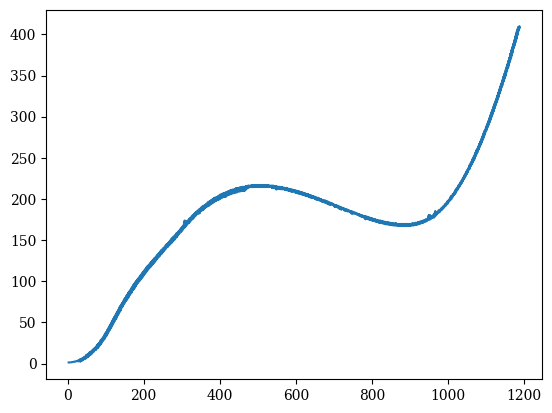

In [45]:
# plt.plot(time_alt, alt)
# plt.plot(time_alt_new, alt_new);
plt.plot(t_alt, h);

In [46]:
df_alt = pd.DataFrame(np.array([t_alt, h]).T)
df_vel = pd.DataFrame(np.array([t_vel, v]).T)

In [47]:
df_alt.to_clipboard()

In [48]:
from scipy.interpolate import PchipInterpolator   # Monotonic cubic (best for rocket data)
from scipy.ndimage import gaussian_filter1d

# Step 1: Clean and sort
def clean_and_sort(t, y):
    # Remove exact duplicates (keep first)
    _, idx = np.unique(t, return_index=True)
    t = t[idx]
    y = y[idx]
    # Sort by time
    sort_idx = np.argsort(t)
    return t[sort_idx], y[sort_idx]

t_v, v_raw = clean_and_sort(t_vel, v)
t_h, h_raw = clean_and_sort(t_alt, h)

# Step 2: Common time base (0 to 1189 s, 0.5 s steps)
t_common = np.arange(0, 1189, 0.5)

# Step 3: Monotonic cubic spline interpolation (PCHIP)
# This preserves shape, no overshoot — perfect for velocity/altitude
v_spline = PchipInterpolator(t_v, v_raw)
h_spline = PchipInterpolator(t_h, h_raw)

v_smooth = v_spline(t_common)
h_smooth = h_spline(t_common)

# Optional: Ultra-light smoothing only if residual jitter exists
# sigma=1 means almost no change, just kills 1-2 Hz noise
v_smooth = gaussian_filter1d(v_smooth, sigma=15)
h_smooth = gaussian_filter1d(h_smooth, sigma=30)

# Final smooth curves
time = t_common
velocity = v_smooth          
altitude = h_smooth         



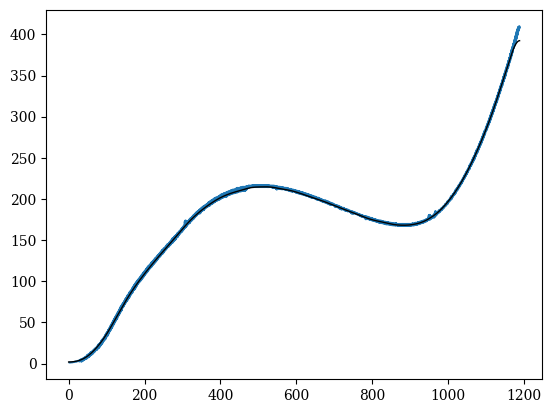

In [49]:
# plt.plot(time, values, '.');
plt.plot(t_alt, h);
plt.plot(time, altitude, 'k', lw=1);

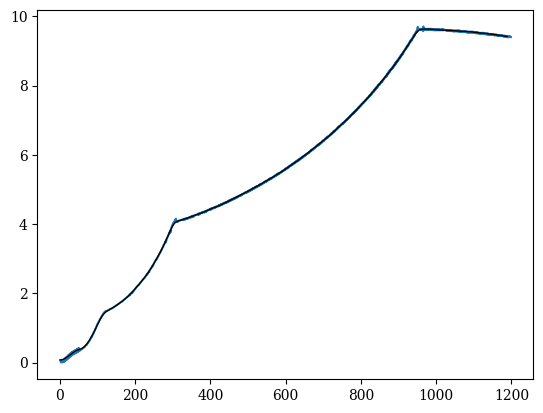

In [50]:
# plt.plot(time, values, '.');
plt.plot(t_vel, v);
plt.plot(time, velocity, 'k', lw=1);

In [51]:
df_tel = pd.DataFrame(np.array([time, velocity, altitude]).T)

In [52]:
df_tel.to_clipboard()

In [53]:
raw_tel = pd.read_csv('Resources/raw_tel.csv')
smooth_tel = pd.read_csv('Resources/smooth_tel.csv', names=['Time [s]', 'Velocity [km/s]', 'Altitude [km]'])

In [54]:
anchor = raw_tel.dropna()

In [9]:
t_anchor = anchor['Time [s]'].to_numpy()
lat_anchor = anchor['Latitude [N]'].to_numpy()
long_anchor = anchor['Longitude [E]'].to_numpy()
alt_anchor = anchor['Altitude [km]'].to_numpy()

In [55]:
transformer = pyproj.Transformer.from_crs(
    {'proj':'latlong', 'ellps':'WGS84'},
    {'proj':'geocent', 'ellps':'WGS84'}
)

lla_transformer = pyproj.Transformer.from_crs(
    {"proj": "latlong", "ellps": "WGS84"},
    {"proj": "geocent", "ellps": "WGS84"},
    always_xy=True
)

In [56]:
lat_ref = raw_tel.loc[12]['Latitude [N]']
long_ref = raw_tel.loc[12]['Longitude [E]']
h_ref = smooth_tel.loc[smooth_tel['Time [s]'] == 112.5, 'Altitude [km]']
v_ref = smooth_tel.loc[smooth_tel['Time [s]'] == 112.5, 'Velocity [km/s]']
t_ref = 112.5